# Federated Learning — Binary IoMT Attack Detection
### 5 Clients | CNN-LSTM-ResNet | IID Experiment

In [ ]:
# ================================================================
# CELL 0 — FINAL FL SETUP + EXACT DL-BINARY 72/8/20 PREPROCESSING + ORIGINAL OUTPUT NAMES
# ================================================================
#
#   72% actual training / 8% validation / 20% held-out test
#   StandardScaler fitted ONLY on the actual 72% training rows
# ================================================================

# ----------------------------------------------------------------
# 1. Mount Google Drive
# ----------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ----------------------------------------------------------------
# 2. Imports
# ----------------------------------------------------------------
import os
import json
import random
import gc
import shutil
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import mixed_precision

# ----------------------------------------------------------------
# 3. Reproducibility
# ----------------------------------------------------------------
RANDOM_SEED = 42
VALIDATION_FRACTION_OF_ORIGINAL_TRAIN = 0.10
GLOBAL_VALIDATION_FRACTION = 0.10
PROTOCOL_NAME = 'binary_72_8_20_train_only_scaler_v1'

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

# ----------------------------------------------------------------
# 4. GPU / Free-Colab configuration
# ----------------------------------------------------------------
GPUS = tf.config.list_physical_devices('GPU')
for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

if GPUS:
    mixed_precision.set_global_policy('mixed_float16')
else:
    mixed_precision.set_global_policy('float32')

# ----------------------------------------------------------------
# 5. Source CSVs + tiny shared protocol
# ----------------------------------------------------------------
PROJECT_ROOT = '/content/drive/MyDrive/IoMT_Thesis_2024'
TRAIN_CSV = os.path.join(PROJECT_ROOT, 'dl_train_full.csv')
TEST_CSV = os.path.join(PROJECT_ROOT, 'dl_test_full.csv')

SHARED_PROTOCOL_DIR = os.path.join(
    PROJECT_ROOT,
    'binary_dl_preprocessed'
)
VALIDATION_INDEX_FILE = os.path.join(
    SHARED_PROTOCOL_DIR,
    'validation_indices.npy'
)
SHARED_SCALER_FILE = os.path.join(
    SHARED_PROTOCOL_DIR,
    'StandardScaler.joblib'
)
PROTOCOL_MANIFEST_FILE = os.path.join(
    SHARED_PROTOCOL_DIR,
    'protocol_manifest.json'
)
os.makedirs(SHARED_PROTOCOL_DIR, exist_ok=True)

if not os.path.exists(TRAIN_CSV) or not os.path.exists(TEST_CSV):
    raise FileNotFoundError(
        'Required binary train/test CSV files are missing.\n'
        f'Train: {TRAIN_CSV}\nTest: {TEST_CSV}'
    )

# ----------------------------------------------------------------
# 6. Temporary Colab runtime cache — NOT Google Drive
# ----------------------------------------------------------------
RUNTIME_CACHE_DIR = '/content/iomt_binary_72_8_20_runtime_cache'
os.makedirs(RUNTIME_CACHE_DIR, exist_ok=True)

X_TRAIN_FILE = os.path.join(
    RUNTIME_CACHE_DIR,
    'X_original80_scaled_with_train72_scaler_float32.npy'
)
X_TEST_FILE = os.path.join(
    RUNTIME_CACHE_DIR,
    'X_test20_scaled_float32.npy'
)
Y_TRAIN_FILE = os.path.join(
    RUNTIME_CACHE_DIR,
    'y_original80_int8.npy'
)
Y_TEST_FILE = os.path.join(
    RUNTIME_CACHE_DIR,
    'y_test20_int8.npy'
)

# ----------------------------------------------------------------
# 7. Recreate temporary standardized arrays using the EXACT
#    validation split + scaler produced by the corrected DL Binary notebook
# ----------------------------------------------------------------
# The corrected centralized DL Binary preprocessing must be run first.
# FL reuses:
#   - validation_indices.npy
#   - StandardScaler.joblib
#   - protocol_manifest.json
#
# Large standardized arrays are recreated only in /content.
# ----------------------------------------------------------------

required_shared_files = [
    VALIDATION_INDEX_FILE,
    SHARED_SCALER_FILE,
    PROTOCOL_MANIFEST_FILE
]

missing_shared_files = [
    path
    for path in required_shared_files
    if not os.path.exists(path)
]

if missing_shared_files:
    raise FileNotFoundError(
        "Corrected DL Binary shared preprocessing files are missing.\n"
        "Run the corrected DL Binary preprocessing cells first.\n\n"
        + "\n".join(missing_shared_files)
    )

runtime_cache_ready = all(
    os.path.exists(path)
    for path in [X_TRAIN_FILE, X_TEST_FILE, Y_TRAIN_FILE, Y_TEST_FILE]
)

if not runtime_cache_ready:

    print(
        "Creating temporary FL runtime cache from "
        "the corrected DL Binary protocol..."
    )

    train_df = pd.read_csv(TRAIN_CSV)
    test_df = pd.read_csv(TEST_CSV)

    if "Label" not in train_df.columns or "Label" not in test_df.columns:
        raise ValueError(
            "Both CSV files must contain a 'Label' column."
        )

    y_train_full = (
        train_df.pop("Label")
        .to_numpy(dtype=np.int8, copy=True)
    )

    y_test_array = (
        test_df.pop("Label")
        .to_numpy(dtype=np.int8, copy=True)
    )

    train_df = train_df.astype(np.float32, copy=False)
    test_df = test_df.astype(np.float32, copy=False)

    if train_df.columns.tolist() != test_df.columns.tolist():
        raise ValueError(
            "Train/test feature columns do not match exactly."
        )

    feature_names = train_df.columns.astype(str).tolist()

    num_train_full = len(y_train_full)
    num_test = len(y_test_array)
    num_features_now = train_df.shape[1]

    expected_manifest = {
        "protocol_name": PROTOCOL_NAME,
        "random_seed": int(RANDOM_SEED),
        "validation_fraction_of_original_train":
            float(VALIDATION_FRACTION_OF_ORIGINAL_TRAIN),
        "original_train_rows": int(num_train_full),
        "test_rows": int(num_test),
        "num_features": int(num_features_now),
        "train_class_counts":
            np.bincount(
                y_train_full,
                minlength=2
            ).astype(int).tolist(),
        "test_class_counts":
            np.bincount(
                y_test_array,
                minlength=2
            ).astype(int).tolist(),
        "feature_names": feature_names
    }

    with open(PROTOCOL_MANIFEST_FILE, "r") as file:
        saved_manifest = json.load(file)

    if saved_manifest != expected_manifest:
        raise RuntimeError(
            "DL Binary protocol manifest does not match "
            "the current CSV files. Do not continue."
        )

    shared_validation_indices = np.load(
        VALIDATION_INDEX_FILE,
        allow_pickle=False
    ).astype(np.int32)

    if shared_validation_indices.ndim != 1:
        raise ValueError(
            "Shared validation indices must be one-dimensional."
        )

    if len(shared_validation_indices) == 0:
        raise ValueError("Shared validation split is empty.")

    if (
        shared_validation_indices.min() < 0
        or shared_validation_indices.max() >= num_train_full
    ):
        raise ValueError("Shared validation indices are invalid.")

    if (
        len(np.unique(shared_validation_indices))
        != len(shared_validation_indices)
    ):
        raise ValueError(
            "Duplicate shared validation indices detected."
        )

    validation_mask = np.zeros(
        num_train_full,
        dtype=bool
    )
    validation_mask[
        shared_validation_indices
    ] = True

    actual_training_indices = np.flatnonzero(
        ~validation_mask
    ).astype(
        np.int32,
        copy=False
    )

    # Exact scaler produced by corrected DL Binary.
    scaler = joblib.load(
        SHARED_SCALER_FILE
    )

    train_matrix = train_df.to_numpy(
        dtype=np.float32,
        copy=False
    )
    test_matrix = test_df.to_numpy(
        dtype=np.float32,
        copy=False
    )

    TRANSFORM_CHUNK = 250_000

    X_train_runtime = np.lib.format.open_memmap(
        X_TRAIN_FILE,
        mode="w+",
        dtype=np.float32,
        shape=train_matrix.shape
    )

    for transform_start in range(
        0,
        len(train_matrix),
        TRANSFORM_CHUNK
    ):
        transform_end = min(
            transform_start + TRANSFORM_CHUNK,
            len(train_matrix)
        )

        X_train_runtime[
            transform_start:transform_end
        ] = scaler.transform(
            train_matrix[
                transform_start:transform_end
            ]
        ).astype(
            np.float32,
            copy=False
        )

    X_train_runtime.flush()
    del X_train_runtime

    X_test_runtime = np.lib.format.open_memmap(
        X_TEST_FILE,
        mode="w+",
        dtype=np.float32,
        shape=test_matrix.shape
    )

    for transform_start in range(
        0,
        len(test_matrix),
        TRANSFORM_CHUNK
    ):
        transform_end = min(
            transform_start + TRANSFORM_CHUNK,
            len(test_matrix)
        )

        X_test_runtime[
            transform_start:transform_end
        ] = scaler.transform(
            test_matrix[
                transform_start:transform_end
            ]
        ).astype(
            np.float32,
            copy=False
        )

    X_test_runtime.flush()
    del X_test_runtime

    np.save(
        Y_TRAIN_FILE,
        y_train_full.astype(np.int8),
        allow_pickle=False
    )

    np.save(
        Y_TEST_FILE,
        y_test_array.astype(np.int8),
        allow_pickle=False
    )

    del train_df
    del test_df
    del train_matrix
    del test_matrix
    del y_train_full
    del y_test_array
    del validation_mask
    del actual_training_indices

    gc.collect()

    print(
        "✅ Exact corrected DL Binary validation split reused."
    )
    print(
        "✅ Exact corrected DL Binary StandardScaler reused."
    )
    print(
        "✅ Standardized arrays exist only in temporary /content."
    )

else:

    print(
        "Temporary /content FL runtime cache already exists; "
        "reusing it."
    )

# Shared validation indices are tiny and loaded explicitly for partitioning.
SHARED_VALIDATION_INDICES = np.load(
    VALIDATION_INDEX_FILE,
    allow_pickle=False
).astype(np.int32)

# ----------------------------------------------------------------
# 8. Federated experiment configuration
# ----------------------------------------------------------------
EXPERIMENT_NAME = 'FedAvg_IID_5Clients_CNN-LSTM-ResNet_Binary'
FEDERATED_ALGORITHM = 'FedAvg'
PARTITION_TYPE = 'IID'
NUM_CLIENTS = 5
CLIENTS_PER_ROUND = 5
LOCAL_EPOCHS = 1
MAX_ROUNDS = 20
LOCAL_BATCH_SIZE = 2048
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 1e-4

# ----------------------------------------------------------------
# 9. Minimal Federated Learning storage structure
# ----------------------------------------------------------------
FL_ROOT = os.path.join(
    PROJECT_ROOT,
    'federated_binary'
)
PARTITION_DIR = os.path.join(FL_ROOT, 'partition')
CHECKPOINT_DIR = os.path.join(FL_ROOT, 'checkpoint')
MODEL_DIR = os.path.join(FL_ROOT, 'model')
RESULT_DIR = os.path.join(FL_ROOT, 'result')

for directory in [FL_ROOT, PARTITION_DIR, CHECKPOINT_DIR, MODEL_DIR, RESULT_DIR]:
    os.makedirs(directory, exist_ok=True)

# ----------------------------------------------------------------
# 10. FedAvg files used by the existing workflow
# ----------------------------------------------------------------
CONFIG_FILE = os.path.join(FL_ROOT, f'{EXPERIMENT_NAME}_config.json')
PARTITION_FILE = os.path.join(PARTITION_DIR, f'{EXPERIMENT_NAME}_partition.npz')
LATEST_MODEL_FILE = os.path.join(CHECKPOINT_DIR, f'{EXPERIMENT_NAME}_latest.keras')
STATE_FILE = os.path.join(CHECKPOINT_DIR, f'{EXPERIMENT_NAME}_state.json')
ROUND_HISTORY_FILE = os.path.join(RESULT_DIR, f'{EXPERIMENT_NAME}_round_history.csv')
FINAL_MODEL_FILE = os.path.join(MODEL_DIR, f'{EXPERIMENT_NAME}_final.keras')
FINAL_METRICS_FILE = os.path.join(RESULT_DIR, f'{EXPERIMENT_NAME}_final_metrics.csv')
FINAL_PREDICTIONS_FILE = os.path.join(RESULT_DIR, f'{EXPERIMENT_NAME}_predictions.npz')

# ----------------------------------------------------------------
# 11. Load temporary arrays using memory mapping
# ----------------------------------------------------------------
for required in [X_TRAIN_FILE, X_TEST_FILE, Y_TRAIN_FILE, Y_TEST_FILE]:
    if not os.path.exists(required):
        raise FileNotFoundError('Temporary runtime cache file missing:\n' + required)

X_train_scaled = np.load(X_TRAIN_FILE, mmap_mode='r')
X_test_scaled = np.load(X_TEST_FILE, mmap_mode='r')
y_train = np.load(Y_TRAIN_FILE, mmap_mode='r')
y_test = np.load(Y_TEST_FILE, mmap_mode='r')

if X_train_scaled.ndim != 2 or X_test_scaled.ndim != 2:
    raise ValueError('Scaled feature arrays must be 2-dimensional.')
if X_train_scaled.shape[1] != X_test_scaled.shape[1]:
    raise ValueError('Train/test feature counts do not match.')
if len(X_train_scaled) != len(y_train) or len(X_test_scaled) != len(y_test):
    raise ValueError('Feature/label lengths do not match.')
if not set(np.unique(y_train).tolist()).issubset({0, 1}):
    raise ValueError('Unexpected binary training labels.')
if not set(np.unique(y_test).tolist()).issubset({0, 1}):
    raise ValueError('Unexpected binary test labels.')

NUM_FEATURES = int(X_train_scaled.shape[1])
TRAIN_SAMPLES = int(len(y_train))  # original saved 80% partition
TEST_SAMPLES = int(len(y_test))
train_counts = np.bincount(y_train, minlength=2)
test_counts = np.bincount(y_test, minlength=2)

print('\nShared protocol:', PROTOCOL_NAME)
print('Original 80% train rows:', f'{TRAIN_SAMPLES:,}')
print('Held-out 20% test rows :', f'{TEST_SAMPLES:,}')
print('Shared validation rows :', f'{len(SHARED_VALIDATION_INDICES):,}')
print('Temporary cache folder :', RUNTIME_CACHE_DIR)
print('Google Drive large-array storage: NONE')


# 13. Configuration protection
#
# Saves only a tiny JSON file.
#
# This is important because a resumed checkpoint must not
# accidentally use a different number of clients, batch size,
# partition type, etc.
# ----------------------------------------------------------------

CURRENT_CONFIG = {

    "experiment_name":
        EXPERIMENT_NAME,

    "algorithm":
        FEDERATED_ALGORITHM,

    "partition_type":
        PARTITION_TYPE,

    "random_seed":
        RANDOM_SEED,

    "num_clients":
        NUM_CLIENTS,

    "clients_per_round":
        CLIENTS_PER_ROUND,

    "local_epochs":
        LOCAL_EPOCHS,

    "local_batch_size":
        LOCAL_BATCH_SIZE,

    "learning_rate":
        LEARNING_RATE,

    "global_validation_fraction":
        GLOBAL_VALIDATION_FRACTION,

    "architecture":
        "CNN-LSTM-ResNet",

    "num_features":
        NUM_FEATURES,

    "preprocessing_protocol":
        PROTOCOL_NAME

}


# Settings that must never change while resuming
# the same experiment.
IMMUTABLE_CONFIG_KEYS = [

    "algorithm",
    "partition_type",
    "random_seed",
    "num_clients",
    "clients_per_round",
    "local_epochs",
    "local_batch_size",
    "learning_rate",
    "global_validation_fraction",
    "architecture",
    "num_features",
    "preprocessing_protocol"

]


if os.path.exists(
    CONFIG_FILE
):

    with open(
        CONFIG_FILE,
        "r"
    ) as file:

        SAVED_CONFIG = json.load(
            file
        )


    mismatches = {}

    for key in IMMUTABLE_CONFIG_KEYS:

        if SAVED_CONFIG.get(key) != CURRENT_CONFIG.get(key):

            mismatches[key] = {

                "saved":
                    SAVED_CONFIG.get(key),

                "current":
                    CURRENT_CONFIG.get(key)

            }


    if mismatches:

        raise RuntimeError(

            "Existing Federated Learning experiment "
            "uses different settings.\n\n"

            f"Mismatches:\n{mismatches}\n\n"

            "Execution stopped to protect the "
            "existing experiment."

        )


    print(
        "✅ Existing experiment configuration verified."
    )


else:

    with open(
        CONFIG_FILE,
        "w"
    ) as file:

        json.dump(
            CURRENT_CONFIG,
            file,
            indent=2
        )


    print(
        "✅ Experiment configuration created."
    )


# ----------------------------------------------------------------
# 14. Detect whether training is already completely finished
#
# No extra completion-marker file is needed.
#
# We simply verify the three final artifacts that matter.
# ----------------------------------------------------------------

FL_EXPERIMENT_COMPLETE = (

    os.path.exists(
        FINAL_MODEL_FILE
    )
 and os.path.exists(
        FINAL_METRICS_FILE
    )
 and os.path.exists(
        FINAL_PREDICTIONS_FILE
    )

)


# ----------------------------------------------------------------
# 15. Detect whether a previous incomplete run can resume
# ----------------------------------------------------------------

FL_RESUME_AVAILABLE = (

    os.path.exists(
        LATEST_MODEL_FILE
    )
 and os.path.exists(
        STATE_FILE
    )

)


# ----------------------------------------------------------------
# 16. Display status
#
# Nothing from this section is saved to Drive.
# ----------------------------------------------------------------

print(
    "\n" + "=" * 72
)

print(
    "FEDERATED BINARY LEARNING — READY"
)

print(
    "=" * 72
)


print(
    "TensorFlow:",
    tf.__version__
)

print(
    "GPU available:",
    bool(GPUS)
)

if GPUS:

    print(
        "GPU:",
        GPUS[0].name
    )


print(
    "Precision policy:",
    mixed_precision.global_policy().name
)


print(
    "\nTraining shape:",
    X_train_scaled.shape
)

print(
    "Testing shape :",
    X_test_scaled.shape
)

print(
    "Features      :",
    NUM_FEATURES
)


print(
    "\nTraining labels:"
)

print(
    "  Benign:",
    int(train_counts[0])
)

print(
    "  Attack:",
    int(train_counts[1])
)


print(
    "\nTesting labels:"
)

print(
    "  Benign:",
    int(test_counts[0])
)

print(
    "  Attack:",
    int(test_counts[1])
)


print(
    "\nFL configuration:"
)

print(
    "  Algorithm:",
    FEDERATED_ALGORITHM
)

print(
    "  Partition:",
    PARTITION_TYPE
)

print(
    "  Clients:",
    NUM_CLIENTS
)

print(
    "  Clients/round:",
    CLIENTS_PER_ROUND
)

print(
    "  Local epochs:",
    LOCAL_EPOCHS
)

print(
    "  Max rounds:",
    MAX_ROUNDS
)

print(
    "  Batch size:",
    LOCAL_BATCH_SIZE
)

print(
    "  Validation fraction of original 80% train:",
    GLOBAL_VALIDATION_FRACTION
)


print(
    "\nStorage:"
)

print(
    "  FL folder:",
    FL_ROOT
)


if FL_EXPERIMENT_COMPLETE:

    print(
        "\n✅ EXPERIMENT ALREADY COMPLETE."
    )

    print(
        "Training will be skipped in later cells."
    )


elif FL_RESUME_AVAILABLE:

    print(
        "\n🔄 Previous checkpoint found."
    )

    print(
        "Training will resume from the saved round."
    )


else:

    print(
        "\n🟢 New experiment ready to start."
    )


print(
    "=" * 72
)


gc.collect()


Mounted at /content/drive
Creating temporary FL runtime cache from the corrected DL Binary protocol...
✅ Exact corrected DL Binary validation split reused.
✅ Exact corrected DL Binary StandardScaler reused.
✅ Standardized arrays exist only in temporary /content.

Shared protocol: binary_72_8_20_train_only_scaler_v1
Original 80% train rows: 2,597,892
Held-out 20% test rows : 649,474
Shared validation rows : 259,790
Temporary cache folder : /content/iomt_binary_72_8_20_runtime_cache
Google Drive large-array storage: NONE
✅ Existing experiment configuration verified.

FEDERATED BINARY LEARNING — READY
TensorFlow: 2.20.0
GPU available: True
GPU: /physical_device:GPU:0
Precision policy: mixed_float16

Training shape: (2597892, 79)
Testing shape : (649474, 79)
Features      : 79

Training labels:
  Benign: 26074
  Attack: 2571818

Testing labels:
  Benign: 6519
  Attack: 642955

FL configuration:
  Algorithm: FedAvg
  Partition: IID
  Clients: 5
  Clients/round: 5
  Local epochs: 1
  Max rou

55

Global Validation Split and 5-Client IID Partition

In [ ]:
# ================================================================
# CELL 1 — FIXED 5-CLIENT IID PARTITION USING THE SHARED DL VALIDATION SET
# ================================================================
# X_train_scaled/y_train here represent the ORIGINAL saved 80% training
# partition, but they were standardized using a scaler fitted only on
# the actual 72% training rows.
#
# The exact shared validation indices are reserved first (8% overall).
# Only the remaining 72% overall samples are assigned to FL clients.
# ================================================================

import pandas as pd
from IPython.display import display

VALIDATION_CODE = np.uint8(255)
UNASSIGNED_CODE = np.uint8(254)


def validate_partition_assignment(assignment):
    if assignment.ndim != 1:
        raise ValueError('Partition assignment must be 1-dimensional.')
    if len(assignment) != TRAIN_SAMPLES:
        raise ValueError('Partition length does not match original 80% training rows.')

    allowed_values = set(range(NUM_CLIENTS)) | {int(VALIDATION_CODE)}
    found_values = set(np.unique(assignment).astype(int).tolist())
    unexpected = found_values - allowed_values
    if unexpected:
        raise ValueError(f'Unexpected partition codes found: {unexpected}')


shared_validation_indices = np.sort(
    np.asarray(SHARED_VALIDATION_INDICES, dtype=np.int32).reshape(-1)
)

if len(shared_validation_indices) == 0:
    raise RuntimeError('Shared validation split is empty.')
if shared_validation_indices.min() < 0 or shared_validation_indices.max() >= TRAIN_SAMPLES:
    raise RuntimeError('Shared validation indices are invalid.')
if len(np.unique(shared_validation_indices)) != len(shared_validation_indices):
    raise RuntimeError('Duplicate shared validation indices detected.')

if os.path.exists(PARTITION_FILE):
    print('✅ Existing corrected IID partition found. Loading it...')
    with np.load(PARTITION_FILE, allow_pickle=False) as saved_partition:
        assignment = np.asarray(saved_partition['assignment'], dtype=np.uint8)
    validate_partition_assignment(assignment)
else:
    print('🟢 Creating corrected IID partition from the shared 72/8/20 protocol...')
    assignment = np.full(TRAIN_SAMPLES, UNASSIGNED_CODE, dtype=np.uint8)
    assignment[shared_validation_indices] = VALIDATION_CODE

    validation_mask = np.zeros(TRAIN_SAMPLES, dtype=bool)
    validation_mask[shared_validation_indices] = True
    rng = np.random.default_rng(RANDOM_SEED)

    # Stratified IID client allocation from ACTUAL training rows only.
    for class_label in [0, 1]:
        class_indices = np.flatnonzero(
            (np.asarray(y_train) == class_label) & (~validation_mask)
        ).astype(np.int32, copy=False)
        rng.shuffle(class_indices)
        client_splits = np.array_split(class_indices, NUM_CLIENTS)
        for client_id, indices in enumerate(client_splits):
            assignment[indices] = np.uint8(client_id)
        del class_indices, client_splits
        gc.collect()

    if np.any(assignment == UNASSIGNED_CODE):
        raise RuntimeError('Some original-training rows were left unassigned.')

    validate_partition_assignment(assignment)
    np.savez_compressed(PARTITION_FILE, assignment=assignment)
    print('✅ Corrected IID partition created and saved.')

# Validation extracted from the FL partition MUST exactly match DL.
validation_indices = np.flatnonzero(
    assignment == VALIDATION_CODE
).astype(np.int32, copy=False)

if not np.array_equal(np.sort(validation_indices), shared_validation_indices):
    raise RuntimeError(
        'FL validation rows do not exactly match the shared centralized-DL validation rows.'
    )

client_indices = []
for client_id in range(NUM_CLIENTS):
    indices = np.flatnonzero(
        assignment == np.uint8(client_id)
    ).astype(np.int32, copy=False)
    client_indices.append(indices)

client_total = sum(len(indices) for indices in client_indices)
validation_total = len(validation_indices)

if client_total + validation_total != TRAIN_SAMPLES:
    raise RuntimeError('Client + validation partition integrity check failed.')

# Every client and validation set must contain both binary classes.
distribution_rows = []
for client_id, indices in enumerate(client_indices):
    labels = np.asarray(y_train[indices], dtype=np.int8)
    counts = np.bincount(labels, minlength=2)
    if counts[0] == 0 or counts[1] == 0:
        raise RuntimeError(f'Client {client_id + 1} does not contain both binary classes.')
    distribution_rows.append({
        'Partition': f'Client {client_id + 1}',
        'Total': int(len(indices)),
        'Benign': int(counts[0]),
        'Attack': int(counts[1]),
        'Benign %': float(counts[0] / len(indices) * 100),
        'Attack %': float(counts[1] / len(indices) * 100)
    })

validation_labels = np.asarray(y_train[validation_indices], dtype=np.int8)
validation_counts = np.bincount(validation_labels, minlength=2)
if validation_counts[0] == 0 or validation_counts[1] == 0:
    raise RuntimeError('Global validation set does not contain both binary classes.')

distribution_rows.append({
    'Partition': 'Global Validation (same as Centralized DL)',
    'Total': int(validation_total),
    'Benign': int(validation_counts[0]),
    'Attack': int(validation_counts[1]),
    'Benign %': float(validation_counts[0] / validation_total * 100),
    'Attack %': float(validation_counts[1] / validation_total * 100)
})

distribution_df = pd.DataFrame(distribution_rows)

overall_total = TRAIN_SAMPLES + TEST_SAMPLES
print('\n' + '=' * 76)
print('5-CLIENT IID PARTITION — SHARED 72/8/20 PROTOCOL VERIFIED')
print('=' * 76)
display(distribution_df)
print('\nOriginal saved 80% training rows:', f'{TRAIN_SAMPLES:,}')
print('FL client-training rows (72% overall):', f'{client_total:,}', f'({client_total/overall_total:.2%})')
print('Global validation rows (8% overall)  :', f'{validation_total:,}', f'({validation_total/overall_total:.2%})')
print('Held-out test rows (20% overall)     :', f'{TEST_SAMPLES:,}', f'({TEST_SAMPLES/overall_total:.2%})')
print('\n✅ FL validation rows exactly match centralized DL validation rows.')
print('✅ Test set is not used for client training or validation.')
print('✅ Large standardized arrays live only in temporary /content storage.')
print('Partition file:', PARTITION_FILE)
print('=' * 76)

del validation_labels
gc.collect()


✅ Existing corrected IID partition found. Loading it...

5-CLIENT IID PARTITION — SHARED 72/8/20 PROTOCOL VERIFIED


,Partition,Total,Benign,Attack,Benign %,Attack %
0,Client 1,467621,4694,462927,1.003804,98.996196
1,Client 2,467621,4694,462927,1.003804,98.996196
2,Client 3,467620,4693,462927,1.003593,98.996407
3,Client 4,467620,4693,462927,1.003593,98.996407
4,Client 5,467620,4693,462927,1.003593,98.996407
5,Global Validation (same as Centralized DL),259790,2607,257183,1.003503,98.996497



Original saved 80% training rows: 2,597,892
FL client-training rows (72% overall): 2,338,102 (72.00%)
Global validation rows (8% overall)  : 259,790 (8.00%)
Held-out test rows (20% overall)     : 649,474 (20.00%)

✅ FL validation rows exactly match centralized DL validation rows.
✅ Test set is not used for client training or validation.
✅ Large standardized arrays live only in temporary /content storage.
Partition file: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/partition/FedAvg_IID_5Clients_CNN-LSTM-ResNet_Binary_partition.npz


0

CNN-LSTM-ResNet Global Model Architecture

In [ ]:

# ----------------------------------------------------------------
# 1. Model compiler
# ----------------------------------------------------------------

def compile_federated_binary_model(model):

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            )
        ],
        steps_per_execution=32
    )

    return model


# ----------------------------------------------------------------
# 2. CNN-LSTM-ResNet architecture
#
# Same structure as the existing Binary DL notebook:
#
# Input
#   ↓
# Conv1D(64)
#   ↓
# Residual Conv1D block
#   ↓
# MaxPooling1D
#   ↓
# LSTM(64)
#   ↓
# Dense(32)
#   ↓
# Sigmoid
# ----------------------------------------------------------------

def build_federated_binary_model(
    compile_model=True
):

    inputs = tf.keras.layers.Input(
        shape=(
            NUM_FEATURES,
            1
        ),
        name="input"
    )


    # ------------------------------------------------------------
    # Initial 1D convolution
    # ------------------------------------------------------------

    x = tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="initial_conv"
    )(inputs)


    # ------------------------------------------------------------
    # Residual block
    # ------------------------------------------------------------

    shortcut = x


    x = tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="residual_conv_1"
    )(x)


    x = tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation=None,
        name="residual_conv_2"
    )(x)


    x = tf.keras.layers.Add(
        name="residual_add"
    )([
        x,
        shortcut
    ])


    x = tf.keras.layers.Activation(
        "relu",
        name="residual_relu"
    )(x)


    # ------------------------------------------------------------
    # Pooling
    # ------------------------------------------------------------

    x = tf.keras.layers.MaxPooling1D(
        pool_size=2,
        name="max_pool"
    )(x)


    # ------------------------------------------------------------
    # LSTM
    # ------------------------------------------------------------

    x = tf.keras.layers.LSTM(
        units=64,
        name="lstm"
    )(x)


    # ------------------------------------------------------------
    # Dense classifier
    # ------------------------------------------------------------

    x = tf.keras.layers.Dense(
        units=32,
        activation="relu",
        name="dense_32"
    )(x)


    # ------------------------------------------------------------
    # Binary output
    #
    # dtype=float32 is intentional because mixed precision
    # is active on the T4.
    # ------------------------------------------------------------

    outputs = tf.keras.layers.Dense(
        units=1,
        activation="sigmoid",
        dtype="float32",
        name="binary_output"
    )(x)


    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Federated_CNN_LSTM_ResNet_Binary"
    )


    if compile_model:

        model = compile_federated_binary_model(
            model
        )


    return model


# ----------------------------------------------------------------
# 3. Architecture verification only
#
# No training.
# No model saving.
# ----------------------------------------------------------------

tf.keras.backend.clear_session()

gc.collect()


preview_model = build_federated_binary_model(
    compile_model=True
)


# ----------------------------------------------------------------
# 4. Check input / output shape
# ----------------------------------------------------------------

expected_input_shape = (
    None,
    NUM_FEATURES,
    1
)

expected_output_shape = (
    None,
    1
)


if preview_model.input_shape != expected_input_shape:

    raise RuntimeError(
        "Unexpected model input shape.\n"
        f"Expected: {expected_input_shape}\n"
        f"Found   : {preview_model.input_shape}"
    )


if preview_model.output_shape != expected_output_shape:

    raise RuntimeError(
        "Unexpected model output shape.\n"
        f"Expected: {expected_output_shape}\n"
        f"Found   : {preview_model.output_shape}"
    )


# ----------------------------------------------------------------
# 5. Small forward-pass test
#
# Only 2 fake samples.
# This checks that the architecture works correctly on the GPU.
# ----------------------------------------------------------------

dummy_input = tf.zeros(
    shape=(
        2,
        NUM_FEATURES,
        1
    ),
    dtype=tf.float32
)


dummy_output = preview_model(
    dummy_input,
    training=False
)


if tuple(dummy_output.shape) != (2, 1):

    raise RuntimeError(
        "Forward-pass output shape is incorrect."
    )


if not bool(
    tf.reduce_all(
        tf.math.is_finite(
            dummy_output
        )
    )
):

    raise RuntimeError(
        "Model produced non-finite values "
        "during the forward-pass test."
    )


# ----------------------------------------------------------------
# 6. Show model information
# ----------------------------------------------------------------

print(
    "\n" + "=" * 72
)

print(
    "FEDERATED CNN-LSTM-RESNET MODEL — VERIFIED"
)

print(
    "=" * 72
)


print(
    "Input shape :",
    preview_model.input_shape
)

print(
    "Output shape:",
    preview_model.output_shape
)

print(
    "Features    :",
    NUM_FEATURES
)

print(
    "Parameters  :",
    f"{preview_model.count_params():,}"
)

print(
    "Optimizer   : Adam"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Loss        : binary_crossentropy"
)

print(
    "Output      : sigmoid"
)

print(
    "Precision   :",
    mixed_precision.global_policy().name
)

print(
    "Forward-pass test: ✅ PASSED"
)


print(
    "\nModel architecture:"
)

preview_model.summary()


print(
    "=" * 72
)


# ----------------------------------------------------------------
# 7. Release preview model
#
# The actual global model will be created in the training cell.
# ----------------------------------------------------------------

del preview_model
del dummy_input
del dummy_output

tf.keras.backend.clear_session()

gc.collect()


print(
    "\n✅ Architecture definition ready."
)

print(
    "✅ No training was performed."
)

print(
    "✅ Nothing was saved to Google Drive."
)



FEDERATED CNN-LSTM-RESNET MODEL — VERIFIED
Input shape : (None, 79, 1)
Output shape: (None, 1)
Features    : 79
Parameters  : 60,097
Optimizer   : Adam
Learning rate: 0.001
Loss        : binary_crossentropy
Output      : sigmoid
Precision   : float32
Forward-pass test: ✅ PASSED

Model architecture:


Model: "Federated_CNN_LSTM_ResNet_Binary"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 79, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 79, 64)    │        256 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_conv_1     │ (None, 79, 64)    │     12,352 │ initial_conv[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_conv_2     │ (None, 79, 64)    │     12,352 │ residual_conv_1[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, 79, 64)    │          0 │ residual_conv_2[… │
│                     │                   │            │ initial_conv[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_relu       │ (None, 79, 64)    │          0 │ residual_add[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool            │ (None, 39, 64)    │          0 │ residual_relu[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ max_pool[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │      2,080 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ binary_output       │ (None, 1)         │         33 │ dense_32[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 60,097 (234.75 KB)

 Trainable params: 60,097 (234.75 KB)

 Non-trainable params: 0 (0.00 B)


✅ Architecture definition ready.
✅ No training was performed.
✅ Nothing was saved to Google Drive.


In [ ]:
# ================================================================
# CELL 4: FEDAVG TRAINING — FIXED ROUND-20 ENDPOINT + AUTO RESUME
# ================================================================
#
# CURRENT LEGACY NOTEBOOK:
#   Existing final.keras = validation-best Round 19.
#   This cell automatically uses it and reruns ONLY Round 20.
#
# FUTURE / FRESH RUN:
#   Trains/resumes normally up to Round 20.
#
# FINAL POLICY:
#   FINAL_MODEL_FILE = ROUND-20 ENDPOINT
#
# RUNTIME:
#   GPU available -> mixed_float16
#   GPU unavailable -> CPU float32
#
# SAFETY:
#   - Same exact client partition
#   - Same exact round/client shuffle seed
#   - Same Adam LR
#   - Same local epoch
#   - Same batch size
#   - Same sample-size weighted FedAvg
#   - Old Round-19 model is overwritten ONLY after
#     Round 20 successfully finishes
#   - Old Round-19 test metrics/predictions are deleted
#     ONLY after Round-20 endpoint is safely saved
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import time
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score
)


# ----------------------------------------------------------------
# 2. CPU / GPU automatic mode
# ----------------------------------------------------------------

def set_runtime_precision():

    if tf.config.list_physical_devices(
        "GPU"
    ):

        mixed_precision.set_global_policy(
            "mixed_float16"
        )

        return (
            "GPU",
            "mixed_float16"
        )


    mixed_precision.set_global_policy(
        "float32"
    )

    return (
        "CPU",
        "float32"
    )


DEVICE, PRECISION = (
    set_runtime_precision()
)


print(
    "=" * 72
)

print(
    "FEDAVG — CORRECTED ROUND-20 ENDPOINT"
)

print(
    "=" * 72
)

print(
    "Device   :",
    DEVICE
)

print(
    "Precision:",
    PRECISION
)


if DEVICE == "CPU":

    print(
        "⚠️ GPU unavailable. "
        "CPU is supported, but training will be slower."
    )


# ----------------------------------------------------------------
# 3. Round-20 endpoint marker
#
# We store this INSIDE the existing config.json.
# Therefore no extra permanent metadata file is required.
# ----------------------------------------------------------------

POLICY_KEY = (
    "final_model_policy"
)

ROUND_KEY = (
    "final_model_round"
)

POLICY_VALUE = (
    "round_20_endpoint"
)


def read_config():

    if not os.path.exists(
        CONFIG_FILE
    ):

        raise FileNotFoundError(
            "FedAvg config file not found:\n" + CONFIG_FILE
        )


    with open(
        CONFIG_FILE,
        "r"
    ) as file:

        return json.load(
            file
        )


def write_config_atomic(
    data
):

    temp_file = (
        CONFIG_FILE + ".tmp"
    )


    with open(
        temp_file,
        "w"
    ) as file:

        json.dump(
            data,
            file,
            indent=2
        )


    os.replace(
        temp_file,
        CONFIG_FILE
    )


config = read_config()


CORRECTED_FINAL_EXISTS = (

    os.path.exists(
        FINAL_MODEL_FILE
    )
 and
    config.get(
        POLICY_KEY
    ) == POLICY_VALUE
 and
    int(
        config.get(
            ROUND_KEY,
            -1
        )
    ) == MAX_ROUNDS
)


# ----------------------------------------------------------------
# 4. Small resume helpers
# ----------------------------------------------------------------

def save_state(
    round_number
):

    state = {

        "last_completed_round":
            int(
                round_number
            ),

        "final_model_policy":
            POLICY_VALUE
    }


    temp_file = (
        STATE_FILE + ".tmp"
    )


    with open(
        temp_file,
        "w"
    ) as file:

        json.dump(
            state,
            file,
            indent=2
        )


    os.replace(
        temp_file,
        STATE_FILE
    )


def load_state_round():

    with open(
        STATE_FILE,
        "r"
    ) as file:

        state = json.load(
            file
        )


    return int(
        state.get(
            "last_completed_round",
            0
        )
    )


def save_history(
    dataframe
):

    temp_file = (
        ROUND_HISTORY_FILE + ".tmp.csv"
    )


    dataframe.to_csv(
        temp_file,
        index=False
    )


    os.replace(
        temp_file,
        ROUND_HISTORY_FILE
    )


# ----------------------------------------------------------------
# 5. Load model weights safely
# ----------------------------------------------------------------

def load_weights(
    model_path
):

    set_runtime_precision()


    model = (
        tf.keras.models.load_model(
            model_path,
            compile=False
        )
    )


    if (
        model.count_params() != 60097
    ):

        raise RuntimeError(
            "Unexpected FedAvg model size: "
            f"{model.count_params():,}"
        )


    weights = [

        np.asarray(
            weight,
            dtype=np.float32
        ).copy()

        for weight
        in model.get_weights()

    ]


    del model


    tf.keras.backend.clear_session()

    gc.collect()

    set_runtime_precision()


    return weights


# ----------------------------------------------------------------
# 6. Fresh initial global weights
# ----------------------------------------------------------------

def fresh_initial_weights():

    tf.keras.utils.set_random_seed(
        RANDOM_SEED
    )


    set_runtime_precision()


    model = (
        build_federated_binary_model(
            compile_model=False
        )
    )


    weights = [

        np.asarray(
            weight,
            dtype=np.float32
        ).copy()

        for weight
        in model.get_weights()

    ]


    del model


    tf.keras.backend.clear_session()

    gc.collect()

    set_runtime_precision()


    return weights


# ----------------------------------------------------------------
# 7. Skip ONLY when corrected Round-20 endpoint exists
# ----------------------------------------------------------------

if CORRECTED_FINAL_EXISTS:

    print(
        "\n✅ Corrected FedAvg Round-20 endpoint "
        "already exists."
    )


    print(
        "✅ Training skipped."
    )


    print(
        "\nFinal model:"
    )


    print(
        FINAL_MODEL_FILE
    )


else:

    # ============================================================
    # 8. Temporary local cache
    #
    # Only Colab local disk.
    # Nothing extra permanently saved to Drive.
    # ============================================================

    CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )


    os.makedirs(
        CACHE_DIR,
        exist_ok=True
    )


    LOCAL_X = os.path.join(
        CACHE_DIR,
        "X_train_scaled_float32.npy"
    )


    LOCAL_Y = os.path.join(
        CACHE_DIR,
        "y_train_int8.npy"
    )


    if not os.path.exists(
        LOCAL_X
    ):

        print(
            "Copying X_train to temporary "
            "Colab disk..."
        )


        shutil.copy2(
            X_TRAIN_FILE,
            LOCAL_X
        )


    if not os.path.exists(
        LOCAL_Y
    ):

        print(
            "Copying y_train to temporary "
            "Colab disk..."
        )


        shutil.copy2(
            Y_TRAIN_FILE,
            LOCAL_Y
        )


    # ============================================================
    # 9. Memory-map training arrays
    # ============================================================

    X_train_fl = np.load(
        LOCAL_X,
        mmap_mode="r"
    )


    y_train_fl = np.load(
        LOCAL_Y,
        mmap_mode="r"
    )


    if (
        X_train_fl.shape != X_train_scaled.shape
    ):

        raise RuntimeError(
            "Temporary X_train cache shape mismatch."
        )


    if (
        y_train_fl.shape != y_train.shape
    ):

        raise RuntimeError(
            "Temporary y_train cache shape mismatch."
        )


    # ============================================================
    # 10. Same exact global validation partition
    # ============================================================

    X_val = np.asarray(
        X_train_fl[
            validation_indices
        ],
        dtype=np.float32
    )


    X_val = (
        X_val[
            ...,
            np.newaxis
        ]
    )


    y_val = np.asarray(
        y_train_fl[
            validation_indices
        ],
        dtype=np.int8
    )


    VAL_BATCH = 4096


    print(
        "\nValidation samples:",
        f"{len(y_val):,}"
    )


    # ============================================================
    # 11. Exact original client-data rule
    #
    # Same seed:
    #
    # RANDOM_SEED
    # + round_number * 100
    # + client_id
    # ============================================================

    def make_client_dataset(
        client_id,
        round_number
    ):

        indices = (
            client_indices[
                client_id
            ]
        )


        X_client = np.asarray(
            X_train_fl[
                indices
            ],
            dtype=np.float32
        )


        X_client = (
            X_client[
                ...,
                np.newaxis
            ]
        )


        y_client = np.asarray(
            y_train_fl[
                indices
            ],
            dtype=np.int8
        )


        shuffle_seed = (

            RANDOM_SEED + round_number * 100 + client_id

        )


        dataset = (

            tf.data.Dataset
            .from_tensor_slices(
                (
                    X_client,
                    y_client
                )
            )
            .shuffle(
                buffer_size=min(
                    50000,
                    len(indices)
                ),
                seed=shuffle_seed,
                reshuffle_each_iteration=True
            )
            .batch(
                LOCAL_BATCH_SIZE,
                drop_remainder=False
            )
            .prefetch(
                tf.data.AUTOTUNE
            )

        )


        return (
            dataset,
            X_client,
            y_client
        )


    # ============================================================
    # 12. Exact original sample-size weighted FedAvg
    # ============================================================

    def add_weighted(
        accumulator,
        client_weights,
        client_sample_count
    ):

        if accumulator is None:

            return [

                np.asarray(
                    weight,
                    dtype=np.float64
                ) * float(
                    client_sample_count
                )

                for weight
                in client_weights

            ]


        for weight_index in range(
            len(
                accumulator
            )
        ):

            accumulator[
                weight_index
            ] += (

                np.asarray(
                    client_weights[
                        weight_index
                    ],
                    dtype=np.float64
                )
 * float(
                    client_sample_count
                )

            )


        return accumulator


    def finish_average(
        accumulator,
        total_samples
    ):

        return [

            (
                weighted_sum / float(
                    total_samples
                )
            ).astype(
                np.float32
            )

            for weighted_sum
            in accumulator

        ]


    # ============================================================
    # 13. Validation helper
    # ============================================================

    def evaluate_global(
        weights
    ):

        set_runtime_precision()


        model = (
            build_federated_binary_model(
                compile_model=True
            )
        )


        model.set_weights(
            weights
        )


        probability_parts = []


        for start in range(
            0,
            len(y_val),
            VAL_BATCH
        ):

            end = min(
                start + VAL_BATCH,
                len(y_val)
            )


            batch_x = (
                tf.convert_to_tensor(
                    X_val[
                        start:end
                    ],
                    dtype=tf.float32
                )
            )


            batch_probability = (

                model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
                .astype(
                    np.float32,
                    copy=False
                )

            )


            probability_parts.append(
                batch_probability
            )


        probabilities = (
            np.concatenate(
                probability_parts
            )
        )


        predictions = (
            probabilities >= 0.5
        ).astype(
            np.int8
        )


        # --------------------------------------------------------
        # Binary log-loss
        # --------------------------------------------------------

        epsilon = 1e-7


        clipped_probabilities = (
            np.clip(
                probabilities,
                epsilon,
                1.0 - epsilon
            )
        )


        val_loss = float(

            -np.mean(

                y_val * np.log(
                    clipped_probabilities
                )
 +
                (
                    1 - y_val
                ) * np.log(
                    1 - clipped_probabilities
                )

            )

        )


        val_accuracy = float(
            accuracy_score(
                y_val,
                predictions
            )
        )


        val_macro_f1 = float(
            f1_score(
                y_val,
                predictions,
                average="macro",
                zero_division=0
            )
        )


        val_benign_recall = float(
            recall_score(
                y_val,
                predictions,
                pos_label=0,
                zero_division=0
            )
        )


        del probability_parts
        del probabilities
        del predictions
        del clipped_probabilities


        return (
            model,
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        )


    # ============================================================
    # 14. Load existing round history
    # ============================================================

    HISTORY_COLUMNS = [

        "Round",
        "Val_Loss",
        "Val_Accuracy",
        "Val_Macro_F1",
        "Val_Benign_Recall",
        "Round_Time_sec"

    ]


    if os.path.exists(
        ROUND_HISTORY_FILE
    ):

        history = pd.read_csv(
            ROUND_HISTORY_FILE
        )


    else:

        history = pd.DataFrame(
            columns=HISTORY_COLUMNS
        )


    legacy_recovery = False

    old_round20 = None


    # ============================================================
    # 15A. CURRENT LEGACY NOTEBOOK RECOVERY
    #
    # Existing:
    #
    # final.keras = best validation model = Round 19
    #
    # History:
    # Round 1 ... Round 20
    #
    # Therefore:
    # use saved Round-19 model and rerun ONLY Round 20.
    # ============================================================

    if os.path.exists(
        FINAL_MODEL_FILE
    ):

        if history.empty:

            raise RuntimeError(
                "Legacy final model exists, "
                "but FedAvg round history is missing."
            )


        history_max_round = int(
            history[
                "Round"
            ].max()
        )


        if (
            history_max_round != MAX_ROUNDS
        ):

            raise RuntimeError(

                "Legacy final model exists, "
                "but history does not reach Round 20.\n"
                f"Found final history round: "
                f"{history_max_round}"

            )


        old_best_index = (
            history[
                "Val_Macro_F1"
            ].idxmax()
        )


        old_best_round = int(
            history.loc[
                old_best_index,
                "Round"
            ]
        )


        # --------------------------------------------------------
        # This check protects us from using the wrong
        # starting model.
        #
        # For THIS existing notebook:
        # old best round = 19.
        # --------------------------------------------------------

        if (
            old_best_round != MAX_ROUNDS - 1
        ):

            raise RuntimeError(

                "Safe one-round recovery is not possible.\n"
                "The legacy final.keras contains the "
                "validation-best model, but the best round "
                "is not Round 19.\n\n"
                f"Best round found: {old_best_round}"

            )


        legacy_recovery = True


        START_ROUND = (
            MAX_ROUNDS
        )


        # Existing final.keras is the saved Round-19 model.
        global_weights = load_weights(
            FINAL_MODEL_FILE
        )


        old_round20 = (

            history[
                history[
                    "Round"
                ] == MAX_ROUNDS
            ]
            .iloc[0]
            .copy()

        )


        # Remove old Round-20 history IN MEMORY only.
        # It will be replaced after successful recovery.
        history = (

            history[
                history[
                    "Round"
                ] < MAX_ROUNDS
            ]
            .copy()
            .reset_index(
                drop=True
            )

        )


        print(
            "\n🔧 LEGACY FEDAVG RECOVERY MODE"
        )


        print(
            "Saved final model = "
            f"legacy validation-best Round {old_best_round}"
        )


        print(
            "Only Round 20 will be rerun."
        )


        print(
            "Old Round-19 model will NOT be overwritten "
            "until Round 20 finishes successfully."
        )


    # ============================================================
    # 15B. RESUME INTERRUPTED CORRECTED TRAINING
    # ============================================================

    elif (

        os.path.exists(
            LATEST_MODEL_FILE
        )
 and
        os.path.exists(
            STATE_FILE
        )

    ):

        last_round = (
            load_state_round()
        )


        if not (
            0 < last_round < MAX_ROUNDS
        ):

            raise RuntimeError(
                f"Invalid resume round: "
                f"{last_round}"
            )


        START_ROUND = (
            last_round + 1
        )


        global_weights = (
            load_weights(
                LATEST_MODEL_FILE
            )
        )


        if not history.empty:

            history = (

                history[
                    history[
                        "Round"
                    ] <= last_round
                ]
                .copy()
                .reset_index(
                    drop=True
                )

            )


        print(
            "\n🔄 RESUME MODE"
        )


        print(
            "Last completed round:",
            last_round
        )


        print(
            "Next round:",
            START_ROUND
        )


    # ============================================================
    # 15C. FRESH CORRECTED RUN
    # ============================================================

    else:

        START_ROUND = 1


        global_weights = (
            fresh_initial_weights()
        )


        history = pd.DataFrame(
            columns=HISTORY_COLUMNS
        )


        print(
            "\n🟢 FRESH CORRECTED FEDAVG RUN"
        )


        print(
            "Final-model policy:"
            " Round-20 endpoint"
        )


    # ============================================================
    # 16. Communication rounds
    # ============================================================

    for round_number in range(
        START_ROUND,
        MAX_ROUNDS + 1
    ):

        round_start_time = (
            time.time()
        )


        print(
            "\n" + "=" * 72
        )


        print(
            f"FEDERATED ROUND "
            f"{round_number}/"
            f"{MAX_ROUNDS}"
        )


        print(
            "=" * 72
        )


        weighted_sum = None

        total_federated_samples = 0


        # ========================================================
        # 17. Client loop
        # ========================================================

        for client_id in range(
            CLIENTS_PER_ROUND
        ):

            client_start_time = (
                time.time()
            )


            print(
                f"\nClient "
                f"{client_id + 1}/"
                f"{CLIENTS_PER_ROUND}"
            )


            (
                client_dataset,
                X_client,
                y_client
            ) = make_client_dataset(
                client_id,
                round_number
            )


            client_sample_count = int(
                len(
                    y_client
                )
            )


            print(
                "Samples:",
                client_sample_count
            )


            # ----------------------------------------------------
            # Fresh client model = fresh Adam state.
            #
            # This matches the original FedAvg cell.
            # ----------------------------------------------------

            set_runtime_precision()


            local_model = (
                build_federated_binary_model(
                    compile_model=True
                )
            )


            local_model.set_weights(
                global_weights
            )


            local_model.fit(
                client_dataset,
                epochs=LOCAL_EPOCHS,
                verbose=0
            )


            local_weights = (
                local_model.get_weights()
            )


            weighted_sum = (
                add_weighted(
                    weighted_sum,
                    local_weights,
                    client_sample_count
                )
            )


            total_federated_samples += (
                client_sample_count
            )


            print(
                f"Completed in "
                f"{time.time() - client_start_time:.1f} sec"
            )


            # ----------------------------------------------------
            # Client cleanup
            # ----------------------------------------------------

            del local_weights
            del local_model
            del client_dataset
            del X_client
            del y_client


            tf.keras.backend.clear_session()

            gc.collect()

            set_runtime_precision()


        # ========================================================
        # 18. FedAvg aggregation
        # ========================================================

        global_weights = (
            finish_average(
                weighted_sum,
                total_federated_samples
            )
        )


        del weighted_sum


        # ========================================================
        # 19. Global validation
        # ========================================================

        (
            global_model,
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = evaluate_global(
            global_weights
        )


        round_time = (
            time.time() - round_start_time
        )


        print(
            "\nGlobal validation:"
        )


        print(
            f"  Loss         : "
            f"{val_loss:.6f}"
        )


        print(
            f"  Accuracy     : "
            f"{val_accuracy:.6f}"
        )


        print(
            f"  Macro F1     : "
            f"{val_macro_f1:.6f}"
        )


        print(
            f"  Benign Recall: "
            f"{val_benign_recall:.6f}"
        )


        print(
            f"  Round time   : "
            f"{round_time:.1f} sec"
        )


        # ========================================================
        # 20. Replace / append round history
        # ========================================================

        new_row = pd.DataFrame(
            [
                {
                    "Round":
                        int(
                            round_number
                        ),

                    "Val_Loss":
                        float(
                            val_loss
                        ),

                    "Val_Accuracy":
                        float(
                            val_accuracy
                        ),

                    "Val_Macro_F1":
                        float(
                            val_macro_f1
                        ),

                    "Val_Benign_Recall":
                        float(
                            val_benign_recall
                        ),

                    "Round_Time_sec":
                        float(
                            round_time
                        )
                }
            ]
        )


        history = history[
            history[
                "Round"
            ] != round_number
        ].copy()


        history = (

            pd.concat(
                [
                    history,
                    new_row
                ],
                ignore_index=True
            )
            .sort_values(
                "Round"
            )
            .reset_index(
                drop=True
            )

        )


        # ========================================================
        # 21. Rounds 1-19:
        # rolling resume checkpoint
        # ========================================================

        if (
            round_number < MAX_ROUNDS
        ):

            global_model.save(
                LATEST_MODEL_FILE,
                overwrite=True
            )


            save_state(
                round_number
            )


            save_history(
                history
            )


            print(
                f"✅ Round {round_number} "
                "safely checkpointed."
            )


        # ========================================================
        # 22. ROUND 20:
        # save FINAL endpoint
        # ========================================================

        else:

            # ----------------------------------------------------
            # Save to temporary file FIRST.
            #
            # Therefore current Round-19 final model stays safe
            # until Round-20 model is fully written.
            # ----------------------------------------------------

            temporary_final_model = (
                os.path.join(
                    MODEL_DIR,
                    f"{EXPERIMENT_NAME}_"
                    "round20_temp.keras"
                )
            )


            if os.path.exists(
                temporary_final_model
            ):

                os.remove(
                    temporary_final_model
                )


            global_model.save(
                temporary_final_model,
                overwrite=True
            )


            # Save corrected history.
            save_history(
                history
            )


            # ----------------------------------------------------
            # Only NOW replace old Round-19 final model.
            # ----------------------------------------------------

            os.replace(
                temporary_final_model,
                FINAL_MODEL_FILE
            )


            # ----------------------------------------------------
            # Certify new final-model policy.
            # ----------------------------------------------------

            corrected_config = (
                read_config()
            )


            corrected_config[
                POLICY_KEY
            ] = POLICY_VALUE


            corrected_config[
                ROUND_KEY
            ] = int(
                MAX_ROUNDS
            )


            corrected_config[
                "endpoint_device"
            ] = DEVICE


            corrected_config[
                "endpoint_precision"
            ] = PRECISION


            write_config_atomic(
                corrected_config
            )


            # ----------------------------------------------------
            # IMPORTANT:
            #
            # Existing test predictions + metrics are from
            # OLD Round-19 model.
            #
            # Delete them now so corrected Cell 5 cannot
            # accidentally reuse them.
            # ----------------------------------------------------

            for stale_file in [

                FINAL_PREDICTIONS_FILE,
                FINAL_METRICS_FILE

            ]:

                if os.path.exists(
                    stale_file
                ):

                    os.remove(
                        stale_file
                    )


                    print(
                        "Removed stale Round-19 artifact:",
                        os.path.basename(
                            stale_file
                        )
                    )


            # ----------------------------------------------------
            # Resume-only files no longer needed.
            # ----------------------------------------------------

            for temporary_file in [

                LATEST_MODEL_FILE,
                STATE_FILE

            ]:

                if os.path.exists(
                    temporary_file
                ):

                    os.remove(
                        temporary_file
                    )


            print(
                "\n✅ ROUND-20 ENDPOINT MODEL SAVED:"
            )


            print(
                FINAL_MODEL_FILE
            )


            # ====================================================
            # 23. Legacy recovery comparison
            #
            # Compare newly recovered Round 20 against the
            # Round-20 validation values stored from original run.
            # ====================================================

            if (
                legacy_recovery and old_round20 is not None
            ):

                print(
                    "\nOriginal stored Round-20 history "
                    "vs recovered Round-20:"
                )


                metric_pairs = [

                    (
                        "Val_Loss",
                        val_loss
                    ),

                    (
                        "Val_Accuracy",
                        val_accuracy
                    ),

                    (
                        "Val_Macro_F1",
                        val_macro_f1
                    ),

                    (
                        "Val_Benign_Recall",
                        val_benign_recall
                    )

                ]


                for (
                    metric_name,
                    new_value
                ) in metric_pairs:

                    old_value = float(
                        old_round20[
                            metric_name
                        ]
                    )


                    difference = abs(
                        old_value - new_value
                    )


                    print(

                        f"  {metric_name:18s} "
                        f"old={old_value:.6f}  "
                        f"new={new_value:.6f}  "
                        f"|diff|={difference:.6f}"

                    )


                if DEVICE == "CPU":

                    print(

                        "\nℹ️ Small numerical differences "
                        "are possible because the original "
                        "run used T4 mixed precision, while "
                        "this recovery used CPU float32."

                    )


        # ========================================================
        # 24. Round cleanup
        # ========================================================

        del global_model


        tf.keras.backend.clear_session()

        gc.collect()

        set_runtime_precision()


    # ============================================================
    # 25. Final integrity verification
    # ============================================================

    check_history = pd.read_csv(
        ROUND_HISTORY_FILE
    )


    check_config = (
        read_config()
    )


    if (
        int(
            check_history[
                "Round"
            ].max()
        ) != MAX_ROUNDS
    ):

        raise RuntimeError(
            "Final FedAvg history does not "
            "end at Round 20."
        )


    if not os.path.exists(
        FINAL_MODEL_FILE
    ):

        raise RuntimeError(
            "Round-20 final model is missing."
        )


    if not (

        check_config.get(
            POLICY_KEY
        ) == POLICY_VALUE
 and
        int(
            check_config.get(
                ROUND_KEY,
                -1
            )
        ) == MAX_ROUNDS

    ):

        raise RuntimeError(
            "Round-20 endpoint marker is missing."
        )


    # ============================================================
    # 26. Final status
    # ============================================================

    print(
        "\n" + "=" * 72
    )


    print(
        "FEDAVG CORRECTION COMPLETE"
    )


    print(
        "=" * 72
    )


    print(
        "Final model policy : Round-20 endpoint"
    )


    print(
        "Final round        :",
        MAX_ROUNDS
    )


    print(
        "Device             :",
        DEVICE
    )


    print(
        "Precision          :",
        PRECISION
    )


    print(
        "Test evaluated     : NO"
    )


    print(
        "\nFinal model:"
    )


    print(
        FINAL_MODEL_FILE
    )


    print(
        "\n✅ Next step: corrected Cell 5 "
        "will create fresh Round-20 test metrics."
    )


    print(
        "=" * 72
    )


    # ============================================================
    # 27. Cleanup
    # ============================================================

    del X_val
    del y_val


    gc.collect()


    tf.keras.backend.clear_session()


    set_runtime_precision()


FEDAVG — CORRECTED ROUND-20 ENDPOINT
Device   : CPU
Precision: float32
⚠️ GPU unavailable. CPU is supported, but training will be slower.

✅ Corrected FedAvg Round-20 endpoint already exists.
✅ Training skipped.

Final model:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/model/FedAvg_IID_5Clients_CNN-LSTM-ResNet_Binary_final.keras


Cell 5 — FedAvg Final Evaluation and Figures

FEDAVG ROUND-20 FINAL EVALUATION
Runtime device: CPU
✅ Corrected Round-20 endpoint verified.
Endpoint training device: GPU
Endpoint precision: mixed_float16

Test samples: 649,474
Test benign: 6,519
Test attack: 642,955

✅ Existing corrected Round-20 prediction cache found.
✅ Test inference skipped.

✅ Corrected Round-20 metrics saved.


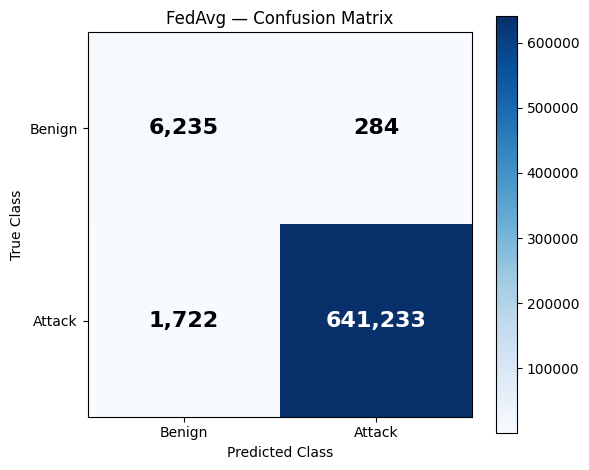

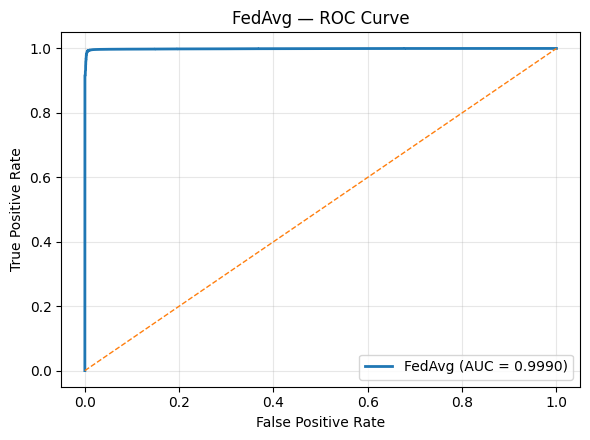

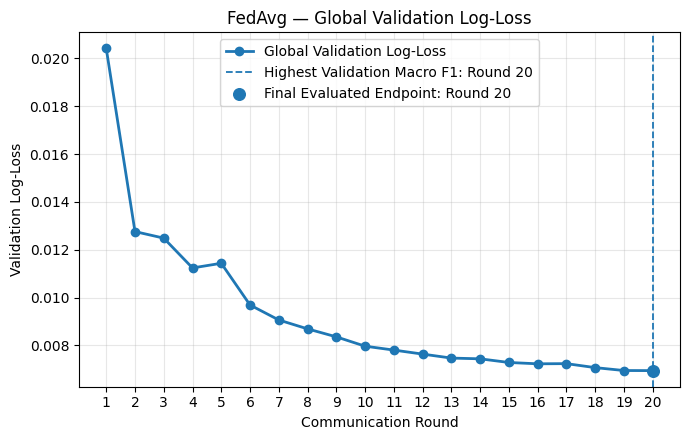


FEDAVG ROUND-20 FINAL TEST RESULTS
Accuracy         : 0.996911
Precision        : 0.999557
Recall           : 0.997322
F1               : 0.998438
Macro F1         : 0.929932
Weighted F1      : 0.997063
Benign Precision : 0.783587
Benign Recall    : 0.956435
Benign F1        : 0.861426
ROC-AUC          : 0.998976
PR-AUC           : 0.999990
Benign PR-AUC    : 0.903690

Confusion Matrix:
TN = 6235
FP = 284
FN = 1722
TP = 641233

Classification Report:


,precision,recall,f1-score,support
Benign,0.783587,0.956435,0.861426,6519.000000
Attack,0.999557,0.997322,0.998438,642955.000000
accuracy,0.996911,0.996911,0.996911,0.996911
macro avg,0.891572,0.976878,0.929932,649474.000000
weighted avg,0.997390,0.996911,0.997063,649474.000000



FEDAVG CORRECTED EVALUATION COMPLETE
Final evaluated model : Round-20 endpoint
Highest validation Macro-F1 round: 20
Final communication round: 20
Inference device: CPU

Saved metrics:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/result/FedAvg_IID_5Clients_CNN-LSTM-ResNet_Binary_final_metrics.csv

Saved predictions:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/result/FedAvg_IID_5Clients_CNN-LSTM-ResNet_Binary_predictions.npz

✅ No training performed.
✅ Round-20 endpoint evaluated.
✅ Old Round-19 metrics are no longer used.


55

In [ ]:
# ================================================================
# CELL 5: FEDAVG ROUND-20 FINAL TEST EVALUATION + FIGURES
# ================================================================
#
# FINAL MODEL:
#   Corrected Round-20 FedAvg endpoint
#
# RUNTIME:
#   CPU or GPU both supported
#
# DOES NOT:
#   - Train
#   - Retrain
#   - Change client partition
#
# SAVES:
#   - Round-20 final metrics CSV
#   - Compact predictions
#   - Updated final figures
#
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ----------------------------------------------------------------
# 2. Runtime information
# ----------------------------------------------------------------

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices("GPU")
)

DEVICE_NAME = (
    "GPU"
    if GPU_AVAILABLE
    else "CPU"
)


print(
    "=" * 72
)

print(
    "FEDAVG ROUND-20 FINAL EVALUATION"
)

print(
    "=" * 72
)

print(
    "Runtime device:",
    DEVICE_NAME
)


# ----------------------------------------------------------------
# 3. Verify corrected Round-20 model
# ----------------------------------------------------------------

required_files = [
    FINAL_MODEL_FILE,
    CONFIG_FILE,
    ROUND_HISTORY_FILE,
    X_TEST_FILE,
    Y_TEST_FILE
]


for file_path in required_files:

    if not os.path.exists(
        file_path
    ):

        raise FileNotFoundError(
            "Required file missing:\n" + file_path
        )


with open(
    CONFIG_FILE,
    "r"
) as file:

    fedavg_config = json.load(
        file
    )


if (
    fedavg_config.get(
        "final_model_policy"
    ) != "round_20_endpoint"
):

    raise RuntimeError(
        "FedAvg final model is not certified "
        "as the corrected Round-20 endpoint."
    )


if int(
    fedavg_config.get(
        "final_model_round",
        -1
    )
) != 20:

    raise RuntimeError(
        "FedAvg final model round is not 20."
    )


print(
    "✅ Corrected Round-20 endpoint verified."
)


print(
    "Endpoint training device:",
    fedavg_config.get(
        "endpoint_device",
        "Unknown"
    )
)


print(
    "Endpoint precision:",
    fedavg_config.get(
        "endpoint_precision",
        "Unknown"
    )
)


# ----------------------------------------------------------------
# 4. Figure paths
# ----------------------------------------------------------------

FEDAVG_FIGURE_DIR = os.path.join(
    FL_ROOT,
    "figures",
    "FedAvg"
)


os.makedirs(
    FEDAVG_FIGURE_DIR,
    exist_ok=True
)


CONFUSION_MATRIX_FILE = os.path.join(
    FEDAVG_FIGURE_DIR,
    "FedAvg_Confusion_Matrix.png"
)


ROC_CURVE_FILE = os.path.join(
    FEDAVG_FIGURE_DIR,
    "FedAvg_ROC_Curve.png"
)


LOSS_CURVE_FILE = os.path.join(
    FEDAVG_FIGURE_DIR,
    "FedAvg_Global_Validation_Log_Loss.png"
)


# ----------------------------------------------------------------
# 5. Load untouched test labels
# ----------------------------------------------------------------

y_true = np.load(
    Y_TEST_FILE,
    mmap_mode="r"
)


y_true = np.asarray(
    y_true,
    dtype=np.uint8
)


print(
    "\nTest samples:",
    f"{len(y_true):,}"
)


print(
    "Test benign:",
    f"{np.sum(y_true == 0):,}"
)


print(
    "Test attack:",
    f"{np.sum(y_true == 1):,}"
)


# ----------------------------------------------------------------
# 6. Prediction cache or fresh inference
# ----------------------------------------------------------------

if os.path.exists(
    FINAL_PREDICTIONS_FILE
):

    print(
        "\n✅ Existing corrected Round-20 "
        "prediction cache found."
    )


    print(
        "✅ Test inference skipped."
    )


    saved_predictions = np.load(
        FINAL_PREDICTIONS_FILE
    )


    y_pred = np.asarray(
        saved_predictions[
            "y_pred"
        ],
        dtype=np.uint8
    )


    y_prob = np.asarray(
        saved_predictions[
            "y_prob"
        ],
        dtype=np.float32
    )


    saved_predictions.close()


else:

    print(
        "\nRunning FedAvg Round-20 "
        "final test inference..."
    )


    X_test_fl = np.load(
        X_TEST_FILE,
        mmap_mode="r"
    )


    tf.keras.backend.clear_session()


    final_fl_model = (
        tf.keras.models.load_model(
            FINAL_MODEL_FILE,
            compile=False
        )
    )


    if (
        final_fl_model.count_params() != 60097
    ):

        raise RuntimeError(
            "Unexpected FedAvg model architecture."
        )


    print(
        "Model parameters:",
        f"{final_fl_model.count_params():,}"
    )


    TEST_BATCH_SIZE = 4096


    probability_batches = []


    for start in range(
        0,
        len(y_true),
        TEST_BATCH_SIZE
    ):

        end = min(
            start + TEST_BATCH_SIZE,
            len(y_true)
        )


        batch_x = np.asarray(
            X_test_fl[
                start:end
            ],
            dtype=np.float32
        )


        batch_x = (
            batch_x[
                ...,
                np.newaxis
            ]
        )


        batch_prob = (
            final_fl_model(
                tf.convert_to_tensor(
                    batch_x,
                    dtype=tf.float32
                ),
                training=False
            )
            .numpy()
            .reshape(-1)
            .astype(
                np.float32,
                copy=False
            )
        )


        probability_batches.append(
            batch_prob
        )


        del batch_x
        del batch_prob


    y_prob = np.concatenate(
        probability_batches
    ).astype(
        np.float32,
        copy=False
    )


    del probability_batches


    if len(y_prob) != len(
        y_true
    ):

        raise RuntimeError(
            "Prediction count does not match "
            "test-label count."
        )


    if not np.all(
        np.isfinite(
            y_prob
        )
    ):

        raise RuntimeError(
            "Non-finite test probabilities found."
        )


    y_pred = (
        y_prob >= 0.5
    ).astype(
        np.uint8
    )


    np.savez_compressed(
        FINAL_PREDICTIONS_FILE,
        y_pred=y_pred,
        y_prob=y_prob
    )


    print(
        "✅ Round-20 predictions saved."
    )


    del final_fl_model
    del X_test_fl


    tf.keras.backend.clear_session()

    gc.collect()


# ----------------------------------------------------------------
# 7. Confusion matrix
# ----------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)


tn, fp, fn, tp = (
    cm.ravel()
)


# ----------------------------------------------------------------
# 8. Final metrics
# ----------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)


attack_precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


benign_precision = precision_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_recall = recall_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)


roc_auc = roc_auc_score(
    y_true,
    y_prob
)


pr_auc = average_precision_score(
    y_true,
    y_prob
)


benign_pr_auc = (
    average_precision_score(
        1 - y_true,
        1.0 - y_prob
    )
)


# ----------------------------------------------------------------
# 9. Save corrected Round-20 metrics
# ----------------------------------------------------------------

metrics_df = pd.DataFrame(
    [
        {
            "Algorithm":
                "FedAvg",

            "Model":
                EXPERIMENT_NAME,

            "Architecture":
                "CNN-LSTM-ResNet",

            "Partition":
                "IID",

            "Clients":
                5,

            "Communication_Rounds":
                20,

            "Model_Round":
                20,

            "Evaluation_Model_Policy":
                "Round-20 endpoint",

            "Endpoint_Device":
                fedavg_config.get(
                    "endpoint_device",
                    "Unknown"
                ),

            "Endpoint_Precision":
                fedavg_config.get(
                    "endpoint_precision",
                    "Unknown"
                ),

            "Threshold":
                0.5,

            "Accuracy":
                float(
                    accuracy
                ),

            "Precision":
                float(
                    attack_precision
                ),

            "Recall":
                float(
                    attack_recall
                ),

            "F1":
                float(
                    attack_f1
                ),

            "Macro_F1":
                float(
                    macro_f1
                ),

            "Weighted_F1":
                float(
                    weighted_f1
                ),

            "Benign_Precision":
                float(
                    benign_precision
                ),

            "Benign_Recall":
                float(
                    benign_recall
                ),

            "Benign_F1":
                float(
                    benign_f1
                ),

            "Specificity":
                float(
                    benign_recall
                ),

            "ROC_AUC":
                float(
                    roc_auc
                ),

            "PR_AUC":
                float(
                    pr_auc
                ),

            "Benign_PR_AUC":
                float(
                    benign_pr_auc
                ),

            "TN":
                int(
                    tn
                ),

            "FP":
                int(
                    fp
                ),

            "FN":
                int(
                    fn
                ),

            "TP":
                int(
                    tp
                ),

            "Test_Samples":
                int(
                    len(y_true)
                )
        }
    ]
)


metrics_df.to_csv(
    FINAL_METRICS_FILE,
    index=False
)


print(
    "\n✅ Corrected Round-20 metrics saved."
)


# ----------------------------------------------------------------
# 10. Classification report
# ----------------------------------------------------------------

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=[
        "Benign",
        "Attack"
    ],
    output_dict=True,
    zero_division=0
)


report_df = pd.DataFrame(
    report
).transpose()


# ================================================================
# 11. FIGURE 1 — CONFUSION MATRIX
# ================================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)


image = ax.imshow(
    cm,
    cmap="Blues"
)


ax.set_xticks(
    [0, 1],
    labels=[
        "Benign",
        "Attack"
    ]
)


ax.set_yticks(
    [0, 1],
    labels=[
        "Benign",
        "Attack"
    ]
)


ax.set_xlabel(
    "Predicted Class"
)


ax.set_ylabel(
    "True Class"
)


ax.set_title(
    "FedAvg — Confusion Matrix"
)


threshold = (
    cm.max() / 2.0
)


for i in range(
    2
):

    for j in range(
        2
    ):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


fig.colorbar(
    image,
    ax=ax
)


plt.tight_layout()


plt.savefig(
    CONFUSION_MATRIX_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ================================================================
# 12. FIGURE 2 — ROC CURVE
# ================================================================

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)


fig, ax = plt.subplots(
    figsize=(6, 4.5)
)


ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"FedAvg "
        f"(AUC = {roc_auc:.4f})"
    )
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)


ax.set_xlabel(
    "False Positive Rate"
)


ax.set_ylabel(
    "True Positive Rate"
)


ax.set_title(
    "FedAvg — ROC Curve"
)


ax.legend(
    loc="lower right"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    ROC_CURVE_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ================================================================
# 13. FIGURE 3 — GLOBAL VALIDATION LOG-LOSS
# ================================================================

round_history = pd.read_csv(
    ROUND_HISTORY_FILE
)


if int(
    round_history[
        "Round"
    ].max()
) != 20:

    raise RuntimeError(
        "FedAvg round history does not end at Round 20."
    )


best_validation_index = (
    round_history[
        "Val_Macro_F1"
    ].idxmax()
)


best_validation_round = int(
    round_history.loc[
        best_validation_index,
        "Round"
    ]
)


fig, ax = plt.subplots(
    figsize=(7, 4.5)
)


ax.plot(
    round_history[
        "Round"
    ],
    round_history[
        "Val_Loss"
    ],
    marker="o",
    linewidth=2,
    label="Global Validation Log-Loss"
)


# Best validation point
ax.axvline(
    best_validation_round,
    linestyle="--",
    linewidth=1.3,
    label=(
        f"Highest Validation Macro F1: "
        f"Round {best_validation_round}"
    )
)


# Final endpoint
ax.scatter(
    [20],
    [
        float(
            round_history.loc[
                round_history[
                    "Round"
                ] == 20,
                "Val_Loss"
            ].iloc[0]
        )
    ],
    s=70,
    zorder=5,
    label="Final Evaluated Endpoint: Round 20"
)


ax.set_xlabel(
    "Communication Round"
)


ax.set_ylabel(
    "Validation Log-Loss"
)


ax.set_title(
    "FedAvg — Global Validation Log-Loss"
)


ax.set_xticks(
    range(
        1,
        21
    )
)


ax.legend()


ax.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    LOSS_CURVE_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ================================================================
# 14. FINAL RESULTS
# ================================================================

print(
    "\n" + "=" * 72
)


print(
    "FEDAVG ROUND-20 FINAL TEST RESULTS"
)


print(
    "=" * 72
)


print(
    f"Accuracy         : "
    f"{accuracy:.6f}"
)


print(
    f"Precision        : "
    f"{attack_precision:.6f}"
)


print(
    f"Recall           : "
    f"{attack_recall:.6f}"
)


print(
    f"F1               : "
    f"{attack_f1:.6f}"
)


print(
    f"Macro F1         : "
    f"{macro_f1:.6f}"
)


print(
    f"Weighted F1      : "
    f"{weighted_f1:.6f}"
)


print(
    f"Benign Precision : "
    f"{benign_precision:.6f}"
)


print(
    f"Benign Recall    : "
    f"{benign_recall:.6f}"
)


print(
    f"Benign F1        : "
    f"{benign_f1:.6f}"
)


print(
    f"ROC-AUC          : "
    f"{roc_auc:.6f}"
)


print(
    f"PR-AUC           : "
    f"{pr_auc:.6f}"
)


print(
    f"Benign PR-AUC    : "
    f"{benign_pr_auc:.6f}"
)


print(
    "\nConfusion Matrix:"
)


print(
    f"TN = {tn}"
)


print(
    f"FP = {fp}"
)


print(
    f"FN = {fn}"
)


print(
    f"TP = {tp}"
)


print(
    "\nClassification Report:"
)


display(
    report_df
)


# ----------------------------------------------------------------
# 15. Final status
# ----------------------------------------------------------------

print(
    "\n" + "=" * 72
)


print(
    "FEDAVG CORRECTED EVALUATION COMPLETE"
)


print(
    "=" * 72
)


print(
    "Final evaluated model : Round-20 endpoint"
)


print(
    "Highest validation Macro-F1 round:",
    best_validation_round
)


print(
    "Final communication round:",
    20
)


print(
    "Inference device:",
    DEVICE_NAME
)


print(
    "\nSaved metrics:"
)


print(
    FINAL_METRICS_FILE
)


print(
    "\nSaved predictions:"
)


print(
    FINAL_PREDICTIONS_FILE
)


print(
    "\n✅ No training performed."
)


print(
    "✅ Round-20 endpoint evaluated."
)


print(
    "✅ Old Round-19 metrics are no longer used."
)


print(
    "=" * 72
)


gc.collect()


Cell 6 — FedSGD Experiment Setup

In [ ]:

# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import json
import numpy as np


# ----------------------------------------------------------------
# 2. Required notebook variables
# ----------------------------------------------------------------

required_variables = [
    "PROJECT_ROOT",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "X_TEST_FILE",
    "Y_TEST_FILE",
    "client_indices",
    "validation_indices",
    "NUM_CLIENTS",
    "NUM_FEATURES",
    "RANDOM_SEED",
    "build_federated_binary_model"
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n" + "\n".join(missing_variables) + "\n\nRun the original FedAvg setup/"
          "partition/model cells first."
    )


# ----------------------------------------------------------------
# 3. Experiment definition
# ----------------------------------------------------------------

FEDSGD_EXPERIMENT_NAME = (
    "FedSGD_IID_5Clients_"
    "CNN-LSTM-ResNet_Binary"
)


FEDSGD_MAX_ROUNDS = 20

FEDSGD_BATCH_SIZE = 2048

FEDSGD_LEARNING_RATE = 0.001

FEDSGD_LOSS_SCALE = 1024.0


# ----------------------------------------------------------------
# 4. FedSGD root folder
# ----------------------------------------------------------------

FEDSGD_ROOT = os.path.join(
    PROJECT_ROOT,
    "federated_binary",
    "FedSGD"
)


# ----------------------------------------------------------------
# 5. Experiment directories
# ----------------------------------------------------------------

FEDSGD_CHECKPOINT_DIR = os.path.join(
    FEDSGD_ROOT,
    "checkpoint"
)


FEDSGD_MODEL_DIR = os.path.join(
    FEDSGD_ROOT,
    "model"
)


FEDSGD_RESULT_DIR = os.path.join(
    FEDSGD_ROOT,
    "result"
)


FEDSGD_FIGURE_DIR = os.path.join(
    FEDSGD_ROOT,
    "figures"
)


for directory in [
    FEDSGD_ROOT,
    FEDSGD_CHECKPOINT_DIR,
    FEDSGD_MODEL_DIR,
    FEDSGD_RESULT_DIR,
    FEDSGD_FIGURE_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


# ----------------------------------------------------------------
# 6. Essential files
# ----------------------------------------------------------------

FEDSGD_CONFIG_FILE = os.path.join(
    FEDSGD_ROOT,
    "config.json"
)


FEDSGD_LATEST_MODEL_FILE = os.path.join(
    FEDSGD_CHECKPOINT_DIR,
    "latest_completed_round.keras"
)


FEDSGD_STATE_FILE = os.path.join(
    FEDSGD_CHECKPOINT_DIR,
    "state.json"
)


FEDSGD_ROUND_HISTORY_FILE = os.path.join(
    FEDSGD_RESULT_DIR,
    "round_history.csv"
)


FEDSGD_FINAL_MODEL_FILE = os.path.join(
    FEDSGD_MODEL_DIR,
    "FedSGD_Round20_Final.keras"
)


FEDSGD_FINAL_METRICS_FILE = os.path.join(
    FEDSGD_RESULT_DIR,
    "final_metrics.csv"
)


FEDSGD_FINAL_PREDICTIONS_FILE = os.path.join(
    FEDSGD_RESULT_DIR,
    "predictions.npz"
)


FEDSGD_CM_FILE = os.path.join(
    FEDSGD_FIGURE_DIR,
    "FedSGD_Confusion_Matrix.png"
)


FEDSGD_ROC_FILE = os.path.join(
    FEDSGD_FIGURE_DIR,
    "FedSGD_ROC_Curve.png"
)


FEDSGD_LOSS_FILE = os.path.join(
    FEDSGD_FIGURE_DIR,
    "FedSGD_Global_Validation_Log_Loss.png"
)


# ----------------------------------------------------------------
# 7. Verify SAME 5-client partition
# ----------------------------------------------------------------

fedsgd_client_sizes = np.array(
    [
        len(indices)
        for indices in client_indices
    ],
    dtype=np.int64
)


if len(
    fedsgd_client_sizes
) != 5:

    raise RuntimeError(
        "Expected exactly 5 clients."
    )


# ----------------------------------------------------------------
# 8. Client aggregation weights
# ----------------------------------------------------------------

FEDSGD_CLIENT_WEIGHTS = (
    fedsgd_client_sizes / fedsgd_client_sizes.sum()
)


if not np.isclose(
    FEDSGD_CLIENT_WEIGHTS.sum(),
    1.0
):

    raise RuntimeError(
        "FedSGD client weights do not sum to 1."
    )


# ----------------------------------------------------------------
# 9. Experiment configuration
# ----------------------------------------------------------------

FEDSGD_CONFIG = {

    "experiment_name":
        FEDSGD_EXPERIMENT_NAME,

    "algorithm":
        "FedSGD",

    "architecture":
        "CNN-LSTM-ResNet",

    "partition":
        "IID",

    "num_clients":
        5,

    "communication_rounds":
        FEDSGD_MAX_ROUNDS,

    "gradient_chunk_size":
        FEDSGD_BATCH_SIZE,

    "learning_rate":
        FEDSGD_LEARNING_RATE,

    "server_optimizer":
        "SGD",

    "gradient_method":
        "full-client mean gradient",

    "aggregation":
        "sample-size-weighted",

    "final_model":
        "Round 20 global model",

    "random_seed":
        int(RANDOM_SEED)
}


# ----------------------------------------------------------------
# 10. Save OR verify configuration
# ----------------------------------------------------------------

if os.path.exists(
    FEDSGD_CONFIG_FILE
):

    with open(
        FEDSGD_CONFIG_FILE,
        "r"
    ) as file:

        existing_config = json.load(
            file
        )


    if existing_config != FEDSGD_CONFIG:

        raise RuntimeError(
            "Existing FedSGD configuration differs "
            "from this experiment."
        )


    print(
        "\n✅ Existing FedSGD configuration verified."
    )


else:

    with open(
        FEDSGD_CONFIG_FILE,
        "w"
    ) as file:

        json.dump(
            FEDSGD_CONFIG,
            file,
            indent=2
        )


    print(
        "\n✅ Fresh FedSGD configuration created."
    )


# ----------------------------------------------------------------
# 11. Check whether final experiment already exists
# ----------------------------------------------------------------

FEDSGD_ALREADY_COMPLETE = os.path.exists(
    FEDSGD_FINAL_MODEL_FILE
)


# ----------------------------------------------------------------
# 12. Display experiment
# ----------------------------------------------------------------

print(
    "\n" + "=" * 72
)

print(
    "FEDSGD EXPERIMENT READY"
)

print(
    "=" * 72
)


print(
    "Architecture        : CNN-LSTM-ResNet"
)

print(
    "Algorithm           : FedSGD"
)

print(
    "Partition           : IID"
)

print(
    "Clients             : 5"
)

print(
    "Communication rounds: 20"
)

print(
    "Gradient chunk size : 2048"
)

print(
    "Server optimizer    : SGD"
)

print(
    "Learning rate       : 0.001"
)

print(
    "Final model policy  : ROUND 20"
)


# ----------------------------------------------------------------
# 13. Client distribution
# ----------------------------------------------------------------

print(
    "\nClient distribution:"
)


for client_id, (
    sample_count,
    client_weight
) in enumerate(
    zip(
        fedsgd_client_sizes,
        FEDSGD_CLIENT_WEIGHTS
    ),
    start=1
):

    print(
        f"Client {client_id}: "
        f"{sample_count:,} samples | "
        f"{client_weight * 100:.6f}%"
    )


# ----------------------------------------------------------------
# 14. Validation information
# ----------------------------------------------------------------

print(
    "\nValidation samples:",
    f"{len(validation_indices):,}"
)


# ----------------------------------------------------------------
# 15. Existing final-result status
# ----------------------------------------------------------------

if FEDSGD_ALREADY_COMPLETE:

    print(
        "\n✅ Existing FedSGD Round-20 final model found."
    )

    print(
        "✅ Existing result will be reused."
    )

    print(
        "✅ No result was moved or overwritten."
    )


else:

    print(
        "\nℹ️ FedSGD final model not found yet."
    )

    print(
        "Training cell can create it when required."
    )


# ----------------------------------------------------------------
# 16. Final safety summary
# ----------------------------------------------------------------

print(
    "\n✅ Same FedAvg client partition reused."
)

print(
    "✅ Existing FedSGD experiment reused safely."
)

print(
    "✅ No pilot-backup logic remains."
)

print(
    "✅ No files were moved."
)

print(
    "✅ No files were deleted."
)

print(
    "✅ FedAvg files untouched."
)

print(
    "✅ No training performed."
)

print(
    "✅ Final model policy = Round 20."
)

print(
    "=" * 72
)



✅ Existing FedSGD configuration verified.

FEDSGD EXPERIMENT READY
Architecture        : CNN-LSTM-ResNet
Algorithm           : FedSGD
Partition           : IID
Clients             : 5
Communication rounds: 20
Gradient chunk size : 2048
Server optimizer    : SGD
Learning rate       : 0.001
Final model policy  : ROUND 20

Client distribution:
Client 1: 467,621 samples | 20.000026%
Client 2: 467,621 samples | 20.000026%
Client 3: 467,620 samples | 19.999983%
Client 4: 467,620 samples | 19.999983%
Client 5: 467,620 samples | 19.999983%

Validation samples: 259,790

✅ Existing FedSGD Round-20 final model found.
✅ Existing result will be reused.
✅ No result was moved or overwritten.

✅ Same FedAvg client partition reused.
✅ Existing FedSGD experiment reused safely.
✅ No pilot-backup logic remains.
✅ No files were moved.
✅ No files were deleted.
✅ FedAvg files untouched.
✅ No training performed.
✅ Final model policy = Round 20.


In [ ]:
# ================================================================
# CELL 7: FEDSGD TRAINING — EXACTLY 20 COMMUNICATION ROUNDS
# ================================================================
#
# SAME:
#   - CNN-LSTM-ResNet architecture
#   - 5 IID clients
#   - Exact FedAvg client partition
#   - Same validation set
#   - Chunk size = 2048
#   - Server optimizer = SGD
#   - Learning rate = 0.001
#
# FEDSGD:
#   Each client computes its FULL LOCAL DATASET mean gradient.
#   2048 is ONLY a memory-efficient calculation chunk.
#
# FINAL MODEL:
#   Global model AFTER ROUND 20.
#
# TEST SET:
#   NOT USED IN THIS CELL.
#
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import time
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    log_loss
)

from tensorflow.keras import mixed_precision


# ----------------------------------------------------------------
# 2. Automatic CPU / GPU runtime configuration
# ----------------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(gpus) > 0

if GPU_AVAILABLE:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass

    mixed_precision.set_global_policy("mixed_float16")
    DEVICE_TYPE = "GPU"
    DEVICE_NAME = gpus[0].name

else:
    mixed_precision.set_global_policy("float32")
    DEVICE_TYPE = "CPU"
    DEVICE_NAME = "CPU"

print("Runtime device :", DEVICE_TYPE)
print("Device name    :", DEVICE_NAME)
print("Precision      :", mixed_precision.global_policy().name)

# ----------------------------------------------------------------
# 3. If final Round-20 model already exists, skip training
# ----------------------------------------------------------------

if os.path.exists(
    FEDSGD_FINAL_MODEL_FILE
):

    print(
        "\n" + "=" * 72
    )

    print(
        "✅ FEDSGD TRAINING ALREADY COMPLETE"
    )

    print(
        "=" * 72
    )

    print(
        "Round-20 final model already exists:"
    )

    print(
        FEDSGD_FINAL_MODEL_FILE
    )

    print(
        "\nTraining skipped."
    )


else:

    # ============================================================
    # 4. Local Colab cache
    # ============================================================

    LOCAL_CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )

    os.makedirs(
        LOCAL_CACHE_DIR,
        exist_ok=True
    )


    LOCAL_X_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "X_train_scaled_float32.npy"
    )

    LOCAL_Y_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "y_train_int8.npy"
    )


    def copy_if_missing(
        source,
        destination
    ):

        if not os.path.exists(
            destination
        ):

            print(
                "Copying to temporary Colab cache:",
                os.path.basename(source)
            )

            shutil.copy2(
                source,
                destination
            )


    copy_if_missing(
        X_TRAIN_FILE,
        LOCAL_X_TRAIN_FILE
    )

    copy_if_missing(
        Y_TRAIN_FILE,
        LOCAL_Y_TRAIN_FILE
    )


    # ----------------------------------------------------------------
    # 5. Memory-mapped training data
    # ----------------------------------------------------------------

    X_train_fedsgd = np.load(
        LOCAL_X_TRAIN_FILE,
        mmap_mode="r"
    )

    y_train_fedsgd = np.load(
        LOCAL_Y_TRAIN_FILE,
        mmap_mode="r"
    )


    print(
        "\nTraining shape:",
        X_train_fedsgd.shape
    )


    # ----------------------------------------------------------------
    # 6. SAME validation set
    # ----------------------------------------------------------------

    X_val_fedsgd = np.asarray(
        X_train_fedsgd[
            validation_indices
        ],
        dtype=np.float32
    )

    y_val_fedsgd = np.asarray(
        y_train_fedsgd[
            validation_indices
        ],
        dtype=np.uint8
    )


    X_val_fedsgd = (
        X_val_fedsgd[
            ...,
            np.newaxis
        ]
    )


    print(
        "Validation samples:",
        f"{len(y_val_fedsgd):,}"
    )


    # ============================================================
    # 7. Safe-save helpers
    # ============================================================

    def save_json_atomic(
        data,
        final_path
    ):

        temp_path = (
            final_path + ".tmp"
        )

        with open(
            temp_path,
            "w"
        ) as file:

            json.dump(
                data,
                file,
                indent=2
            )

        os.replace(
            temp_path,
            final_path
        )


    def save_csv_atomic(
        dataframe,
        final_path
    ):

        temp_path = (
            final_path + ".tmp.csv"
        )

        dataframe.to_csv(
            temp_path,
            index=False
        )

        os.replace(
            temp_path,
            final_path
        )


    def save_model_atomic(
        model,
        final_path
    ):

        temp_path = os.path.join(
            os.path.dirname(
                final_path
            ),
            "temporary_model.keras"
        )

        if os.path.exists(
            temp_path
        ):
            os.remove(
                temp_path
            )

        model.save(
            temp_path,
            overwrite=True
        )

        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 8. Resume OR fresh start
    # ============================================================

    resume_available = (
        os.path.exists(
            FEDSGD_LATEST_MODEL_FILE
        ) and os.path.exists(
            FEDSGD_STATE_FILE
        )
    )


    if resume_available:

        with open(
            FEDSGD_STATE_FILE,
            "r"
        ) as file:

            state = json.load(
                file
            )


        last_completed_round = int(
            state[
                "last_completed_round"
            ]
        )


        global_model = (
            tf.keras.models.load_model(
                FEDSGD_LATEST_MODEL_FILE,
                compile=False
            )
        )


        START_ROUND = (
            last_completed_round + 1
        )


        print(
            "\n🔄 RESUMING FEDSGD"
        )

        print(
            "Last completed round:",
            last_completed_round
        )

        print(
            "Starting from round:",
            START_ROUND
        )


    else:

        # --------------------------------------------------------
        # Same random initialization seed
        # --------------------------------------------------------

        tf.keras.backend.clear_session()

        mixed_precision.set_global_policy(
    "mixed_float16" if GPU_AVAILABLE else "float32"
)

        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )


        global_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        START_ROUND = 1


        print(
            "\n🟢 STARTING NEW FEDSGD TRAINING"
        )


    # ----------------------------------------------------------------
    # 9. Architecture safety check
    # ----------------------------------------------------------------

    if (
        global_model.count_params() != 60097
    ):

        raise RuntimeError(
            "Unexpected model parameter count: "
            f"{global_model.count_params():,}"
        )


    print(
        "Model parameters:",
        f"{global_model.count_params():,}"
    )


    # ============================================================
    # 10. Server optimizer
    # ============================================================

    server_optimizer = (
        tf.keras.optimizers.SGD(
            learning_rate=
                FEDSGD_LEARNING_RATE
        )
    )


    loss_function = (
        tf.keras.losses.BinaryCrossentropy()
    )


    # ============================================================
    # 11. Batch-gradient function
    # ============================================================

    @tf.function(
        input_signature=[
            tf.TensorSpec(
                shape=(
                    None,
                    NUM_FEATURES,
                    1
                ),
                dtype=tf.float32
            ),
            tf.TensorSpec(
                shape=(None,),
                dtype=tf.float32
            )
        ],
        reduce_retracing=True
    )
    def calculate_batch_gradient(
        batch_x,
        batch_y
    ):

        batch_y = tf.reshape(
            batch_y,
            (-1, 1)
        )


        with tf.GradientTape() as tape:

            probabilities = global_model(
                batch_x,
                training=True
            )


            batch_loss = (
                loss_function(
                    batch_y,
                    probabilities
                )
            )


            # Static loss scaling for mixed precision
            scaled_loss = (
                batch_loss * FEDSGD_LOSS_SCALE
            )


        scaled_gradients = tape.gradient(
            scaled_loss,
            global_model.trainable_variables
        )


        gradients = []


        for (
            gradient,
            variable
        ) in zip(
            scaled_gradients,
            global_model.trainable_variables
        ):

            if gradient is None:

                gradient = tf.zeros_like(
                    variable,
                    dtype=tf.float32
                )

            else:

                gradient = (
                    tf.cast(
                        gradient,
                        tf.float32
                    ) / FEDSGD_LOSS_SCALE
                )


            gradients.append(
                gradient
            )


        return (
            tf.cast(
                batch_loss,
                tf.float32
            ),
            gradients
        )


    # ============================================================
    # 12. Validation function
    # ============================================================

    VALIDATION_BATCH_SIZE = 4096


    def evaluate_global_validation():

        probability_parts = []


        for start in range(
            0,
            len(y_val_fedsgd),
            VALIDATION_BATCH_SIZE
        ):

            end = min(
                start + VALIDATION_BATCH_SIZE,
                len(y_val_fedsgd)
            )


            batch_x = tf.convert_to_tensor(
                X_val_fedsgd[
                    start:end
                ],
                dtype=tf.float32
            )


            batch_probabilities = (
                global_model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
            )


            probability_parts.append(
                batch_probabilities
            )


        probabilities = np.concatenate(
            probability_parts
        ).astype(
            np.float32,
            copy=False
        )


        predictions = (
            probabilities >= 0.5
        ).astype(
            np.uint8
        )


        val_loss = log_loss(
            y_val_fedsgd,
            probabilities,
            labels=[0, 1]
        )


        val_accuracy = accuracy_score(
            y_val_fedsgd,
            predictions
        )


        val_macro_f1 = f1_score(
            y_val_fedsgd,
            predictions,
            average="macro",
            zero_division=0
        )


        val_benign_recall = recall_score(
            y_val_fedsgd,
            predictions,
            pos_label=0,
            zero_division=0
        )


        return (
            float(val_loss),
            float(val_accuracy),
            float(val_macro_f1),
            float(val_benign_recall)
        )


    # ============================================================
    # 13. History
    # ============================================================

    HISTORY_COLUMNS = [
        "Round",
        "Val_Loss",
        "Val_Accuracy",
        "Val_Macro_F1",
        "Val_Benign_Recall",
        "Round_Time_sec"
    ]


    if os.path.exists(
        FEDSGD_ROUND_HISTORY_FILE
    ):

        fedsgd_history_df = pd.read_csv(
            FEDSGD_ROUND_HISTORY_FILE
        )

    else:

        fedsgd_history_df = (
            pd.DataFrame(
                columns=
                    HISTORY_COLUMNS
            )
        )


    # If resumed, retain only confirmed rounds
    if resume_available:

        fedsgd_history_df = (
            fedsgd_history_df[
                fedsgd_history_df[
                    "Round"
                ] < START_ROUND
            ]
            .copy()
        )


    # ============================================================
    # 14. FEDSGD COMMUNICATION ROUNDS
    # ============================================================

    for round_number in range(
        START_ROUND,
        FEDSGD_MAX_ROUNDS + 1
    ):

        round_start_time = (
            time.time()
        )


        print(
            "\n" + "=" * 72
        )

        print(
            f"FEDSGD ROUND "
            f"{round_number}/"
            f"{FEDSGD_MAX_ROUNDS}"
        )

        print(
            "=" * 72
        )


        # --------------------------------------------------------
        # Start aggregated global gradient at zero
        # --------------------------------------------------------

        global_gradient = [

            tf.zeros_like(
                variable,
                dtype=tf.float32
            )

            for variable
            in global_model.trainable_variables
        ]


        # ========================================================
        # 15. CLIENT LOOP
        # ========================================================

        for client_id in range(
            NUM_CLIENTS
        ):

            client_start_time = (
                time.time()
            )


            indices = (
                client_indices[
                    client_id
                ]
            )


            client_sample_count = int(
                len(indices)
            )


            client_weight = float(
                FEDSGD_CLIENT_WEIGHTS[
                    client_id
                ]
            )


            print(
                f"\nClient "
                f"{client_id + 1}/"
                f"{NUM_CLIENTS}"
            )

            print(
                "Samples:",
                f"{client_sample_count:,}"
            )

            print(
                "Aggregation weight:",
                f"{client_weight * 100:.6f}%"
            )


            # ----------------------------------------------------
            # One client at a time in RAM
            # ----------------------------------------------------

            X_client = np.asarray(
                X_train_fedsgd[
                    indices
                ],
                dtype=np.float32
            )


            y_client = np.asarray(
                y_train_fedsgd[
                    indices
                ],
                dtype=np.float32
            )


            X_client = (
                X_client[
                    ...,
                    np.newaxis
                ]
            )


            # ----------------------------------------------------
            # Client gradient SUM accumulator
            # ----------------------------------------------------

            client_gradient_sum = [

                tf.zeros_like(
                    variable,
                    dtype=tf.float32
                )

                for variable
                in global_model.trainable_variables
            ]


            client_loss_sum = 0.0


            # ====================================================
            # 16. 2048-SAMPLE CALCULATION CHUNKS
            # ====================================================

            for batch_start in range(
                0,
                client_sample_count,
                FEDSGD_BATCH_SIZE
            ):

                batch_end = min(
                    batch_start + FEDSGD_BATCH_SIZE,
                    client_sample_count
                )


                actual_batch_size = (
                    batch_end - batch_start
                )


                batch_x = (
                    tf.convert_to_tensor(
                        X_client[
                            batch_start:
                            batch_end
                        ],
                        dtype=tf.float32
                    )
                )


                batch_y = (
                    tf.convert_to_tensor(
                        y_client[
                            batch_start:
                            batch_end
                        ],
                        dtype=tf.float32
                    )
                )


                (
                    batch_loss,
                    batch_gradients
                ) = (
                    calculate_batch_gradient(
                        batch_x,
                        batch_y
                    )
                )


                # ------------------------------------------------
                # Convert mean batch gradient into gradient SUM
                #
                # This ensures every individual sample has
                # equal contribution even when final chunk is
                # smaller than 2048.
                # ------------------------------------------------

                for gradient_index in range(
                    len(
                        client_gradient_sum
                    )
                ):

                    client_gradient_sum[
                        gradient_index
                    ] = (

                        client_gradient_sum[
                            gradient_index
                        ]
 + batch_gradients[
                            gradient_index
                        ] * float(
                            actual_batch_size
                        )

                    )


                client_loss_sum += (

                    float(
                        batch_loss.numpy()
                    )
 * actual_batch_size

                )


            # ====================================================
            # 17. FULL-CLIENT MEAN GRADIENT
            # ====================================================

            client_mean_gradient = [

                gradient_sum / float(
                    client_sample_count
                )

                for gradient_sum
                in client_gradient_sum
            ]


            client_mean_loss = (

                client_loss_sum / float(
                    client_sample_count
                )

            )


            # ====================================================
            # 18. SAMPLE-SIZE-WEIGHTED FEDSGD AGGREGATION
            # ====================================================

            for gradient_index in range(
                len(global_gradient)
            ):

                global_gradient[
                    gradient_index
                ] = (

                    global_gradient[
                        gradient_index
                    ]
 + client_mean_gradient[
                        gradient_index
                    ] * client_weight

                )


            print(
                f"Mean local loss: "
                f"{client_mean_loss:.6f}"
            )

            print(
                f"Completed in "
                f"{time.time() - client_start_time:.1f} sec"
            )


            # ----------------------------------------------------
            # Client cleanup
            # ----------------------------------------------------

            del X_client
            del y_client
            del client_gradient_sum
            del client_mean_gradient
            del batch_x
            del batch_y
            del batch_gradients

            gc.collect()


        # ========================================================
        # 19. GRADIENT SAFETY CHECK
        # ========================================================

        gradients_are_finite = all(

            bool(
                tf.reduce_all(
                    tf.math.is_finite(
                        gradient
                    )
                ).numpy()
            )

            for gradient
            in global_gradient

        )


        if not gradients_are_finite:

            raise FloatingPointError(
                "Non-finite global gradient detected."
            )


        # ========================================================
        # 20. EXACTLY ONE GLOBAL SGD UPDATE PER ROUND
        # ========================================================

        server_optimizer.apply_gradients(
            zip(
                global_gradient,
                global_model.trainable_variables
            )
        )


        del global_gradient

        gc.collect()


        # ========================================================
        # 21. GLOBAL VALIDATION
        # ========================================================

        (
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = evaluate_global_validation()


        round_time = (
            time.time() - round_start_time
        )


        print(
            "\nGlobal validation:"
        )

        print(
            f"  Log-Loss     : "
            f"{val_loss:.6f}"
        )

        print(
            f"  Accuracy     : "
            f"{val_accuracy:.6f}"
        )

        print(
            f"  Macro F1     : "
            f"{val_macro_f1:.6f}"
        )

        print(
            f"  Benign Recall: "
            f"{val_benign_recall:.6f}"
        )

        print(
            f"  Round time   : "
            f"{round_time:.1f} sec"
        )


        # ========================================================
        # 22. SAVE HISTORY
        # ========================================================

        new_history_row = (
            pd.DataFrame(
                [
                    {
                        "Round":
                            int(
                                round_number
                            ),

                        "Val_Loss":
                            val_loss,

                        "Val_Accuracy":
                            val_accuracy,

                        "Val_Macro_F1":
                            val_macro_f1,

                        "Val_Benign_Recall":
                            val_benign_recall,

                        "Round_Time_sec":
                            float(
                                round_time
                            )
                    }
                ]
            )
        )


        if fedsgd_history_df.empty:

            fedsgd_history_df = (
                new_history_row.copy()
            )

        else:

            fedsgd_history_df = pd.concat(
                [
                    fedsgd_history_df,
                    new_history_row
                ],
                ignore_index=True
            )


        save_csv_atomic(
            fedsgd_history_df,
            FEDSGD_ROUND_HISTORY_FILE
        )


        # ========================================================
        # 23. SAVE LATEST COMPLETED ROUND FOR RESUME
        # ========================================================

        save_model_atomic(
            global_model,
            FEDSGD_LATEST_MODEL_FILE
        )


        save_json_atomic(
            {
                "last_completed_round":
                    int(
                        round_number
                    )
            },
            FEDSGD_STATE_FILE
        )


        print(
            f"✅ Round {round_number} "
            "checkpoint saved."
        )


    # ============================================================
    # 24. FINALIZATION
    # ============================================================

    print(
        "\n" + "=" * 72
    )

    print(
        "FINALIZING FEDSGD"
    )

    print(
        "=" * 72
    )


    # ------------------------------------------------------------
    # Safety check:
    # history MUST end at Round 20
    # ------------------------------------------------------------

    final_round = int(
        fedsgd_history_df[
            "Round"
        ].max()
    )


    if (
        final_round != FEDSGD_MAX_ROUNDS
    ):

        raise RuntimeError(
            "FedSGD history did not reach Round 20."
        )


    # ------------------------------------------------------------
    # IMPORTANT:
    # Current global_model = ROUND-20 GLOBAL MODEL
    # ------------------------------------------------------------

    save_model_atomic(
        global_model,
        FEDSGD_FINAL_MODEL_FILE
    )


    print(
        "✅ ROUND-20 GLOBAL MODEL SAVED AS FINAL."
    )


    # ------------------------------------------------------------
    # Show Round-20 validation
    # ------------------------------------------------------------

    round20_row = (
        fedsgd_history_df[
            fedsgd_history_df[
                "Round"
            ] == 20
        ]
        .iloc[0]
    )


    print(
        "\nROUND-20 VALIDATION RESULTS"
    )

    print(
        f"Log-Loss     : "
        f"{round20_row['Val_Loss']:.6f}"
    )

    print(
        f"Accuracy     : "
        f"{round20_row['Val_Accuracy']:.6f}"
    )

    print(
        f"Macro F1     : "
        f"{round20_row['Val_Macro_F1']:.6f}"
    )

    print(
        f"Benign Recall: "
        f"{round20_row['Val_Benign_Recall']:.6f}"
    )


    # ============================================================
    # 25. Delete ONLY temporary resume checkpoint
    # ============================================================

    for file_path in [
        FEDSGD_LATEST_MODEL_FILE,
        FEDSGD_STATE_FILE
    ]:

        if os.path.exists(
            file_path
        ):

            os.remove(
                file_path
            )


    print(
        "\n✅ Temporary resume checkpoints removed."
    )

    print(
        "✅ Round history preserved."
    )

    print(
        "✅ FedAvg files untouched."
    )

    print(
        "✅ Test set NOT evaluated."
    )

    print(
        "✅ FINAL comparison model = FedSGD Round 20."
    )


    print(
        "\nFinal model:"
    )

    print(
        FEDSGD_FINAL_MODEL_FILE
    )


    print(
        "\n" + "=" * 72
    )


    # ----------------------------------------------------------------
    # 26. Cleanup
    # ----------------------------------------------------------------

    del global_model

    tf.keras.backend.clear_session()

    gc.collect()


Runtime device : CPU
Device name    : CPU
Precision      : float32

✅ FEDSGD TRAINING ALREADY COMPLETE
Round-20 final model already exists:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedSGD/model/FedSGD_Round20_Final.keras

Training skipped.


FEDSGD FINAL TEST + FIGURES

✅ Verified final communication round: 20
Copying temporarily to Colab: X_test20_scaled_float32.npy
Copying temporarily to Colab: y_test20_int8.npy
Test samples: 649,474

✅ Saved Round-20 predictions found.
✅ Test inference skipped.


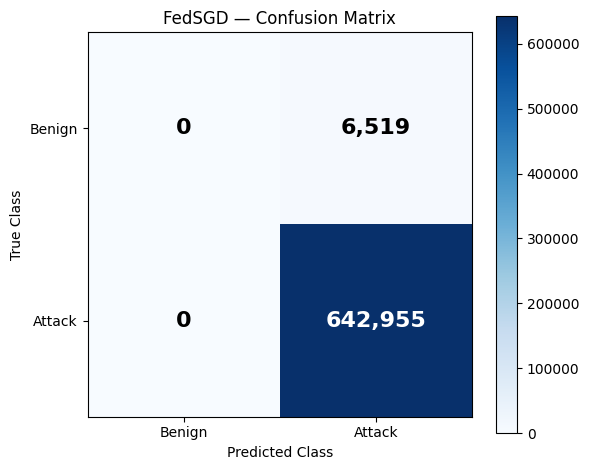

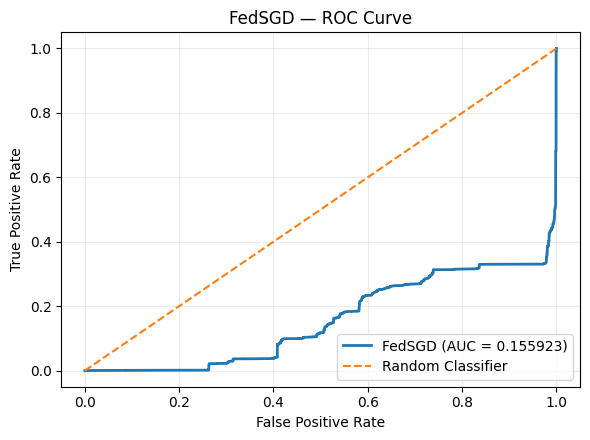

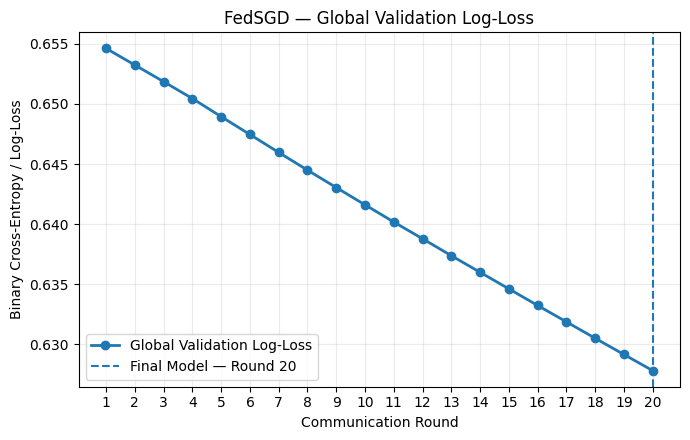


FEDSGD ROUND-20 FINAL TEST RESULTS
Accuracy         : 0.989963
Precision        : 0.989963
Recall           : 1.000000
F1               : 0.994956
Macro F1         : 0.497478
Weighted F1      : 0.984969
Benign Precision : 0.000000
Benign Recall    : 0.000000
Benign F1        : 0.000000
ROC-AUC          : 0.155923
PR-AUC           : 0.971516

Confusion Matrix:
TN = 0
FP = 6519
FN = 0
TP = 642955

Classification Report:


,precision,recall,f1-score,support
Benign,0.000000,0.000000,0.000000,6519.000000
Attack,0.989963,1.000000,0.994956,642955.000000
accuracy,0.989963,0.989963,0.989963,0.989963
macro avg,0.494981,0.500000,0.497478,649474.000000
weighted avg,0.980026,0.989963,0.984969,649474.000000



FEDSGD COMPLETE
Final model       : Round 20
Communication     : 20 rounds

Saved:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedSGD/result/final_metrics.csv
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedSGD/result/predictions.npz
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedSGD/figures/FedSGD_Confusion_Matrix.png
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedSGD/figures/FedSGD_ROC_Curve.png
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedSGD/figures/FedSGD_Global_Validation_Log_Loss.png

✅ No retraining performed.
✅ Round-20 model evaluated.
✅ FedAvg untouched.
✅ FedSGD experiment complete.


12994

In [ ]:
# ================================================================
# CELL 8: FEDSGD ROUND-20 FINAL TEST + FIGURES
# ================================================================
#
# FINAL MODEL:
#   FedSGD global model AFTER communication Round 20
#
# OUTPUT:
#   - Final test metrics
#   - Classification report
#   - Confusion Matrix
#   - ROC Curve
#   - Global Validation Log-Loss Curve
#
# IMPORTANT:
#   - NO TRAINING
#   - Test inference saved and reused on re-run
#   - FedAvg untouched
#
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ----------------------------------------------------------------
# 2. Safety checks
# ----------------------------------------------------------------

if not os.path.exists(
    FEDSGD_FINAL_MODEL_FILE
):
    raise FileNotFoundError(
        "FedSGD Round-20 final model not found:\n" + FEDSGD_FINAL_MODEL_FILE
    )


if not os.path.exists(
    FEDSGD_ROUND_HISTORY_FILE
):
    raise FileNotFoundError(
        "FedSGD round history not found."
    )


# ----------------------------------------------------------------
# 3. Verify training really ended at Round 20
# ----------------------------------------------------------------

round_history = pd.read_csv(
    FEDSGD_ROUND_HISTORY_FILE
)


if int(
    round_history["Round"].max()
) != 20:

    raise RuntimeError(
        "FedSGD history does not end at Round 20."
    )


print(
    "✅ Verified final communication round: 20"
)


# ----------------------------------------------------------------
# 4. Local test cache
# ----------------------------------------------------------------

LOCAL_TEST_CACHE_DIR = (
    "/content/fl_binary_test_cache"
)

os.makedirs(
    LOCAL_TEST_CACHE_DIR,
    exist_ok=True
)


LOCAL_X_TEST_FILE = os.path.join(
    LOCAL_TEST_CACHE_DIR,
    "X_test_scaled_float32.npy"
)

LOCAL_Y_TEST_FILE = os.path.join(
    LOCAL_TEST_CACHE_DIR,
    "y_test_int8.npy"
)


def copy_if_missing(
    source,
    destination
):

    if not os.path.exists(
        destination
    ):

        print(
            "Copying temporarily to Colab:",
            os.path.basename(source)
        )

        shutil.copy2(
            source,
            destination
        )


copy_if_missing(
    X_TEST_FILE,
    LOCAL_X_TEST_FILE
)

copy_if_missing(
    Y_TEST_FILE,
    LOCAL_Y_TEST_FILE
)


# ----------------------------------------------------------------
# 5. Load untouched test set
# ----------------------------------------------------------------

X_test_fedsgd = np.load(
    LOCAL_X_TEST_FILE,
    mmap_mode="r"
)

y_test_fedsgd = np.load(
    LOCAL_Y_TEST_FILE,
    mmap_mode="r"
)


y_true = np.asarray(
    y_test_fedsgd,
    dtype=np.uint8
)


print(
    "Test samples:",
    f"{len(y_true):,}"
)


# ================================================================
# 6. TEST INFERENCE — ONLY IF NOT ALREADY SAVED
# ================================================================

if os.path.exists(
    FEDSGD_FINAL_PREDICTIONS_FILE
):

    print(
        "\n✅ Saved Round-20 predictions found."
    )

    print(
        "✅ Test inference skipped."
    )


    saved_predictions = np.load(
        FEDSGD_FINAL_PREDICTIONS_FILE
    )


    y_pred = saved_predictions[
        "y_pred"
    ].astype(
        np.uint8,
        copy=False
    )


    y_prob = saved_predictions[
        "y_prob"
    ].astype(
        np.float32,
        copy=False
    )


else:

    print(
        "\nRunning FedSGD ROUND-20 "
        "final test inference..."
    )


    final_model = (
        tf.keras.models.load_model(
            FEDSGD_FINAL_MODEL_FILE,
            compile=False
        )
    )


    if final_model.count_params() != 60097:
        raise RuntimeError(
            "Unexpected model architecture."
        )


    TEST_BATCH_SIZE = 4096

    probability_parts = []


    for start in range(
        0,
        len(y_true),
        TEST_BATCH_SIZE
    ):

        end = min(
            start + TEST_BATCH_SIZE,
            len(y_true)
        )


        batch_x = np.asarray(
            X_test_fedsgd[
                start:end
            ],
            dtype=np.float32
        )


        batch_x = batch_x[
            ...,
            np.newaxis
        ]


        batch_probability = (
            final_model(
                batch_x,
                training=False
            )
            .numpy()
            .reshape(-1)
        )


        probability_parts.append(
            batch_probability.astype(
                np.float32,
                copy=False
            )
        )


    y_prob = np.concatenate(
        probability_parts
    )


    y_pred = (
        y_prob >= 0.5
    ).astype(
        np.uint8
    )


    if len(y_pred) != len(y_true):

        raise RuntimeError(
            "Prediction count mismatch."
        )


    np.savez_compressed(
        FEDSGD_FINAL_PREDICTIONS_FILE,
        y_pred=y_pred,
        y_prob=y_prob
    )


    print(
        "✅ Round-20 predictions saved."
    )


    del final_model
    del probability_parts

    tf.keras.backend.clear_session()

    gc.collect()


# ================================================================
# 7. FINAL TEST METRICS
# ================================================================

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
).ravel()


accuracy = accuracy_score(
    y_true,
    y_pred
)


attack_precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


benign_precision = precision_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_recall = recall_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)


specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)


roc_auc = roc_auc_score(
    y_true,
    y_prob
)


pr_auc = average_precision_score(
    y_true,
    y_prob
)


final_metrics = {
    "Model":
        FEDSGD_EXPERIMENT_NAME,

    "Final_Round":
        20,

    "Accuracy":
        float(accuracy),

    "Precision":
        float(attack_precision),

    "Recall":
        float(attack_recall),

    "F1":
        float(attack_f1),

    "Macro_F1":
        float(macro_f1),

    "Weighted_F1":
        float(weighted_f1),

    "Benign_Precision":
        float(benign_precision),

    "Benign_Recall":
        float(benign_recall),

    "Benign_F1":
        float(benign_f1),

    "Specificity":
        float(specificity),

    "ROC_AUC":
        float(roc_auc),

    "PR_AUC":
        float(pr_auc),

    "TN":
        int(tn),

    "FP":
        int(fp),

    "FN":
        int(fn),

    "TP":
        int(tp),

    "Test_Samples":
        int(len(y_true))
}


metrics_df = pd.DataFrame(
    [final_metrics]
)


metrics_df.to_csv(
    FEDSGD_FINAL_METRICS_FILE,
    index=False
)


# ================================================================
# 8. CLASSIFICATION REPORT
# ================================================================

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=[
        "Benign",
        "Attack"
    ],
    output_dict=True,
    zero_division=0
)


report_df = pd.DataFrame(
    report
).transpose()


# ================================================================
# 9. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)


fig, ax = plt.subplots(
    figsize=(6, 5)
)


image = ax.imshow(
    cm,
    cmap="Blues"
)


ax.set_xticks(
    [0, 1],
    labels=[
        "Benign",
        "Attack"
    ]
)


ax.set_yticks(
    [0, 1],
    labels=[
        "Benign",
        "Attack"
    ]
)


ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_title(
    "FedSGD — Confusion Matrix"
)


# Larger values with automatic text color
threshold = cm.max() / 2


for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


fig.colorbar(
    image,
    ax=ax
)


plt.tight_layout()


plt.savefig(
    FEDSGD_CM_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ================================================================
# 10. ROC CURVE
# ================================================================

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)


fig, ax = plt.subplots(
    figsize=(6, 4.5)
)


ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"FedSGD "
        f"(AUC = {roc_auc:.6f})"
    )
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)


ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "FedSGD — ROC Curve"
)


ax.legend(
    loc="lower right"
)


ax.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    FEDSGD_ROC_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ================================================================
# 11. GLOBAL VALIDATION LOG-LOSS CURVE
# ================================================================

fig, ax = plt.subplots(
    figsize=(7, 4.5)
)


ax.plot(
    round_history[
        "Round"
    ],
    round_history[
        "Val_Loss"
    ],
    marker="o",
    linewidth=2,
    label="Global Validation Log-Loss"
)


ax.axvline(
    20,
    linestyle="--",
    linewidth=1.5,
    label="Final Model — Round 20"
)


ax.set_xlabel(
    "Communication Round"
)

ax.set_ylabel(
    "Binary Cross-Entropy / Log-Loss"
)

ax.set_title(
    "FedSGD — Global Validation Log-Loss"
)


ax.set_xticks(
    round_history[
        "Round"
    ]
)


ax.legend()


ax.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    FEDSGD_LOSS_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ================================================================
# 12. DISPLAY FINAL RESULTS
# ================================================================

print(
    "\n" + "=" * 72
)

print(
    "FEDSGD ROUND-20 FINAL TEST RESULTS"
)

print(
    "=" * 72
)


print(
    f"Accuracy         : {accuracy:.6f}"
)

print(
    f"Precision        : {attack_precision:.6f}"
)

print(
    f"Recall           : {attack_recall:.6f}"
)

print(
    f"F1               : {attack_f1:.6f}"
)

print(
    f"Macro F1         : {macro_f1:.6f}"
)

print(
    f"Weighted F1      : {weighted_f1:.6f}"
)

print(
    f"Benign Precision : {benign_precision:.6f}"
)

print(
    f"Benign Recall    : {benign_recall:.6f}"
)

print(
    f"Benign F1        : {benign_f1:.6f}"
)

print(
    f"ROC-AUC          : {roc_auc:.6f}"
)

print(
    f"PR-AUC           : {pr_auc:.6f}"
)


print(
    "\nConfusion Matrix:"
)

print(
    f"TN = {tn}"
)

print(
    f"FP = {fp}"
)

print(
    f"FN = {fn}"
)

print(
    f"TP = {tp}"
)


print(
    "\nClassification Report:"
)

display(
    report_df
)


print(
    "\n" + "=" * 72
)

print(
    "FEDSGD COMPLETE"
)

print(
    "=" * 72
)


print(
    "Final model       : Round 20"
)

print(
    "Communication     : 20 rounds"
)


print(
    "\nSaved:"
)

print(
    FEDSGD_FINAL_METRICS_FILE
)

print(
    FEDSGD_FINAL_PREDICTIONS_FILE
)

print(
    FEDSGD_CM_FILE
)

print(
    FEDSGD_ROC_FILE
)

print(
    FEDSGD_LOSS_FILE
)


print(
    "\n✅ No retraining performed."
)

print(
    "✅ Round-20 model evaluated."
)

print(
    "✅ FedAvg untouched."
)

print(
    "✅ FedSGD experiment complete."
)

print(
    "=" * 72
)


gc.collect()


FedProx — Federated Proximal Optimization

Cell 9 — FedProx Experiment Setup

In [ ]:
# ================================================================
# CELL 9: FEDPROX EXPERIMENT SETUP
# ================================================================
#
# SAME FAIR-COMPARISON SETTINGS:
#   - Same CNN-LSTM-ResNet architecture
#   - Same 5 IID clients
#   - Same exact client partition
#   - Same global validation set
#   - Same untouched test set
#   - 20 communication rounds
#   - 1 local epoch
#   - Batch size = 2048
#   - Local optimizer = Adam
#   - Local learning rate = 0.001
#
# FEDPROX-SPECIFIC:
#   mu = 0.01
#
# FINAL MODEL:
#   Global model after Round 20
#
# NO TRAINING IN THIS CELL.
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import json
import numpy as np


# ----------------------------------------------------------------
# 2. Required notebook variables
# ----------------------------------------------------------------

required_variables = [
    "PROJECT_ROOT",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "X_TEST_FILE",
    "Y_TEST_FILE",
    "client_indices",
    "validation_indices",
    "NUM_CLIENTS",
    "NUM_FEATURES",
    "RANDOM_SEED",
    "build_federated_binary_model"
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n" + "\n".join(missing_variables) + "\n\nRun the original shared setup/"
          "partition/model cells first."
    )


# ----------------------------------------------------------------
# 3. FedProx configuration
# ----------------------------------------------------------------

FEDPROX_EXPERIMENT_NAME = (
    "FedProx_IID_5Clients_"
    "CNN-LSTM-ResNet_Binary"
)


FEDPROX_MAX_ROUNDS = 20

FEDPROX_LOCAL_EPOCHS = 1

FEDPROX_BATCH_SIZE = 2048

FEDPROX_LEARNING_RATE = 0.001

FEDPROX_MU = 0.01


# ----------------------------------------------------------------
# 4. FedProx root directory
# ----------------------------------------------------------------

FEDPROX_ROOT = os.path.join(
    PROJECT_ROOT,
    "federated_binary",
    "FedProx"
)


FEDPROX_CHECKPOINT_DIR = os.path.join(
    FEDPROX_ROOT,
    "checkpoint"
)

FEDPROX_MODEL_DIR = os.path.join(
    FEDPROX_ROOT,
    "model"
)

FEDPROX_RESULT_DIR = os.path.join(
    FEDPROX_ROOT,
    "result"
)

FEDPROX_FIGURE_DIR = os.path.join(
    FEDPROX_ROOT,
    "figures"
)


for directory in [
    FEDPROX_ROOT,
    FEDPROX_CHECKPOINT_DIR,
    FEDPROX_MODEL_DIR,
    FEDPROX_RESULT_DIR,
    FEDPROX_FIGURE_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


# ----------------------------------------------------------------
# 5. Essential output files
# ----------------------------------------------------------------

FEDPROX_CONFIG_FILE = os.path.join(
    FEDPROX_ROOT,
    "config.json"
)


FEDPROX_LATEST_MODEL_FILE = os.path.join(
    FEDPROX_CHECKPOINT_DIR,
    "latest_completed_round.keras"
)


FEDPROX_STATE_FILE = os.path.join(
    FEDPROX_CHECKPOINT_DIR,
    "state.json"
)


FEDPROX_ROUND_HISTORY_FILE = os.path.join(
    FEDPROX_RESULT_DIR,
    "round_history.csv"
)


FEDPROX_FINAL_MODEL_FILE = os.path.join(
    FEDPROX_MODEL_DIR,
    "FedProx_Round20_Final.keras"
)


FEDPROX_FINAL_METRICS_FILE = os.path.join(
    FEDPROX_RESULT_DIR,
    "final_metrics.csv"
)


FEDPROX_FINAL_PREDICTIONS_FILE = os.path.join(
    FEDPROX_RESULT_DIR,
    "predictions.npz"
)


FEDPROX_CM_FILE = os.path.join(
    FEDPROX_FIGURE_DIR,
    "FedProx_Confusion_Matrix.png"
)


FEDPROX_ROC_FILE = os.path.join(
    FEDPROX_FIGURE_DIR,
    "FedProx_ROC_Curve.png"
)


FEDPROX_LOSS_FILE = os.path.join(
    FEDPROX_FIGURE_DIR,
    "FedProx_Global_Validation_Log_Loss.png"
)


# ----------------------------------------------------------------
# 6. Verify same 5-client partition
# ----------------------------------------------------------------

fedprox_client_sizes = np.array(
    [
        len(indices)
        for indices in client_indices
    ],
    dtype=np.int64
)


if len(
    fedprox_client_sizes
) != 5:

    raise RuntimeError(
        "Expected exactly 5 clients."
    )


FEDPROX_CLIENT_WEIGHTS = (
    fedprox_client_sizes / fedprox_client_sizes.sum()
)


# ----------------------------------------------------------------
# 7. Experiment configuration record
# ----------------------------------------------------------------

FEDPROX_CONFIG = {

    "experiment_name":
        FEDPROX_EXPERIMENT_NAME,

    "algorithm":
        "FedProx",

    "architecture":
        "CNN-LSTM-ResNet",

    "partition":
        "IID",

    "num_clients":
        5,

    "communication_rounds":
        FEDPROX_MAX_ROUNDS,

    "local_epochs":
        FEDPROX_LOCAL_EPOCHS,

    "batch_size":
        FEDPROX_BATCH_SIZE,

    "local_optimizer":
        "Adam",

    "learning_rate":
        FEDPROX_LEARNING_RATE,

    "mu":
        FEDPROX_MU,

    "aggregation":
        "sample-size weighted",

    "final_model":
        "Round 20 global model",

    "random_seed":
        int(RANDOM_SEED)
}


# ----------------------------------------------------------------
# 8. Save / verify configuration
# ----------------------------------------------------------------

if os.path.exists(
    FEDPROX_CONFIG_FILE
):

    with open(
        FEDPROX_CONFIG_FILE,
        "r"
    ) as file:

        existing_config = json.load(
            file
        )


    if existing_config != FEDPROX_CONFIG:

        raise RuntimeError(
            "Existing FedProx configuration "
            "does not match this experiment."
        )


    print(
        "✅ Existing FedProx configuration verified."
    )


else:

    with open(
        FEDPROX_CONFIG_FILE,
        "w"
    ) as file:

        json.dump(
            FEDPROX_CONFIG,
            file,
            indent=2
        )


    print(
        "✅ Fresh FedProx configuration created."
    )


# ----------------------------------------------------------------
# 9. Display setup
# ----------------------------------------------------------------

print(
    "\n" + "=" * 72
)

print(
    "FEDPROX EXPERIMENT READY"
)

print(
    "=" * 72
)


print(
    "Architecture        : CNN-LSTM-ResNet"
)

print(
    "Algorithm           : FedProx"
)

print(
    "Partition           : IID"
)

print(
    "Clients             : 5"
)

print(
    "Communication rounds: 20"
)

print(
    "Local epochs        : 1"
)

print(
    "Batch size          : 2048"
)

print(
    "Local optimizer     : Adam"
)

print(
    "Learning rate       : 0.001"
)

print(
    "Proximal mu         : 0.01"
)

print(
    "Final model policy  : ROUND 20"
)


print(
    "\nClient distribution:"
)


for client_id, (
    sample_count,
    client_weight
) in enumerate(
    zip(
        fedprox_client_sizes,
        FEDPROX_CLIENT_WEIGHTS
    ),
    start=1
):

    print(
        f"Client {client_id}: "
        f"{sample_count:,} samples | "
        f"{client_weight * 100:.6f}%"
    )


print(
    "\nValidation samples:",
    f"{len(validation_indices):,}"
)


print(
    "\n✅ Same FedAvg/FedSGD partition reused."
)

print(
    "✅ Same CNN-LSTM-ResNet architecture."
)

print(
    "✅ FedAvg local training budget matched."
)

print(
    "✅ FedAvg files untouched."
)

print(
    "✅ FedSGD files untouched."
)

print(
    "✅ Test set untouched."
)

print(
    "✅ No training performed."
)

print(
    "=" * 72
)


✅ Existing FedProx configuration verified.

FEDPROX EXPERIMENT READY
Architecture        : CNN-LSTM-ResNet
Algorithm           : FedProx
Partition           : IID
Clients             : 5
Communication rounds: 20
Local epochs        : 1
Batch size          : 2048
Local optimizer     : Adam
Learning rate       : 0.001
Proximal mu         : 0.01
Final model policy  : ROUND 20

Client distribution:
Client 1: 467,621 samples | 20.000026%
Client 2: 467,621 samples | 20.000026%
Client 3: 467,620 samples | 19.999983%
Client 4: 467,620 samples | 19.999983%
Client 5: 467,620 samples | 19.999983%

Validation samples: 259,790

✅ Same FedAvg/FedSGD partition reused.
✅ Same CNN-LSTM-ResNet architecture.
✅ FedAvg local training budget matched.
✅ FedAvg files untouched.
✅ FedSGD files untouched.
✅ Test set untouched.
✅ No training performed.


In [ ]:
# ================================================================
# CELL 10: FEDPROX TRAINING — 20 COMMUNICATION ROUNDS
# ================================================================

# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import time
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    log_loss
)

from tensorflow.keras import mixed_precision


# ----------------------------------------------------------------
# ----------------------------------------------------------------
# 2. Automatic CPU / GPU runtime configuration
# ----------------------------------------------------------------
# This experiment can run on either Google Colab GPU or CPU.
# GPU: mixed_float16 for speed/memory efficiency.
# CPU: float32 for compatibility and numerical stability.
# No FL algorithm, data partition, hyperparameter, or output path is changed.
# ----------------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(gpus) > 0

if GPU_AVAILABLE:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass

    mixed_precision.set_global_policy("mixed_float16")
    DEVICE_TYPE = "GPU"
    DEVICE_NAME = gpus[0].name

else:
    mixed_precision.set_global_policy("float32")
    DEVICE_TYPE = "CPU"
    DEVICE_NAME = "CPU"

print("Runtime device :", DEVICE_TYPE)
print("Device name    :", DEVICE_NAME)
print("Precision      :", mixed_precision.global_policy().name)

# ----------------------------------------------------------------
# 3. Skip if already completed
# ----------------------------------------------------------------

if os.path.exists(
    FEDPROX_FINAL_MODEL_FILE
):

    print(
        "\n" + "=" * 72
    )

    print(
        "✅ FEDPROX TRAINING ALREADY COMPLETE"
    )

    print(
        "=" * 72
    )

    print(
        "Round-20 final model already exists:"
    )

    print(
        FEDPROX_FINAL_MODEL_FILE
    )

    print(
        "\nTraining skipped."
    )


else:

    # ============================================================
    # 4. Local Colab training cache
    # ============================================================

    LOCAL_CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )

    os.makedirs(
        LOCAL_CACHE_DIR,
        exist_ok=True
    )


    LOCAL_X_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "X_train_scaled_float32.npy"
    )

    LOCAL_Y_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "y_train_int8.npy"
    )


    def copy_if_missing(
        source,
        destination
    ):

        if not os.path.exists(
            destination
        ):

            print(
                "Copying temporarily to Colab:",
                os.path.basename(source)
            )

            shutil.copy2(
                source,
                destination
            )


    copy_if_missing(
        X_TRAIN_FILE,
        LOCAL_X_TRAIN_FILE
    )

    copy_if_missing(
        Y_TRAIN_FILE,
        LOCAL_Y_TRAIN_FILE
    )


    # ----------------------------------------------------------------
    # 5. Memory-mapped training data
    # ----------------------------------------------------------------

    X_train_fedprox = np.load(
        LOCAL_X_TRAIN_FILE,
        mmap_mode="r"
    )

    y_train_fedprox = np.load(
        LOCAL_Y_TRAIN_FILE,
        mmap_mode="r"
    )


    print(
        "\nTraining shape:",
        X_train_fedprox.shape
    )


    # ----------------------------------------------------------------
    # 6. SAME global validation set
    # ----------------------------------------------------------------

    X_val_fedprox = np.asarray(
        X_train_fedprox[
            validation_indices
        ],
        dtype=np.float32
    )


    y_val_fedprox = np.asarray(
        y_train_fedprox[
            validation_indices
        ],
        dtype=np.uint8
    )


    X_val_fedprox = (
        X_val_fedprox[
            ...,
            np.newaxis
        ]
    )


    print(
        "Validation samples:",
        f"{len(y_val_fedprox):,}"
    )


    # ============================================================
    # 7. Atomic save helpers
    # ============================================================

    def save_json_atomic(
        data,
        final_path
    ):

        temp_path = (
            final_path + ".tmp"
        )

        with open(
            temp_path,
            "w"
        ) as file:

            json.dump(
                data,
                file,
                indent=2
            )

        os.replace(
            temp_path,
            final_path
        )


    def save_csv_atomic(
        dataframe,
        final_path
    ):

        temp_path = (
            final_path + ".tmp.csv"
        )

        dataframe.to_csv(
            temp_path,
            index=False
        )

        os.replace(
            temp_path,
            final_path
        )


    def save_model_atomic(
        model,
        final_path
    ):

        temp_path = os.path.join(
            os.path.dirname(
                final_path
            ),
            "temporary_model.keras"
        )

        if os.path.exists(
            temp_path
        ):

            os.remove(
                temp_path
            )


        model.save(
            temp_path,
            overwrite=True
        )


        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 8. Resume OR fresh global model
    # ============================================================

    resume_available = (
        os.path.exists(
            FEDPROX_LATEST_MODEL_FILE
        ) and os.path.exists(
            FEDPROX_STATE_FILE
        )
    )


    if resume_available:

        with open(
            FEDPROX_STATE_FILE,
            "r"
        ) as file:

            state = json.load(
                file
            )


        last_completed_round = int(
            state[
                "last_completed_round"
            ]
        )


        global_model = (
            tf.keras.models.load_model(
                FEDPROX_LATEST_MODEL_FILE,
                compile=False
            )
        )


        START_ROUND = (
            last_completed_round + 1
        )


        print(
            "\n🔄 RESUMING FEDPROX"
        )

        print(
            "Last completed round:",
            last_completed_round
        )

        print(
            "Starting from round:",
            START_ROUND
        )


    else:

        tf.keras.backend.clear_session()

        mixed_precision.set_global_policy(
    "mixed_float16" if GPU_AVAILABLE else "float32"
)

        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )


        global_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        START_ROUND = 1


        print(
            "\n🟢 STARTING NEW FEDPROX TRAINING"
        )


    # ----------------------------------------------------------------
    # 9. Architecture check
    # ----------------------------------------------------------------

    if global_model.count_params() != 60097:

        raise RuntimeError(
            "Unexpected parameter count: "
            f"{global_model.count_params():,}"
        )


    print(
        "Global model parameters:",
        f"{global_model.count_params():,}"
    )


    # ============================================================
    # 10. Reusable LOCAL model
    # ============================================================

    local_model = (
        build_federated_binary_model(
            compile_model=False
        )
    )


    if local_model.count_params() != 60097:

        raise RuntimeError(
            "Local model architecture mismatch."
        )


    # ----------------------------------------------------------------
    # 11. Local Adam optimizer
    # ----------------------------------------------------------------

    local_optimizer = (
        tf.keras.optimizers.Adam(
            learning_rate=
                FEDPROX_LEARNING_RATE
        )
    )


    # Create optimizer slots once.
    local_optimizer.build(
        local_model.trainable_variables
    )


    bce_loss_function = (
        tf.keras.losses.BinaryCrossentropy()
    )


    # ----------------------------------------------------------------
    # 12. Global reference variables for proximal term
    # ----------------------------------------------------------------

    global_reference_weights = [

        tf.Variable(
            tf.cast(
                variable,
                tf.float32
            ),
            trainable=False
        )

        for variable
        in local_model.trainable_variables
    ]


    # ============================================================
    # 13. Reset Adam state for every client
    # ============================================================

    def reset_local_optimizer():

        for variable in local_optimizer.variables:

            variable_name = (
                variable.name.lower()
            )


            # Preserve the configured LR.
            if (
                "learning_rate"
                in variable_name
            ):

                continue


            variable.assign(
                tf.zeros_like(
                    variable
                )
            )


    # ============================================================
    # 14. FedProx train step
    # ============================================================

    FEDPROX_LOSS_SCALE = 1024.0


    @tf.function(
        input_signature=[
            tf.TensorSpec(
                shape=(
                    None,
                    NUM_FEATURES,
                    1
                ),
                dtype=tf.float32
            ),

            tf.TensorSpec(
                shape=(None,),
                dtype=tf.float32
            )
        ],
        reduce_retracing=True
    )
    def fedprox_train_step(
        batch_x,
        batch_y
    ):

        batch_y = tf.reshape(
            batch_y,
            (-1, 1)
        )


        with tf.GradientTape() as tape:

            probabilities = local_model(
                batch_x,
                training=True
            )


            bce_loss = (
                bce_loss_function(
                    batch_y,
                    probabilities
                )
            )


            # ----------------------------------------------------
            # FedProx proximal penalty
            #
            # (mu / 2) *
            # sum ||w_local - w_global||^2
            # ----------------------------------------------------

            proximal_sum = tf.constant(
                0.0,
                dtype=tf.float32
            )


            for (
                local_variable,
                global_reference
            ) in zip(
                local_model.trainable_variables,
                global_reference_weights
            ):

                difference = (
                    tf.cast(
                        local_variable,
                        tf.float32
                    ) - global_reference
                )


                proximal_sum += (
                    tf.reduce_sum(
                        tf.square(
                            difference
                        )
                    )
                )


            proximal_loss = (
                0.5 * FEDPROX_MU * proximal_sum
            )


            total_loss = (
                tf.cast(
                    bce_loss,
                    tf.float32
                ) + proximal_loss
            )


            scaled_total_loss = (
                total_loss * FEDPROX_LOSS_SCALE
            )


        scaled_gradients = tape.gradient(
            scaled_total_loss,
            local_model.trainable_variables
        )


        gradients = []


        for (
            gradient,
            variable
        ) in zip(
            scaled_gradients,
            local_model.trainable_variables
        ):

            if gradient is None:

                gradient = tf.zeros_like(
                    variable,
                    dtype=tf.float32
                )

            else:

                gradient = (
                    tf.cast(
                        gradient,
                        tf.float32
                    ) / FEDPROX_LOSS_SCALE
                )


            gradients.append(
                gradient
            )


        local_optimizer.apply_gradients(
            zip(
                gradients,
                local_model.trainable_variables
            )
        )


        return (
            tf.cast(
                bce_loss,
                tf.float32
            ),
            proximal_loss,
            total_loss
        )


    # ============================================================
    # 15. Validation function
    # ============================================================

    VALIDATION_BATCH_SIZE = 4096


    def evaluate_global_validation():

        probability_parts = []


        for start in range(
            0,
            len(y_val_fedprox),
            VALIDATION_BATCH_SIZE
        ):

            end = min(
                start + VALIDATION_BATCH_SIZE,
                len(y_val_fedprox)
            )


            batch_x = tf.convert_to_tensor(
                X_val_fedprox[
                    start:end
                ],
                dtype=tf.float32
            )


            batch_probability = (
                global_model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
            )


            probability_parts.append(
                batch_probability
            )


        probabilities = np.concatenate(
            probability_parts
        ).astype(
            np.float32,
            copy=False
        )


        predictions = (
            probabilities >= 0.5
        ).astype(
            np.uint8
        )


        val_loss = log_loss(
            y_val_fedprox,
            probabilities,
            labels=[0, 1]
        )


        val_accuracy = accuracy_score(
            y_val_fedprox,
            predictions
        )


        val_macro_f1 = f1_score(
            y_val_fedprox,
            predictions,
            average="macro",
            zero_division=0
        )


        val_benign_recall = recall_score(
            y_val_fedprox,
            predictions,
            pos_label=0,
            zero_division=0
        )


        return (
            float(val_loss),
            float(val_accuracy),
            float(val_macro_f1),
            float(val_benign_recall)
        )


    # ============================================================
    # 16. Round history
    # ============================================================

    HISTORY_COLUMNS = [
        "Round",
        "Train_BCE_Loss",
        "Train_Proximal_Loss",
        "Train_Total_Loss",
        "Val_Loss",
        "Val_Accuracy",
        "Val_Macro_F1",
        "Val_Benign_Recall",
        "Round_Time_sec"
    ]


    if os.path.exists(
        FEDPROX_ROUND_HISTORY_FILE
    ):

        fedprox_history_df = pd.read_csv(
            FEDPROX_ROUND_HISTORY_FILE
        )

    else:

        fedprox_history_df = (
            pd.DataFrame(
                columns=
                    HISTORY_COLUMNS
            )
        )


    if resume_available:

        fedprox_history_df = (
            fedprox_history_df[
                fedprox_history_df[
                    "Round"
                ] < START_ROUND
            ]
            .copy()
        )


    # ================================================================
    # 17. COMMUNICATION ROUNDS
    # ================================================================

    for round_number in range(
        START_ROUND,
        FEDPROX_MAX_ROUNDS + 1
    ):

        round_start_time = (
            time.time()
        )


        print(
            "\n" + "=" * 72
        )

        print(
            f"FEDPROX ROUND "
            f"{round_number}/"
            f"{FEDPROX_MAX_ROUNDS}"
        )

        print(
            "=" * 72
        )


        # --------------------------------------------------------
        # Global model at START of this communication round
        # --------------------------------------------------------

        global_weights = (
            global_model.get_weights()
        )


        # --------------------------------------------------------
        # Weighted aggregation accumulator
        # --------------------------------------------------------

        aggregated_weights = [

            np.zeros_like(
                weight,
                dtype=np.float64
            )

            for weight
            in global_weights
        ]


        # Round-level training statistics
        round_bce_sum = 0.0
        round_prox_sum = 0.0
        round_total_sum = 0.0
        round_sample_sum = 0


        # ========================================================
        # 18. CLIENT LOOP
        # ========================================================

        for client_id in range(
            NUM_CLIENTS
        ):

            client_start_time = (
                time.time()
            )


            original_indices = (
                client_indices[
                    client_id
                ]
            )


            client_sample_count = int(
                len(
                    original_indices
                )
            )


            client_weight = float(
                FEDPROX_CLIENT_WEIGHTS[
                    client_id
                ]
            )


            print(
                f"\nClient "
                f"{client_id + 1}/"
                f"{NUM_CLIENTS}"
            )

            print(
                "Samples:",
                f"{client_sample_count:,}"
            )

            print(
                "Aggregation weight:",
                f"{client_weight * 100:.6f}%"
            )


            # ----------------------------------------------------
            # Deterministic local shuffle
            # ----------------------------------------------------

            local_rng = np.random.default_rng(
                RANDOM_SEED + round_number * 100 + client_id
            )


            shuffled_indices = np.array(
                original_indices,
                copy=True
            )


            local_rng.shuffle(
                shuffled_indices
            )


            # ----------------------------------------------------
            # Load ONE client into RAM
            # ----------------------------------------------------

            X_client = np.asarray(
                X_train_fedprox[
                    shuffled_indices
                ],
                dtype=np.float32
            )


            y_client = np.asarray(
                y_train_fedprox[
                    shuffled_indices
                ],
                dtype=np.float32
            )


            X_client = (
                X_client[
                    ...,
                    np.newaxis
                ]
            )


            # ====================================================
            # 19. Start client from current GLOBAL model
            # ====================================================

            local_model.set_weights(
                global_weights
            )


            # Global weights are FIXED references during
            # this client's local training.
            for (
                reference_variable,
                local_variable
            ) in zip(
                global_reference_weights,
                local_model.trainable_variables
            ):

                reference_variable.assign(
                    tf.cast(
                        local_variable,
                        tf.float32
                    )
                )


            # Fresh Adam state for this client
            reset_local_optimizer()


            # ====================================================
            # 20. ONE LOCAL EPOCH
            # ====================================================

            client_bce_sum = 0.0
            client_prox_sum = 0.0
            client_total_sum = 0.0


            for local_epoch in range(
                FEDPROX_LOCAL_EPOCHS
            ):

                for batch_start in range(
                    0,
                    client_sample_count,
                    FEDPROX_BATCH_SIZE
                ):

                    batch_end = min(
                        batch_start + FEDPROX_BATCH_SIZE,
                        client_sample_count
                    )


                    actual_batch_size = (
                        batch_end - batch_start
                    )


                    batch_x = tf.convert_to_tensor(
                        X_client[
                            batch_start:
                            batch_end
                        ],
                        dtype=tf.float32
                    )


                    batch_y = tf.convert_to_tensor(
                        y_client[
                            batch_start:
                            batch_end
                        ],
                        dtype=tf.float32
                    )


                    (
                        batch_bce,
                        batch_prox,
                        batch_total
                    ) = fedprox_train_step(
                        batch_x,
                        batch_y
                    )


                    client_bce_sum += (
                        float(
                            batch_bce.numpy()
                        ) * actual_batch_size
                    )


                    client_prox_sum += (
                        float(
                            batch_prox.numpy()
                        ) * actual_batch_size
                    )


                    client_total_sum += (
                        float(
                            batch_total.numpy()
                        ) * actual_batch_size
                    )


            # ====================================================
            # 21. Client mean losses
            # ====================================================

            effective_samples = (
                client_sample_count * FEDPROX_LOCAL_EPOCHS
            )


            client_mean_bce = (
                client_bce_sum / effective_samples
            )


            client_mean_prox = (
                client_prox_sum / effective_samples
            )


            client_mean_total = (
                client_total_sum / effective_samples
            )


            print(
                f"Mean BCE loss      : "
                f"{client_mean_bce:.6f}"
            )

            print(
                f"Mean proximal loss : "
                f"{client_mean_prox:.6f}"
            )

            print(
                f"Mean total loss    : "
                f"{client_mean_total:.6f}"
            )


            # ====================================================
            # 22. Weighted local-model aggregation
            # ====================================================

            local_weights = (
                local_model.get_weights()
            )


            for weight_index in range(
                len(
                    aggregated_weights
                )
            ):

                aggregated_weights[
                    weight_index
                ] += (

                    local_weights[
                        weight_index
                    ].astype(
                        np.float64
                    )
 * client_weight

                )


            # ----------------------------------------------------
            # Round summary accumulation
            # ----------------------------------------------------

            round_bce_sum += (
                client_mean_bce * client_sample_count
            )


            round_prox_sum += (
                client_mean_prox * client_sample_count
            )


            round_total_sum += (
                client_mean_total * client_sample_count
            )


            round_sample_sum += (
                client_sample_count
            )


            print(
                f"Completed in "
                f"{time.time() - client_start_time:.1f} sec"
            )


            # ----------------------------------------------------
            # Cleanup
            # ----------------------------------------------------

            del shuffled_indices
            del X_client
            del y_client
            del local_weights
            del batch_x
            del batch_y

            gc.collect()


        # ========================================================
        # 23. SERVER AGGREGATION
        # ========================================================

        final_aggregated_weights = [

            weight.astype(
                original_weight.dtype,
                copy=False
            )

            for (
                weight,
                original_weight
            ) in zip(
                aggregated_weights,
                global_weights
            )
        ]


        global_model.set_weights(
            final_aggregated_weights
        )


        del aggregated_weights
        del final_aggregated_weights
        del global_weights

        gc.collect()


        # ========================================================
        # 24. GLOBAL VALIDATION
        # ========================================================

        (
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = evaluate_global_validation()


        mean_round_bce = (
            round_bce_sum / round_sample_sum
        )


        mean_round_prox = (
            round_prox_sum / round_sample_sum
        )


        mean_round_total = (
            round_total_sum / round_sample_sum
        )


        round_time = (
            time.time() - round_start_time
        )


        print(
            "\nRound training mean:"
        )

        print(
            f"  BCE loss      : "
            f"{mean_round_bce:.6f}"
        )

        print(
            f"  Proximal loss : "
            f"{mean_round_prox:.6f}"
        )

        print(
            f"  Total loss    : "
            f"{mean_round_total:.6f}"
        )


        print(
            "\nGlobal validation:"
        )

        print(
            f"  Log-Loss     : "
            f"{val_loss:.6f}"
        )

        print(
            f"  Accuracy     : "
            f"{val_accuracy:.6f}"
        )

        print(
            f"  Macro F1     : "
            f"{val_macro_f1:.6f}"
        )

        print(
            f"  Benign Recall: "
            f"{val_benign_recall:.6f}"
        )

        print(
            f"  Round time   : "
            f"{round_time:.1f} sec"
        )


        # ========================================================
        # 25. SAVE ROUND HISTORY
        # ========================================================

        new_history_row = pd.DataFrame(
            [
                {
                    "Round":
                        int(
                            round_number
                        ),

                    "Train_BCE_Loss":
                        float(
                            mean_round_bce
                        ),

                    "Train_Proximal_Loss":
                        float(
                            mean_round_prox
                        ),

                    "Train_Total_Loss":
                        float(
                            mean_round_total
                        ),

                    "Val_Loss":
                        float(
                            val_loss
                        ),

                    "Val_Accuracy":
                        float(
                            val_accuracy
                        ),

                    "Val_Macro_F1":
                        float(
                            val_macro_f1
                        ),

                    "Val_Benign_Recall":
                        float(
                            val_benign_recall
                        ),

                    "Round_Time_sec":
                        float(
                            round_time
                        )
                }
            ]
        )


        if fedprox_history_df.empty:

            fedprox_history_df = (
                new_history_row.copy()
            )

        else:

            fedprox_history_df = pd.concat(
                [
                    fedprox_history_df,
                    new_history_row
                ],
                ignore_index=True
            )


        save_csv_atomic(
            fedprox_history_df,
            FEDPROX_ROUND_HISTORY_FILE
        )


        # ========================================================
        # 26. RESUME CHECKPOINT
        # ========================================================

        save_model_atomic(
            global_model,
            FEDPROX_LATEST_MODEL_FILE
        )


        save_json_atomic(
            {
                "last_completed_round":
                    int(
                        round_number
                    )
            },
            FEDPROX_STATE_FILE
        )


        print(
            f"✅ Round {round_number} "
            "checkpoint saved."
        )


    # ================================================================
    # 27. FINALIZATION — ROUND 20 GLOBAL MODEL
    # ================================================================

    print(
        "\n" + "=" * 72
    )

    print(
        "FINALIZING FEDPROX"
    )

    print(
        "=" * 72
    )


    final_round = int(
        fedprox_history_df[
            "Round"
        ].max()
    )


    if final_round != 20:

        raise RuntimeError(
            "FedProx did not reach Round 20."
        )


    save_model_atomic(
        global_model,
        FEDPROX_FINAL_MODEL_FILE
    )


    print(
        "✅ ROUND-20 GLOBAL MODEL SAVED AS FINAL."
    )


    # ----------------------------------------------------------------
    # Round 20 validation
    # ----------------------------------------------------------------

    round20_row = (
        fedprox_history_df[
            fedprox_history_df[
                "Round"
            ] == 20
        ]
        .iloc[0]
    )


    print(
        "\nROUND-20 VALIDATION RESULTS"
    )

    print(
        f"Log-Loss     : "
        f"{round20_row['Val_Loss']:.6f}"
    )

    print(
        f"Accuracy     : "
        f"{round20_row['Val_Accuracy']:.6f}"
    )

    print(
        f"Macro F1     : "
        f"{round20_row['Val_Macro_F1']:.6f}"
    )

    print(
        f"Benign Recall: "
        f"{round20_row['Val_Benign_Recall']:.6f}"
    )


    # ----------------------------------------------------------------
    # 28. Delete ONLY temporary resume checkpoint
    # ----------------------------------------------------------------

    for file_path in [
        FEDPROX_LATEST_MODEL_FILE,
        FEDPROX_STATE_FILE
    ]:

        if os.path.exists(
            file_path
        ):

            os.remove(
                file_path
            )


    print(
        "\n✅ Temporary resume checkpoints removed."
    )

    print(
        "✅ Round history preserved."
    )

    print(
        "✅ FedAvg files untouched."
    )

    print(
        "✅ FedSGD files untouched."
    )

    print(
        "✅ Test set NOT evaluated."
    )

    print(
        "✅ FINAL comparison model = FedProx Round 20."
    )


    print(
        "\nFinal model:"
    )

    print(
        FEDPROX_FINAL_MODEL_FILE
    )


    print(
        "=" * 72
    )


    # ----------------------------------------------------------------
    # 29. Cleanup
    # ----------------------------------------------------------------

    del local_model
    del global_model

    tf.keras.backend.clear_session()

    gc.collect()


Runtime device : CPU
Device name    : CPU
Precision      : float32

✅ FEDPROX TRAINING ALREADY COMPLETE
Round-20 final model already exists:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedProx/model/FedProx_Round20_Final.keras

Training skipped.


✅ Verified final communication round: 20
Test samples: 649,474

✅ Saved FedProx predictions found.
✅ Test inference skipped.


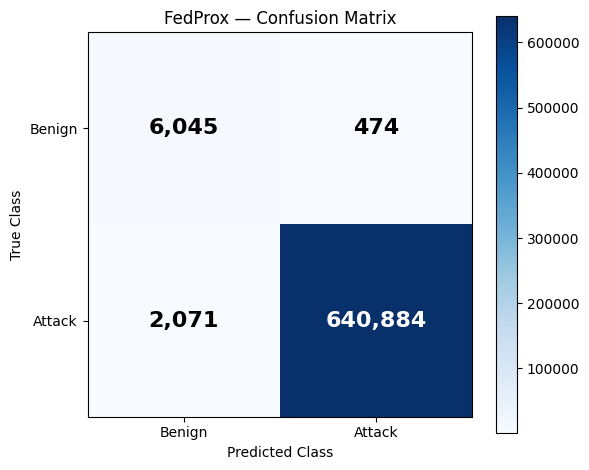

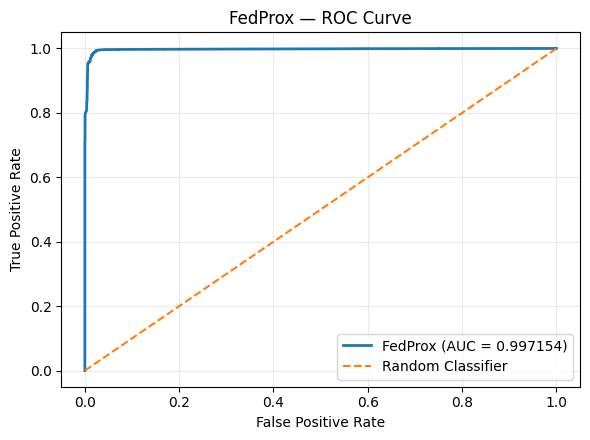

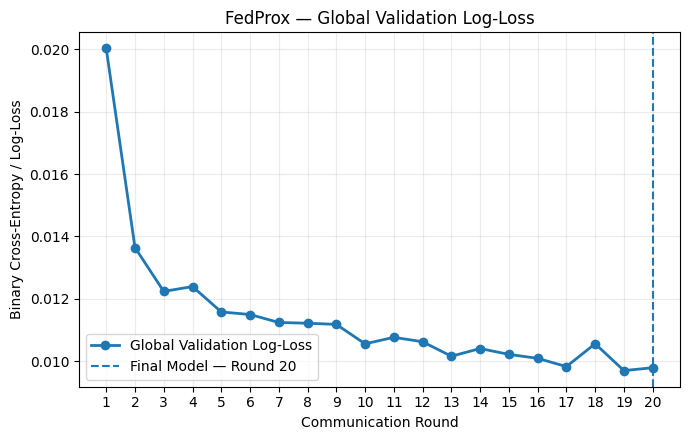


FEDPROX ROUND-20 FINAL TEST RESULTS
Accuracy         : 0.996081
Precision        : 0.999261
Recall           : 0.996779
F1               : 0.998018
Macro F1         : 0.912060
Weighted F1      : 0.996293
Benign Precision : 0.744825
Benign Recall    : 0.927289
Benign F1        : 0.826102
ROC-AUC          : 0.997154
PR-AUC           : 0.999970

Confusion Matrix:
TN = 6045
FP = 474
FN = 2071
TP = 640884

Classification Report:


,precision,recall,f1-score,support
Benign,0.744825,0.927289,0.826102,6519.000000
Attack,0.999261,0.996779,0.998018,642955.000000
accuracy,0.996081,0.996081,0.996081,0.996081
macro avg,0.872043,0.962034,0.912060,649474.000000
weighted avg,0.996707,0.996081,0.996293,649474.000000



FEDPROX COMPLETE
Final model       : Round 20
Communication     : 20 rounds
Proximal mu       : 0.01

Saved:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedProx/result/final_metrics.csv
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedProx/result/predictions.npz
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedProx/figures/FedProx_Confusion_Matrix.png
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedProx/figures/FedProx_ROC_Curve.png
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedProx/figures/FedProx_Global_Validation_Log_Loss.png

✅ No retraining performed.
✅ Round-20 FedProx model evaluated.
✅ FedAvg untouched.
✅ FedSGD untouched.
✅ FedProx experiment complete.


9249

In [ ]:
# ================================================================
# CELL 11: FEDPROX ROUND-20 FINAL TEST + FIGURES
# ================================================================
#
# FINAL MODEL:
#   FedProx global model AFTER communication Round 20
#
# OUTPUT:
#   - Final test metrics
#   - Classification report
#   - Confusion Matrix
#   - ROC Curve
#   - Global Validation Log-Loss Curve
#
# IMPORTANT:
#   - NO TRAINING
#   - Saved predictions reused on re-run
#   - FedAvg and FedSGD untouched
#
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ----------------------------------------------------------------
# 2. Safety checks
# ----------------------------------------------------------------

if not os.path.exists(
    FEDPROX_FINAL_MODEL_FILE
):
    raise FileNotFoundError(
        "FedProx Round-20 final model not found:\n" + FEDPROX_FINAL_MODEL_FILE
    )


if not os.path.exists(
    FEDPROX_ROUND_HISTORY_FILE
):
    raise FileNotFoundError(
        "FedProx round history not found."
    )


# ----------------------------------------------------------------
# 3. Verify Round 20
# ----------------------------------------------------------------

round_history = pd.read_csv(
    FEDPROX_ROUND_HISTORY_FILE
)


final_recorded_round = int(
    round_history["Round"].max()
)


if final_recorded_round != 20:

    raise RuntimeError(
        "FedProx history does not end at Round 20."
    )


print(
    "✅ Verified final communication round: 20"
)


# ----------------------------------------------------------------
# 4. Temporary local test cache
# ----------------------------------------------------------------

LOCAL_TEST_CACHE_DIR = (
    "/content/fl_binary_test_cache"
)

os.makedirs(
    LOCAL_TEST_CACHE_DIR,
    exist_ok=True
)


LOCAL_X_TEST_FILE = os.path.join(
    LOCAL_TEST_CACHE_DIR,
    "X_test_scaled_float32.npy"
)

LOCAL_Y_TEST_FILE = os.path.join(
    LOCAL_TEST_CACHE_DIR,
    "y_test_int8.npy"
)


def copy_if_missing(
    source,
    destination
):

    if not os.path.exists(
        destination
    ):

        print(
            "Copying temporarily to Colab:",
            os.path.basename(source)
        )

        shutil.copy2(
            source,
            destination
        )


copy_if_missing(
    X_TEST_FILE,
    LOCAL_X_TEST_FILE
)

copy_if_missing(
    Y_TEST_FILE,
    LOCAL_Y_TEST_FILE
)


# ----------------------------------------------------------------
# 5. Load test data
# ----------------------------------------------------------------

X_test_fedprox = np.load(
    LOCAL_X_TEST_FILE,
    mmap_mode="r"
)

y_test_fedprox = np.load(
    LOCAL_Y_TEST_FILE,
    mmap_mode="r"
)


y_true = np.asarray(
    y_test_fedprox,
    dtype=np.uint8
)


print(
    "Test samples:",
    f"{len(y_true):,}"
)


# ================================================================
# 6. FINAL TEST INFERENCE
# ================================================================

if os.path.exists(
    FEDPROX_FINAL_PREDICTIONS_FILE
):

    print(
        "\n✅ Saved FedProx predictions found."
    )

    print(
        "✅ Test inference skipped."
    )


    saved_predictions = np.load(
        FEDPROX_FINAL_PREDICTIONS_FILE
    )


    y_pred = saved_predictions[
        "y_pred"
    ].astype(
        np.uint8,
        copy=False
    )


    y_prob = saved_predictions[
        "y_prob"
    ].astype(
        np.float32,
        copy=False
    )


else:

    print(
        "\nRunning FedProx ROUND-20 "
        "final test inference..."
    )


    final_model = (
        tf.keras.models.load_model(
            FEDPROX_FINAL_MODEL_FILE,
            compile=False
        )
    )


    if final_model.count_params() != 60097:

        raise RuntimeError(
            "Unexpected FedProx model architecture."
        )


    TEST_BATCH_SIZE = 4096

    probability_parts = []


    for start in range(
        0,
        len(y_true),
        TEST_BATCH_SIZE
    ):

        end = min(
            start + TEST_BATCH_SIZE,
            len(y_true)
        )


        batch_x = np.asarray(
            X_test_fedprox[
                start:end
            ],
            dtype=np.float32
        )


        batch_x = batch_x[
            ...,
            np.newaxis
        ]


        batch_probability = (
            final_model(
                batch_x,
                training=False
            )
            .numpy()
            .reshape(-1)
        )


        probability_parts.append(
            batch_probability.astype(
                np.float32,
                copy=False
            )
        )


    y_prob = np.concatenate(
        probability_parts
    )


    y_pred = (
        y_prob >= 0.5
    ).astype(
        np.uint8
    )


    if len(y_pred) != len(y_true):

        raise RuntimeError(
            "Prediction count mismatch."
        )


    np.savez_compressed(
        FEDPROX_FINAL_PREDICTIONS_FILE,
        y_pred=y_pred,
        y_prob=y_prob
    )


    print(
        "✅ FedProx Round-20 predictions saved."
    )


    del final_model
    del probability_parts

    tf.keras.backend.clear_session()

    gc.collect()


# ================================================================
# 7. CONFUSION MATRIX VALUES
# ================================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)


tn, fp, fn, tp = cm.ravel()


# ================================================================
# 8. FINAL METRICS
# ================================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)


attack_precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


benign_precision = precision_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_recall = recall_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)


specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)


roc_auc = roc_auc_score(
    y_true,
    y_prob
)


pr_auc = average_precision_score(
    y_true,
    y_prob
)


# ================================================================
# 9. SAVE FINAL METRICS
# ================================================================

final_metrics = {

    "Model":
        FEDPROX_EXPERIMENT_NAME,

    "Final_Round":
        20,

    "Mu":
        FEDPROX_MU,

    "Accuracy":
        float(accuracy),

    "Precision":
        float(attack_precision),

    "Recall":
        float(attack_recall),

    "F1":
        float(attack_f1),

    "Macro_F1":
        float(macro_f1),

    "Weighted_F1":
        float(weighted_f1),

    "Benign_Precision":
        float(benign_precision),

    "Benign_Recall":
        float(benign_recall),

    "Benign_F1":
        float(benign_f1),

    "Specificity":
        float(specificity),

    "ROC_AUC":
        float(roc_auc),

    "PR_AUC":
        float(pr_auc),

    "TN":
        int(tn),

    "FP":
        int(fp),

    "FN":
        int(fn),

    "TP":
        int(tp),

    "Test_Samples":
        int(len(y_true))
}


metrics_df = pd.DataFrame(
    [final_metrics]
)


metrics_df.to_csv(
    FEDPROX_FINAL_METRICS_FILE,
    index=False
)


# ================================================================
# 10. CLASSIFICATION REPORT
# ================================================================

report = classification_report(
    y_true,
    y_pred,
    labels=[0, 1],
    target_names=[
        "Benign",
        "Attack"
    ],
    output_dict=True,
    zero_division=0
)


report_df = pd.DataFrame(
    report
).transpose()


# ================================================================
# 11. CONFUSION MATRIX FIGURE
# ================================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)


image = ax.imshow(
    cm,
    cmap="Blues"
)


ax.set_xticks(
    [0, 1],
    labels=[
        "Benign",
        "Attack"
    ]
)


ax.set_yticks(
    [0, 1],
    labels=[
        "Benign",
        "Attack"
    ]
)


ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)


ax.set_title(
    "FedProx — Confusion Matrix"
)


threshold = cm.max() / 2


for i in range(2):

    for j in range(2):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


fig.colorbar(
    image,
    ax=ax
)


plt.tight_layout()


plt.savefig(
    FEDPROX_CM_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ================================================================
# 12. ROC CURVE
# ================================================================

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)


fig, ax = plt.subplots(
    figsize=(6, 4.5)
)


ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"FedProx "
        f"(AUC = {roc_auc:.6f})"
    )
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)


ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)


ax.set_title(
    "FedProx — ROC Curve"
)


ax.legend(
    loc="lower right"
)


ax.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    FEDPROX_ROC_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ================================================================
# 13. VALIDATION LOG-LOSS CURVE
# ================================================================

fig, ax = plt.subplots(
    figsize=(7, 4.5)
)


ax.plot(
    round_history[
        "Round"
    ],
    round_history[
        "Val_Loss"
    ],
    marker="o",
    linewidth=2,
    label="Global Validation Log-Loss"
)


ax.axvline(
    20,
    linestyle="--",
    linewidth=1.5,
    label="Final Model — Round 20"
)


ax.set_xlabel(
    "Communication Round"
)

ax.set_ylabel(
    "Binary Cross-Entropy / Log-Loss"
)


ax.set_title(
    "FedProx — Global Validation Log-Loss"
)


ax.set_xticks(
    round_history[
        "Round"
    ]
)


ax.legend()


ax.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    FEDPROX_LOSS_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# ================================================================
# 14. DISPLAY RESULTS
# ================================================================

print(
    "\n" + "=" * 72
)

print(
    "FEDPROX ROUND-20 FINAL TEST RESULTS"
)

print(
    "=" * 72
)


print(
    f"Accuracy         : {accuracy:.6f}"
)

print(
    f"Precision        : {attack_precision:.6f}"
)

print(
    f"Recall           : {attack_recall:.6f}"
)

print(
    f"F1               : {attack_f1:.6f}"
)

print(
    f"Macro F1         : {macro_f1:.6f}"
)

print(
    f"Weighted F1      : {weighted_f1:.6f}"
)

print(
    f"Benign Precision : {benign_precision:.6f}"
)

print(
    f"Benign Recall    : {benign_recall:.6f}"
)

print(
    f"Benign F1        : {benign_f1:.6f}"
)

print(
    f"ROC-AUC          : {roc_auc:.6f}"
)

print(
    f"PR-AUC           : {pr_auc:.6f}"
)


print(
    "\nConfusion Matrix:"
)

print(
    f"TN = {tn}"
)

print(
    f"FP = {fp}"
)

print(
    f"FN = {fn}"
)

print(
    f"TP = {tp}"
)


print(
    "\nClassification Report:"
)


display(
    report_df
)


print(
    "\n" + "=" * 72
)

print(
    "FEDPROX COMPLETE"
)

print(
    "=" * 72
)


print(
    "Final model       : Round 20"
)

print(
    "Communication     : 20 rounds"
)

print(
    f"Proximal mu       : {FEDPROX_MU}"
)


print(
    "\nSaved:"
)

print(
    FEDPROX_FINAL_METRICS_FILE
)

print(
    FEDPROX_FINAL_PREDICTIONS_FILE
)

print(
    FEDPROX_CM_FILE
)

print(
    FEDPROX_ROC_FILE
)

print(
    FEDPROX_LOSS_FILE
)


print(
    "\n✅ No retraining performed."
)

print(
    "✅ Round-20 FedProx model evaluated."
)

print(
    "✅ FedAvg untouched."
)

print(
    "✅ FedSGD untouched."
)

print(
    "✅ FedProx experiment complete."
)

print(
    "=" * 72
)


gc.collect()


FedAdam — Adaptive Federated Optimization

Cell 12 — FedAdam Experiment Setup

In [ ]:
# =====================================
# CELL 12: FEDADAM EXPERIMENT SETUP
# =====================================

# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import json
import numpy as np


# ----------------------------------------------------------------
# 2. Required shared variables
# ----------------------------------------------------------------

required_variables = [
    "PROJECT_ROOT",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "X_TEST_FILE",
    "Y_TEST_FILE",
    "client_indices",
    "validation_indices",
    "NUM_CLIENTS",
    "NUM_FEATURES",
    "RANDOM_SEED",
    "build_federated_binary_model"
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n" + "\n".join(missing_variables) + "\n\nRun the shared setup / "
          "partition / model cells first."
    )


# ----------------------------------------------------------------
# 3. Experiment definition
# ----------------------------------------------------------------

FEDADAM_EXPERIMENT_NAME = (
    "FedAdam_ServerLR0.01_"
    "IID_5Clients_"
    "CNN-LSTM-ResNet_Binary"
)


FEDADAM_MAX_ROUNDS = 20

FEDADAM_LOCAL_EPOCHS = 1

FEDADAM_BATCH_SIZE = 2048


# ----------------------------------------------------------------
# 4. Client optimizer
# ----------------------------------------------------------------

FEDADAM_CLIENT_LEARNING_RATE = 0.001


# ----------------------------------------------------------------
# 5. FedAdam SERVER configuration
#
# Previous run:
#   Server LR = 0.001
#
# Current validation-selected sensitivity run:
#   Server LR = 0.01
#
# Test set was NOT used for this decision.
# ----------------------------------------------------------------

FEDADAM_SERVER_LEARNING_RATE = 0.01

FEDADAM_BETA1 = 0.9

FEDADAM_BETA2 = 0.99

FEDADAM_TAU = 0.001


# ----------------------------------------------------------------
# 6. New separate FedAdam experiment folder
#
# IMPORTANT:
#   Old LR=0.001 experiment:
#
#       federated_binary/FedAdam
#
#   remains completely untouched.
#
# ----------------------------------------------------------------

FEDADAM_ROOT = os.path.join(
    PROJECT_ROOT,
    "federated_binary",
    "FedAdam_ServerLR_0.01"
)


# ----------------------------------------------------------------
# 7. Experiment directories
# ----------------------------------------------------------------

FEDADAM_CHECKPOINT_DIR = os.path.join(
    FEDADAM_ROOT,
    "checkpoint"
)


FEDADAM_MODEL_DIR = os.path.join(
    FEDADAM_ROOT,
    "model"
)


FEDADAM_RESULT_DIR = os.path.join(
    FEDADAM_ROOT,
    "result"
)


FEDADAM_FIGURE_DIR = os.path.join(
    FEDADAM_ROOT,
    "figures"
)


for directory in [
    FEDADAM_ROOT,
    FEDADAM_CHECKPOINT_DIR,
    FEDADAM_MODEL_DIR,
    FEDADAM_RESULT_DIR,
    FEDADAM_FIGURE_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


# ----------------------------------------------------------------
# 8. Configuration file
# ----------------------------------------------------------------

FEDADAM_CONFIG_FILE = os.path.join(
    FEDADAM_ROOT,
    "config.json"
)


# ----------------------------------------------------------------
# 9. Resume files
#
# FedAdam resume requires:
#   - global model
#   - server first moment m
#   - server second moment v
#   - completed round number
# ----------------------------------------------------------------

FEDADAM_LATEST_MODEL_FILE = os.path.join(
    FEDADAM_CHECKPOINT_DIR,
    "latest_completed_round.keras"
)


FEDADAM_SERVER_STATE_FILE = os.path.join(
    FEDADAM_CHECKPOINT_DIR,
    "server_adam_state.npz"
)


FEDADAM_STATE_FILE = os.path.join(
    FEDADAM_CHECKPOINT_DIR,
    "state.json"
)


# ----------------------------------------------------------------
# 10. Round history
# ----------------------------------------------------------------

FEDADAM_ROUND_HISTORY_FILE = os.path.join(
    FEDADAM_RESULT_DIR,
    "round_history.csv"
)


# ----------------------------------------------------------------
# 11. Final model
# ----------------------------------------------------------------

FEDADAM_FINAL_MODEL_FILE = os.path.join(
    FEDADAM_MODEL_DIR,
    "FedAdam_ServerLR0.01_Round20_Final.keras"
)


# ----------------------------------------------------------------
# 12. Final result files
# ----------------------------------------------------------------

FEDADAM_FINAL_METRICS_FILE = os.path.join(
    FEDADAM_RESULT_DIR,
    "final_metrics.csv"
)


FEDADAM_FINAL_PREDICTIONS_FILE = os.path.join(
    FEDADAM_RESULT_DIR,
    "predictions.npz"
)


# ----------------------------------------------------------------
# 13. Figure paths
# ----------------------------------------------------------------

FEDADAM_CM_FILE = os.path.join(
    FEDADAM_FIGURE_DIR,
    "FedAdam_Confusion_Matrix.png"
)


FEDADAM_ROC_FILE = os.path.join(
    FEDADAM_FIGURE_DIR,
    "FedAdam_ROC_Curve.png"
)


FEDADAM_LOSS_FILE = os.path.join(
    FEDADAM_FIGURE_DIR,
    "FedAdam_Global_Validation_Log_Loss.png"
)


# ----------------------------------------------------------------
# 14. SAME 5-client sizes
# ----------------------------------------------------------------

fedadam_client_sizes = np.array(
    [
        len(indices)
        for indices in client_indices
    ],
    dtype=np.int64
)


if len(
    fedadam_client_sizes
) != 5:

    raise RuntimeError(
        "Expected exactly 5 clients."
    )


# ----------------------------------------------------------------
# 15. SAME sample-size client weights
# ----------------------------------------------------------------

FEDADAM_CLIENT_WEIGHTS = (
    fedadam_client_sizes / fedadam_client_sizes.sum()
)


if not np.isclose(
    FEDADAM_CLIENT_WEIGHTS.sum(),
    1.0
):

    raise RuntimeError(
        "FedAdam client weights "
        "do not sum to 1."
    )


# ----------------------------------------------------------------
# 16. Experiment configuration record
# ----------------------------------------------------------------

FEDADAM_CONFIG = {

    "experiment_name":
        FEDADAM_EXPERIMENT_NAME,

    "algorithm":
        "FedAdam",

    "experiment_type":
        "validation-selected server LR sensitivity",

    "architecture":
        "CNN-LSTM-ResNet",

    "partition":
        "IID",

    "num_clients":
        5,

    "communication_rounds":
        FEDADAM_MAX_ROUNDS,

    "local_epochs":
        FEDADAM_LOCAL_EPOCHS,

    "batch_size":
        FEDADAM_BATCH_SIZE,

    "client_optimizer":
        "Adam",

    "client_learning_rate":
        FEDADAM_CLIENT_LEARNING_RATE,

    "server_optimizer":
        "FedAdam",

    "server_learning_rate":
        FEDADAM_SERVER_LEARNING_RATE,

    "server_beta1":
        FEDADAM_BETA1,

    "server_beta2":
        FEDADAM_BETA2,

    "server_tau":
        FEDADAM_TAU,

    "aggregation":
        "sample-size-weighted client model deltas",

    "server_state":
        "first and second moment vectors",

    "final_model":
        "Round 20 global model",

    "hyperparameter_selection":
        "validation only",

    "test_used_for_tuning":
        False,

    "random_seed":
        int(RANDOM_SEED)
}


# ----------------------------------------------------------------
# 17. Save OR verify configuration
# ----------------------------------------------------------------

if os.path.exists(
    FEDADAM_CONFIG_FILE
):

    with open(
        FEDADAM_CONFIG_FILE,
        "r"
    ) as file:

        existing_config = json.load(
            file
        )


    if existing_config != FEDADAM_CONFIG:

        raise RuntimeError(
            "Existing FedAdam LR=0.01 configuration "
            "does not match this experiment."
        )


    print(
        "✅ Existing FedAdam LR=0.01 "
        "configuration verified."
    )


else:

    with open(
        FEDADAM_CONFIG_FILE,
        "w"
    ) as file:

        json.dump(
            FEDADAM_CONFIG,
            file,
            indent=2
        )


    print(
        "✅ Fresh FedAdam LR=0.01 "
        "configuration created."
    )


# ----------------------------------------------------------------
# 18. Check whether this LR=0.01 experiment is already complete
# ----------------------------------------------------------------

FEDADAM_ALREADY_COMPLETE = os.path.exists(
    FEDADAM_FINAL_MODEL_FILE
)


# ----------------------------------------------------------------
# 19. Display experiment
# ----------------------------------------------------------------

print(
    "\n" + "=" * 72
)

print(
    "FEDADAM EXPERIMENT READY"
)

print(
    "=" * 72
)


print(
    "Architecture         : CNN-LSTM-ResNet"
)

print(
    "Algorithm            : FedAdam"
)

print(
    "Partition            : IID"
)

print(
    "Clients              : 5"
)

print(
    "Communication rounds : 20"
)

print(
    "Local epochs         : 1"
)

print(
    "Batch size           : 2048"
)


print(
    "\nCLIENT OPTIMIZER"
)

print(
    "Optimizer            : Adam"
)

print(
    "Learning rate        :",
    FEDADAM_CLIENT_LEARNING_RATE
)


print(
    "\nSERVER OPTIMIZER"
)

print(
    "Optimizer            : FedAdam"
)

print(
    "Previous server LR   : 0.001"
)

print(
    "Current server LR    :",
    FEDADAM_SERVER_LEARNING_RATE
)

print(
    "Beta1                :",
    FEDADAM_BETA1
)

print(
    "Beta2                :",
    FEDADAM_BETA2
)

print(
    "Tau                  :",
    FEDADAM_TAU
)

print(
    "Final model policy   : ROUND 20"
)


# ----------------------------------------------------------------
# 20. Client information
# ----------------------------------------------------------------

print(
    "\nClient distribution:"
)


for client_id, (
    sample_count,
    client_weight
) in enumerate(
    zip(
        fedadam_client_sizes,
        FEDADAM_CLIENT_WEIGHTS
    ),
    start=1
):

    print(
        f"Client {client_id}: "
        f"{sample_count:,} samples | "
        f"{client_weight * 100:.6f}%"
    )


# ----------------------------------------------------------------
# 21. Validation information
# ----------------------------------------------------------------

print(
    "\nValidation samples:",
    f"{len(validation_indices):,}"
)


# ----------------------------------------------------------------
# 22. Existing-result status
# ----------------------------------------------------------------

if FEDADAM_ALREADY_COMPLETE:

    print(
        "\n✅ Existing FedAdam LR=0.01 "
        "Round-20 final model found."
    )

    print(
        "✅ Training should be skipped."
    )

else:

    print(
        "\nℹ️ FedAdam LR=0.01 final model "
        "not found yet."
    )

    print(
        "Training can start from Round 1."
    )


# ----------------------------------------------------------------
# 23. Safety summary
# ----------------------------------------------------------------

print(
    "\n✅ Same exact 5-client partition reused."
)

print(
    "✅ Same CNN-LSTM-ResNet architecture."
)

print(
    "✅ Same 20-round communication budget."
)

print(
    "✅ Same 1-local-epoch budget."
)

print(
    "✅ Same batch size = 2048."
)

print(
    "✅ Client Adam LR remains 0.001."
)

print(
    "✅ Server LR updated: 0.001 → 0.01."
)

print(
    "✅ Previous FedAdam LR=0.001 files untouched."
)

print(
    "✅ FedAvg untouched."
)

print(
    "✅ FedSGD untouched."
)

print(
    "✅ FedProx untouched."
)

print(
    "✅ Test set untouched."
)

print(
    "✅ No training performed."
)

print(
    "=" * 72
)


✅ Existing FedAdam LR=0.01 configuration verified.

FEDADAM EXPERIMENT READY
Architecture         : CNN-LSTM-ResNet
Algorithm            : FedAdam
Partition            : IID
Clients              : 5
Communication rounds : 20
Local epochs         : 1
Batch size           : 2048

CLIENT OPTIMIZER
Optimizer            : Adam
Learning rate        : 0.001

SERVER OPTIMIZER
Optimizer            : FedAdam
Previous server LR   : 0.001
Current server LR    : 0.01
Beta1                : 0.9
Beta2                : 0.99
Tau                  : 0.001
Final model policy   : ROUND 20

Client distribution:
Client 1: 467,621 samples | 20.000026%
Client 2: 467,621 samples | 20.000026%
Client 3: 467,620 samples | 19.999983%
Client 4: 467,620 samples | 19.999983%
Client 5: 467,620 samples | 19.999983%

Validation samples: 259,790

✅ Existing FedAdam LR=0.01 Round-20 final model found.
✅ Training should be skipped.

✅ Same exact 5-client partition reused.
✅ Same CNN-LSTM-ResNet architecture.
✅ Same 20-round

Cell 13 — FedAdam Training: 20 Communication Rounds

In [ ]:
# ==============================
# CELL 13: FEDADAM TRAINING
# ==============================

# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import time
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    log_loss
)

from tensorflow.keras import mixed_precision


# ----------------------------------------------------------------
# 2. Automatic CPU / GPU runtime configuration
# ----------------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(gpus) > 0

if GPU_AVAILABLE:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass

    mixed_precision.set_global_policy("mixed_float16")
    DEVICE_TYPE = "GPU"
    DEVICE_NAME = gpus[0].name

else:
    mixed_precision.set_global_policy("float32")
    DEVICE_TYPE = "CPU"
    DEVICE_NAME = "CPU"

print("Runtime device :", DEVICE_TYPE)
print("Device name    :", DEVICE_NAME)
print("Precision      :", mixed_precision.global_policy().name)

# ----------------------------------------------------------------
# 3. Safety check: this must be the LR=0.01 experiment
# ----------------------------------------------------------------

if not np.isclose(
    FEDADAM_SERVER_LEARNING_RATE,
    0.01
):

    raise RuntimeError(
        "Unexpected FedAdam server learning rate.\n"
        f"Current value = {FEDADAM_SERVER_LEARNING_RATE}\n"
        "Expected value = 0.01"
    )


print(
    "FedAdam server LR:",
    FEDADAM_SERVER_LEARNING_RATE
)


# ----------------------------------------------------------------
# 4. Skip completely if Round-20 final model already exists
# ----------------------------------------------------------------

if os.path.exists(
    FEDADAM_FINAL_MODEL_FILE
):

    print(
        "\n" + "=" * 72
    )

    print(
        "✅ FEDADAM LR=0.01 TRAINING ALREADY COMPLETE"
    )

    print(
        "=" * 72
    )

    print(
        "Round-20 final model already exists:"
    )

    print(
        FEDADAM_FINAL_MODEL_FILE
    )

    print(
        "\n✅ No retraining performed."
    )


else:

    # ============================================================
    # 5. Temporary LOCAL Colab cache
    # ============================================================

    LOCAL_CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )


    os.makedirs(
        LOCAL_CACHE_DIR,
        exist_ok=True
    )


    LOCAL_X_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "X_train_scaled_float32.npy"
    )


    LOCAL_Y_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "y_train_int8.npy"
    )


    def copy_if_missing(
        source,
        destination
    ):

        if not os.path.exists(
            destination
        ):

            print(
                "Copying temporarily to Colab:",
                os.path.basename(
                    source
                )
            )


            shutil.copy2(
                source,
                destination
            )


    copy_if_missing(
        X_TRAIN_FILE,
        LOCAL_X_TRAIN_FILE
    )


    copy_if_missing(
        Y_TRAIN_FILE,
        LOCAL_Y_TRAIN_FILE
    )


    # ============================================================
    # 6. Memory-map training arrays
    # ============================================================

    X_train_fedadam = np.load(
        LOCAL_X_TRAIN_FILE,
        mmap_mode="r"
    )


    y_train_fedadam = np.load(
        LOCAL_Y_TRAIN_FILE,
        mmap_mode="r"
    )


    print(
        "\nTraining shape:",
        X_train_fedadam.shape
    )


    # ============================================================
    # 7. SAME global validation set
    # ============================================================

    X_val_fedadam = np.asarray(
        X_train_fedadam[
            validation_indices
        ],
        dtype=np.float32
    )


    y_val_fedadam = np.asarray(
        y_train_fedadam[
            validation_indices
        ],
        dtype=np.uint8
    )


    X_val_fedadam = (
        X_val_fedadam[
            ...,
            np.newaxis
        ]
    )


    print(
        "Validation samples:",
        f"{len(y_val_fedadam):,}"
    )


    print(
        "Validation benign:",
        f"{np.sum(y_val_fedadam == 0):,}"
    )


    print(
        "Validation attack:",
        f"{np.sum(y_val_fedadam == 1):,}"
    )


    # ============================================================
    # 8. Atomic JSON save
    # ============================================================

    def save_json_atomic(
        data,
        final_path
    ):

        temp_path = (
            final_path + ".tmp"
        )


        with open(
            temp_path,
            "w"
        ) as file:

            json.dump(
                data,
                file,
                indent=2
            )


        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 9. Atomic CSV save
    # ============================================================

    def save_csv_atomic(
        dataframe,
        final_path
    ):

        temp_path = (
            final_path + ".tmp.csv"
        )


        dataframe.to_csv(
            temp_path,
            index=False
        )


        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 10. Atomic model save
    # ============================================================

    def save_model_atomic(
        model,
        final_path
    ):

        temp_path = os.path.join(
            os.path.dirname(
                final_path
            ),
            "temporary_model.keras"
        )


        if os.path.exists(
            temp_path
        ):

            os.remove(
                temp_path
            )


        model.save(
            temp_path,
            overwrite=True
        )


        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 11. Server-state save
    # ============================================================

    def save_server_state_atomic(
        first_moment,
        second_moment,
        final_path
    ):

        temp_path = os.path.join(
            os.path.dirname(
                final_path
            ),
            "temporary_server_state.npz"
        )


        state_dictionary = {}


        for i, value in enumerate(
            first_moment
        ):

            state_dictionary[
                f"m_{i:03d}"
            ] = np.asarray(
                value,
                dtype=np.float32
            )


        for i, value in enumerate(
            second_moment
        ):

            state_dictionary[
                f"v_{i:03d}"
            ] = np.asarray(
                value,
                dtype=np.float32
            )


        np.savez_compressed(
            temp_path,
            **state_dictionary
        )


        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 12. Server-state load
    # ============================================================

    def load_server_state(
        state_path,
        number_of_weights
    ):

        saved_state = np.load(
            state_path
        )


        first_moment = []

        second_moment = []


        for i in range(
            number_of_weights
        ):

            m_key = (
                f"m_{i:03d}"
            )

            v_key = (
                f"v_{i:03d}"
            )


            if (
                m_key not in saved_state or v_key not in saved_state
            ):

                saved_state.close()

                raise RuntimeError(
                    "FedAdam server state "
                    "is incomplete."
                )


            first_moment.append(
                saved_state[
                    m_key
                ].astype(
                    np.float32,
                    copy=False
                )
            )


            second_moment.append(
                saved_state[
                    v_key
                ].astype(
                    np.float32,
                    copy=False
                )
            )


        saved_state.close()


        return (
            first_moment,
            second_moment
        )


    # ============================================================
    # 13. Versioned checkpoint paths
    #
    # This is safer than overwriting the same checkpoint while
    # saving. state.json acts as the committed checkpoint pointer.
    # ============================================================

    def checkpoint_model_path(
        round_number
    ):

        return os.path.join(
            FEDADAM_CHECKPOINT_DIR,
            f"global_round_{round_number:02d}.keras"
        )


    def checkpoint_server_path(
        round_number
    ):

        return os.path.join(
            FEDADAM_CHECKPOINT_DIR,
            f"server_state_round_{round_number:02d}.npz"
        )


    # ============================================================
    # 14. Remove UNCOMMITTED checkpoint artifacts
    #
    # Only files not referenced by committed state.json are removed.
    # ============================================================

    def cleanup_uncommitted_checkpoints(
        committed_round
    ):

        if not os.path.exists(
            FEDADAM_CHECKPOINT_DIR
        ):

            return


        committed_model = None

        committed_server = None


        if committed_round > 0:

            committed_model = (
                checkpoint_model_path(
                    committed_round
                )
            )

            committed_server = (
                checkpoint_server_path(
                    committed_round
                )
            )


        for file_name in os.listdir(
            FEDADAM_CHECKPOINT_DIR
        ):

            file_path = os.path.join(
                FEDADAM_CHECKPOINT_DIR,
                file_name
            )


            if file_path in [
                committed_model,
                committed_server,
                FEDADAM_STATE_FILE
            ]:

                continue


            if (
                file_name.startswith(
                    "global_round_"
                ) or file_name.startswith(
                    "server_state_round_"
                ) or file_name.startswith(
                    "temporary_"
                )
            ):

                if os.path.isfile(
                    file_path
                ):

                    os.remove(
                        file_path
                    )


    # ============================================================
    # 15. Determine RESUME state
    # ============================================================

    resume_available = os.path.exists(
        FEDADAM_STATE_FILE
    )


    if resume_available:

        with open(
            FEDADAM_STATE_FILE,
            "r"
        ) as file:

            committed_state = json.load(
                file
            )


        last_completed_round = int(
            committed_state[
                "last_completed_round"
            ]
        )


        committed_model_file = (
            checkpoint_model_path(
                last_completed_round
            )
        )


        committed_server_file = (
            checkpoint_server_path(
                last_completed_round
            )
        )


        if not os.path.exists(
            committed_model_file
        ):

            raise RuntimeError(
                "Committed FedAdam model "
                "checkpoint is missing."
            )


        if not os.path.exists(
            committed_server_file
        ):

            raise RuntimeError(
                "Committed FedAdam server-state "
                "checkpoint is missing."
            )


        cleanup_uncommitted_checkpoints(
            last_completed_round
        )


    else:

        last_completed_round = 0


        cleanup_uncommitted_checkpoints(
            0
        )


    # ============================================================
    # 16. RESUME OR FRESH START
    # ============================================================

    if (
        last_completed_round > 0
    ):

        global_model = (
            tf.keras.models.load_model(
                checkpoint_model_path(
                    last_completed_round
                ),
                compile=False
            )
        )


        current_weights = (
            global_model.get_weights()
        )


        (
            server_m,
            server_v
        ) = load_server_state(
            checkpoint_server_path(
                last_completed_round
            ),
            len(
                current_weights
            )
        )


        del current_weights


        START_ROUND = (
            last_completed_round + 1
        )


        if os.path.exists(
            FEDADAM_ROUND_HISTORY_FILE
        ):

            fedadam_history_df = (
                pd.read_csv(
                    FEDADAM_ROUND_HISTORY_FILE
                )
            )


            # Remove any history row from an
            # uncommitted interrupted round.

            fedadam_history_df = (
                fedadam_history_df[
                    fedadam_history_df[
                        "Round"
                    ] <= last_completed_round
                ]
                .copy()
            )


            save_csv_atomic(
                fedadam_history_df,
                FEDADAM_ROUND_HISTORY_FILE
            )


        else:

            raise RuntimeError(
                "Committed FedAdam checkpoint "
                "exists but round_history.csv "
                "is missing."
            )


        print(
            "\n" + "=" * 72
        )


        print(
            "🔄 RESUMING FEDADAM"
        )


        print(
            "=" * 72
        )


        print(
            "Last committed round:",
            last_completed_round
        )


        print(
            "Starting from round:",
            START_ROUND
        )


        print(
            "✅ Global model restored."
        )


        print(
            "✅ Server first moment restored."
        )


        print(
            "✅ Server second moment restored."
        )


    else:

        # --------------------------------------------------------
        # Fresh controlled initialization
        # --------------------------------------------------------

        tf.keras.backend.clear_session()


        mixed_precision.set_global_policy(
    "mixed_float16" if GPU_AVAILABLE else "float32"
)


        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )


        global_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        START_ROUND = 1


        initial_weights = (
            global_model.get_weights()
        )


        # --------------------------------------------------------
        # FedAdam first moment:
        # m_0 = 0
        # --------------------------------------------------------

        server_m = [

            np.zeros_like(
                weight,
                dtype=np.float32
            )

            for weight
            in initial_weights

        ]


        # --------------------------------------------------------
        # FedAdam second moment:
        #
        # v_0 = tau^2
        #
        # This avoids a zero second-moment initialization.
        # --------------------------------------------------------

        initial_second_moment = float(
            FEDADAM_TAU ** 2
        )


        server_v = [

            np.full_like(
                weight,
                initial_second_moment,
                dtype=np.float32
            )

            for weight
            in initial_weights

        ]


        del initial_weights


        fedadam_history_df = pd.DataFrame(
            columns=[
                "Round",
                "Train_BCE_Loss",
                "Mean_Client_Delta_Norm",
                "Aggregated_Delta_Norm",
                "Server_Update_Norm",
                "Val_Loss",
                "Val_Accuracy",
                "Val_Macro_F1",
                "Val_Benign_Recall",
                "Round_Time_sec"
            ]
        )


        print(
            "\n" + "=" * 72
        )


        print(
            "🟢 STARTING NEW FEDADAM LR=0.01 TRAINING"
        )


        print(
            "=" * 72
        )


        print(
            "Server LR:",
            FEDADAM_SERVER_LEARNING_RATE
        )


        print(
            "Initial second moment:",
            f"tau² = {initial_second_moment:.8f}"
        )


    # ============================================================
    # 17. Architecture safety check
    # ============================================================

    if global_model.count_params() != 60097:

        raise RuntimeError(
            "Unexpected global-model parameter count: "
            f"{global_model.count_params():,}"
        )


    print(
        "Global model parameters:",
        f"{global_model.count_params():,}"
    )


    # ============================================================
    # 18. Reusable local model
    # ============================================================

    local_model = (
        build_federated_binary_model(
            compile_model=False
        )
    )


    if local_model.count_params() != 60097:

        raise RuntimeError(
            "Local model architecture mismatch."
        )


    # ============================================================
    # 19. Local Adam optimizer
    # ============================================================

    local_optimizer = (
        tf.keras.optimizers.Adam(
            learning_rate=
                FEDADAM_CLIENT_LEARNING_RATE
        )
    )


    local_optimizer.build(
        local_model.trainable_variables
    )


    # ============================================================
    # 20. Reset local Adam state for EVERY client
    # ============================================================

    def reset_local_optimizer():

        for variable in (
            local_optimizer.variables
        ):

            variable_name = (
                variable.name.lower()
            )


            if (
                "learning_rate"
                in variable_name
            ):

                continue


            variable.assign(
                tf.zeros_like(
                    variable
                )
            )


    # ============================================================
    # 21. Binary loss
    # ============================================================

    bce_loss_function = (
        tf.keras.losses.BinaryCrossentropy()
    )


    FEDADAM_LOSS_SCALE = 1024.0


    # ============================================================
    # 22. Local training step
    # ============================================================

    @tf.function(
        input_signature=[
            tf.TensorSpec(
                shape=(
                    None,
                    NUM_FEATURES,
                    1
                ),
                dtype=tf.float32
            ),

            tf.TensorSpec(
                shape=(None,),
                dtype=tf.float32
            )
        ],
        reduce_retracing=True
    )
    def local_train_step(
        batch_x,
        batch_y
    ):

        batch_y = tf.reshape(
            batch_y,
            (-1, 1)
        )


        with tf.GradientTape() as tape:

            probabilities = local_model(
                batch_x,
                training=True
            )


            bce_loss = (
                bce_loss_function(
                    batch_y,
                    probabilities
                )
            )


            scaled_loss = (
                tf.cast(
                    bce_loss,
                    tf.float32
                ) * FEDADAM_LOSS_SCALE
            )


        scaled_gradients = tape.gradient(
            scaled_loss,
            local_model.trainable_variables
        )


        gradients = []


        for (
            gradient,
            variable
        ) in zip(
            scaled_gradients,
            local_model.trainable_variables
        ):

            if gradient is None:

                gradient = tf.zeros_like(
                    variable,
                    dtype=tf.float32
                )

            else:

                gradient = (
                    tf.cast(
                        gradient,
                        tf.float32
                    ) / FEDADAM_LOSS_SCALE
                )


            gradients.append(
                gradient
            )


        local_optimizer.apply_gradients(
            zip(
                gradients,
                local_model.trainable_variables
            )
        )


        return tf.cast(
            bce_loss,
            tf.float32
        )


    # ============================================================
    # 23. Global validation
    # ============================================================

    VALIDATION_BATCH_SIZE = 4096


    def evaluate_global_validation():

        probability_parts = []


        for start in range(
            0,
            len(
                y_val_fedadam
            ),
            VALIDATION_BATCH_SIZE
        ):

            end = min(
                start + VALIDATION_BATCH_SIZE,
                len(
                    y_val_fedadam
                )
            )


            batch_x = tf.convert_to_tensor(
                X_val_fedadam[
                    start:end
                ],
                dtype=tf.float32
            )


            batch_probability = (
                global_model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
            )


            probability_parts.append(
                batch_probability
            )


        probabilities = np.concatenate(
            probability_parts
        ).astype(
            np.float32,
            copy=False
        )


        predictions = (
            probabilities >= 0.5
        ).astype(
            np.uint8
        )


        val_loss = log_loss(
            y_val_fedadam,
            probabilities,
            labels=[0, 1]
        )


        val_accuracy = accuracy_score(
            y_val_fedadam,
            predictions
        )


        val_macro_f1 = f1_score(
            y_val_fedadam,
            predictions,
            average="macro",
            zero_division=0
        )


        val_benign_recall = recall_score(
            y_val_fedadam,
            predictions,
            pos_label=0,
            zero_division=0
        )


        return (
            float(
                val_loss
            ),
            float(
                val_accuracy
            ),
            float(
                val_macro_f1
            ),
            float(
                val_benign_recall
            )
        )


    # ============================================================
    # 24. L2 norm utility
    # ============================================================

    def list_l2_norm(
        arrays
    ):

        squared_sum = 0.0


        for array in arrays:

            array_float = np.asarray(
                array,
                dtype=np.float32
            )


            squared_sum += float(
                np.sum(
                    np.square(
                        array_float
                    ),
                    dtype=np.float64
                )
            )


        return float(
            np.sqrt(
                squared_sum
            )
        )


    # ================================================================
    # 25. FEDADAM COMMUNICATION ROUNDS
    # ================================================================

    for round_number in range(
        START_ROUND,
        FEDADAM_MAX_ROUNDS + 1
    ):

        round_start_time = (
            time.time()
        )


        print(
            "\n" + "=" * 72
        )


        print(
            f"FEDADAM ROUND "
            f"{round_number}/"
            f"{FEDADAM_MAX_ROUNDS}"
        )


        print(
            "=" * 72
        )


        # --------------------------------------------------------
        # Global model at START of round
        # --------------------------------------------------------

        global_weights = [

            weight.astype(
                np.float32,
                copy=True
            )

            for weight
            in global_model.get_weights()

        ]


        # --------------------------------------------------------
        # Sample-size-weighted mean client delta
        # --------------------------------------------------------

        aggregated_delta = [

            np.zeros_like(
                weight,
                dtype=np.float32
            )

            for weight
            in global_weights

        ]


        round_bce_sum = 0.0

        round_sample_sum = 0

        client_delta_norms = []


        # ========================================================
        # 26. CLIENT LOOP
        # ========================================================

        for client_id in range(
            NUM_CLIENTS
        ):

            client_start_time = (
                time.time()
            )


            original_indices = (
                client_indices[
                    client_id
                ]
            )


            client_sample_count = int(
                len(
                    original_indices
                )
            )


            client_weight = float(
                FEDADAM_CLIENT_WEIGHTS[
                    client_id
                ]
            )


            print(
                f"\nClient "
                f"{client_id + 1}/"
                f"{NUM_CLIENTS}"
            )


            print(
                "Samples:",
                f"{client_sample_count:,}"
            )


            print(
                "Aggregation weight:",
                f"{client_weight * 100:.6f}%"
            )


            # ====================================================
            # 27. Deterministic client shuffle
            # ====================================================

            local_rng = (
                np.random.default_rng(
                    RANDOM_SEED + round_number * 100 + client_id
                )
            )


            shuffled_indices = np.array(
                original_indices,
                copy=True
            )


            local_rng.shuffle(
                shuffled_indices
            )


            # ====================================================
            # 28. Load ONE client into RAM
            # ====================================================

            X_client = np.asarray(
                X_train_fedadam[
                    shuffled_indices
                ],
                dtype=np.float32
            )


            y_client = np.asarray(
                y_train_fedadam[
                    shuffled_indices
                ],
                dtype=np.float32
            )


            X_client = (
                X_client[
                    ...,
                    np.newaxis
                ]
            )


            # ====================================================
            # 29. Client starts from CURRENT global weights
            # ====================================================

            local_model.set_weights(
                global_weights
            )


            reset_local_optimizer()


            # ====================================================
            # 30. ONE LOCAL EPOCH
            # ====================================================

            client_bce_sum = 0.0


            for local_epoch in range(
                FEDADAM_LOCAL_EPOCHS
            ):

                for batch_start in range(
                    0,
                    client_sample_count,
                    FEDADAM_BATCH_SIZE
                ):

                    batch_end = min(
                        batch_start + FEDADAM_BATCH_SIZE,
                        client_sample_count
                    )


                    actual_batch_size = (
                        batch_end - batch_start
                    )


                    batch_x = (
                        tf.convert_to_tensor(
                            X_client[
                                batch_start:
                                batch_end
                            ],
                            dtype=tf.float32
                        )
                    )


                    batch_y = (
                        tf.convert_to_tensor(
                            y_client[
                                batch_start:
                                batch_end
                            ],
                            dtype=tf.float32
                        )
                    )


                    batch_bce = (
                        local_train_step(
                            batch_x,
                            batch_y
                        )
                    )


                    client_bce_sum += (
                        float(
                            batch_bce.numpy()
                        ) * actual_batch_size
                    )


            # ====================================================
            # 31. Client mean BCE
            # ====================================================

            effective_samples = (
                client_sample_count * FEDADAM_LOCAL_EPOCHS
            )


            client_mean_bce = (
                client_bce_sum / effective_samples
            )


            # ====================================================
            # 32. Client model delta
            #
            # delta_i = local_i - global
            # ====================================================

            local_weights = (
                local_model.get_weights()
            )


            client_delta = [

                (
                    local_weight.astype(
                        np.float32,
                        copy=False
                    ) - global_weight
                )

                for (
                    local_weight,
                    global_weight
                )
                in zip(
                    local_weights,
                    global_weights
                )

            ]


            client_delta_norm = (
                list_l2_norm(
                    client_delta
                )
            )


            client_delta_norms.append(
                client_delta_norm
            )


            # ====================================================
            # 33. Sample-size-weighted aggregation
            # ====================================================

            for weight_index in range(
                len(
                    aggregated_delta
                )
            ):

                aggregated_delta[
                    weight_index
                ] += (

                    client_weight * client_delta[
                        weight_index
                    ]

                )


            round_bce_sum += (
                client_mean_bce * client_sample_count
            )


            round_sample_sum += (
                client_sample_count
            )


            print(
                f"Mean BCE loss : "
                f"{client_mean_bce:.6f}"
            )


            print(
                f"Delta L2 norm : "
                f"{client_delta_norm:.6f}"
            )


            print(
                f"Completed in "
                f"{time.time() - client_start_time:.1f} sec"
            )


            # ====================================================
            # 34. Client cleanup
            # ====================================================

            del shuffled_indices
            del X_client
            del y_client
            del local_weights
            del client_delta

            gc.collect()


        # ========================================================
        # 35. Aggregated delta norm
        # ========================================================

        aggregated_delta_norm = (
            list_l2_norm(
                aggregated_delta
            )
        )


        # ========================================================
        # 36. FEDADAM SERVER UPDATE
        #
        # m_t =
        #   beta1*m_(t-1)
        #   + (1-beta1)*Delta_t
        #
        # v_t =
        #   beta2*v_(t-1)
        #   + (1-beta2)*(Delta_t^2)
        #
        # w_(t+1) =
        #   w_t
        #   + server_lr * m_t /
        #     (sqrt(v_t) + tau)
        #
        # Delta = local - global,
        # therefore direction is PLUS.
        # ========================================================

        server_updates = []

        new_global_weights = []


        for weight_index in range(
            len(
                global_weights
            )
        ):

            delta = (
                aggregated_delta[
                    weight_index
                ]
            )


            # ----------------------------------------------------
            # First moment
            # ----------------------------------------------------

            server_m[
                weight_index
            ] = (

                FEDADAM_BETA1 * server_m[
                    weight_index
                ]
 + (
                    1.0 - FEDADAM_BETA1
                ) * delta

            ).astype(
                np.float32,
                copy=False
            )


            # ----------------------------------------------------
            # Second moment
            # ----------------------------------------------------

            server_v[
                weight_index
            ] = (

                FEDADAM_BETA2 * server_v[
                    weight_index
                ]
 + (
                    1.0 - FEDADAM_BETA2
                ) * np.square(
                    delta
                )

            ).astype(
                np.float32,
                copy=False
            )


            # ----------------------------------------------------
            # Safety: second moment must never be negative
            # ----------------------------------------------------

            server_v[
                weight_index
            ] = np.maximum(
                server_v[
                    weight_index
                ],
                0.0
            )


            # ----------------------------------------------------
            # Adaptive FedAdam update
            # ----------------------------------------------------

            server_update = (

                FEDADAM_SERVER_LEARNING_RATE * server_m[
                    weight_index
                ]
 / (
                    np.sqrt(
                        server_v[
                            weight_index
                        ]
                    ) + FEDADAM_TAU
                )

            ).astype(
                np.float32,
                copy=False
            )


            updated_weight = (

                global_weights[
                    weight_index
                ] + server_update

            ).astype(
                np.float32,
                copy=False
            )


            server_updates.append(
                server_update
            )


            new_global_weights.append(
                updated_weight
            )


        # ========================================================
        # 37. Non-finite safety checks
        # ========================================================

        if not all(
            np.all(
                np.isfinite(
                    weight
                )
            )
            for weight
            in new_global_weights
        ):

            raise FloatingPointError(
                "Non-finite FedAdam global "
                "weights detected."
            )


        if not all(
            np.all(
                np.isfinite(
                    moment
                )
            )
            for moment
            in server_m
        ):

            raise FloatingPointError(
                "Non-finite FedAdam first moment detected."
            )


        if not all(
            np.all(
                np.isfinite(
                    moment
                )
            )
            for moment
            in server_v
        ):

            raise FloatingPointError(
                "Non-finite FedAdam second moment detected."
            )


        # ========================================================
        # 38. Apply server update
        # ========================================================

        global_model.set_weights(
            new_global_weights
        )


        # ========================================================
        # 39. Round statistics
        # ========================================================

        mean_client_delta_norm = float(
            np.mean(
                client_delta_norms
            )
        )


        server_update_norm = (
            list_l2_norm(
                server_updates
            )
        )


        mean_round_bce = (
            round_bce_sum / round_sample_sum
        )


        # ========================================================
        # 40. Global validation
        # ========================================================

        (
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = evaluate_global_validation()


        round_time = (
            time.time() - round_start_time
        )


        print(
            "\nRound training mean:"
        )


        print(
            f"  BCE loss              : "
            f"{mean_round_bce:.6f}"
        )


        print(
            f"  Mean client delta norm: "
            f"{mean_client_delta_norm:.6f}"
        )


        print(
            f"  Aggregated delta norm : "
            f"{aggregated_delta_norm:.6f}"
        )


        print(
            f"  Server update norm    : "
            f"{server_update_norm:.6f}"
        )


        print(
            "\nGlobal validation:"
        )


        print(
            f"  Log-Loss     : "
            f"{val_loss:.6f}"
        )


        print(
            f"  Accuracy     : "
            f"{val_accuracy:.6f}"
        )


        print(
            f"  Macro F1     : "
            f"{val_macro_f1:.6f}"
        )


        print(
            f"  Benign Recall: "
            f"{val_benign_recall:.6f}"
        )


        print(
            f"  Round time   : "
            f"{round_time:.1f} sec"
        )


        # ========================================================
        # 41. Update round history
        # ========================================================

        new_history_row = pd.DataFrame(
            [
                {
                    "Round":
                        int(
                            round_number
                        ),

                    "Train_BCE_Loss":
                        float(
                            mean_round_bce
                        ),

                    "Mean_Client_Delta_Norm":
                        float(
                            mean_client_delta_norm
                        ),

                    "Aggregated_Delta_Norm":
                        float(
                            aggregated_delta_norm
                        ),

                    "Server_Update_Norm":
                        float(
                            server_update_norm
                        ),

                    "Val_Loss":
                        float(
                            val_loss
                        ),

                    "Val_Accuracy":
                        float(
                            val_accuracy
                        ),

                    "Val_Macro_F1":
                        float(
                            val_macro_f1
                        ),

                    "Val_Benign_Recall":
                        float(
                            val_benign_recall
                        ),

                    "Round_Time_sec":
                        float(
                            round_time
                        )
                }
            ]
        )


        if fedadam_history_df.empty:

            fedadam_history_df = (
                new_history_row.copy()
            )

        else:

            # Prevent accidental duplicate row
            fedadam_history_df = (
                fedadam_history_df[
                    fedadam_history_df[
                        "Round"
                    ] != round_number
                ]
            )


            fedadam_history_df = pd.concat(
                [
                    fedadam_history_df,
                    new_history_row
                ],
                ignore_index=True
            )


            fedadam_history_df = (
                fedadam_history_df
                .sort_values(
                    "Round"
                )
                .reset_index(
                    drop=True
                )
            )


        save_csv_atomic(
            fedadam_history_df,
            FEDADAM_ROUND_HISTORY_FILE
        )


        # ========================================================
        # 42. SAFE VERSIONED CHECKPOINT
        #
        # Save NEW checkpoint first.
        # Commit state.json only after BOTH model and m/v exist.
        # Then delete previous round checkpoint.
        # ========================================================

        new_checkpoint_model = (
            checkpoint_model_path(
                round_number
            )
        )


        new_checkpoint_server = (
            checkpoint_server_path(
                round_number
            )
        )


        save_model_atomic(
            global_model,
            new_checkpoint_model
        )


        save_server_state_atomic(
            server_m,
            server_v,
            new_checkpoint_server
        )


        # --------------------------------------------------------
        # Commit the round LAST
        # --------------------------------------------------------

        save_json_atomic(
            {
                "last_completed_round":
                    int(
                        round_number
                    ),

                "server_learning_rate":
                    float(
                        FEDADAM_SERVER_LEARNING_RATE
                    ),

                "second_moment_initialization":
                    "tau_squared"
            },
            FEDADAM_STATE_FILE
        )


        # --------------------------------------------------------
        # New round is now safely committed.
        # Remove older checkpoint files.
        # --------------------------------------------------------

        cleanup_uncommitted_checkpoints(
            round_number
        )


        print(
            f"✅ Round {round_number} "
            "safely committed "
            "(model + m + v)."
        )


        # ========================================================
        # 43. Round cleanup
        # ========================================================

        del global_weights
        del aggregated_delta
        del server_updates
        del new_global_weights

        gc.collect()


    # ================================================================
    # 44. FINALIZATION — ROUND 20 ONLY
    # ================================================================

    print(
        "\n" + "=" * 72
    )


    print(
        "FINALIZING FEDADAM LR=0.01"
    )


    print(
        "=" * 72
    )


    final_recorded_round = int(
        fedadam_history_df[
            "Round"
        ].max()
    )


    if (
        final_recorded_round != FEDADAM_MAX_ROUNDS
    ):

        raise RuntimeError(
            "FedAdam did not reach Round 20."
        )


    # ============================================================
    # 45. Save ROUND-20 global model as final
    # ============================================================

    save_model_atomic(
        global_model,
        FEDADAM_FINAL_MODEL_FILE
    )


    print(
        "✅ ROUND-20 GLOBAL MODEL SAVED AS FINAL."
    )


    # ============================================================
    # 46. Round-20 validation summary
    # ============================================================

    round20_row = (
        fedadam_history_df[
            fedadam_history_df[
                "Round"
            ] == 20
        ]
        .iloc[0]
    )


    print(
        "\nROUND-20 VALIDATION RESULTS"
    )


    print(
        f"Log-Loss     : "
        f"{round20_row['Val_Loss']:.6f}"
    )


    print(
        f"Accuracy     : "
        f"{round20_row['Val_Accuracy']:.6f}"
    )


    print(
        f"Macro F1     : "
        f"{round20_row['Val_Macro_F1']:.6f}"
    )


    print(
        f"Benign Recall: "
        f"{round20_row['Val_Benign_Recall']:.6f}"
    )


    # ============================================================
    # 47. Remove resume-only checkpoint files
    # ============================================================

    if os.path.exists(
        FEDADAM_CHECKPOINT_DIR
    ):

        for file_name in os.listdir(
            FEDADAM_CHECKPOINT_DIR
        ):

            file_path = os.path.join(
                FEDADAM_CHECKPOINT_DIR,
                file_name
            )


            if os.path.isfile(
                file_path
            ):

                os.remove(
                    file_path
                )


    print(
        "\n✅ Temporary resume checkpoints removed."
    )


    print(
        "✅ Round history preserved."
    )


    print(
        "✅ Previous FedAdam LR=0.001 untouched."
    )


    print(
        "✅ FedAvg untouched."
    )


    print(
        "✅ FedSGD untouched."
    )


    print(
        "✅ FedProx untouched."
    )


    print(
        "✅ Test set NOT evaluated."
    )


    print(
        "✅ Final comparison candidate = "
        "FedAdam LR=0.01 Round 20."
    )


    print(
        "\nFinal model:"
    )


    print(
        FEDADAM_FINAL_MODEL_FILE
    )


    print(
        "=" * 72
    )


    # ============================================================
    # 48. Cleanup
    # ============================================================

    del local_model
    del global_model
    del server_m
    del server_v

    tf.keras.backend.clear_session()

    gc.collect()


Runtime device : CPU
Device name    : CPU
Precision      : float32
FedAdam server LR: 0.01

✅ FEDADAM LR=0.01 TRAINING ALREADY COMPLETE
Round-20 final model already exists:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedAdam_ServerLR_0.01/model/FedAdam_ServerLR0.01_Round20_Final.keras

✅ No retraining performed.


Cell 14 — FedAdam Final Test Evaluation + Figures

✅ Verified final communication round: 20
Test samples: 649,474
Test benign: 6,519
Test attack: 642,955

✅ Existing FedAdam predictions found.
✅ Test inference skipped.


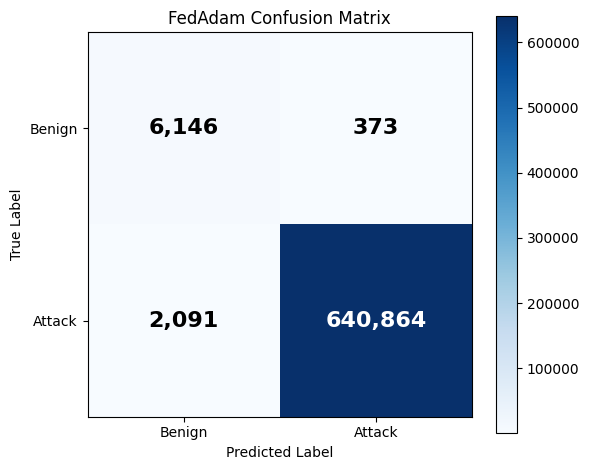

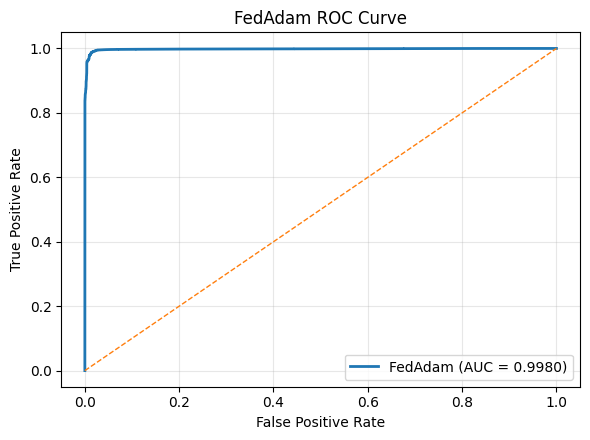

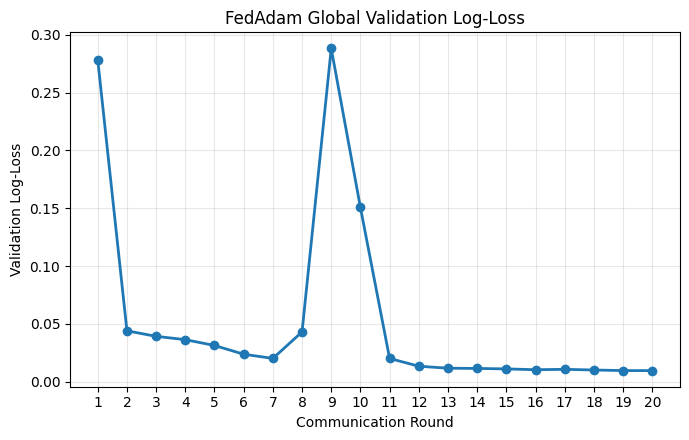


FEDADAM ROUND-20 FINAL TEST RESULTS
Accuracy         : 0.996206
Precision        : 0.999418
Recall           : 0.996748
F1               : 0.998081
Macro F1         : 0.915549
Weighted F1      : 0.996424
Benign Precision : 0.746145
Benign Recall    : 0.942783
Benign F1        : 0.833017
ROC-AUC          : 0.997974
PR-AUC           : 0.999979
Benign PR-AUC    : 0.834319

Confusion Matrix:
TN = 6146
FP = 373
FN = 2091
TP = 640864

Classification Report:

              precision    recall  f1-score        support
Benign         0.746145  0.942783  0.833017    6519.000000
Attack         0.999418  0.996748  0.998081  642955.000000
accuracy       0.996206  0.996206  0.996206       0.996206
macro avg      0.872782  0.969765  0.915549  649474.000000
weighted avg   0.996876  0.996206  0.996424  649474.000000

FEDADAM COMPLETE
Final model       : Round 20
Communication     : 20 rounds
Client LR         : 0.001
Server LR         : 0.01
Beta1             : 0.9
Beta2             : 0.99
Tau        

9022

In [ ]:
# ================================================================
# CELL 14: FEDADAM ROUND-20 FINAL TEST EVALUATION + FIGURES
# ================================================================

# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score
)


# ----------------------------------------------------------------
# 2. Safety checks
# ----------------------------------------------------------------

if not os.path.exists(
    FEDADAM_FINAL_MODEL_FILE
):

    raise FileNotFoundError(
        "FedAdam Round-20 final model not found:\n" + FEDADAM_FINAL_MODEL_FILE
    )


if not os.path.exists(
    FEDADAM_ROUND_HISTORY_FILE
):

    raise FileNotFoundError(
        "FedAdam round history not found:\n" + FEDADAM_ROUND_HISTORY_FILE
    )


# ----------------------------------------------------------------
# 3. Verify final communication round = 20
# ----------------------------------------------------------------

fedadam_history = pd.read_csv(
    FEDADAM_ROUND_HISTORY_FILE
)


if fedadam_history.empty:

    raise RuntimeError(
        "FedAdam round history is empty."
    )


final_round = int(
    fedadam_history[
        "Round"
    ].max()
)


if final_round != 20:

    raise RuntimeError(
        f"Expected final communication round = 20, "
        f"but found {final_round}."
    )


print(
    "✅ Verified final communication round:",
    final_round
)


# ----------------------------------------------------------------
# 4. Temporary local test cache
# ----------------------------------------------------------------

LOCAL_TEST_CACHE = (
    "/content/fl_binary_test_cache"
)


os.makedirs(
    LOCAL_TEST_CACHE,
    exist_ok=True
)


LOCAL_X_TEST_FILE = os.path.join(
    LOCAL_TEST_CACHE,
    "X_test_scaled_float32.npy"
)


LOCAL_Y_TEST_FILE = os.path.join(
    LOCAL_TEST_CACHE,
    "y_test_int8.npy"
)


def copy_if_missing(
    source,
    destination
):

    if not os.path.exists(
        destination
    ):

        print(
            "Copying temporarily to Colab:",
            os.path.basename(
                source
            )
        )


        shutil.copy2(
            source,
            destination
        )


copy_if_missing(
    X_TEST_FILE,
    LOCAL_X_TEST_FILE
)


copy_if_missing(
    Y_TEST_FILE,
    LOCAL_Y_TEST_FILE
)


# ----------------------------------------------------------------
# 5. Load test arrays using memory mapping
# ----------------------------------------------------------------

X_test_fedadam = np.load(
    LOCAL_X_TEST_FILE,
    mmap_mode="r"
)


y_test_fedadam = np.load(
    LOCAL_Y_TEST_FILE,
    mmap_mode="r"
)


y_test_fedadam = np.asarray(
    y_test_fedadam,
    dtype=np.uint8
)


print(
    "Test samples:",
    f"{len(y_test_fedadam):,}"
)


print(
    "Test benign:",
    f"{np.sum(y_test_fedadam == 0):,}"
)


print(
    "Test attack:",
    f"{np.sum(y_test_fedadam == 1):,}"
)


# ----------------------------------------------------------------
# 6. Use existing prediction cache OR run inference
# ----------------------------------------------------------------

if os.path.exists(
    FEDADAM_FINAL_PREDICTIONS_FILE
):

    print(
        "\n✅ Existing FedAdam predictions found."
    )

    print(
        "✅ Test inference skipped."
    )


    saved_predictions = np.load(
        FEDADAM_FINAL_PREDICTIONS_FILE
    )


    y_pred = saved_predictions[
        "y_pred"
    ].astype(
        np.uint8,
        copy=False
    )


    y_prob = saved_predictions[
        "y_prob"
    ].astype(
        np.float32,
        copy=False
    )


    saved_predictions.close()


else:

    print(
        "\nRunning FedAdam ROUND-20 "
        "final test inference..."
    )


    tf.keras.backend.clear_session()


    fedadam_final_model = (
        tf.keras.models.load_model(
            FEDADAM_FINAL_MODEL_FILE,
            compile=False
        )
    )


    if (
        fedadam_final_model.count_params() != 60097
    ):

        raise RuntimeError(
            "FedAdam final model architecture mismatch."
        )


    TEST_BATCH_SIZE = 4096


    probability_parts = []


    for start in range(
        0,
        len(y_test_fedadam),
        TEST_BATCH_SIZE
    ):

        end = min(
            start + TEST_BATCH_SIZE,
            len(y_test_fedadam)
        )


        batch_x = np.asarray(
            X_test_fedadam[
                start:end
            ],
            dtype=np.float32
        )


        batch_x = (
            batch_x[
                ...,
                np.newaxis
            ]
        )


        batch_probability = (
            fedadam_final_model(
                tf.convert_to_tensor(
                    batch_x,
                    dtype=tf.float32
                ),
                training=False
            )
            .numpy()
            .reshape(-1)
            .astype(
                np.float32,
                copy=False
            )
        )


        probability_parts.append(
            batch_probability
        )


        del batch_x
        del batch_probability


    y_prob = np.concatenate(
        probability_parts
    ).astype(
        np.float32,
        copy=False
    )


    del probability_parts


    # ------------------------------------------------------------
    # SAME fixed threshold as other algorithms
    # ------------------------------------------------------------

    y_pred = (
        y_prob >= 0.5
    ).astype(
        np.uint8
    )


    # ------------------------------------------------------------
    # Save compact prediction cache
    # ------------------------------------------------------------

    np.savez_compressed(
        FEDADAM_FINAL_PREDICTIONS_FILE,
        y_pred=y_pred,
        y_prob=y_prob
    )


    print(
        "✅ FedAdam Round-20 predictions saved."
    )


    del fedadam_final_model

    tf.keras.backend.clear_session()

    gc.collect()


# ----------------------------------------------------------------
# 7. Prediction-cache safety check
# ----------------------------------------------------------------

if len(y_pred) != len(
    y_test_fedadam
):

    raise RuntimeError(
        "Prediction length does not match "
        "test-set length."
    )


if len(y_prob) != len(
    y_test_fedadam
):

    raise RuntimeError(
        "Probability length does not match "
        "test-set length."
    )


# ----------------------------------------------------------------
# 8. Confusion matrix
# ----------------------------------------------------------------

cm = confusion_matrix(
    y_test_fedadam,
    y_pred,
    labels=[0, 1]
)


tn, fp, fn, tp = (
    cm.ravel()
)


# ----------------------------------------------------------------
# 9. Main classification metrics
#
# Positive class = Attack = 1
# ----------------------------------------------------------------

accuracy = accuracy_score(
    y_test_fedadam,
    y_pred
)


attack_precision = precision_score(
    y_test_fedadam,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_recall = recall_score(
    y_test_fedadam,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_f1 = f1_score(
    y_test_fedadam,
    y_pred,
    pos_label=1,
    zero_division=0
)


macro_f1 = f1_score(
    y_test_fedadam,
    y_pred,
    average="macro",
    zero_division=0
)


weighted_f1 = f1_score(
    y_test_fedadam,
    y_pred,
    average="weighted",
    zero_division=0
)


# ----------------------------------------------------------------
# 10. Benign-class metrics
# ----------------------------------------------------------------

benign_precision = precision_score(
    y_test_fedadam,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_recall = recall_score(
    y_test_fedadam,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_f1 = f1_score(
    y_test_fedadam,
    y_pred,
    pos_label=0,
    zero_division=0
)


specificity = benign_recall


# ----------------------------------------------------------------
# 11. ROC-AUC + PR-AUC
# ----------------------------------------------------------------

roc_auc = roc_auc_score(
    y_test_fedadam,
    y_prob
)


pr_auc = average_precision_score(
    y_test_fedadam,
    y_prob
)


# Optional minority-class PR-AUC
benign_pr_auc = (
    average_precision_score(
        1 - y_test_fedadam,
        1.0 - y_prob
    )
)


# ----------------------------------------------------------------
# 12. Classification report
# ----------------------------------------------------------------

report_dict = (
    classification_report(
        y_test_fedadam,
        y_pred,
        labels=[0, 1],
        target_names=[
            "Benign",
            "Attack"
        ],
        zero_division=0,
        output_dict=True
    )
)


report_df = pd.DataFrame(
    report_dict
).transpose()


# ----------------------------------------------------------------
# 13. Save final metrics
# ----------------------------------------------------------------

final_metrics = pd.DataFrame(
    [
        {
            "Algorithm":
                "FedAdam",

            "Architecture":
                "CNN-LSTM-ResNet",

            "Partition":
                "IID",

            "Clients":
                5,

            "Communication_Rounds":
                20,

            "Local_Epochs":
                1,

            "Batch_Size":
                2048,

            "Client_Optimizer":
                "Adam",

            "Client_LR":
                FEDADAM_CLIENT_LEARNING_RATE,

            "Server_Optimizer":
                "FedAdam",

            "Server_LR":
                FEDADAM_SERVER_LEARNING_RATE,

            "Beta1":
                FEDADAM_BETA1,

            "Beta2":
                FEDADAM_BETA2,

            "Tau":
                FEDADAM_TAU,

            "Threshold":
                0.5,

            "Accuracy":
                accuracy,

            "Precision":
                attack_precision,

            "Recall":
                attack_recall,

            "F1":
                attack_f1,

            "Macro_F1":
                macro_f1,

            "Weighted_F1":
                weighted_f1,

            "Benign_Precision":
                benign_precision,

            "Benign_Recall":
                benign_recall,

            "Benign_F1":
                benign_f1,

            "Specificity":
                specificity,

            "ROC_AUC":
                roc_auc,

            "PR_AUC":
                pr_auc,

            "Benign_PR_AUC":
                benign_pr_auc,

            "TN":
                int(tn),

            "FP":
                int(fp),

            "FN":
                int(fn),

            "TP":
                int(tp)
        }
    ]
)


final_metrics.to_csv(
    FEDADAM_FINAL_METRICS_FILE,
    index=False
)


# ----------------------------------------------------------------
# 14. CONFUSION MATRIX FIGURE
# ----------------------------------------------------------------

plt.figure(
    figsize=(6, 5)
)


plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)


plt.title(
    "FedAdam Confusion Matrix"
)


plt.colorbar()


tick_marks = np.arange(
    2
)


plt.xticks(
    tick_marks,
    [
        "Benign",
        "Attack"
    ]
)


plt.yticks(
    tick_marks,
    [
        "Benign",
        "Attack"
    ]
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


threshold_cm = (
    cm.max() / 2.0
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if cm[i, j] > threshold_cm
                else "black"
            )
        )


plt.tight_layout()


plt.savefig(
    FEDADAM_CM_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ----------------------------------------------------------------
# 15. ROC CURVE FIGURE
# ----------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_test_fedadam,
    y_prob
)


plt.figure(
    figsize=(6, 4.5)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"FedAdam "
        f"(AUC = {roc_auc:.4f})"
    )
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "FedAdam ROC Curve"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    FEDADAM_ROC_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ----------------------------------------------------------------
# 16. GLOBAL VALIDATION LOG-LOSS FIGURE
# ----------------------------------------------------------------

plt.figure(
    figsize=(7, 4.5)
)


plt.plot(
    fedadam_history[
        "Round"
    ],
    fedadam_history[
        "Val_Loss"
    ],
    marker="o",
    linewidth=2
)


plt.xlabel(
    "Communication Round"
)


plt.ylabel(
    "Validation Log-Loss"
)


plt.title(
    "FedAdam Global Validation Log-Loss"
)


plt.xticks(
    range(
        1,
        21
    )
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    FEDADAM_LOSS_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ----------------------------------------------------------------
# 17. Print final result
# ----------------------------------------------------------------

print(
    "\n" + "=" * 72
)


print(
    "FEDADAM ROUND-20 FINAL TEST RESULTS"
)


print(
    "=" * 72
)


print(
    f"Accuracy         : "
    f"{accuracy:.6f}"
)


print(
    f"Precision        : "
    f"{attack_precision:.6f}"
)


print(
    f"Recall           : "
    f"{attack_recall:.6f}"
)


print(
    f"F1               : "
    f"{attack_f1:.6f}"
)


print(
    f"Macro F1         : "
    f"{macro_f1:.6f}"
)


print(
    f"Weighted F1      : "
    f"{weighted_f1:.6f}"
)


print(
    f"Benign Precision : "
    f"{benign_precision:.6f}"
)


print(
    f"Benign Recall    : "
    f"{benign_recall:.6f}"
)


print(
    f"Benign F1        : "
    f"{benign_f1:.6f}"
)


print(
    f"ROC-AUC          : "
    f"{roc_auc:.6f}"
)


print(
    f"PR-AUC           : "
    f"{pr_auc:.6f}"
)


print(
    f"Benign PR-AUC    : "
    f"{benign_pr_auc:.6f}"
)


print(
    "\nConfusion Matrix:"
)


print(
    f"TN = {tn}"
)


print(
    f"FP = {fp}"
)


print(
    f"FN = {fn}"
)


print(
    f"TP = {tp}"
)


print(
    "\nClassification Report:\n"
)


print(
    report_df.to_string()
)


# ----------------------------------------------------------------
# 18. Saved artifacts
# ----------------------------------------------------------------

print(
    "\n" + "=" * 72
)


print(
    "FEDADAM COMPLETE"
)


print(
    "=" * 72
)


print(
    "Final model       : Round 20"
)


print(
    "Communication     : 20 rounds"
)


print(
    "Client LR         :",
    FEDADAM_CLIENT_LEARNING_RATE
)


print(
    "Server LR         :",
    FEDADAM_SERVER_LEARNING_RATE
)


print(
    "Beta1             :",
    FEDADAM_BETA1
)


print(
    "Beta2             :",
    FEDADAM_BETA2
)


print(
    "Tau               :",
    FEDADAM_TAU
)


print(
    "\nSaved:"
)


print(
    FEDADAM_FINAL_METRICS_FILE
)


print(
    FEDADAM_FINAL_PREDICTIONS_FILE
)


print(
    FEDADAM_CM_FILE
)


print(
    FEDADAM_ROC_FILE
)


print(
    FEDADAM_LOSS_FILE
)


print(
    "\n✅ No retraining performed."
)


print(
    "✅ Round-20 FedAdam model evaluated."
)


print(
    "✅ Threshold fixed at 0.5."
)


print(
    "✅ Previous FedAdam LR=0.001 untouched."
)


print(
    "✅ FedAvg untouched."
)


print(
    "✅ FedSGD untouched."
)


print(
    "✅ FedProx untouched."
)


print(
    "✅ FedAdam experiment complete."
)


print(
    "=" * 72
)


# ----------------------------------------------------------------
# 19. Cleanup
# ----------------------------------------------------------------

del y_pred
del y_prob
del X_test_fedadam
del y_test_fedadam

gc.collect()


Cell 15 — FedDyn Setup

In [ ]:
# ================================================================
# CELL 15: FEDDYN EXPERIMENT SETUP
# ================================================================
#
# FINAL CONTROLLED IID COMPARISON
#
#   Architecture       : CNN-LSTM-ResNet
#   Algorithm          : FedDyn
#   Clients            : 5
#   Partition          : SAME IID
#   Communication      : 20 rounds
#   Local epochs       : 1
#   Batch size         : 2048
#
# LOCAL SOLVER:
#   Adam
#   LR = 0.001
#
# FEDDYN:
#   Base alpha = 0.01
#
# IMPORTANT:
#   - Same exact client partition
#   - Same validation set
#   - Same 20-round budget
#   - Test set NOT used
#   - No training in this cell
#   - Existing experiments untouched
#
# FEDDYN STATE:
#   Each client keeps its own persistent dynamic/history vector.
#
# FINAL EVALUATION MODEL:
#   Round-20 average of client models.
#
# CLOUD MODEL:
#   Used to initialize clients in the next communication round.
#
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import json
import numpy as np


# ----------------------------------------------------------------
# 2. Required shared notebook variables
# ----------------------------------------------------------------

required_variables = [
    "PROJECT_ROOT",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "X_TEST_FILE",
    "Y_TEST_FILE",
    "client_indices",
    "validation_indices",
    "NUM_CLIENTS",
    "NUM_FEATURES",
    "RANDOM_SEED",
    "build_federated_binary_model"
]


missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Missing required variables:\n" + "\n".join(missing_variables) + "\n\nRun the shared setup / "
          "partition / model cells first."
    )


# ----------------------------------------------------------------
# 3. Basic experiment definition
# ----------------------------------------------------------------

FEDDYN_EXPERIMENT_NAME = (
    "FedDyn_IID_5Clients_"
    "CNN-LSTM-ResNet_Binary"
)


FEDDYN_MAX_ROUNDS = 20

FEDDYN_LOCAL_EPOCHS = 1

FEDDYN_BATCH_SIZE = 2048


# ----------------------------------------------------------------
# 4. Local solver
#
# Adam is retained to keep local optimization comparable
# with our existing FedAvg/FedProx experiments.
# ----------------------------------------------------------------

FEDDYN_LOCAL_LEARNING_RATE = 0.001


# ----------------------------------------------------------------
# 5. FedDyn dynamic-regularization coefficient
#
# Base alpha:
#     alpha = 0.01
#
# Client-specific alpha will be adjusted according to
# normalized client sample weight following the FedDyn
# reference implementation.
# ----------------------------------------------------------------

FEDDYN_ALPHA = 0.01


# ----------------------------------------------------------------
# 6. Root folder
# ----------------------------------------------------------------

FEDDYN_ROOT = os.path.join(
    PROJECT_ROOT,
    "federated_binary",
    "FedDyn"
)


# ----------------------------------------------------------------
# 7. Experiment directories
# ----------------------------------------------------------------

FEDDYN_CHECKPOINT_DIR = os.path.join(
    FEDDYN_ROOT,
    "checkpoint"
)


FEDDYN_MODEL_DIR = os.path.join(
    FEDDYN_ROOT,
    "model"
)


FEDDYN_RESULT_DIR = os.path.join(
    FEDDYN_ROOT,
    "result"
)


FEDDYN_FIGURE_DIR = os.path.join(
    FEDDYN_ROOT,
    "figures"
)


for directory in [
    FEDDYN_ROOT,
    FEDDYN_CHECKPOINT_DIR,
    FEDDYN_MODEL_DIR,
    FEDDYN_RESULT_DIR,
    FEDDYN_FIGURE_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


# ----------------------------------------------------------------
# 8. Configuration file
# ----------------------------------------------------------------

FEDDYN_CONFIG_FILE = os.path.join(
    FEDDYN_ROOT,
    "config.json"
)


# ----------------------------------------------------------------
# 9. Resume checkpoint files
#
# FedDyn cannot be resumed correctly using only a model.
#
# We must preserve:
#   1. Cloud model
#   2. Client dynamic/history states
#   3. Completed communication round
# ----------------------------------------------------------------

FEDDYN_LATEST_CLOUD_MODEL_FILE = os.path.join(
    FEDDYN_CHECKPOINT_DIR,
    "latest_cloud_model.keras"
)


FEDDYN_DYNAMIC_STATE_FILE = os.path.join(
    FEDDYN_CHECKPOINT_DIR,
    "client_dynamic_state.npz"
)


FEDDYN_STATE_FILE = os.path.join(
    FEDDYN_CHECKPOINT_DIR,
    "state.json"
)


# ----------------------------------------------------------------
# 10. Round history
# ----------------------------------------------------------------

FEDDYN_ROUND_HISTORY_FILE = os.path.join(
    FEDDYN_RESULT_DIR,
    "round_history.csv"
)


# ----------------------------------------------------------------
# 11. FINAL Round-20 evaluation model
#
# IMPORTANT:
# This is the averaged client model after Round 20.
#
# The cloud model is an internal FedDyn optimization state and
# is not automatically the same as the averaged evaluation model.
# ----------------------------------------------------------------

FEDDYN_FINAL_MODEL_FILE = os.path.join(
    FEDDYN_MODEL_DIR,
    "FedDyn_Round20_Final.keras"
)


# ----------------------------------------------------------------
# 12. Final outputs
# ----------------------------------------------------------------

FEDDYN_FINAL_METRICS_FILE = os.path.join(
    FEDDYN_RESULT_DIR,
    "final_metrics.csv"
)


FEDDYN_FINAL_PREDICTIONS_FILE = os.path.join(
    FEDDYN_RESULT_DIR,
    "predictions.npz"
)


# ----------------------------------------------------------------
# 13. Figure paths
# ----------------------------------------------------------------

FEDDYN_CM_FILE = os.path.join(
    FEDDYN_FIGURE_DIR,
    "FedDyn_Confusion_Matrix.png"
)


FEDDYN_ROC_FILE = os.path.join(
    FEDDYN_FIGURE_DIR,
    "FedDyn_ROC_Curve.png"
)


FEDDYN_LOSS_FILE = os.path.join(
    FEDDYN_FIGURE_DIR,
    "FedDyn_Global_Validation_Log_Loss.png"
)


# ----------------------------------------------------------------
# 14. Verify SAME 5-client partition
# ----------------------------------------------------------------

feddyn_client_sizes = np.array(
    [
        len(indices)
        for indices in client_indices
    ],
    dtype=np.int64
)


if NUM_CLIENTS != 5:

    raise RuntimeError(
        f"Expected NUM_CLIENTS = 5, "
        f"but found {NUM_CLIENTS}."
    )


if len(
    feddyn_client_sizes
) != 5:

    raise RuntimeError(
        "Expected exactly 5 client partitions."
    )


# ----------------------------------------------------------------
# 15. Ordinary sample fractions
#
# p_i = n_i / total_samples
# ----------------------------------------------------------------

FEDDYN_SAMPLE_FRACTIONS = (
    feddyn_client_sizes / feddyn_client_sizes.sum()
)


if not np.isclose(
    FEDDYN_SAMPLE_FRACTIONS.sum(),
    1.0
):

    raise RuntimeError(
        "FedDyn sample fractions do not sum to 1."
    )


# ----------------------------------------------------------------
# 16. FedDyn normalized client weights
#
# Reference implementation:
#
# weight_i =
#     n_i / total_n * NUM_CLIENTS
#
# Therefore mean(weight_i) = 1.
# ----------------------------------------------------------------

FEDDYN_NORMALIZED_CLIENT_WEIGHTS = (
    FEDDYN_SAMPLE_FRACTIONS * NUM_CLIENTS
)


# ----------------------------------------------------------------
# 17. Client-specific effective alpha
#
# Reference FedDyn implementation:
#
# alpha_i = base_alpha / normalized_client_weight_i
#
# Since our five clients are almost exactly equal in size,
# all effective alpha values should be approximately 0.01.
# ----------------------------------------------------------------

FEDDYN_CLIENT_ALPHA = (
    FEDDYN_ALPHA / FEDDYN_NORMALIZED_CLIENT_WEIGHTS
)


# ----------------------------------------------------------------
# 18. Safety checks
# ----------------------------------------------------------------

if np.any(
    FEDDYN_NORMALIZED_CLIENT_WEIGHTS <= 0
):

    raise RuntimeError(
        "Invalid normalized client weight."
    )


if np.any(
    FEDDYN_CLIENT_ALPHA <= 0
):

    raise RuntimeError(
        "Invalid FedDyn client alpha."
    )


# ----------------------------------------------------------------
# 19. Configuration record
# ----------------------------------------------------------------

FEDDYN_CONFIG = {

    "experiment_name":
        FEDDYN_EXPERIMENT_NAME,

    "algorithm":
        "FedDyn",

    "architecture":
        "CNN-LSTM-ResNet",

    "partition":
        "IID",

    "num_clients":
        5,

    "participation":
        "full",

    "communication_rounds":
        FEDDYN_MAX_ROUNDS,

    "local_epochs":
        FEDDYN_LOCAL_EPOCHS,

    "batch_size":
        FEDDYN_BATCH_SIZE,

    "local_solver":
        "Adam",

    "local_learning_rate":
        FEDDYN_LOCAL_LEARNING_RATE,

    "base_alpha":
        FEDDYN_ALPHA,

    "alpha_scaling":
        "alpha_i = alpha / "
        "(client_fraction * num_clients)",

    "dynamic_state_initialization":
        "zero",

    "client_initialization_each_round":
        "current FedDyn cloud model",

    "client_history_update":
        "history_i += "
        "(client_model - previous_cloud_model)",

    "cloud_update":
        "mean(client_models) + "
        "mean(client_dynamic_histories)",

    "evaluation_model":
        "mean client model",

    "final_model":
        "Round 20 mean client model",

    "threshold":
        0.5,

    "random_seed":
        int(RANDOM_SEED)
}


# ----------------------------------------------------------------
# 20. Save OR verify configuration
# ----------------------------------------------------------------

if os.path.exists(
    FEDDYN_CONFIG_FILE
):

    with open(
        FEDDYN_CONFIG_FILE,
        "r"
    ) as file:

        existing_config = json.load(
            file
        )


    if existing_config != FEDDYN_CONFIG:

        raise RuntimeError(
            "Existing FedDyn configuration "
            "does not match this experiment."
        )


    print(
        "✅ Existing FedDyn configuration verified."
    )


else:

    with open(
        FEDDYN_CONFIG_FILE,
        "w"
    ) as file:

        json.dump(
            FEDDYN_CONFIG,
            file,
            indent=2
        )


    print(
        "✅ Fresh FedDyn configuration created."
    )


# ----------------------------------------------------------------
# 21. Check whether FedDyn already completed
# ----------------------------------------------------------------

FEDDYN_ALREADY_COMPLETE = os.path.exists(
    FEDDYN_FINAL_MODEL_FILE
)


# ----------------------------------------------------------------
# 22. Display experiment
# ----------------------------------------------------------------

print(
    "\n" + "=" * 72
)


print(
    "FEDDYN EXPERIMENT READY"
)


print(
    "=" * 72
)


print(
    "Architecture         : CNN-LSTM-ResNet"
)


print(
    "Algorithm            : FedDyn"
)


print(
    "Partition            : IID"
)


print(
    "Clients              : 5"
)


print(
    "Client participation : 100%"
)


print(
    "Communication rounds : 20"
)


print(
    "Local epochs         : 1"
)


print(
    "Batch size           : 2048"
)


print(
    "\nLOCAL SOLVER"
)


print(
    "Optimizer            : Adam"
)


print(
    "Learning rate        :",
    FEDDYN_LOCAL_LEARNING_RATE
)


print(
    "\nFEDDYN"
)


print(
    "Base alpha           :",
    FEDDYN_ALPHA
)


print(
    "Dynamic state init   : zero"
)


print(
    "Final model policy   : ROUND 20"
)


print(
    "Evaluation model     : mean client model"
)


# ----------------------------------------------------------------
# 23. Client information
# ----------------------------------------------------------------

print(
    "\nClient distribution:"
)


for client_id in range(
    NUM_CLIENTS
):

    print(
        f"Client {client_id + 1}: "
        f"{feddyn_client_sizes[client_id]:,} samples | "
        f"fraction = "
        f"{FEDDYN_SAMPLE_FRACTIONS[client_id] * 100:.6f}% | "
        f"normalized weight = "
        f"{FEDDYN_NORMALIZED_CLIENT_WEIGHTS[client_id]:.8f} | "
        f"effective alpha = "
        f"{FEDDYN_CLIENT_ALPHA[client_id]:.8f}"
    )


# ----------------------------------------------------------------
# 24. Validation information
# ----------------------------------------------------------------

print(
    "\nValidation samples:",
    f"{len(validation_indices):,}"
)


# ----------------------------------------------------------------
# 25. Existing status
# ----------------------------------------------------------------

if FEDDYN_ALREADY_COMPLETE:

    print(
        "\n✅ Existing FedDyn Round-20 final model found."
    )


    print(
        "✅ Training should be skipped."
    )


else:

    print(
        "\nℹ️ FedDyn final model not found yet."
    )


    print(
        "Training can start from Round 1."
    )


# ----------------------------------------------------------------
# 26. Explain FedDyn state flow
# ----------------------------------------------------------------

print(
    "\nFedDyn round flow:"
)


print(
    "Cloud model"
)


print(
    "   ↓"
)


print(
    "Dynamic-regularized local training"
)


print(
    "   ↓"
)


print(
    "Client models"
)


print(
    "   ↓"
)


print(
    "Update each client's persistent history"
)


print(
    "   ↓"
)


print(
    "Mean client model = evaluation model"
)


print(
    "   ↓"
)


print(
    "Mean client model + mean history"
)


print(
    "   ↓"
)


print(
    "Next-round cloud model"
)


# ----------------------------------------------------------------
# 27. Safety summary
# ----------------------------------------------------------------

print(
    "\n✅ Same exact 5-client IID partition reused."
)


print(
    "✅ Same CNN-LSTM-ResNet architecture."
)


print(
    "✅ Same 20-round communication budget."
)


print(
    "✅ Same 1-local-epoch budget."
)


print(
    "✅ Same batch size = 2048."
)


print(
    "✅ Threshold remains 0.5."
)


print(
    "✅ Persistent client dynamic state prepared."
)


print(
    "✅ FedAvg untouched."
)


print(
    "✅ FedSGD untouched."
)


print(
    "✅ FedProx untouched."
)


print(
    "✅ FedAdam untouched."
)


print(
    "✅ Test set untouched."
)


print(
    "✅ No training performed."
)


print(
    "=" * 72
)


✅ Existing FedDyn configuration verified.

FEDDYN EXPERIMENT READY
Architecture         : CNN-LSTM-ResNet
Algorithm            : FedDyn
Partition            : IID
Clients              : 5
Client participation : 100%
Communication rounds : 20
Local epochs         : 1
Batch size           : 2048

LOCAL SOLVER
Optimizer            : Adam
Learning rate        : 0.001

FEDDYN
Base alpha           : 0.01
Dynamic state init   : zero
Final model policy   : ROUND 20
Evaluation model     : mean client model

Client distribution:
Client 1: 467,621 samples | fraction = 20.000026% | normalized weight = 1.00000128 | effective alpha = 0.00999999
Client 2: 467,621 samples | fraction = 20.000026% | normalized weight = 1.00000128 | effective alpha = 0.00999999
Client 3: 467,620 samples | fraction = 19.999983% | normalized weight = 0.99999914 | effective alpha = 0.01000001
Client 4: 467,620 samples | fraction = 19.999983% | normalized weight = 0.99999914 | effective alpha = 0.01000001
Client 5: 467,620 s

In [ ]:
# ================================================================
# CELL 16: FEDDYN TRAINING — FINAL RESUME-SAFE VERSION
# ================================================================
#
# EXPERIMENT:
#   Architecture       : CNN-LSTM-ResNet
#   Algorithm          : FedDyn
#   Clients            : 5
#   Participation      : 100%
#   Partition          : SAME IID
#   Communication      : 20 rounds
#   Local epochs       : 1
#   Batch size         : 2048
#
# LOCAL SOLVER:
#   Adam
#   LR = 0.001
#
# FEDDYN:
#   Base alpha = 0.01
#
# LOCAL OBJECTIVE:
#
#   f_i(w)
#   + alpha_i * <w, history_i - cloud>
#   + alpha_i/2 * ||w||^2
#
# CLIENT HISTORY:
#
#   history_i <- history_i + (w_i - cloud)
#
# ROUND AVERAGE:
#
#   avg_model = mean(client models)
#
# CLOUD MODEL:
#
#   cloud <- avg_model + mean(client histories)
#
# FINAL MODEL:
#
#   Round-20 mean client model
#
# IMPORTANT:
#   - Test set NOT used
#   - Resume-safe
#   - One client loaded into RAM at a time
#   - Existing algorithms untouched
#
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import time
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    log_loss
)

from tensorflow.keras import mixed_precision


# ----------------------------------------------------------------
# 2. Automatic CPU / GPU runtime configuration
# ----------------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(gpus) > 0

if GPU_AVAILABLE:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass

    mixed_precision.set_global_policy("mixed_float16")
    DEVICE_TYPE = "GPU"
    DEVICE_NAME = gpus[0].name

else:
    mixed_precision.set_global_policy("float32")
    DEVICE_TYPE = "CPU"
    DEVICE_NAME = "CPU"

print("Runtime device :", DEVICE_TYPE)
print("Device name    :", DEVICE_NAME)
print("Precision      :", mixed_precision.global_policy().name)

# ----------------------------------------------------------------
# 3. FedDyn configuration safety checks
# ----------------------------------------------------------------

if NUM_CLIENTS != 5:

    raise RuntimeError(
        "FedDyn requires exactly 5 clients "
        "for this experiment."
    )


if not np.isclose(
    FEDDYN_ALPHA,
    0.01
):

    raise RuntimeError(
        f"Unexpected FedDyn alpha: {FEDDYN_ALPHA}"
    )


if FEDDYN_MAX_ROUNDS != 20:

    raise RuntimeError(
        "Expected exactly 20 communication rounds."
    )


print(
    "FedDyn base alpha:",
    FEDDYN_ALPHA
)


# ----------------------------------------------------------------
# 4. If final Round-20 model already exists -> SKIP TRAINING
# ----------------------------------------------------------------

if os.path.exists(
    FEDDYN_FINAL_MODEL_FILE
):

    print(
        "\n" + "=" * 72
    )

    print(
        "✅ FEDDYN TRAINING ALREADY COMPLETE"
    )

    print(
        "=" * 72
    )

    print(
        "Round-20 final model already exists:"
    )

    print(
        FEDDYN_FINAL_MODEL_FILE
    )

    print(
        "\n✅ No retraining performed."
    )


else:

    # ============================================================
    # 5. Local Colab cache
    # ============================================================

    LOCAL_CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )


    os.makedirs(
        LOCAL_CACHE_DIR,
        exist_ok=True
    )


    LOCAL_X_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "X_train_scaled_float32.npy"
    )


    LOCAL_Y_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "y_train_int8.npy"
    )


    def copy_if_missing(
        source,
        destination
    ):

        if not os.path.exists(
            destination
        ):

            print(
                "Copying temporarily to Colab:",
                os.path.basename(source)
            )


            shutil.copy2(
                source,
                destination
            )


    copy_if_missing(
        X_TRAIN_FILE,
        LOCAL_X_TRAIN_FILE
    )


    copy_if_missing(
        Y_TRAIN_FILE,
        LOCAL_Y_TRAIN_FILE
    )


    # ============================================================
    # 6. Memory-map training data
    # ============================================================

    X_train_feddyn = np.load(
        LOCAL_X_TRAIN_FILE,
        mmap_mode="r"
    )


    y_train_feddyn = np.load(
        LOCAL_Y_TRAIN_FILE,
        mmap_mode="r"
    )


    print(
        "\nTraining shape:",
        X_train_feddyn.shape
    )


    # ============================================================
    # 7. SAME global validation set
    # ============================================================

    X_val_feddyn = np.asarray(
        X_train_feddyn[
            validation_indices
        ],
        dtype=np.float32
    )


    y_val_feddyn = np.asarray(
        y_train_feddyn[
            validation_indices
        ],
        dtype=np.uint8
    )


    X_val_feddyn = (
        X_val_feddyn[
            ...,
            np.newaxis
        ]
    )


    print(
        "Validation samples:",
        f"{len(y_val_feddyn):,}"
    )


    print(
        "Validation benign:",
        f"{np.sum(y_val_feddyn == 0):,}"
    )


    print(
        "Validation attack:",
        f"{np.sum(y_val_feddyn == 1):,}"
    )


    # ============================================================
    # 8. Atomic JSON save
    # ============================================================

    def save_json_atomic(
        data,
        final_path
    ):

        temp_path = (
            final_path + ".tmp"
        )


        with open(
            temp_path,
            "w"
        ) as file:

            json.dump(
                data,
                file,
                indent=2
            )


        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 9. Atomic CSV save
    # ============================================================

    def save_csv_atomic(
        dataframe,
        final_path
    ):

        temp_path = (
            final_path + ".tmp.csv"
        )


        dataframe.to_csv(
            temp_path,
            index=False
        )


        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 10. Atomic model save
    # ============================================================

    def save_model_atomic(
        model,
        final_path,
        temp_name
    ):

        temp_path = os.path.join(
            os.path.dirname(
                final_path
            ),
            temp_name
        )


        if os.path.exists(
            temp_path
        ):

            os.remove(
                temp_path
            )


        model.save(
            temp_path,
            overwrite=True
        )


        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 11. Versioned checkpoint paths
    # ============================================================

    def cloud_checkpoint_path(
        round_number
    ):

        return os.path.join(
            FEDDYN_CHECKPOINT_DIR,
            f"cloud_round_{round_number:02d}.keras"
        )


    def avg_checkpoint_path(
        round_number
    ):

        return os.path.join(
            FEDDYN_CHECKPOINT_DIR,
            f"avg_round_{round_number:02d}.keras"
        )


    def dynamic_checkpoint_path(
        round_number
    ):

        return os.path.join(
            FEDDYN_CHECKPOINT_DIR,
            f"dynamic_round_{round_number:02d}.npz"
        )


    # ============================================================
    # 12. Save client dynamic/history states
    # ============================================================

    def save_dynamic_state_atomic(
        client_histories,
        final_path
    ):

        temp_path = os.path.join(
            os.path.dirname(
                final_path
            ),
            "temporary_dynamic_state.npz"
        )


        save_dictionary = {}


        for client_id in range(
            NUM_CLIENTS
        ):

            for weight_index in range(
                len(
                    client_histories[
                        client_id
                    ]
                )
            ):

                key = (
                    f"c{client_id:02d}_"
                    f"w{weight_index:03d}"
                )


                save_dictionary[
                    key
                ] = np.asarray(
                    client_histories[
                        client_id
                    ][
                        weight_index
                    ],
                    dtype=np.float32
                )


        np.savez_compressed(
            temp_path,
            **save_dictionary
        )


        os.replace(
            temp_path,
            final_path
        )


    # ============================================================
    # 13. Load client dynamic/history states
    # ============================================================

    def load_dynamic_state(
        state_path,
        number_of_weights
    ):

        saved_state = np.load(
            state_path
        )


        histories = []


        for client_id in range(
            NUM_CLIENTS
        ):

            client_history = []


            for weight_index in range(
                number_of_weights
            ):

                key = (
                    f"c{client_id:02d}_"
                    f"w{weight_index:03d}"
                )


                if key not in saved_state:

                    saved_state.close()

                    raise RuntimeError(
                        "FedDyn dynamic checkpoint "
                        "is incomplete."
                    )


                client_history.append(
                    saved_state[
                        key
                    ].astype(
                        np.float32,
                        copy=True
                    )
                )


            histories.append(
                client_history
            )


        saved_state.close()


        return histories


    # ============================================================
    # 14. Cleanup uncommitted checkpoint files
    # ============================================================

    def cleanup_uncommitted_checkpoints(
        committed_round
    ):

        if not os.path.exists(
            FEDDYN_CHECKPOINT_DIR
        ):

            return


        keep_files = {
            FEDDYN_STATE_FILE
        }


        if committed_round > 0:

            keep_files.add(
                cloud_checkpoint_path(
                    committed_round
                )
            )

            keep_files.add(
                avg_checkpoint_path(
                    committed_round
                )
            )

            keep_files.add(
                dynamic_checkpoint_path(
                    committed_round
                )
            )


        for file_name in os.listdir(
            FEDDYN_CHECKPOINT_DIR
        ):

            file_path = os.path.join(
                FEDDYN_CHECKPOINT_DIR,
                file_name
            )


            if file_path in keep_files:

                continue


            if (
                file_name.startswith(
                    "cloud_round_"
                ) or file_name.startswith(
                    "avg_round_"
                ) or file_name.startswith(
                    "dynamic_round_"
                ) or file_name.startswith(
                    "temporary_"
                )
            ):

                if os.path.isfile(
                    file_path
                ):

                    os.remove(
                        file_path
                    )


    # ============================================================
    # 15. Determine resume state
    # ============================================================

    if os.path.exists(
        FEDDYN_STATE_FILE
    ):

        with open(
            FEDDYN_STATE_FILE,
            "r"
        ) as file:

            committed_state = json.load(
                file
            )


        last_completed_round = int(
            committed_state[
                "last_completed_round"
            ]
        )


        required_resume_files = [
            cloud_checkpoint_path(
                last_completed_round
            ),
            avg_checkpoint_path(
                last_completed_round
            ),
            dynamic_checkpoint_path(
                last_completed_round
            ),
            FEDDYN_ROUND_HISTORY_FILE
        ]


        for path in required_resume_files:

            if not os.path.exists(
                path
            ):

                raise RuntimeError(
                    "FedDyn committed checkpoint "
                    "is incomplete:\n" + path
                )


        cleanup_uncommitted_checkpoints(
            last_completed_round
        )


    else:

        last_completed_round = 0


        cleanup_uncommitted_checkpoints(
            0
        )


    # ============================================================
    # 16. Resume OR fresh start
    # ============================================================

    if last_completed_round > 0:

        tf.keras.backend.clear_session()


        mixed_precision.set_global_policy(
    "mixed_float16" if GPU_AVAILABLE else "float32"
)


        cloud_model = (
            tf.keras.models.load_model(
                cloud_checkpoint_path(
                    last_completed_round
                ),
                compile=False
            )
        )


        evaluation_model = (
            tf.keras.models.load_model(
                avg_checkpoint_path(
                    last_completed_round
                ),
                compile=False
            )
        )


        cloud_weights_for_state = (
            cloud_model.get_weights()
        )


        client_histories = (
            load_dynamic_state(
                dynamic_checkpoint_path(
                    last_completed_round
                ),
                len(
                    cloud_weights_for_state
                )
            )
        )


        del cloud_weights_for_state


        fedDyn_history_df = pd.read_csv(
            FEDDYN_ROUND_HISTORY_FILE
        )


        fedDyn_history_df = (
            fedDyn_history_df[
                fedDyn_history_df[
                    "Round"
                ] <= last_completed_round
            ]
            .copy()
        )


        save_csv_atomic(
            fedDyn_history_df,
            FEDDYN_ROUND_HISTORY_FILE
        )


        START_ROUND = (
            last_completed_round + 1
        )


        print(
            "\n" + "=" * 72
        )


        print(
            "🔄 RESUMING FEDDYN"
        )


        print(
            "=" * 72
        )


        print(
            "Last committed round:",
            last_completed_round
        )


        print(
            "Starting from round:",
            START_ROUND
        )


        print(
            "✅ Cloud model restored."
        )


        print(
            "✅ Mean-client evaluation model restored."
        )


        print(
            "✅ All 5 client histories restored."
        )


    else:

        # --------------------------------------------------------
        # Fresh common random initialization
        # --------------------------------------------------------

        tf.keras.backend.clear_session()


        mixed_precision.set_global_policy(
    "mixed_float16" if GPU_AVAILABLE else "float32"
)


        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )


        cloud_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        evaluation_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        initial_weights = [
            weight.astype(
                np.float32,
                copy=True
            )
            for weight
            in cloud_model.get_weights()
        ]


        evaluation_model.set_weights(
            initial_weights
        )


        # --------------------------------------------------------
        # FedDyn dynamic/history state starts from ZERO
        # for every client.
        # --------------------------------------------------------

        client_histories = []


        for client_id in range(
            NUM_CLIENTS
        ):

            client_histories.append(
                [
                    np.zeros_like(
                        weight,
                        dtype=np.float32
                    )
                    for weight
                    in initial_weights
                ]
            )


        del initial_weights


        START_ROUND = 1


        fedDyn_history_df = pd.DataFrame(
            columns=[
                "Round",
                "Train_BCE_Loss",
                "Train_Dynamic_Reg",
                "Train_Total_Objective",
                "Mean_Client_Delta_Norm",
                "Mean_History_Norm",
                "Cloud_Correction_Norm",
                "Val_Loss",
                "Val_Accuracy",
                "Val_Macro_F1",
                "Val_Benign_Recall",
                "Round_Time_sec"
            ]
        )


        print(
            "\n" + "=" * 72
        )


        print(
            "🟢 STARTING NEW FEDDYN TRAINING"
        )


        print(
            "=" * 72
        )


        print(
            "Base alpha:",
            FEDDYN_ALPHA
        )


        print(
            "Client dynamic states initialized to zero."
        )


    # ============================================================
    # 17. Architecture safety checks
    # ============================================================

    if cloud_model.count_params() != 60097:

        raise RuntimeError(
            "Unexpected cloud-model parameter count: "
            f"{cloud_model.count_params():,}"
        )


    if evaluation_model.count_params() != 60097:

        raise RuntimeError(
            "Unexpected evaluation-model architecture."
        )


    if (
        len(
            cloud_model.weights
        ) != len(
            cloud_model.trainable_weights
        )
    ):

        raise RuntimeError(
            "This implementation expects all "
            "CNN-LSTM-ResNet weights to be trainable."
        )


    print(
        "Model parameters:",
        f"{cloud_model.count_params():,}"
    )


    # ============================================================
    # 18. Reusable local model
    # ============================================================

    local_model = (
        build_federated_binary_model(
            compile_model=False
        )
    )


    if local_model.count_params() != 60097:

        raise RuntimeError(
            "Local FedDyn architecture mismatch."
        )


    # ============================================================
    # 19. Reference variables used by FedDyn objective
    #
    # cloud_reference:
    #     cloud model at BEGINNING of round
    #
    # history_reference:
    #     persistent history of current client
    # ============================================================

    cloud_reference_vars = [
        tf.Variable(
            tf.zeros_like(
                variable,
                dtype=tf.float32
            ),
            trainable=False
        )
        for variable
        in local_model.trainable_variables
    ]


    history_reference_vars = [
        tf.Variable(
            tf.zeros_like(
                variable,
                dtype=tf.float32
            ),
            trainable=False
        )
        for variable
        in local_model.trainable_variables
    ]


    feddyn_alpha_var = tf.Variable(
        FEDDYN_ALPHA,
        dtype=tf.float32,
        trainable=False
    )


    # ============================================================
    # 20. Local Adam optimizer
    # ============================================================

    local_optimizer = (
        tf.keras.optimizers.Adam(
            learning_rate=
                FEDDYN_LOCAL_LEARNING_RATE
        )
    )


    local_optimizer.build(
        local_model.trainable_variables
    )


    # ============================================================
    # 21. Reset local optimizer between clients
    # ============================================================

    def reset_local_optimizer():

        for variable in (
            local_optimizer.variables
        ):

            variable_name = (
                variable.name.lower()
            )


            if (
                "learning_rate"
                in variable_name
            ):

                continue


            variable.assign(
                tf.zeros_like(
                    variable
                )
            )


    # ============================================================
    # 22. BCE
    # ============================================================

    bce_loss_function = (
        tf.keras.losses.BinaryCrossentropy()
    )


    FEDDYN_LOSS_SCALE = 1024.0


    # ============================================================
    # 23. FedDyn local train step
    #
    # Objective:
    #
    # BCE
    # + alpha * <w, history - cloud>
    # + alpha/2 * ||w||²
    # ============================================================

    @tf.function(
        input_signature=[
            tf.TensorSpec(
                shape=(
                    None,
                    NUM_FEATURES,
                    1
                ),
                dtype=tf.float32
            ),

            tf.TensorSpec(
                shape=(None,),
                dtype=tf.float32
            )
        ],
        reduce_retracing=True
    )
    def feddyn_local_train_step(
        batch_x,
        batch_y
    ):

        batch_y = tf.reshape(
            batch_y,
            (-1, 1)
        )


        with tf.GradientTape() as tape:

            probabilities = (
                local_model(
                    batch_x,
                    training=True
                )
            )


            bce_loss = (
                bce_loss_function(
                    batch_y,
                    probabilities
                )
            )


            # ----------------------------------------------------
            # Linear dynamic term:
            #
            # alpha * <w, history - cloud>
            # ----------------------------------------------------

            linear_sum = tf.constant(
                0.0,
                dtype=tf.float32
            )


            # ----------------------------------------------------
            # Quadratic term:
            #
            # alpha/2 * ||w||²
            # ----------------------------------------------------

            squared_sum = tf.constant(
                0.0,
                dtype=tf.float32
            )


            for (
                variable,
                history_reference,
                cloud_reference
            ) in zip(
                local_model.trainable_variables,
                history_reference_vars,
                cloud_reference_vars
            ):

                variable_float = tf.cast(
                    variable,
                    tf.float32
                )


                linear_sum += tf.reduce_sum(
                    variable_float * (
                        history_reference - cloud_reference
                    )
                )


                squared_sum += tf.reduce_sum(
                    tf.square(
                        variable_float
                    )
                )


            linear_penalty = (
                feddyn_alpha_var * linear_sum
            )


            quadratic_penalty = (
                0.5 * feddyn_alpha_var * squared_sum
            )


            dynamic_regularization = (
                linear_penalty + quadratic_penalty
            )


            total_objective = (
                tf.cast(
                    bce_loss,
                    tf.float32
                ) + dynamic_regularization
            )


            scaled_loss = (
                total_objective * FEDDYN_LOSS_SCALE
            )


        scaled_gradients = tape.gradient(
            scaled_loss,
            local_model.trainable_variables
        )


        gradients = []


        for (
            gradient,
            variable
        ) in zip(
            scaled_gradients,
            local_model.trainable_variables
        ):

            if gradient is None:

                gradient = tf.zeros_like(
                    variable,
                    dtype=tf.float32
                )

            else:

                gradient = (
                    tf.cast(
                        gradient,
                        tf.float32
                    ) / FEDDYN_LOSS_SCALE
                )


            gradients.append(
                gradient
            )


        local_optimizer.apply_gradients(
            zip(
                gradients,
                local_model.trainable_variables
            )
        )


        return (
            tf.cast(
                bce_loss,
                tf.float32
            ),
            tf.cast(
                dynamic_regularization,
                tf.float32
            ),
            tf.cast(
                total_objective,
                tf.float32
            )
        )


    # ============================================================
    # 24. Evaluation of ROUND AVERAGE model
    #
    # IMPORTANT:
    # Validation uses mean-client model,
    # NOT the FedDyn cloud state.
    # ============================================================

    VALIDATION_BATCH_SIZE = 4096


    def evaluate_round_average():

        probability_parts = []


        for start in range(
            0,
            len(
                y_val_feddyn
            ),
            VALIDATION_BATCH_SIZE
        ):

            end = min(
                start + VALIDATION_BATCH_SIZE,
                len(
                    y_val_feddyn
                )
            )


            batch_x = tf.convert_to_tensor(
                X_val_feddyn[
                    start:end
                ],
                dtype=tf.float32
            )


            batch_probability = (
                evaluation_model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
            )


            probability_parts.append(
                batch_probability
            )


        probabilities = np.concatenate(
            probability_parts
        ).astype(
            np.float32,
            copy=False
        )


        predictions = (
            probabilities >= 0.5
        ).astype(
            np.uint8
        )


        val_loss = log_loss(
            y_val_feddyn,
            probabilities,
            labels=[0, 1]
        )


        val_accuracy = accuracy_score(
            y_val_feddyn,
            predictions
        )


        val_macro_f1 = f1_score(
            y_val_feddyn,
            predictions,
            average="macro",
            zero_division=0
        )


        val_benign_recall = recall_score(
            y_val_feddyn,
            predictions,
            pos_label=0,
            zero_division=0
        )


        return (
            float(
                val_loss
            ),
            float(
                val_accuracy
            ),
            float(
                val_macro_f1
            ),
            float(
                val_benign_recall
            )
        )


    # ============================================================
    # 25. L2 norm helper
    # ============================================================

    def list_l2_norm(
        arrays
    ):

        squared_sum = 0.0


        for array in arrays:

            array_float = np.asarray(
                array,
                dtype=np.float32
            )


            squared_sum += float(
                np.sum(
                    np.square(
                        array_float
                    ),
                    dtype=np.float64
                )
            )


        return float(
            np.sqrt(
                squared_sum
            )
        )


    # ================================================================
    # 26. COMMUNICATION ROUNDS
    # ================================================================

    for round_number in range(
        START_ROUND,
        FEDDYN_MAX_ROUNDS + 1
    ):

        round_start_time = (
            time.time()
        )


        print(
            "\n" + "=" * 72
        )


        print(
            f"FEDDYN ROUND "
            f"{round_number}/"
            f"{FEDDYN_MAX_ROUNDS}"
        )


        print(
            "=" * 72
        )


        # --------------------------------------------------------
        # Cloud model at START of round
        # --------------------------------------------------------

        cloud_weights = [
            weight.astype(
                np.float32,
                copy=True
            )
            for weight
            in cloud_model.get_weights()
        ]


        if (
            len(
                cloud_weights
            ) != len(
                local_model.trainable_variables
            )
        ):

            raise RuntimeError(
                "Cloud/local variable count mismatch."
            )


        # --------------------------------------------------------
        # Update TensorFlow cloud references once per round
        # --------------------------------------------------------

        for (
            reference_variable,
            weight
        ) in zip(
            cloud_reference_vars,
            cloud_weights
        ):

            reference_variable.assign(
                weight
            )


        # --------------------------------------------------------
        # Accumulator for arithmetic mean of ALL 5 client models
        #
        # Official FedDyn uses mean(client models).
        # --------------------------------------------------------

        client_model_sum = [
            np.zeros_like(
                weight,
                dtype=np.float32
            )
            for weight
            in cloud_weights
        ]


        round_bce_sum = 0.0

        round_dynamic_sum = 0.0

        round_total_sum = 0.0

        round_sample_sum = 0


        client_delta_norms = []


        # ========================================================
        # 27. CLIENT LOOP — full participation
        # ========================================================

        for client_id in range(
            NUM_CLIENTS
        ):

            client_start_time = (
                time.time()
            )


            original_indices = (
                client_indices[
                    client_id
                ]
            )


            client_sample_count = int(
                len(
                    original_indices
                )
            )


            effective_alpha = float(
                FEDDYN_CLIENT_ALPHA[
                    client_id
                ]
            )


            print(
                f"\nClient "
                f"{client_id + 1}/"
                f"{NUM_CLIENTS}"
            )


            print(
                "Samples:",
                f"{client_sample_count:,}"
            )


            print(
                "Effective alpha:",
                f"{effective_alpha:.8f}"
            )


            # ====================================================
            # 28. Deterministic local shuffle
            # ====================================================

            local_rng = np.random.default_rng(
                RANDOM_SEED + round_number * 100 + client_id
            )


            shuffled_indices = np.array(
                original_indices,
                copy=True
            )


            local_rng.shuffle(
                shuffled_indices
            )


            # ====================================================
            # 29. Load ONE client into RAM
            # ====================================================

            X_client = np.asarray(
                X_train_feddyn[
                    shuffled_indices
                ],
                dtype=np.float32
            )


            y_client = np.asarray(
                y_train_feddyn[
                    shuffled_indices
                ],
                dtype=np.float32
            )


            X_client = (
                X_client[
                    ...,
                    np.newaxis
                ]
            )


            # ====================================================
            # 30. Warm start from CURRENT CLOUD MODEL
            # ====================================================

            local_model.set_weights(
                cloud_weights
            )


            reset_local_optimizer()


            feddyn_alpha_var.assign(
                effective_alpha
            )


            # ====================================================
            # 31. Load this client's persistent history
            # into TensorFlow references
            # ====================================================

            for (
                history_reference,
                history_array
            ) in zip(
                history_reference_vars,
                client_histories[
                    client_id
                ]
            ):

                history_reference.assign(
                    history_array
                )


            # ====================================================
            # 32. ONE local epoch
            # ====================================================

            client_bce_sum = 0.0

            client_dynamic_sum = 0.0

            client_total_sum = 0.0


            for local_epoch in range(
                FEDDYN_LOCAL_EPOCHS
            ):

                for batch_start in range(
                    0,
                    client_sample_count,
                    FEDDYN_BATCH_SIZE
                ):

                    batch_end = min(
                        batch_start + FEDDYN_BATCH_SIZE,
                        client_sample_count
                    )


                    actual_batch_size = (
                        batch_end - batch_start
                    )


                    batch_x = tf.convert_to_tensor(
                        X_client[
                            batch_start:
                            batch_end
                        ],
                        dtype=tf.float32
                    )


                    batch_y = tf.convert_to_tensor(
                        y_client[
                            batch_start:
                            batch_end
                        ],
                        dtype=tf.float32
                    )


                    (
                        batch_bce,
                        batch_dynamic,
                        batch_total
                    ) = feddyn_local_train_step(
                        batch_x,
                        batch_y
                    )


                    client_bce_sum += (
                        float(
                            batch_bce.numpy()
                        ) * actual_batch_size
                    )


                    client_dynamic_sum += (
                        float(
                            batch_dynamic.numpy()
                        ) * actual_batch_size
                    )


                    client_total_sum += (
                        float(
                            batch_total.numpy()
                        ) * actual_batch_size
                    )


            # ====================================================
            # 33. Mean local statistics
            # ====================================================

            effective_samples = (
                client_sample_count * FEDDYN_LOCAL_EPOCHS
            )


            client_mean_bce = (
                client_bce_sum / effective_samples
            )


            client_mean_dynamic = (
                client_dynamic_sum / effective_samples
            )


            client_mean_total = (
                client_total_sum / effective_samples
            )


            # ====================================================
            # 34. Current client model
            # ====================================================

            local_weights = [
                weight.astype(
                    np.float32,
                    copy=False
                )
                for weight
                in local_model.get_weights()
            ]


            # ====================================================
            # 35. Client delta relative to STARTING CLOUD
            #
            # delta_i = client_model - cloud_model
            # ====================================================

            client_delta = [
                local_weight - cloud_weight

                for (
                    local_weight,
                    cloud_weight
                )
                in zip(
                    local_weights,
                    cloud_weights
                )
            ]


            client_delta_norm = (
                list_l2_norm(
                    client_delta
                )
            )


            client_delta_norms.append(
                client_delta_norm
            )


            # ====================================================
            # 36. FedDyn HISTORY UPDATE
            #
            # history_i <-
            #     history_i
            #     + client_model
            #     - cloud_model
            # ====================================================

            for weight_index in range(
                len(
                    cloud_weights
                )
            ):

                client_histories[
                    client_id
                ][
                    weight_index
                ] += client_delta[
                    weight_index
                ]


            # ====================================================
            # 37. Accumulate client model for UNWEIGHTED mean
            # ====================================================

            for weight_index in range(
                len(
                    cloud_weights
                )
            ):

                client_model_sum[
                    weight_index
                ] += local_weights[
                    weight_index
                ]


            # ----------------------------------------------------
            # Round statistics
            # ----------------------------------------------------

            round_bce_sum += (
                client_mean_bce * client_sample_count
            )


            round_dynamic_sum += (
                client_mean_dynamic * client_sample_count
            )


            round_total_sum += (
                client_mean_total * client_sample_count
            )


            round_sample_sum += (
                client_sample_count
            )


            print(
                f"Mean BCE loss       : "
                f"{client_mean_bce:.6f}"
            )


            print(
                f"Mean dynamic reg    : "
                f"{client_mean_dynamic:.6f}"
            )


            print(
                f"Mean total objective: "
                f"{client_mean_total:.6f}"
            )


            print(
                f"Client delta norm   : "
                f"{client_delta_norm:.6f}"
            )


            print(
                f"Completed in "
                f"{time.time() - client_start_time:.1f} sec"
            )


            # ====================================================
            # 38. Client cleanup
            # ====================================================

            del shuffled_indices
            del X_client
            del y_client
            del local_weights
            del client_delta

            gc.collect()


        # ========================================================
        # 39. ROUND MEAN CLIENT MODEL
        #
        # Full participation:
        #
        # avg = arithmetic mean of all 5 client models
        # ========================================================

        avg_weights = [
            (
                weight_sum / float(
                    NUM_CLIENTS
                )
            ).astype(
                np.float32,
                copy=False
            )
            for weight_sum
            in client_model_sum
        ]


        # ========================================================
        # 40. Mean client history
        # ========================================================

        mean_history = []


        for weight_index in range(
            len(
                cloud_weights
            )
        ):

            history_sum = np.zeros_like(
                cloud_weights[
                    weight_index
                ],
                dtype=np.float32
            )


            for client_id in range(
                NUM_CLIENTS
            ):

                history_sum += (
                    client_histories[
                        client_id
                    ][
                        weight_index
                    ]
                )


            mean_history.append(
                (
                    history_sum / float(
                        NUM_CLIENTS
                    )
                ).astype(
                    np.float32,
                    copy=False
                )
            )


        # ========================================================
        # 41. FedDyn CLOUD UPDATE
        #
        # cloud =
        #     mean(client models)
        #     +
        #     mean(client histories)
        # ========================================================

        new_cloud_weights = [
            (
                avg_weight + history_weight
            ).astype(
                np.float32,
                copy=False
            )

            for (
                avg_weight,
                history_weight
            ) in zip(
                avg_weights,
                mean_history
            )
        ]


        # ========================================================
        # 42. Non-finite safety
        # ========================================================

        if not all(
            np.all(
                np.isfinite(
                    weight
                )
            )
            for weight
            in avg_weights
        ):

            raise FloatingPointError(
                "Non-finite FedDyn average model detected."
            )


        if not all(
            np.all(
                np.isfinite(
                    weight
                )
            )
            for weight
            in new_cloud_weights
        ):

            raise FloatingPointError(
                "Non-finite FedDyn cloud model detected."
            )


        # ========================================================
        # 43. Update models
        #
        # evaluation_model = mean client model
        # cloud_model      = corrected cloud model
        # ========================================================

        evaluation_model.set_weights(
            avg_weights
        )


        cloud_model.set_weights(
            new_cloud_weights
        )


        # ========================================================
        # 44. Round norms
        # ========================================================

        mean_client_delta_norm = float(
            np.mean(
                client_delta_norms
            )
        )


        history_norms = [
            list_l2_norm(
                client_histories[
                    client_id
                ]
            )
            for client_id
            in range(
                NUM_CLIENTS
            )
        ]


        mean_history_norm = float(
            np.mean(
                history_norms
            )
        )


        cloud_correction_norm = (
            list_l2_norm(
                mean_history
            )
        )


        mean_round_bce = (
            round_bce_sum / round_sample_sum
        )


        mean_round_dynamic = (
            round_dynamic_sum / round_sample_sum
        )


        mean_round_total = (
            round_total_sum / round_sample_sum
        )


        # ========================================================
        # 45. Validate MEAN CLIENT MODEL
        # ========================================================

        (
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = evaluate_round_average()


        round_time = (
            time.time() - round_start_time
        )


        print(
            "\nRound training mean:"
        )


        print(
            f"  BCE loss              : "
            f"{mean_round_bce:.6f}"
        )


        print(
            f"  Dynamic regularizer   : "
            f"{mean_round_dynamic:.6f}"
        )


        print(
            f"  Total objective       : "
            f"{mean_round_total:.6f}"
        )


        print(
            f"  Mean client delta norm: "
            f"{mean_client_delta_norm:.6f}"
        )


        print(
            f"  Mean history norm     : "
            f"{mean_history_norm:.6f}"
        )


        print(
            f"  Cloud correction norm : "
            f"{cloud_correction_norm:.6f}"
        )


        print(
            "\nGlobal validation "
            "(mean client model):"
        )


        print(
            f"  Log-Loss     : "
            f"{val_loss:.6f}"
        )


        print(
            f"  Accuracy     : "
            f"{val_accuracy:.6f}"
        )


        print(
            f"  Macro F1     : "
            f"{val_macro_f1:.6f}"
        )


        print(
            f"  Benign Recall: "
            f"{val_benign_recall:.6f}"
        )


        print(
            f"  Round time   : "
            f"{round_time:.1f} sec"
        )


        # ========================================================
        # 46. Save round history
        # ========================================================

        new_history_row = pd.DataFrame(
            [
                {
                    "Round":
                        int(
                            round_number
                        ),

                    "Train_BCE_Loss":
                        float(
                            mean_round_bce
                        ),

                    "Train_Dynamic_Reg":
                        float(
                            mean_round_dynamic
                        ),

                    "Train_Total_Objective":
                        float(
                            mean_round_total
                        ),

                    "Mean_Client_Delta_Norm":
                        float(
                            mean_client_delta_norm
                        ),

                    "Mean_History_Norm":
                        float(
                            mean_history_norm
                        ),

                    "Cloud_Correction_Norm":
                        float(
                            cloud_correction_norm
                        ),

                    "Val_Loss":
                        float(
                            val_loss
                        ),

                    "Val_Accuracy":
                        float(
                            val_accuracy
                        ),

                    "Val_Macro_F1":
                        float(
                            val_macro_f1
                        ),

                    "Val_Benign_Recall":
                        float(
                            val_benign_recall
                        ),

                    "Round_Time_sec":
                        float(
                            round_time
                        )
                }
            ]
        )


        if fedDyn_history_df.empty:

            fedDyn_history_df = (
                new_history_row.copy()
            )


        else:

            fedDyn_history_df = (
                fedDyn_history_df[
                    fedDyn_history_df[
                        "Round"
                    ] != round_number
                ]
            )


            fedDyn_history_df = pd.concat(
                [
                    fedDyn_history_df,
                    new_history_row
                ],
                ignore_index=True
            )


            fedDyn_history_df = (
                fedDyn_history_df
                .sort_values(
                    "Round"
                )
                .reset_index(
                    drop=True
                )
            )


        save_csv_atomic(
            fedDyn_history_df,
            FEDDYN_ROUND_HISTORY_FILE
        )


        # ========================================================
        # 47. SAFE VERSIONED CHECKPOINT
        #
        # Save:
        #   - cloud model
        #   - avg/evaluation model
        #   - all client histories
        #
        # state.json is committed LAST.
        # ========================================================

        current_cloud_checkpoint = (
            cloud_checkpoint_path(
                round_number
            )
        )


        current_avg_checkpoint = (
            avg_checkpoint_path(
                round_number
            )
        )


        current_dynamic_checkpoint = (
            dynamic_checkpoint_path(
                round_number
            )
        )


        save_model_atomic(
            cloud_model,
            current_cloud_checkpoint,
            "temporary_cloud.keras"
        )


        save_model_atomic(
            evaluation_model,
            current_avg_checkpoint,
            "temporary_avg.keras"
        )


        save_dynamic_state_atomic(
            client_histories,
            current_dynamic_checkpoint
        )


        # --------------------------------------------------------
        # Commit round LAST
        # --------------------------------------------------------

        save_json_atomic(
            {
                "last_completed_round":
                    int(
                        round_number
                    ),

                "algorithm":
                    "FedDyn",

                "base_alpha":
                    float(
                        FEDDYN_ALPHA
                    ),

                "evaluation_model":
                    "mean_client_model",

                "cloud_model":
                    "mean_client_model_plus_mean_history"
            },
            FEDDYN_STATE_FILE
        )


        # --------------------------------------------------------
        # Only now remove older/uncommitted checkpoints
        # --------------------------------------------------------

        cleanup_uncommitted_checkpoints(
            round_number
        )


        print(
            f"✅ Round {round_number} "
            "safely committed "
            "(cloud + avg model + client histories)."
        )


        # ========================================================
        # 48. Round cleanup
        # ========================================================

        del cloud_weights
        del client_model_sum
        del avg_weights
        del mean_history
        del new_cloud_weights

        gc.collect()


    # ================================================================
    # 49. FINALIZATION
    # ================================================================

    print(
        "\n" + "=" * 72
    )


    print(
        "FINALIZING FEDDYN"
    )


    print(
        "=" * 72
    )


    final_recorded_round = int(
        fedDyn_history_df[
            "Round"
        ].max()
    )


    if (
        final_recorded_round != FEDDYN_MAX_ROUNDS
    ):

        raise RuntimeError(
            "FedDyn did not reach Round 20."
        )


    # ============================================================
    # 50. Save Round-20 MEAN CLIENT MODEL
    #
    # This is our final evaluation model.
    # ============================================================

    save_model_atomic(
        evaluation_model,
        FEDDYN_FINAL_MODEL_FILE,
        "temporary_final_feddyn.keras"
    )


    print(
        "✅ ROUND-20 MEAN CLIENT MODEL SAVED AS FINAL."
    )


    # ============================================================
    # 51. Round-20 validation
    # ============================================================

    round20_row = (
        fedDyn_history_df[
            fedDyn_history_df[
                "Round"
            ] == 20
        ]
        .iloc[0]
    )


    print(
        "\nROUND-20 VALIDATION RESULTS"
    )


    print(
        f"Log-Loss     : "
        f"{round20_row['Val_Loss']:.6f}"
    )


    print(
        f"Accuracy     : "
        f"{round20_row['Val_Accuracy']:.6f}"
    )


    print(
        f"Macro F1     : "
        f"{round20_row['Val_Macro_F1']:.6f}"
    )


    print(
        f"Benign Recall: "
        f"{round20_row['Val_Benign_Recall']:.6f}"
    )


    # ============================================================
    # 52. Delete resume-only checkpoint files
    # ============================================================

    if os.path.exists(
        FEDDYN_CHECKPOINT_DIR
    ):

        for file_name in os.listdir(
            FEDDYN_CHECKPOINT_DIR
        ):

            file_path = os.path.join(
                FEDDYN_CHECKPOINT_DIR,
                file_name
            )


            if os.path.isfile(
                file_path
            ):

                os.remove(
                    file_path
                )


    print(
        "\n✅ Temporary resume checkpoints removed."
    )


    print(
        "✅ Round history preserved."
    )


    print(
        "✅ Test set NOT evaluated."
    )


    print(
        "✅ FedAvg untouched."
    )


    print(
        "✅ FedSGD untouched."
    )


    print(
        "✅ FedProx untouched."
    )


    print(
        "✅ FedAdam untouched."
    )


    print(
        "✅ Final FedDyn model = "
        "Round-20 mean client model."
    )


    print(
        "\nFinal model:"
    )


    print(
        FEDDYN_FINAL_MODEL_FILE
    )


    print(
        "=" * 72
    )


    # ============================================================
    # 53. Cleanup
    # ============================================================

    del local_model
    del cloud_model
    del evaluation_model
    del client_histories

    tf.keras.backend.clear_session()

    gc.collect()


Runtime device : CPU
Device name    : CPU
Precision      : float32
FedDyn base alpha: 0.01

✅ FEDDYN TRAINING ALREADY COMPLETE
Round-20 final model already exists:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedDyn/model/FedDyn_Round20_Final.keras

✅ No retraining performed.


Cell 17 — FedDyn Final Test Evaluation + Figures

✅ Verified final communication round: 20
✅ Final model policy: Round-20 mean client model.

Test samples: 649,474
Test benign: 6,519
Test attack: 642,955

✅ Existing FedDyn predictions found.
✅ Test inference skipped.

✅ Final FedDyn metrics saved.


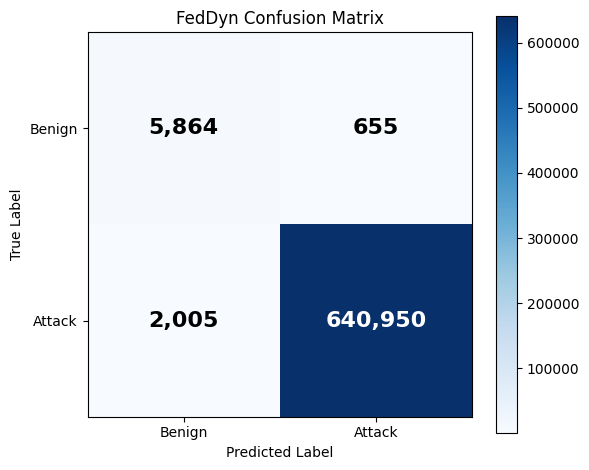

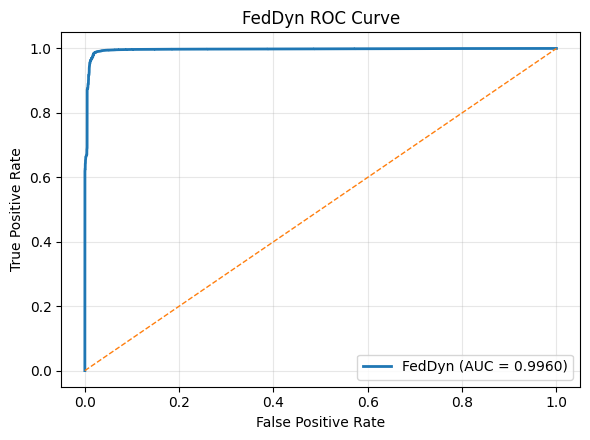

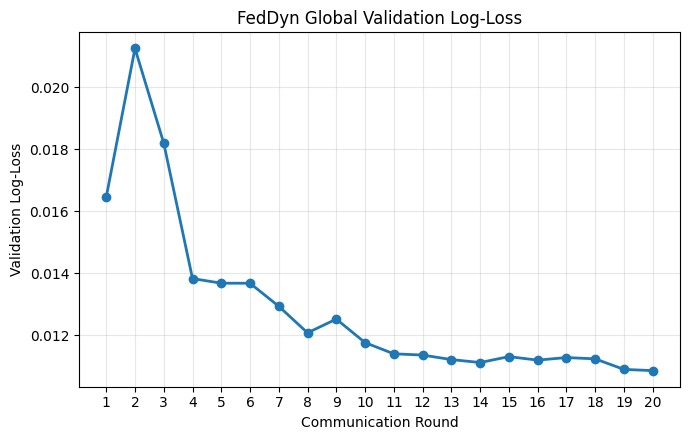


FEDDYN ROUND-20 FINAL TEST RESULTS
Accuracy         : 0.995904
Precision        : 0.998979
Recall           : 0.996882
F1               : 0.997929
Macro F1         : 0.906526
Weighted F1      : 0.996094
Benign Precision : 0.745203
Benign Recall    : 0.899524
Benign F1        : 0.815124
ROC-AUC          : 0.995985
PR-AUC           : 0.999955
Benign PR-AUC    : 0.777082

Confusion Matrix:
TN = 5864
FP = 655
FN = 2005
TP = 640950

Classification Report:

              precision    recall  f1-score        support
Benign         0.745203  0.899524  0.815124    6519.000000
Attack         0.998979  0.996882  0.997929  642955.000000
accuracy       0.995904  0.995904  0.995904       0.995904
macro avg      0.872091  0.948203  0.906526  649474.000000
weighted avg   0.996432  0.995904  0.996094  649474.000000

FEDDYN COMPLETE
Final model       : Round-20 mean client model
Communication     : 20 rounds
Local optimizer   : Adam
Local LR          : 0.001
FedDyn alpha      : 0.01
Threshold         :

8793

In [ ]:
# ================================================================
# CELL 17: FEDDYN ROUND-20 FINAL TEST EVALUATION + FIGURES
# ================================================================
#
# FINAL FEDDYN CONFIGURATION:
#
#   Architecture       : CNN-LSTM-ResNet
#   Algorithm          : FedDyn
#   Clients            : 5
#   Partition          : IID
#   Communication      : 20 rounds
#   Local epochs       : 1
#   Batch size         : 2048
#
# LOCAL SOLVER:
#   Adam
#   LR = 0.001
#
# FEDDYN:
#   Alpha = 0.01
#
# FINAL MODEL:
#   Round-20 mean client model
#
# EVALUATION:
#   Threshold = 0.5
#
# OUTPUTS:
#   - final_metrics.csv
#   - predictions.npz
#   - Confusion Matrix
#   - ROC Curve
#   - Global Validation Log-Loss
#
# IMPORTANT:
#   - NO retraining
#   - Existing FL experiments untouched
#
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    average_precision_score
)


# ----------------------------------------------------------------
# 2. Safety checks
# ----------------------------------------------------------------

if not os.path.exists(
    FEDDYN_FINAL_MODEL_FILE
):

    raise FileNotFoundError(
        "FedDyn Round-20 final model not found:\n" + FEDDYN_FINAL_MODEL_FILE
    )


if not os.path.exists(
    FEDDYN_ROUND_HISTORY_FILE
):

    raise FileNotFoundError(
        "FedDyn round history not found:\n" + FEDDYN_ROUND_HISTORY_FILE
    )


# ----------------------------------------------------------------
# 3. Verify Round 20
# ----------------------------------------------------------------

feddyn_history = pd.read_csv(
    FEDDYN_ROUND_HISTORY_FILE
)


if feddyn_history.empty:

    raise RuntimeError(
        "FedDyn round history is empty."
    )


final_round = int(
    feddyn_history[
        "Round"
    ].max()
)


if final_round != 20:

    raise RuntimeError(
        f"Expected final FedDyn round = 20, "
        f"but found {final_round}."
    )


print(
    "✅ Verified final communication round:",
    final_round
)


print(
    "✅ Final model policy: "
    "Round-20 mean client model."
)


# ----------------------------------------------------------------
# 4. Temporary local test cache
# ----------------------------------------------------------------

LOCAL_TEST_CACHE = (
    "/content/fl_binary_test_cache"
)


os.makedirs(
    LOCAL_TEST_CACHE,
    exist_ok=True
)


LOCAL_X_TEST_FILE = os.path.join(
    LOCAL_TEST_CACHE,
    "X_test_scaled_float32.npy"
)


LOCAL_Y_TEST_FILE = os.path.join(
    LOCAL_TEST_CACHE,
    "y_test_int8.npy"
)


def copy_if_missing(
    source,
    destination
):

    if not os.path.exists(
        destination
    ):

        print(
            "Copying temporarily to Colab:",
            os.path.basename(
                source
            )
        )


        shutil.copy2(
            source,
            destination
        )


copy_if_missing(
    X_TEST_FILE,
    LOCAL_X_TEST_FILE
)


copy_if_missing(
    Y_TEST_FILE,
    LOCAL_Y_TEST_FILE
)


# ----------------------------------------------------------------
# 5. Load test arrays
# ----------------------------------------------------------------

X_test_feddyn = np.load(
    LOCAL_X_TEST_FILE,
    mmap_mode="r"
)


y_test_feddyn = np.load(
    LOCAL_Y_TEST_FILE,
    mmap_mode="r"
)


y_test_feddyn = np.asarray(
    y_test_feddyn,
    dtype=np.uint8
)


print(
    "\nTest samples:",
    f"{len(y_test_feddyn):,}"
)


print(
    "Test benign:",
    f"{np.sum(y_test_feddyn == 0):,}"
)


print(
    "Test attack:",
    f"{np.sum(y_test_feddyn == 1):,}"
)


# ----------------------------------------------------------------
# 6. Reuse prediction cache OR perform inference
# ----------------------------------------------------------------

if os.path.exists(
    FEDDYN_FINAL_PREDICTIONS_FILE
):

    print(
        "\n✅ Existing FedDyn predictions found."
    )


    print(
        "✅ Test inference skipped."
    )


    prediction_cache = np.load(
        FEDDYN_FINAL_PREDICTIONS_FILE
    )


    y_pred = (
        prediction_cache[
            "y_pred"
        ]
        .astype(
            np.uint8,
            copy=False
        )
    )


    y_prob = (
        prediction_cache[
            "y_prob"
        ]
        .astype(
            np.float32,
            copy=False
        )
    )


    prediction_cache.close()


else:

    print(
        "\nRunning FedDyn ROUND-20 "
        "final test inference..."
    )


    tf.keras.backend.clear_session()


    feddyn_final_model = (
        tf.keras.models.load_model(
            FEDDYN_FINAL_MODEL_FILE,
            compile=False
        )
    )


    # ------------------------------------------------------------
    # Architecture verification
    # ------------------------------------------------------------

    if (
        feddyn_final_model.count_params() != 60097
    ):

        raise RuntimeError(
            "FedDyn final model architecture mismatch."
        )


    print(
        "Model parameters:",
        f"{feddyn_final_model.count_params():,}"
    )


    TEST_BATCH_SIZE = 4096


    probability_parts = []


    for start in range(
        0,
        len(
            y_test_feddyn
        ),
        TEST_BATCH_SIZE
    ):

        end = min(
            start + TEST_BATCH_SIZE,
            len(
                y_test_feddyn
            )
        )


        # --------------------------------------------------------
        # Load only one batch into RAM
        # --------------------------------------------------------

        batch_x = np.asarray(
            X_test_feddyn[
                start:end
            ],
            dtype=np.float32
        )


        batch_x = (
            batch_x[
                ...,
                np.newaxis
            ]
        )


        batch_probability = (
            feddyn_final_model(
                tf.convert_to_tensor(
                    batch_x,
                    dtype=tf.float32
                ),
                training=False
            )
            .numpy()
            .reshape(-1)
            .astype(
                np.float32,
                copy=False
            )
        )


        probability_parts.append(
            batch_probability
        )


        del batch_x
        del batch_probability


    # ------------------------------------------------------------
    # Combine probabilities
    # ------------------------------------------------------------

    y_prob = np.concatenate(
        probability_parts
    ).astype(
        np.float32,
        copy=False
    )


    del probability_parts


    # ------------------------------------------------------------
    # SAME threshold used for all algorithms
    # ------------------------------------------------------------

    y_pred = (
        y_prob >= 0.5
    ).astype(
        np.uint8
    )


    # ------------------------------------------------------------
    # Save compact prediction cache
    # ------------------------------------------------------------

    np.savez_compressed(
        FEDDYN_FINAL_PREDICTIONS_FILE,
        y_pred=y_pred,
        y_prob=y_prob
    )


    print(
        "✅ FedDyn Round-20 predictions saved."
    )


    del feddyn_final_model

    tf.keras.backend.clear_session()

    gc.collect()


# ----------------------------------------------------------------
# 7. Prediction integrity checks
# ----------------------------------------------------------------

if len(y_pred) != len(
    y_test_feddyn
):

    raise RuntimeError(
        "Prediction/test length mismatch."
    )


if len(y_prob) != len(
    y_test_feddyn
):

    raise RuntimeError(
        "Probability/test length mismatch."
    )


if not np.all(
    np.isfinite(
        y_prob
    )
):

    raise RuntimeError(
        "Non-finite FedDyn probabilities detected."
    )


if (
    np.min(y_prob) < 0.0 or np.max(y_prob) > 1.0
):

    raise RuntimeError(
        "FedDyn probabilities outside [0,1]."
    )


# ----------------------------------------------------------------
# 8. Confusion matrix
# ----------------------------------------------------------------

cm = confusion_matrix(
    y_test_feddyn,
    y_pred,
    labels=[0, 1]
)


tn, fp, fn, tp = (
    cm.ravel()
)


# ----------------------------------------------------------------
# 9. Overall + Attack metrics
# ----------------------------------------------------------------

accuracy = accuracy_score(
    y_test_feddyn,
    y_pred
)


attack_precision = precision_score(
    y_test_feddyn,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_recall = recall_score(
    y_test_feddyn,
    y_pred,
    pos_label=1,
    zero_division=0
)


attack_f1 = f1_score(
    y_test_feddyn,
    y_pred,
    pos_label=1,
    zero_division=0
)


# ----------------------------------------------------------------
# 10. Macro / Weighted F1
# ----------------------------------------------------------------

macro_f1 = f1_score(
    y_test_feddyn,
    y_pred,
    average="macro",
    zero_division=0
)


weighted_f1 = f1_score(
    y_test_feddyn,
    y_pred,
    average="weighted",
    zero_division=0
)


# ----------------------------------------------------------------
# 11. Benign metrics
# ----------------------------------------------------------------

benign_precision = precision_score(
    y_test_feddyn,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_recall = recall_score(
    y_test_feddyn,
    y_pred,
    pos_label=0,
    zero_division=0
)


benign_f1 = f1_score(
    y_test_feddyn,
    y_pred,
    pos_label=0,
    zero_division=0
)


specificity = (
    benign_recall
)


# ----------------------------------------------------------------
# 12. Threshold-independent metrics
# ----------------------------------------------------------------

roc_auc = roc_auc_score(
    y_test_feddyn,
    y_prob
)


pr_auc = average_precision_score(
    y_test_feddyn,
    y_prob
)


# Minority-class PR-AUC
benign_pr_auc = (
    average_precision_score(
        1 - y_test_feddyn,
        1.0 - y_prob
    )
)


# ----------------------------------------------------------------
# 13. Classification report
# ----------------------------------------------------------------

report_dict = classification_report(
    y_test_feddyn,
    y_pred,
    labels=[0, 1],
    target_names=[
        "Benign",
        "Attack"
    ],
    zero_division=0,
    output_dict=True
)


report_df = pd.DataFrame(
    report_dict
).transpose()


# ----------------------------------------------------------------
# 14. Save final metrics
# ----------------------------------------------------------------

final_metrics = pd.DataFrame(
    [
        {
            "Algorithm":
                "FedDyn",

            "Architecture":
                "CNN-LSTM-ResNet",

            "Partition":
                "IID",

            "Clients":
                5,

            "Communication_Rounds":
                20,

            "Local_Epochs":
                FEDDYN_LOCAL_EPOCHS,

            "Batch_Size":
                FEDDYN_BATCH_SIZE,

            "Local_Optimizer":
                "Adam",

            "Local_LR":
                FEDDYN_LOCAL_LEARNING_RATE,

            "FedDyn_Alpha":
                FEDDYN_ALPHA,

            "Final_Model":
                "Round20_Mean_Client_Model",

            "Threshold":
                0.5,

            "Accuracy":
                accuracy,

            "Precision":
                attack_precision,

            "Recall":
                attack_recall,

            "F1":
                attack_f1,

            "Macro_F1":
                macro_f1,

            "Weighted_F1":
                weighted_f1,

            "Benign_Precision":
                benign_precision,

            "Benign_Recall":
                benign_recall,

            "Benign_F1":
                benign_f1,

            "Specificity":
                specificity,

            "ROC_AUC":
                roc_auc,

            "PR_AUC":
                pr_auc,

            "Benign_PR_AUC":
                benign_pr_auc,

            "TN":
                int(tn),

            "FP":
                int(fp),

            "FN":
                int(fn),

            "TP":
                int(tp)
        }
    ]
)


final_metrics.to_csv(
    FEDDYN_FINAL_METRICS_FILE,
    index=False
)


print(
    "\n✅ Final FedDyn metrics saved."
)


# ================================================================
# 15. CONFUSION MATRIX
# ================================================================

plt.figure(
    figsize=(6, 5)
)


plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)


plt.title(
    "FedDyn Confusion Matrix"
)


plt.colorbar()


tick_marks = np.arange(
    2
)


plt.xticks(
    tick_marks,
    [
        "Benign",
        "Attack"
    ]
)


plt.yticks(
    tick_marks,
    [
        "Benign",
        "Attack"
    ]
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


cm_threshold = (
    cm.max() / 2.0
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if cm[i, j] > cm_threshold
                else "black"
            )
        )


plt.tight_layout()


plt.savefig(
    FEDDYN_CM_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ================================================================
# 16. ROC CURVE
# ================================================================

fpr, tpr, _ = roc_curve(
    y_test_feddyn,
    y_prob
)


plt.figure(
    figsize=(6, 4.5)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"FedDyn "
        f"(AUC = {roc_auc:.4f})"
    )
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "FedDyn ROC Curve"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    FEDDYN_ROC_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ================================================================
# 17. GLOBAL VALIDATION LOG-LOSS
# ================================================================

plt.figure(
    figsize=(7, 4.5)
)


plt.plot(
    feddyn_history[
        "Round"
    ],
    feddyn_history[
        "Val_Loss"
    ],
    marker="o",
    linewidth=2
)


plt.xlabel(
    "Communication Round"
)


plt.ylabel(
    "Validation Log-Loss"
)


plt.title(
    "FedDyn Global Validation Log-Loss"
)


plt.xticks(
    range(
        1,
        21
    )
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    FEDDYN_LOSS_FILE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

plt.close()


# ================================================================
# 18. Print FINAL results
# ================================================================

print(
    "\n" + "=" * 72
)


print(
    "FEDDYN ROUND-20 FINAL TEST RESULTS"
)


print(
    "=" * 72
)


print(
    f"Accuracy         : "
    f"{accuracy:.6f}"
)


print(
    f"Precision        : "
    f"{attack_precision:.6f}"
)


print(
    f"Recall           : "
    f"{attack_recall:.6f}"
)


print(
    f"F1               : "
    f"{attack_f1:.6f}"
)


print(
    f"Macro F1         : "
    f"{macro_f1:.6f}"
)


print(
    f"Weighted F1      : "
    f"{weighted_f1:.6f}"
)


print(
    f"Benign Precision : "
    f"{benign_precision:.6f}"
)


print(
    f"Benign Recall    : "
    f"{benign_recall:.6f}"
)


print(
    f"Benign F1        : "
    f"{benign_f1:.6f}"
)


print(
    f"ROC-AUC          : "
    f"{roc_auc:.6f}"
)


print(
    f"PR-AUC           : "
    f"{pr_auc:.6f}"
)


print(
    f"Benign PR-AUC    : "
    f"{benign_pr_auc:.6f}"
)


print(
    "\nConfusion Matrix:"
)


print(
    f"TN = {tn}"
)


print(
    f"FP = {fp}"
)


print(
    f"FN = {fn}"
)


print(
    f"TP = {tp}"
)


print(
    "\nClassification Report:\n"
)


print(
    report_df.to_string()
)


# ================================================================
# 19. Saved artifact summary
# ================================================================

print(
    "\n" + "=" * 72
)


print(
    "FEDDYN COMPLETE"
)


print(
    "=" * 72
)


print(
    "Final model       : Round-20 mean client model"
)


print(
    "Communication     : 20 rounds"
)


print(
    "Local optimizer   : Adam"
)


print(
    "Local LR          :",
    FEDDYN_LOCAL_LEARNING_RATE
)


print(
    "FedDyn alpha      :",
    FEDDYN_ALPHA
)


print(
    "Threshold         : 0.5"
)


print(
    "\nSaved:"
)


print(
    FEDDYN_FINAL_METRICS_FILE
)


print(
    FEDDYN_FINAL_PREDICTIONS_FILE
)


print(
    FEDDYN_CM_FILE
)


print(
    FEDDYN_ROC_FILE
)


print(
    FEDDYN_LOSS_FILE
)


print(
    "\n✅ No retraining performed."
)


print(
    "✅ FedDyn Round-20 model evaluated."
)


print(
    "✅ Threshold fixed at 0.5."
)


print(
    "✅ FedAvg untouched."
)


print(
    "✅ FedSGD untouched."
)


print(
    "✅ FedProx untouched."
)


print(
    "✅ FedAdam untouched."
)


print(
    "✅ FedDyn experiment complete."
)


print(
    "=" * 72
)


# ----------------------------------------------------------------
# 20. Cleanup
# ----------------------------------------------------------------

del y_pred
del y_prob
del X_test_feddyn
del y_test_feddyn

gc.collect()


Cell 18 — Final IID 5-Algorithm Comparison

SEARCHING FINAL METRIC FILES

Found metric files: 5
 • /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/result/FedAvg_IID_5Clients_CNN-LSTM-ResNet_Binary_final_metrics.csv
 • /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedSGD/result/final_metrics.csv
 • /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedProx/result/final_metrics.csv
 • /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedAdam_ServerLR_0.01/result/final_metrics.csv
 • /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedDyn/result/final_metrics.csv

✅ Final metrics found for all 5 algorithms.
✅ All 5 comparison models use Round-20 endpoints.

✅ IID comparison CSV saved.
✅ Comparison figures will NOT be saved to Drive.

FINAL IID FEDERATED LEARNING COMPARISON
Algorithm  Accuracy  Macro_F1  Benign_Recall  Benign_F1  ROC_AUC  Model_Round  Macro_F1_Rank
   FedAvg  0.996911  0.929932       0.956435   0.861426 0.998976           20              1
  FedAdam  0.996206  0.915549       

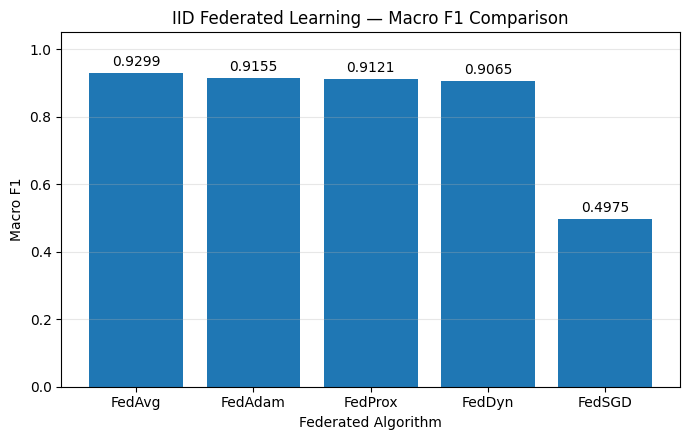

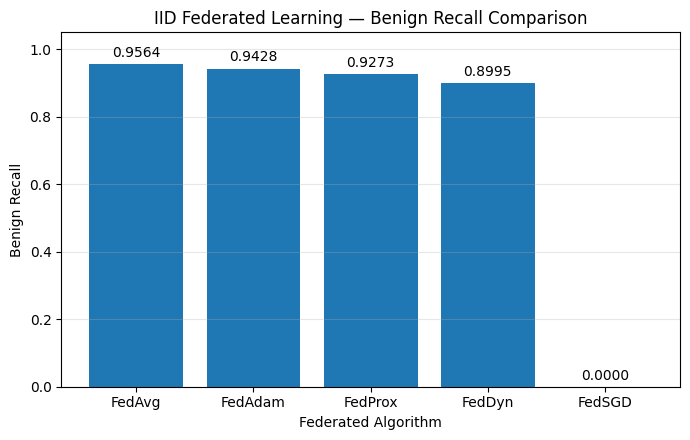


IID AUTOMATIC COMPARISON COMPLETE

Ranking by Macro F1:
1. FedAvg — 0.929932
2. FedAdam — 0.915549
3. FedProx — 0.912060
4. FedDyn — 0.906526
5. FedSGD — 0.497478

Saved ONLY:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/IID_Final_Comparison/IID_5Algorithms_Final_Comparison.csv

✅ Metrics loaded automatically from saved files.
✅ No metric manually entered.
✅ FedAvg corrected Round-20 result used.
✅ Corrected FedAdam Server-LR 0.01 result used.
✅ All algorithms verified at Round 20.
✅ Comparison CSV saved.
✅ Figures displayed only in Colab.
✅ Figures NOT saved to Google Drive.
✅ No training performed.
✅ No test inference rerun.


In [ ]:
# ==========================================
# CELL 18: AUTOMATIC IID FINAL COMPARISON
# ==========================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------------
# 2. Federated-learning root
# ----------------------------------------------------------------

FL_ROOT = os.path.join(
    PROJECT_ROOT,
    "federated_binary"
)


if not os.path.exists(
    FL_ROOT
):

    raise FileNotFoundError(
        "Federated binary root not found:\n" + FL_ROOT
    )


# ----------------------------------------------------------------
# 3. Comparison output folder
#
# Only comparison CSV will be saved.
# ----------------------------------------------------------------

IID_COMPARISON_DIR = os.path.join(
    FL_ROOT,
    "IID_Final_Comparison"
)


os.makedirs(
    IID_COMPARISON_DIR,
    exist_ok=True
)


IID_COMPARISON_FILE = os.path.join(
    IID_COMPARISON_DIR,
    "IID_5Algorithms_Final_Comparison.csv"
)


# ----------------------------------------------------------------
# 4. Automatically find final metric CSV files
#
# IMPORTANT:
#
# FedAvg filename is:
#
#   FedAvg_..._final_metrics.csv
#
# while other algorithms mostly use:
#
#   final_metrics.csv
#
# Therefore use:
#
#   *final_metrics.csv
#
# ----------------------------------------------------------------

all_metric_files = glob.glob(
    os.path.join(
        FL_ROOT,
        "**",
        "*final_metrics.csv"
    ),
    recursive=True
)


# ----------------------------------------------------------------
# Keep ONLY IID metric files
# ----------------------------------------------------------------

all_metric_files = [
    path
    for path in all_metric_files
    if "/noniid/" not in (
        path
        .replace("\\", "/")
        .lower()
    )
]


print(
    "=" * 100
)


print(
    "SEARCHING FINAL METRIC FILES"
)


print(
    "=" * 100
)


print(
    "\nFound metric files:",
    len(
        all_metric_files
    )
)


for path in all_metric_files:

    print(
        " •",
        path
    )


if len(
    all_metric_files
) == 0:

    raise FileNotFoundError(
        "No final metric CSV files found."
    )


# ----------------------------------------------------------------
# 5. Normalize algorithm names
# ----------------------------------------------------------------

def normalize_algorithm_name(
    text
):

    text = (
        str(text)
        .lower()
        .replace(
            "_",
            ""
        )
        .replace(
            "-",
            ""
        )
        .replace(
            " ",
            ""
        )
    )


    if "fedadam" in text:

        return "FedAdam"


    if "fedprox" in text:

        return "FedProx"


    if "fedsgd" in text:

        return "FedSGD"


    if "feddyn" in text:

        return "FedDyn"


    if "fedavg" in text:

        return "FedAvg"


    return None


# ----------------------------------------------------------------
# 6. Robust metric extractor
# ----------------------------------------------------------------

def get_metric(
    row,
    possible_names,
    required=True
):

    for name in possible_names:

        if name in row.index:

            value = row[
                name
            ]


            if pd.notna(
                value
            ):

                return value


    if required:

        raise KeyError(
            "Could not find metric using columns:\n" + str(
                possible_names
            )
        )


    return np.nan


# ----------------------------------------------------------------
# 7. Read candidate files
# ----------------------------------------------------------------

algorithm_rows = {}


for metrics_file in all_metric_files:

    try:

        df = pd.read_csv(
            metrics_file
        )


    except Exception as error:

        print(
            "\n⚠️ Could not read:"
        )


        print(
            metrics_file
        )


        print(
            error
        )


        continue


    if df.empty:

        continue


    row = df.iloc[
        0
    ].copy()


    # ------------------------------------------------------------
    # Determine algorithm
    # ------------------------------------------------------------

    algorithm = None


    if "Algorithm" in df.columns:

        algorithm = (
            normalize_algorithm_name(
                row[
                    "Algorithm"
                ]
            )
        )


    if algorithm is None:

        algorithm = (
            normalize_algorithm_name(
                metrics_file
            )
        )


    if algorithm not in [

        "FedAvg",
        "FedSGD",
        "FedProx",
        "FedAdam",
        "FedDyn"

    ]:

        continue


    # ============================================================
    # 8. FEDADAM FILTER
    #
    # We have:
    #
    #   OLD:
    #   federated_binary/FedAdam/
    #
    #   FINAL:
    #   federated_binary/FedAdam_ServerLR_0.01/
    #
    # Keep ONLY corrected Server-LR = 0.01 experiment.
    # ============================================================

    if algorithm == "FedAdam":

        normalized_path = (
            metrics_file
            .replace(
                "\\",
                "/"
            )
            .lower()
        )


        server_lr = get_metric(
            row,
            [
                "Server_LR",
                "server_learning_rate",
                "Server_Learning_Rate"
            ],
            required=False
        )


        # --------------------------------------------------------
        # Prefer explicit CSV value when available
        # --------------------------------------------------------

        if pd.notna(
            server_lr
        ):

            if not np.isclose(
                float(
                    server_lr
                ),
                0.01
            ):

                print(
                    "\nSkipping old FedAdam result:"
                )


                print(
                    metrics_file
                )


                continue


        # --------------------------------------------------------
        # Otherwise verify using path
        # --------------------------------------------------------

        else:

            if (
                "serverlr_0.01"
                not in normalized_path and "serverlr0.01"
                not in normalized_path
            ):

                print(
                    "\nSkipping old FedAdam result:"
                )


                print(
                    metrics_file
                )


                continue


    # ----------------------------------------------------------------
    # 9. Prevent accidental duplicate selection
    # ----------------------------------------------------------------

    if algorithm in algorithm_rows:

        print(
            "\n⚠️ DUPLICATE FINAL RESULT DETECTED"
        )


        print(
            "Algorithm:",
            algorithm
        )


        print(
            "\nAlready selected:"
        )


        print(
            algorithm_rows[
                algorithm
            ][
                "_Source_File"
            ]
        )


        print(
            "\nNew candidate:"
        )


        print(
            metrics_file
        )


        raise RuntimeError(
            f"Multiple valid final metric files "
            f"found for {algorithm}."
        )


    row[
        "_Source_File"
    ] = metrics_file


    algorithm_rows[
        algorithm
    ] = row


# ----------------------------------------------------------------
# 10. Verify all five algorithms
# ----------------------------------------------------------------

required_algorithms = [

    "FedAvg",
    "FedSGD",
    "FedProx",
    "FedAdam",
    "FedDyn"

]


missing_algorithms = [

    algorithm

    for algorithm
    in required_algorithms

    if algorithm
    not in algorithm_rows

]


if missing_algorithms:

    print(
        "\nAlgorithms successfully found:"
    )


    print(
        list(
            algorithm_rows.keys()
        )
    )


    raise RuntimeError(
        "Could not find final metrics for:\n" + "\n".join(
            missing_algorithms
        )
    )


print(
    "\n✅ Final metrics found for all 5 algorithms."
)


# ----------------------------------------------------------------
# 11. Build standardized comparison table
# ----------------------------------------------------------------

comparison_rows = []


for algorithm in required_algorithms:

    row = algorithm_rows[
        algorithm
    ]


    # ------------------------------------------------------------
    # Optional Benign PR-AUC
    # ------------------------------------------------------------

    benign_pr_auc = get_metric(
        row,
        [
            "Benign_PR_AUC",
            "benign_pr_auc"
        ],
        required=False
    )


    # ------------------------------------------------------------
    # Communication rounds
    # ------------------------------------------------------------

    communication_rounds = get_metric(
        row,
        [
            "Communication_Rounds",
            "communication_rounds"
        ],
        required=False
    )


    # ------------------------------------------------------------
    # Model round
    # ------------------------------------------------------------

    model_round = get_metric(
        row,
        [
            "Model_Round",
            "Final_Round",
            "final_round"
        ],
        required=False
    )


    # ------------------------------------------------------------
    # Evaluation-model policy
    #
    # Prefer saved CSV metadata.
    # If missing, all current final algorithms use Round-20
    # endpoint.
    # ------------------------------------------------------------

    evaluation_policy = get_metric(
        row,
        [
            "Evaluation_Model_Policy",
            "Evaluation_Model",
            "Final_Model"
        ],
        required=False
    )


    if pd.isna(
        evaluation_policy
    ):

        evaluation_policy = (
            "Round-20 endpoint"
        )


    standardized = {

        "Algorithm":
            algorithm,

        "Accuracy":
            float(
                get_metric(
                    row,
                    [
                        "Accuracy",
                        "accuracy"
                    ]
                )
            ),

        "Attack_Precision":
            float(
                get_metric(
                    row,
                    [
                        "Attack_Precision",
                        "Precision",
                        "precision"
                    ]
                )
            ),

        "Attack_Recall":
            float(
                get_metric(
                    row,
                    [
                        "Attack_Recall",
                        "Recall",
                        "recall"
                    ]
                )
            ),

        "Attack_F1":
            float(
                get_metric(
                    row,
                    [
                        "Attack_F1",
                        "F1",
                        "f1"
                    ]
                )
            ),

        "Macro_F1":
            float(
                get_metric(
                    row,
                    [
                        "Macro_F1",
                        "MacroF1",
                        "macro_f1"
                    ]
                )
            ),

        "Weighted_F1":
            float(
                get_metric(
                    row,
                    [
                        "Weighted_F1",
                        "WeightedF1",
                        "weighted_f1"
                    ]
                )
            ),

        "Benign_Precision":
            float(
                get_metric(
                    row,
                    [
                        "Benign_Precision",
                        "benign_precision"
                    ]
                )
            ),

        "Benign_Recall":
            float(
                get_metric(
                    row,
                    [
                        "Benign_Recall",
                        "benign_recall",
                        "Specificity"
                    ]
                )
            ),

        "Benign_F1":
            float(
                get_metric(
                    row,
                    [
                        "Benign_F1",
                        "benign_f1"
                    ]
                )
            ),

        "ROC_AUC":
            float(
                get_metric(
                    row,
                    [
                        "ROC_AUC",
                        "ROC-AUC",
                        "roc_auc"
                    ]
                )
            ),

        "PR_AUC":
            float(
                get_metric(
                    row,
                    [
                        "PR_AUC",
                        "PR-AUC",
                        "pr_auc"
                    ]
                )
            ),

        "Benign_PR_AUC":
            (
                float(
                    benign_pr_auc
                )

                if pd.notna(
                    benign_pr_auc
                )

                else np.nan
            ),

        "TN":
            int(
                get_metric(
                    row,
                    [
                        "TN",
                        "tn"
                    ]
                )
            ),

        "FP":
            int(
                get_metric(
                    row,
                    [
                        "FP",
                        "fp"
                    ]
                )
            ),

        "FN":
            int(
                get_metric(
                    row,
                    [
                        "FN",
                        "fn"
                    ]
                )
            ),

        "TP":
            int(
                get_metric(
                    row,
                    [
                        "TP",
                        "tp"
                    ]
                )
            ),

        "Communication_Rounds":
            (
                int(
                    communication_rounds
                )

                if pd.notna(
                    communication_rounds
                )

                else 20
            ),

        "Model_Round":
            (
                int(
                    model_round
                )

                if pd.notna(
                    model_round
                )

                else 20
            ),

        "Evaluation_Model_Policy":
            str(
                evaluation_policy
            ),

        "Source_File":
            row[
                "_Source_File"
            ]
    }


    comparison_rows.append(
        standardized
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


# ----------------------------------------------------------------
# 12. FAIRNESS SAFETY CHECK
#
# All final comparison models should now be Round 20.
# ----------------------------------------------------------------

invalid_rounds = comparison_df[
    comparison_df[
        "Model_Round"
    ] != 20
]


if not invalid_rounds.empty:

    print(
        "\n⚠️ Non-Round-20 model detected:"
    )


    print(
        invalid_rounds[
            [
                "Algorithm",
                "Model_Round"
            ]
        ].to_string(
            index=False
        )
    )


    raise RuntimeError(
        "IID comparison stopped because "
        "not all algorithms use Round-20 endpoints."
    )


print(
    "✅ All 5 comparison models use Round-20 endpoints."
)


# ----------------------------------------------------------------
# 13. Automatic rankings
# ----------------------------------------------------------------

comparison_df[
    "Macro_F1_Rank"
] = comparison_df[
    "Macro_F1"
].rank(
    ascending=False,
    method="min"
).astype(
    int
)


comparison_df[
    "Benign_Recall_Rank"
] = comparison_df[
    "Benign_Recall"
].rank(
    ascending=False,
    method="min"
).astype(
    int
)


comparison_df[
    "Benign_F1_Rank"
] = comparison_df[
    "Benign_F1"
].rank(
    ascending=False,
    method="min"
).astype(
    int
)


comparison_df[
    "ROC_AUC_Rank"
] = comparison_df[
    "ROC_AUC"
].rank(
    ascending=False,
    method="min"
).astype(
    int
)


# ----------------------------------------------------------------
# 14. Sort by Macro F1
# ----------------------------------------------------------------

comparison_df = (
    comparison_df
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ----------------------------------------------------------------
# 15. Save ONLY final comparison CSV
# ----------------------------------------------------------------

comparison_df.to_csv(
    IID_COMPARISON_FILE,
    index=False
)


print(
    "\n✅ IID comparison CSV saved."
)


print(
    "✅ Comparison figures will NOT be saved to Drive."
)


# ----------------------------------------------------------------
# 16. Print compact comparison table
# ----------------------------------------------------------------

display_columns = [

    "Algorithm",
    "Accuracy",
    "Macro_F1",
    "Benign_Recall",
    "Benign_F1",
    "ROC_AUC",
    "Model_Round",
    "Macro_F1_Rank"

]


print(
    "\n" + "=" * 110
)


print(
    "FINAL IID FEDERATED LEARNING COMPARISON"
)


print(
    "=" * 110
)


print(
    comparison_df[
        display_columns
    ].to_string(
        index=False
    )
)


# ----------------------------------------------------------------
# 17. Best IID algorithm
# ----------------------------------------------------------------

best_algorithm = (
    comparison_df
    .iloc[0][
        "Algorithm"
    ]
)


best_macro_f1 = float(
    comparison_df
    .iloc[0][
        "Macro_F1"
    ]
)


print(
    "\n✅ Best IID algorithm by Macro F1:"
)


print(
    f"{best_algorithm} "
    f"(Macro F1 = {best_macro_f1:.6f})"
)


# ================================================================
# 18. MACRO F1 FIGURE
#
# DISPLAY ONLY
# NOTHING SAVED TO DRIVE
# ================================================================

plot_df = (
    comparison_df
    .sort_values(
        "Macro_F1",
        ascending=False
    )
)


plt.figure(
    figsize=(
        7,
        4.5
    )
)


bars = plt.bar(
    plot_df[
        "Algorithm"
    ],
    plot_df[
        "Macro_F1"
    ]
)


plt.xlabel(
    "Federated Algorithm"
)


plt.ylabel(
    "Macro F1"
)


plt.title(
    "IID Federated Learning — Macro F1 Comparison"
)


plt.ylim(
    0,
    1.05
)


plt.grid(
    axis="y",
    alpha=0.3
)


for bar, value in zip(
    bars,
    plot_df[
        "Macro_F1"
    ]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.012,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()

plt.close()


# ================================================================
# 19. BENIGN RECALL FIGURE
#
# DISPLAY ONLY
# NOTHING SAVED TO DRIVE
# ================================================================

plot_df = (
    comparison_df
    .sort_values(
        "Benign_Recall",
        ascending=False
    )
)


plt.figure(
    figsize=(
        7,
        4.5
    )
)


bars = plt.bar(
    plot_df[
        "Algorithm"
    ],
    plot_df[
        "Benign_Recall"
    ]
)


plt.xlabel(
    "Federated Algorithm"
)


plt.ylabel(
    "Benign Recall"
)


plt.title(
    "IID Federated Learning — Benign Recall Comparison"
)


plt.ylim(
    0,
    1.05
)


plt.grid(
    axis="y",
    alpha=0.3
)


for bar, value in zip(
    bars,
    plot_df[
        "Benign_Recall"
    ]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.012,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()

plt.close()


# ----------------------------------------------------------------
# 20. Final summary
# ----------------------------------------------------------------

print(
    "\n" + "=" * 110
)


print(
    "IID AUTOMATIC COMPARISON COMPLETE"
)


print(
    "=" * 110
)


print(
    "\nRanking by Macro F1:"
)


for index, row in comparison_df.iterrows():

    print(
        f"{index + 1}. "
        f"{row['Algorithm']} "
        f"— {row['Macro_F1']:.6f}"
    )


print(
    "\nSaved ONLY:"
)


print(
    IID_COMPARISON_FILE
)


print(
    "\n✅ Metrics loaded automatically from saved files."
)


print(
    "✅ No metric manually entered."
)


print(
    "✅ FedAvg corrected Round-20 result used."
)


print(
    "✅ Corrected FedAdam Server-LR 0.01 result used."
)


print(
    "✅ All algorithms verified at Round 20."
)


print(
    "✅ Comparison CSV saved."
)


print(
    "✅ Figures displayed only in Colab."
)


print(
    "✅ Figures NOT saved to Google Drive."
)


print(
    "✅ No training performed."
)


print(
    "✅ No test inference rerun."
)


print(
    "=" * 110
)


In [ ]:
# ================================================================
# CELL 18B:
# IID STATISTICAL VALIDATION — SAVED PREDICTION CACHE VERSION
# ================================================================
#
# PURPOSE:
#   Statistical validation of the FINAL IID FL results using
#   the ORIGINAL saved test predictions from each evaluation cell.
#
# WHY CACHE-BASED:
#   - avoids unnecessary re-inference
#   - preserves the exact predictions used for saved final metrics
#   - avoids tiny CPU/GPU/precision-related threshold differences
#
# METHODS:
#   1. 95% stratified paired bootstrap confidence intervals
#      - Accuracy
#      - Macro F1
#      - Benign Recall
#      - Benign F1
#
#   2. Paired bootstrap difference:
#      FedAvg - each comparator
#
#   3. Exact McNemar test:
#      FedAvg vs each comparator
#
#   4. Holm correction for multiple McNemar comparisons
#
# IMPORTANT:
#   - NO training
#   - NO model loading
#   - NO inference
#   - NO model overwrite
#   - NO prediction overwrite
#   - NO figure saving
#
# SAVES ONLY:
#   IID_Statistical_Analysis/
#       IID_Final_Statistical_Analysis.csv
#
# INTERPRETATION:
#   These tests quantify uncertainty/disagreement on the fixed
#   held-out test set. They do NOT quantify training-seed
#   variability because each FL method was trained once.
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc

import numpy as np
import pandas as pd

from scipy.stats import binomtest

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix
)


print("=" * 105)
print("IID FEDERATED LEARNING — CACHE-BASED STATISTICAL VALIDATION")
print("=" * 105)


# ================================================================
# 2. Required notebook globals
# ================================================================

required_globals = [
    "FL_ROOT",
    "Y_TEST_FILE"
]


missing_globals = [
    variable
    for variable in required_globals
    if variable not in globals()
]


if missing_globals:

    raise RuntimeError(
        "Required notebook variables are missing:\n"
        f"{missing_globals}\n\n"
        "Run the existing IID setup/data cells first."
    )


# ================================================================
# 3. Exact ORIGINAL IID prediction-cache paths
# ================================================================

IID_PREDICTION_FILES = {

    "FedAvg":
        os.path.join(
            FL_ROOT,
            "result",
            "FedAvg_IID_5Clients_"
            "CNN-LSTM-ResNet_Binary_predictions.npz"
        ),

    "FedSGD":
        os.path.join(
            FL_ROOT,
            "FedSGD",
            "result",
            "predictions.npz"
        ),

    "FedProx":
        os.path.join(
            FL_ROOT,
            "FedProx",
            "result",
            "predictions.npz"
        ),

    "FedAdam":
        os.path.join(
            FL_ROOT,
            "FedAdam_ServerLR_0.01",
            "result",
            "predictions.npz"
        ),

    "FedDyn":
        os.path.join(
            FL_ROOT,
            "FedDyn",
            "result",
            "predictions.npz"
        )
}


# Order is paper-oriented:
# best IID method first, then remaining methods.
ALGORITHMS = [
    "FedAvg",
    "FedAdam",
    "FedDyn",
    "FedProx",
    "FedSGD"
]


print("\nChecking ORIGINAL IID prediction caches:")


for algorithm in ALGORITHMS:

    prediction_file = IID_PREDICTION_FILES[
        algorithm
    ]

    if not os.path.exists(
        prediction_file
    ):

        raise FileNotFoundError(
            f"{algorithm} prediction cache missing:\n"
            f"{prediction_file}\n\n"
            "Do NOT retrain. Run that algorithm's existing "
            "IID evaluation cell so its original cache is restored."
        )


    print(
        f"✅ {algorithm}: {prediction_file}"
    )


print(
    "\n✅ All five original IID prediction caches found."
)


# ================================================================
# 4. Existing IID final comparison
# ================================================================

IID_COMPARISON_FILE = os.path.join(
    FL_ROOT,
    "IID_Final_Comparison",
    "IID_5Algorithms_Final_Comparison.csv"
)


if not os.path.exists(
    IID_COMPARISON_FILE
):

    raise FileNotFoundError(
        "IID final comparison CSV missing:\n"
        f"{IID_COMPARISON_FILE}\n\n"
        "Run the existing IID Final Comparison cell first."
    )


iid_comparison_df = pd.read_csv(
    IID_COMPARISON_FILE
)


EXPECTED_ALGORITHMS = {
    "FedAvg",
    "FedSGD",
    "FedProx",
    "FedAdam",
    "FedDyn"
}


if (
    set(
        iid_comparison_df[
            "Algorithm"
        ].astype(str)
    ) != EXPECTED_ALGORITHMS
):

    raise RuntimeError(
        "Unexpected algorithms found in "
        "IID final comparison CSV."
    )


print(
    "\n✅ Existing IID final comparison verified."
)


# ================================================================
# 5. Load untouched binary test labels
# ================================================================

y_true = np.asarray(
    np.load(
        Y_TEST_FILE,
        mmap_mode="r"
    ),
    dtype=np.uint8
).reshape(-1)


if not np.array_equal(
    np.unique(
        y_true
    ),
    np.array(
        [0, 1],
        dtype=np.uint8
    )
):

    raise RuntimeError(
        "Unexpected binary test labels."
    )


N_TEST = len(
    y_true
)


N_BENIGN = int(
    np.sum(
        y_true == 0
    )
)


N_ATTACK = int(
    np.sum(
        y_true == 1
    )
)


print(
    "\nTest samples:",
    f"{N_TEST:,}"
)


print(
    "Benign:",
    f"{N_BENIGN:,}"
)


print(
    "Attack:",
    f"{N_ATTACK:,}"
)


# Expected frozen test-set counts
if (
    N_TEST != 649474 or N_BENIGN != 6519 or N_ATTACK != 642955
):

    raise RuntimeError(
        "Current test-set distribution does not match "
        "the frozen federated test set."
    )


print(
    "✅ Frozen IID test set verified."
)


# ================================================================
# 6. Load ORIGINAL saved predictions
# ================================================================

predictions = {}


print(
    "\n" + "=" * 105
)


print(
    "LOADING ORIGINAL IID TEST PREDICTIONS"
)


print(
    "=" * 105
)


for algorithm in ALGORITHMS:

    cache_file = IID_PREDICTION_FILES[
        algorithm
    ]


    with np.load(
        cache_file,
        allow_pickle=False
    ) as cache:

        if "y_pred" not in cache.files:

            raise RuntimeError(
                f"{algorithm} cache has no y_pred:\n"
                f"{cache_file}"
            )


        y_pred = np.asarray(
            cache[
                "y_pred"
            ],
            dtype=np.uint8
        ).reshape(-1)


    if len(
        y_pred
    ) != N_TEST:

        raise RuntimeError(
            f"{algorithm}: prediction length mismatch.\n"
            f"Expected = {N_TEST:,}\n"
            f"Found    = {len(y_pred):,}"
        )


    if not set(
        np.unique(
            y_pred
        ).tolist()
    ).issubset(
        {
            0,
            1
        }
    ):

        raise RuntimeError(
            f"{algorithm}: prediction cache contains "
            "non-binary labels."
        )


    predictions[
        algorithm
    ] = y_pred


    print(
        f"✅ {algorithm}: "
        f"{len(y_pred):,} predictions loaded"
    )


print(
    "\n✅ No model loading performed."
)


print(
    "✅ No new inference performed."
)


# ================================================================
# 7. Metric helper
# ================================================================

def calculate_binary_point_metrics(
    y_true_array,
    y_pred_array
):

    cm = confusion_matrix(
        y_true_array,
        y_pred_array,
        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true_array,
                    y_pred_array
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true_array,
                    y_pred_array,
                    average="macro",
                    zero_division=0
                )
            ),

        "Benign_Recall":
            float(
                recall_score(
                    y_true_array,
                    y_pred_array,
                    pos_label=0,
                    zero_division=0
                )
            ),

        "Benign_F1":
            float(
                f1_score(
                    y_true_array,
                    y_pred_array,
                    pos_label=0,
                    zero_division=0
                )
            ),

        "TN":
            int(
                tn
            ),

        "FP":
            int(
                fp
            ),

        "FN":
            int(
                fn
            ),

        "TP":
            int(
                tp
            )
    }


# ================================================================
# 8. Recompute point estimates from ORIGINAL cache
# ================================================================

point_metrics = {}


print(
    "\n" + "=" * 105
)


print(
    "ORIGINAL-CACHE POINT-ESTIMATE VERIFICATION"
)


print(
    "=" * 105
)


for algorithm in ALGORITHMS:

    metrics = calculate_binary_point_metrics(
        y_true,
        predictions[
            algorithm
        ]
    )


    point_metrics[
        algorithm
    ] = metrics


    print(
        f"{algorithm:<8} | "
        f"Accuracy={metrics['Accuracy']:.6f} | "
        f"Macro-F1={metrics['Macro_F1']:.6f} | "
        f"Benign Recall={metrics['Benign_Recall']:.6f} | "
        f"Benign F1={metrics['Benign_F1']:.6f} | "
        f"TN={metrics['TN']:,} | "
        f"FP={metrics['FP']:,} | "
        f"FN={metrics['FN']:,} | "
        f"TP={metrics['TP']:,}"
    )


# ================================================================
# 9. STRICT verification against saved IID final comparison
# ================================================================

print(
    "\nVerifying ORIGINAL cached predictions "
    "against saved IID final metrics..."
)


METRICS_TO_VERIFY = [
    "Accuracy",
    "Macro_F1",
    "Benign_Recall",
    "Benign_F1"
]


for algorithm in ALGORITHMS:

    saved_rows = iid_comparison_df[
        iid_comparison_df[
            "Algorithm"
        ].astype(str) == algorithm
    ]


    if len(
        saved_rows
    ) != 1:

        raise RuntimeError(
            f"{algorithm}: expected exactly one "
            "IID comparison row."
        )


    saved_row = saved_rows.iloc[
        0
    ]


    for metric in METRICS_TO_VERIFY:

        recomputed_value = float(
            point_metrics[
                algorithm
            ][
                metric
            ]
        )


        saved_value = float(
            saved_row[
                metric
            ]
        )


        if not np.isclose(
            recomputed_value,
            saved_value,
            atol=1e-6,
            rtol=0.0
        ):

            raise RuntimeError(
                f"{algorithm} {metric} cache mismatch:\n"
                f"From ORIGINAL prediction cache = "
                f"{recomputed_value:.12f}\n"
                f"Saved final comparison         = "
                f"{saved_value:.12f}\n\n"
                "STOP. Do not overwrite anything."
            )


    # ------------------------------------------------------------
    # Confusion-matrix verification if columns exist
    # ------------------------------------------------------------

    for count_name in [
        "TN",
        "FP",
        "FN",
        "TP"
    ]:

        if count_name in saved_row.index:

            cache_count = int(
                point_metrics[
                    algorithm
                ][
                    count_name
                ]
            )


            saved_count = int(
                saved_row[
                    count_name
                ]
            )


            if cache_count != saved_count:

                raise RuntimeError(
                    f"{algorithm} {count_name} mismatch:\n"
                    f"Cache = {cache_count}\n"
                    f"Saved = {saved_count}\n\n"
                    "STOP. Nothing was overwritten."
                )


print(
    "✅ All ORIGINAL IID prediction caches reproduce "
    "the saved final IID metrics."
)


# ================================================================
# 10. Build joint paired-prediction patterns
#
# Five binary model predictions generate at most 2^5 = 32
# joint prediction patterns.
#
# We keep Benign and Attack pattern distributions separate.
# This allows fast STRATIFIED PAIRED bootstrap while preserving
# paired model behaviour.
# ================================================================

prediction_matrix = np.column_stack(
    [
        predictions[
            algorithm
        ]

        for algorithm
        in ALGORITHMS
    ]
).astype(
    np.uint8,
    copy=False
)


pattern_codes = np.zeros(
    N_TEST,
    dtype=np.uint8
)


for model_index in range(
    len(ALGORITHMS)
):

    pattern_codes |= (

        prediction_matrix[
            :,
            model_index
        ]

        <<

        model_index

    )


NUM_PATTERNS = (
    2
    **
    len(ALGORITHMS)
)


benign_pattern_counts = np.bincount(
    pattern_codes[
        y_true == 0
    ],
    minlength=NUM_PATTERNS
).astype(
    np.int64
)


attack_pattern_counts = np.bincount(
    pattern_codes[
        y_true == 1
    ],
    minlength=NUM_PATTERNS
).astype(
    np.int64
)


if benign_pattern_counts.sum() != N_BENIGN:

    raise RuntimeError(
        "Benign paired-pattern count mismatch."
    )


if attack_pattern_counts.sum() != N_ATTACK:

    raise RuntimeError(
        "Attack paired-pattern count mismatch."
    )


benign_pattern_probabilities = (
    benign_pattern_counts / N_BENIGN
)


attack_pattern_probabilities = (
    attack_pattern_counts / N_ATTACK
)


pattern_predictions = np.zeros(
    (
        NUM_PATTERNS,
        len(ALGORITHMS)
    ),
    dtype=np.uint8
)


for pattern in range(
    NUM_PATTERNS
):

    for model_index in range(
        len(ALGORITHMS)
    ):

        pattern_predictions[
            pattern,
            model_index
        ] = (

            pattern
            >>
            model_index

        ) & 1


# ================================================================
# 11. Metric helper using only confusion counts
# ================================================================

def metrics_from_confusion_counts(
    tn,
    fp,
    fn,
    tp
):

    total = (
        tn + fp + fn + tp
    )


    accuracy = (

        (
            tn + tp
        ) / total

        if total > 0

        else 0.0
    )


    benign_recall = (

        tn / (
            tn + fp
        )

        if (
            tn + fp
        ) > 0

        else 0.0
    )


    benign_precision = (

        tn / (
            tn + fn
        )

        if (
            tn + fn
        ) > 0

        else 0.0
    )


    benign_f1 = (

        (
            2.0 * benign_precision * benign_recall
        )
 / (
            benign_precision + benign_recall
        )

        if (
            benign_precision + benign_recall
        ) > 0

        else 0.0
    )


    attack_recall = (

        tp / (
            tp + fn
        )

        if (
            tp + fn
        ) > 0

        else 0.0
    )


    attack_precision = (

        tp / (
            tp + fp
        )

        if (
            tp + fp
        ) > 0

        else 0.0
    )


    attack_f1 = (

        (
            2.0 * attack_precision * attack_recall
        )
 / (
            attack_precision + attack_recall
        )

        if (
            attack_precision + attack_recall
        ) > 0

        else 0.0
    )


    macro_f1 = (

        benign_f1 + attack_f1

    ) / 2.0


    return (
        accuracy,
        macro_f1,
        benign_recall,
        benign_f1
    )


# ================================================================
# 12. STRATIFIED PAIRED BOOTSTRAP
# ================================================================

BOOTSTRAP_REPEATS = 5000

BOOTSTRAP_SEED = 2026


bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


num_algorithms = len(
    ALGORITHMS
)


bootstrap_accuracy = np.zeros(
    (
        BOOTSTRAP_REPEATS,
        num_algorithms
    ),
    dtype=np.float64
)


bootstrap_macro_f1 = np.zeros_like(
    bootstrap_accuracy
)


bootstrap_benign_recall = np.zeros_like(
    bootstrap_accuracy
)


bootstrap_benign_f1 = np.zeros_like(
    bootstrap_accuracy
)


print(
    "\n" + "=" * 105
)


print(
    f"IID STRATIFIED PAIRED BOOTSTRAP — "
    f"{BOOTSTRAP_REPEATS:,} REPLICATES"
)


print(
    "=" * 105
)


for bootstrap_index in range(
    BOOTSTRAP_REPEATS
):

    sampled_benign_counts = (
        bootstrap_rng.multinomial(
            N_BENIGN,
            benign_pattern_probabilities
        )
    )


    sampled_attack_counts = (
        bootstrap_rng.multinomial(
            N_ATTACK,
            attack_pattern_probabilities
        )
    )


    for model_index in range(
        num_algorithms
    ):

        model_pattern_prediction = (
            pattern_predictions[
                :,
                model_index
            ]
        )


        tn = int(
            np.sum(
                sampled_benign_counts[
                    model_pattern_prediction == 0
                ]
            )
        )


        fp = int(
            np.sum(
                sampled_benign_counts[
                    model_pattern_prediction == 1
                ]
            )
        )


        fn = int(
            np.sum(
                sampled_attack_counts[
                    model_pattern_prediction == 0
                ]
            )
        )


        tp = int(
            np.sum(
                sampled_attack_counts[
                    model_pattern_prediction == 1
                ]
            )
        )


        (
            sample_accuracy,
            sample_macro_f1,
            sample_benign_recall,
            sample_benign_f1
        ) = metrics_from_confusion_counts(
            tn,
            fp,
            fn,
            tp
        )


        bootstrap_accuracy[
            bootstrap_index,
            model_index
        ] = sample_accuracy


        bootstrap_macro_f1[
            bootstrap_index,
            model_index
        ] = sample_macro_f1


        bootstrap_benign_recall[
            bootstrap_index,
            model_index
        ] = sample_benign_recall


        bootstrap_benign_f1[
            bootstrap_index,
            model_index
        ] = sample_benign_f1


print(
    "✅ 5,000 paired stratified bootstrap "
    "replicates completed."
)


# ================================================================
# 13. 95% bootstrap confidence intervals
# ================================================================

def percentile_ci(
    bootstrap_values
):

    lower, upper = np.percentile(
        bootstrap_values,
        [
            2.5,
            97.5
        ]
    )


    return (
        float(
            lower
        ),
        float(
            upper
        )
    )


model_ci_rows = []


print(
    "\n" + "=" * 105
)


print(
    "IID — 95% STRATIFIED BOOTSTRAP CONFIDENCE INTERVALS"
)


print(
    "=" * 105
)


for model_index, algorithm in enumerate(
    ALGORITHMS
):

    accuracy_low, accuracy_high = percentile_ci(
        bootstrap_accuracy[
            :,
            model_index
        ]
    )


    macro_low, macro_high = percentile_ci(
        bootstrap_macro_f1[
            :,
            model_index
        ]
    )


    recall_low, recall_high = percentile_ci(
        bootstrap_benign_recall[
            :,
            model_index
        ]
    )


    benign_f1_low, benign_f1_high = percentile_ci(
        bootstrap_benign_f1[
            :,
            model_index
        ]
    )


    metrics = point_metrics[
        algorithm
    ]


    model_ci_rows.append(
        {
            "Record_Type":
                "Model_95CI",

            "Algorithm":
                algorithm,

            "Comparator":
                "",

            "Metric":
                "Model_Metrics",

            "Point_Accuracy":
                metrics[
                    "Accuracy"
                ],

            "Accuracy_CI_Lower":
                accuracy_low,

            "Accuracy_CI_Upper":
                accuracy_high,

            "Point_Macro_F1":
                metrics[
                    "Macro_F1"
                ],

            "Macro_F1_CI_Lower":
                macro_low,

            "Macro_F1_CI_Upper":
                macro_high,

            "Point_Benign_Recall":
                metrics[
                    "Benign_Recall"
                ],

            "Benign_Recall_CI_Lower":
                recall_low,

            "Benign_Recall_CI_Upper":
                recall_high,

            "Point_Benign_F1":
                metrics[
                    "Benign_F1"
                ],

            "Benign_F1_CI_Lower":
                benign_f1_low,

            "Benign_F1_CI_Upper":
                benign_f1_high
        }
    )


    print(
        f"\n{algorithm}"
    )


    print(
        f"  Accuracy      : "
        f"{metrics['Accuracy']:.6f} "
        f"[{accuracy_low:.6f}, "
        f"{accuracy_high:.6f}]"
    )


    print(
        f"  Macro F1      : "
        f"{metrics['Macro_F1']:.6f} "
        f"[{macro_low:.6f}, "
        f"{macro_high:.6f}]"
    )


    print(
        f"  Benign Recall : "
        f"{metrics['Benign_Recall']:.6f} "
        f"[{recall_low:.6f}, "
        f"{recall_high:.6f}]"
    )


    print(
        f"  Benign F1     : "
        f"{metrics['Benign_F1']:.6f} "
        f"[{benign_f1_low:.6f}, "
        f"{benign_f1_high:.6f}]"
    )


# ================================================================
# 14. Paired bootstrap differences
#
# Delta = FedAvg - Comparator
#
# Positive:
#   FedAvg is numerically better on that metric.
#
# Negative:
#   Comparator is numerically better.
# ================================================================

FEDAVG_INDEX = ALGORITHMS.index(
    "FedAvg"
)


COMPARATORS = [
    "FedAdam",
    "FedDyn",
    "FedProx",
    "FedSGD"
]


pairwise_bootstrap_rows = []


print(
    "\n" + "=" * 105
)


print(
    "IID PAIRED BOOTSTRAP DIFFERENCES — FEDAVG MINUS COMPARATOR"
)


print(
    "=" * 105
)


BOOTSTRAP_METRICS = {

    "Accuracy":
        bootstrap_accuracy,

    "Macro_F1":
        bootstrap_macro_f1,

    "Benign_Recall":
        bootstrap_benign_recall,

    "Benign_F1":
        bootstrap_benign_f1
}


for comparator in COMPARATORS:

    comparator_index = ALGORITHMS.index(
        comparator
    )


    print(
        f"\nFedAvg vs {comparator}"
    )


    for metric_name, bootstrap_matrix in (
        BOOTSTRAP_METRICS.items()
    ):

        bootstrap_difference = (

            bootstrap_matrix[
                :,
                FEDAVG_INDEX
            ]
 -
            bootstrap_matrix[
                :,
                comparator_index
            ]

        )


        difference_low, difference_high = percentile_ci(
            bootstrap_difference
        )


        point_difference = (

            point_metrics[
                "FedAvg"
            ][
                metric_name
            ]
 -
            point_metrics[
                comparator
            ][
                metric_name
            ]

        )


        ci_excludes_zero = (

            difference_low > 0
 or
            difference_high < 0
        )


        pairwise_bootstrap_rows.append(
            {
                "Algorithm":
                    "FedAvg",

                "Comparator":
                    comparator,

                "Metric":
                    metric_name,

                "Delta_Point":
                    float(
                        point_difference
                    ),

                "Delta_CI_Lower":
                    difference_low,

                "Delta_CI_Upper":
                    difference_high,

                "Bootstrap_CI_Excludes_Zero":
                    bool(
                        ci_excludes_zero
                    )
            }
        )


        print(
            f"  Δ {metric_name:<13}: "
            f"{point_difference:+.6f} "
            f"[{difference_low:+.6f}, "
            f"{difference_high:+.6f}] "
            f"| CI excludes 0: "
            f"{ci_excludes_zero}"
        )


# ================================================================
# 15. EXACT McNEMAR TEST
#
# b:
#   FedAvg correct + comparator wrong
#
# c:
#   FedAvg wrong + comparator correct
#
# Exact two-sided binomial version is used.
# ================================================================

fedavg_correct = (

    predictions[
        "FedAvg"
    ]
 ==
    y_true

)


mcnemar_rows = []


print(
    "\n" + "=" * 105
)


print(
    "IID — EXACT McNEMAR TEST"
)


print(
    "=" * 105
)


for comparator in COMPARATORS:

    comparator_correct = (

        predictions[
            comparator
        ]
 ==
        y_true

    )


    b = int(
        np.sum(
            fedavg_correct
            &
            (~comparator_correct)
        )
    )


    c = int(
        np.sum(
            (~fedavg_correct)
            &
            comparator_correct
        )
    )


    discordant = (
        b + c
    )


    if discordant == 0:

        p_raw = 1.0

    else:

        p_raw = float(
            binomtest(
                k=b,
                n=discordant,
                p=0.5,
                alternative="two-sided"
            ).pvalue
        )


    mcnemar_rows.append(
        {
            "Algorithm":
                "FedAvg",

            "Comparator":
                comparator,

            "FedAvg_Correct_Other_Wrong_b":
                b,

            "FedAvg_Wrong_Other_Correct_c":
                c,

            "Discordant":
                discordant,

            "McNemar_P_Raw":
                p_raw
        }
    )


# ================================================================
# 16. Holm correction
# ================================================================

raw_p_values = np.asarray(
    [
        row[
            "McNemar_P_Raw"
        ]

        for row
        in mcnemar_rows
    ],
    dtype=np.float64
)


sort_order = np.argsort(
    raw_p_values
)


number_of_tests = len(
    raw_p_values
)


holm_adjusted = np.empty_like(
    raw_p_values
)


running_maximum = 0.0


for rank, original_index in enumerate(
    sort_order
):

    adjusted_value = (

        (
            number_of_tests - rank
        )
 *
        raw_p_values[
            original_index
        ]

    )


    adjusted_value = min(
        adjusted_value,
        1.0
    )


    running_maximum = max(
        running_maximum,
        adjusted_value
    )


    holm_adjusted[
        original_index
    ] = running_maximum


for index, row in enumerate(
    mcnemar_rows
):

    row[
        "McNemar_P_Holm"
    ] = float(
        holm_adjusted[
            index
        ]
    )


    row[
        "Significant_0.05"
    ] = bool(
        row[
            "McNemar_P_Holm"
        ] < 0.05
    )


    print(
        f"\nFedAvg vs "
        f"{row['Comparator']}"
    )


    print(
        "  FedAvg correct / other wrong (b): "
        f"{row['FedAvg_Correct_Other_Wrong_b']:,}"
    )


    print(
        "  FedAvg wrong / other correct (c): "
        f"{row['FedAvg_Wrong_Other_Correct_c']:,}"
    )


    print(
        "  Discordant predictions          : "
        f"{row['Discordant']:,}"
    )


    print(
        "  Exact raw p-value               : "
        f"{row['McNemar_P_Raw']:.6e}"
    )


    print(
        "  Holm-adjusted p-value           : "
        f"{row['McNemar_P_Holm']:.6e}"
    )


    print(
        "  Significant after Holm @ 0.05   : "
        f"{row['Significant_0.05']}"
    )


# ================================================================
# 17. FedSGD collapse note
# ================================================================

fedsgd_metrics = point_metrics[
    "FedSGD"
]


FEDSGD_COLLAPSED = (

    fedsgd_metrics[
        "Benign_Recall"
    ] <= 1e-12
 and
    fedsgd_metrics[
        "Benign_F1"
    ] <= 1e-12
)


print(
    "\n" + "=" * 105
)


print(
    "MINORITY-CLASS COLLAPSE CHECK"
)


print(
    "=" * 105
)


if FEDSGD_COLLAPSED:

    print(
        "⚠️ FedSGD minority-class collapse confirmed."
    )


    print(
        "   Benign Recall = 0"
    )


    print(
        "   Benign F1     = 0"
    )


    print(
        "   Statistical comparisons involving FedSGD "
        "must therefore be interpreted as comparison "
        "against a degenerate majority-class solution."
    )

else:

    print(
        "✅ FedSGD did not meet the complete-collapse criterion."
    )


# ================================================================
# 18. Build ONE combined statistical CSV
# ================================================================

final_rows = []


# ------------------------------------------------
# Model-level 95% CI rows
# ------------------------------------------------

for row in model_ci_rows:

    final_rows.append(
        {
            **row,

            "Delta_Point":
                np.nan,

            "Delta_CI_Lower":
                np.nan,

            "Delta_CI_Upper":
                np.nan,

            "Bootstrap_CI_Excludes_Zero":
                "",

            "McNemar_b":
                np.nan,

            "McNemar_c":
                np.nan,

            "McNemar_Discordant":
                np.nan,

            "McNemar_P_Raw":
                np.nan,

            "McNemar_P_Holm":
                np.nan,

            "McNemar_Significant_0.05":
                ""
        }
    )


# ------------------------------------------------
# Pairwise lookup
# ------------------------------------------------

mcnemar_lookup = {

    row[
        "Comparator"
    ]:
    row

    for row
    in mcnemar_rows
}


# ------------------------------------------------
# Pairwise metric rows
# ------------------------------------------------

for row in pairwise_bootstrap_rows:

    comparator = row[
        "Comparator"
    ]


    metric_name = row[
        "Metric"
    ]


    mc = mcnemar_lookup[
        comparator
    ]


    # McNemar is a correctness/error test rather than
    # a metric-specific F1/Recall test.
    # To avoid duplicating the same p-value on every metric row,
    # attach it only to the Macro-F1 pairwise row.
    include_mcnemar = (
        metric_name == "Macro_F1"
    )


    final_rows.append(
        {
            "Record_Type":
                "FedAvg_Pairwise",

            "Algorithm":
                "FedAvg",

            "Comparator":
                comparator,

            "Metric":
                metric_name,

            "Point_Accuracy":
                np.nan,

            "Accuracy_CI_Lower":
                np.nan,

            "Accuracy_CI_Upper":
                np.nan,

            "Point_Macro_F1":
                np.nan,

            "Macro_F1_CI_Lower":
                np.nan,

            "Macro_F1_CI_Upper":
                np.nan,

            "Point_Benign_Recall":
                np.nan,

            "Benign_Recall_CI_Lower":
                np.nan,

            "Benign_Recall_CI_Upper":
                np.nan,

            "Point_Benign_F1":
                np.nan,

            "Benign_F1_CI_Lower":
                np.nan,

            "Benign_F1_CI_Upper":
                np.nan,

            "Delta_Point":
                row[
                    "Delta_Point"
                ],

            "Delta_CI_Lower":
                row[
                    "Delta_CI_Lower"
                ],

            "Delta_CI_Upper":
                row[
                    "Delta_CI_Upper"
                ],

            "Bootstrap_CI_Excludes_Zero":
                row[
                    "Bootstrap_CI_Excludes_Zero"
                ],

            "McNemar_b":
                (
                    mc[
                        "FedAvg_Correct_Other_Wrong_b"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_c":
                (
                    mc[
                        "FedAvg_Wrong_Other_Correct_c"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_Discordant":
                (
                    mc[
                        "Discordant"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_P_Raw":
                (
                    mc[
                        "McNemar_P_Raw"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_P_Holm":
                (
                    mc[
                        "McNemar_P_Holm"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_Significant_0.05":
                (
                    mc[
                        "Significant_0.05"
                    ]

                    if include_mcnemar

                    else ""
                )
        }
    )


iid_statistical_df = pd.DataFrame(
    final_rows
)


# ================================================================
# 19. Save ONLY ONE statistical CSV
# ================================================================

IID_STAT_DIR = os.path.join(
    FL_ROOT,
    "IID_Statistical_Analysis"
)


os.makedirs(
    IID_STAT_DIR,
    exist_ok=True
)


IID_STAT_FILE = os.path.join(
    IID_STAT_DIR,
    "IID_Final_Statistical_Analysis.csv"
)


if os.path.exists(
    IID_STAT_FILE
):

    print(
        "\n⚠️ IID statistical CSV already exists."
    )


    print(
        "Existing file was NOT overwritten:"
    )


    print(
        IID_STAT_FILE
    )


else:

    iid_statistical_df.to_csv(
        IID_STAT_FILE,
        index=False
    )


    print(
        "\n✅ IID statistical-analysis CSV saved:"
    )


    print(
        IID_STAT_FILE
    )


# ================================================================
# 20. Compact statistical summary
# ================================================================

print(
    "\n" + "=" * 105
)


print(
    "IID STATISTICAL VALIDATION COMPLETE"
)


print(
    "=" * 105
)


print(
    "\nPrimary interpretation rules:"
)


print(
    "• 95% bootstrap CI = uncertainty associated "
    "with this fixed held-out test sample."
)


print(
    "• FedAvg-minus-comparator CI entirely > 0 = "
    "FedAvg advantage supported on this test set."
)


print(
    "• Difference CI containing 0 = the bootstrap "
    "does not clearly resolve that metric difference."
)


print(
    "• Holm-adjusted McNemar p < 0.05 = paired "
    "prediction/error behaviour differs significantly."
)


print(
    "• McNemar significance does NOT mean training-run "
    "superiority across random seeds."
)


print(
    "• Effect magnitude, minority-class metrics and CIs "
    "must be interpreted alongside p-values."
)


if FEDSGD_COLLAPSED:

    print(
        "• FedSGD is NOT treated as a successful robust "
        "classifier because its Benign Recall/F1 are zero."
    )


print(
    "\n✅ Original saved IID predictions used."
)


print(
    "✅ No model loaded."
)


print(
    "✅ No inference performed."
)


print(
    "✅ No training performed."
)


print(
    "✅ No prediction overwritten."
)


print(
    "✅ No existing final metric overwritten."
)


print(
    "✅ No figure saved."
)


print(
    "✅ Only one statistical CSV created "
    "if it did not already exist."
)


print(
    "\nSaved statistical file:"
)


print(
    IID_STAT_FILE
)


print(
    "=" * 105
)


# ================================================================
# 21. Cleanup RAM only
# ================================================================

del (
    prediction_matrix,
    pattern_codes,
    benign_pattern_counts,
    attack_pattern_counts,
    benign_pattern_probabilities,
    attack_pattern_probabilities,
    pattern_predictions,
    bootstrap_accuracy,
    bootstrap_macro_f1,
    bootstrap_benign_recall,
    bootstrap_benign_f1
)


predictions.clear()


_ = gc.collect()


IID FEDERATED LEARNING — CACHE-BASED STATISTICAL VALIDATION

Checking ORIGINAL IID prediction caches:
✅ FedAvg: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/result/FedAvg_IID_5Clients_CNN-LSTM-ResNet_Binary_predictions.npz
✅ FedAdam: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedAdam_ServerLR_0.01/result/predictions.npz
✅ FedDyn: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedDyn/result/predictions.npz
✅ FedProx: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedProx/result/predictions.npz
✅ FedSGD: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/FedSGD/result/predictions.npz

✅ All five original IID prediction caches found.

✅ Existing IID final comparison verified.

Test samples: 649,474
Benign: 6,519
Attack: 642,955
✅ Frozen IID test set verified.

LOADING ORIGINAL IID TEST PREDICTIONS
✅ FedAvg: 649,474 predictions loaded
✅ FedAdam: 649,474 predictions loaded
✅ FedDyn: 649,474 predictions loaded
✅ FedProx: 649,474 predictions

In [ ]:
# ================================================================
# CELL 18C:
# IID STATISTICAL RESULTS — CLEAN TABLE DISPLAY
# ================================================================
#
# DISPLAY ONLY:
#   Table 1: Model-level 95% Bootstrap CI
#   Table 2: FedAvg Pairwise Bootstrap Differences
#   Table 3: Exact McNemar + Holm Test
#
# NO training
# NO inference
# NO file overwrite
# NO new Drive save
# ================================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------
# 1. Load existing statistical CSV
# ------------------------------------------------

IID_STAT_FILE = os.path.join(
    FL_ROOT,
    "IID_Statistical_Analysis",
    "IID_Final_Statistical_Analysis.csv"
)


if not os.path.exists(IID_STAT_FILE):
    raise FileNotFoundError(
        "IID statistical CSV not found:\n" + IID_STAT_FILE
    )


stat_df = pd.read_csv(IID_STAT_FILE)


print("=" * 105)
print("IID STATISTICAL RESULTS — TABLE VIEW")
print("=" * 105)


# ================================================================
# TABLE 1
# MODEL-LEVEL 95% BOOTSTRAP CONFIDENCE INTERVALS
# ================================================================

model_df = stat_df[
    stat_df["Record_Type"] == "Model_95CI"
].copy()


def format_ci(point, lower, upper):
    return (
        f"{float(point):.6f} "
        f"[{float(lower):.6f}, {float(upper):.6f}]"
    )


table1 = pd.DataFrame({
    "Algorithm":
        model_df["Algorithm"].values,

    "Accuracy (95% CI)": [
        format_ci(p, l, u)
        for p, l, u in zip(
            model_df["Point_Accuracy"],
            model_df["Accuracy_CI_Lower"],
            model_df["Accuracy_CI_Upper"]
        )
    ],

    "Macro F1 (95% CI)": [
        format_ci(p, l, u)
        for p, l, u in zip(
            model_df["Point_Macro_F1"],
            model_df["Macro_F1_CI_Lower"],
            model_df["Macro_F1_CI_Upper"]
        )
    ],

    "Benign Recall (95% CI)": [
        format_ci(p, l, u)
        for p, l, u in zip(
            model_df["Point_Benign_Recall"],
            model_df["Benign_Recall_CI_Lower"],
            model_df["Benign_Recall_CI_Upper"]
        )
    ],

    "Benign F1 (95% CI)": [
        format_ci(p, l, u)
        for p, l, u in zip(
            model_df["Point_Benign_F1"],
            model_df["Benign_F1_CI_Lower"],
            model_df["Benign_F1_CI_Upper"]
        )
    ]
})


print("\nTABLE 1 — IID MODEL PERFORMANCE WITH 95% BOOTSTRAP CI")

display(
    table1.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center"
    })
)


# ================================================================
# TABLE 2
# FEDAVG PAIRWISE BOOTSTRAP DIFFERENCES
# ================================================================

pair_df = stat_df[
    stat_df["Record_Type"] == "FedAvg_Pairwise"
].copy()


table2 = pair_df[
    [
        "Comparator",
        "Metric",
        "Delta_Point",
        "Delta_CI_Lower",
        "Delta_CI_Upper",
        "Bootstrap_CI_Excludes_Zero"
    ]
].copy()


table2.insert(
    0,
    "Comparison",
    "FedAvg vs " + table2["Comparator"].astype(str)
)


table2["Difference (FedAvg − Comparator)"] = [
    f"{point:+.6f} [{lower:+.6f}, {upper:+.6f}]"
    for point, lower, upper in zip(
        table2["Delta_Point"],
        table2["Delta_CI_Lower"],
        table2["Delta_CI_Upper"]
    )
]


table2["CI excludes 0"] = (
    table2["Bootstrap_CI_Excludes_Zero"]
    .map({
        True: "Yes",
        False: "No",
        "True": "Yes",
        "False": "No"
    })
)


table2 = table2[
    [
        "Comparison",
        "Metric",
        "Difference (FedAvg − Comparator)",
        "CI excludes 0"
    ]
]


print("\nTABLE 2 — IID PAIRED BOOTSTRAP DIFFERENCES")

display(
    table2.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center"
    })
)


# ================================================================
# TABLE 3
# EXACT McNEMAR TEST + HOLM CORRECTION
#
# McNemar values were attached to Macro_F1 pairwise rows
# only to avoid repeating the same test multiple times.
# ================================================================

mcnemar_df = pair_df[
    pair_df["Metric"] == "Macro_F1"
].copy()


table3 = pd.DataFrame({

    "Comparison":
        "FedAvg vs " + mcnemar_df["Comparator"].astype(str),

    "FedAvg Correct / Other Wrong (b)":
        mcnemar_df["McNemar_b"].astype(int),

    "FedAvg Wrong / Other Correct (c)":
        mcnemar_df["McNemar_c"].astype(int),

    "Discordant":
        mcnemar_df["McNemar_Discordant"].astype(int),

    "Raw p-value":
        mcnemar_df["McNemar_P_Raw"],

    "Holm-adjusted p-value":
        mcnemar_df["McNemar_P_Holm"],

    "Significant (α=0.05)":
        mcnemar_df[
            "McNemar_Significant_0.05"
        ].map({
            True: "Yes",
            False: "No",
            "True": "Yes",
            "False": "No"
        })
})


print("\nTABLE 3 — IID EXACT McNEMAR TEST WITH HOLM CORRECTION")

display(
    table3.style
    .hide(axis="index")
    .format({
        "Raw p-value": "{:.3e}",
        "Holm-adjusted p-value": "{:.3e}"
    })
    .set_properties(**{
        "text-align": "center"
    })
)


# ================================================================
# FINAL NOTE
# ================================================================

print("\n" + "=" * 105)

print("✅ Statistical results displayed as 3 clean tables.")
print("✅ Existing statistical CSV used.")
print("✅ No statistical test rerun.")
print("✅ No model loaded.")
print("✅ No inference performed.")
print("✅ Nothing new saved to Drive.")

print("=" * 105)


IID STATISTICAL RESULTS — TABLE VIEW

TABLE 1 — IID MODEL PERFORMANCE WITH 95% BOOTSTRAP CI


Algorithm,Accuracy (95% CI),Macro F1 (95% CI),Benign Recall (95% CI),Benign F1 (95% CI)
FedAvg,"0.996911 [0.996776, 0.997047]","0.929932 [0.927157, 0.932727]","0.956435 [0.951373, 0.961190]","0.861426 [0.855937, 0.866949]"
FedAdam,"0.996206 [0.996057, 0.996359]","0.915549 [0.912605, 0.918568]","0.942783 [0.936954, 0.948309]","0.833017 [0.827199, 0.838974]"
FedDyn,"0.995904 [0.995752, 0.996063]","0.906526 [0.903342, 0.909772]","0.899524 [0.892161, 0.906581]","0.815124 [0.808844, 0.821531]"
FedProx,"0.996081 [0.995927, 0.996235]","0.912060 [0.908925, 0.915192]","0.927289 [0.920693, 0.933579]","0.826102 [0.819907, 0.832299]"
FedSGD,"0.989963 [0.989963, 0.989963]","0.497478 [0.497478, 0.497478]","0.000000 [0.000000, 0.000000]","0.000000 [0.000000, 0.000000]"



TABLE 2 — IID PAIRED BOOTSTRAP DIFFERENCES


Comparison,Metric,Difference (FedAvg − Comparator),CI excludes 0
FedAvg vs FedAdam,Accuracy,"+0.000705 [+0.000625, +0.000784]",Yes
FedAvg vs FedAdam,Macro_F1,"+0.014383 [+0.012686, +0.016046]",Yes
FedAvg vs FedAdam,Benign_Recall,"+0.013652 [+0.009511, +0.017948]",Yes
FedAvg vs FedAdam,Benign_F1,"+0.028409 [+0.025053, +0.031695]",Yes
FedAvg vs FedDyn,Accuracy,"+0.001007 [+0.000919, +0.001095]",Yes
FedAvg vs FedDyn,Macro_F1,"+0.023406 [+0.021379, +0.025484]",Yes
FedAvg vs FedDyn,Benign_Recall,"+0.056911 [+0.050775, +0.063046]",Yes
FedAvg vs FedDyn,Benign_F1,"+0.046302 [+0.042295, +0.050414]",Yes
FedAvg vs FedProx,Accuracy,"+0.000830 [+0.000745, +0.000916]",Yes
FedAvg vs FedProx,Macro_F1,"+0.017872 [+0.016045, +0.019727]",Yes



TABLE 3 — IID EXACT McNEMAR TEST WITH HOLM CORRECTION


Comparison,FedAvg Correct / Other Wrong (b),FedAvg Wrong / Other Correct (c),Discordant,Raw p-value,Holm-adjusted p-value,Significant (α=0.05)
FedAvg vs FedAdam,589,131,720,3.738e-70,3.738e-70,Yes
FedAvg vs FedDyn,780,126,906,8.030e-116,2.409e-115,Yes
FedAvg vs FedProx,667,128,795,1.088e-88,2.176e-88,Yes
FedAvg vs FedSGD,6235,1722,7957,0.000e+00,0.000e+00,Yes



✅ Statistical results displayed as 3 clean tables.
✅ Existing statistical CSV used.
✅ No statistical test rerun.
✅ No model loaded.
✅ No inference performed.
✅ Nothing new saved to Drive.


Non IID Experiment

In [ ]:
# ================================================================
# CELL 19: STRONG LABEL-SKEW NON-IID 5-CLIENT PARTITION
# ================================================================
#
# PURPOSE:
#   Create the PRIMARY Non-IID partition for binary FL experiments.
#
# DESIGN:
#   - Same original training data
#   - Same global validation samples as IID experiment
#   - Same 5 clients
#   - Approximately equal total client sizes
#   - Strongly unequal BENIGN distribution
#
# BENIGN ALLOCATION:
#
#   Client 1 -> 50%
#   Client 2 -> 25%
#   Client 3 -> 15%
#   Client 4 ->  7%
#   Client 5 ->  3%
#
# IMPORTANT:
#   - Untouched final TEST SET is never used here
#   - Existing IID partition is NOT modified
#   - Existing FL models/results are NOT modified
#   - Partition is deterministic and reproducible
#   - If partition already exists, it is loaded instead of recreated
#
# RUNTIME:
#   CPU only — GPU NOT required
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc

import numpy as np
import pandas as pd


# ----------------------------------------------------------------
# 2. Basic configuration
# ----------------------------------------------------------------

NONIID_NUM_CLIENTS = 5

NONIID_SEED = 42

NONIID_SCHEME = (
    "Strong_Label_Skew"
)


# Fraction of ALL federated-training benign samples
# assigned to each client.
#
# Sum MUST equal 1.0.
#
BENIGN_ALLOCATION = np.asarray(
    [
        0.50,
        0.25,
        0.15,
        0.07,
        0.03
    ],
    dtype=np.float64
)


if not np.isclose(
    BENIGN_ALLOCATION.sum(),
    1.0
):

    raise RuntimeError(
        "BENIGN_ALLOCATION must sum to 1.0."
    )


# ----------------------------------------------------------------
# Dynamic expected Benign-count verification
# ----------------------------------------------------------------

def get_expected_benign_counts(
    y_labels,
    validation_idx,
    benign_allocation
):

    y_labels = np.asarray(
        y_labels
    ).reshape(-1)

    validation_idx = np.asarray(
        validation_idx,
        dtype=np.int64
    )

    benign_allocation = np.asarray(
        benign_allocation,
        dtype=np.float64
    )

    if not np.isclose(
        benign_allocation.sum(),
        1.0
    ):
        raise RuntimeError(
            "Benign allocation must sum to 1.0."
        )

    total_benign = (
        int(
            np.count_nonzero(
                y_labels == 0
            )
        )
        -
        int(
            np.count_nonzero(
                y_labels[
                    validation_idx
                ] == 0
            )
        )
    )

    raw_counts = (
        benign_allocation
        * total_benign
    )

    expected_counts = np.floor(
        raw_counts
    ).astype(
        np.int64
    )

    remainder = (
        total_benign
        - int(
            expected_counts.sum()
        )
    )

    fractional_parts = (
        raw_counts
        - expected_counts
    )

    remainder_order = np.argsort(
        -fractional_parts,
        kind="stable"
    )

    if remainder > 0:
        expected_counts[
            remainder_order[:remainder]
        ] += 1

    return (
        expected_counts
        .astype(int)
        .tolist()
    )
# ----------------------------------------------------------------
# 3. Required notebook variables
# ----------------------------------------------------------------

required_variables = [
    "FL_ROOT",
    "Y_TRAIN_FILE",
    "validation_indices"
]


missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Run the existing setup + IID partition cells first.\n"
        f"Missing variables: {missing_variables}"
    )


# ----------------------------------------------------------------
# 4. Non-IID output folder
#
# Separate from IID partition.
# NOTHING from IID is overwritten.
# ----------------------------------------------------------------

NONIID_PARTITION_DIR = os.path.join(
    FL_ROOT,
    "partition",
    "NonIID"
)


os.makedirs(
    NONIID_PARTITION_DIR,
    exist_ok=True
)


NONIID_PARTITION_FILE = os.path.join(
    NONIID_PARTITION_DIR,
    (
        "Strong_LabelSkew_"
        "5Clients_Binary_partition.npz"
    )
)


NONIID_DISTRIBUTION_FILE = os.path.join(
    NONIID_PARTITION_DIR,
    (
        "Strong_LabelSkew_"
        "5Clients_Binary_distribution.csv"
    )
)


# ----------------------------------------------------------------
# 5. Load training labels only
#
# Very small compared with feature matrix.
# No feature data is loaded.
# ----------------------------------------------------------------

y_train_noniid = np.load(
    Y_TRAIN_FILE,
    mmap_mode="r"
)


y_train_noniid = np.asarray(
    y_train_noniid,
    dtype=np.int8
).reshape(-1)


TOTAL_TRAIN_SAMPLES = len(
    y_train_noniid
)


print(
    "=" * 88
)


print(
    "STRONG LABEL-SKEW NON-IID PARTITION"
)


print(
    "=" * 88
)


print(
    "\nTotal original training samples:",
    f"{TOTAL_TRAIN_SAMPLES:,}"
)


print(
    "Global validation samples:",
    f"{len(validation_indices):,}"
)


# ----------------------------------------------------------------
# 6. Validation indices safety
# ----------------------------------------------------------------

validation_indices_noniid = np.asarray(
    validation_indices,
    dtype=np.int32
)


if (
    validation_indices_noniid.min() < 0 or validation_indices_noniid.max() >= TOTAL_TRAIN_SAMPLES
):

    raise RuntimeError(
        "Invalid global validation indices."
    )


if (
    len(
        np.unique(
            validation_indices_noniid
        )
    ) != len(
        validation_indices_noniid
    )
):

    raise RuntimeError(
        "Duplicate validation indices detected."
    )


# ----------------------------------------------------------------
# 7. Helper: create distribution table
# ----------------------------------------------------------------

def make_noniid_distribution_table(
    assignment
):

    rows = []


    for client_id in range(
        NONIID_NUM_CLIENTS
    ):

        indices = np.flatnonzero(
            assignment == client_id
        )


        labels = y_train_noniid[
            indices
        ]


        benign_count = int(
            np.sum(
                labels == 0
            )
        )


        attack_count = int(
            np.sum(
                labels == 1
            )
        )


        total_count = int(
            len(
                indices
            )
        )


        rows.append(
            {
                "Client":
                    client_id + 1,

                "Total_Samples":
                    total_count,

                "Benign":
                    benign_count,

                "Attack":
                    attack_count,

                "Benign_Percent":
                    (
                        100.0 * benign_count / total_count
                    ),

                "Attack_Percent":
                    (
                        100.0 * attack_count / total_count
                    )
            }
        )


    return pd.DataFrame(
        rows
    )


# ================================================================
# 8. LOAD EXISTING PARTITION IF AVAILABLE
# ================================================================

if os.path.exists(
    NONIID_PARTITION_FILE
):

    print(
        "\n✅ Existing Non-IID partition found."
    )


    print(
        "Loading saved partition — "
        "NO regeneration."
    )


    saved_partition = np.load(
        NONIID_PARTITION_FILE,
        allow_pickle=False
    )


    if "assignment" not in saved_partition.files:

        saved_partition.close()

        raise RuntimeError(
            "Saved Non-IID partition does not "
            "contain 'assignment'."
        )


    noniid_assignment = np.asarray(
        saved_partition[
            "assignment"
        ],
        dtype=np.int8
    )


    saved_partition.close()


    if len(
        noniid_assignment
    ) != TOTAL_TRAIN_SAMPLES:

        raise RuntimeError(
            "Saved Non-IID partition length "
            "does not match training data."
        )


# ================================================================
# 9. OTHERWISE CREATE NEW PARTITION
# ================================================================

else:

    print(
        "\nCreating new deterministic "
        "Strong Label-Skew Non-IID partition..."
    )


    rng = np.random.default_rng(
        NONIID_SEED
    )


    # ------------------------------------------------------------
    # Assignment coding:
    #
    #   -2 = not assigned yet
    #   -1 = global validation
    #  0-4 = client IDs
    # ------------------------------------------------------------

    noniid_assignment = np.full(
        TOTAL_TRAIN_SAMPLES,
        -2,
        dtype=np.int8
    )


    noniid_assignment[
        validation_indices_noniid
    ] = -1


    # ------------------------------------------------------------
    # Build federated-training mask
    #
    # Validation samples remain excluded.
    # ------------------------------------------------------------

    federated_mask = np.ones(
        TOTAL_TRAIN_SAMPLES,
        dtype=bool
    )


    federated_mask[
        validation_indices_noniid
    ] = False


    benign_indices = np.flatnonzero(
        federated_mask
        &
        (
            y_train_noniid == 0
        )
    ).astype(
        np.int32,
        copy=False
    )


    attack_indices = np.flatnonzero(
        federated_mask
        &
        (
            y_train_noniid == 1
        )
    ).astype(
        np.int32,
        copy=False
    )


    # ------------------------------------------------------------
    # Shuffle each class deterministically
    # ------------------------------------------------------------

    rng.shuffle(
        benign_indices
    )


    rng.shuffle(
        attack_indices
    )


    total_benign = int(
        len(
            benign_indices
        )
    )


    total_attack = int(
        len(
            attack_indices
        )
    )


    total_federated = (
        total_benign + total_attack
    )


    print(
        "\nFederated-training samples:",
        f"{total_federated:,}"
    )


    print(
        "Federated benign:",
        f"{total_benign:,}"
    )


    print(
        "Federated attack:",
        f"{total_attack:,}"
    )


    # ------------------------------------------------------------
    # Equal total client sizes
    #
    # Example for current dataset:
    #
    #   Client 1 ≈ 493,600
    #   Client 2 ≈ 493,600
    #   Client 3 ≈ 493,599
    #   Client 4 ≈ 493,599
    #   Client 5 ≈ 493,599
    #
    # ------------------------------------------------------------

    base_size = (
        total_federated // NONIID_NUM_CLIENTS
    )


    remainder = (
        total_federated % NONIID_NUM_CLIENTS
    )


    target_client_sizes = np.asarray(
        [
            base_size + (
                1
                if client_id < remainder
                else 0
            )

            for client_id
            in range(
                NONIID_NUM_CLIENTS
            )
        ],
        dtype=np.int64
    )


    # ------------------------------------------------------------
    # Exact integer benign allocation
    # ------------------------------------------------------------

    raw_benign_counts = (
        BENIGN_ALLOCATION * total_benign
    )


    benign_counts = np.floor(
        raw_benign_counts
    ).astype(
        np.int64
    )


    benign_remainder = (
        total_benign - int(
            benign_counts.sum()
        )
    )


    fractional_parts = (
        raw_benign_counts - benign_counts
    )


    remainder_order = np.argsort(
        -fractional_parts,
        kind="stable"
    )


    for position in range(
        benign_remainder
    ):

        benign_counts[
            remainder_order[
                position
            ]
        ] += 1


    # ------------------------------------------------------------
    # Attack fills the rest of each equal-size client.
    # ------------------------------------------------------------

    attack_counts = (
        target_client_sizes - benign_counts
    )


    if np.any(
        attack_counts <= 0
    ):

        raise RuntimeError(
            "Invalid Non-IID allocation: "
            "a client has no attack samples."
        )


    if int(
        attack_counts.sum()
    ) != total_attack:

        raise RuntimeError(
            "Attack allocation does not match "
            "available attack samples."
        )


    # ------------------------------------------------------------
    # Assign benign samples
    # ------------------------------------------------------------

    benign_cursor = 0

    attack_cursor = 0


    for client_id in range(
        NONIID_NUM_CLIENTS
    ):

        client_benign_count = int(
            benign_counts[
                client_id
            ]
        )


        client_attack_count = int(
            attack_counts[
                client_id
            ]
        )


        client_benign_indices = (
            benign_indices[
                benign_cursor:
                benign_cursor + client_benign_count
            ]
        )


        client_attack_indices = (
            attack_indices[
                attack_cursor:
                attack_cursor + client_attack_count
            ]
        )


        noniid_assignment[
            client_benign_indices
        ] = client_id


        noniid_assignment[
            client_attack_indices
        ] = client_id


        benign_cursor += (
            client_benign_count
        )


        attack_cursor += (
            client_attack_count
        )


    # ------------------------------------------------------------
    # Ensure every available class sample was consumed
    # ------------------------------------------------------------

    if benign_cursor != total_benign:

        raise RuntimeError(
            "Not all benign samples were assigned."
        )


    if attack_cursor != total_attack:

        raise RuntimeError(
            "Not all attack samples were assigned."
        )


    # ------------------------------------------------------------
    # Final integrity checks BEFORE saving
    # ------------------------------------------------------------

    if np.any(
        noniid_assignment == -2
    ):

        raise RuntimeError(
            "Some training samples remain unassigned."
        )


    if not np.all(
        noniid_assignment[
            validation_indices_noniid
        ] == -1
    ):

        raise RuntimeError(
            "Global validation samples were "
            "accidentally assigned to clients."
        )


    federated_assignment_count = int(
        np.sum(
            noniid_assignment >= 0
        )
    )


    if (
        federated_assignment_count != total_federated
    ):

        raise RuntimeError(
            "Federated assignment count mismatch."
        )


    # ------------------------------------------------------------
    # Save compact partition
    #
    # Existing IID partition remains untouched.
    # ------------------------------------------------------------

    np.savez_compressed(
        NONIID_PARTITION_FILE,

        assignment=
            noniid_assignment,

        validation_indices=
            validation_indices_noniid,

        benign_allocation=
            BENIGN_ALLOCATION.astype(
                np.float32
            ),

        seed=
            np.asarray(
                NONIID_SEED,
                dtype=np.int32
            ),

        num_clients=
            np.asarray(
                NONIID_NUM_CLIENTS,
                dtype=np.int8
            )
    )


    print(
        "\n✅ New Non-IID partition saved."
    )


# ================================================================
# 10. Reconstruct client indices in RAM
# ================================================================

non_iid_client_indices = [
    np.flatnonzero(
        noniid_assignment == client_id
    ).astype(
        np.int32,
        copy=False
    )

    for client_id
    in range(
        NONIID_NUM_CLIENTS
    )
]


non_iid_validation_indices = (
    np.flatnonzero(
        noniid_assignment == -1
    )
    .astype(
        np.int32,
        copy=False
    )
)


# ----------------------------------------------------------------
# 11. Verify SAME global validation set as IID
# ----------------------------------------------------------------

if not np.array_equal(
    np.sort(
        non_iid_validation_indices
    ),
    np.sort(
        validation_indices_noniid
    )
):

    raise RuntimeError(
        "Non-IID validation set does not match "
        "the existing IID validation set."
    )


print(
    "\n✅ Same global validation set preserved."
)


# ----------------------------------------------------------------
# 12. Build and save distribution table
# ----------------------------------------------------------------

noniid_distribution_df = (
    make_noniid_distribution_table(
        noniid_assignment
    )
)


noniid_distribution_df.to_csv(
    NONIID_DISTRIBUTION_FILE,
    index=False
)


# ----------------------------------------------------------------
# 13. Final partition verification
# ----------------------------------------------------------------

client_total = int(
    noniid_distribution_df[
        "Total_Samples"
    ].sum()
)


validation_total = int(
    len(
        non_iid_validation_indices
    )
)


if (
    client_total + validation_total != TOTAL_TRAIN_SAMPLES
):

    raise RuntimeError(
        "Client + validation totals do not "
        "match original training size."
    )


# Each client must contain BOTH classes.
if np.any(
    noniid_distribution_df[
        "Benign"
    ].to_numpy() <= 0
):

    raise RuntimeError(
        "At least one client has no benign samples."
    )


if np.any(
    noniid_distribution_df[
        "Attack"
    ].to_numpy() <= 0
):

    raise RuntimeError(
        "At least one client has no attack samples."
    )


# ----------------------------------------------------------------
# 14. Display final Non-IID distribution
# ----------------------------------------------------------------

print(
    "\n" + "=" * 88
)


print(
    "FINAL NON-IID CLIENT DISTRIBUTION"
)


print(
    "=" * 88
)


print(
    noniid_distribution_df.to_string(
        index=False,
        formatters={
            "Benign_Percent":
                lambda x:
                    f"{x:.4f}",

            "Attack_Percent":
                lambda x:
                    f"{x:.4f}"
        }
    )
)


print(
    "\nBenign allocation target:"
)


for client_id, fraction in enumerate(
    BENIGN_ALLOCATION,
    start=1
):

    print(
        f"Client {client_id}: "
        f"{fraction * 100:.1f}% "
        "of federated benign samples"
    )


# ----------------------------------------------------------------
# 15. Final status
# ----------------------------------------------------------------

print(
    "\n" + "=" * 88
)


print(
    "NON-IID PARTITION CREATION COMPLETE"
)


print(
    "=" * 88
)


print(
    "Scheme           : Strong Label-Skew"
)


print(
    "Clients          : 5"
)


print(
    "Random seed      :",
    NONIID_SEED
)


print(
    "Client sizes     : Approximately equal"
)


print(
    "Validation set   : SAME as IID"
)


print(
    "Final test set   : UNTOUCHED"
)


print(
    "\nPartition file:"
)


print(
    NONIID_PARTITION_FILE
)


print(
    "\nDistribution CSV:"
)


print(
    NONIID_DISTRIBUTION_FILE
)


print(
    "\n✅ Existing IID partition unchanged."
)


print(
    "✅ Existing IID models/results unchanged."
)


print(
    "✅ No training performed."
)


print(
    "✅ GPU not required."
)


print(
    "=" * 88
)


gc.collect()


STRONG LABEL-SKEW NON-IID PARTITION

Total original training samples: 2,597,892
Global validation samples: 259,790

✅ Existing Non-IID partition found.
Loading saved partition — NO regeneration.

✅ Same global validation set preserved.

FINAL NON-IID CLIENT DISTRIBUTION
 Client  Total_Samples  Benign  Attack Benign_Percent Attack_Percent
      1         467621   11733  455888         2.5091        97.4909
      2         467621    5867  461754         1.2546        98.7454
      3         467620    3520  464100         0.7527        99.2473
      4         467620    1643  465977         0.3514        99.6486
      5         467620     704  466916         0.1505        99.8495

Benign allocation target:
Client 1: 50.0% of federated benign samples
Client 2: 25.0% of federated benign samples
Client 3: 15.0% of federated benign samples
Client 4: 7.0% of federated benign samples
Client 5: 3.0% of federated benign samples

NON-IID PARTITION CREATION COMPLETE
Scheme           : Strong Label-S

22

## Client Data Distribution — IID vs Non-IID

This section visualizes the five-client binary class distribution directly from the saved IID and Non-IID partition assignments. The Non-IID setting keeps client sizes approximately equal while applying the controlled 50/25/15/7/3 Benign allocation.


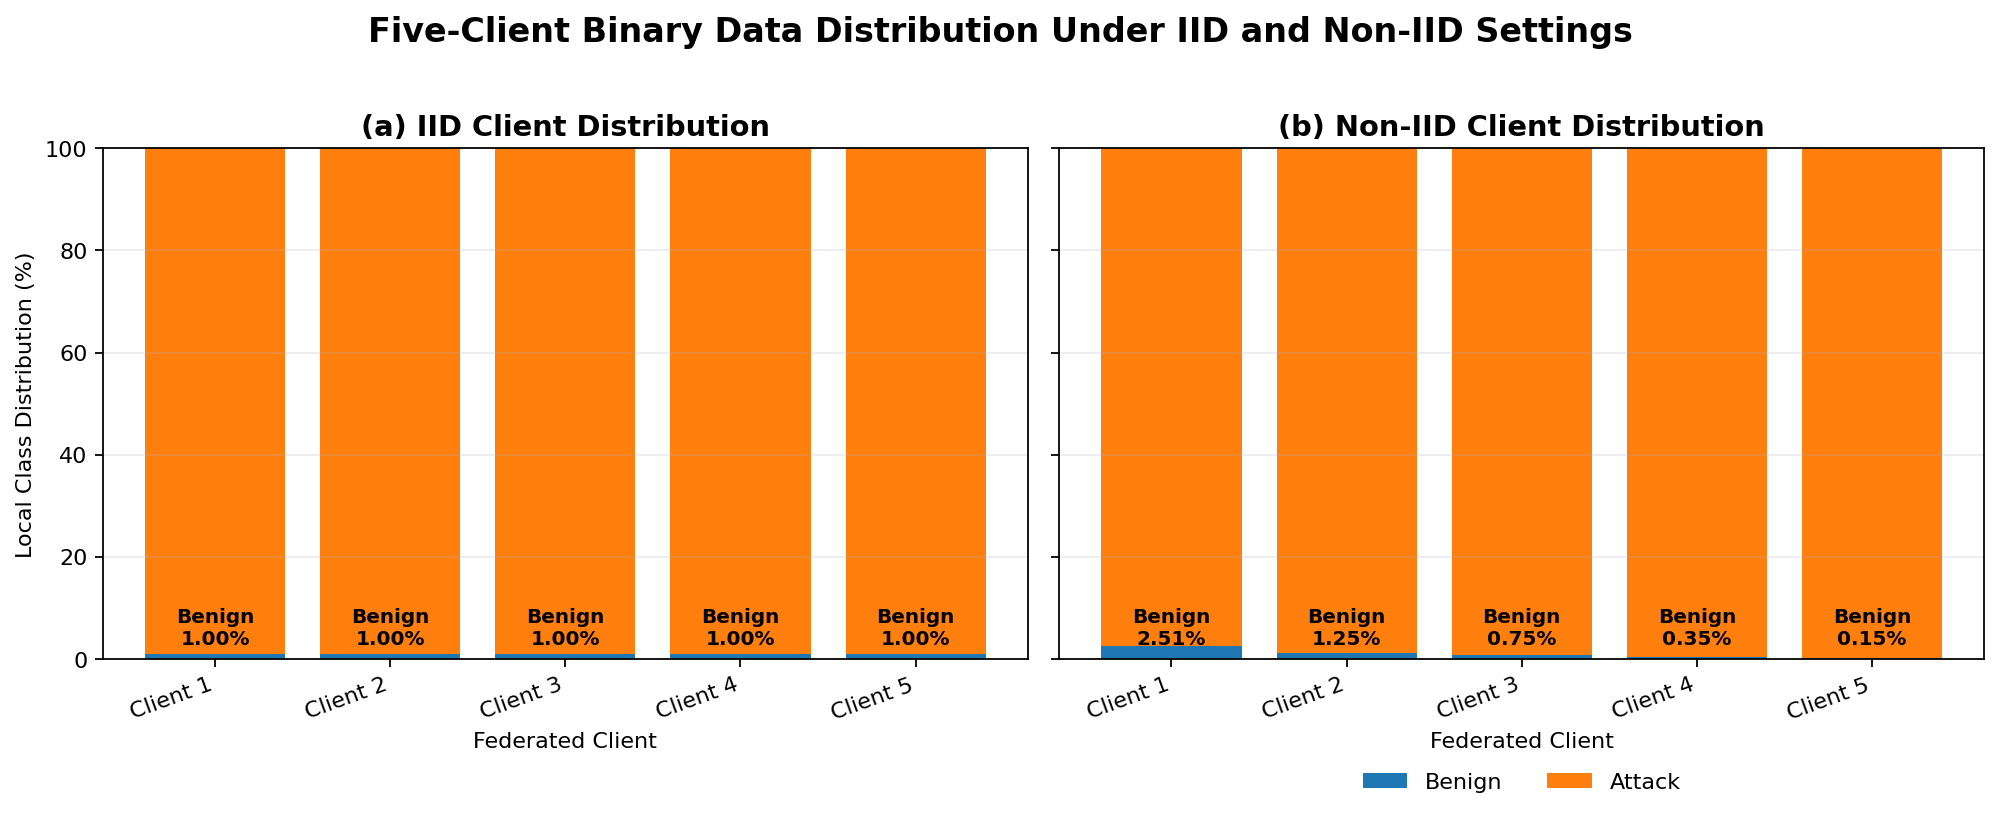

IID CLIENT DISTRIBUTION


,Setting,Client,Total,Benign,Attack,Benign %,Attack %
0,IID,Client 1,467621,4694,462927,1.003804,98.996196
1,IID,Client 2,467621,4694,462927,1.003804,98.996196
2,IID,Client 3,467620,4693,462927,1.003593,98.996407
3,IID,Client 4,467620,4693,462927,1.003593,98.996407
4,IID,Client 5,467620,4693,462927,1.003593,98.996407



NON-IID CLIENT DISTRIBUTION


,Setting,Client,Total,Benign,Attack,Benign %,Attack %
0,Non-IID,Client 1,467621,11733,455888,2.509083,97.490917
1,Non-IID,Client 2,467621,5867,461754,1.254649,98.745351
2,Non-IID,Client 3,467620,3520,464100,0.752748,99.247252
3,Non-IID,Client 4,467620,1643,465977,0.351354,99.648646
4,Non-IID,Client 5,467620,704,466916,0.150550,99.849450



Saved PNG: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/partition/IID_vs_NonIID_Client_Distribution.png
Saved PDF: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/partition/IID_vs_NonIID_Client_Distribution.pdf

✅ Distribution figure generated from actual saved assignments.
✅ No FL model or result file was modified.


In [ ]:
# ================================================================
# CLIENT DATA DISTRIBUTION FIGURE — IID vs NON-IID
# ================================================================
# Generated directly from the ACTUAL saved partition assignments.
# No model is trained or modified in this cell.
#
# SAVES:
#   federated_binary/partition/IID_vs_NonIID_Client_Distribution.png
#   federated_binary/partition/IID_vs_NonIID_Client_Distribution.pdf
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CLIENT_DISTRIBUTION_PNG = os.path.join(
    PARTITION_DIR,
    "IID_vs_NonIID_Client_Distribution.png"
)

CLIENT_DISTRIBUTION_PDF = os.path.join(
    PARTITION_DIR,
    "IID_vs_NonIID_Client_Distribution.pdf"
)

required_distribution_files = [
    PARTITION_FILE,
    NONIID_PARTITION_FILE,
    Y_TRAIN_FILE
]

missing_distribution_files = [
    path
    for path in required_distribution_files
    if not os.path.exists(path)
]

if missing_distribution_files:
    raise FileNotFoundError(
        "Run the IID and Non-IID partition cells first.\n\n"
        + "\n".join(missing_distribution_files)
    )

y_distribution = np.load(
    Y_TRAIN_FILE,
    mmap_mode="r"
)

with np.load(
    PARTITION_FILE,
    allow_pickle=False
) as iid_saved:

    iid_assignment_plot = np.asarray(
        iid_saved["assignment"],
        dtype=np.uint8
    )

with np.load(
    NONIID_PARTITION_FILE,
    allow_pickle=False
) as noniid_saved:

    noniid_assignment_plot = np.asarray(
        noniid_saved["assignment"],
        dtype=np.int8
    )


def build_distribution(
    assignment_array,
    setting_name
):

    rows = []

    for client_id in range(5):

        client_idx = np.flatnonzero(
            assignment_array == client_id
        )

        client_labels = np.asarray(
            y_distribution[client_idx],
            dtype=np.int8
        )

        counts = np.bincount(
            client_labels,
            minlength=2
        )

        total = int(
            len(client_idx)
        )

        benign = int(
            counts[0]
        )

        attack = int(
            counts[1]
        )

        rows.append({
            "Setting": setting_name,
            "Client": f"Client {client_id + 1}",
            "Total": total,
            "Benign": benign,
            "Attack": attack,
            "Benign %":
                100.0 * benign / total,
            "Attack %":
                100.0 * attack / total
        })

    return pd.DataFrame(
        rows
    )


iid_client_distribution = build_distribution(
    iid_assignment_plot,
    "IID"
)

noniid_client_distribution = build_distribution(
    noniid_assignment_plot,
    "Non-IID"
)

# Exact integrity checks.
if (
    int(iid_client_distribution["Total"].sum())
    != int(noniid_client_distribution["Total"].sum())
):
    raise RuntimeError(
        "IID and Non-IID federated-training totals differ."
    )

noniid_validation_indices_plot = np.flatnonzero(
    noniid_assignment_plot == -1
)

expected_noniid_benign = get_expected_benign_counts(
    y_distribution,
    noniid_validation_indices_plot,
    BENIGN_ALLOCATION
)

observed_noniid_benign = (
    noniid_client_distribution[
        "Benign"
    ]
    .astype(int)
    .tolist()
)

if (
    observed_noniid_benign
    != expected_noniid_benign
):
    raise RuntimeError(
        "Non-IID distribution is not the frozen "
        "50/25/15/7/3 Benign allocation."
    )

clients = (
    iid_client_distribution[
        "Client"
    ]
    .tolist()
)

iid_benign = (
    iid_client_distribution[
        "Benign %"
    ]
    .to_numpy()
)

iid_attack = (
    iid_client_distribution[
        "Attack %"
    ]
    .to_numpy()
)

noniid_benign = (
    noniid_client_distribution[
        "Benign %"
    ]
    .to_numpy()
)

noniid_attack = (
    noniid_client_distribution[
        "Attack %"
    ]
    .to_numpy()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.6, 5.2),
    dpi=160,
    sharey=True
)

plot_specs = [
    (
        axes[0],
        iid_benign,
        iid_attack,
        "(a) IID Client Distribution"
    ),
    (
        axes[1],
        noniid_benign,
        noniid_attack,
        "(b) Non-IID Client Distribution"
    )
]

for (
    axis,
    benign_percent,
    attack_percent,
    title
) in plot_specs:

    x = np.arange(
        len(clients)
    )

    axis.bar(
        x,
        benign_percent,
        label="Benign"
    )

    axis.bar(
        x,
        attack_percent,
        bottom=benign_percent,
        label="Attack"
    )

    # Minority-class percentages are annotated because
    # the dataset is strongly imbalanced.
    for position, value in enumerate(
        benign_percent
    ):
        axis.text(
            position,
            2.0,
            f"Benign\n{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    axis.set_xticks(
        x
    )

    axis.set_xticklabels(
        clients,
        rotation=20,
        ha="right"
    )

    axis.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    axis.set_xlabel(
        "Federated Client"
    )

    axis.set_ylim(
        0,
        100
    )

    axis.grid(
        axis="y",
        alpha=0.25
    )

axes[0].set_ylabel(
    "Local Class Distribution (%)"
)

axes[1].legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Five-Client Binary Data Distribution Under IID and Non-IID Settings",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

fig.tight_layout()

fig.savefig(
    CLIENT_DISTRIBUTION_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    CLIENT_DISTRIBUTION_PDF,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

print("=" * 92)
print("IID CLIENT DISTRIBUTION")
print("=" * 92)
display(
    iid_client_distribution
)

print("\n" + "=" * 92)
print("NON-IID CLIENT DISTRIBUTION")
print("=" * 92)
display(
    noniid_client_distribution
)

print(
    "\nSaved PNG:",
    CLIENT_DISTRIBUTION_PNG
)

print(
    "Saved PDF:",
    CLIENT_DISTRIBUTION_PDF
)

print(
    "\n✅ Distribution figure generated from actual saved assignments."
)
print(
    "✅ No FL model or result file was modified."
)


In [ ]:
# ================================================================
# CELL 20: NON-IID FEDAVG TRAINING
# FINAL + RESUMABLE + CPU/GPU COMPATIBLE
# + SAFE PRECISION-POLICY HANDLING
# + MINIMAL DRIVE STORAGE
# ================================================================
#
# NON-IID:
#   Controlled Strong Minority-Class Label Skew
#   Benign allocation = 50% / 25% / 15% / 7% / 3%
#
# FIXED PROTOCOL:
#   Clients       = 5
#   Rounds        = 20
#   Local epochs  = 1
#   Batch size    = 2048
#   Local LR      = 0.001
#   Aggregation   = sample-size weighted FedAvg
#   Final model   = Round-20 endpoint
#
# CPU/GPU:
#   GPU -> mixed_float16
#   CPU -> float32
#
# PRECISION SAFETY:
#   - If no safe training checkpoint exists:
#       CPU/GPU precision may be updated automatically.
#
#   - If a partial experiment has a safe checkpoint:
#       precision must stay the same for resume.
#
#   - If the experiment is already complete:
#       runtime may be CPU or GPU because no training is resumed.
#
# DRIVE STORAGE AFTER COMPLETION:
#   1. config.json
#   2. round_history.csv
#   3. FedAvg_Round20_Final.keras
#
# TEMPORARY DURING TRAINING:
#   - ONE rolling checkpoint only
#   - removed after successful Round 20
#
# DOES NOT SAVE:
#   - client datasets
#   - per-round models
#   - best-model copy
#   - predictions
#   - figures
#   - classification report
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import re
import gc
import json
import time
import shutil
import hashlib

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score
)


# ----------------------------------------------------------------
# 2. Required existing notebook objects
# ----------------------------------------------------------------

required_globals = [
    "FL_ROOT",
    "PARTITION_FILE",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "X_train_scaled",
    "y_train",
    "NUM_FEATURES",
    "RANDOM_SEED",
    "NUM_CLIENTS",
    "CLIENTS_PER_ROUND",
    "LOCAL_EPOCHS",
    "LOCAL_BATCH_SIZE",
    "LEARNING_RATE",
    "MAX_ROUNDS",
    "build_federated_binary_model"
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise RuntimeError(
        "Run the existing setup/data and architecture cells first.\n"
        f"Missing: {missing_globals}"
    )


# ----------------------------------------------------------------
# 3. Freeze final experimental protocol
# ----------------------------------------------------------------

EXPECTED_PROTOCOL = {
    "NUM_CLIENTS": 5,
    "CLIENTS_PER_ROUND": 5,
    "LOCAL_EPOCHS": 1,
    "LOCAL_BATCH_SIZE": 2048,
    "MAX_ROUNDS": 20
}


for name, expected_value in EXPECTED_PROTOCOL.items():

    actual_value = int(
        globals()[name]
    )

    if actual_value != expected_value:

        raise RuntimeError(
            f"Protocol mismatch: "
            f"{name}={actual_value}, "
            f"expected {expected_value}."
        )


if not np.isclose(
    float(LEARNING_RATE),
    0.001
):

    raise RuntimeError(
        "Protocol mismatch: "
        f"LEARNING_RATE={LEARNING_RATE}, "
        "expected 0.001."
    )


# ----------------------------------------------------------------
# 4. CPU / GPU automatic precision
# ----------------------------------------------------------------

def set_noniid_training_precision():

    gpu_available = bool(
        tf.config.list_physical_devices(
            "GPU"
        )
    )


    if gpu_available:

        policy = "mixed_float16"
        device = "GPU"

    else:

        policy = "float32"
        device = "CPU"


    mixed_precision.set_global_policy(
        policy
    )


    return (
        device,
        policy
    )


NI_DEVICE, NI_PRECISION = (
    set_noniid_training_precision()
)


print(
    "=" * 88
)

print(
    "NON-IID FEDAVG — STRONG LABEL-SKEW — 5 CLIENTS"
)

print(
    "=" * 88
)

print(
    "Runtime device :",
    NI_DEVICE
)

print(
    "Precision      :",
    NI_PRECISION
)


if NI_DEVICE == "CPU":

    print(
        "⚠️ CPU is supported, "
        "but 20 rounds will be much slower than GPU."
    )


# ----------------------------------------------------------------
# 5. Dedicated Non-IID FedAvg paths
# ----------------------------------------------------------------

NI_EXPERIMENT_NAME = (
    "FedAvg_NonIID_StrongLabelSkew_5Clients_"
    "CNN-LSTM-ResNet_Binary"
)


NI_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedAvg"
)


NI_MODEL_DIR = os.path.join(
    NI_ROOT,
    "model"
)


NI_RESULT_DIR = os.path.join(
    NI_ROOT,
    "result"
)


NI_CHECKPOINT_DIR = os.path.join(
    NI_ROOT,
    "checkpoint"
)


for directory in [
    NI_ROOT,
    NI_MODEL_DIR,
    NI_RESULT_DIR,
    NI_CHECKPOINT_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


NI_PARTITION_FILE = os.path.join(
    FL_ROOT,
    "partition",
    "NonIID",
    "Strong_LabelSkew_5Clients_Binary_partition.npz"
)


NI_CONFIG_FILE = os.path.join(
    NI_ROOT,
    "config.json"
)


NI_HISTORY_FILE = os.path.join(
    NI_RESULT_DIR,
    "round_history.csv"
)


NI_FINAL_MODEL_FILE = os.path.join(
    NI_MODEL_DIR,
    "FedAvg_Round20_Final.keras"
)


# ----------------------------------------------------------------
# 6. Verify required partition files
# ----------------------------------------------------------------

if not os.path.exists(
    NI_PARTITION_FILE
):

    raise FileNotFoundError(
        "Non-IID partition missing.\n"
        "Run Cell 19 first:\n" + NI_PARTITION_FILE
    )


if not os.path.exists(
    PARTITION_FILE
):

    raise FileNotFoundError(
        "Original IID partition missing.\n"
        "Cannot verify shared validation set:\n"
        + PARTITION_FILE
    )


# ----------------------------------------------------------------
# 7. Load Non-IID partition
# ----------------------------------------------------------------

with np.load(
    NI_PARTITION_FILE,
    allow_pickle=False
) as saved_partition:

    if (
        "assignment"
        not in saved_partition.files
    ):

        raise RuntimeError(
            "Non-IID partition has no "
            "'assignment' array."
        )


    ni_assignment = np.asarray(
        saved_partition[
            "assignment"
        ],
        dtype=np.int8
    )


    if (
        "benign_allocation"
        in saved_partition.files
    ):

        saved_benign_allocation = np.asarray(
            saved_partition[
                "benign_allocation"
            ],
            dtype=np.float64
        )

    else:

        saved_benign_allocation = None


# ----------------------------------------------------------------
# 8. Basic partition integrity
# ----------------------------------------------------------------

if (
    ni_assignment.ndim != 1
    or len(ni_assignment) != len(y_train)
):

    raise RuntimeError(
        "Non-IID partition size does not "
        "match training data."
    )


allowed_codes = {
    -1,
    0,
    1,
    2,
    3,
    4
}


found_codes = set(
    np.unique(
        ni_assignment
    )
    .astype(int)
    .tolist()
)


unexpected_codes = (
    found_codes - allowed_codes
)


if unexpected_codes:

    raise RuntimeError(
        "Unexpected Non-IID partition codes: "
        + str(
            unexpected_codes
        )
    )


# ----------------------------------------------------------------
# 9. Reconstruct Non-IID indices from Drive
# ----------------------------------------------------------------

ni_validation_indices = np.flatnonzero(
    ni_assignment == -1
).astype(
    np.int32,
    copy=False
)


ni_client_indices = [

    np.flatnonzero(
        ni_assignment == client_id
    ).astype(
        np.int32,
        copy=False
    )

    for client_id
    in range(5)

]


# ----------------------------------------------------------------
# 10. Verify SAME validation set as IID
# ----------------------------------------------------------------

with np.load(
    PARTITION_FILE,
    allow_pickle=False
) as iid_saved_partition:

    iid_assignment = np.asarray(
        iid_saved_partition[
            "assignment"
        ]
    )


iid_validation_indices = np.flatnonzero(
    iid_assignment == np.uint8(255)
).astype(
    np.int32,
    copy=False
)


if not np.array_equal(

    np.sort(
        ni_validation_indices
    ),

    np.sort(
        iid_validation_indices
    )

):

    raise RuntimeError(
        "Non-IID validation set is NOT "
        "identical to IID validation set."
    )


# ----------------------------------------------------------------
# 11. Verify client sizes + class distributions
# ----------------------------------------------------------------

client_sizes = np.asarray(

    [
        len(indices)
        for indices
        in ni_client_indices
    ],

    dtype=np.int64
)


if (
    client_sizes.max()
    - client_sizes.min()
    > 1
):

    raise RuntimeError(
        "Non-IID client sizes are not "
        "approximately equal."
    )


if int(

    client_sizes.sum()
    + len(
        ni_validation_indices
    )

) != len(y_train):

    raise RuntimeError(
        "Partition integrity failure."
    )


benign_counts = []
attack_counts = []


for client_id, indices in enumerate(
    ni_client_indices
):

    labels = np.asarray(
        y_train[
            indices
        ],
        dtype=np.int8
    )


    counts = np.bincount(
        labels,
        minlength=2
    )


    benign_counts.append(
        int(
            counts[0]
        )
    )


    attack_counts.append(
        int(
            counts[1]
        )
    )


    if (
        counts[0] <= 0
        or counts[1] <= 0
    ):

        raise RuntimeError(
            f"Client {client_id + 1} "
            "does not contain both classes."
        )


benign_counts = np.asarray(
    benign_counts,
    dtype=np.int64
)


attack_counts = np.asarray(
    attack_counts,
    dtype=np.int64
)


EXPECTED_BENIGN_SHARE = np.asarray(
    [
        0.50,
        0.25,
        0.15,
        0.07,
        0.03
    ],
    dtype=np.float64
)


actual_benign_share = (
    benign_counts
    / benign_counts.sum()
)


allocation_tolerance = (
    1.0 / benign_counts.sum()
    + 1e-8
)


if not np.allclose(
    actual_benign_share,
    EXPECTED_BENIGN_SHARE,
    atol=allocation_tolerance
):

    raise RuntimeError(
        "Saved Non-IID benign allocation "
        "does not match 50/25/15/7/3 design."
    )


if (
    saved_benign_allocation
    is not None
):

    if not np.allclose(
        saved_benign_allocation,
        EXPECTED_BENIGN_SHARE,
        atol=1e-7
    ):

        raise RuntimeError(
            "Saved partition metadata does not "
            "match 50/25/15/7/3 design."
        )


partition_sha256 = hashlib.sha256(
    ni_assignment.tobytes()
).hexdigest()


print(
    "\n✅ Non-IID partition verified."
)

print(
    "✅ Same validation set as IID verified."
)

print(
    "Client sizes :",
    client_sizes.tolist()
)

print(
    "Benign counts:",
    benign_counts.tolist()
)

print(
    "Attack counts:",
    attack_counts.tolist()
)


# ----------------------------------------------------------------
# 12. Tiny reproducibility config
#
# IMPORTANT:
# precision_policy is handled separately.
#
# Reason:
# GPU -> mixed_float16
# CPU -> float32
#
# Changing runtime before training begins is safe.
# Changing precision while resuming a partially trained
# experiment is NOT allowed.
# ----------------------------------------------------------------

NI_CONFIG = {

    "experiment_name":
        NI_EXPERIMENT_NAME,

    "algorithm":
        "FedAvg",

    "partition_type":
        "Strong minority-class label-skew Non-IID",

    "benign_allocation":
        [
            0.50,
            0.25,
            0.15,
            0.07,
            0.03
        ],

    "partition_sha256":
        partition_sha256,

    "random_seed":
        int(
            RANDOM_SEED
        ),

    "num_clients":
        5,

    "clients_per_round":
        5,

    "local_epochs":
        1,

    "local_batch_size":
        2048,

    "learning_rate":
        0.001,

    "max_rounds":
        20,

    "architecture":
        "CNN-LSTM-ResNet",

    "num_features":
        int(
            NUM_FEATURES
        ),

    "validation_policy":
        "Same global validation set as IID",

    "final_model_policy":
        "Round-20 endpoint",

    "precision_policy":
        NI_PRECISION
}


# ------------------------------------------------------------
# Experimental settings that MUST NEVER change
# when resuming.
#
# precision_policy is intentionally NOT included here.
# It is checked separately below.
# ------------------------------------------------------------

IMMUTABLE_KEYS = [

    "algorithm",
    "partition_type",
    "benign_allocation",
    "partition_sha256",
    "random_seed",
    "num_clients",
    "clients_per_round",
    "local_epochs",
    "local_batch_size",
    "learning_rate",
    "max_rounds",
    "architecture",
    "num_features",
    "validation_policy",
    "final_model_policy"

]


def save_json_atomic(
    path,
    data
):

    temp_path = (
        path + ".tmp"
    )


    with open(
        temp_path,
        "w"
    ) as file:

        json.dump(
            data,
            file,
            indent=2
        )


    os.replace(
        temp_path,
        path
    )


# ================================================================
# CONFIG LOAD / VALIDATION
# ================================================================

if os.path.exists(
    NI_CONFIG_FILE
):

    with open(
        NI_CONFIG_FILE,
        "r"
    ) as file:

        old_config = json.load(
            file
        )


    # ------------------------------------------------------------
    # A. Verify true experimental settings
    # ------------------------------------------------------------

    mismatches = {}


    for key in IMMUTABLE_KEYS:

        if (
            old_config.get(key)
            != NI_CONFIG.get(key)
        ):

            mismatches[
                key
            ] = {

                "saved":
                    old_config.get(key),

                "current":
                    NI_CONFIG.get(key)
            }


    if mismatches:

        raise RuntimeError(
            "Non-IID FedAvg configuration mismatch.\n"
            "Do NOT resume with changed experimental settings.\n"
            + json.dumps(
                mismatches,
                indent=2
            )
        )


    # ------------------------------------------------------------
    # B. Detect actual saved experiment state
    # ------------------------------------------------------------

    safe_checkpoint_files = []


    if os.path.isdir(
        NI_CHECKPOINT_DIR
    ):

        for filename in os.listdir(
            NI_CHECKPOINT_DIR
        ):

            if re.fullmatch(
                r"round_\d{2}\.weights\.h5",
                filename
            ):

                safe_checkpoint_files.append(
                    os.path.join(
                        NI_CHECKPOINT_DIR,
                        filename
                    )
                )


    has_safe_checkpoint = (
        len(
            safe_checkpoint_files
        ) > 0
    )


    final_model_exists = (
        os.path.exists(
            NI_FINAL_MODEL_FILE
        )
    )


    saved_completed = bool(
        old_config.get(
            "completed",
            False
        )
    )


    saved_final_round = int(
        old_config.get(
            "final_model_round"
        )
        or 0
    )


    config_says_complete = (
        saved_completed
        and saved_final_round == 20
    )


    # ------------------------------------------------------------
    # C. Integrity protection
    #
    # config cannot claim a completed experiment if the
    # actual Round-20 model does not exist.
    # ------------------------------------------------------------

    if (
        config_says_complete
        and not final_model_exists
    ):

        raise RuntimeError(
            "Non-IID FedAvg config says the experiment "
            "is complete at Round 20, but the Round-20 "
            "final model is missing.\n"
            "Nothing was overwritten."
        )


    # ------------------------------------------------------------
    # D. Precision policy handling
    # ------------------------------------------------------------

    saved_precision = old_config.get(
        "precision_policy"
    )


    current_precision = NI_CONFIG[
        "precision_policy"
    ]


    # ------------------------------------------------------------
    # Old config without precision metadata
    # ------------------------------------------------------------

    if saved_precision is None:

        if has_safe_checkpoint:

            raise RuntimeError(
                "A resumable Non-IID FedAvg checkpoint exists, "
                "but the saved config has no precision-policy "
                "metadata.\n"
                "Safe automatic resume is not possible."
            )


        old_config[
            "precision_policy"
        ] = current_precision


        save_json_atomic(
            NI_CONFIG_FILE,
            old_config
        )


        saved_precision = (
            current_precision
        )


        print(
            "\n✅ Missing precision metadata added:",
            current_precision
        )


    precision_changed = (
        saved_precision
        != current_precision
    )


    # ------------------------------------------------------------
    # Case 1:
    # Completed experiment.
    #
    # Runtime may differ because no training will resume.
    # Keep the original saved precision metadata.
    # ------------------------------------------------------------

    if (
        precision_changed
        and final_model_exists
    ):

        print(
            "\nℹ️ Completed Non-IID FedAvg model "
            "was created under a different precision policy."
        )


        print(
            "Saved precision  :",
            saved_precision
        )


        print(
            "Current runtime  :",
            current_precision
        )


        print(
            "✅ Allowed because training is already complete."
        )


    # ------------------------------------------------------------
    # Case 2:
    # Partial experiment with safe checkpoint.
    #
    # DO NOT mix precision policies.
    # ------------------------------------------------------------

    elif (
        precision_changed
        and has_safe_checkpoint
    ):

        raise RuntimeError(
            "Non-IID FedAvg has a resumable training checkpoint "
            "created under a different precision policy.\n\n"
            f"Saved precision  : {saved_precision}\n"
            f"Current precision: {current_precision}\n\n"
            "Do NOT mix GPU/mixed_float16 and CPU/float32 "
            "inside the same partially completed experiment.\n"
            "Resume using the original runtime, or restart "
            "this Non-IID FedAvg experiment from Round 1."
        )


    # ------------------------------------------------------------
    # Case 3:
    # No safe checkpoint and no final model.
    #
    # Training has no safe state to resume.
    # Therefore current runtime precision may safely become
    # the experiment precision.
    #
    # Any history without checkpoint is later cleared and the
    # experiment starts fresh from Round 1.
    # ------------------------------------------------------------

    elif precision_changed:

        old_config[
            "precision_policy"
        ] = current_precision


        old_config[
            "completed"
        ] = False


        old_config[
            "final_model_round"
        ] = None


        old_config.pop(
            "completed_precision_policy",
            None
        )


        old_config.pop(
            "completed_device",
            None
        )


        save_json_atomic(
            NI_CONFIG_FILE,
            old_config
        )


        print(
            "\n✅ Precision policy updated safely."
        )


        print(
            "Previous precision:",
            saved_precision
        )


        print(
            "Current precision :",
            current_precision
        )


        print(
            "✅ No resumable checkpoint or final model exists."
        )


        print(
            "✅ Experiment will start fresh under "
            "the current runtime if necessary."
        )


    ni_runtime_config = (
        old_config
    )


else:

    ni_runtime_config = dict(
        NI_CONFIG
    )


    ni_runtime_config[
        "completed"
    ] = False


    ni_runtime_config[
        "final_model_round"
    ] = None


    save_json_atomic(
        NI_CONFIG_FILE,
        ni_runtime_config
    )


    print(
        "\n✅ New Non-IID FedAvg config created."
    )


# ----------------------------------------------------------------
# 13. History helpers
# ----------------------------------------------------------------

HISTORY_COLUMNS = [

    "Round",
    "Val_Loss",
    "Val_Accuracy",
    "Val_Macro_F1",
    "Val_Benign_Recall",
    "Round_Time_sec"

]


def load_history():

    if not os.path.exists(
        NI_HISTORY_FILE
    ):

        return pd.DataFrame(
            columns=HISTORY_COLUMNS
        )


    history = pd.read_csv(
        NI_HISTORY_FILE
    )


    missing_columns = [

        column
        for column
        in HISTORY_COLUMNS
        if column not in history.columns

    ]


    if missing_columns:

        raise RuntimeError(
            "Malformed Non-IID FedAvg history. "
            f"Missing: {missing_columns}"
        )


    if not history.empty:

        history[
            "Round"
        ] = history[
            "Round"
        ].astype(int)


        if history[
            "Round"
        ].duplicated().any():

            raise RuntimeError(
                "Duplicate rounds found "
                "in Non-IID FedAvg history."
            )


    return (
        history
        .sort_values(
            "Round"
        )
        .reset_index(
            drop=True
        )
    )


def save_history_atomic(
    history
):

    temp_path = (
        NI_HISTORY_FILE
        + ".tmp.csv"
    )


    history.to_csv(
        temp_path,
        index=False
    )


    os.replace(
        temp_path,
        NI_HISTORY_FILE
    )


# ----------------------------------------------------------------
# 14. Rolling checkpoint helpers
# ----------------------------------------------------------------

checkpoint_regex = re.compile(
    r"^round_(\d{2})\.weights\.h5$"
)


def list_checkpoint_files():

    found = []


    if not os.path.isdir(
        NI_CHECKPOINT_DIR
    ):

        return found


    for filename in os.listdir(
        NI_CHECKPOINT_DIR
    ):

        match = checkpoint_regex.match(
            filename
        )


        if match:

            found.append(
                (
                    int(
                        match.group(1)
                    ),

                    os.path.join(
                        NI_CHECKPOINT_DIR,
                        filename
                    )
                )
            )


    return sorted(
        found
    )


def cleanup_checkpoints(
    keep_round=None
):

    for round_id, path in (
        list_checkpoint_files()
    ):

        if (
            keep_round is None
            or round_id != keep_round
        ):

            try:

                os.remove(
                    path
                )

            except FileNotFoundError:

                pass


def save_checkpoint_weights(
    model,
    round_number
):

    checkpoint_path = os.path.join(
        NI_CHECKPOINT_DIR,
        f"round_{round_number:02d}.weights.h5"
    )


    temp_path = os.path.join(
        NI_CHECKPOINT_DIR,
        f".round_{round_number:02d}.tmp.weights.h5"
    )


    if os.path.exists(
        temp_path
    ):

        os.remove(
            temp_path
        )


    model.save_weights(
        temp_path,
        overwrite=True
    )


    os.replace(
        temp_path,
        checkpoint_path
    )


    cleanup_checkpoints(
        keep_round=round_number
    )


    return checkpoint_path


# ----------------------------------------------------------------
# 15. Load history
# ----------------------------------------------------------------

history_df = (
    load_history()
)


# ================================================================
# 16. COMPLETED MODEL CHECK
# ================================================================

if os.path.exists(
    NI_FINAL_MODEL_FILE
):

    if (
        history_df.empty
        or int(
            history_df[
                "Round"
            ].max()
        ) != 20
    ):

        raise RuntimeError(
            "A Non-IID FedAvg final model exists, "
            "but history does not end at Round 20.\n"
            "Nothing was overwritten."
        )


    check_model = (
        tf.keras.models.load_model(
            NI_FINAL_MODEL_FILE,
            compile=False
        )
    )


    if int(
        check_model.count_params()
    ) != 60097:

        del check_model

        raise RuntimeError(
            "Existing Non-IID FedAvg final model "
            "has unexpected architecture."
        )


    del check_model


    tf.keras.backend.clear_session()

    gc.collect()

    set_noniid_training_precision()


    if (
        not bool(
            ni_runtime_config.get(
                "completed",
                False
            )
        )
        or int(
            ni_runtime_config.get(
                "final_model_round"
            )
            or -1
        ) != 20
    ):

        ni_runtime_config[
            "completed"
        ] = True


        ni_runtime_config[
            "final_model_round"
        ] = 20


        save_json_atomic(
            NI_CONFIG_FILE,
            ni_runtime_config
        )


    cleanup_checkpoints(
        keep_round=None
    )


    try:

        if (
            os.path.isdir(
                NI_CHECKPOINT_DIR
            )
            and not os.listdir(
                NI_CHECKPOINT_DIR
            )
        ):

            os.rmdir(
                NI_CHECKPOINT_DIR
            )

    except OSError:

        pass


    print(
        "\n✅ Non-IID FedAvg Round-20 "
        "final model already exists."
    )


    print(
        "✅ Training skipped."
    )


    print(
        "\nFinal model:"
    )


    print(
        NI_FINAL_MODEL_FILE
    )


# ================================================================
# 17. TRAIN / RESUME
# ================================================================

else:

    # ------------------------------------------------------------
    # Temporary LOCAL cache
    # ------------------------------------------------------------

    LOCAL_CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )


    os.makedirs(
        LOCAL_CACHE_DIR,
        exist_ok=True
    )


    LOCAL_X_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "X_train_scaled_float32.npy"
    )


    LOCAL_Y_TRAIN_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "y_train_int8.npy"
    )


    def copy_if_missing(
        source,
        destination
    ):

        if not os.path.exists(
            destination
        ):

            print(
                "Copying to temporary Colab disk:",
                os.path.basename(
                    source
                )
            )


            shutil.copy2(
                source,
                destination
            )


    copy_if_missing(
        X_TRAIN_FILE,
        LOCAL_X_TRAIN_FILE
    )


    copy_if_missing(
        Y_TRAIN_FILE,
        LOCAL_Y_TRAIN_FILE
    )


    X_train_fl = np.load(
        LOCAL_X_TRAIN_FILE,
        mmap_mode="r"
    )


    y_train_fl = np.load(
        LOCAL_Y_TRAIN_FILE,
        mmap_mode="r"
    )


    if (
        X_train_fl.shape
        != X_train_scaled.shape
    ):

        raise RuntimeError(
            "Local X_train cache shape mismatch."
        )


    if (
        y_train_fl.shape
        != y_train.shape
    ):

        raise RuntimeError(
            "Local y_train cache shape mismatch."
        )


    # ------------------------------------------------------------
    # Same global validation set
    # ------------------------------------------------------------

    X_val = np.asarray(
        X_train_fl[
            ni_validation_indices
        ],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    y_val = np.asarray(
        y_train_fl[
            ni_validation_indices
        ],
        dtype=np.int8
    )


    VAL_BATCH_SIZE = 4096


    print(
        "\nValidation samples:",
        f"{len(y_val):,}"
    )


    # ------------------------------------------------------------
    # Client dataset
    # ------------------------------------------------------------

    def create_noniid_client_dataset(
        client_id,
        round_number
    ):

        indices = (
            ni_client_indices[
                client_id
            ]
        )


        X_client = np.asarray(
            X_train_fl[
                indices
            ],
            dtype=np.float32
        )[
            ...,
            np.newaxis
        ]


        y_client = np.asarray(
            y_train_fl[
                indices
            ],
            dtype=np.int8
        )


        shuffle_seed = int(
            RANDOM_SEED
            + round_number * 100
            + client_id
        )


        dataset = (

            tf.data.Dataset
            .from_tensor_slices(
                (
                    X_client,
                    y_client
                )
            )
            .shuffle(
                buffer_size=min(
                    50000,
                    len(indices)
                ),
                seed=shuffle_seed,
                reshuffle_each_iteration=True
            )
            .batch(
                LOCAL_BATCH_SIZE,
                drop_remainder=False
            )
            .prefetch(
                tf.data.AUTOTUNE
            )

        )


        return (
            dataset,
            X_client,
            y_client
        )


    # ------------------------------------------------------------
    # Sample-size weighted FedAvg
    # ------------------------------------------------------------

    def add_weighted_client(
        accumulator,
        client_weights,
        sample_count
    ):

        if accumulator is None:

            return [

                np.asarray(
                    weight,
                    dtype=np.float64
                )
                * float(
                    sample_count
                )

                for weight
                in client_weights

            ]


        for index in range(
            len(
                accumulator
            )
        ):

            accumulator[
                index
            ] += (

                np.asarray(
                    client_weights[
                        index
                    ],
                    dtype=np.float64
                )
                * float(
                    sample_count
                )

            )


        return accumulator


    def finalize_weighted_average(
        accumulator,
        total_samples
    ):

        return [

            (
                weighted_sum
                / float(
                    total_samples
                )
            ).astype(
                np.float32
            )

            for weighted_sum
            in accumulator

        ]


    # ------------------------------------------------------------
    # Global validation
    # ------------------------------------------------------------

    def evaluate_global_weights(
        global_weights
    ):

        set_noniid_training_precision()


        model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        model.set_weights(
            global_weights
        )


        probability_parts = []


        for start in range(
            0,
            len(y_val),
            VAL_BATCH_SIZE
        ):

            end = min(
                start + VAL_BATCH_SIZE,
                len(y_val)
            )


            batch_x = (
                tf.convert_to_tensor(
                    X_val[
                        start:end
                    ],
                    dtype=tf.float32
                )
            )


            batch_probability = (

                model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
                .astype(
                    np.float32,
                    copy=False
                )

            )


            probability_parts.append(
                batch_probability
            )


        y_probability = np.concatenate(
            probability_parts
        )


        y_prediction = (
            y_probability >= 0.5
        ).astype(
            np.int8
        )


        epsilon = 1e-7


        clipped = np.clip(
            y_probability,
            epsilon,
            1.0 - epsilon
        )


        val_loss = float(

            -np.mean(

                y_val
                * np.log(
                    clipped
                )

                +

                (
                    1 - y_val
                )
                * np.log(
                    1.0 - clipped
                )

            )

        )


        val_accuracy = float(
            accuracy_score(
                y_val,
                y_prediction
            )
        )


        val_macro_f1 = float(
            f1_score(
                y_val,
                y_prediction,
                average="macro",
                zero_division=0
            )
        )


        val_benign_recall = float(
            recall_score(
                y_val,
                y_prediction,
                pos_label=0,
                zero_division=0
            )
        )


        del (
            probability_parts,
            y_probability,
            y_prediction,
            clipped
        )


        return (
            model,
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        )


    # ============================================================
    # 18. Resume from latest safe checkpoint OR fresh start
    # ============================================================

    checkpoint_files = (
        list_checkpoint_files()
    )


    if checkpoint_files:

        (
            last_completed_round,
            checkpoint_path
        ) = checkpoint_files[
            -1
        ]


        if (
            last_completed_round >= 20
        ):

            raise RuntimeError(
                "Unexpected Round-20 temporary "
                "checkpoint found."
            )


        if (
            history_df.empty
            or int(
                history_df[
                    "Round"
                ].max()
            ) < last_completed_round
        ):

            raise RuntimeError(
                "Checkpoint is ahead of history. "
                "Safe automatic resume is not possible."
            )


        if (
            not history_df.empty
            and int(
                history_df[
                    "Round"
                ].max()
            ) > last_completed_round
        ):

            history_df = history_df[
                history_df[
                    "Round"
                ] <= last_completed_round
            ].copy()


            save_history_atomic(
                history_df
            )


            print(
                "⚠️ Trimmed history beyond "
                "latest safe checkpoint."
            )


        set_noniid_training_precision()


        resume_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        resume_model.load_weights(
            checkpoint_path
        )


        global_weights = [

            np.asarray(
                weight,
                dtype=np.float32
            ).copy()

            for weight
            in resume_model.get_weights()

        ]


        del resume_model


        tf.keras.backend.clear_session()

        gc.collect()

        set_noniid_training_precision()


        START_ROUND = (
            last_completed_round + 1
        )


        cleanup_checkpoints(
            keep_round=last_completed_round
        )


        print(
            "\n🔄 RESUME MODE"
        )


        print(
            "Last safe completed round:",
            last_completed_round
        )


        print(
            "Next round:",
            START_ROUND
        )


    else:

        # --------------------------------------------------------
        # History without checkpoint cannot safely resume.
        # Start fresh from Round 1.
        # --------------------------------------------------------

        if not history_df.empty:

            print(
                "\n⚠️ Incomplete history exists "
                "but no checkpoint survives."
            )


            print(
                "Starting this experiment fresh "
                "from Round 1."
            )


            history_df = pd.DataFrame(
                columns=HISTORY_COLUMNS
            )


            save_history_atomic(
                history_df
            )


        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )


        set_noniid_training_precision()


        initial_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        global_weights = [

            np.asarray(
                weight,
                dtype=np.float32
            ).copy()

            for weight
            in initial_model.get_weights()

        ]


        del initial_model


        tf.keras.backend.clear_session()

        gc.collect()

        set_noniid_training_precision()


        START_ROUND = 1


        print(
            "\n🟢 FRESH NON-IID FEDAVG RUN"
        )


        print(
            "Round 1 → Round 20"
        )


    # ============================================================
    # 19. Federated communication rounds
    # ============================================================

    for round_number in range(
        START_ROUND,
        21
    ):

        round_start_time = (
            time.time()
        )


        print(
            "\n" + "=" * 72
        )


        print(
            f"NON-IID FEDAVG ROUND "
            f"{round_number}/20"
        )


        print(
            "=" * 72
        )


        weighted_accumulator = None

        total_samples = 0


        # --------------------------------------------------------
        # Train all 5 clients sequentially
        # --------------------------------------------------------

        for client_id in range(
            5
        ):

            client_start_time = (
                time.time()
            )


            print(
                f"\nClient "
                f"{client_id + 1}/5"
            )


            (
                client_dataset,
                X_client,
                y_client
            ) = create_noniid_client_dataset(
                client_id,
                round_number
            )


            client_sample_count = int(
                len(
                    y_client
                )
            )


            print(
                "Samples:",
                client_sample_count
            )


            print(
                "Benign :",
                int(
                    np.sum(
                        y_client == 0
                    )
                )
            )


            print(
                "Attack :",
                int(
                    np.sum(
                        y_client == 1
                    )
                )
            )


            # ----------------------------------------------------
            # Fresh local Adam state for every client
            # ----------------------------------------------------

            set_noniid_training_precision()


            local_model = (
                build_federated_binary_model(
                    compile_model=True
                )
            )


            local_model.set_weights(
                global_weights
            )


            local_model.fit(
                client_dataset,
                epochs=LOCAL_EPOCHS,
                verbose=0
            )


            local_weights = (
                local_model.get_weights()
            )


            weighted_accumulator = (
                add_weighted_client(
                    weighted_accumulator,
                    local_weights,
                    client_sample_count
                )
            )


            total_samples += (
                client_sample_count
            )


            print(
                f"Completed in "
                f"{time.time() - client_start_time:.1f} sec"
            )


            del (
                local_weights,
                local_model,
                client_dataset,
                X_client,
                y_client
            )


            tf.keras.backend.clear_session()

            gc.collect()

            set_noniid_training_precision()


        # --------------------------------------------------------
        # FedAvg aggregation
        # --------------------------------------------------------

        global_weights = (
            finalize_weighted_average(
                weighted_accumulator,
                total_samples
            )
        )


        del weighted_accumulator


        # --------------------------------------------------------
        # Global validation
        # --------------------------------------------------------

        (
            global_model,
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = evaluate_global_weights(
            global_weights
        )


        round_time = float(
            time.time()
            - round_start_time
        )


        print(
            "\nGlobal validation:"
        )


        print(
            f"  Loss         : "
            f"{val_loss:.6f}"
        )


        print(
            f"  Accuracy     : "
            f"{val_accuracy:.6f}"
        )


        print(
            f"  Macro F1     : "
            f"{val_macro_f1:.6f}"
        )


        print(
            f"  Benign Recall: "
            f"{val_benign_recall:.6f}"
        )


        print(
            f"  Round time   : "
            f"{round_time:.1f} sec"
        )


        # --------------------------------------------------------
        # Update history
        # --------------------------------------------------------

        new_row = pd.DataFrame(
            [
                {
                    "Round":
                        int(
                            round_number
                        ),

                    "Val_Loss":
                        float(
                            val_loss
                        ),

                    "Val_Accuracy":
                        float(
                            val_accuracy
                        ),

                    "Val_Macro_F1":
                        float(
                            val_macro_f1
                        ),

                    "Val_Benign_Recall":
                        float(
                            val_benign_recall
                        ),

                    "Round_Time_sec":
                        round_time
                }
            ]
        )


        history_df = history_df[
            history_df[
                "Round"
            ] != round_number
        ].copy()


        history_df = (

            pd.concat(
                [
                    history_df,
                    new_row
                ],
                ignore_index=True
            )
            .sort_values(
                "Round"
            )
            .reset_index(
                drop=True
            )

        )


        # --------------------------------------------------------
        # Save history FIRST
        # --------------------------------------------------------

        save_history_atomic(
            history_df
        )


        # ========================================================
        # Rounds 1-19
        # ========================================================

        if (
            round_number < 20
        ):

            checkpoint_path = (
                save_checkpoint_weights(
                    global_model,
                    round_number
                )
            )


            print(
                "✅ Safe rolling checkpoint:",
                os.path.basename(
                    checkpoint_path
                )
            )


        # ========================================================
        # Round 20
        # ========================================================

        else:

            temporary_final = os.path.join(
                NI_MODEL_DIR,
                ".FedAvg_Round20_Final.temp.keras"
            )


            if os.path.exists(
                temporary_final
            ):

                os.remove(
                    temporary_final
                )


            global_model.save(
                temporary_final,
                overwrite=True
            )


            os.replace(
                temporary_final,
                NI_FINAL_MODEL_FILE
            )


            ni_runtime_config[
                "completed"
            ] = True


            ni_runtime_config[
                "final_model_round"
            ] = 20


            ni_runtime_config[
                "completed_precision_policy"
            ] = NI_PRECISION


            ni_runtime_config[
                "completed_device"
            ] = NI_DEVICE


            save_json_atomic(
                NI_CONFIG_FILE,
                ni_runtime_config
            )


            cleanup_checkpoints(
                keep_round=None
            )


            try:

                if (
                    os.path.isdir(
                        NI_CHECKPOINT_DIR
                    )
                    and not os.listdir(
                        NI_CHECKPOINT_DIR
                    )
                ):

                    os.rmdir(
                        NI_CHECKPOINT_DIR
                    )

            except OSError:

                pass


            print(
                "\n✅ ROUND-20 ENDPOINT SAVED:"
            )


            print(
                NI_FINAL_MODEL_FILE
            )


        # --------------------------------------------------------
        # Cleanup
        # --------------------------------------------------------

        del global_model


        tf.keras.backend.clear_session()

        gc.collect()

        set_noniid_training_precision()


    # ============================================================
    # 20. Final integrity verification
    # ============================================================

    final_history = pd.read_csv(
        NI_HISTORY_FILE
    )


    if (
        len(
            final_history
        ) != 20
        or int(
            final_history[
                "Round"
            ].min()
        ) != 1
        or int(
            final_history[
                "Round"
            ].max()
        ) != 20
    ):

        raise RuntimeError(
            "Final history is not exactly "
            "Round 1 through Round 20."
        )


    if final_history[
        "Round"
    ].duplicated().any():

        raise RuntimeError(
            "Duplicate rounds found "
            "in final history."
        )


    if not os.path.exists(
        NI_FINAL_MODEL_FILE
    ):

        raise RuntimeError(
            "Non-IID FedAvg Round-20 "
            "final model is missing."
        )


    # ============================================================
    # 21. Final status
    # ============================================================

    print(
        "\n" + "=" * 88
    )


    print(
        "NON-IID FEDAVG TRAINING COMPLETE"
    )


    print(
        "=" * 88
    )


    print(
        "Partition          : "
        "Strong label-skew Non-IID"
    )


    print(
        "Clients            : 5"
    )


    print(
        "Rounds             : 20"
    )


    print(
        "Final model policy : "
        "Round-20 endpoint"
    )


    print(
        "Runtime            :",
        NI_DEVICE
    )


    print(
        "Precision          :",
        NI_PRECISION
    )


    print(
        "\nPermanent Drive artifacts "
        "created by THIS training cell:"
    )


    print(
        "1.",
        NI_CONFIG_FILE
    )


    print(
        "2.",
        NI_HISTORY_FILE
    )


    print(
        "3.",
        NI_FINAL_MODEL_FILE
    )


    print(
        "\n✅ No per-round models kept."
    )


    print(
        "✅ No best-model copy kept."
    )


    print(
        "✅ No predictions saved yet."
    )


    print(
        "✅ No figures saved."
    )


    print(
        "✅ Temporary checkpoint removed "
        "after completion."
    )


    print(
        "✅ Existing IID results unchanged."
    )


    print(
        "=" * 88
    )


    del (
        X_val,
        y_val
    )


    gc.collect()


    tf.keras.backend.clear_session()

    set_noniid_training_precision()

NON-IID FEDAVG — STRONG LABEL-SKEW — 5 CLIENTS
Runtime device : CPU
Precision      : float32
⚠️ CPU is supported, but 20 rounds will be much slower than GPU.

✅ Non-IID partition verified.
✅ Same validation set as IID verified.
Client sizes : [467621, 467621, 467620, 467620, 467620]
Benign counts: [11733, 5867, 3520, 1643, 704]
Attack counts: [455888, 461754, 464100, 465977, 466916]

ℹ️ Completed Non-IID FedAvg model was created under a different precision policy.
Saved precision  : mixed_float16
Current runtime  : float32
✅ Allowed because training is already complete.

✅ Non-IID FedAvg Round-20 final model already exists.
✅ Training skipped.

Final model:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedAvg/model/FedAvg_Round20_Final.keras


NON-IID FEDAVG — FINAL TEST EVALUATION
Final model round : 20
Training device   : GPU
Training precision: mixed_float16
Inference device  : CPU
Best validation round: 20
Best validation Macro F1: 0.933760

✅ Existing final metrics belong to this exact Round-20 model.
✅ Test inference skipped.

Saved metrics:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedAvg/result/final_metrics.csv


,Algorithm,Architecture,Partition,NonIID_Type,Benign_Allocation,Clients,Communication_Rounds,Model_Round,Evaluation_Model_Policy,Threshold,...,FP,FN,TP,Test_Samples,Best_Validation_Round,Best_Validation_Macro_F1,Round20_Validation_Macro_F1,Training_Device,Training_Precision,Model_SHA256
0,FedAvg,CNN-LSTM-ResNet,Non-IID,Controlled Strong Minority-Class Label Skew,50/25/15/7/3,5,20,20,Round-20 endpoint,0.5,...,374,1586,641369,649474,20,0.93376,0.93376,GPU,mixed_float16,461fef3324e30644a32b838e7659b0c8b006ab0bfe8b12...



NON-IID FEDAVG — FIGURES


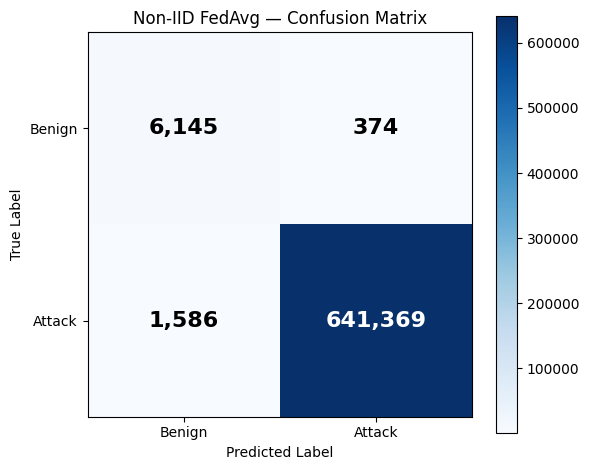

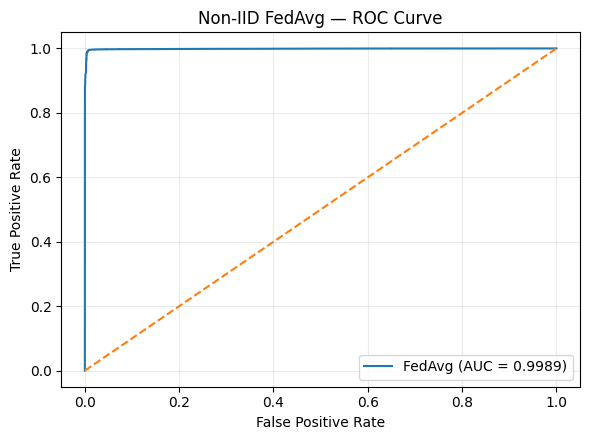

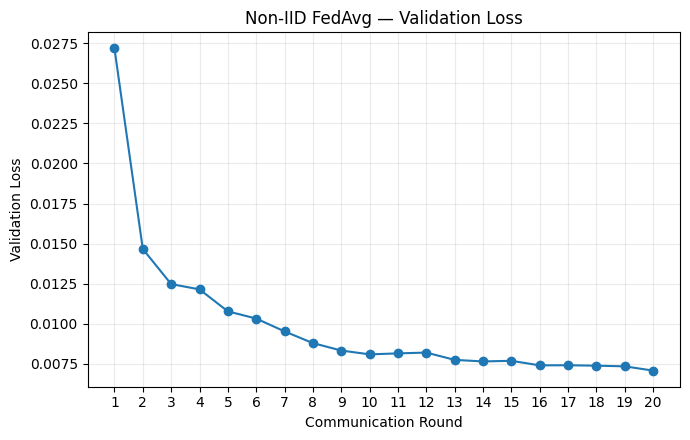


✅ FedAvg Confusion Matrix displayed.
✅ FedAvg ROC Curve displayed.
✅ FedAvg Validation Loss displayed.
✅ No figure saved to Drive.
✅ No prediction saved to Drive.
✅ Existing FedAvg metrics/model unchanged.


0

In [ ]:
# ================================================================
# CELL 21: NON-IID FEDAVG FINAL TEST EVALUATION
# MINIMAL DRIVE STORAGE
# ================================================================
#
# EVALUATES:
#   Non-IID FedAvg Round-20 endpoint
#
# SAVES ONLY:
#   final_metrics.csv
#
# DOES NOT SAVE:
#   - predictions
#   - figures
#   - classification report
#   - duplicate model
#
# CPU / GPU:
#   Both supported
#
# RE-RUN SAFE:
#   If metrics already correspond to the same final model,
#   inference is automatically skipped.
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import time
import hashlib

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)


# ----------------------------------------------------------------
# 2. Required paths
# ----------------------------------------------------------------

NI_FEDAVG_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedAvg"
)


NI_FEDAVG_MODEL_FILE = os.path.join(
    NI_FEDAVG_ROOT,
    "model",
    "FedAvg_Round20_Final.keras"
)


NI_FEDAVG_CONFIG_FILE = os.path.join(
    NI_FEDAVG_ROOT,
    "config.json"
)


NI_FEDAVG_HISTORY_FILE = os.path.join(
    NI_FEDAVG_ROOT,
    "result",
    "round_history.csv"
)


NI_FEDAVG_METRICS_FILE = os.path.join(
    NI_FEDAVG_ROOT,
    "result",
    "final_metrics.csv"
)


# ----------------------------------------------------------------
# 3. Verify required files
# ----------------------------------------------------------------

required_files = [
    NI_FEDAVG_MODEL_FILE,
    NI_FEDAVG_CONFIG_FILE,
    NI_FEDAVG_HISTORY_FILE,
    X_TEST_FILE,
    Y_TEST_FILE
]


for file_path in required_files:

    if not os.path.exists(
        file_path
    ):

        raise FileNotFoundError(
            "Required file missing:\n" + file_path
        )


# ----------------------------------------------------------------
# 4. Verify completed experiment
# ----------------------------------------------------------------

with open(
    NI_FEDAVG_CONFIG_FILE,
    "r"
) as file:

    ni_config = json.load(
        file
    )


if not bool(
    ni_config.get(
        "completed",
        False
    )
):

    raise RuntimeError(
        "Non-IID FedAvg experiment "
        "is not marked complete."
    )


if int(
    ni_config.get(
        "final_model_round"
    ) or -1
) != 20:

    raise RuntimeError(
        "Final model is not Round 20."
    )


if (
    ni_config.get(
        "final_model_policy"
    ) != "Round-20 endpoint"
):

    raise RuntimeError(
        "Unexpected final-model policy."
    )


# ----------------------------------------------------------------
# 5. Verify round history
# ----------------------------------------------------------------

history_df = pd.read_csv(
    NI_FEDAVG_HISTORY_FILE
)


if (
    len(history_df) != 20 or int(
        history_df[
            "Round"
        ].min()
    ) != 1 or int(
        history_df[
            "Round"
        ].max()
    ) != 20
):

    raise RuntimeError(
        "Round history is not exactly "
        "Round 1 through Round 20."
    )


if history_df[
    "Round"
].duplicated().any():

    raise RuntimeError(
        "Duplicate communication rounds found."
    )


best_val_row = history_df.loc[
    history_df[
        "Val_Macro_F1"
    ].idxmax()
]


best_validation_round = int(
    best_val_row[
        "Round"
    ]
)


best_validation_macro_f1 = float(
    best_val_row[
        "Val_Macro_F1"
    ]
)


round20_row = history_df[
    history_df[
        "Round"
    ] == 20
].iloc[0]


# ----------------------------------------------------------------
# 6. Compute model fingerprint
#
# Prevents accidental reuse of metrics belonging to
# a different model saved at the same path.
# ----------------------------------------------------------------

def sha256_file(
    file_path,
    chunk_size=1024 * 1024
):

    hasher = hashlib.sha256()


    with open(
        file_path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )


            if not chunk:

                break


            hasher.update(
                chunk
            )


    return hasher.hexdigest()


model_sha256 = sha256_file(
    NI_FEDAVG_MODEL_FILE
)


# ----------------------------------------------------------------
# 7. Runtime information
# ----------------------------------------------------------------

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices(
        "GPU"
    )
)


INFERENCE_DEVICE = (
    "GPU"
    if GPU_AVAILABLE
    else "CPU"
)


print(
    "=" * 88
)


print(
    "NON-IID FEDAVG — FINAL TEST EVALUATION"
)


print(
    "=" * 88
)


print(
    "Final model round : 20"
)


print(
    "Training device   :",
    ni_config.get(
        "completed_device",
        "Unknown"
    )
)


print(
    "Training precision:",
    ni_config.get(
        "completed_precision_policy",
        ni_config.get(
            "precision_policy",
            "Unknown"
        )
    )
)


print(
    "Inference device  :",
    INFERENCE_DEVICE
)


print(
    "Best validation round:",
    best_validation_round
)


print(
    f"Best validation Macro F1: "
    f"{best_validation_macro_f1:.6f}"
)


# ================================================================
# 8. RE-RUN SAFETY
#
# If final_metrics.csv already belongs to this exact model,
# do not perform test inference again.
# ================================================================

if os.path.exists(
    NI_FEDAVG_METRICS_FILE
):

    existing_metrics = pd.read_csv(
        NI_FEDAVG_METRICS_FILE
    )


    if (
        not existing_metrics.empty and "Model_SHA256"
        in existing_metrics.columns and str(
            existing_metrics.iloc[0][
                "Model_SHA256"
            ]
        ) == model_sha256 and int(
            existing_metrics.iloc[0].get(
                "Model_Round",
                -1
            )
        ) == 20
    ):

        print(
            "\n✅ Existing final metrics belong "
            "to this exact Round-20 model."
        )


        print(
            "✅ Test inference skipped."
        )


        print(
            "\nSaved metrics:"
        )


        print(
            NI_FEDAVG_METRICS_FILE
        )


        display(
            existing_metrics
        )


        EVALUATION_ALREADY_COMPLETE = True


    else:

        EVALUATION_ALREADY_COMPLETE = False


else:

    EVALUATION_ALREADY_COMPLETE = False


# ================================================================
# 9. Fresh test evaluation
# ================================================================

if not EVALUATION_ALREADY_COMPLETE:

    # ------------------------------------------------------------
    # Load untouched test data
    # ------------------------------------------------------------

    X_test_fl = np.load(
        X_TEST_FILE,
        mmap_mode="r"
    )


    y_true = np.asarray(
        np.load(
            Y_TEST_FILE,
            mmap_mode="r"
        ),
        dtype=np.int8
    ).reshape(-1)


    if (
        len(X_test_fl) != len(y_true)
    ):

        raise RuntimeError(
            "Test feature/label size mismatch."
        )


    print(
        "\nTest samples:",
        f"{len(y_true):,}"
    )


    print(
        "Benign:",
        f"{np.sum(y_true == 0):,}"
    )


    print(
        "Attack:",
        f"{np.sum(y_true == 1):,}"
    )


    # ------------------------------------------------------------
    # Load final Round-20 model
    # ------------------------------------------------------------

    tf.keras.backend.clear_session()


    final_model = (
        tf.keras.models.load_model(
            NI_FEDAVG_MODEL_FILE,
            compile=False
        )
    )


    if int(
        final_model.count_params()
    ) != 60097:

        raise RuntimeError(
            "Unexpected model architecture."
        )


    print(
        "\nModel parameters:",
        f"{final_model.count_params():,}"
    )


    # ------------------------------------------------------------
    # Batch inference
    # ------------------------------------------------------------

    TEST_BATCH_SIZE = 4096


    probability_parts = []


    inference_start = time.time()


    for start in range(
        0,
        len(y_true),
        TEST_BATCH_SIZE
    ):

        end = min(
            start + TEST_BATCH_SIZE,
            len(y_true)
        )


        batch_x = np.asarray(
            X_test_fl[
                start:end
            ],
            dtype=np.float32
        )[
            ...,
            np.newaxis
        ]


        batch_probability = (

            final_model(
                tf.convert_to_tensor(
                    batch_x,
                    dtype=tf.float32
                ),
                training=False
            )
            .numpy()
            .reshape(-1)
            .astype(
                np.float32,
                copy=False
            )

        )


        probability_parts.append(
            batch_probability
        )


        del (
            batch_x,
            batch_probability
        )


    inference_time = float(
        time.time() - inference_start
    )


    y_prob = np.concatenate(
        probability_parts
    )


    del probability_parts


    if (
        len(y_prob) != len(y_true)
    ):

        raise RuntimeError(
            "Prediction count mismatch."
        )


    if not np.all(
        np.isfinite(
            y_prob
        )
    ):

        raise RuntimeError(
            "Non-finite prediction probabilities found."
        )


    # ------------------------------------------------------------
    # Fixed threshold
    # ------------------------------------------------------------

    THRESHOLD = 0.5


    y_pred = (
        y_prob >= THRESHOLD
    ).astype(
        np.int8
    )


    # ------------------------------------------------------------
    # Confusion matrix
    # ------------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    # ------------------------------------------------------------
    # Main metrics
    # ------------------------------------------------------------

    accuracy = float(
        accuracy_score(
            y_true,
            y_pred
        )
    )


    attack_precision = float(
        precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        )
    )


    attack_recall = float(
        recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        )
    )


    attack_f1 = float(
        f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        )
    )


    macro_f1 = float(
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )


    weighted_f1 = float(
        f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )


    benign_precision = float(
        precision_score(
            y_true,
            y_pred,
            pos_label=0,
            zero_division=0
        )
    )


    benign_recall = float(
        recall_score(
            y_true,
            y_pred,
            pos_label=0,
            zero_division=0
        )
    )


    benign_f1 = float(
        f1_score(
            y_true,
            y_pred,
            pos_label=0,
            zero_division=0
        )
    )


    roc_auc = float(
        roc_auc_score(
            y_true,
            y_prob
        )
    )


    attack_pr_auc = float(
        average_precision_score(
            y_true,
            y_prob
        )
    )


    benign_pr_auc = float(
        average_precision_score(
            1 - y_true,
            1.0 - y_prob
        )
    )


    # ------------------------------------------------------------
    # Classification report
    # DISPLAY ONLY
    # ------------------------------------------------------------

    report = classification_report(
        y_true,
        y_pred,
        labels=[
            0,
            1
        ],
        target_names=[
            "Benign",
            "Attack"
        ],
        output_dict=True,
        zero_division=0
    )


    report_df = pd.DataFrame(
        report
    ).transpose()


    # ------------------------------------------------------------
    # 10. Save ONLY final metrics CSV
    # ------------------------------------------------------------

    metrics_df = pd.DataFrame(
        [
            {
                "Algorithm":
                    "FedAvg",

                "Architecture":
                    "CNN-LSTM-ResNet",

                "Partition":
                    "Non-IID",

                "NonIID_Type":
                    (
                        "Controlled Strong "
                        "Minority-Class Label Skew"
                    ),

                "Benign_Allocation":
                    "50/25/15/7/3",

                "Clients":
                    5,

                "Communication_Rounds":
                    20,

                "Model_Round":
                    20,

                "Evaluation_Model_Policy":
                    "Round-20 endpoint",

                "Threshold":
                    0.5,

                "Accuracy":
                    accuracy,

                "Attack_Precision":
                    attack_precision,

                "Attack_Recall":
                    attack_recall,

                "Attack_F1":
                    attack_f1,

                "Macro_F1":
                    macro_f1,

                "Weighted_F1":
                    weighted_f1,

                "Benign_Precision":
                    benign_precision,

                "Benign_Recall":
                    benign_recall,

                "Benign_F1":
                    benign_f1,

                "Specificity":
                    benign_recall,

                "ROC_AUC":
                    roc_auc,

                "PR_AUC":
                    attack_pr_auc,

                "Benign_PR_AUC":
                    benign_pr_auc,

                "TN":
                    int(
                        tn
                    ),

                "FP":
                    int(
                        fp
                    ),

                "FN":
                    int(
                        fn
                    ),

                "TP":
                    int(
                        tp
                    ),

                "Test_Samples":
                    int(
                        len(y_true)
                    ),

                "Best_Validation_Round":
                    int(
                        best_validation_round
                    ),

                "Best_Validation_Macro_F1":
                    float(
                        best_validation_macro_f1
                    ),

                "Round20_Validation_Macro_F1":
                    float(
                        round20_row[
                            "Val_Macro_F1"
                        ]
                    ),

                "Training_Device":
                    ni_config.get(
                        "completed_device",
                        "Unknown"
                    ),

                "Training_Precision":
                    ni_config.get(
                        "completed_precision_policy",
                        ni_config.get(
                            "precision_policy",
                            "Unknown"
                        )
                    ),

                "Model_SHA256":
                    model_sha256
            }
        ]
    )


    metrics_df.to_csv(
        NI_FEDAVG_METRICS_FILE,
        index=False
    )


    # ------------------------------------------------------------
    # 11. Print results
    # ------------------------------------------------------------

    print(
        "\n" + "=" * 88
    )


    print(
        "NON-IID FEDAVG FINAL TEST RESULTS"
    )


    print(
        "=" * 88
    )


    print(
        f"Accuracy         : "
        f"{accuracy:.6f}"
    )


    print(
        f"Attack Precision : "
        f"{attack_precision:.6f}"
    )


    print(
        f"Attack Recall    : "
        f"{attack_recall:.6f}"
    )


    print(
        f"Attack F1        : "
        f"{attack_f1:.6f}"
    )


    print(
        f"Macro F1         : "
        f"{macro_f1:.6f}"
    )


    print(
        f"Weighted F1      : "
        f"{weighted_f1:.6f}"
    )


    print(
        f"Benign Precision : "
        f"{benign_precision:.6f}"
    )


    print(
        f"Benign Recall    : "
        f"{benign_recall:.6f}"
    )


    print(
        f"Benign F1        : "
        f"{benign_f1:.6f}"
    )


    print(
        f"ROC-AUC          : "
        f"{roc_auc:.6f}"
    )


    print(
        f"PR-AUC           : "
        f"{attack_pr_auc:.6f}"
    )


    print(
        f"Benign PR-AUC    : "
        f"{benign_pr_auc:.6f}"
    )


    print(
        "\nConfusion Matrix:"
    )


    print(
        f"TN = {tn}"
    )


    print(
        f"FP = {fp}"
    )


    print(
        f"FN = {fn}"
    )


    print(
        f"TP = {tp}"
    )


    print(
        "\nClassification Report:"
    )


    display(
        report_df
    )


    print(
        "\n" + "=" * 88
    )


    print(
        "NON-IID FEDAVG EVALUATION COMPLETE"
    )


    print(
        "=" * 88
    )


    print(
        "Final evaluated model : Round-20 endpoint"
    )


    print(
        "Best validation round :",
        best_validation_round
    )


    print(
        "Inference device      :",
        INFERENCE_DEVICE
    )


    print(
        f"Inference time        : "
        f"{inference_time:.1f} sec"
    )


    print(
        "\nSaved ONLY:"
    )


    print(
        NI_FEDAVG_METRICS_FILE
    )


    print(
        "\n✅ No training performed."
    )


    print(
        "✅ No predictions saved."
    )


    print(
        "✅ No figures saved."
    )


    print(
        "✅ No duplicate model saved."
    )


    print(
        "✅ Existing IID results unchanged."
    )


    print(
        "=" * 88
    )


    # ------------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------------

    del (
        final_model,
        X_test_fl,
        y_true,
        y_prob,
        y_pred
    )


    tf.keras.backend.clear_session()

    gc.collect()



    # ================================================================
# 12. FEDAVG FIGURES — DISPLAY ONLY
# ================================================================
#
# IMPORTANT:
#   This section runs even if final_metrics.csv already exists.
#
# DISPLAYS:
#   1. Confusion Matrix
#   2. ROC Curve
#   3. Validation Loss Curve
#
# SAVES:
#   NOTHING
# ================================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


print(
    "\n" + "=" * 88
)

print(
    "NON-IID FEDAVG — FIGURES"
)

print(
    "=" * 88
)


# ----------------------------------------------------------------
# Reload test data only for figure generation
# ----------------------------------------------------------------

X_test_fig = np.load(
    X_TEST_FILE,
    mmap_mode="r"
)


y_true_fig = np.asarray(
    np.load(
        Y_TEST_FILE,
        mmap_mode="r"
    ),
    dtype=np.int8
).reshape(-1)


# ----------------------------------------------------------------
# Reload exact final Round-20 FedAvg model
# ----------------------------------------------------------------

tf.keras.backend.clear_session()


final_model_fig = tf.keras.models.load_model(
    NI_FEDAVG_MODEL_FILE,
    compile=False
)


if int(
    final_model_fig.count_params()
) != 60097:

    raise RuntimeError(
        "Unexpected FedAvg model architecture."
    )


# ----------------------------------------------------------------
# Inference for figures
# ----------------------------------------------------------------

FIG_BATCH_SIZE = 4096


probability_parts_fig = []


for start in range(
    0,
    len(y_true_fig),
    FIG_BATCH_SIZE
):

    end = min(
        start + FIG_BATCH_SIZE,
        len(y_true_fig)
    )


    batch_x_fig = np.asarray(
        X_test_fig[
            start:end
        ],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    batch_probability_fig = (
        final_model_fig(
            tf.convert_to_tensor(
                batch_x_fig,
                dtype=tf.float32
            ),
            training=False
        )
        .numpy()
        .reshape(-1)
        .astype(
            np.float32,
            copy=False
        )
    )


    probability_parts_fig.append(
        batch_probability_fig
    )


    del (
        batch_x_fig,
        batch_probability_fig
    )


y_prob_fig = np.concatenate(
    probability_parts_fig
)


del probability_parts_fig


if not np.all(
    np.isfinite(
        y_prob_fig
    )
):

    raise RuntimeError(
        "Non-finite FedAvg probabilities found."
    )


y_pred_fig = (
    y_prob_fig >= 0.5
).astype(
    np.int8
)


# ================================================================
# FIGURE 1 — CONFUSION MATRIX
# ================================================================

cm_fig = confusion_matrix(
    y_true_fig,
    y_pred_fig,
    labels=[
        0,
        1
    ]
)


plt.figure(
    figsize=(
        6,
        5
    )
)


plt.imshow(
    cm_fig,
    interpolation="nearest",
    cmap="Blues"
)


plt.title(
    "Non-IID FedAvg — Confusion Matrix"
)


plt.colorbar()


plt.xticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.yticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


cm_threshold_fig = (
    cm_fig.max() / 2.0
)


for i in range(2):

    for j in range(2):

        value = int(
            cm_fig[
                i,
                j
            ]
        )


        plt.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if
                value > cm_threshold_fig
                else
                "black"
            )
        )


plt.tight_layout()

plt.show()


# ================================================================
# FIGURE 2 — ROC CURVE
# ================================================================

fpr_fig, tpr_fig, _ = roc_curve(
    y_true_fig,
    y_prob_fig
)


roc_auc_fig = float(
    roc_auc_score(
        y_true_fig,
        y_prob_fig
    )
)


plt.figure(
    figsize=(
        6,
        4.5
    )
)


plt.plot(
    fpr_fig,
    tpr_fig,
    label=(
        f"FedAvg "
        f"(AUC = {roc_auc_fig:.4f})"
    )
)


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "Non-IID FedAvg — ROC Curve"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ================================================================
# FIGURE 3 — VALIDATION LOSS
# ================================================================

history_fig = pd.read_csv(
    NI_FEDAVG_HISTORY_FILE
)


plt.figure(
    figsize=(
        7,
        4.5
    )
)


plt.plot(
    history_fig[
        "Round"
    ],
    history_fig[
        "Val_Loss"
    ],
    marker="o"
)


plt.xlabel(
    "Communication Round"
)


plt.ylabel(
    "Validation Loss"
)


plt.title(
    "Non-IID FedAvg — Validation Loss"
)


plt.xticks(
    range(
        1,
        21
    )
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ----------------------------------------------------------------
# Final figure status
# ----------------------------------------------------------------

print(
    "\n✅ FedAvg Confusion Matrix displayed."
)

print(
    "✅ FedAvg ROC Curve displayed."
)

print(
    "✅ FedAvg Validation Loss displayed."
)

print(
    "✅ No figure saved to Drive."
)

print(
    "✅ No prediction saved to Drive."
)

print(
    "✅ Existing FedAvg metrics/model unchanged."
)


# ----------------------------------------------------------------
# Cleanup
# ----------------------------------------------------------------

del (
    final_model_fig,
    X_test_fig,
    y_true_fig,
    y_prob_fig,
    y_pred_fig,
    cm_fig
)


tf.keras.backend.clear_session()

gc.collect()


In [ ]:
# ================================================================
# CELL 22: NON-IID FEDSGD TRAINING
# FINAL + RESUMABLE + MINIMAL DRIVE STORAGE
# ================================================================
#
# METHOD:
#   Each client computes its FULL-DATASET mean gradient.
#   chunk_size=2048 is ONLY for memory-efficient gradient calculation.
#
# AGGREGATION:
#   Sample-size weighted mean of client gradients.
#
# SERVER:
#   Exactly ONE SGD update per communication round.
#
# FIXED PROTOCOL:
#   Clients              = 5
#   Communication rounds = 20
#   Gradient chunk       = 2048
#   Server LR            = 0.001
#   Final model          = Round-20 endpoint
#
# PERMANENT DRIVE FILES AFTER COMPLETION:
#   1. config.json
#   2. round_history.csv
#   3. FedSGD_Round20_Final.keras
#
# TEMPORARY:
#   ONE rolling checkpoint only.
#   Automatically removed after Round 20.
#
# DOES NOT SAVE:
#   - predictions
#   - figures
#   - per-round models
#   - client datasets
# ================================================================

import os
import re
import gc
import json
import time
import shutil
import hashlib

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    log_loss
)


# ================================================================
# 1. BASIC REQUIREMENTS
# ================================================================

required_names = [
    "FL_ROOT",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "NUM_FEATURES",
    "RANDOM_SEED",
    "build_federated_binary_model"
]

missing = [
    name
    for name in required_names
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Run setup/data/model architecture cells first.\n"
        f"Missing: {missing}"
    )


# ================================================================
# 2. FIXED FEDSGD PROTOCOL
# ================================================================

NI_FEDSGD_CLIENTS = 5
NI_FEDSGD_ROUNDS = 20
NI_FEDSGD_CHUNK_SIZE = 2048
NI_FEDSGD_SERVER_LR = 0.001

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices("GPU")
)

if GPU_AVAILABLE:
    NI_FEDSGD_DEVICE = "GPU"
    NI_FEDSGD_PRECISION = "mixed_float16"
    NI_FEDSGD_LOSS_SCALE = 1024.0
else:
    NI_FEDSGD_DEVICE = "CPU"
    NI_FEDSGD_PRECISION = "float32"
    NI_FEDSGD_LOSS_SCALE = 1.0

mixed_precision.set_global_policy(
    NI_FEDSGD_PRECISION
)


print("=" * 88)
print("NON-IID FEDSGD — STRONG LABEL-SKEW — 5 CLIENTS")
print("=" * 88)

print("Runtime device :", NI_FEDSGD_DEVICE)
print("Precision      :", NI_FEDSGD_PRECISION)
print("Gradient chunk :", NI_FEDSGD_CHUNK_SIZE)
print("Server LR      :", NI_FEDSGD_SERVER_LR)

if NI_FEDSGD_DEVICE == "CPU":
    print(
        "⚠️ CPU supported, but GPU is strongly preferred."
    )


# ================================================================
# 3. PATHS
# ================================================================

NI_FEDSGD_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedSGD"
)

NI_FEDSGD_MODEL_DIR = os.path.join(
    NI_FEDSGD_ROOT,
    "model"
)

NI_FEDSGD_RESULT_DIR = os.path.join(
    NI_FEDSGD_ROOT,
    "result"
)

NI_FEDSGD_CHECKPOINT_DIR = os.path.join(
    NI_FEDSGD_ROOT,
    "checkpoint"
)

for directory in [
    NI_FEDSGD_ROOT,
    NI_FEDSGD_MODEL_DIR,
    NI_FEDSGD_RESULT_DIR,
    NI_FEDSGD_CHECKPOINT_DIR
]:
    os.makedirs(
        directory,
        exist_ok=True
    )


NI_FEDSGD_PARTITION_FILE = os.path.join(
    FL_ROOT,
    "partition",
    "NonIID",
    "Strong_LabelSkew_5Clients_Binary_partition.npz"
)

NI_FEDSGD_CONFIG_FILE = os.path.join(
    NI_FEDSGD_ROOT,
    "config.json"
)

NI_FEDSGD_HISTORY_FILE = os.path.join(
    NI_FEDSGD_RESULT_DIR,
    "round_history.csv"
)

NI_FEDSGD_FINAL_MODEL_FILE = os.path.join(
    NI_FEDSGD_MODEL_DIR,
    "FedSGD_Round20_Final.keras"
)


if not os.path.exists(
    NI_FEDSGD_PARTITION_FILE
):
    raise FileNotFoundError(
        "Non-IID partition missing:\n" + NI_FEDSGD_PARTITION_FILE
    )


# ================================================================
# 4. LOAD + VERIFY SAME NON-IID PARTITION
# ================================================================

with np.load(
    NI_FEDSGD_PARTITION_FILE,
    allow_pickle=False
) as partition_data:

    ni_fedsgd_assignment = np.asarray(
        partition_data["assignment"],
        dtype=np.int8
    )


ni_fedsgd_client_indices = [
    np.flatnonzero(
        ni_fedsgd_assignment == client_id
    ).astype(
        np.int32,
        copy=False
    )
    for client_id in range(
        NI_FEDSGD_CLIENTS
    )
]

ni_fedsgd_validation_indices = (
    np.flatnonzero(
        ni_fedsgd_assignment == -1
    )
    .astype(
        np.int32,
        copy=False
    )
)


client_sizes = np.asarray(
    [
        len(indices)
        for indices in ni_fedsgd_client_indices
    ],
    dtype=np.int64
)

client_weights = (
    client_sizes / client_sizes.sum()
)


if (
    client_sizes.max() - client_sizes.min() > 1
):
    raise RuntimeError(
        "Unexpected Non-IID client-size distribution."
    )


y_labels_check = np.load(
    Y_TRAIN_FILE,
    mmap_mode="r"
)

benign_counts = []
attack_counts = []

for indices in ni_fedsgd_client_indices:

    labels = np.asarray(
        y_labels_check[indices],
        dtype=np.int8
    )

    counts = np.bincount(
        labels,
        minlength=2
    )

    benign_counts.append(
        int(counts[0])
    )

    attack_counts.append(
        int(counts[1])
    )


EXPECTED_BENIGN_COUNTS = get_expected_benign_counts(
    y_labels_check,
    ni_fedsgd_validation_indices,
    BENIGN_ALLOCATION
)

if benign_counts != EXPECTED_BENIGN_COUNTS:
    raise RuntimeError(
        "Non-IID partition differs from the "
        "frozen 50/25/15/7/3 partition."
    )


partition_sha256 = hashlib.sha256(
    ni_fedsgd_assignment.tobytes()
).hexdigest()


print("\n✅ Non-IID partition verified.")
print(
    "Client sizes :",
    client_sizes.tolist()
)
print(
    "Benign counts:",
    benign_counts
)
print(
    "Attack counts:",
    attack_counts
)
print(
    "Validation samples:",
    f"{len(ni_fedsgd_validation_indices):,}"
)


del y_labels_check
gc.collect()


# ================================================================
# 5. SAFE FILE HELPERS
# ================================================================

def save_json_atomic(
    path,
    data
):
    temporary = path + ".tmp"

    with open(
        temporary,
        "w"
    ) as file:
        json.dump(
            data,
            file,
            indent=2
        )

    os.replace(
        temporary,
        path
    )


def save_csv_atomic(
    dataframe,
    path
):
    temporary = path + ".tmp.csv"

    dataframe.to_csv(
        temporary,
        index=False
    )

    os.replace(
        temporary,
        path
    )


# ================================================================
# 6. CONFIGURATION LOCK
# ================================================================

CURRENT_CONFIG = {
    "algorithm":
        "FedSGD",

    "architecture":
        "CNN-LSTM-ResNet",

    "partition":
        "Controlled Strong Minority-Class Label Skew",

    "benign_allocation":
        "50/25/15/7/3",

    "partition_sha256":
        partition_sha256,

    "num_clients":
        5,

    "communication_rounds":
        20,

    "gradient_method":
        "Full-client mean gradient",

    "gradient_chunk_size":
        2048,

    "aggregation":
        "Sample-size weighted",

    "server_optimizer":
        "SGD",

    "server_learning_rate":
        0.001,

    "final_model_policy":
        "Round-20 endpoint",

    "random_seed":
        int(RANDOM_SEED),

    "precision_policy":
        NI_FEDSGD_PRECISION,

    "loss_scale":
        float(
            NI_FEDSGD_LOSS_SCALE
        )
}


# ================================================================
# 7. CHECKPOINT HELPERS
# ================================================================

checkpoint_pattern = re.compile(
    r"^round_(\d{2})\.weights\.h5$"
)


def checkpoint_list():

    output = []

    if not os.path.isdir(
        NI_FEDSGD_CHECKPOINT_DIR
    ):
        return output

    for filename in os.listdir(
        NI_FEDSGD_CHECKPOINT_DIR
    ):

        match = checkpoint_pattern.match(
            filename
        )

        if match:

            output.append(
                (
                    int(match.group(1)),
                    os.path.join(
                        NI_FEDSGD_CHECKPOINT_DIR,
                        filename
                    )
                )
            )

    return sorted(output)


def remove_old_checkpoints(
    keep_round=None
):

    for round_number, path in checkpoint_list():

        if (
            keep_round is None or round_number != keep_round
        ):
            try:
                os.remove(path)
            except FileNotFoundError:
                pass


def save_round_checkpoint(
    model,
    round_number
):

    final_path = os.path.join(
        NI_FEDSGD_CHECKPOINT_DIR,
        f"round_{round_number:02d}.weights.h5"
    )

    temp_path = os.path.join(
        NI_FEDSGD_CHECKPOINT_DIR,
        f".round_{round_number:02d}.tmp.weights.h5"
    )

    if os.path.exists(
        temp_path
    ):
        os.remove(temp_path)

    model.save_weights(
        temp_path,
        overwrite=True
    )

    os.replace(
        temp_path,
        final_path
    )

    remove_old_checkpoints(
        keep_round=round_number
    )

    return final_path


# ================================================================
# 8. HISTORY
# ================================================================

HISTORY_COLUMNS = [
    "Round",
    "Val_Loss",
    "Val_Accuracy",
    "Val_Macro_F1",
    "Val_Benign_Recall",
    "Round_Time_sec"
]


if os.path.exists(
    NI_FEDSGD_HISTORY_FILE
):
    history_df = pd.read_csv(
        NI_FEDSGD_HISTORY_FILE
    )
else:
    history_df = pd.DataFrame(
        columns=HISTORY_COLUMNS
    )


# ================================================================
# 9. CONFIG CREATE / VERIFY
# ================================================================


safe_checkpoints = checkpoint_list()


has_safe_checkpoint = (
    len(safe_checkpoints) > 0
)


final_model_exists = os.path.exists(
    NI_FEDSGD_FINAL_MODEL_FILE
)


history_exists = (
    not history_df.empty
)


if os.path.exists(
    NI_FEDSGD_CONFIG_FILE
):

    with open(
        NI_FEDSGD_CONFIG_FILE,
        "r"
    ) as file:

        saved_config = json.load(
            file
        )


    # ------------------------------------------------------------
    # A. Verify actual experimental protocol
    #
    # CPU/GPU-dependent settings are NOT included here.
    # ------------------------------------------------------------

    core_keys = [

        "algorithm",
        "architecture",
        "partition",
        "benign_allocation",
        "partition_sha256",
        "num_clients",
        "communication_rounds",
        "gradient_method",
        "gradient_chunk_size",
        "aggregation",
        "server_optimizer",
        "server_learning_rate",
        "final_model_policy",
        "random_seed"

    ]


    mismatches = {

        key: {

            "saved":
                saved_config.get(
                    key
                ),

            "current":
                CURRENT_CONFIG.get(
                    key
                )

        }

        for key in core_keys

        if (
            saved_config.get(
                key
            )
            != CURRENT_CONFIG.get(
                key
            )
        )

    }


    if mismatches:

        raise RuntimeError(

            "Non-IID FedSGD protocol mismatch:\n"

            + json.dumps(
                mismatches,
                indent=2
            )

        )


    # ------------------------------------------------------------
    # B. Saved vs current precision
    # ------------------------------------------------------------

    saved_precision = saved_config.get(
        "precision_policy"
    )


    current_precision = CURRENT_CONFIG[
        "precision_policy"
    ]


    saved_loss_scale = saved_config.get(
        "loss_scale"
    )


    current_loss_scale = CURRENT_CONFIG[
        "loss_scale"
    ]


    precision_changed = (

        saved_precision
        != current_precision

    )


    loss_scale_changed = (

        saved_loss_scale
        is None

        or not np.isclose(
            float(
                saved_loss_scale
            ),
            float(
                current_loss_scale
            )
        )

    )


    runtime_policy_changed = (

        precision_changed
        or loss_scale_changed

    )


    # ------------------------------------------------------------
    # C. Completed experiment
    #
    # If Round-20 model already exists, current runtime may
    # differ because no training is going to resume.
    #
    # Keep original completion metadata.
    # ------------------------------------------------------------

    if final_model_exists:

        if runtime_policy_changed:

            print(
                "\nℹ️ Existing completed FedSGD experiment "
                "was created under a different runtime policy."
            )


            print(
                "Saved precision   :",
                saved_precision
            )


            print(
                "Current precision :",
                current_precision
            )


            print(
                "Saved loss scale  :",
                saved_loss_scale
            )


            print(
                "Current loss scale:",
                current_loss_scale
            )


            print(
                "✅ Allowed because the Round-20 "
                "final model already exists."
            )


            print(
                "✅ No training will be resumed."
            )


        runtime_config = (
            saved_config
        )


    # ------------------------------------------------------------
    # D. Partial experiment WITH safe checkpoint
    #
    # Precision MUST remain identical.
    # ------------------------------------------------------------

    elif has_safe_checkpoint:

        if (
            saved_precision is None
            or saved_loss_scale is None
        ):

            raise RuntimeError(

                "A resumable Non-IID FedSGD checkpoint exists, "
                "but its saved config does not contain complete "
                "precision metadata.\n"

                "Safe automatic resume is not possible."

            )


        if runtime_policy_changed:

            latest_checkpoint_round = (
                safe_checkpoints[-1][0]
            )


            raise RuntimeError(

                "Non-IID FedSGD has a safe resumable checkpoint "
                "created under a different CPU/GPU precision "
                "policy.\n\n"

                f"Latest checkpoint round: "
                f"{latest_checkpoint_round}\n"

                f"Saved precision   : "
                f"{saved_precision}\n"

                f"Current precision : "
                f"{current_precision}\n"

                f"Saved loss scale  : "
                f"{saved_loss_scale}\n"

                f"Current loss scale: "
                f"{current_loss_scale}\n\n"

                "Do NOT mix GPU/mixed_float16 and "
                "CPU/float32 inside the same partially "
                "completed experiment.\n"

                "Resume using the original runtime, "
                "or restart this Non-IID FedSGD "
                "experiment from Round 1."

            )


        runtime_config = (
            saved_config
        )


        print(
            "\n✅ Saved FedSGD runtime policy "
            "matches resumable checkpoint."
        )


    # ------------------------------------------------------------
    # E. NO checkpoint and NO final model
    #
    # There is no safe training state to resume.
    #
    # Even if stale history exists, the existing training
    # logic below will clear that history and start fresh.
    #
    # Therefore current CPU/GPU precision may safely become
    # the experiment precision.
    # ------------------------------------------------------------

    else:

        previous_precision = (
            saved_precision
        )


        previous_loss_scale = (
            saved_loss_scale
        )


        saved_config.update(
            CURRENT_CONFIG
        )


        saved_config[
            "completed"
        ] = False


        saved_config[
            "final_model_round"
        ] = None


        saved_config.pop(
            "completed_device",
            None
        )


        saved_config.pop(
            "completed_precision_policy",
            None
        )


        save_json_atomic(
            NI_FEDSGD_CONFIG_FILE,
            saved_config
        )


        runtime_config = (
            saved_config
        )


        if runtime_policy_changed:

            print(
                "\n✅ FedSGD runtime policy updated safely."
            )


            print(
                "Previous precision:",
                previous_precision
            )


            print(
                "Current precision :",
                current_precision
            )


            print(
                "Previous loss scale:",
                previous_loss_scale
            )


            print(
                "Current loss scale :",
                current_loss_scale
            )


        if history_exists:

            print(
                "ℹ️ Old history exists, but no safe "
                "checkpoint exists."
            )


            print(
                "✅ It will NOT be treated as resumable "
                "training progress."
            )


            print(
                "✅ The training section will reset it "
                "and start from Round 1."
            )


        else:

            print(
                "✅ No resumable FedSGD training "
                "progress exists."
            )


else:

    # ------------------------------------------------------------
    # Completely new experiment
    # ------------------------------------------------------------

    runtime_config = dict(
        CURRENT_CONFIG
    )


    runtime_config[
        "completed"
    ] = False


    runtime_config[
        "final_model_round"
    ] = None


    save_json_atomic(
        NI_FEDSGD_CONFIG_FILE,
        runtime_config
    )


    print(
        "\n✅ New Non-IID FedSGD config created."
    )


    print(
        "Precision:",
        NI_FEDSGD_PRECISION
    )


    print(
        "Loss scale:",
        NI_FEDSGD_LOSS_SCALE
    )

# ================================================================
# 10. COMPLETED EXPERIMENT CHECK
# ================================================================

if os.path.exists(
    NI_FEDSGD_FINAL_MODEL_FILE
):

    if (
        history_df.empty or int(
            history_df["Round"].max()
        ) != 20
    ):
        raise RuntimeError(
            "Final FedSGD model exists, "
            "but Round-20 history is incomplete."
        )

    check_model = tf.keras.models.load_model(
        NI_FEDSGD_FINAL_MODEL_FILE,
        compile=False
    )

    if check_model.count_params() != 60097:
        raise RuntimeError(
            "Unexpected final FedSGD architecture."
        )

    del check_model
    tf.keras.backend.clear_session()
    gc.collect()

    runtime_config[
        "completed"
    ] = True

    runtime_config[
        "final_model_round"
    ] = 20

    save_json_atomic(
        NI_FEDSGD_CONFIG_FILE,
        runtime_config
    )

    remove_old_checkpoints()

    print(
        "\n✅ Non-IID FedSGD Round-20 "
        "final model already exists."
    )
    print(
        "✅ Training skipped."
    )
    print(
        NI_FEDSGD_FINAL_MODEL_FILE
    )


# ================================================================
# 11. TRAIN / RESUME
# ================================================================

else:

    # ------------------------------------------------------------
    # Temporary local Colab cache
    # ------------------------------------------------------------

    LOCAL_CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )

    os.makedirs(
        LOCAL_CACHE_DIR,
        exist_ok=True
    )

    LOCAL_X_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "X_train_scaled_float32.npy"
    )

    LOCAL_Y_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "y_train_int8.npy"
    )


    for source, destination in [
        (
            X_TRAIN_FILE,
            LOCAL_X_FILE
        ),
        (
            Y_TRAIN_FILE,
            LOCAL_Y_FILE
        )
    ]:

        if not os.path.exists(
            destination
        ):

            print(
                "Copying to temporary Colab disk:",
                os.path.basename(source)
            )

            shutil.copy2(
                source,
                destination
            )


    X_train_fedsgd = np.load(
        LOCAL_X_FILE,
        mmap_mode="r"
    )

    y_train_fedsgd = np.load(
        LOCAL_Y_FILE,
        mmap_mode="r"
    )


    # ------------------------------------------------------------
    # Global validation
    # ------------------------------------------------------------

    X_val_fedsgd = np.asarray(
        X_train_fedsgd[
            ni_fedsgd_validation_indices
        ],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]

    y_val_fedsgd = np.asarray(
        y_train_fedsgd[
            ni_fedsgd_validation_indices
        ],
        dtype=np.uint8
    )


    # ============================================================
    # 12. RESUME OR FRESH MODEL
    # ================================================================

    checkpoints = checkpoint_list()


    if checkpoints:

        (
            last_completed_round,
            checkpoint_path
        ) = checkpoints[-1]

        if (
            history_df.empty or int(
                history_df["Round"].max()
            ) < last_completed_round
        ):
            raise RuntimeError(
                "Checkpoint is ahead of saved history."
            )

        if (
            not history_df.empty and int(
                history_df["Round"].max()
            ) > last_completed_round
        ):

            history_df = history_df[
                history_df["Round"] <= last_completed_round
            ].copy()

            save_csv_atomic(
                history_df,
                NI_FEDSGD_HISTORY_FILE
            )


        tf.keras.backend.clear_session()

        mixed_precision.set_global_policy(
            NI_FEDSGD_PRECISION
        )

        global_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )

        global_model.load_weights(
            checkpoint_path
        )

        START_ROUND = (
            last_completed_round + 1
        )

        print(
            "\n🔄 RESUMING NON-IID FEDSGD"
        )
        print(
            "Last completed round:",
            last_completed_round
        )
        print(
            "Next round:",
            START_ROUND
        )


    else:

        if not history_df.empty:

            print(
                "\n⚠️ History exists but no safe "
                "checkpoint survives."
            )
            print(
                "Starting fresh from Round 1."
            )

            history_df = pd.DataFrame(
                columns=HISTORY_COLUMNS
            )

            save_csv_atomic(
                history_df,
                NI_FEDSGD_HISTORY_FILE
            )


        tf.keras.backend.clear_session()

        mixed_precision.set_global_policy(
            NI_FEDSGD_PRECISION
        )

        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )

        global_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )

        START_ROUND = 1

        print(
            "\n🟢 FRESH NON-IID FEDSGD RUN"
        )
        print(
            "Round 1 → Round 20"
        )


    if global_model.count_params() != 60097:
        raise RuntimeError(
            "Unexpected model parameter count: "
            f"{global_model.count_params():,}"
        )


    print(
        "Model parameters:",
        f"{global_model.count_params():,}"
    )


    # ============================================================
    # 13. SERVER OPTIMIZER + LOSS
    # ================================================================

    server_optimizer = tf.keras.optimizers.SGD(
        learning_rate=
            NI_FEDSGD_SERVER_LR
    )

    loss_function = (
        tf.keras.losses.BinaryCrossentropy()
    )


    # ============================================================
    # 14. BATCH GRADIENT
    # ================================================================

    @tf.function(
        input_signature=[
            tf.TensorSpec(
                shape=(
                    None,
                    NUM_FEATURES,
                    1
                ),
                dtype=tf.float32
            ),
            tf.TensorSpec(
                shape=(None,),
                dtype=tf.float32
            )
        ],
        reduce_retracing=True
    )
    def calculate_batch_gradient(
        batch_x,
        batch_y
    ):

        batch_y = tf.reshape(
            batch_y,
            (-1, 1)
        )

        with tf.GradientTape() as tape:

            probabilities = global_model(
                batch_x,
                training=True
            )

            batch_loss = loss_function(
                batch_y,
                probabilities
            )

            scaled_loss = (
                batch_loss * NI_FEDSGD_LOSS_SCALE
            )


        scaled_gradients = tape.gradient(
            scaled_loss,
            global_model.trainable_variables
        )

        gradients = []

        for gradient, variable in zip(
            scaled_gradients,
            global_model.trainable_variables
        ):

            if gradient is None:

                gradient = tf.zeros_like(
                    variable,
                    dtype=tf.float32
                )

            else:

                gradient = (
                    tf.cast(
                        gradient,
                        tf.float32
                    ) / NI_FEDSGD_LOSS_SCALE
                )

            gradients.append(
                gradient
            )


        return (
            tf.cast(
                batch_loss,
                tf.float32
            ),
            gradients
        )


    # ============================================================
    # 15. GLOBAL VALIDATION
    # ================================================================

    VALIDATION_BATCH_SIZE = 4096


    def evaluate_validation():

        probability_parts = []

        for start in range(
            0,
            len(y_val_fedsgd),
            VALIDATION_BATCH_SIZE
        ):

            end = min(
                start + VALIDATION_BATCH_SIZE,
                len(y_val_fedsgd)
            )

            batch_x = tf.convert_to_tensor(
                X_val_fedsgd[
                    start:end
                ],
                dtype=tf.float32
            )

            batch_probability = (
                global_model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
                .astype(
                    np.float32,
                    copy=False
                )
            )

            probability_parts.append(
                batch_probability
            )


        probabilities = np.concatenate(
            probability_parts
        )

        predictions = (
            probabilities >= 0.5
        ).astype(
            np.uint8
        )


        validation_loss = float(
            log_loss(
                y_val_fedsgd,
                probabilities,
                labels=[0, 1]
            )
        )

        validation_accuracy = float(
            accuracy_score(
                y_val_fedsgd,
                predictions
            )
        )

        validation_macro_f1 = float(
            f1_score(
                y_val_fedsgd,
                predictions,
                average="macro",
                zero_division=0
            )
        )

        validation_benign_recall = float(
            recall_score(
                y_val_fedsgd,
                predictions,
                pos_label=0,
                zero_division=0
            )
        )


        del (
            probability_parts,
            probabilities,
            predictions
        )


        return (
            validation_loss,
            validation_accuracy,
            validation_macro_f1,
            validation_benign_recall
        )


    # ============================================================
    # 16. COMMUNICATION ROUNDS
    # ================================================================

    for round_number in range(
        START_ROUND,
        NI_FEDSGD_ROUNDS + 1
    ):

        round_start = time.time()

        print("\n" + "=" * 72)
        print(
            f"NON-IID FEDSGD ROUND "
            f"{round_number}/20"
        )
        print("=" * 72)


        # --------------------------------------------------------
        # Aggregated gradient starts at zero
        # --------------------------------------------------------

        global_gradient = [
            tf.zeros_like(
                variable,
                dtype=tf.float32
            )
            for variable
            in global_model.trainable_variables
        ]


        # ========================================================
        # CLIENT LOOP
        # ========================================================

        for client_id in range(
            NI_FEDSGD_CLIENTS
        ):

            client_start = time.time()

            indices = (
                ni_fedsgd_client_indices[
                    client_id
                ]
            )

            client_sample_count = int(
                len(indices)
            )

            client_weight = float(
                client_weights[
                    client_id
                ]
            )


            print(
                f"\nClient {client_id + 1}/5"
            )
            print(
                "Samples:",
                f"{client_sample_count:,}"
            )
            print(
                "Benign :",
                benign_counts[
                    client_id
                ]
            )
            print(
                "Attack :",
                attack_counts[
                    client_id
                ]
            )


            # ----------------------------------------------------
            # One client in RAM
            # ----------------------------------------------------

            X_client = np.asarray(
                X_train_fedsgd[
                    indices
                ],
                dtype=np.float32
            )[
                ...,
                np.newaxis
            ]

            y_client = np.asarray(
                y_train_fedsgd[
                    indices
                ],
                dtype=np.float32
            )


            client_gradient_sum = [
                tf.zeros_like(
                    variable,
                    dtype=tf.float32
                )
                for variable
                in global_model.trainable_variables
            ]

            client_loss_sum = 0.0


            # ====================================================
            # MEMORY-EFFICIENT CHUNKS
            # ====================================================

            for batch_start in range(
                0,
                client_sample_count,
                NI_FEDSGD_CHUNK_SIZE
            ):

                batch_end = min(
                    batch_start + NI_FEDSGD_CHUNK_SIZE,
                    client_sample_count
                )

                batch_size = (
                    batch_end - batch_start
                )

                batch_x = tf.convert_to_tensor(
                    X_client[
                        batch_start:
                        batch_end
                    ],
                    dtype=tf.float32
                )

                batch_y = tf.convert_to_tensor(
                    y_client[
                        batch_start:
                        batch_end
                    ],
                    dtype=tf.float32
                )

                (
                    batch_loss,
                    batch_gradients
                ) = calculate_batch_gradient(
                    batch_x,
                    batch_y
                )


                # Mean batch gradient -> gradient SUM
                for gradient_index in range(
                    len(
                        client_gradient_sum
                    )
                ):

                    client_gradient_sum[
                        gradient_index
                    ] = (
                        client_gradient_sum[
                            gradient_index
                        ] + batch_gradients[
                            gradient_index
                        ] * float(
                            batch_size
                        )
                    )


                client_loss_sum += (
                    float(
                        batch_loss.numpy()
                    ) * batch_size
                )


            # ----------------------------------------------------
            # Full-client mean gradient
            # ----------------------------------------------------

            client_mean_gradient = [
                gradient_sum / float(
                    client_sample_count
                )
                for gradient_sum
                in client_gradient_sum
            ]

            client_mean_loss = (
                client_loss_sum / float(
                    client_sample_count
                )
            )


            # ----------------------------------------------------
            # Sample-size weighted global gradient
            # ----------------------------------------------------

            for gradient_index in range(
                len(global_gradient)
            ):

                global_gradient[
                    gradient_index
                ] = (
                    global_gradient[
                        gradient_index
                    ] + client_mean_gradient[
                        gradient_index
                    ] * client_weight
                )


            print(
                f"Mean local loss: "
                f"{client_mean_loss:.6f}"
            )

            print(
                f"Completed in "
                f"{time.time() - client_start:.1f} sec"
            )


            del (
                X_client,
                y_client,
                client_gradient_sum,
                client_mean_gradient,
                batch_x,
                batch_y,
                batch_gradients
            )

            gc.collect()


        # ========================================================
        # 17. GRADIENT SAFETY
        # ========================================================

        finite_gradients = all(
            bool(
                tf.reduce_all(
                    tf.math.is_finite(
                        gradient
                    )
                ).numpy()
            )
            for gradient
            in global_gradient
        )

        if not finite_gradients:
            raise FloatingPointError(
                "Non-finite global gradient detected."
            )


        # ========================================================
        # 18. EXACTLY ONE SERVER UPDATE
        # ========================================================

        server_optimizer.apply_gradients(
            zip(
                global_gradient,
                global_model.trainable_variables
            )
        )

        del global_gradient
        gc.collect()


        # ========================================================
        # 19. VALIDATION
        # ========================================================

        (
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = evaluate_validation()


        round_time = float(
            time.time() - round_start
        )


        print(
            "\nGlobal validation:"
        )
        print(
            f"  Log-Loss     : {val_loss:.6f}"
        )
        print(
            f"  Accuracy     : {val_accuracy:.6f}"
        )
        print(
            f"  Macro F1     : {val_macro_f1:.6f}"
        )
        print(
            f"  Benign Recall: {val_benign_recall:.6f}"
        )
        print(
            f"  Round time   : {round_time:.1f} sec"
        )


        # ========================================================
        # 20. HISTORY
        # ========================================================

        new_row = pd.DataFrame(
            [
                {
                    "Round":
                        int(round_number),

                    "Val_Loss":
                        val_loss,

                    "Val_Accuracy":
                        val_accuracy,

                    "Val_Macro_F1":
                        val_macro_f1,

                    "Val_Benign_Recall":
                        val_benign_recall,

                    "Round_Time_sec":
                        round_time
                }
            ]
        )


        history_df = history_df[
            history_df["Round"] != round_number
        ].copy()


        if history_df.empty:

            history_df = new_row.copy()

        else:

            history_df = pd.concat(
                [
                    history_df,
                    new_row
                ],
                ignore_index=True
            )


        history_df = (
            history_df
            .sort_values("Round")
            .reset_index(drop=True)
        )


        save_csv_atomic(
            history_df,
            NI_FEDSGD_HISTORY_FILE
        )


        # ========================================================
        # 21. CHECKPOINT / FINAL MODEL
        # ========================================================

        if round_number < 20:

            checkpoint_path = (
                save_round_checkpoint(
                    global_model,
                    round_number
                )
            )

            print(
                "✅ Safe rolling checkpoint:",
                os.path.basename(
                    checkpoint_path
                )
            )


        else:

            temporary_final = os.path.join(
                NI_FEDSGD_MODEL_DIR,
                ".FedSGD_Round20_Final.temp.keras"
            )

            if os.path.exists(
                temporary_final
            ):
                os.remove(
                    temporary_final
                )

            global_model.save(
                temporary_final,
                overwrite=True
            )

            os.replace(
                temporary_final,
                NI_FEDSGD_FINAL_MODEL_FILE
            )


            runtime_config[
                "completed"
            ] = True

            runtime_config[
                "final_model_round"
            ] = 20

            runtime_config[
                "completed_device"
            ] = NI_FEDSGD_DEVICE

            runtime_config[
                "completed_precision_policy"
            ] = NI_FEDSGD_PRECISION

            save_json_atomic(
                NI_FEDSGD_CONFIG_FILE,
                runtime_config
            )


            remove_old_checkpoints()


            try:
                if (
                    os.path.isdir(
                        NI_FEDSGD_CHECKPOINT_DIR
                    ) and not os.listdir(
                        NI_FEDSGD_CHECKPOINT_DIR
                    )
                ):
                    os.rmdir(
                        NI_FEDSGD_CHECKPOINT_DIR
                    )
            except OSError:
                pass


            print(
                "\n✅ ROUND-20 ENDPOINT SAVED:"
            )
            print(
                NI_FEDSGD_FINAL_MODEL_FILE
            )


    # ================================================================
    # 22. FINAL INTEGRITY
    # ================================================================

    final_history = pd.read_csv(
        NI_FEDSGD_HISTORY_FILE
    )


    if (
        len(final_history) != 20 or int(
            final_history["Round"].min()
        ) != 1 or int(
            final_history["Round"].max()
        ) != 20 or final_history["Round"].duplicated().any()
    ):

        raise RuntimeError(
            "FedSGD final history is not "
            "exactly Round 1 through Round 20."
        )


    if not os.path.exists(
        NI_FEDSGD_FINAL_MODEL_FILE
    ):
        raise RuntimeError(
            "FedSGD Round-20 final model missing."
        )


    print("\n" + "=" * 88)
    print("NON-IID FEDSGD TRAINING COMPLETE")
    print("=" * 88)

    print(
        "Partition          : Strong label-skew Non-IID"
    )
    print(
        "Clients            : 5"
    )
    print(
        "Rounds             : 20"
    )
    print(
        "Gradient method    : Full-client mean gradient"
    )
    print(
        "Server optimizer   : SGD"
    )
    print(
        "Server LR          : 0.001"
    )
    print(
        "Final model policy : Round-20 endpoint"
    )
    print(
        "Runtime            :",
        NI_FEDSGD_DEVICE
    )
    print(
        "Precision          :",
        NI_FEDSGD_PRECISION
    )

    print(
        "\nPermanent Drive artifacts:"
    )
    print(
        "1.",
        NI_FEDSGD_CONFIG_FILE
    )
    print(
        "2.",
        NI_FEDSGD_HISTORY_FILE
    )
    print(
        "3.",
        NI_FEDSGD_FINAL_MODEL_FILE
    )

    print(
        "\n✅ No predictions saved."
    )
    print(
        "✅ No figures saved."
    )
    print(
        "✅ No per-round models kept."
    )
    print(
        "✅ Temporary checkpoint removed."
    )
    print(
        "✅ Existing IID results unchanged."
    )
    print(
        "✅ Non-IID FedAvg unchanged."
    )
    print("=" * 88)


    del (
        global_model,
        X_val_fedsgd,
        y_val_fedsgd
    )

    tf.keras.backend.clear_session()
    gc.collect()


NON-IID FEDSGD — STRONG LABEL-SKEW — 5 CLIENTS
Runtime device : CPU
Precision      : float32
Gradient chunk : 2048
Server LR      : 0.001
⚠️ CPU supported, but GPU is strongly preferred.

✅ Non-IID partition verified.
Client sizes : [467621, 467621, 467620, 467620, 467620]
Benign counts: [11733, 5867, 3520, 1643, 704]
Attack counts: [455888, 461754, 464100, 465977, 466916]
Validation samples: 259,790

ℹ️ Existing completed FedSGD experiment was created under a different runtime policy.
Saved precision   : mixed_float16
Current precision : float32
Saved loss scale  : 1024.0
Current loss scale: 1.0
✅ Allowed because the Round-20 final model already exists.
✅ No training will be resumed.

✅ Non-IID FedSGD Round-20 final model already exists.
✅ Training skipped.
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedSGD/model/FedSGD_Round20_Final.keras


NON-IID FEDSGD — FINAL TEST EVALUATION
Final model round : 20
Training device   : GPU
Training precision: mixed_float16
Inference device  : CPU
Best validation round: 1
Best validation Macro F1: 0.497479

Test samples: 649,474
Benign: 6,519
Attack: 642,955

Model parameters: 60,097

✅ Existing metrics already belong to this exact model.
✅ Metrics file not rewritten.

NON-IID FEDSGD FINAL TEST RESULTS
Accuracy         : 0.989963
Attack Precision : 0.989963
Attack Recall    : 1.000000
Attack F1        : 0.994956
Macro F1         : 0.497478
Weighted F1      : 0.984969
Benign Precision : 0.000000
Benign Recall    : 0.000000
Benign F1        : 0.000000
ROC-AUC          : 0.155920
PR-AUC           : 0.971518
Benign PR-AUC    : 0.005604

Confusion Matrix:
TN = 0
FP = 6519
FN = 0
TP = 642955

Classification Report:


,precision,recall,f1-score,support
Benign,0.000000,0.000000,0.000000,6519.000000
Attack,0.989963,1.000000,0.994956,642955.000000
accuracy,0.989963,0.989963,0.989963,0.989963
macro avg,0.494981,0.500000,0.497478,649474.000000
weighted avg,0.980026,0.989963,0.984969,649474.000000


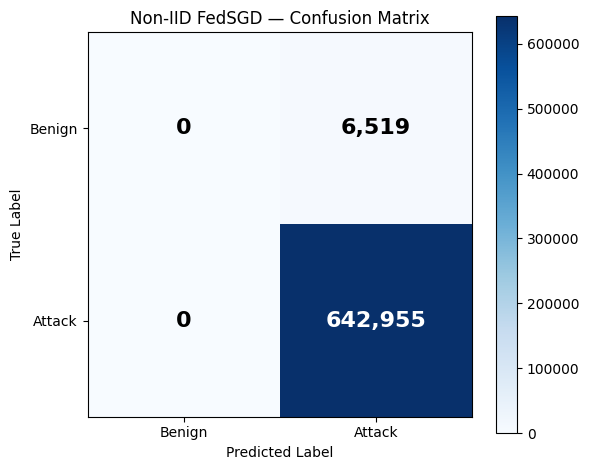

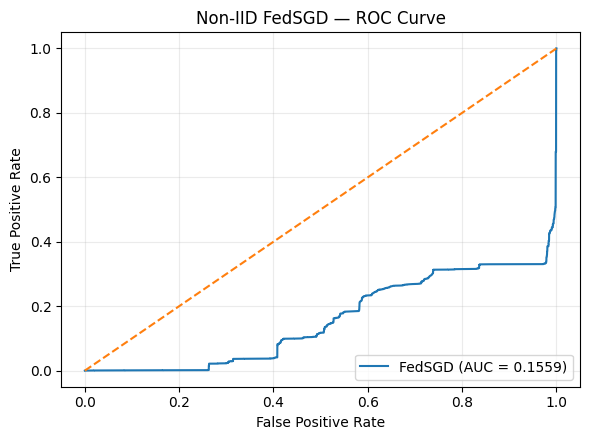

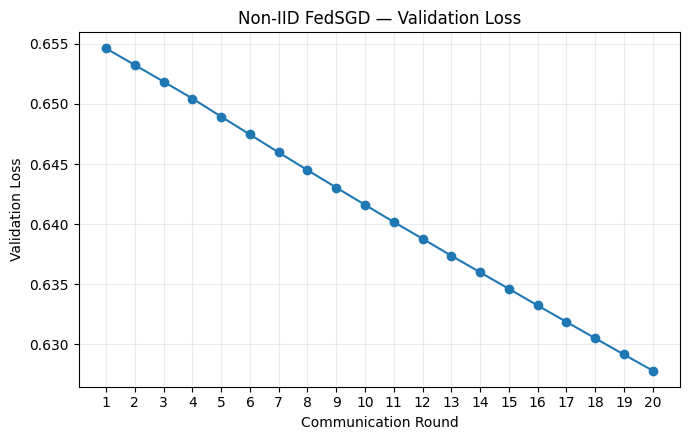


NON-IID FEDSGD EVALUATION COMPLETE
Final evaluated model : Round-20 endpoint
Inference time        : 427.6 sec

Saved ONLY:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedSGD/result/final_metrics.csv

✅ Confusion Matrix displayed.
✅ ROC Curve displayed.
✅ Validation Loss curve displayed.
✅ Figures NOT saved to Drive.
✅ Predictions NOT saved.
✅ Classification report NOT saved.
✅ No duplicate model saved.
✅ FedAvg NOT touched.
✅ Existing IID results unchanged.


0

In [ ]:
# ================================================================
# CELL 23:
# NON-IID FEDSGD FINAL TEST EVALUATION + FIGURES
# ================================================================
#
# EVALUATES:
#   FedSGD Round-20 endpoint
#
# SAVES ONLY:
#   NonIID/FedSGD/result/final_metrics.csv
#
# DISPLAYS ONLY:
#   1. Confusion Matrix
#   2. ROC Curve
#   3. Validation Loss Curve
#
# DOES NOT SAVE:
#   - predictions
#   - figures
#   - classification report
#   - duplicate model
#
# DOES NOT TOUCH:
#   - FedAvg
#   - IID experiments
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import time
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ----------------------------------------------------------------
# 2. Required globals
# ----------------------------------------------------------------

required_globals = [
    "FL_ROOT",
    "X_TEST_FILE",
    "Y_TEST_FILE"
]

missing_globals = [
    x for x in required_globals
    if x not in globals()
]

if missing_globals:

    raise RuntimeError(
        "Run setup/data cell first.\n"
        f"Missing: {missing_globals}"
    )


# ----------------------------------------------------------------
# 3. Runtime
# ----------------------------------------------------------------

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices("GPU")
)

if GPU_AVAILABLE:

    INFERENCE_DEVICE = "GPU"

    mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:

    INFERENCE_DEVICE = "CPU"

    mixed_precision.set_global_policy(
        "float32"
    )


TEST_BATCH_SIZE = 4096
THRESHOLD = 0.5


# ----------------------------------------------------------------
# 4. Paths
# ----------------------------------------------------------------

FEDSGD_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedSGD"
)

MODEL_FILE = os.path.join(
    FEDSGD_ROOT,
    "model",
    "FedSGD_Round20_Final.keras"
)

CONFIG_FILE = os.path.join(
    FEDSGD_ROOT,
    "config.json"
)

HISTORY_FILE = os.path.join(
    FEDSGD_ROOT,
    "result",
    "round_history.csv"
)

METRICS_FILE = os.path.join(
    FEDSGD_ROOT,
    "result",
    "final_metrics.csv"
)


# ----------------------------------------------------------------
# 5. Verify files
# ----------------------------------------------------------------

for path in [
    MODEL_FILE,
    CONFIG_FILE,
    HISTORY_FILE,
    X_TEST_FILE,
    Y_TEST_FILE
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            "Required file missing:\n" + path
        )


# ----------------------------------------------------------------
# 6. Verify training config
# ----------------------------------------------------------------

with open(
    CONFIG_FILE,
    "r"
) as f:

    config = json.load(f)


if not bool(
    config.get(
        "completed",
        False
    )
):

    raise RuntimeError(
        "FedSGD training is not marked complete."
    )


if int(
    config.get(
        "final_model_round"
    ) or -1
) != 20:

    raise RuntimeError(
        "FedSGD final model is not Round 20."
    )


if (
    config.get(
        "final_model_policy"
    ) != "Round-20 endpoint"
):

    raise RuntimeError(
        "Unexpected final-model policy."
    )


# ----------------------------------------------------------------
# 7. Load + verify history
# ----------------------------------------------------------------

history_df = pd.read_csv(
    HISTORY_FILE
)


if (
    len(history_df) != 20 or int(history_df["Round"].min()) != 1 or int(history_df["Round"].max()) != 20 or history_df["Round"].duplicated().any()
):

    raise RuntimeError(
        "History must contain exactly "
        "Round 1 → Round 20."
    )


best_row = history_df.loc[
    history_df[
        "Val_Macro_F1"
    ].idxmax()
]


BEST_VAL_ROUND = int(
    best_row["Round"]
)

BEST_VAL_MACRO_F1 = float(
    best_row["Val_Macro_F1"]
)


round20_row = history_df[
    history_df["Round"] == 20
].iloc[0]


print("=" * 88)

print(
    "NON-IID FEDSGD — FINAL TEST EVALUATION"
)

print("=" * 88)

print(
    "Final model round : 20"
)

print(
    "Training device   :",
    config.get(
        "completed_device",
        "Unknown"
    )
)

print(
    "Training precision:",
    config.get(
        "completed_precision_policy",
        "Unknown"
    )
)

print(
    "Inference device  :",
    INFERENCE_DEVICE
)

print(
    "Best validation round:",
    BEST_VAL_ROUND
)

print(
    f"Best validation Macro F1: "
    f"{BEST_VAL_MACRO_F1:.6f}"
)


# ----------------------------------------------------------------
# 8. Model SHA256
# ----------------------------------------------------------------

def calculate_sha256(
    path,
    chunk_size=1024 * 1024
):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


MODEL_SHA256 = calculate_sha256(
    MODEL_FILE
)


# ----------------------------------------------------------------
# 9. Load untouched test set
# ----------------------------------------------------------------

X_test = np.load(
    X_TEST_FILE,
    mmap_mode="r"
)


y_true = np.asarray(
    np.load(
        Y_TEST_FILE,
        mmap_mode="r"
    ),
    dtype=np.int8
).reshape(-1)


if len(X_test) != len(y_true):

    raise RuntimeError(
        "Test X/Y size mismatch."
    )


print(
    "\nTest samples:",
    f"{len(y_true):,}"
)

print(
    "Benign:",
    f"{np.sum(y_true == 0):,}"
)

print(
    "Attack:",
    f"{np.sum(y_true == 1):,}"
)


# ----------------------------------------------------------------
# 10. Load Round-20 model
# ----------------------------------------------------------------

tf.keras.backend.clear_session()


if GPU_AVAILABLE:

    mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:

    mixed_precision.set_global_policy(
        "float32"
    )


model = tf.keras.models.load_model(
    MODEL_FILE,
    compile=False
)


if int(
    model.count_params()
) != 60097:

    raise RuntimeError(
        "Unexpected model architecture."
    )


print(
    "\nModel parameters:",
    f"{model.count_params():,}"
)


# ----------------------------------------------------------------
# 11. Test inference
# ----------------------------------------------------------------

probability_parts = []


inference_start = time.time()


for start in range(
    0,
    len(y_true),
    TEST_BATCH_SIZE
):

    end = min(
        start + TEST_BATCH_SIZE,
        len(y_true)
    )


    X_batch = np.asarray(
        X_test[start:end],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    probabilities = (
        model(
            tf.convert_to_tensor(
                X_batch,
                dtype=tf.float32
            ),
            training=False
        )
        .numpy()
        .reshape(-1)
        .astype(
            np.float32,
            copy=False
        )
    )


    probability_parts.append(
        probabilities
    )


    del (
        X_batch,
        probabilities
    )


y_prob = np.concatenate(
    probability_parts
)


del probability_parts


inference_time = (
    time.time() - inference_start
)


if len(y_prob) != len(y_true):

    raise RuntimeError(
        "Prediction count mismatch."
    )


if not np.all(
    np.isfinite(
        y_prob
    )
):

    raise RuntimeError(
        "NaN/Inf found in predictions."
    )


y_pred = (
    y_prob >= THRESHOLD
).astype(
    np.int8
)


# ----------------------------------------------------------------
# 12. Confusion matrix
# ----------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)


tn, fp, fn, tp = (
    cm.ravel()
)


# ----------------------------------------------------------------
# 13. Metrics
# ----------------------------------------------------------------

accuracy = float(
    accuracy_score(
        y_true,
        y_pred
    )
)


attack_precision = float(
    precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


attack_recall = float(
    recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


attack_f1 = float(
    f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


macro_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)


weighted_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)


benign_precision = float(
    precision_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


benign_recall = float(
    recall_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


benign_f1 = float(
    f1_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


roc_auc = float(
    roc_auc_score(
        y_true,
        y_prob
    )
)


attack_pr_auc = float(
    average_precision_score(
        y_true,
        y_prob
    )
)


benign_pr_auc = float(
    average_precision_score(
        1 - y_true,
        1.0 - y_prob
    )
)


# ----------------------------------------------------------------
# 14. Classification report — DISPLAY ONLY
# ----------------------------------------------------------------

report = classification_report(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ],
    target_names=[
        "Benign",
        "Attack"
    ],
    output_dict=True,
    zero_division=0
)


report_df = pd.DataFrame(
    report
).transpose()


# ----------------------------------------------------------------
# 15. Final metrics dataframe
# ----------------------------------------------------------------

metrics_df = pd.DataFrame(
    [
        {
            "Algorithm":
                "FedSGD",

            "Architecture":
                "CNN-LSTM-ResNet",

            "Partition":
                "Non-IID",

            "NonIID_Type":
                (
                    "Controlled Strong "
                    "Minority-Class Label Skew"
                ),

            "Benign_Allocation":
                "50/25/15/7/3",

            "Clients":
                5,

            "Communication_Rounds":
                20,

            "Model_Round":
                20,

            "Evaluation_Model_Policy":
                "Round-20 endpoint",

            "Gradient_Method":
                "Full-client mean gradient",

            "Gradient_Chunk_Size":
                2048,

            "Server_LR":
                0.001,

            "Threshold":
                0.5,

            "Accuracy":
                accuracy,

            "Attack_Precision":
                attack_precision,

            "Attack_Recall":
                attack_recall,

            "Attack_F1":
                attack_f1,

            "Macro_F1":
                macro_f1,

            "Weighted_F1":
                weighted_f1,

            "Benign_Precision":
                benign_precision,

            "Benign_Recall":
                benign_recall,

            "Benign_F1":
                benign_f1,

            "Specificity":
                benign_recall,

            "ROC_AUC":
                roc_auc,

            "PR_AUC":
                attack_pr_auc,

            "Benign_PR_AUC":
                benign_pr_auc,

            "TN":
                int(tn),

            "FP":
                int(fp),

            "FN":
                int(fn),

            "TP":
                int(tp),

            "Test_Samples":
                int(len(y_true)),

            "Best_Validation_Round":
                BEST_VAL_ROUND,

            "Best_Validation_Macro_F1":
                BEST_VAL_MACRO_F1,

            "Round20_Validation_Macro_F1":
                float(
                    round20_row[
                        "Val_Macro_F1"
                    ]
                ),

            "Training_Device":
                config.get(
                    "completed_device",
                    "Unknown"
                ),

            "Training_Precision":
                config.get(
                    "completed_precision_policy",
                    "Unknown"
                ),

            "Model_SHA256":
                MODEL_SHA256
        }
    ]
)


# ----------------------------------------------------------------
# 16. Save ONLY final_metrics.csv
# Re-run safe
# ----------------------------------------------------------------

should_save = True


if os.path.exists(
    METRICS_FILE
):

    try:

        existing = pd.read_csv(
            METRICS_FILE
        )


        if (
            not existing.empty and "Model_SHA256"
            in existing.columns and str(
                existing.iloc[0][
                    "Model_SHA256"
                ]
            ) == MODEL_SHA256 and int(
                existing.iloc[0][
                    "Model_Round"
                ]
            ) == 20
        ):

            should_save = False

    except Exception:

        should_save = True


if should_save:

    temp_metrics = (
        METRICS_FILE + ".tmp.csv"
    )


    metrics_df.to_csv(
        temp_metrics,
        index=False
    )


    os.replace(
        temp_metrics,
        METRICS_FILE
    )


    print(
        "\n✅ Final metrics saved."
    )

else:

    print(
        "\n✅ Existing metrics already "
        "belong to this exact model."
    )

    print(
        "✅ Metrics file not rewritten."
    )


# ----------------------------------------------------------------
# 17. Print results
# ----------------------------------------------------------------

print("\n" + "=" * 88)

print(
    "NON-IID FEDSGD FINAL TEST RESULTS"
)

print("=" * 88)


print(
    f"Accuracy         : {accuracy:.6f}"
)

print(
    f"Attack Precision : {attack_precision:.6f}"
)

print(
    f"Attack Recall    : {attack_recall:.6f}"
)

print(
    f"Attack F1        : {attack_f1:.6f}"
)

print(
    f"Macro F1         : {macro_f1:.6f}"
)

print(
    f"Weighted F1      : {weighted_f1:.6f}"
)

print(
    f"Benign Precision : {benign_precision:.6f}"
)

print(
    f"Benign Recall    : {benign_recall:.6f}"
)

print(
    f"Benign F1        : {benign_f1:.6f}"
)

print(
    f"ROC-AUC          : {roc_auc:.6f}"
)

print(
    f"PR-AUC           : {attack_pr_auc:.6f}"
)

print(
    f"Benign PR-AUC    : {benign_pr_auc:.6f}"
)


print(
    "\nConfusion Matrix:"
)

print(
    f"TN = {tn}"
)

print(
    f"FP = {fp}"
)

print(
    f"FN = {fn}"
)

print(
    f"TP = {tp}"
)


print(
    "\nClassification Report:"
)

display(
    report_df
)


# ================================================================
# 18. FIGURE 1 — CONFUSION MATRIX
# DISPLAY ONLY
# ================================================================

plt.figure(
    figsize=(
        6,
        5
    )
)


plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)


plt.title(
    "Non-IID FedSGD — Confusion Matrix"
)


plt.colorbar()


plt.xticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.yticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


cm_threshold = (
    cm.max() / 2.0
)


for i in range(2):

    for j in range(2):

        value = int(
            cm[
                i,
                j
            ]
        )


        plt.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if
                value > cm_threshold
                else
                "black"
            )
        )


plt.tight_layout()

plt.show()


# ================================================================
# 19. FIGURE 2 — ROC CURVE
# DISPLAY ONLY
# ================================================================

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)


plt.figure(
    figsize=(
        6,
        4.5
    )
)


plt.plot(
    fpr,
    tpr,
    label=(
        f"FedSGD "
        f"(AUC = {roc_auc:.4f})"
    )
)


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "Non-IID FedSGD — ROC Curve"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ================================================================
# 20. FIGURE 3 — VALIDATION LOSS
# DISPLAY ONLY
# ================================================================

plt.figure(
    figsize=(
        7,
        4.5
    )
)


plt.plot(
    history_df[
        "Round"
    ],
    history_df[
        "Val_Loss"
    ],
    marker="o"
)


plt.xlabel(
    "Communication Round"
)


plt.ylabel(
    "Validation Loss"
)


plt.title(
    "Non-IID FedSGD — Validation Loss"
)


plt.xticks(
    range(
        1,
        21
    )
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ----------------------------------------------------------------
# 21. Final status
# ----------------------------------------------------------------

print(
    "\n" + "=" * 88
)


print(
    "NON-IID FEDSGD EVALUATION COMPLETE"
)


print(
    "=" * 88
)


print(
    "Final evaluated model : Round-20 endpoint"
)


print(
    f"Inference time        : "
    f"{inference_time:.1f} sec"
)


print(
    "\nSaved ONLY:"
)


print(
    METRICS_FILE
)


print(
    "\n✅ Confusion Matrix displayed."
)

print(
    "✅ ROC Curve displayed."
)

print(
    "✅ Validation Loss curve displayed."
)

print(
    "✅ Figures NOT saved to Drive."
)

print(
    "✅ Predictions NOT saved."
)

print(
    "✅ Classification report NOT saved."
)

print(
    "✅ No duplicate model saved."
)

print(
    "✅ FedAvg NOT touched."
)

print(
    "✅ Existing IID results unchanged."
)

print(
    "=" * 88
)


# ----------------------------------------------------------------
# 22. Cleanup
# ----------------------------------------------------------------

del (
    model,
    X_test,
    y_true,
    y_prob,
    y_pred
)


tf.keras.backend.clear_session()

gc.collect()


In [ ]:
# ================================================================
# CELL 24: NON-IID FEDPROX TRAINING
# FINAL + RESUMABLE + MINIMAL DRIVE STORAGE
# ================================================================
#
# NON-IID:
#   Controlled Strong Minority-Class Label Skew
#   Benign allocation = 50% / 25% / 15% / 7% / 3%
#
# FEDPROX:
#   Local optimizer = Adam
#   Local LR        = 0.001
#   Local epochs    = 1
#   Batch size      = 2048
#   Proximal mu     = 0.01
#
# Objective:
#   BCE + (mu / 2) * ||w_local - w_global||^2
#
# FL:
#   Clients         = 5
#   Rounds          = 20
#   Aggregation     = Sample-size weighted
#   Final model     = Round-20 endpoint
#
# PERMANENT DRIVE FILES:
#   1. config.json
#   2. round_history.csv
#   3. FedProx_Round20_Final.keras
#
# TEMPORARY:
#   ONE rolling checkpoint only.
#   Deleted automatically after successful Round 20.
#
# DOES NOT SAVE:
#   - predictions
#   - figures
#   - per-round models
#   - client datasets
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import re
import gc
import json
import time
import shutil
import hashlib

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score
)


# ================================================================
# 2. Required notebook objects
# ================================================================

required_globals = [
    "FL_ROOT",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "NUM_FEATURES",
    "RANDOM_SEED",
    "build_federated_binary_model"
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise RuntimeError(
        "Run the existing setup/data/model architecture cells first.\n"
        f"Missing: {missing_globals}"
    )


# ================================================================
# 3. Freeze FedProx protocol
# ================================================================

FP_NUM_CLIENTS = 5
FP_ROUNDS = 20

FP_LOCAL_EPOCHS = 1
FP_BATCH_SIZE = 2048
FP_LOCAL_LR = 0.001

FP_MU = 0.01


# ================================================================
# 4. CPU / GPU automatic precision
# ================================================================

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices(
        "GPU"
    )
)


if GPU_AVAILABLE:

    FP_DEVICE = "GPU"

    FP_PRECISION = (
        "mixed_float16"
    )

    # Same static scaling policy as IID FedProx
    FP_LOSS_SCALE = 1024.0

else:

    FP_DEVICE = "CPU"

    FP_PRECISION = "float32"

    FP_LOSS_SCALE = 1.0


mixed_precision.set_global_policy(
    FP_PRECISION
)


print("=" * 88)

print(
    "NON-IID FEDPROX — STRONG LABEL-SKEW — 5 CLIENTS"
)

print("=" * 88)

print(
    "Runtime device :",
    FP_DEVICE
)

print(
    "Precision      :",
    FP_PRECISION
)

print(
    "Local LR       :",
    FP_LOCAL_LR
)

print(
    "Local epochs   :",
    FP_LOCAL_EPOCHS
)

print(
    "Batch size     :",
    FP_BATCH_SIZE
)

print(
    "FedProx mu     :",
    FP_MU
)


if FP_DEVICE == "CPU":

    print(
        "⚠️ CPU supported, but GPU is strongly preferred."
    )


# ================================================================
# 5. Dedicated paths
# ================================================================

FP_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedProx"
)


FP_MODEL_DIR = os.path.join(
    FP_ROOT,
    "model"
)


FP_RESULT_DIR = os.path.join(
    FP_ROOT,
    "result"
)


FP_CHECKPOINT_DIR = os.path.join(
    FP_ROOT,
    "checkpoint"
)


for directory in [
    FP_ROOT,
    FP_MODEL_DIR,
    FP_RESULT_DIR,
    FP_CHECKPOINT_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


FP_PARTITION_FILE = os.path.join(
    FL_ROOT,
    "partition",
    "NonIID",
    "Strong_LabelSkew_5Clients_Binary_partition.npz"
)


FP_CONFIG_FILE = os.path.join(
    FP_ROOT,
    "config.json"
)


FP_HISTORY_FILE = os.path.join(
    FP_RESULT_DIR,
    "round_history.csv"
)


FP_FINAL_MODEL_FILE = os.path.join(
    FP_MODEL_DIR,
    "FedProx_Round20_Final.keras"
)


if not os.path.exists(
    FP_PARTITION_FILE
):

    raise FileNotFoundError(
        "Non-IID partition missing:\n" + FP_PARTITION_FILE
    )


# ================================================================
# 6. Load frozen Non-IID partition
# ================================================================

with np.load(
    FP_PARTITION_FILE,
    allow_pickle=False
) as saved_partition:

    fp_assignment = np.asarray(
        saved_partition[
            "assignment"
        ],
        dtype=np.int8
    )


fp_validation_indices = (
    np.flatnonzero(
        fp_assignment == -1
    )
    .astype(
        np.int32,
        copy=False
    )
)


fp_client_indices = [

    np.flatnonzero(
        fp_assignment == client_id
    ).astype(
        np.int32,
        copy=False
    )

    for client_id
    in range(
        FP_NUM_CLIENTS
    )
]


# ================================================================
# 7. Verify frozen partition
# ================================================================

fp_client_sizes = np.asarray(
    [
        len(indices)
        for indices
        in fp_client_indices
    ],
    dtype=np.int64
)


if (
    fp_client_sizes.max() - fp_client_sizes.min() > 1
):

    raise RuntimeError(
        "Client sizes differ unexpectedly."
    )


y_partition_check = np.load(
    Y_TRAIN_FILE,
    mmap_mode="r"
)


fp_benign_counts = []

fp_attack_counts = []


for indices in fp_client_indices:

    labels = np.asarray(
        y_partition_check[
            indices
        ],
        dtype=np.int8
    )


    counts = np.bincount(
        labels,
        minlength=2
    )


    fp_benign_counts.append(
        int(
            counts[0]
        )
    )


    fp_attack_counts.append(
        int(
            counts[1]
        )
    )


EXPECTED_BENIGN_COUNTS = get_expected_benign_counts(
    y_partition_check,
    fp_validation_indices,
    BENIGN_ALLOCATION
)


if (
    fp_benign_counts != EXPECTED_BENIGN_COUNTS
):

    raise RuntimeError(
        "Non-IID partition does not match "
        "the frozen 50/25/15/7/3 design."
    )


partition_sha256 = hashlib.sha256(
    fp_assignment.tobytes()
).hexdigest()


print(
    "\n✅ Non-IID partition verified."
)

print(
    "Client sizes :",
    fp_client_sizes.tolist()
)

print(
    "Benign counts:",
    fp_benign_counts
)

print(
    "Attack counts:",
    fp_attack_counts
)

print(
    "Validation samples:",
    f"{len(fp_validation_indices):,}"
)


del y_partition_check

gc.collect()


# ================================================================
# 8. Atomic file helpers
# ================================================================

def save_json_atomic(
    path,
    data
):

    temporary = (
        path + ".tmp"
    )


    with open(
        temporary,
        "w"
    ) as file:

        json.dump(
            data,
            file,
            indent=2
        )


    os.replace(
        temporary,
        path
    )


def save_csv_atomic(
    dataframe,
    path
):

    temporary = (
        path + ".tmp.csv"
    )


    dataframe.to_csv(
        temporary,
        index=False
    )


    os.replace(
        temporary,
        path
    )


# ================================================================
# 9. Configuration
# ================================================================

CURRENT_CONFIG = {

    "algorithm":
        "FedProx",

    "architecture":
        "CNN-LSTM-ResNet",

    "partition":
        (
            "Controlled Strong "
            "Minority-Class Label Skew"
        ),

    "benign_allocation":
        "50/25/15/7/3",

    "partition_sha256":
        partition_sha256,

    "num_clients":
        5,

    "communication_rounds":
        20,

    "local_epochs":
        1,

    "local_batch_size":
        2048,

    "local_optimizer":
        "Adam",

    "local_learning_rate":
        0.001,

    "fedprox_mu":
        0.01,

    "aggregation":
        "Sample-size weighted",

    "final_model_policy":
        "Round-20 endpoint",

    "random_seed":
        int(
            RANDOM_SEED
        ),

    "precision_policy":
        FP_PRECISION,

    "static_loss_scale":
        float(
            FP_LOSS_SCALE
        )
}


# ================================================================
# 10. Rolling checkpoint helpers
# ================================================================

checkpoint_pattern = re.compile(
    r"^round_(\d{2})\.weights\.h5$"
)


def list_checkpoints():

    output = []


    if not os.path.isdir(
        FP_CHECKPOINT_DIR
    ):

        return output


    for filename in os.listdir(
        FP_CHECKPOINT_DIR
    ):

        match = (
            checkpoint_pattern.match(
                filename
            )
        )


        if match:

            output.append(
                (
                    int(
                        match.group(1)
                    ),

                    os.path.join(
                        FP_CHECKPOINT_DIR,
                        filename
                    )
                )
            )


    return sorted(
        output
    )


def cleanup_checkpoints(
    keep_round=None
):

    for round_number, path in (
        list_checkpoints()
    ):

        if (
            keep_round is None or round_number != keep_round
        ):

            try:

                os.remove(
                    path
                )

            except FileNotFoundError:

                pass


def save_checkpoint(
    model,
    round_number
):

    checkpoint_path = os.path.join(
        FP_CHECKPOINT_DIR,
        f"round_{round_number:02d}.weights.h5"
    )


    temporary_path = os.path.join(
        FP_CHECKPOINT_DIR,
        f".round_{round_number:02d}.tmp.weights.h5"
    )


    if os.path.exists(
        temporary_path
    ):

        os.remove(
            temporary_path
        )


    model.save_weights(
        temporary_path,
        overwrite=True
    )


    os.replace(
        temporary_path,
        checkpoint_path
    )


    cleanup_checkpoints(
        keep_round=round_number
    )


    return checkpoint_path


# ================================================================
# 11. History
# ================================================================

HISTORY_COLUMNS = [
    "Round",
    "Val_Loss",
    "Val_Accuracy",
    "Val_Macro_F1",
    "Val_Benign_Recall",
    "Round_Time_sec"
]


if os.path.exists(
    FP_HISTORY_FILE
):

    history_df = pd.read_csv(
        FP_HISTORY_FILE
    )

else:

    history_df = pd.DataFrame(
        columns=HISTORY_COLUMNS
    )


if not history_df.empty:

    history_df[
        "Round"
    ] = history_df[
        "Round"
    ].astype(int)


    if history_df[
        "Round"
    ].duplicated().any():

        raise RuntimeError(
            "Duplicate FedProx rounds found."
        )


# ================================================================
# 12. Config create / validate
#
# Precision can change only before training progress exists.
# ================================================================

has_progress = (

    not history_df.empty
 or
    len(
        list_checkpoints()
    ) > 0
 or
    os.path.exists(
        FP_FINAL_MODEL_FILE
    )

)


if os.path.exists(
    FP_CONFIG_FILE
):

    with open(
        FP_CONFIG_FILE,
        "r"
    ) as file:

        saved_config = json.load(
            file
        )


    CORE_KEYS = [
        "algorithm",
        "architecture",
        "partition",
        "benign_allocation",
        "partition_sha256",
        "num_clients",
        "communication_rounds",
        "local_epochs",
        "local_batch_size",
        "local_optimizer",
        "local_learning_rate",
        "fedprox_mu",
        "aggregation",
        "final_model_policy",
        "random_seed"
    ]


    mismatches = {

        key: {
            "saved":
                saved_config.get(
                    key
                ),

            "current":
                CURRENT_CONFIG.get(
                    key
                )
        }

        for key in CORE_KEYS

        if (
            saved_config.get(
                key
            ) != CURRENT_CONFIG.get(
                key
            )
        )

    }


    if mismatches:

        raise RuntimeError(
            "Non-IID FedProx protocol mismatch:\n" + json.dumps(
                mismatches,
                indent=2
            )
        )


    precision_changed = (
        saved_config.get(
            "precision_policy"
        ) != FP_PRECISION
    )


    if (
        precision_changed and has_progress
    ):

        raise RuntimeError(
            "FedProx training already started "
            "with a different precision policy.\n"
            "Do not mix CPU/GPU precision modes."
        )


    if (
        precision_changed and not has_progress
    ):

        saved_config.update(
            CURRENT_CONFIG
        )


        save_json_atomic(
            FP_CONFIG_FILE,
            saved_config
        )


        print(
            "✅ Precision config updated; "
            "no training progress existed."
        )


    runtime_config = (
        saved_config
    )


else:

    runtime_config = dict(
        CURRENT_CONFIG
    )


    runtime_config[
        "completed"
    ] = False


    runtime_config[
        "final_model_round"
    ] = None


    save_json_atomic(
        FP_CONFIG_FILE,
        runtime_config
    )


# ================================================================
# 13. Completed experiment check
# ================================================================

if os.path.exists(
    FP_FINAL_MODEL_FILE
):

    if (
        history_df.empty or int(
            history_df[
                "Round"
            ].max()
        ) != 20
    ):

        raise RuntimeError(
            "FedProx final model exists "
            "but Round-20 history is incomplete."
        )


    check_model = (
        tf.keras.models.load_model(
            FP_FINAL_MODEL_FILE,
            compile=False
        )
    )


    if int(
        check_model.count_params()
    ) != 60097:

        raise RuntimeError(
            "Unexpected final FedProx architecture."
        )


    del check_model


    tf.keras.backend.clear_session()

    gc.collect()


    mixed_precision.set_global_policy(
        FP_PRECISION
    )


    runtime_config[
        "completed"
    ] = True


    runtime_config[
        "final_model_round"
    ] = 20


    save_json_atomic(
        FP_CONFIG_FILE,
        runtime_config
    )


    cleanup_checkpoints(
        keep_round=None
    )


    print(
        "\n✅ Non-IID FedProx Round-20 "
        "final model already exists."
    )


    print(
        "✅ Training skipped."
    )


    print(
        FP_FINAL_MODEL_FILE
    )


# ================================================================
# 14. TRAIN / RESUME
# ================================================================

else:

    # ------------------------------------------------------------
    # Temporary LOCAL Colab cache
    # NOT Google Drive
    # ------------------------------------------------------------

    LOCAL_CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )


    os.makedirs(
        LOCAL_CACHE_DIR,
        exist_ok=True
    )


    LOCAL_X_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "X_train_scaled_float32.npy"
    )


    LOCAL_Y_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "y_train_int8.npy"
    )


    for source, destination in [
        (
            X_TRAIN_FILE,
            LOCAL_X_FILE
        ),
        (
            Y_TRAIN_FILE,
            LOCAL_Y_FILE
        )
    ]:

        if not os.path.exists(
            destination
        ):

            print(
                "Copying to temporary Colab disk:",
                os.path.basename(
                    source
                )
            )


            shutil.copy2(
                source,
                destination
            )


    X_train_fp = np.load(
        LOCAL_X_FILE,
        mmap_mode="r"
    )


    y_train_fp = np.load(
        LOCAL_Y_FILE,
        mmap_mode="r"
    )


    # ------------------------------------------------------------
    # Validation set
    # ------------------------------------------------------------

    X_val_fp = np.asarray(
        X_train_fp[
            fp_validation_indices
        ],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    y_val_fp = np.asarray(
        y_train_fp[
            fp_validation_indices
        ],
        dtype=np.int8
    )


    print(
        "\nValidation samples:",
        f"{len(y_val_fp):,}"
    )


    # ============================================================
    # 15. Sample-size weighted aggregation
    # ============================================================

    def weighted_add(
        accumulator,
        client_weights,
        sample_count
    ):

        if accumulator is None:

            return [
                np.asarray(
                    weight,
                    dtype=np.float64
                ) * float(
                    sample_count
                )

                for weight
                in client_weights
            ]


        for weight_index in range(
            len(accumulator)
        ):

            accumulator[
                weight_index
            ] += (
                np.asarray(
                    client_weights[
                        weight_index
                    ],
                    dtype=np.float64
                ) * float(
                    sample_count
                )
            )


        return accumulator


    def weighted_finalize(
        accumulator,
        total_samples
    ):

        return [
            (
                weighted_sum / float(
                    total_samples
                )
            ).astype(
                np.float32
            )

            for weighted_sum
            in accumulator
        ]


    # ============================================================
    # 16. Validation
    # ============================================================

    VAL_BATCH_SIZE = 4096


    def evaluate_global_weights(
        global_weights
    ):

        tf.keras.backend.clear_session()


        mixed_precision.set_global_policy(
            FP_PRECISION
        )


        evaluation_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        evaluation_model.set_weights(
            global_weights
        )


        probability_parts = []


        for start in range(
            0,
            len(y_val_fp),
            VAL_BATCH_SIZE
        ):

            end = min(
                start + VAL_BATCH_SIZE,
                len(y_val_fp)
            )


            batch_x = tf.convert_to_tensor(
                X_val_fp[
                    start:end
                ],
                dtype=tf.float32
            )


            probability = (
                evaluation_model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
                .astype(
                    np.float32,
                    copy=False
                )
            )


            probability_parts.append(
                probability
            )


        y_probability = np.concatenate(
            probability_parts
        )


        y_prediction = (
            y_probability >= 0.5
        ).astype(
            np.int8
        )


        epsilon = 1e-7


        clipped = np.clip(
            y_probability,
            epsilon,
            1.0 - epsilon
        )


        validation_loss = float(
            -np.mean(
                y_val_fp * np.log(
                    clipped
                )
 +
                (
                    1 - y_val_fp
                ) * np.log(
                    1.0 - clipped
                )
            )
        )


        validation_accuracy = float(
            accuracy_score(
                y_val_fp,
                y_prediction
            )
        )


        validation_macro_f1 = float(
            f1_score(
                y_val_fp,
                y_prediction,
                average="macro",
                zero_division=0
            )
        )


        validation_benign_recall = float(
            recall_score(
                y_val_fp,
                y_prediction,
                pos_label=0,
                zero_division=0
            )
        )


        del (
            probability_parts,
            y_probability,
            y_prediction,
            clipped
        )


        return (
            evaluation_model,
            validation_loss,
            validation_accuracy,
            validation_macro_f1,
            validation_benign_recall
        )


    # ============================================================
    # 17. Resume or fresh global initialization
    # ============================================================

    checkpoints = list_checkpoints()


    if checkpoints:

        (
            last_completed_round,
            checkpoint_path
        ) = checkpoints[
            -1
        ]


        if (
            history_df.empty or int(
                history_df[
                    "Round"
                ].max()
            ) < last_completed_round
        ):

            raise RuntimeError(
                "Checkpoint is ahead of history."
            )


        # If history got saved but checkpoint did not,
        # safely trim history to checkpoint round.
        if (
            not history_df.empty and int(
                history_df[
                    "Round"
                ].max()
            ) > last_completed_round
        ):

            history_df = history_df[
                history_df[
                    "Round"
                ] <= last_completed_round
            ].copy()


            save_csv_atomic(
                history_df,
                FP_HISTORY_FILE
            )


            print(
                "⚠️ History trimmed to latest "
                "safe checkpoint."
            )


        tf.keras.backend.clear_session()


        mixed_precision.set_global_policy(
            FP_PRECISION
        )


        resume_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        resume_model.load_weights(
            checkpoint_path
        )


        global_weights = [
            np.asarray(
                weight,
                dtype=np.float32
            ).copy()

            for weight
            in resume_model.get_weights()
        ]


        del resume_model


        tf.keras.backend.clear_session()

        gc.collect()


        mixed_precision.set_global_policy(
            FP_PRECISION
        )


        START_ROUND = (
            last_completed_round + 1
        )


        print(
            "\n🔄 RESUMING NON-IID FEDPROX"
        )

        print(
            "Last completed round:",
            last_completed_round
        )

        print(
            "Next round:",
            START_ROUND
        )


    else:

        # No checkpoint = no safe partial model.
        if not history_df.empty:

            print(
                "\n⚠️ History exists but no safe "
                "checkpoint survives."
            )

            print(
                "Starting FedProx fresh from Round 1."
            )


            history_df = pd.DataFrame(
                columns=HISTORY_COLUMNS
            )


            save_csv_atomic(
                history_df,
                FP_HISTORY_FILE
            )


        tf.keras.backend.clear_session()


        mixed_precision.set_global_policy(
            FP_PRECISION
        )


        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )


        initial_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        if int(
            initial_model.count_params()
        ) != 60097:

            raise RuntimeError(
                "Unexpected architecture."
            )


        global_weights = [
            np.asarray(
                weight,
                dtype=np.float32
            ).copy()

            for weight
            in initial_model.get_weights()
        ]


        del initial_model


        tf.keras.backend.clear_session()

        gc.collect()


        mixed_precision.set_global_policy(
            FP_PRECISION
        )


        START_ROUND = 1


        print(
            "\n🟢 FRESH NON-IID FEDPROX RUN"
        )

        print(
            "Round 1 → Round 20"
        )


    # ============================================================
    # 18. Communication rounds
    # ============================================================

    for round_number in range(
        START_ROUND,
        FP_ROUNDS + 1
    ):

        round_start = time.time()


        print(
            "\n" + "=" * 72
        )


        print(
            f"NON-IID FEDPROX ROUND "
            f"{round_number}/20"
        )


        print(
            "=" * 72
        )


        weighted_accumulator = None

        total_samples = 0


        # ========================================================
        # CLIENT LOOP
        # ========================================================

        for client_id in range(
            FP_NUM_CLIENTS
        ):

            client_start = time.time()


            indices = (
                fp_client_indices[
                    client_id
                ]
            )


            client_sample_count = int(
                len(indices)
            )


            print(
                f"\nClient {client_id + 1}/5"
            )


            print(
                "Samples:",
                f"{client_sample_count:,}"
            )


            print(
                "Benign :",
                fp_benign_counts[
                    client_id
                ]
            )


            print(
                "Attack :",
                fp_attack_counts[
                    client_id
                ]
            )


            # ----------------------------------------------------
            # Client data in RAM
            # ----------------------------------------------------

            X_client = np.asarray(
                X_train_fp[
                    indices
                ],
                dtype=np.float32
            )[
                ...,
                np.newaxis
            ]


            y_client = np.asarray(
                y_train_fp[
                    indices
                ],
                dtype=np.float32
            )


            shuffle_seed = int(
                RANDOM_SEED + round_number * 100 + client_id
            )


            client_dataset = (
                tf.data.Dataset
                .from_tensor_slices(
                    (
                        X_client,
                        y_client
                    )
                )
                .shuffle(
                    buffer_size=min(
                        50000,
                        client_sample_count
                    ),
                    seed=shuffle_seed,
                    reshuffle_each_iteration=True
                )
                .batch(
                    FP_BATCH_SIZE,
                    drop_remainder=False
                )
                .prefetch(
                    tf.data.AUTOTUNE
                )
            )


            # ----------------------------------------------------
            # Fresh local model + fresh Adam
            # ----------------------------------------------------

            tf.keras.backend.clear_session()


            mixed_precision.set_global_policy(
                FP_PRECISION
            )


            local_model = (
                build_federated_binary_model(
                    compile_model=False
                )
            )


            local_model.set_weights(
                global_weights
            )


            if int(
                local_model.count_params()
            ) != 60097:

                raise RuntimeError(
                    "Unexpected local model architecture."
                )


            local_optimizer = (
                tf.keras.optimizers.Adam(
                    learning_rate=
                        FP_LOCAL_LR
                )
            )


            bce_loss_fn = (
                tf.keras.losses.BinaryCrossentropy()
            )


            # ----------------------------------------------------
            # Frozen global reference for proximal penalty
            # ----------------------------------------------------

            global_reference = [

                tf.constant(
                    variable.numpy(),
                    dtype=tf.float32
                )

                for variable
                in local_model.trainable_variables

            ]


            # ----------------------------------------------------
            # FedProx local train step
            # ----------------------------------------------------

            @tf.function(
                reduce_retracing=True
            )
            def fedprox_train_step(
                batch_x,
                batch_y
            ):

                batch_y = tf.reshape(
                    tf.cast(
                        batch_y,
                        tf.float32
                    ),
                    (-1, 1)
                )


                with tf.GradientTape() as tape:

                    prediction = (
                        local_model(
                            batch_x,
                            training=True
                        )
                    )


                    bce = bce_loss_fn(
                        batch_y,
                        prediction
                    )


                    # FedProx:
                    # mu/2 * ||w_local - w_global||^2
                    proximal_terms = [

                        tf.reduce_sum(
                            tf.square(
                                tf.cast(
                                    variable,
                                    tf.float32
                                ) - reference
                            )
                        )

                        for variable, reference
                        in zip(
                            local_model.trainable_variables,
                            global_reference
                        )

                    ]


                    proximal_penalty = (
                        0.5 * FP_MU * tf.add_n(
                            proximal_terms
                        )
                    )


                    total_loss = (
                        tf.cast(
                            bce,
                            tf.float32
                        ) + proximal_penalty
                    )


                    scaled_loss = (
                        total_loss * FP_LOSS_SCALE
                    )


                scaled_gradients = tape.gradient(
                    scaled_loss,
                    local_model.trainable_variables
                )


                gradients = []


                for gradient, variable in zip(
                    scaled_gradients,
                    local_model.trainable_variables
                ):

                    if gradient is None:

                        gradient = tf.zeros_like(
                            variable,
                            dtype=tf.float32
                        )

                    else:

                        gradient = (
                            tf.cast(
                                gradient,
                                tf.float32
                            ) / FP_LOSS_SCALE
                        )


                    gradients.append(
                        gradient
                    )


                local_optimizer.apply_gradients(
                    zip(
                        gradients,
                        local_model.trainable_variables
                    )
                )


                return (
                    tf.cast(
                        total_loss,
                        tf.float32
                    ),
                    tf.cast(
                        bce,
                        tf.float32
                    ),
                    tf.cast(
                        proximal_penalty,
                        tf.float32
                    )
                )


            # ----------------------------------------------------
            # 1 local epoch
            # ----------------------------------------------------

            objective_sum = 0.0

            bce_sum = 0.0

            prox_sum = 0.0

            seen_samples = 0


            for (
                batch_x,
                batch_y
            ) in client_dataset:

                current_batch_size = int(
                    tf.shape(
                        batch_y
                    )[0]
                )


                (
                    batch_objective,
                    batch_bce,
                    batch_prox
                ) = fedprox_train_step(
                    batch_x,
                    batch_y
                )


                objective_sum += (
                    float(
                        batch_objective.numpy()
                    ) * current_batch_size
                )


                bce_sum += (
                    float(
                        batch_bce.numpy()
                    ) * current_batch_size
                )


                prox_sum += (
                    float(
                        batch_prox.numpy()
                    ) * current_batch_size
                )


                seen_samples += (
                    current_batch_size
                )


            if (
                seen_samples != client_sample_count
            ):

                raise RuntimeError(
                    "FedProx client sample-count mismatch."
                )


            local_objective = (
                objective_sum / seen_samples
            )


            local_bce = (
                bce_sum / seen_samples
            )


            local_prox = (
                prox_sum / seen_samples
            )


            # ----------------------------------------------------
            # Aggregate client model
            # ----------------------------------------------------

            local_weights = (
                local_model.get_weights()
            )


            weighted_accumulator = (
                weighted_add(
                    weighted_accumulator,
                    local_weights,
                    client_sample_count
                )
            )


            total_samples += (
                client_sample_count
            )


            print(
                f"Mean objective : "
                f"{local_objective:.6f}"
            )


            print(
                f"Mean BCE       : "
                f"{local_bce:.6f}"
            )


            print(
                f"Mean prox term : "
                f"{local_prox:.6f}"
            )


            print(
                f"Completed in "
                f"{time.time() - client_start:.1f} sec"
            )


            # ----------------------------------------------------
            # Cleanup client
            # ----------------------------------------------------

            del (
                local_weights,
                local_model,
                local_optimizer,
                global_reference,
                client_dataset,
                X_client,
                y_client,
                fedprox_train_step
            )


            tf.keras.backend.clear_session()

            gc.collect()


            mixed_precision.set_global_policy(
                FP_PRECISION
            )


        # ========================================================
        # 19. Sample-size weighted FedProx aggregation
        # ========================================================

        if (
            total_samples != int(
                fp_client_sizes.sum()
            )
        ):

            raise RuntimeError(
                "Aggregated sample count mismatch."
            )


        global_weights = (
            weighted_finalize(
                weighted_accumulator,
                total_samples
            )
        )


        del weighted_accumulator


        # ========================================================
        # 20. Global validation
        # ========================================================

        (
            global_model,
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = evaluate_global_weights(
            global_weights
        )


        round_time = float(
            time.time() - round_start
        )


        print(
            "\nGlobal validation:"
        )


        print(
            f"  Loss         : "
            f"{val_loss:.6f}"
        )


        print(
            f"  Accuracy     : "
            f"{val_accuracy:.6f}"
        )


        print(
            f"  Macro F1     : "
            f"{val_macro_f1:.6f}"
        )


        print(
            f"  Benign Recall: "
            f"{val_benign_recall:.6f}"
        )


        print(
            f"  Round time   : "
            f"{round_time:.1f} sec"
        )


        # ========================================================
        # 21. History
        # ========================================================

        new_row = pd.DataFrame(
            [
                {
                    "Round":
                        int(
                            round_number
                        ),

                    "Val_Loss":
                        float(
                            val_loss
                        ),

                    "Val_Accuracy":
                        float(
                            val_accuracy
                        ),

                    "Val_Macro_F1":
                        float(
                            val_macro_f1
                        ),

                    "Val_Benign_Recall":
                        float(
                            val_benign_recall
                        ),

                    "Round_Time_sec":
                        float(
                            round_time
                        )
                }
            ]
        )


        history_df = history_df[
            history_df[
                "Round"
            ] != round_number
        ].copy()


        if history_df.empty:

            history_df = (
                new_row.copy()
            )

        else:

            history_df = pd.concat(
                [
                    history_df,
                    new_row
                ],
                ignore_index=True
            )


        history_df = (
            history_df
            .sort_values(
                "Round"
            )
            .reset_index(
                drop=True
            )
        )


        # History first.
        # If disconnect occurs before checkpoint,
        # resume logic safely trims it.
        save_csv_atomic(
            history_df,
            FP_HISTORY_FILE
        )


        # ========================================================
        # 22. Rolling checkpoint / final model
        # ========================================================

        if (
            round_number < FP_ROUNDS
        ):

            checkpoint_path = (
                save_checkpoint(
                    global_model,
                    round_number
                )
            )


            print(
                "✅ Safe rolling checkpoint:",
                os.path.basename(
                    checkpoint_path
                )
            )


        else:

            temporary_final = os.path.join(
                FP_MODEL_DIR,
                ".FedProx_Round20_Final.temp.keras"
            )


            if os.path.exists(
                temporary_final
            ):

                os.remove(
                    temporary_final
                )


            # compile=False evaluation model:
            # no unnecessary optimizer state saved
            global_model.save(
                temporary_final,
                overwrite=True
            )


            os.replace(
                temporary_final,
                FP_FINAL_MODEL_FILE
            )


            runtime_config[
                "completed"
            ] = True


            runtime_config[
                "final_model_round"
            ] = 20


            runtime_config[
                "completed_device"
            ] = FP_DEVICE


            runtime_config[
                "completed_precision_policy"
            ] = FP_PRECISION


            save_json_atomic(
                FP_CONFIG_FILE,
                runtime_config
            )


            cleanup_checkpoints(
                keep_round=None
            )


            try:

                if (
                    os.path.isdir(
                        FP_CHECKPOINT_DIR
                    ) and not os.listdir(
                        FP_CHECKPOINT_DIR
                    )
                ):

                    os.rmdir(
                        FP_CHECKPOINT_DIR
                    )

            except OSError:

                pass


            print(
                "\n✅ ROUND-20 ENDPOINT SAVED:"
            )


            print(
                FP_FINAL_MODEL_FILE
            )


        del global_model


        tf.keras.backend.clear_session()

        gc.collect()


        mixed_precision.set_global_policy(
            FP_PRECISION
        )


    # ============================================================
    # 23. Final integrity
    # ============================================================

    final_history = pd.read_csv(
        FP_HISTORY_FILE
    )


    if (
        len(
            final_history
        ) != 20
 or
        int(
            final_history[
                "Round"
            ].min()
        ) != 1
 or
        int(
            final_history[
                "Round"
            ].max()
        ) != 20
 or
        final_history[
            "Round"
        ].duplicated().any()
    ):

        raise RuntimeError(
            "FedProx final history is not "
            "exactly Round 1 through Round 20."
        )


    if not os.path.exists(
        FP_FINAL_MODEL_FILE
    ):

        raise RuntimeError(
            "FedProx Round-20 final model missing."
        )


    # ============================================================
    # 24. Final status
    # ============================================================

    print(
        "\n" + "=" * 88
    )


    print(
        "NON-IID FEDPROX TRAINING COMPLETE"
    )


    print(
        "=" * 88
    )


    print(
        "Partition          : "
        "Strong label-skew Non-IID"
    )


    print(
        "Clients            : 5"
    )


    print(
        "Rounds             : 20"
    )


    print(
        "Local epochs       : 1"
    )


    print(
        "Batch size         : 2048"
    )


    print(
        "Local optimizer    : Adam"
    )


    print(
        "Local LR           : 0.001"
    )


    print(
        "FedProx mu         : 0.01"
    )


    print(
        "Aggregation        : "
        "Sample-size weighted"
    )


    print(
        "Final model policy : "
        "Round-20 endpoint"
    )


    print(
        "Runtime            :",
        FP_DEVICE
    )


    print(
        "Precision          :",
        FP_PRECISION
    )


    print(
        "\nPermanent Drive artifacts:"
    )


    print(
        "1.",
        FP_CONFIG_FILE
    )


    print(
        "2.",
        FP_HISTORY_FILE
    )


    print(
        "3.",
        FP_FINAL_MODEL_FILE
    )


    print(
        "\n✅ No predictions saved."
    )


    print(
        "✅ No figures saved."
    )


    print(
        "✅ No per-round models kept."
    )


    print(
        "✅ Temporary checkpoint removed."
    )


    print(
        "✅ IID results unchanged."
    )


    print(
        "✅ Non-IID FedAvg unchanged."
    )


    print(
        "✅ Non-IID FedSGD unchanged."
    )


    print(
        "=" * 88
    )


    del (
        X_val_fp,
        y_val_fp
    )


    tf.keras.backend.clear_session()

    gc.collect()


    mixed_precision.set_global_policy(
        FP_PRECISION
    )


NON-IID FEDPROX — STRONG LABEL-SKEW — 5 CLIENTS
Runtime device : CPU
Precision      : float32
Local LR       : 0.001
Local epochs   : 1
Batch size     : 2048
FedProx mu     : 0.01
⚠️ CPU supported, but GPU is strongly preferred.

✅ Non-IID partition verified.
Client sizes : [467621, 467621, 467620, 467620, 467620]
Benign counts: [11733, 5867, 3520, 1643, 704]
Attack counts: [455888, 461754, 464100, 465977, 466916]
Validation samples: 259,790

✅ Non-IID FedProx Round-20 final model already exists.
✅ Training skipped.
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedProx/model/FedProx_Round20_Final.keras


NON-IID FEDPROX — FINAL TEST EVALUATION
Final model round : 20
Training device   : CPU
Training precision: float32
Inference device  : CPU
FedProx mu        : 0.01
Best validation round: 19
Best validation Macro F1: 0.907423
Round-20 validation Macro F1: 0.907327
Round-20 benign recall: 0.883391

⚠️ Best validation round differs from the fixed Round-20 endpoint.
✅ Round-20 is still evaluated for fair algorithm comparison.

Test samples: 649,474
Benign: 6,519
Attack: 642,955

Model parameters: 60,097

✅ Existing FedProx metrics already belong to this exact model.
✅ Metrics file not rewritten.

NON-IID FEDPROX FINAL TEST RESULTS
Accuracy         : 0.995838
Attack Precision : 0.998870
Attack Recall    : 0.996924
Attack F1        : 0.997896
Macro F1         : 0.904378
Weighted F1      : 0.996019
Benign Precision : 0.745497
Benign Recall    : 0.888787
Benign F1        : 0.810860
ROC-AUC          : 0.995513
PR-AUC           : 0.999944
Benign PR-AUC    : 0.767344

Confusion Matrix:
TN = 5794


,precision,recall,f1-score,support
Benign,0.745497,0.888787,0.810860,6519.000000
Attack,0.998870,0.996924,0.997896,642955.000000
accuracy,0.995838,0.995838,0.995838,0.995838
macro avg,0.872183,0.942855,0.904378,649474.000000
weighted avg,0.996327,0.995838,0.996019,649474.000000


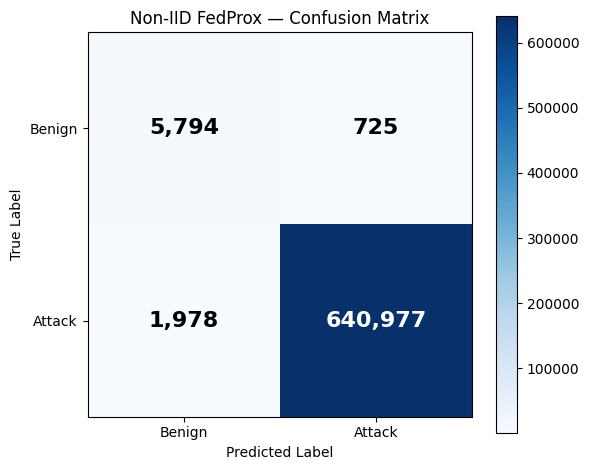

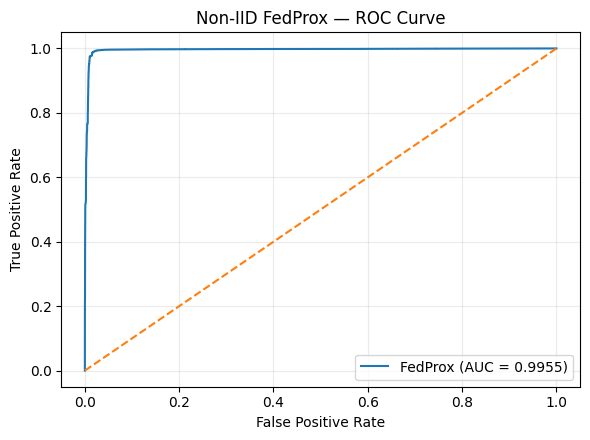

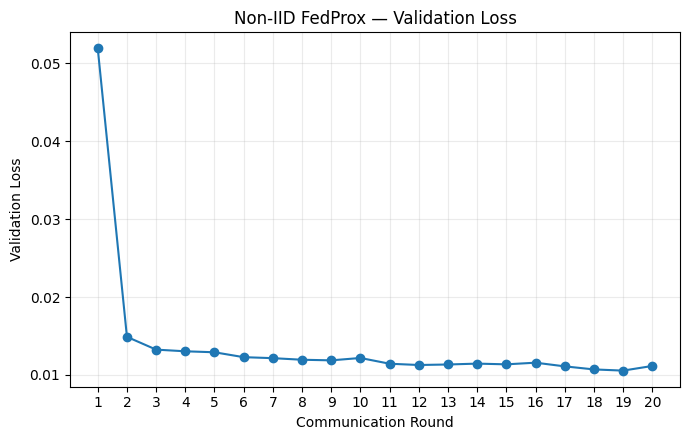


NON-IID FEDPROX EVALUATION COMPLETE
Final evaluated model : Round-20 endpoint
Best validation round : 19
Best validation Macro F1 : 0.907423
Round-20 Val Macro F1    : 0.907327
Inference time           : 253.4 sec

Saved ONLY:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedProx/result/final_metrics.csv

✅ Confusion Matrix displayed.
✅ ROC Curve displayed.
✅ Validation Loss curve displayed.
✅ Figures NOT saved to Drive.
✅ Predictions NOT saved.
✅ Classification report NOT saved.
✅ No duplicate model saved.
✅ FedAvg unchanged.
✅ FedSGD unchanged.
✅ IID results unchanged.


0

In [ ]:
# ================================================================
# CELL 25:
# NON-IID FEDPROX FINAL TEST EVALUATION + FIGURES
# ================================================================
#
# EVALUATES:
#   FedProx Round-20 endpoint
#
# SAVES ONLY:
#   NonIID/FedProx/result/final_metrics.csv
#
# DISPLAYS ONLY:
#   1. Confusion Matrix
#   2. ROC Curve
#   3. Validation Loss Curve
#
# DOES NOT SAVE:
#   - predictions
#   - figures
#   - classification report
#   - duplicate model
#
# DOES NOT TOUCH:
#   - FedAvg
#   - FedSGD
#   - IID experiments
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import time
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ----------------------------------------------------------------
# 2. Required globals
# ----------------------------------------------------------------

required_globals = [
    "FL_ROOT",
    "X_TEST_FILE",
    "Y_TEST_FILE"
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:

    raise RuntimeError(
        "Run setup/data cell first.\n"
        f"Missing: {missing_globals}"
    )


# ----------------------------------------------------------------
# 3. Runtime
# ----------------------------------------------------------------

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices(
        "GPU"
    )
)


if GPU_AVAILABLE:

    INFERENCE_DEVICE = "GPU"

    mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:

    INFERENCE_DEVICE = "CPU"

    mixed_precision.set_global_policy(
        "float32"
    )


TEST_BATCH_SIZE = 4096

THRESHOLD = 0.5


# ----------------------------------------------------------------
# 4. Paths
# ----------------------------------------------------------------

FEDPROX_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedProx"
)


MODEL_FILE = os.path.join(
    FEDPROX_ROOT,
    "model",
    "FedProx_Round20_Final.keras"
)


CONFIG_FILE = os.path.join(
    FEDPROX_ROOT,
    "config.json"
)


HISTORY_FILE = os.path.join(
    FEDPROX_ROOT,
    "result",
    "round_history.csv"
)


METRICS_FILE = os.path.join(
    FEDPROX_ROOT,
    "result",
    "final_metrics.csv"
)


# ----------------------------------------------------------------
# 5. Verify files
# ----------------------------------------------------------------

for path in [
    MODEL_FILE,
    CONFIG_FILE,
    HISTORY_FILE,
    X_TEST_FILE,
    Y_TEST_FILE
]:

    if not os.path.exists(
        path
    ):

        raise FileNotFoundError(
            "Required file missing:\n" + path
        )


# ----------------------------------------------------------------
# 6. Verify training config
# ----------------------------------------------------------------

with open(
    CONFIG_FILE,
    "r"
) as file:

    config = json.load(
        file
    )


if not bool(
    config.get(
        "completed",
        False
    )
):

    raise RuntimeError(
        "FedProx training is not marked complete."
    )


if int(
    config.get(
        "final_model_round"
    ) or -1
) != 20:

    raise RuntimeError(
        "FedProx final model is not Round 20."
    )


if (
    config.get(
        "final_model_policy"
    ) != "Round-20 endpoint"
):

    raise RuntimeError(
        "Unexpected final-model policy."
    )


if not np.isclose(
    float(
        config.get(
            "fedprox_mu",
            -1
        )
    ),
    0.01
):

    raise RuntimeError(
        "Unexpected FedProx mu."
    )


# ----------------------------------------------------------------
# 7. Load + verify history
# ----------------------------------------------------------------

history_df = pd.read_csv(
    HISTORY_FILE
)


if (
    len(
        history_df
    ) != 20
 or
    int(
        history_df[
            "Round"
        ].min()
    ) != 1
 or
    int(
        history_df[
            "Round"
        ].max()
    ) != 20
 or
    history_df[
        "Round"
    ].duplicated().any()
):

    raise RuntimeError(
        "FedProx history must contain "
        "exactly Round 1 → Round 20."
    )


# ----------------------------------------------------------------
# 8. Best validation information
# ----------------------------------------------------------------

best_row = history_df.loc[
    history_df[
        "Val_Macro_F1"
    ].idxmax()
]


BEST_VAL_ROUND = int(
    best_row[
        "Round"
    ]
)


BEST_VAL_MACRO_F1 = float(
    best_row[
        "Val_Macro_F1"
    ]
)


BEST_VAL_BENIGN_RECALL = float(
    best_row[
        "Val_Benign_Recall"
    ]
)


round20_row = history_df[
    history_df[
        "Round"
    ] == 20
].iloc[0]


ROUND20_VAL_MACRO_F1 = float(
    round20_row[
        "Val_Macro_F1"
    ]
)


ROUND20_VAL_BENIGN_RECALL = float(
    round20_row[
        "Val_Benign_Recall"
    ]
)


print("=" * 88)

print(
    "NON-IID FEDPROX — FINAL TEST EVALUATION"
)

print("=" * 88)


print(
    "Final model round : 20"
)


print(
    "Training device   :",
    config.get(
        "completed_device",
        "Unknown"
    )
)


print(
    "Training precision:",
    config.get(
        "completed_precision_policy",
        "Unknown"
    )
)


print(
    "Inference device  :",
    INFERENCE_DEVICE
)


print(
    "FedProx mu        :",
    config.get(
        "fedprox_mu"
    )
)


print(
    "Best validation round:",
    BEST_VAL_ROUND
)


print(
    f"Best validation Macro F1: "
    f"{BEST_VAL_MACRO_F1:.6f}"
)


print(
    f"Round-20 validation Macro F1: "
    f"{ROUND20_VAL_MACRO_F1:.6f}"
)


print(
    f"Round-20 benign recall: "
    f"{ROUND20_VAL_BENIGN_RECALL:.6f}"
)


if BEST_VAL_ROUND != 20:

    print(
        "\n⚠️ Best validation round differs "
        "from the fixed Round-20 endpoint."
    )

    print(
        "✅ Round-20 is still evaluated "
        "for fair algorithm comparison."
    )


# ----------------------------------------------------------------
# 9. Model fingerprint
# ----------------------------------------------------------------

def calculate_sha256(
    path,
    chunk_size=1024 * 1024
):

    hasher = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:

                break

            hasher.update(
                chunk
            )


    return hasher.hexdigest()


MODEL_SHA256 = calculate_sha256(
    MODEL_FILE
)


# ----------------------------------------------------------------
# 10. Load untouched global test data
# ----------------------------------------------------------------

X_test = np.load(
    X_TEST_FILE,
    mmap_mode="r"
)


y_true = np.asarray(
    np.load(
        Y_TEST_FILE,
        mmap_mode="r"
    ),
    dtype=np.int8
).reshape(-1)


if len(
    X_test
) != len(
    y_true
):

    raise RuntimeError(
        "Test X/Y size mismatch."
    )


print(
    "\nTest samples:",
    f"{len(y_true):,}"
)


print(
    "Benign:",
    f"{np.sum(y_true == 0):,}"
)


print(
    "Attack:",
    f"{np.sum(y_true == 1):,}"
)


# ----------------------------------------------------------------
# 11. Load Round-20 model
# ----------------------------------------------------------------

tf.keras.backend.clear_session()


if GPU_AVAILABLE:

    mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:

    mixed_precision.set_global_policy(
        "float32"
    )


model = tf.keras.models.load_model(
    MODEL_FILE,
    compile=False
)


if int(
    model.count_params()
) != 60097:

    raise RuntimeError(
        "Unexpected FedProx model architecture."
    )


print(
    "\nModel parameters:",
    f"{model.count_params():,}"
)


# ----------------------------------------------------------------
# 12. Batch inference
# ----------------------------------------------------------------

probability_parts = []


inference_start = time.time()


for start in range(
    0,
    len(
        y_true
    ),
    TEST_BATCH_SIZE
):

    end = min(
        start + TEST_BATCH_SIZE,
        len(
            y_true
        )
    )


    X_batch = np.asarray(
        X_test[
            start:end
        ],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    batch_probability = (
        model(
            tf.convert_to_tensor(
                X_batch,
                dtype=tf.float32
            ),
            training=False
        )
        .numpy()
        .reshape(-1)
        .astype(
            np.float32,
            copy=False
        )
    )


    probability_parts.append(
        batch_probability
    )


    del (
        X_batch,
        batch_probability
    )


y_prob = np.concatenate(
    probability_parts
)


del probability_parts


inference_time = float(
    time.time() - inference_start
)


if len(
    y_prob
) != len(
    y_true
):

    raise RuntimeError(
        "Prediction count mismatch."
    )


if not np.all(
    np.isfinite(
        y_prob
    )
):

    raise RuntimeError(
        "NaN/Inf detected in predictions."
    )


# ----------------------------------------------------------------
# 13. Fixed classification threshold
# ----------------------------------------------------------------

y_pred = (
    y_prob >= THRESHOLD
).astype(
    np.int8
)


# ----------------------------------------------------------------
# 14. Confusion Matrix
# ----------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)


tn, fp, fn, tp = (
    cm.ravel()
)


# ----------------------------------------------------------------
# 15. Metrics
# ----------------------------------------------------------------

accuracy = float(
    accuracy_score(
        y_true,
        y_pred
    )
)


attack_precision = float(
    precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


attack_recall = float(
    recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


attack_f1 = float(
    f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


macro_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)


weighted_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)


benign_precision = float(
    precision_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


benign_recall = float(
    recall_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


benign_f1 = float(
    f1_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


roc_auc = float(
    roc_auc_score(
        y_true,
        y_prob
    )
)


attack_pr_auc = float(
    average_precision_score(
        y_true,
        y_prob
    )
)


benign_pr_auc = float(
    average_precision_score(
        1 - y_true,
        1.0 - y_prob
    )
)


# ----------------------------------------------------------------
# 16. Classification report
# DISPLAY ONLY
# ----------------------------------------------------------------

report = classification_report(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ],
    target_names=[
        "Benign",
        "Attack"
    ],
    output_dict=True,
    zero_division=0
)


report_df = pd.DataFrame(
    report
).transpose()


# ----------------------------------------------------------------
# 17. Metrics dataframe
# ----------------------------------------------------------------

metrics_df = pd.DataFrame(
    [
        {
            "Algorithm":
                "FedProx",

            "Architecture":
                "CNN-LSTM-ResNet",

            "Partition":
                "Non-IID",

            "NonIID_Type":
                (
                    "Controlled Strong "
                    "Minority-Class Label Skew"
                ),

            "Benign_Allocation":
                "50/25/15/7/3",

            "Clients":
                5,

            "Communication_Rounds":
                20,

            "Local_Epochs":
                1,

            "Local_Batch_Size":
                2048,

            "Local_Optimizer":
                "Adam",

            "Local_LR":
                0.001,

            "FedProx_Mu":
                0.01,

            "Model_Round":
                20,

            "Evaluation_Model_Policy":
                "Round-20 endpoint",

            "Threshold":
                0.5,

            "Accuracy":
                accuracy,

            "Attack_Precision":
                attack_precision,

            "Attack_Recall":
                attack_recall,

            "Attack_F1":
                attack_f1,

            "Macro_F1":
                macro_f1,

            "Weighted_F1":
                weighted_f1,

            "Benign_Precision":
                benign_precision,

            "Benign_Recall":
                benign_recall,

            "Benign_F1":
                benign_f1,

            "Specificity":
                benign_recall,

            "ROC_AUC":
                roc_auc,

            "PR_AUC":
                attack_pr_auc,

            "Benign_PR_AUC":
                benign_pr_auc,

            "TN":
                int(
                    tn
                ),

            "FP":
                int(
                    fp
                ),

            "FN":
                int(
                    fn
                ),

            "TP":
                int(
                    tp
                ),

            "Test_Samples":
                int(
                    len(
                        y_true
                    )
                ),

            "Best_Validation_Round":
                BEST_VAL_ROUND,

            "Best_Validation_Macro_F1":
                BEST_VAL_MACRO_F1,

            "Best_Validation_Benign_Recall":
                BEST_VAL_BENIGN_RECALL,

            "Round20_Validation_Macro_F1":
                ROUND20_VAL_MACRO_F1,

            "Round20_Validation_Benign_Recall":
                ROUND20_VAL_BENIGN_RECALL,

            "Training_Device":
                config.get(
                    "completed_device",
                    "Unknown"
                ),

            "Training_Precision":
                config.get(
                    "completed_precision_policy",
                    "Unknown"
                ),

            "Model_SHA256":
                MODEL_SHA256
        }
    ]
)


# ----------------------------------------------------------------
# 18. Save ONLY final_metrics.csv
# Re-run safe
# ----------------------------------------------------------------

SHOULD_SAVE = True


if os.path.exists(
    METRICS_FILE
):

    try:

        existing_metrics = pd.read_csv(
            METRICS_FILE
        )


        if (
            not existing_metrics.empty
 and
            "Model_SHA256"
            in
            existing_metrics.columns
 and
            str(
                existing_metrics.iloc[
                    0
                ][
                    "Model_SHA256"
                ]
            ) == MODEL_SHA256
 and
            int(
                existing_metrics.iloc[
                    0
                ][
                    "Model_Round"
                ]
            ) == 20
        ):

            SHOULD_SAVE = False


    except Exception:

        SHOULD_SAVE = True


if SHOULD_SAVE:

    temp_metrics_file = (
        METRICS_FILE + ".tmp.csv"
    )


    metrics_df.to_csv(
        temp_metrics_file,
        index=False
    )


    os.replace(
        temp_metrics_file,
        METRICS_FILE
    )


    print(
        "\n✅ FedProx final metrics saved."
    )


else:

    print(
        "\n✅ Existing FedProx metrics already "
        "belong to this exact model."
    )


    print(
        "✅ Metrics file not rewritten."
    )


# ----------------------------------------------------------------
# 19. Print final results
# ----------------------------------------------------------------

print(
    "\n" + "=" * 88
)


print(
    "NON-IID FEDPROX FINAL TEST RESULTS"
)


print(
    "=" * 88
)


print(
    f"Accuracy         : "
    f"{accuracy:.6f}"
)


print(
    f"Attack Precision : "
    f"{attack_precision:.6f}"
)


print(
    f"Attack Recall    : "
    f"{attack_recall:.6f}"
)


print(
    f"Attack F1        : "
    f"{attack_f1:.6f}"
)


print(
    f"Macro F1         : "
    f"{macro_f1:.6f}"
)


print(
    f"Weighted F1      : "
    f"{weighted_f1:.6f}"
)


print(
    f"Benign Precision : "
    f"{benign_precision:.6f}"
)


print(
    f"Benign Recall    : "
    f"{benign_recall:.6f}"
)


print(
    f"Benign F1        : "
    f"{benign_f1:.6f}"
)


print(
    f"ROC-AUC          : "
    f"{roc_auc:.6f}"
)


print(
    f"PR-AUC           : "
    f"{attack_pr_auc:.6f}"
)


print(
    f"Benign PR-AUC    : "
    f"{benign_pr_auc:.6f}"
)


print(
    "\nConfusion Matrix:"
)


print(
    f"TN = {tn}"
)


print(
    f"FP = {fp}"
)


print(
    f"FN = {fn}"
)


print(
    f"TP = {tp}"
)


print(
    "\nClassification Report:"
)


display(
    report_df
)


# ================================================================
# 20. FIGURE 1 — CONFUSION MATRIX
# DISPLAY ONLY
# ================================================================

plt.figure(
    figsize=(
        6,
        5
    )
)


plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)


plt.title(
    "Non-IID FedProx — Confusion Matrix"
)


plt.colorbar()


plt.xticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.yticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


cm_threshold = (
    cm.max() / 2.0
)


for i in range(
    2
):

    for j in range(
        2
    ):

        value = int(
            cm[
                i,
                j
            ]
        )


        plt.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if
                value > cm_threshold
                else
                "black"
            )
        )


plt.tight_layout()

plt.show()


# ================================================================
# 21. FIGURE 2 — ROC CURVE
# DISPLAY ONLY
# ================================================================

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)


plt.figure(
    figsize=(
        6,
        4.5
    )
)


plt.plot(
    fpr,
    tpr,
    label=(
        f"FedProx "
        f"(AUC = {roc_auc:.4f})"
    )
)


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "Non-IID FedProx — ROC Curve"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ================================================================
# 22. FIGURE 3 — VALIDATION LOSS
# DISPLAY ONLY
# ================================================================

plt.figure(
    figsize=(
        7,
        4.5
    )
)


plt.plot(
    history_df[
        "Round"
    ],
    history_df[
        "Val_Loss"
    ],
    marker="o"
)


plt.xlabel(
    "Communication Round"
)


plt.ylabel(
    "Validation Loss"
)


plt.title(
    "Non-IID FedProx — Validation Loss"
)


plt.xticks(
    range(
        1,
        21
    )
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ----------------------------------------------------------------
# 23. Final status
# ----------------------------------------------------------------

print(
    "\n" + "=" * 88
)


print(
    "NON-IID FEDPROX EVALUATION COMPLETE"
)


print(
    "=" * 88
)


print(
    "Final evaluated model : "
    "Round-20 endpoint"
)


print(
    "Best validation round :",
    BEST_VAL_ROUND
)


print(
    f"Best validation Macro F1 : "
    f"{BEST_VAL_MACRO_F1:.6f}"
)


print(
    f"Round-20 Val Macro F1    : "
    f"{ROUND20_VAL_MACRO_F1:.6f}"
)


print(
    f"Inference time           : "
    f"{inference_time:.1f} sec"
)


print(
    "\nSaved ONLY:"
)


print(
    METRICS_FILE
)


print(
    "\n✅ Confusion Matrix displayed."
)


print(
    "✅ ROC Curve displayed."
)


print(
    "✅ Validation Loss curve displayed."
)


print(
    "✅ Figures NOT saved to Drive."
)


print(
    "✅ Predictions NOT saved."
)


print(
    "✅ Classification report NOT saved."
)


print(
    "✅ No duplicate model saved."
)


print(
    "✅ FedAvg unchanged."
)


print(
    "✅ FedSGD unchanged."
)


print(
    "✅ IID results unchanged."
)


print(
    "=" * 88
)


# ----------------------------------------------------------------
# 24. Cleanup
# ----------------------------------------------------------------

del (
    model,
    X_test,
    y_true,
    y_prob,
    y_pred
)


tf.keras.backend.clear_session()

gc.collect()


In [ ]:
# ================================================================
# CELL 26: NON-IID FEDADAM TRAINING
# FINAL + EXACT RESUME + MINIMAL DRIVE STORAGE
# ================================================================
#
# SAME FINAL FEDADAM PROTOCOL AS IID:
#
#   Local optimizer       : Adam
#   Local LR              : 0.001
#   Local epochs          : 1
#   Local batch size      : 2048
#
#   Server optimizer      : FedAdam
#   Server LR             : 0.01
#   beta1                 : 0.9
#   beta2                 : 0.99
#   tau                   : 0.001
#   Initial v             : tau^2
#
#   Aggregated quantity   : Sample-size weighted model delta
#   Clients               : 5
#   Rounds                : 20
#   Final model           : Round-20 endpoint
#
# NON-IID:
#   Controlled Strong Minority-Class Label Skew
#   Benign allocation = 50/25/15/7/3
#
# PERMANENT DRIVE ARTIFACTS:
#   1. config.json
#   2. round_history.csv
#   3. FedAdam_Round20_Final.keras
#
# TEMPORARY DURING TRAINING:
#   ONE rolling state checkpoint containing:
#       - global weights
#       - FedAdam m
#       - FedAdam v
#
#   Deleted automatically after successful Round 20.
#
# NO:
#   - predictions
#   - figures
#   - per-round final models
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import re
import gc
import json
import time
import shutil
import hashlib

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score
)


# ================================================================
# 2. Required notebook objects
# ================================================================

required_globals = [
    "FL_ROOT",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "NUM_FEATURES",
    "RANDOM_SEED",
    "build_federated_binary_model"
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:

    raise RuntimeError(
        "Run setup/data/model architecture cells first.\n"
        f"Missing: {missing_globals}"
    )


# ================================================================
# 3. FIXED FEDADAM PROTOCOL
# ================================================================

FA_NUM_CLIENTS = 5
FA_ROUNDS = 20

FA_LOCAL_EPOCHS = 1
FA_BATCH_SIZE = 2048
FA_LOCAL_LR = 0.001

FA_SERVER_LR = 0.01
FA_BETA1 = 0.9
FA_BETA2 = 0.99
FA_TAU = 0.001


# ================================================================
# 4. Runtime precision
# ================================================================

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices(
        "GPU"
    )
)

if GPU_AVAILABLE:

    FA_DEVICE = "GPU"
    FA_PRECISION = "mixed_float16"
    FA_LOSS_SCALE = 1024.0

else:

    FA_DEVICE = "CPU"
    FA_PRECISION = "float32"
    FA_LOSS_SCALE = 1.0


mixed_precision.set_global_policy(
    FA_PRECISION
)


print("=" * 88)
print(
    "NON-IID FEDADAM — STRONG LABEL-SKEW — 5 CLIENTS"
)
print("=" * 88)

print(
    "Runtime device :",
    FA_DEVICE
)

print(
    "Precision      :",
    FA_PRECISION
)

print(
    "Local LR       :",
    FA_LOCAL_LR
)

print(
    "Local epochs   :",
    FA_LOCAL_EPOCHS
)

print(
    "Batch size     :",
    FA_BATCH_SIZE
)

print(
    "Server LR      :",
    FA_SERVER_LR
)

print(
    "beta1          :",
    FA_BETA1
)

print(
    "beta2          :",
    FA_BETA2
)

print(
    "tau            :",
    FA_TAU
)

print(
    "Initial v      : tau^2"
)


# ================================================================
# 5. Dedicated paths
# ================================================================

FA_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedAdam_ServerLR_0.01"
)

FA_MODEL_DIR = os.path.join(
    FA_ROOT,
    "model"
)

FA_RESULT_DIR = os.path.join(
    FA_ROOT,
    "result"
)

FA_CHECKPOINT_DIR = os.path.join(
    FA_ROOT,
    "checkpoint"
)


for directory in [
    FA_ROOT,
    FA_MODEL_DIR,
    FA_RESULT_DIR,
    FA_CHECKPOINT_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


FA_PARTITION_FILE = os.path.join(
    FL_ROOT,
    "partition",
    "NonIID",
    "Strong_LabelSkew_5Clients_Binary_partition.npz"
)

FA_CONFIG_FILE = os.path.join(
    FA_ROOT,
    "config.json"
)

FA_HISTORY_FILE = os.path.join(
    FA_RESULT_DIR,
    "round_history.csv"
)

FA_FINAL_MODEL_FILE = os.path.join(
    FA_MODEL_DIR,
    "FedAdam_Round20_Final.keras"
)


if not os.path.exists(
    FA_PARTITION_FILE
):

    raise FileNotFoundError(
        "Non-IID partition missing:\n" + FA_PARTITION_FILE
    )


# ================================================================
# 6. Load exact frozen Non-IID partition
# ================================================================

with np.load(
    FA_PARTITION_FILE,
    allow_pickle=False
) as partition_data:

    fa_assignment = np.asarray(
        partition_data[
            "assignment"
        ],
        dtype=np.int8
    )


fa_validation_indices = np.flatnonzero(
    fa_assignment == -1
).astype(
    np.int32,
    copy=False
)


fa_client_indices = [

    np.flatnonzero(
        fa_assignment == client_id
    ).astype(
        np.int32,
        copy=False
    )

    for client_id
    in range(
        FA_NUM_CLIENTS
    )
]


fa_client_sizes = np.asarray(
    [
        len(indices)
        for indices in fa_client_indices
    ],
    dtype=np.int64
)


if (
    fa_client_sizes.max() - fa_client_sizes.min() > 1
):

    raise RuntimeError(
        "Unexpected client-size distribution."
    )


# ================================================================
# 7. Verify class distribution
# ================================================================

y_partition_check = np.load(
    Y_TRAIN_FILE,
    mmap_mode="r"
)


fa_benign_counts = []
fa_attack_counts = []


for indices in fa_client_indices:

    labels = np.asarray(
        y_partition_check[
            indices
        ],
        dtype=np.int8
    )

    counts = np.bincount(
        labels,
        minlength=2
    )

    fa_benign_counts.append(
        int(
            counts[0]
        )
    )

    fa_attack_counts.append(
        int(
            counts[1]
        )
    )


EXPECTED_BENIGN_COUNTS = get_expected_benign_counts(
    y_partition_check,
    fa_validation_indices,
    BENIGN_ALLOCATION
)


if (
    fa_benign_counts != EXPECTED_BENIGN_COUNTS
):

    raise RuntimeError(
        "Non-IID partition does not match "
        "the frozen 50/25/15/7/3 design."
    )


partition_sha256 = hashlib.sha256(
    fa_assignment.tobytes()
).hexdigest()


print(
    "\n✅ Non-IID partition verified."
)

print(
    "Client sizes :",
    fa_client_sizes.tolist()
)

print(
    "Benign counts:",
    fa_benign_counts
)

print(
    "Attack counts:",
    fa_attack_counts
)

print(
    "Validation samples:",
    f"{len(fa_validation_indices):,}"
)


del y_partition_check

gc.collect()


# ================================================================
# 8. Atomic JSON / CSV helpers
# ================================================================

def fa_save_json_atomic(
    path,
    data
):

    temp = path + ".tmp"

    with open(
        temp,
        "w"
    ) as file:

        json.dump(
            data,
            file,
            indent=2
        )

    os.replace(
        temp,
        path
    )


def fa_save_csv_atomic(
    dataframe,
    path
):

    temp = path + ".tmp.csv"

    dataframe.to_csv(
        temp,
        index=False
    )

    os.replace(
        temp,
        path
    )


# ================================================================
# 9. Frozen experiment config
# ================================================================

CURRENT_CONFIG = {

    "algorithm":
        "FedAdam",

    "variant":
        "ServerLR_0.01_v0_tau2",

    "architecture":
        "CNN-LSTM-ResNet",

    "partition":
        (
            "Controlled Strong "
            "Minority-Class Label Skew"
        ),

    "benign_allocation":
        "50/25/15/7/3",

    "partition_sha256":
        partition_sha256,

    "num_clients":
        5,

    "communication_rounds":
        20,

    "local_epochs":
        1,

    "local_batch_size":
        2048,

    "local_optimizer":
        "Adam",

    "local_learning_rate":
        0.001,

    "aggregation":
        "Sample-size weighted model delta",

    "server_optimizer":
        "FedAdam",

    "server_learning_rate":
        0.01,

    "server_beta1":
        0.9,

    "server_beta2":
        0.99,

    "server_tau":
        0.001,

    "server_v_initialization":
        "tau^2",

    "final_model_policy":
        "Round-20 endpoint",

    "random_seed":
        int(
            RANDOM_SEED
        ),

    "precision_policy":
        FA_PRECISION,

    "static_loss_scale":
        float(
            FA_LOSS_SCALE
        )
}


# ================================================================
# 10. History
# ================================================================

HISTORY_COLUMNS = [
    "Round",
    "Val_Loss",
    "Val_Accuracy",
    "Val_Macro_F1",
    "Val_Benign_Recall",
    "Round_Time_sec"
]


if os.path.exists(
    FA_HISTORY_FILE
):

    history_df = pd.read_csv(
        FA_HISTORY_FILE
    )

else:

    history_df = pd.DataFrame(
        columns=HISTORY_COLUMNS
    )


if not history_df.empty:

    history_df[
        "Round"
    ] = history_df[
        "Round"
    ].astype(
        int
    )

    if history_df[
        "Round"
    ].duplicated().any():

        raise RuntimeError(
            "Duplicate FedAdam rounds found."
        )


# ================================================================
# 11. FedAdam state checkpoint
#
# IMPORTANT:
# FedAdam cannot be resumed correctly from global model weights
# alone because server m and v must also be restored.
# ================================================================

state_pattern = re.compile(
    r"^round_(\d{2})_state\.npz$"
)


def fa_list_states():

    states = []

    if not os.path.isdir(
        FA_CHECKPOINT_DIR
    ):

        return states

    for filename in os.listdir(
        FA_CHECKPOINT_DIR
    ):

        match = state_pattern.match(
            filename
        )

        if match:

            states.append(
                (
                    int(
                        match.group(1)
                    ),

                    os.path.join(
                        FA_CHECKPOINT_DIR,
                        filename
                    )
                )
            )

    return sorted(
        states
    )


def fa_remove_old_states(
    keep_round=None
):

    for round_number, path in fa_list_states():

        if (
            keep_round is None or round_number != keep_round
        ):

            try:

                os.remove(
                    path
                )

            except FileNotFoundError:

                pass


def fa_save_state(
    round_number,
    global_weights,
    server_m,
    server_v
):

    final_path = os.path.join(
        FA_CHECKPOINT_DIR,
        f"round_{round_number:02d}_state.npz"
    )

    temp_path = os.path.join(
        FA_CHECKPOINT_DIR,
        f".round_{round_number:02d}_state.tmp.npz"
    )


    payload = {
        "round":
            np.asarray(
                [round_number],
                dtype=np.int32
            ),

        "num_weights":
            np.asarray(
                [len(global_weights)],
                dtype=np.int32
            )
    }


    for i, weight in enumerate(
        global_weights
    ):

        payload[
            f"global_{i}"
        ] = np.asarray(
            weight,
            dtype=np.float32
        )


    for i, moment in enumerate(
        server_m
    ):

        payload[
            f"m_{i}"
        ] = np.asarray(
            moment,
            dtype=np.float32
        )


    for i, variance in enumerate(
        server_v
    ):

        payload[
            f"v_{i}"
        ] = np.asarray(
            variance,
            dtype=np.float32
        )


    if os.path.exists(
        temp_path
    ):

        os.remove(
            temp_path
        )


    np.savez(
        temp_path,
        **payload
    )


    os.replace(
        temp_path,
        final_path
    )


    fa_remove_old_states(
        keep_round=round_number
    )


    return final_path


def fa_load_state(
    state_path
):

    with np.load(
        state_path,
        allow_pickle=False
    ) as state:

        saved_round = int(
            state[
                "round"
            ][0]
        )

        number_of_weights = int(
            state[
                "num_weights"
            ][0]
        )


        global_weights = [

            np.asarray(
                state[
                    f"global_{i}"
                ],
                dtype=np.float32
            ).copy()

            for i in range(
                number_of_weights
            )
        ]


        server_m = [

            np.asarray(
                state[
                    f"m_{i}"
                ],
                dtype=np.float32
            ).copy()

            for i in range(
                number_of_weights
            )
        ]


        server_v = [

            np.asarray(
                state[
                    f"v_{i}"
                ],
                dtype=np.float32
            ).copy()

            for i in range(
                number_of_weights
            )
        ]


    return (
        saved_round,
        global_weights,
        server_m,
        server_v
    )


# ================================================================
# 12. Config lock / precision safety
# CORRECTED:
#
# ORDER:
#   1. Verify core experiment configuration
#   2. If Round-20 final model already exists:
#        - allow current CPU/GPU precision to differ
#        - DO NOT resume training
#        - DO NOT change original saved precision
#   3. If experiment is partial:
#        - precision MUST match
#   4. If experiment never started:
#        - current runtime precision may be adopted safely
# ================================================================


# ------------------------------------------------
# Detect saved experiment state FIRST
# ------------------------------------------------

final_model_exists = os.path.exists(
    FA_FINAL_MODEL_FILE
)


saved_states_now = fa_list_states()


history_has_progress = (
    not history_df.empty
)


state_has_progress = (
    len(saved_states_now) > 0
)


# Partial progress means:
# training exists but no completed Round-20 model.
has_partial_progress = (
    (
        history_has_progress
        or state_has_progress
    )
    and not final_model_exists
)


# ================================================================
# Existing config
# ================================================================

if os.path.exists(
    FA_CONFIG_FILE
):

    with open(
        FA_CONFIG_FILE,
        "r"
    ) as file:

        saved_config = json.load(
            file
        )


    # ------------------------------------------------------------
    # Core experimental settings must always match.
    #
    # Precision is intentionally excluded because
    # a completed experiment may later be inspected
    # from another CPU/GPU runtime.
    # ------------------------------------------------------------

    CORE_KEYS = [
        "algorithm",
        "variant",
        "architecture",
        "partition",
        "benign_allocation",
        "partition_sha256",
        "num_clients",
        "communication_rounds",
        "local_epochs",
        "local_batch_size",
        "local_optimizer",
        "local_learning_rate",
        "aggregation",
        "server_optimizer",
        "server_learning_rate",
        "server_beta1",
        "server_beta2",
        "server_tau",
        "server_v_initialization",
        "final_model_policy",
        "random_seed"
    ]


    mismatches = {

        key: {
            "saved":
                saved_config.get(
                    key
                ),

            "current":
                CURRENT_CONFIG.get(
                    key
                )
        }

        for key in CORE_KEYS

        if (
            saved_config.get(
                key
            )
            !=
            CURRENT_CONFIG.get(
                key
            )
        )
    }


    if mismatches:

        raise RuntimeError(
            "Non-IID FedAdam protocol mismatch:\n"
            +
            json.dumps(
                mismatches,
                indent=2
            )
        )


    saved_precision = saved_config.get(
        "precision_policy"
    )


    current_precision = FA_PRECISION


    precision_changed = (
        saved_precision is not None
        and
        saved_precision != current_precision
    )


    # ============================================================
    # CASE 1:
    # ROUND-20 FINAL MODEL ALREADY EXISTS
    #
    # Runtime precision is irrelevant for TRAINING because
    # no training will be resumed.
    #
    # IMPORTANT:
    # Keep ORIGINAL saved precision metadata unchanged.
    # ============================================================

    if final_model_exists:

        runtime_config = saved_config


        if precision_changed:

            print(
                "\nℹ️ Existing completed FedAdam experiment "
                "was trained under another precision policy."
            )

            print(
                "Saved training precision :",
                saved_precision
            )

            print(
                "Current runtime precision:",
                current_precision
            )

            print(
                "✅ Allowed because Round-20 final model exists."
            )

            print(
                "✅ Training will NOT be resumed."
            )


    # ============================================================
    # CASE 2:
    # PARTIAL TRAINING EXISTS
    #
    # Exact FedAdam resume requires:
    #   - same global weights
    #   - same server m
    #   - same server v
    #   - same precision policy
    #
    # Therefore CPU/GPU precision mixing is forbidden.
    # ============================================================

    elif has_partial_progress:

        if saved_precision is None:

            raise RuntimeError(
                "Partial FedAdam training exists, but the saved "
                "config has no precision-policy metadata.\n"
                "Safe automatic resume is not possible."
            )


        if precision_changed:

            raise RuntimeError(
                "FedAdam has PARTIAL training progress created "
                "under another precision mode.\n\n"
                f"Saved precision  : {saved_precision}\n"
                f"Current precision: {current_precision}\n\n"
                "Do NOT mix CPU/GPU precision during resume.\n"
                "Use the original runtime or restart this "
                "FedAdam experiment from Round 1."
            )


        runtime_config = saved_config


        print(
            "\n✅ Partial FedAdam state uses the same "
            "precision policy."
        )

        print(
            "Resume precision:",
            current_precision
        )


    # ============================================================
    # CASE 3:
    # NO MODEL / NO HISTORY / NO SERVER STATE
    #
    # Experiment has not meaningfully started.
    # Current runtime precision may safely become the
    # experiment precision.
    # ============================================================

    else:

        if (
            saved_precision is None
            or precision_changed
        ):

            previous_precision = (
                saved_precision
            )


            saved_config.update(
                CURRENT_CONFIG
            )


            saved_config[
                "completed"
            ] = False


            saved_config[
                "final_model_round"
            ] = None


            saved_config.pop(
                "completed_device",
                None
            )


            saved_config.pop(
                "completed_precision_policy",
                None
            )


            fa_save_json_atomic(
                FA_CONFIG_FILE,
                saved_config
            )


            print(
                "\n✅ FedAdam precision policy updated safely."
            )

            print(
                "Previous precision:",
                previous_precision
            )

            print(
                "Current precision :",
                current_precision
            )

            print(
                "✅ No completed or resumable training state exists."
            )


        runtime_config = (
            saved_config
        )


# ================================================================
# No existing config
# ================================================================

else:

    # ------------------------------------------------------------
    # A final model without config is suspicious.
    # Do NOT silently create new metadata because that could
    # incorrectly claim the current CPU/GPU precision was used.
    # ------------------------------------------------------------

    if final_model_exists:

        raise RuntimeError(
            "FedAdam Round-20 final model exists, "
            "but config.json is missing.\n"
            "For reproducibility, no new config was fabricated."
        )


    runtime_config = dict(
        CURRENT_CONFIG
    )


    runtime_config[
        "completed"
    ] = False


    runtime_config[
        "final_model_round"
    ] = None


    fa_save_json_atomic(
        FA_CONFIG_FILE,
        runtime_config
    )


    print(
        "\n✅ New Non-IID FedAdam config created."
    )


# ================================================================
# 13. Completed model check
#
# IMPORTANT:
# This now happens safely AFTER core protocol validation,
# but BEFORE any attempt to TRAIN / RESUME.
# ================================================================

if final_model_exists:

    # ------------------------------------------------------------
    # Verify exact Round-1 → Round-20 history
    # ------------------------------------------------------------

    if history_df.empty:

        raise RuntimeError(
            "FedAdam final model exists but "
            "round history is missing."
        )


    if (
        len(
            history_df
        ) != 20
    ):

        raise RuntimeError(
            "FedAdam final model exists but "
            "history does not contain exactly 20 rounds."
        )


    history_rounds = sorted(
        history_df[
            "Round"
        ]
        .astype(int)
        .tolist()
    )


    if history_rounds != list(
        range(
            1,
            21
        )
    ):

        raise RuntimeError(
            "FedAdam final model exists but "
            "history is not exactly Round 1 → Round 20."
        )


    if history_df[
        "Round"
    ].duplicated().any():

        raise RuntimeError(
            "Duplicate FedAdam rounds detected."
        )


    # ------------------------------------------------------------
    # Verify architecture
    # ------------------------------------------------------------

    check_model = (
        tf.keras.models.load_model(
            FA_FINAL_MODEL_FILE,
            compile=False
        )
    )


    if int(
        check_model.count_params()
    ) != 60097:

        del check_model

        tf.keras.backend.clear_session()

        gc.collect()

        raise RuntimeError(
            "Unexpected final FedAdam architecture."
        )


    del check_model


    tf.keras.backend.clear_session()

    gc.collect()


    # Restore CURRENT runtime policy after loading model.
    mixed_precision.set_global_policy(
        FA_PRECISION
    )


    # ------------------------------------------------------------
    # Repair completion flags if necessary.
    #
    # IMPORTANT:
    # Do NOT replace original training precision/device.
    # ------------------------------------------------------------

    runtime_config[
        "completed"
    ] = True


    runtime_config[
        "final_model_round"
    ] = 20


    # If old config already recorded completed training
    # precision/device, preserve them.
    #
    # If precision completion metadata is missing,
    # use the original saved training precision,
    # NOT the current runtime precision.

    if (
        runtime_config.get(
            "completed_precision_policy"
        )
        is None
    ):

        runtime_config[
            "completed_precision_policy"
        ] = runtime_config.get(
            "precision_policy"
        )


    fa_save_json_atomic(
        FA_CONFIG_FILE,
        runtime_config
    )


    # ------------------------------------------------------------
    # Completed experiment does not need server-state checkpoints.
    # ------------------------------------------------------------

    fa_remove_old_states()


    try:

        if (
            os.path.isdir(
                FA_CHECKPOINT_DIR
            )
            and
            not os.listdir(
                FA_CHECKPOINT_DIR
            )
        ):

            os.rmdir(
                FA_CHECKPOINT_DIR
            )

    except OSError:

        pass


    print(
        "\n"
        +
        "=" * 88
    )

    print(
        "NON-IID FEDADAM — EXISTING COMPLETED EXPERIMENT"
    )

    print(
        "=" * 88
    )


    print(
        "✅ Round-20 final model exists."
    )

    print(
        "✅ Round 1 → Round 20 history verified."
    )

    print(
        "✅ CNN-LSTM-ResNet architecture verified."
    )

    print(
        "✅ Original training precision preserved:",
        runtime_config.get(
            "precision_policy"
        )
    )


    if runtime_config.get(
        "completed_device"
    ) is not None:

        print(
            "✅ Original training device preserved:",
            runtime_config.get(
                "completed_device"
            )
        )


    print(
        "✅ Training skipped."
    )


    print(
        "\nFinal model:"
    )

    print(
        FA_FINAL_MODEL_FILE
    )


    print(
        "=" * 88
    )




# ================================================================
# 14. TRAIN / RESUME
# ================================================================

else:

    # ------------------------------------------------------------
    # Temporary LOCAL Colab cache
    # ------------------------------------------------------------

    LOCAL_CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )

    os.makedirs(
        LOCAL_CACHE_DIR,
        exist_ok=True
    )


    LOCAL_X_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "X_train_scaled_float32.npy"
    )


    LOCAL_Y_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "y_train_int8.npy"
    )


    for source, destination in [
        (
            X_TRAIN_FILE,
            LOCAL_X_FILE
        ),
        (
            Y_TRAIN_FILE,
            LOCAL_Y_FILE
        )
    ]:

        if not os.path.exists(
            destination
        ):

            print(
                "Copying to temporary Colab disk:",
                os.path.basename(
                    source
                )
            )

            shutil.copy2(
                source,
                destination
            )


    X_train_fa = np.load(
        LOCAL_X_FILE,
        mmap_mode="r"
    )


    y_train_fa = np.load(
        LOCAL_Y_FILE,
        mmap_mode="r"
    )


    # ------------------------------------------------------------
    # Validation set
    # ------------------------------------------------------------

    X_val_fa = np.asarray(
        X_train_fa[
            fa_validation_indices
        ],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    y_val_fa = np.asarray(
        y_train_fa[
            fa_validation_indices
        ],
        dtype=np.int8
    )


    print(
        "\nValidation samples:",
        f"{len(y_val_fa):,}"
    )


    # ============================================================
    # 15. Validation helper
    # ============================================================

    VAL_BATCH_SIZE = 4096


    def fa_evaluate_global(
        global_weights
    ):

        tf.keras.backend.clear_session()

        mixed_precision.set_global_policy(
            FA_PRECISION
        )


        evaluation_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        evaluation_model.set_weights(
            global_weights
        )


        probability_parts = []


        for start in range(
            0,
            len(
                y_val_fa
            ),
            VAL_BATCH_SIZE
        ):

            end = min(
                start + VAL_BATCH_SIZE,
                len(
                    y_val_fa
                )
            )


            batch_x = tf.convert_to_tensor(
                X_val_fa[
                    start:end
                ],
                dtype=tf.float32
            )


            probability = (
                evaluation_model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
                .astype(
                    np.float32,
                    copy=False
                )
            )


            probability_parts.append(
                probability
            )


        y_probability = np.concatenate(
            probability_parts
        )


        y_prediction = (
            y_probability >= 0.5
        ).astype(
            np.int8
        )


        epsilon = 1e-7


        clipped_probability = np.clip(
            y_probability,
            epsilon,
            1.0 - epsilon
        )


        validation_loss = float(
            -np.mean(
                y_val_fa * np.log(
                    clipped_probability
                )
 +
                (
                    1 - y_val_fa
                ) * np.log(
                    1.0 - clipped_probability
                )
            )
        )


        validation_accuracy = float(
            accuracy_score(
                y_val_fa,
                y_prediction
            )
        )


        validation_macro_f1 = float(
            f1_score(
                y_val_fa,
                y_prediction,
                average="macro",
                zero_division=0
            )
        )


        validation_benign_recall = float(
            recall_score(
                y_val_fa,
                y_prediction,
                pos_label=0,
                zero_division=0
            )
        )


        del (
            probability_parts,
            y_probability,
            y_prediction,
            clipped_probability
        )


        return (
            evaluation_model,
            validation_loss,
            validation_accuracy,
            validation_macro_f1,
            validation_benign_recall
        )


    # ============================================================
    # 16. Resume OR fresh initialization
    # ============================================================

    saved_states = fa_list_states()


    if saved_states:

        (
            last_state_round,
            state_path
        ) = saved_states[-1]


        (
            saved_round,
            global_weights,
            server_m,
            server_v
        ) = fa_load_state(
            state_path
        )


        if (
            saved_round != last_state_round
        ):

            raise RuntimeError(
                "FedAdam state checkpoint round mismatch."
            )


        if (
            not history_df.empty and int(
                history_df[
                    "Round"
                ].max()
            ) > saved_round
        ):

            history_df = history_df[
                history_df[
                    "Round"
                ] <= saved_round
            ].copy()


            fa_save_csv_atomic(
                history_df,
                FA_HISTORY_FILE
            )


            print(
                "⚠️ History trimmed to latest "
                "safe FedAdam state."
            )


        if (
            history_df.empty or int(
                history_df[
                    "Round"
                ].max()
            ) < saved_round
        ):

            raise RuntimeError(
                "FedAdam state is ahead of history."
            )


        START_ROUND = (
            saved_round + 1
        )


        print(
            "\n🔄 RESUMING NON-IID FEDADAM"
        )

        print(
            "Last completed round:",
            saved_round
        )

        print(
            "Next round:",
            START_ROUND
        )


    else:

        if not history_df.empty:

            print(
                "\n⚠️ History exists but no exact "
                "FedAdam state checkpoint survives."
            )

            print(
                "Starting fresh from Round 1."
            )


            history_df = pd.DataFrame(
                columns=HISTORY_COLUMNS
            )


            fa_save_csv_atomic(
                history_df,
                FA_HISTORY_FILE
            )


        tf.keras.backend.clear_session()

        mixed_precision.set_global_policy(
            FA_PRECISION
        )


        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )


        initial_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        if int(
            initial_model.count_params()
        ) != 60097:

            raise RuntimeError(
                "Unexpected architecture."
            )


        global_weights = [

            np.asarray(
                weight,
                dtype=np.float32
            ).copy()

            for weight
            in initial_model.get_weights()
        ]


        # FedAdam first moment
        server_m = [

            np.zeros_like(
                weight,
                dtype=np.float32
            )

            for weight
            in global_weights
        ]


        # Corrected final IID FedAdam policy:
        # initial second moment = tau^2
        server_v = [

            np.full_like(
                weight,
                FA_TAU ** 2,
                dtype=np.float32
            )

            for weight
            in global_weights
        ]


        del initial_model

        tf.keras.backend.clear_session()

        gc.collect()

        mixed_precision.set_global_policy(
            FA_PRECISION
        )


        START_ROUND = 1


        print(
            "\n🟢 FRESH NON-IID FEDADAM RUN"
        )

        print(
            "Round 1 → Round 20"
        )


    # ------------------------------------------------------------
    # State shape validation
    # ------------------------------------------------------------

    if not (
        len(
            global_weights
        ) == len(
            server_m
        ) == len(
            server_v
        )
    ):

        raise RuntimeError(
            "FedAdam server-state length mismatch."
        )


    # ============================================================
    # 17. Communication rounds
    # ============================================================

    for round_number in range(
        START_ROUND,
        FA_ROUNDS + 1
    ):

        round_start = time.time()


        print(
            "\n" + "=" * 72
        )

        print(
            f"NON-IID FEDADAM ROUND "
            f"{round_number}/20"
        )

        print(
            "=" * 72
        )


        # --------------------------------------------------------
        # Sample-weighted model DELTA accumulator
        # --------------------------------------------------------

        delta_accumulator = [

            np.zeros_like(
                weight,
                dtype=np.float64
            )

            for weight
            in global_weights
        ]


        total_samples = 0


        # ========================================================
        # CLIENT LOOP
        # ========================================================

        for client_id in range(
            FA_NUM_CLIENTS
        ):

            client_start = time.time()


            indices = fa_client_indices[
                client_id
            ]


            client_sample_count = int(
                len(
                    indices
                )
            )


            print(
                f"\nClient {client_id + 1}/5"
            )

            print(
                "Samples:",
                f"{client_sample_count:,}"
            )

            print(
                "Benign :",
                fa_benign_counts[
                    client_id
                ]
            )

            print(
                "Attack :",
                fa_attack_counts[
                    client_id
                ]
            )


            # ----------------------------------------------------
            # One client in RAM
            # ----------------------------------------------------

            X_client = np.asarray(
                X_train_fa[
                    indices
                ],
                dtype=np.float32
            )[
                ...,
                np.newaxis
            ]


            y_client = np.asarray(
                y_train_fa[
                    indices
                ],
                dtype=np.float32
            )


            shuffle_seed = int(
                RANDOM_SEED + round_number * 100 + client_id
            )


            client_dataset = (
                tf.data.Dataset
                .from_tensor_slices(
                    (
                        X_client,
                        y_client
                    )
                )
                .shuffle(
                    buffer_size=min(
                        50000,
                        client_sample_count
                    ),
                    seed=shuffle_seed,
                    reshuffle_each_iteration=True
                )
                .batch(
                    FA_BATCH_SIZE,
                    drop_remainder=False
                )
                .prefetch(
                    tf.data.AUTOTUNE
                )
            )


            # ----------------------------------------------------
            # Fresh client model / fresh client Adam
            # ----------------------------------------------------

            tf.keras.backend.clear_session()

            mixed_precision.set_global_policy(
                FA_PRECISION
            )


            local_model = (
                build_federated_binary_model(
                    compile_model=False
                )
            )


            local_model.set_weights(
                global_weights
            )


            if int(
                local_model.count_params()
            ) != 60097:

                raise RuntimeError(
                    "Unexpected local architecture."
                )


            local_optimizer = (
                tf.keras.optimizers.Adam(
                    learning_rate=
                        FA_LOCAL_LR
                )
            )


            bce_loss_fn = (
                tf.keras.losses.BinaryCrossentropy()
            )


            # ----------------------------------------------------
            # Local train step
            # ----------------------------------------------------

            @tf.function(
                reduce_retracing=True
            )
            def fa_local_train_step(
                batch_x,
                batch_y
            ):

                batch_y = tf.reshape(
                    tf.cast(
                        batch_y,
                        tf.float32
                    ),
                    (-1, 1)
                )


                with tf.GradientTape() as tape:

                    predictions = local_model(
                        batch_x,
                        training=True
                    )


                    loss = bce_loss_fn(
                        batch_y,
                        predictions
                    )


                    scaled_loss = (
                        tf.cast(
                            loss,
                            tf.float32
                        ) * FA_LOSS_SCALE
                    )


                scaled_gradients = tape.gradient(
                    scaled_loss,
                    local_model.trainable_variables
                )


                gradients = []


                for gradient, variable in zip(
                    scaled_gradients,
                    local_model.trainable_variables
                ):

                    if gradient is None:

                        gradient = tf.zeros_like(
                            variable,
                            dtype=tf.float32
                        )

                    else:

                        gradient = (
                            tf.cast(
                                gradient,
                                tf.float32
                            ) / FA_LOSS_SCALE
                        )


                    gradients.append(
                        gradient
                    )


                local_optimizer.apply_gradients(
                    zip(
                        gradients,
                        local_model.trainable_variables
                    )
                )


                return tf.cast(
                    loss,
                    tf.float32
                )


            # ----------------------------------------------------
            # One local epoch
            # ----------------------------------------------------

            client_loss_sum = 0.0

            seen_samples = 0


            for (
                batch_x,
                batch_y
            ) in client_dataset:

                batch_size = int(
                    tf.shape(
                        batch_y
                    )[0]
                )


                batch_loss = (
                    fa_local_train_step(
                        batch_x,
                        batch_y
                    )
                )


                client_loss_sum += (
                    float(
                        batch_loss.numpy()
                    ) * batch_size
                )


                seen_samples += (
                    batch_size
                )


            if (
                seen_samples != client_sample_count
            ):

                raise RuntimeError(
                    "FedAdam client sample-count mismatch."
                )


            mean_client_loss = (
                client_loss_sum / seen_samples
            )


            # ----------------------------------------------------
            # Client MODEL DELTA:
            #
            # delta_i = w_i(local) - w_global
            # ----------------------------------------------------

            local_weights = (
                local_model.get_weights()
            )


            if (
                len(
                    local_weights
                ) != len(
                    global_weights
                )
            ):

                raise RuntimeError(
                    "Local/global weight length mismatch."
                )


            for weight_index in range(
                len(
                    global_weights
                )
            ):

                client_delta = (
                    np.asarray(
                        local_weights[
                            weight_index
                        ],
                        dtype=np.float32
                    ) - global_weights[
                        weight_index
                    ]
                )


                delta_accumulator[
                    weight_index
                ] += (
                    np.asarray(
                        client_delta,
                        dtype=np.float64
                    ) * float(
                        client_sample_count
                    )
                )


            total_samples += (
                client_sample_count
            )


            print(
                f"Mean local BCE: "
                f"{mean_client_loss:.6f}"
            )

            print(
                f"Completed in "
                f"{time.time() - client_start:.1f} sec"
            )


            del (
                local_weights,
                local_model,
                local_optimizer,
                client_dataset,
                X_client,
                y_client,
                fa_local_train_step
            )


            tf.keras.backend.clear_session()

            gc.collect()

            mixed_precision.set_global_policy(
                FA_PRECISION
            )


        # ========================================================
        # 18. Weighted mean client delta
        # ========================================================

        if (
            total_samples != int(
                fa_client_sizes.sum()
            )
        ):

            raise RuntimeError(
                "FedAdam aggregated sample-count mismatch."
            )


        mean_delta = [

            (
                weighted_delta / float(
                    total_samples
                )
            ).astype(
                np.float32
            )

            for weighted_delta
            in delta_accumulator
        ]


        del delta_accumulator


        # ========================================================
        # 19. FedAdam server update
        #
        # m_t = beta1*m_(t-1) + (1-beta1)*delta_t
        #
        # v_t = beta2*v_(t-1) + (1-beta2)*delta_t^2
        #
        # w_t = w_(t-1)
        #       + eta * m_t / (sqrt(v_t) + tau)
        #
        # No bias correction — same final IID protocol.
        # ========================================================

        new_global_weights = []


        for weight_index in range(
            len(
                global_weights
            )
        ):

            delta = mean_delta[
                weight_index
            ]


            server_m[
                weight_index
            ] = (
                FA_BETA1 * server_m[
                    weight_index
                ]
 +
                (
                    1.0 - FA_BETA1
                ) * delta
            ).astype(
                np.float32
            )


            server_v[
                weight_index
            ] = (
                FA_BETA2 * server_v[
                    weight_index
                ]
 +
                (
                    1.0 - FA_BETA2
                ) * np.square(
                    delta,
                    dtype=np.float32
                )
            ).astype(
                np.float32
            )


            updated_weight = (
                global_weights[
                    weight_index
                ]
 +
                FA_SERVER_LR * server_m[
                    weight_index
                ] / (
                    np.sqrt(
                        server_v[
                            weight_index
                        ]
                    ) + FA_TAU
                )
            )


            if not np.all(
                np.isfinite(
                    updated_weight
                )
            ):

                raise FloatingPointError(
                    "Non-finite FedAdam server weight detected."
                )


            new_global_weights.append(
                np.asarray(
                    updated_weight,
                    dtype=np.float32
                )
            )


        global_weights = (
            new_global_weights
        )


        del (
            new_global_weights,
            mean_delta
        )


        # ========================================================
        # 20. Global validation
        # ========================================================

        (
            global_model,
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = fa_evaluate_global(
            global_weights
        )


        round_time = float(
            time.time() - round_start
        )


        print(
            "\nGlobal validation:"
        )

        print(
            f"  Loss         : "
            f"{val_loss:.6f}"
        )

        print(
            f"  Accuracy     : "
            f"{val_accuracy:.6f}"
        )

        print(
            f"  Macro F1     : "
            f"{val_macro_f1:.6f}"
        )

        print(
            f"  Benign Recall: "
            f"{val_benign_recall:.6f}"
        )

        print(
            f"  Round time   : "
            f"{round_time:.1f} sec"
        )


        # ========================================================
        # 21. Save history
        # ========================================================

        new_row = pd.DataFrame(
            [
                {
                    "Round":
                        int(
                            round_number
                        ),

                    "Val_Loss":
                        float(
                            val_loss
                        ),

                    "Val_Accuracy":
                        float(
                            val_accuracy
                        ),

                    "Val_Macro_F1":
                        float(
                            val_macro_f1
                        ),

                    "Val_Benign_Recall":
                        float(
                            val_benign_recall
                        ),

                    "Round_Time_sec":
                        float(
                            round_time
                        )
                }
            ]
        )


        history_df = history_df[
            history_df[
                "Round"
            ] != round_number
        ].copy()


        if history_df.empty:

            history_df = (
                new_row.copy()
            )

        else:

            history_df = pd.concat(
                [
                    history_df,
                    new_row
                ],
                ignore_index=True
            )


        history_df = (
            history_df
            .sort_values(
                "Round"
            )
            .reset_index(
                drop=True
            )
        )


        # History first.
        # If interrupted before state save,
        # resume safely trims history.
        fa_save_csv_atomic(
            history_df,
            FA_HISTORY_FILE
        )


        # ========================================================
        # 22. Rolling state / final model
        # ========================================================

        if (
            round_number < FA_ROUNDS
        ):

            state_path = fa_save_state(
                round_number,
                global_weights,
                server_m,
                server_v
            )


            print(
                "✅ Safe rolling FedAdam state:",
                os.path.basename(
                    state_path
                )
            )


        else:

            temporary_final = os.path.join(
                FA_MODEL_DIR,
                ".FedAdam_Round20_Final.temp.keras"
            )


            if os.path.exists(
                temporary_final
            ):

                os.remove(
                    temporary_final
                )


            # evaluation model has exactly the updated
            # Round-20 global weights.
            global_model.save(
                temporary_final,
                overwrite=True
            )


            os.replace(
                temporary_final,
                FA_FINAL_MODEL_FILE
            )


            runtime_config[
                "completed"
            ] = True


            runtime_config[
                "final_model_round"
            ] = 20


            runtime_config[
                "completed_device"
            ] = FA_DEVICE


            runtime_config[
                "completed_precision_policy"
            ] = FA_PRECISION


            fa_save_json_atomic(
                FA_CONFIG_FILE,
                runtime_config
            )


            fa_remove_old_states()


            try:

                if (
                    os.path.isdir(
                        FA_CHECKPOINT_DIR
                    ) and not os.listdir(
                        FA_CHECKPOINT_DIR
                    )
                ):

                    os.rmdir(
                        FA_CHECKPOINT_DIR
                    )

            except OSError:

                pass


            print(
                "\n✅ ROUND-20 ENDPOINT SAVED:"
            )

            print(
                FA_FINAL_MODEL_FILE
            )


        del global_model

        tf.keras.backend.clear_session()

        gc.collect()

        mixed_precision.set_global_policy(
            FA_PRECISION
        )


    # ============================================================
    # 23. Final integrity
    # ============================================================

    final_history = pd.read_csv(
        FA_HISTORY_FILE
    )


    if (
        len(
            final_history
        ) != 20
 or
        int(
            final_history[
                "Round"
            ].min()
        ) != 1
 or
        int(
            final_history[
                "Round"
            ].max()
        ) != 20
 or
        final_history[
            "Round"
        ].duplicated().any()
    ):

        raise RuntimeError(
            "FedAdam final history must contain "
            "exactly Round 1 → Round 20."
        )


    if not os.path.exists(
        FA_FINAL_MODEL_FILE
    ):

        raise RuntimeError(
            "FedAdam Round-20 final model missing."
        )


    # ============================================================
    # 24. Complete
    # ============================================================

    print(
        "\n" + "=" * 88
    )

    print(
        "NON-IID FEDADAM TRAINING COMPLETE"
    )

    print(
        "=" * 88
    )

    print(
        "Partition          : "
        "Strong label-skew Non-IID"
    )

    print(
        "Clients            : 5"
    )

    print(
        "Rounds             : 20"
    )

    print(
        "Local epochs       : 1"
    )

    print(
        "Batch size         : 2048"
    )

    print(
        "Local optimizer    : Adam"
    )

    print(
        "Local LR           : 0.001"
    )

    print(
        "Server optimizer   : FedAdam"
    )

    print(
        "Server LR          : 0.01"
    )

    print(
        "beta1 / beta2      : 0.9 / 0.99"
    )

    print(
        "tau                : 0.001"
    )

    print(
        "Initial v          : tau^2"
    )

    print(
        "Aggregation        : "
        "Sample-size weighted model delta"
    )

    print(
        "Final model policy : Round-20 endpoint"
    )

    print(
        "Runtime            :",
        FA_DEVICE
    )

    print(
        "Precision          :",
        FA_PRECISION
    )


    print(
        "\nPermanent Drive artifacts:"
    )

    print(
        "1.",
        FA_CONFIG_FILE
    )

    print(
        "2.",
        FA_HISTORY_FILE
    )

    print(
        "3.",
        FA_FINAL_MODEL_FILE
    )


    print(
        "\n✅ No predictions saved."
    )

    print(
        "✅ No figures saved."
    )

    print(
        "✅ No per-round models kept."
    )

    print(
        "✅ Temporary FedAdam server state removed."
    )

    print(
        "✅ IID results unchanged."
    )

    print(
        "✅ Non-IID FedAvg unchanged."
    )

    print(
        "✅ Non-IID FedSGD unchanged."
    )

    print(
        "✅ Non-IID FedProx unchanged."
    )

    print(
        "=" * 88
    )


    del (
        X_val_fa,
        y_val_fa
    )

    tf.keras.backend.clear_session()

    gc.collect()

    mixed_precision.set_global_policy(
        FA_PRECISION
    )


NON-IID FEDADAM — STRONG LABEL-SKEW — 5 CLIENTS
Runtime device : CPU
Precision      : float32
Local LR       : 0.001
Local epochs   : 1
Batch size     : 2048
Server LR      : 0.01
beta1          : 0.9
beta2          : 0.99
tau            : 0.001
Initial v      : tau^2

✅ Non-IID partition verified.
Client sizes : [467621, 467621, 467620, 467620, 467620]
Benign counts: [11733, 5867, 3520, 1643, 704]
Attack counts: [455888, 461754, 464100, 465977, 466916]
Validation samples: 259,790

ℹ️ Existing completed FedAdam experiment was trained under another precision policy.
Saved training precision : mixed_float16
Current runtime precision: float32
✅ Allowed because Round-20 final model exists.
✅ Training will NOT be resumed.

NON-IID FEDADAM — EXISTING COMPLETED EXPERIMENT
✅ Round-20 final model exists.
✅ Round 1 → Round 20 history verified.
✅ CNN-LSTM-ResNet architecture verified.
✅ Original training precision preserved: mixed_float16
✅ Original training device preserved: GPU
✅ Training skipp

NON-IID FEDADAM — FINAL TEST EVALUATION
Final model round : 20
Training device   : GPU
Training precision: mixed_float16
Inference device  : CPU
Server LR         : 0.01
beta1 / beta2     : 0.9 / 0.99
tau               : 0.001
Initial v         : tau^2
Best validation round: 17
Best validation Macro F1: 0.902408
Round-20 validation Macro F1: 0.900167
Round-20 benign recall: 0.795550

⚠️ Best validation round differs from Round 20.
✅ Round-20 endpoint is still evaluated for the fixed fair-comparison protocol.

Test samples: 649,474
Benign: 6,519
Attack: 642,955

Model parameters: 60,097

✅ Existing FedAdam metrics already belong to this exact model.
✅ Metrics file not rewritten.

NON-IID FEDADAM FINAL TEST RESULTS
Accuracy         : 0.995940
Attack Precision : 0.997941
Attack Recall    : 0.997958
Attack F1        : 0.997949
Macro F1         : 0.897762
Weighted F1      : 0.995938
Benign Precision : 0.798248
Benign Recall    : 0.796901
Benign F1        : 0.797574
ROC-AUC          : 0.9976

,precision,recall,f1-score,support
Benign,0.798248,0.796901,0.797574,6519.00000
Attack,0.997941,0.997958,0.997949,642955.00000
accuracy,0.995940,0.995940,0.995940,0.99594
macro avg,0.898095,0.897430,0.897762,649474.00000
weighted avg,0.995936,0.995940,0.995938,649474.00000


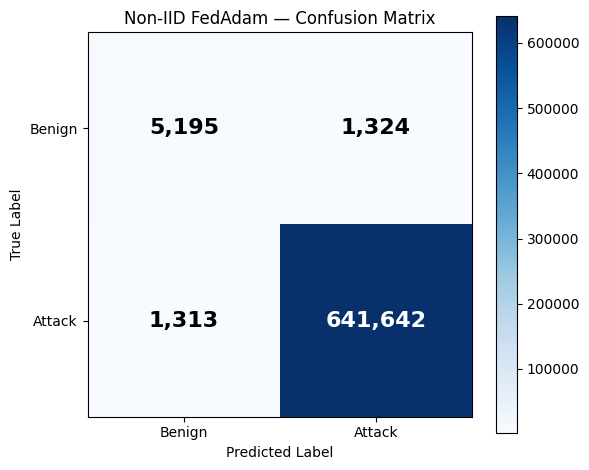

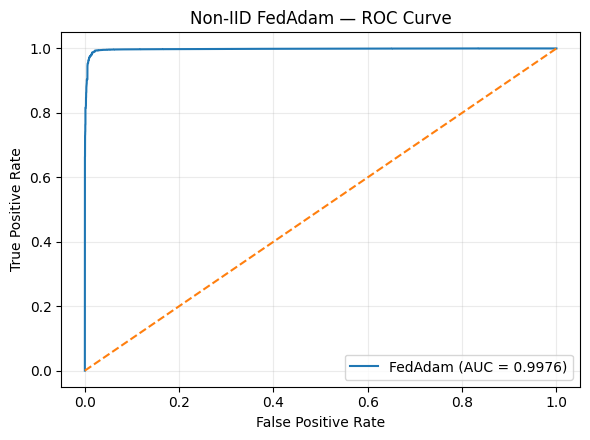

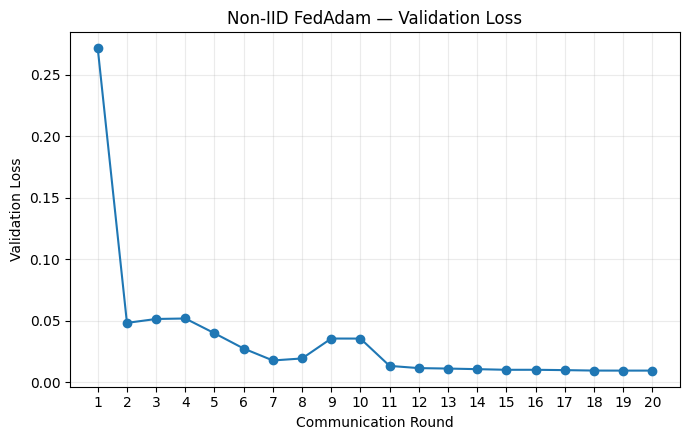


NON-IID FEDADAM EVALUATION COMPLETE
Final evaluated model : Round-20 endpoint
Best validation round : 17
Best Val Macro F1      : 0.902408
Round-20 Val Macro F1  : 0.900167
Inference time         : 459.4 sec

Saved ONLY:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedAdam_ServerLR_0.01/result/final_metrics.csv

✅ Confusion Matrix displayed.
✅ ROC Curve displayed.
✅ Validation Loss curve displayed.
✅ Figures NOT saved to Drive.
✅ Predictions NOT saved.
✅ Classification report NOT saved.
✅ No duplicate model saved.
✅ FedAvg unchanged.
✅ FedSGD unchanged.
✅ FedProx unchanged.
✅ IID results unchanged.


0

In [ ]:
# ================================================================
# CELL 27:
# NON-IID FEDADAM FINAL TEST EVALUATION + FIGURES
# ================================================================
#
# EVALUATES:
#   FedAdam Round-20 endpoint
#
# EXPECTED TRAINING PROTOCOL:
#   Server LR = 0.01
#   beta1     = 0.9
#   beta2     = 0.99
#   tau       = 0.001
#   v0        = tau^2
#
# SAVES ONLY:
#   NonIID/FedAdam_ServerLR_0.01/result/final_metrics.csv
#
# DISPLAYS ONLY:
#   1. Confusion Matrix
#   2. ROC Curve
#   3. Validation Loss Curve
#
# DOES NOT SAVE:
#   - predictions
#   - figures
#   - classification report
#   - duplicate model
#
# DOES NOT TOUCH:
#   - FedAvg
#   - FedSGD
#   - FedProx
#   - IID results
# ================================================================


# ---------------------------------------------------------------
# 1. Imports
# ---------------------------------------------------------------

import os
import gc
import json
import time
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ---------------------------------------------------------------
# 2. Required globals
# ---------------------------------------------------------------

required_globals = [
    "FL_ROOT",
    "X_TEST_FILE",
    "Y_TEST_FILE"
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:

    raise RuntimeError(
        "Run setup/data cell first.\n"
        f"Missing: {missing_globals}"
    )


# ---------------------------------------------------------------
# 3. Runtime
# ---------------------------------------------------------------

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices("GPU")
)

if GPU_AVAILABLE:

    INFERENCE_DEVICE = "GPU"

    mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:

    INFERENCE_DEVICE = "CPU"

    mixed_precision.set_global_policy(
        "float32"
    )


TEST_BATCH_SIZE = 4096
THRESHOLD = 0.5


# ---------------------------------------------------------------
# 4. FedAdam paths
# ---------------------------------------------------------------

FEDADAM_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedAdam_ServerLR_0.01"
)

MODEL_FILE = os.path.join(
    FEDADAM_ROOT,
    "model",
    "FedAdam_Round20_Final.keras"
)

CONFIG_FILE = os.path.join(
    FEDADAM_ROOT,
    "config.json"
)

HISTORY_FILE = os.path.join(
    FEDADAM_ROOT,
    "result",
    "round_history.csv"
)

METRICS_FILE = os.path.join(
    FEDADAM_ROOT,
    "result",
    "final_metrics.csv"
)


# ---------------------------------------------------------------
# 5. Required-file check
# ---------------------------------------------------------------

for path in [
    MODEL_FILE,
    CONFIG_FILE,
    HISTORY_FILE,
    X_TEST_FILE,
    Y_TEST_FILE
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            "Required file missing:\n" + path + "\n\nCell 26 must finish successfully "
            "before running Cell 27."
        )


# ---------------------------------------------------------------
# 6. Verify training config
# ---------------------------------------------------------------

with open(
    CONFIG_FILE,
    "r"
) as file:

    config = json.load(file)


if not bool(
    config.get(
        "completed",
        False
    )
):

    raise RuntimeError(
        "FedAdam training is not marked complete."
    )


if int(
    config.get(
        "final_model_round"
    ) or -1
) != 20:

    raise RuntimeError(
        "FedAdam final model is not Round 20."
    )


if (
    config.get(
        "final_model_policy"
    ) != "Round-20 endpoint"
):

    raise RuntimeError(
        "Unexpected final-model policy."
    )


# ---------------------------------------------------------------
# 7. Verify FedAdam protocol
# ---------------------------------------------------------------

checks = {
    "server_learning_rate": 0.01,
    "server_beta1": 0.9,
    "server_beta2": 0.99,
    "server_tau": 0.001
}


for key, expected in checks.items():

    actual = float(
        config.get(
            key,
            -999
        )
    )

    if not np.isclose(
        actual,
        expected
    ):

        raise RuntimeError(
            f"Unexpected {key}: "
            f"{actual}"
        )


if (
    config.get(
        "server_v_initialization"
    ) != "tau^2"
):

    raise RuntimeError(
        "Unexpected FedAdam v initialization."
    )


# ---------------------------------------------------------------
# 8. Load + verify history
# ---------------------------------------------------------------

history_df = pd.read_csv(
    HISTORY_FILE
)


if (
    len(history_df) != 20 or int(history_df["Round"].min()) != 1 or int(history_df["Round"].max()) != 20 or history_df["Round"].duplicated().any()
):

    raise RuntimeError(
        "FedAdam history must contain "
        "exactly Round 1 → Round 20."
    )


# ---------------------------------------------------------------
# 9. Validation statistics
# ---------------------------------------------------------------

best_row = history_df.loc[
    history_df[
        "Val_Macro_F1"
    ].idxmax()
]


BEST_VAL_ROUND = int(
    best_row["Round"]
)


BEST_VAL_MACRO_F1 = float(
    best_row[
        "Val_Macro_F1"
    ]
)


BEST_VAL_BENIGN_RECALL = float(
    best_row[
        "Val_Benign_Recall"
    ]
)


round20_row = history_df[
    history_df[
        "Round"
    ] == 20
].iloc[0]


ROUND20_VAL_MACRO_F1 = float(
    round20_row[
        "Val_Macro_F1"
    ]
)


ROUND20_VAL_BENIGN_RECALL = float(
    round20_row[
        "Val_Benign_Recall"
    ]
)


# ---------------------------------------------------------------
# 10. Experiment information
# ---------------------------------------------------------------

print("=" * 88)

print(
    "NON-IID FEDADAM — FINAL TEST EVALUATION"
)

print("=" * 88)


print(
    "Final model round : 20"
)


print(
    "Training device   :",
    config.get(
        "completed_device",
        "Unknown"
    )
)


print(
    "Training precision:",
    config.get(
        "completed_precision_policy",
        "Unknown"
    )
)


print(
    "Inference device  :",
    INFERENCE_DEVICE
)


print(
    "Server LR         :",
    config.get(
        "server_learning_rate"
    )
)


print(
    "beta1 / beta2     :",
    config.get(
        "server_beta1"
    ),
    "/",
    config.get(
        "server_beta2"
    )
)


print(
    "tau               :",
    config.get(
        "server_tau"
    )
)


print(
    "Initial v         :",
    config.get(
        "server_v_initialization"
    )
)


print(
    "Best validation round:",
    BEST_VAL_ROUND
)


print(
    f"Best validation Macro F1: "
    f"{BEST_VAL_MACRO_F1:.6f}"
)


print(
    f"Round-20 validation Macro F1: "
    f"{ROUND20_VAL_MACRO_F1:.6f}"
)


print(
    f"Round-20 benign recall: "
    f"{ROUND20_VAL_BENIGN_RECALL:.6f}"
)


if BEST_VAL_ROUND != 20:

    print(
        "\n⚠️ Best validation round differs "
        "from Round 20."
    )

    print(
        "✅ Round-20 endpoint is still evaluated "
        "for the fixed fair-comparison protocol."
    )


# ---------------------------------------------------------------
# 11. Model fingerprint
# ---------------------------------------------------------------

def calculate_sha256(
    path,
    chunk_size=1024 * 1024
):

    hasher = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:
                break

            hasher.update(
                chunk
            )

    return hasher.hexdigest()


MODEL_SHA256 = calculate_sha256(
    MODEL_FILE
)


# ---------------------------------------------------------------
# 12. Load untouched test set
# ---------------------------------------------------------------

X_test = np.load(
    X_TEST_FILE,
    mmap_mode="r"
)


y_true = np.asarray(
    np.load(
        Y_TEST_FILE,
        mmap_mode="r"
    ),
    dtype=np.int8
).reshape(-1)


if len(X_test) != len(y_true):

    raise RuntimeError(
        "Test X/Y size mismatch."
    )


print(
    "\nTest samples:",
    f"{len(y_true):,}"
)


print(
    "Benign:",
    f"{np.sum(y_true == 0):,}"
)


print(
    "Attack:",
    f"{np.sum(y_true == 1):,}"
)


# ---------------------------------------------------------------
# 13. Load final Round-20 model
# ---------------------------------------------------------------

tf.keras.backend.clear_session()


if GPU_AVAILABLE:

    mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:

    mixed_precision.set_global_policy(
        "float32"
    )


model = tf.keras.models.load_model(
    MODEL_FILE,
    compile=False
)


if int(
    model.count_params()
) != 60097:

    raise RuntimeError(
        "Unexpected FedAdam model architecture."
    )


print(
    "\nModel parameters:",
    f"{model.count_params():,}"
)


# ---------------------------------------------------------------
# 14. Test inference
# ---------------------------------------------------------------

probability_parts = []


inference_start = time.time()


for start in range(
    0,
    len(y_true),
    TEST_BATCH_SIZE
):

    end = min(
        start + TEST_BATCH_SIZE,
        len(y_true)
    )


    X_batch = np.asarray(
        X_test[start:end],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    batch_probability = (
        model(
            tf.convert_to_tensor(
                X_batch,
                dtype=tf.float32
            ),
            training=False
        )
        .numpy()
        .reshape(-1)
        .astype(
            np.float32,
            copy=False
        )
    )


    probability_parts.append(
        batch_probability
    )


    del (
        X_batch,
        batch_probability
    )


y_prob = np.concatenate(
    probability_parts
)


del probability_parts


inference_time = float(
    time.time() - inference_start
)


if len(y_prob) != len(y_true):

    raise RuntimeError(
        "Prediction count mismatch."
    )


if not np.all(
    np.isfinite(
        y_prob
    )
):

    raise RuntimeError(
        "NaN/Inf found in FedAdam probabilities."
    )


# ---------------------------------------------------------------
# 15. Predictions
# ---------------------------------------------------------------

y_pred = (
    y_prob >= THRESHOLD
).astype(
    np.int8
)


# ---------------------------------------------------------------
# 16. Confusion matrix
# ---------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)


tn, fp, fn, tp = (
    cm.ravel()
)


# ---------------------------------------------------------------
# 17. Metrics
# ---------------------------------------------------------------

accuracy = float(
    accuracy_score(
        y_true,
        y_pred
    )
)


attack_precision = float(
    precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


attack_recall = float(
    recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


attack_f1 = float(
    f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


macro_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)


weighted_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)


benign_precision = float(
    precision_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


benign_recall = float(
    recall_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


benign_f1 = float(
    f1_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


roc_auc = float(
    roc_auc_score(
        y_true,
        y_prob
    )
)


attack_pr_auc = float(
    average_precision_score(
        y_true,
        y_prob
    )
)


benign_pr_auc = float(
    average_precision_score(
        1 - y_true,
        1.0 - y_prob
    )
)


# ---------------------------------------------------------------
# 18. Classification report — DISPLAY ONLY
# ---------------------------------------------------------------

report = classification_report(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ],
    target_names=[
        "Benign",
        "Attack"
    ],
    output_dict=True,
    zero_division=0
)


report_df = pd.DataFrame(
    report
).transpose()


# ---------------------------------------------------------------
# 19. Final metrics dataframe
# ---------------------------------------------------------------

metrics_df = pd.DataFrame(
    [
        {
            "Algorithm":
                "FedAdam",

            "Variant":
                "ServerLR_0.01_v0_tau2",

            "Architecture":
                "CNN-LSTM-ResNet",

            "Partition":
                "Non-IID",

            "NonIID_Type":
                (
                    "Controlled Strong "
                    "Minority-Class Label Skew"
                ),

            "Benign_Allocation":
                "50/25/15/7/3",

            "Clients":
                5,

            "Communication_Rounds":
                20,

            "Local_Epochs":
                1,

            "Local_Batch_Size":
                2048,

            "Local_Optimizer":
                "Adam",

            "Local_LR":
                0.001,

            "Server_Optimizer":
                "FedAdam",

            "Server_LR":
                0.01,

            "Beta1":
                0.9,

            "Beta2":
                0.99,

            "Tau":
                0.001,

            "V_Initialization":
                "tau^2",

            "Model_Round":
                20,

            "Evaluation_Model_Policy":
                "Round-20 endpoint",

            "Threshold":
                0.5,

            "Accuracy":
                accuracy,

            "Attack_Precision":
                attack_precision,

            "Attack_Recall":
                attack_recall,

            "Attack_F1":
                attack_f1,

            "Macro_F1":
                macro_f1,

            "Weighted_F1":
                weighted_f1,

            "Benign_Precision":
                benign_precision,

            "Benign_Recall":
                benign_recall,

            "Benign_F1":
                benign_f1,

            "Specificity":
                benign_recall,

            "ROC_AUC":
                roc_auc,

            "PR_AUC":
                attack_pr_auc,

            "Benign_PR_AUC":
                benign_pr_auc,

            "TN":
                int(tn),

            "FP":
                int(fp),

            "FN":
                int(fn),

            "TP":
                int(tp),

            "Test_Samples":
                int(
                    len(y_true)
                ),

            "Best_Validation_Round":
                BEST_VAL_ROUND,

            "Best_Validation_Macro_F1":
                BEST_VAL_MACRO_F1,

            "Best_Validation_Benign_Recall":
                BEST_VAL_BENIGN_RECALL,

            "Round20_Validation_Macro_F1":
                ROUND20_VAL_MACRO_F1,

            "Round20_Validation_Benign_Recall":
                ROUND20_VAL_BENIGN_RECALL,

            "Training_Device":
                config.get(
                    "completed_device",
                    "Unknown"
                ),

            "Training_Precision":
                config.get(
                    "completed_precision_policy",
                    "Unknown"
                ),

            "Model_SHA256":
                MODEL_SHA256
        }
    ]
)


# ---------------------------------------------------------------
# 20. Save ONLY final_metrics.csv
# Re-run safe
# ---------------------------------------------------------------

SHOULD_SAVE = True


if os.path.exists(
    METRICS_FILE
):

    try:

        old_metrics = pd.read_csv(
            METRICS_FILE
        )


        if (
            not old_metrics.empty and "Model_SHA256"
            in old_metrics.columns and str(
                old_metrics.iloc[0][
                    "Model_SHA256"
                ]
            ) == MODEL_SHA256 and int(
                old_metrics.iloc[0][
                    "Model_Round"
                ]
            ) == 20
        ):

            SHOULD_SAVE = False


    except Exception:

        SHOULD_SAVE = True


if SHOULD_SAVE:

    temporary_metrics = (
        METRICS_FILE + ".tmp.csv"
    )


    metrics_df.to_csv(
        temporary_metrics,
        index=False
    )


    os.replace(
        temporary_metrics,
        METRICS_FILE
    )


    print(
        "\n✅ FedAdam final metrics saved."
    )


else:

    print(
        "\n✅ Existing FedAdam metrics already "
        "belong to this exact model."
    )

    print(
        "✅ Metrics file not rewritten."
    )


# ---------------------------------------------------------------
# 21. Print final results
# ---------------------------------------------------------------

print(
    "\n" + "=" * 88
)

print(
    "NON-IID FEDADAM FINAL TEST RESULTS"
)

print(
    "=" * 88
)


print(
    f"Accuracy         : {accuracy:.6f}"
)

print(
    f"Attack Precision : {attack_precision:.6f}"
)

print(
    f"Attack Recall    : {attack_recall:.6f}"
)

print(
    f"Attack F1        : {attack_f1:.6f}"
)

print(
    f"Macro F1         : {macro_f1:.6f}"
)

print(
    f"Weighted F1      : {weighted_f1:.6f}"
)

print(
    f"Benign Precision : {benign_precision:.6f}"
)

print(
    f"Benign Recall    : {benign_recall:.6f}"
)

print(
    f"Benign F1        : {benign_f1:.6f}"
)

print(
    f"ROC-AUC          : {roc_auc:.6f}"
)

print(
    f"PR-AUC           : {attack_pr_auc:.6f}"
)

print(
    f"Benign PR-AUC    : {benign_pr_auc:.6f}"
)


print(
    "\nConfusion Matrix:"
)

print(
    f"TN = {tn}"
)

print(
    f"FP = {fp}"
)

print(
    f"FN = {fn}"
)

print(
    f"TP = {tp}"
)


print(
    "\nClassification Report:"
)

display(
    report_df
)


# ================================================================
# 22. FIGURE 1 — CONFUSION MATRIX
# DISPLAY ONLY
# ================================================================

plt.figure(
    figsize=(
        6,
        5
    )
)


plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)


plt.title(
    "Non-IID FedAdam — Confusion Matrix"
)


plt.colorbar()


plt.xticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.yticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)


cm_threshold = (
    cm.max() / 2.0
)


for i in range(2):

    for j in range(2):

        value = int(
            cm[i, j]
        )


        plt.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if
                value > cm_threshold
                else
                "black"
            )
        )


plt.tight_layout()

plt.show()


# ================================================================
# 23. FIGURE 2 — ROC CURVE
# DISPLAY ONLY
# ================================================================

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)


plt.figure(
    figsize=(
        6,
        4.5
    )
)


plt.plot(
    fpr,
    tpr,
    label=(
        f"FedAdam "
        f"(AUC = {roc_auc:.4f})"
    )
)


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "Non-IID FedAdam — ROC Curve"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ================================================================
# 24. FIGURE 3 — VALIDATION LOSS
# DISPLAY ONLY
# ================================================================

plt.figure(
    figsize=(
        7,
        4.5
    )
)


plt.plot(
    history_df[
        "Round"
    ],
    history_df[
        "Val_Loss"
    ],
    marker="o"
)


plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Validation Loss"
)


plt.title(
    "Non-IID FedAdam — Validation Loss"
)


plt.xticks(
    range(
        1,
        21
    )
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ---------------------------------------------------------------
# 25. Final status
# ---------------------------------------------------------------

print(
    "\n" + "=" * 88
)

print(
    "NON-IID FEDADAM EVALUATION COMPLETE"
)

print(
    "=" * 88
)


print(
    "Final evaluated model : Round-20 endpoint"
)


print(
    "Best validation round :",
    BEST_VAL_ROUND
)


print(
    f"Best Val Macro F1      : "
    f"{BEST_VAL_MACRO_F1:.6f}"
)


print(
    f"Round-20 Val Macro F1  : "
    f"{ROUND20_VAL_MACRO_F1:.6f}"
)


print(
    f"Inference time         : "
    f"{inference_time:.1f} sec"
)


print(
    "\nSaved ONLY:"
)

print(
    METRICS_FILE
)


print(
    "\n✅ Confusion Matrix displayed."
)

print(
    "✅ ROC Curve displayed."
)

print(
    "✅ Validation Loss curve displayed."
)

print(
    "✅ Figures NOT saved to Drive."
)

print(
    "✅ Predictions NOT saved."
)

print(
    "✅ Classification report NOT saved."
)

print(
    "✅ No duplicate model saved."
)

print(
    "✅ FedAvg unchanged."
)

print(
    "✅ FedSGD unchanged."
)

print(
    "✅ FedProx unchanged."
)

print(
    "✅ IID results unchanged."
)

print(
    "=" * 88
)


# ---------------------------------------------------------------
# 26. Cleanup
# ---------------------------------------------------------------

del (
    model,
    X_test,
    y_true,
    y_prob,
    y_pred
)


tf.keras.backend.clear_session()

gc.collect()


In [ ]:
# ================================================================
# CELL 28: NON-IID FEDDYN TRAINING
# FINAL + EXACT RESUME + MINIMAL DRIVE STORAGE
# ================================================================
#
# CONTROLLED FEDDYN VARIANT — SAME AS IID EXPERIMENT
#
# Non-IID:
#   Controlled Strong Minority-Class Label Skew
#   Benign allocation = 50% / 25% / 15% / 7% / 3%
#
# FedDyn:
#   Base alpha        = 0.01
#   Local optimizer   = Adam
#   Local LR          = 0.001
#   Local epochs      = 1
#   Local batch size  = 2048
#
# Full participation:
#   Clients           = 5
#   Rounds            = 20
#
# Dynamic state:
#   h_i <- h_i + (w_i - w_cloud)
#
# Mean client model:
#   w_avg <- mean(w_i)
#
# Cloud correction:
#   w_cloud <- w_avg + mean(h_i)
#
# FINAL COMPARISON MODEL:
#   Round-20 MEAN CLIENT MODEL
#
# NOTE:
#   This is the same controlled local-Adam FedDyn adaptation
#   used in the IID experiment, NOT the exact original SGD solver.
#
# PERMANENT DRIVE ARTIFACTS:
#   1. config.json
#   2. round_history.csv
#   3. FedDyn_Round20_Final.keras
#
# TEMPORARY:
#   ONE rolling state checkpoint only:
#       - cloud weights
#       - client histories
#       - current mean-client model
#
# Deleted after successful Round 20.
#
# DOES NOT SAVE:
#   - predictions
#   - figures
#   - per-round models
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import re
import gc
import json
import time
import shutil
import hashlib

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score
)


# ================================================================
# 2. Required notebook objects
# ================================================================

required_globals = [
    "FL_ROOT",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "NUM_FEATURES",
    "RANDOM_SEED",
    "build_federated_binary_model"
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise RuntimeError(
        "Run setup/data/model architecture cells first.\n"
        f"Missing: {missing_globals}"
    )


# ================================================================
# 3. FIXED FEDDYN PROTOCOL
# ================================================================

FD_NUM_CLIENTS = 5
FD_ROUNDS = 20

FD_LOCAL_EPOCHS = 1
FD_BATCH_SIZE = 2048
FD_LOCAL_LR = 0.001

FD_BASE_ALPHA = 0.01


# ================================================================
# 4. Runtime / precision
# ================================================================

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices(
        "GPU"
    )
)


if GPU_AVAILABLE:

    FD_DEVICE = "GPU"

    FD_PRECISION = "mixed_float16"

    FD_LOSS_SCALE = 1024.0

else:

    FD_DEVICE = "CPU"

    FD_PRECISION = "float32"

    FD_LOSS_SCALE = 1.0


mixed_precision.set_global_policy(
    FD_PRECISION
)


print("=" * 88)

print(
    "NON-IID FEDDYN — STRONG LABEL-SKEW — 5 CLIENTS"
)

print("=" * 88)


print(
    "Runtime device :",
    FD_DEVICE
)


print(
    "Precision      :",
    FD_PRECISION
)


print(
    "Base alpha     :",
    FD_BASE_ALPHA
)


print(
    "Local optimizer:",
    "Adam"
)


print(
    "Local LR       :",
    FD_LOCAL_LR
)


print(
    "Local epochs   :",
    FD_LOCAL_EPOCHS
)


print(
    "Batch size     :",
    FD_BATCH_SIZE
)


if FD_DEVICE == "CPU":

    print(
        "⚠️ CPU supported, but GPU is strongly preferred."
    )


# ================================================================
# 5. Paths
# ================================================================

FD_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedDyn"
)


FD_MODEL_DIR = os.path.join(
    FD_ROOT,
    "model"
)


FD_RESULT_DIR = os.path.join(
    FD_ROOT,
    "result"
)


FD_CHECKPOINT_DIR = os.path.join(
    FD_ROOT,
    "checkpoint"
)


for directory in [
    FD_ROOT,
    FD_MODEL_DIR,
    FD_RESULT_DIR,
    FD_CHECKPOINT_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


FD_PARTITION_FILE = os.path.join(
    FL_ROOT,
    "partition",
    "NonIID",
    "Strong_LabelSkew_5Clients_Binary_partition.npz"
)


FD_CONFIG_FILE = os.path.join(
    FD_ROOT,
    "config.json"
)


FD_HISTORY_FILE = os.path.join(
    FD_RESULT_DIR,
    "round_history.csv"
)


FD_FINAL_MODEL_FILE = os.path.join(
    FD_MODEL_DIR,
    "FedDyn_Round20_Final.keras"
)


if not os.path.exists(
    FD_PARTITION_FILE
):

    raise FileNotFoundError(
        "Non-IID partition missing:\n" + FD_PARTITION_FILE
    )


# ================================================================
# 6. Load frozen Non-IID partition
# ================================================================

with np.load(
    FD_PARTITION_FILE,
    allow_pickle=False
) as partition_data:

    fd_assignment = np.asarray(
        partition_data[
            "assignment"
        ],
        dtype=np.int8
    )


fd_validation_indices = (
    np.flatnonzero(
        fd_assignment == -1
    )
    .astype(
        np.int32,
        copy=False
    )
)


fd_client_indices = [

    np.flatnonzero(
        fd_assignment == client_id
    ).astype(
        np.int32,
        copy=False
    )

    for client_id
    in range(
        FD_NUM_CLIENTS
    )
]


fd_client_sizes = np.asarray(
    [
        len(indices)
        for indices
        in fd_client_indices
    ],
    dtype=np.int64
)


if (
    fd_client_sizes.max() - fd_client_sizes.min() > 1
):

    raise RuntimeError(
        "Unexpected client-size distribution."
    )


# ================================================================
# 7. Verify exact class distribution
# ================================================================

y_partition_check = np.load(
    Y_TRAIN_FILE,
    mmap_mode="r"
)


fd_benign_counts = []
fd_attack_counts = []


for indices in fd_client_indices:

    labels = np.asarray(
        y_partition_check[
            indices
        ],
        dtype=np.int8
    )


    counts = np.bincount(
        labels,
        minlength=2
    )


    fd_benign_counts.append(
        int(
            counts[0]
        )
    )


    fd_attack_counts.append(
        int(
            counts[1]
        )
    )


EXPECTED_BENIGN_COUNTS = get_expected_benign_counts(
    y_partition_check,
    fd_validation_indices,
    BENIGN_ALLOCATION
)


if (
    fd_benign_counts != EXPECTED_BENIGN_COUNTS
):

    raise RuntimeError(
        "Non-IID partition does not match "
        "the frozen 50/25/15/7/3 design."
    )


partition_sha256 = hashlib.sha256(
    fd_assignment.tobytes()
).hexdigest()


print(
    "\n✅ Non-IID partition verified."
)


print(
    "Client sizes :",
    fd_client_sizes.tolist()
)


print(
    "Benign counts:",
    fd_benign_counts
)


print(
    "Attack counts:",
    fd_attack_counts
)


print(
    "Validation samples:",
    f"{len(fd_validation_indices):,}"
)


del y_partition_check

gc.collect()


# ================================================================
# 8. FedDyn client weights
#
# Official FedDyn-style normalization:
#
# weight_i = n_i / total_n * number_of_clients
#
# effective_alpha_i = base_alpha / weight_i
# ================================================================

total_client_samples = float(
    fd_client_sizes.sum()
)


fd_normalized_weights = (
    fd_client_sizes.astype(
        np.float64
    ) / total_client_samples * FD_NUM_CLIENTS
)


fd_effective_alphas = (
    FD_BASE_ALPHA / fd_normalized_weights
)


print(
    "\nEffective client alphas:"
)


for client_id in range(
    FD_NUM_CLIENTS
):

    print(
        f"Client {client_id + 1}: "
        f"{fd_effective_alphas[client_id]:.8f}"
    )


# ================================================================
# 9. Atomic helpers
# ================================================================

def fd_save_json_atomic(
    path,
    data
):

    temporary = (
        path + ".tmp"
    )


    with open(
        temporary,
        "w"
    ) as file:

        json.dump(
            data,
            file,
            indent=2
        )


    os.replace(
        temporary,
        path
    )


def fd_save_csv_atomic(
    dataframe,
    path
):

    temporary = (
        path + ".tmp.csv"
    )


    dataframe.to_csv(
        temporary,
        index=False
    )


    os.replace(
        temporary,
        path
    )


# ================================================================
# 10. Experiment config
# ================================================================

CURRENT_CONFIG = {

    "algorithm":
        "FedDyn",

    "variant":
        "Controlled_LocalAdam_FedDyn",

    "architecture":
        "CNN-LSTM-ResNet",

    "partition":
        (
            "Controlled Strong "
            "Minority-Class Label Skew"
        ),

    "benign_allocation":
        "50/25/15/7/3",

    "partition_sha256":
        partition_sha256,

    "num_clients":
        5,

    "communication_rounds":
        20,

    "full_participation":
        True,

    "local_epochs":
        1,

    "local_batch_size":
        2048,

    "local_optimizer":
        "Adam",

    "local_learning_rate":
        0.001,

    "base_alpha":
        0.01,

    "effective_alpha_rule":
        (
            "base_alpha / "
            "(client_samples / total_samples * num_clients)"
        ),

    "client_history_initialization":
        "zeros",

    "client_history_update":
        "history_i += local_i - cloud",

    "cloud_update":
        "mean_client_model + mean_client_history",

    "final_model_policy":
        "Round-20 mean client model",

    "random_seed":
        int(
            RANDOM_SEED
        ),

    "precision_policy":
        FD_PRECISION,

    "static_loss_scale":
        float(
            FD_LOSS_SCALE
        )
}


# ================================================================
# 11. History
# ================================================================

HISTORY_COLUMNS = [
    "Round",
    "Mean_BCE",
    "Mean_Dynamic_Reg",
    "Mean_Total_Objective",
    "Mean_Client_Delta_Norm",
    "Mean_History_Norm",
    "Cloud_Correction_Norm",
    "Val_Loss",
    "Val_Accuracy",
    "Val_Macro_F1",
    "Val_Benign_Recall",
    "Round_Time_sec"
]


if os.path.exists(
    FD_HISTORY_FILE
):

    history_df = pd.read_csv(
        FD_HISTORY_FILE
    )

else:

    history_df = pd.DataFrame(
        columns=HISTORY_COLUMNS
    )


if not history_df.empty:

    history_df[
        "Round"
    ] = history_df[
        "Round"
    ].astype(
        int
    )


    if history_df[
        "Round"
    ].duplicated().any():

        raise RuntimeError(
            "Duplicate FedDyn rounds found."
        )


# ================================================================
# 12. Rolling exact FedDyn state
# ================================================================

state_pattern = re.compile(
    r"^round_(\d{2})_state\.npz$"
)


def fd_list_states():

    output = []


    if not os.path.isdir(
        FD_CHECKPOINT_DIR
    ):

        return output


    for filename in os.listdir(
        FD_CHECKPOINT_DIR
    ):

        match = state_pattern.match(
            filename
        )


        if match:

            output.append(
                (
                    int(
                        match.group(1)
                    ),

                    os.path.join(
                        FD_CHECKPOINT_DIR,
                        filename
                    )
                )
            )


    return sorted(
        output
    )


def fd_remove_old_states(
    keep_round=None
):

    for round_number, path in (
        fd_list_states()
    ):

        if (
            keep_round is None or round_number != keep_round
        ):

            try:

                os.remove(
                    path
                )

            except FileNotFoundError:

                pass


# ================================================================
# 13. State save
# ================================================================

def fd_save_state(
    round_number,
    cloud_weights,
    avg_weights,
    client_histories
):

    final_path = os.path.join(
        FD_CHECKPOINT_DIR,
        f"round_{round_number:02d}_state.npz"
    )


    temporary_path = os.path.join(
        FD_CHECKPOINT_DIR,
        f".round_{round_number:02d}_state.tmp.npz"
    )


    payload = {

        "round":
            np.asarray(
                [
                    round_number
                ],
                dtype=np.int32
            ),

        "num_weights":
            np.asarray(
                [
                    len(
                        cloud_weights
                    )
                ],
                dtype=np.int32
            ),

        "num_clients":
            np.asarray(
                [
                    FD_NUM_CLIENTS
                ],
                dtype=np.int32
            )
    }


    for weight_index, weight in enumerate(
        cloud_weights
    ):

        payload[
            f"cloud_{weight_index}"
        ] = np.asarray(
            weight,
            dtype=np.float32
        )


    for weight_index, weight in enumerate(
        avg_weights
    ):

        payload[
            f"avg_{weight_index}"
        ] = np.asarray(
            weight,
            dtype=np.float32
        )


    for client_id in range(
        FD_NUM_CLIENTS
    ):

        for weight_index in range(
            len(
                cloud_weights
            )
        ):

            payload[
                f"history_{client_id}_{weight_index}"
            ] = np.asarray(
                client_histories[
                    client_id
                ][
                    weight_index
                ],
                dtype=np.float32
            )


    if os.path.exists(
        temporary_path
    ):

        os.remove(
            temporary_path
        )


    np.savez(
        temporary_path,
        **payload
    )


    os.replace(
        temporary_path,
        final_path
    )


    fd_remove_old_states(
        keep_round=round_number
    )


    return final_path


# ================================================================
# 14. State load
# ================================================================

def fd_load_state(
    path
):

    with np.load(
        path,
        allow_pickle=False
    ) as state:

        saved_round = int(
            state[
                "round"
            ][0]
        )


        num_weights = int(
            state[
                "num_weights"
            ][0]
        )


        num_clients = int(
            state[
                "num_clients"
            ][0]
        )


        if num_clients != FD_NUM_CLIENTS:

            raise RuntimeError(
                "FedDyn checkpoint client-count mismatch."
            )


        cloud_weights = [

            np.asarray(
                state[
                    f"cloud_{weight_index}"
                ],
                dtype=np.float32
            ).copy()

            for weight_index
            in range(
                num_weights
            )
        ]


        avg_weights = [

            np.asarray(
                state[
                    f"avg_{weight_index}"
                ],
                dtype=np.float32
            ).copy()

            for weight_index
            in range(
                num_weights
            )
        ]


        client_histories = []


        for client_id in range(
            num_clients
        ):

            history = [

                np.asarray(
                    state[
                        f"history_{client_id}_{weight_index}"
                    ],
                    dtype=np.float32
                ).copy()

                for weight_index
                in range(
                    num_weights
                )
            ]


            client_histories.append(
                history
            )


    return (
        saved_round,
        cloud_weights,
        avg_weights,
        client_histories
    )


# ================================================================
# 15. Config safety
# ================================================================

# ------------------------------------------------
# Detect current saved experiment state FIRST
# ------------------------------------------------

final_model_exists = os.path.exists(
    FD_FINAL_MODEL_FILE
)


saved_states_now = (
    fd_list_states()
)


history_has_progress = (
    not history_df.empty
)


state_has_progress = (
    len(saved_states_now) > 0
)


# Exact partial resume is possible only when
# a rolling FedDyn state exists.
has_resumable_partial_state = (
    state_has_progress
    and
    not final_model_exists
)


# History without a state is NOT an exact resumable
# FedDyn experiment. Existing training logic will
# restart it safely from Round 1.
has_orphan_history_only = (
    history_has_progress
    and
    not state_has_progress
    and
    not final_model_exists
)


# ================================================================
# Existing config
# ================================================================

if os.path.exists(
    FD_CONFIG_FILE
):

    with open(
        FD_CONFIG_FILE,
        "r"
    ) as file:

        saved_config = json.load(
            file
        )


    # ------------------------------------------------------------
    # Core protocol must always match.
    #
    # Precision is intentionally excluded because
    # a COMPLETED model may later be inspected from
    # CPU or GPU without resuming training.
    # ------------------------------------------------------------

    CORE_KEYS = [
        "algorithm",
        "variant",
        "architecture",
        "partition",
        "benign_allocation",
        "partition_sha256",
        "num_clients",
        "communication_rounds",
        "full_participation",
        "local_epochs",
        "local_batch_size",
        "local_optimizer",
        "local_learning_rate",
        "base_alpha",
        "effective_alpha_rule",
        "client_history_initialization",
        "client_history_update",
        "cloud_update",
        "final_model_policy",
        "random_seed"
    ]


    mismatches = {

        key: {
            "saved":
                saved_config.get(
                    key
                ),

            "current":
                CURRENT_CONFIG.get(
                    key
                )
        }

        for key in CORE_KEYS

        if (
            saved_config.get(
                key
            )
            !=
            CURRENT_CONFIG.get(
                key
            )
        )
    }


    if mismatches:

        raise RuntimeError(
            "Non-IID FedDyn protocol mismatch:\n"
            +
            json.dumps(
                mismatches,
                indent=2
            )
        )


    saved_precision = (
        saved_config.get(
            "precision_policy"
        )
    )


    current_precision = (
        FD_PRECISION
    )


    precision_changed = (
        saved_precision is not None
        and
        saved_precision
        !=
        current_precision
    )


    # ============================================================
    # CASE 1:
    # ROUND-20 FINAL MODEL ALREADY EXISTS
    #
    # Precision mismatch is allowed because
    # NO TRAINING will be resumed.
    # ============================================================

    if final_model_exists:

        runtime_config = (
            saved_config
        )


        if precision_changed:

            print(
                "\nℹ️ Existing completed FedDyn experiment "
                "was trained under another precision policy."
            )


            print(
                "Saved training precision :",
                saved_precision
            )


            print(
                "Current runtime precision:",
                current_precision
            )


            print(
                "✅ Allowed because Round-20 final model exists."
            )


            print(
                "✅ Training will NOT be resumed."
            )


    # ============================================================
    # CASE 2:
    # EXACT PARTIAL FEDDYN STATE EXISTS
    #
    # Exact resume needs:
    #   cloud weights
    #   mean-client weights
    #   client histories
    #
    # Precision must therefore remain unchanged.
    # ============================================================

    elif has_resumable_partial_state:

        if saved_precision is None:

            raise RuntimeError(
                "A resumable FedDyn state exists, "
                "but the saved config has no "
                "precision-policy metadata.\n"
                "Safe automatic resume is not possible."
            )


        if precision_changed:

            latest_state_round = (
                saved_states_now[-1][0]
            )


            raise RuntimeError(
                "FedDyn has PARTIAL resumable training "
                "under another precision policy.\n\n"
                f"Latest safe round : {latest_state_round}\n"
                f"Saved precision   : {saved_precision}\n"
                f"Current precision : {current_precision}\n\n"
                "Do NOT mix CPU/GPU precision while "
                "resuming the same FedDyn experiment.\n"
                "Use the original runtime or restart "
                "FedDyn from Round 1."
            )


        runtime_config = (
            saved_config
        )


        print(
            "\n✅ Partial FedDyn state uses "
            "the same precision policy."
        )


        print(
            "Resume precision:",
            current_precision
        )


    # ============================================================
    # CASE 3:
    # NO FINAL MODEL + NO EXACT STATE
    #
    # No exact FedDyn state can be resumed.
    # Current runtime precision can safely be adopted.
    #
    # If history alone exists, Section 19 will clear it
    # and start fresh from Round 1.
    # ============================================================

    else:

        if (
            saved_precision is None
            or
            precision_changed
        ):

            previous_precision = (
                saved_precision
            )


            saved_config.update(
                CURRENT_CONFIG
            )


            saved_config[
                "completed"
            ] = False


            saved_config[
                "final_model_round"
            ] = None


            saved_config.pop(
                "completed_device",
                None
            )


            saved_config.pop(
                "completed_precision_policy",
                None
            )


            fd_save_json_atomic(
                FD_CONFIG_FILE,
                saved_config
            )


            print(
                "\n✅ FedDyn precision policy "
                "updated safely."
            )


            print(
                "Previous precision:",
                previous_precision
            )


            print(
                "Current precision :",
                current_precision
            )


            print(
                "✅ No completed or exact resumable "
                "FedDyn state exists."
            )


        if has_orphan_history_only:

            print(
                "\n⚠️ FedDyn history exists without "
                "an exact rolling state."
            )


            print(
                "It cannot be resumed exactly."
            )


            print(
                "If training is entered, existing logic "
                "will restart safely from Round 1."
            )


        runtime_config = (
            saved_config
        )


# ================================================================
# No existing config
# ================================================================

else:

    # ------------------------------------------------------------
    # Never fabricate metadata for an existing final model.
    # ------------------------------------------------------------

    if final_model_exists:

        raise RuntimeError(
            "FedDyn Round-20 final model exists, "
            "but config.json is missing.\n"
            "No replacement metadata was fabricated."
        )


    runtime_config = dict(
        CURRENT_CONFIG
    )


    runtime_config[
        "completed"
    ] = False


    runtime_config[
        "final_model_round"
    ] = None


    fd_save_json_atomic(
        FD_CONFIG_FILE,
        runtime_config
    )


    print(
        "\n✅ New Non-IID FedDyn config created."
    )


# ================================================================
# 16. Completed-run chec
# ================================================================

if final_model_exists:

    # ------------------------------------------------------------
    # Verify exact Round 1 -> Round 20 history
    # ------------------------------------------------------------

    if history_df.empty:

        raise RuntimeError(
            "FedDyn final model exists but "
            "round history is missing."
        )


    if len(
        history_df
    ) != 20:

        raise RuntimeError(
            "FedDyn final model exists but "
            "history does not contain exactly 20 rounds."
        )


    history_rounds = sorted(
        history_df[
            "Round"
        ]
        .astype(int)
        .tolist()
    )


    if (
        history_rounds
        !=
        list(
            range(
                1,
                21
            )
        )
    ):

        raise RuntimeError(
            "FedDyn final model exists but "
            "history is not exactly Round 1 -> Round 20."
        )


    if history_df[
        "Round"
    ].duplicated().any():

        raise RuntimeError(
            "Duplicate FedDyn rounds detected."
        )


    # ------------------------------------------------------------
    # Verify final architecture
    # ------------------------------------------------------------

    check_model = (
        tf.keras.models.load_model(
            FD_FINAL_MODEL_FILE,
            compile=False
        )
    )


    if int(
        check_model.count_params()
    ) != 60097:

        del check_model


        tf.keras.backend.clear_session()

        gc.collect()


        raise RuntimeError(
            "Unexpected FedDyn final architecture."
        )


    del check_model


    tf.keras.backend.clear_session()

    gc.collect()


    # Restore CURRENT runtime policy after model inspection.
    mixed_precision.set_global_policy(
        FD_PRECISION
    )


    # ------------------------------------------------------------
    # Repair completion flags only.
    #
    # DO NOT replace original training precision/device.
    # ------------------------------------------------------------

    runtime_config[
        "completed"
    ] = True


    runtime_config[
        "final_model_round"
    ] = 20


    # Preserve original training precision.
    # If completed_precision_policy was absent,
    # derive it from the SAVED training precision,
    # never from the current runtime.

    if (
        runtime_config.get(
            "completed_precision_policy"
        )
        is None
    ):

        runtime_config[
            "completed_precision_policy"
        ] = runtime_config.get(
            "precision_policy"
        )


    fd_save_json_atomic(
        FD_CONFIG_FILE,
        runtime_config
    )


    # ------------------------------------------------------------
    # Completed experiment no longer needs
    # rolling FedDyn states.
    # ------------------------------------------------------------

    fd_remove_old_states()


    try:

        if (
            os.path.isdir(
                FD_CHECKPOINT_DIR
            )
            and
            not os.listdir(
                FD_CHECKPOINT_DIR
            )
        ):

            os.rmdir(
                FD_CHECKPOINT_DIR
            )

    except OSError:

        pass


    print(
        "\n"
        +
        "=" * 88
    )


    print(
        "NON-IID FEDDYN — EXISTING COMPLETED EXPERIMENT"
    )


    print(
        "=" * 88
    )


    print(
        "✅ Round-20 final model exists."
    )


    print(
        "✅ Round 1 -> Round 20 history verified."
    )


    print(
        "✅ CNN-LSTM-ResNet architecture verified."
    )


    print(
        "✅ Original training precision preserved:",
        runtime_config.get(
            "precision_policy"
        )
    )


    if (
        runtime_config.get(
            "completed_device"
        )
        is not None
    ):

        print(
            "✅ Original training device preserved:",
            runtime_config.get(
                "completed_device"
            )
        )


    print(
        "✅ Final model policy preserved:",
        runtime_config.get(
            "final_model_policy"
        )
    )


    print(
        "✅ Training skipped."
    )


    print(
        "\nFinal model:"
    )


    print(
        FD_FINAL_MODEL_FILE
    )


    print(
        "=" * 88
    )

# ================================================================
# 17. TRAIN / RESUME
# ================================================================

else:

    # ------------------------------------------------------------
    # Temporary Colab local cache
    # ------------------------------------------------------------

    LOCAL_CACHE_DIR = (
        "/content/fl_binary_training_cache"
    )


    os.makedirs(
        LOCAL_CACHE_DIR,
        exist_ok=True
    )


    LOCAL_X_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "X_train_scaled_float32.npy"
    )


    LOCAL_Y_FILE = os.path.join(
        LOCAL_CACHE_DIR,
        "y_train_int8.npy"
    )


    for source, destination in [
        (
            X_TRAIN_FILE,
            LOCAL_X_FILE
        ),
        (
            Y_TRAIN_FILE,
            LOCAL_Y_FILE
        )
    ]:

        if not os.path.exists(
            destination
        ):

            print(
                "Copying to temporary Colab disk:",
                os.path.basename(
                    source
                )
            )


            shutil.copy2(
                source,
                destination
            )


    X_train_fd = np.load(
        LOCAL_X_FILE,
        mmap_mode="r"
    )


    y_train_fd = np.load(
        LOCAL_Y_FILE,
        mmap_mode="r"
    )


    # ------------------------------------------------------------
    # Validation set
    # ------------------------------------------------------------

    X_val_fd = np.asarray(
        X_train_fd[
            fd_validation_indices
        ],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    y_val_fd = np.asarray(
        y_train_fd[
            fd_validation_indices
        ],
        dtype=np.int8
    )


    print(
        "\nValidation samples:",
        f"{len(y_val_fd):,}"
    )


    print(
        "Validation benign:",
        f"{np.sum(y_val_fd == 0):,}"
    )


    print(
        "Validation attack:",
        f"{np.sum(y_val_fd == 1):,}"
    )


    # ============================================================
    # 18. Global validation helper
    #
    # Evaluate MEAN CLIENT MODEL,
    # not corrected cloud model.
    # ============================================================

    VAL_BATCH_SIZE = 4096


    def fd_evaluate_mean_model(
        avg_weights
    ):

        tf.keras.backend.clear_session()


        mixed_precision.set_global_policy(
            FD_PRECISION
        )


        evaluation_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        evaluation_model.set_weights(
            avg_weights
        )


        probability_parts = []


        for start in range(
            0,
            len(
                y_val_fd
            ),
            VAL_BATCH_SIZE
        ):

            end = min(
                start + VAL_BATCH_SIZE,
                len(
                    y_val_fd
                )
            )


            batch_x = tf.convert_to_tensor(
                X_val_fd[
                    start:end
                ],
                dtype=tf.float32
            )


            probability = (
                evaluation_model(
                    batch_x,
                    training=False
                )
                .numpy()
                .reshape(-1)
                .astype(
                    np.float32,
                    copy=False
                )
            )


            probability_parts.append(
                probability
            )


        y_probability = np.concatenate(
            probability_parts
        )


        y_prediction = (
            y_probability >= 0.5
        ).astype(
            np.int8
        )


        eps = 1e-7


        clipped = np.clip(
            y_probability,
            eps,
            1.0 - eps
        )


        val_loss = float(
            -np.mean(

                y_val_fd * np.log(
                    clipped
                )
 +
                (
                    1 - y_val_fd
                ) * np.log(
                    1.0 - clipped
                )
            )
        )


        val_accuracy = float(
            accuracy_score(
                y_val_fd,
                y_prediction
            )
        )


        val_macro_f1 = float(
            f1_score(
                y_val_fd,
                y_prediction,
                average="macro",
                zero_division=0
            )
        )


        val_benign_recall = float(
            recall_score(
                y_val_fd,
                y_prediction,
                pos_label=0,
                zero_division=0
            )
        )


        del (
            probability_parts,
            y_probability,
            y_prediction,
            clipped
        )


        return (
            evaluation_model,
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        )


    # ============================================================
    # 19. Resume OR fresh initialization
    # ============================================================

    saved_states = (
        fd_list_states()
    )


    if saved_states:

        (
            state_round,
            state_path
        ) = saved_states[
            -1
        ]


        (
            loaded_round,
            cloud_weights,
            avg_weights,
            client_histories
        ) = fd_load_state(
            state_path
        )


        if (
            loaded_round != state_round
        ):

            raise RuntimeError(
                "FedDyn checkpoint round mismatch."
            )


        if (
            not history_df.empty and int(
                history_df[
                    "Round"
                ].max()
            ) > loaded_round
        ):

            history_df = history_df[
                history_df[
                    "Round"
                ] <= loaded_round
            ].copy()


            fd_save_csv_atomic(
                history_df,
                FD_HISTORY_FILE
            )


            print(
                "⚠️ History trimmed to latest "
                "safe FedDyn state."
            )


        if (
            history_df.empty or int(
                history_df[
                    "Round"
                ].max()
            ) < loaded_round
        ):

            raise RuntimeError(
                "FedDyn state is ahead of history."
            )


        START_ROUND = (
            loaded_round + 1
        )


        print(
            "\n🔄 RESUMING NON-IID FEDDYN"
        )


        print(
            "Last completed round:",
            loaded_round
        )


        print(
            "Next round:",
            START_ROUND
        )


    else:

        if not history_df.empty:

            print(
                "\n⚠️ History exists but no safe "
                "FedDyn state checkpoint survives."
            )


            print(
                "Starting fresh from Round 1."
            )


            history_df = pd.DataFrame(
                columns=HISTORY_COLUMNS
            )


            fd_save_csv_atomic(
                history_df,
                FD_HISTORY_FILE
            )


        tf.keras.backend.clear_session()


        mixed_precision.set_global_policy(
            FD_PRECISION
        )


        tf.keras.utils.set_random_seed(
            RANDOM_SEED
        )


        initial_model = (
            build_federated_binary_model(
                compile_model=False
            )
        )


        if int(
            initial_model.count_params()
        ) != 60097:

            raise RuntimeError(
                "Unexpected initial architecture."
            )


        if len(
            initial_model.non_trainable_weights
        ) != 0:

            raise RuntimeError(
                "This FedDyn implementation expects "
                "all model weights to be trainable."
            )


        cloud_weights = [

            np.asarray(
                weight,
                dtype=np.float32
            ).copy()

            for weight
            in initial_model.get_weights()
        ]


        avg_weights = [

            np.asarray(
                weight,
                dtype=np.float32
            ).copy()

            for weight
            in cloud_weights
        ]


        client_histories = [

            [
                np.zeros_like(
                    weight,
                    dtype=np.float32
                )

                for weight
                in cloud_weights
            ]

            for _ in range(
                FD_NUM_CLIENTS
            )
        ]


        del initial_model


        tf.keras.backend.clear_session()

        gc.collect()


        mixed_precision.set_global_policy(
            FD_PRECISION
        )


        START_ROUND = 1


        print(
            "\n" + "=" * 72
        )


        print(
            "🟢 STARTING NEW NON-IID FEDDYN TRAINING"
        )


        print(
            "=" * 72
        )


        print(
            "Base alpha:",
            FD_BASE_ALPHA
        )


        print(
            "Client dynamic states initialized to zero."
        )


        print(
            "Model parameters: 60,097"
        )


    # ============================================================
    # 20. State consistency
    # ============================================================

    number_of_weights = len(
        cloud_weights
    )


    if len(
        avg_weights
    ) != number_of_weights:

        raise RuntimeError(
            "FedDyn avg/cloud weight mismatch."
        )


    if len(
        client_histories
    ) != FD_NUM_CLIENTS:

        raise RuntimeError(
            "FedDyn history client count mismatch."
        )


    for history in client_histories:

        if len(
            history
        ) != number_of_weights:

            raise RuntimeError(
                "FedDyn history tensor-count mismatch."
            )


    # ============================================================
    # 21. Communication rounds
    # ============================================================

    for round_number in range(
        START_ROUND,
        FD_ROUNDS + 1
    ):

        round_start = time.time()


        print(
            "\n" + "=" * 72
        )


        print(
            f"FEDDYN ROUND "
            f"{round_number}/20"
        )


        print(
            "=" * 72
        )


        # Simple mean across all participating clients,
        # consistent with alpha adaptation.
        client_weight_sum = [

            np.zeros_like(
                weight,
                dtype=np.float64
            )

            for weight
            in cloud_weights
        ]


        client_bce_values = []
        client_dynamic_values = []
        client_total_values = []
        client_delta_norms = []


        # ========================================================
        # CLIENT LOOP
        # ========================================================

        for client_id in range(
            FD_NUM_CLIENTS
        ):

            client_start = time.time()


            indices = (
                fd_client_indices[
                    client_id
                ]
            )


            client_sample_count = int(
                len(
                    indices
                )
            )


            effective_alpha = float(
                fd_effective_alphas[
                    client_id
                ]
            )


            print(
                f"\nClient {client_id + 1}/5"
            )


            print(
                "Samples:",
                f"{client_sample_count:,}"
            )


            print(
                "Benign :",
                fd_benign_counts[
                    client_id
                ]
            )


            print(
                "Attack :",
                fd_attack_counts[
                    client_id
                ]
            )


            print(
                f"Effective alpha: "
                f"{effective_alpha:.8f}"
            )


            # ----------------------------------------------------
            # Client data
            # ----------------------------------------------------

            X_client = np.asarray(
                X_train_fd[
                    indices
                ],
                dtype=np.float32
            )[
                ...,
                np.newaxis
            ]


            y_client = np.asarray(
                y_train_fd[
                    indices
                ],
                dtype=np.float32
            )


            shuffle_seed = int(
                RANDOM_SEED + round_number * 100 + client_id
            )


            client_dataset = (
                tf.data.Dataset
                .from_tensor_slices(
                    (
                        X_client,
                        y_client
                    )
                )
                .shuffle(
                    buffer_size=min(
                        50000,
                        client_sample_count
                    ),
                    seed=shuffle_seed,
                    reshuffle_each_iteration=True
                )
                .batch(
                    FD_BATCH_SIZE,
                    drop_remainder=False
                )
                .prefetch(
                    tf.data.AUTOTUNE
                )
            )


            # ----------------------------------------------------
            # Fresh local model
            #
            # IMPORTANT:
            # Warm-start from CURRENT CLOUD MODEL
            # ----------------------------------------------------

            tf.keras.backend.clear_session()


            mixed_precision.set_global_policy(
                FD_PRECISION
            )


            local_model = (
                build_federated_binary_model(
                    compile_model=False
                )
            )


            local_model.set_weights(
                cloud_weights
            )


            if int(
                local_model.count_params()
            ) != 60097:

                raise RuntimeError(
                    "Unexpected local architecture."
                )


            if len(
                local_model.non_trainable_weights
            ) != 0:

                raise RuntimeError(
                    "Unexpected non-trainable weights."
                )


            local_optimizer = (
                tf.keras.optimizers.Adam(
                    learning_rate=
                        FD_LOCAL_LR
                )
            )


            bce_loss_fn = (
                tf.keras.losses.BinaryCrossentropy()
            )


            # ----------------------------------------------------
            # Frozen cloud + client history tensors
            # ----------------------------------------------------

            cloud_reference = [

                tf.constant(
                    weight,
                    dtype=tf.float32
                )

                for weight
                in cloud_weights
            ]


            history_reference = [

                tf.constant(
                    history,
                    dtype=tf.float32
                )

                for history
                in client_histories[
                    client_id
                ]
            ]


            # ----------------------------------------------------
            # FedDyn local objective
            #
            # BCE
            # +
            # alpha * <w, history - cloud>
            # +
            # alpha/2 * ||w||^2
            #
            # This explicit L2 term corresponds to FedDyn's
            # alpha regularization.
            # ----------------------------------------------------

            @tf.function(
                reduce_retracing=True
            )
            def fd_train_step(
                batch_x,
                batch_y
            ):

                batch_y = tf.reshape(
                    tf.cast(
                        batch_y,
                        tf.float32
                    ),
                    (-1, 1)
                )


                with tf.GradientTape() as tape:

                    predictions = local_model(
                        batch_x,
                        training=True
                    )


                    bce = bce_loss_fn(
                        batch_y,
                        predictions
                    )


                    linear_terms = []

                    quadratic_terms = []


                    for (
                        variable,
                        cloud_tensor,
                        history_tensor
                    ) in zip(
                        local_model.trainable_variables,
                        cloud_reference,
                        history_reference
                    ):

                        variable32 = tf.cast(
                            variable,
                            tf.float32
                        )


                        linear_terms.append(

                            tf.reduce_sum(
                                variable32 * (
                                    history_tensor - cloud_tensor
                                )
                            )

                        )


                        quadratic_terms.append(

                            tf.reduce_sum(
                                tf.square(
                                    variable32
                                )
                            )

                        )


                    dynamic_regularizer = (

                        effective_alpha * tf.add_n(
                            linear_terms
                        )
 +
                        0.5 * effective_alpha * tf.add_n(
                            quadratic_terms
                        )

                    )


                    total_objective = (

                        tf.cast(
                            bce,
                            tf.float32
                        )
 +
                        dynamic_regularizer

                    )


                    scaled_objective = (

                        total_objective * FD_LOSS_SCALE

                    )


                scaled_gradients = tape.gradient(
                    scaled_objective,
                    local_model.trainable_variables
                )


                gradients = []


                for gradient, variable in zip(
                    scaled_gradients,
                    local_model.trainable_variables
                ):

                    if gradient is None:

                        gradient = tf.zeros_like(
                            variable,
                            dtype=tf.float32
                        )

                    else:

                        gradient = (

                            tf.cast(
                                gradient,
                                tf.float32
                            )
 / FD_LOSS_SCALE

                        )


                    gradients.append(
                        gradient
                    )


                local_optimizer.apply_gradients(
                    zip(
                        gradients,
                        local_model.trainable_variables
                    )
                )


                return (
                    tf.cast(
                        bce,
                        tf.float32
                    ),

                    tf.cast(
                        dynamic_regularizer,
                        tf.float32
                    ),

                    tf.cast(
                        total_objective,
                        tf.float32
                    )
                )


            # ----------------------------------------------------
            # One local epoch
            # ----------------------------------------------------

            bce_sum = 0.0
            dynamic_sum = 0.0
            total_objective_sum = 0.0

            seen_samples = 0


            for (
                batch_x,
                batch_y
            ) in client_dataset:

                current_batch_size = int(
                    tf.shape(
                        batch_y
                    )[0]
                )


                (
                    batch_bce,
                    batch_dynamic,
                    batch_total
                ) = fd_train_step(
                    batch_x,
                    batch_y
                )


                bce_sum += (
                    float(
                        batch_bce.numpy()
                    ) * current_batch_size
                )


                dynamic_sum += (
                    float(
                        batch_dynamic.numpy()
                    ) * current_batch_size
                )


                total_objective_sum += (
                    float(
                        batch_total.numpy()
                    ) * current_batch_size
                )


                seen_samples += (
                    current_batch_size
                )


            if (
                seen_samples != client_sample_count
            ):

                raise RuntimeError(
                    "FedDyn client sample-count mismatch."
                )


            mean_bce = (
                bce_sum / seen_samples
            )


            mean_dynamic = (
                dynamic_sum / seen_samples
            )


            mean_total_objective = (
                total_objective_sum / seen_samples
            )


            # ----------------------------------------------------
            # Local model parameters
            # ----------------------------------------------------

            local_weights = [

                np.asarray(
                    weight,
                    dtype=np.float32
                )

                for weight
                in local_model.get_weights()
            ]


            # ----------------------------------------------------
            # delta = local - current cloud
            # ----------------------------------------------------

            client_delta = [

                (
                    local_weight - cloud_weight
                ).astype(
                    np.float32
                )

                for (
                    local_weight,
                    cloud_weight
                )
                in zip(
                    local_weights,
                    cloud_weights
                )
            ]


            # ----------------------------------------------------
            # Client dynamic history update
            #
            # h_i <- h_i + (local_i - cloud)
            # ----------------------------------------------------

            client_histories[
                client_id
            ] = [

                (
                    old_history + delta
                ).astype(
                    np.float32
                )

                for (
                    old_history,
                    delta
                )
                in zip(
                    client_histories[
                        client_id
                    ],
                    client_delta
                )
            ]


            # ----------------------------------------------------
            # Mean-client accumulator
            # ----------------------------------------------------

            for weight_index in range(
                number_of_weights
            ):

                client_weight_sum[
                    weight_index
                ] += np.asarray(
                    local_weights[
                        weight_index
                    ],
                    dtype=np.float64
                )


            # ----------------------------------------------------
            # Delta norm
            # ----------------------------------------------------

            delta_norm = float(
                np.sqrt(
                    sum(
                        np.sum(
                            np.square(
                                delta,
                                dtype=np.float64
                            )
                        )

                        for delta
                        in client_delta
                    )
                )
            )


            client_bce_values.append(
                mean_bce
            )


            client_dynamic_values.append(
                mean_dynamic
            )


            client_total_values.append(
                mean_total_objective
            )


            client_delta_norms.append(
                delta_norm
            )


            print(
                f"Mean BCE loss       : "
                f"{mean_bce:.6f}"
            )


            print(
                f"Mean dynamic reg    : "
                f"{mean_dynamic:.6f}"
            )


            print(
                f"Mean total objective: "
                f"{mean_total_objective:.6f}"
            )


            print(
                f"Client delta norm   : "
                f"{delta_norm:.6f}"
            )


            print(
                f"Completed in "
                f"{time.time() - client_start:.1f} sec"
            )


            # ----------------------------------------------------
            # Cleanup
            # ----------------------------------------------------

            del (
                local_model,
                local_optimizer,
                local_weights,
                client_delta,
                client_dataset,
                X_client,
                y_client,
                cloud_reference,
                history_reference,
                fd_train_step
            )


            tf.keras.backend.clear_session()

            gc.collect()


            mixed_precision.set_global_policy(
                FD_PRECISION
            )


        # ========================================================
        # 22. Mean client model
        # ========================================================

        avg_weights = [

            (
                weight_sum / float(
                    FD_NUM_CLIENTS
                )
            ).astype(
                np.float32
            )

            for weight_sum
            in client_weight_sum
        ]


        del client_weight_sum


        # ========================================================
        # 23. Mean client history
        # ========================================================

        mean_history = []


        for weight_index in range(
            number_of_weights
        ):

            history_mean = np.mean(

                np.stack(
                    [
                        client_histories[
                            client_id
                        ][
                            weight_index
                        ]

                        for client_id
                        in range(
                            FD_NUM_CLIENTS
                        )
                    ],
                    axis=0
                ),

                axis=0

            ).astype(
                np.float32
            )


            mean_history.append(
                history_mean
            )


        # ========================================================
        # 24. Corrected FedDyn cloud model
        #
        # cloud = mean client model + mean history
        # ========================================================

        cloud_weights = [

            (
                avg_weight + history_weight
            ).astype(
                np.float32
            )

            for (
                avg_weight,
                history_weight
            )
            in zip(
                avg_weights,
                mean_history
            )
        ]


        # --------------------------------------------------------
        # Safety
        # --------------------------------------------------------

        for weight in cloud_weights:

            if not np.all(
                np.isfinite(
                    weight
                )
            ):

                raise FloatingPointError(
                    "Non-finite FedDyn cloud weight detected."
                )


        # ========================================================
        # 25. Norm statistics
        # ========================================================

        history_norms = []


        for client_id in range(
            FD_NUM_CLIENTS
        ):

            norm = float(
                np.sqrt(
                    sum(
                        np.sum(
                            np.square(
                                history,
                                dtype=np.float64
                            )
                        )

                        for history
                        in client_histories[
                            client_id
                        ]
                    )
                )
            )


            history_norms.append(
                norm
            )


        mean_history_norm = float(
            np.mean(
                history_norms
            )
        )


        cloud_correction_norm = float(
            np.sqrt(
                sum(
                    np.sum(
                        np.square(
                            history,
                            dtype=np.float64
                        )
                    )

                    for history
                    in mean_history
                )
            )
        )


        mean_bce_round = float(
            np.mean(
                client_bce_values
            )
        )


        mean_dynamic_round = float(
            np.mean(
                client_dynamic_values
            )
        )


        mean_total_round = float(
            np.mean(
                client_total_values
            )
        )


        mean_delta_norm_round = float(
            np.mean(
                client_delta_norms
            )
        )


        print(
            "\nRound training mean:"
        )


        print(
            f"  BCE loss              : "
            f"{mean_bce_round:.6f}"
        )


        print(
            f"  Dynamic regularizer   : "
            f"{mean_dynamic_round:.6f}"
        )


        print(
            f"  Total objective       : "
            f"{mean_total_round:.6f}"
        )


        print(
            f"  Mean client delta norm: "
            f"{mean_delta_norm_round:.6f}"
        )


        print(
            f"  Mean history norm     : "
            f"{mean_history_norm:.6f}"
        )


        print(
            f"  Cloud correction norm : "
            f"{cloud_correction_norm:.6f}"
        )


        # ========================================================
        # 26. Validate MEAN CLIENT MODEL
        # ========================================================

        (
            global_model,
            val_loss,
            val_accuracy,
            val_macro_f1,
            val_benign_recall
        ) = fd_evaluate_mean_model(
            avg_weights
        )


        round_time = float(
            time.time() - round_start
        )


        print(
            "\nGlobal validation (mean client model):"
        )


        print(
            f"  Log-Loss     : "
            f"{val_loss:.6f}"
        )


        print(
            f"  Accuracy     : "
            f"{val_accuracy:.6f}"
        )


        print(
            f"  Macro F1     : "
            f"{val_macro_f1:.6f}"
        )


        print(
            f"  Benign Recall: "
            f"{val_benign_recall:.6f}"
        )


        print(
            f"  Round time   : "
            f"{round_time:.1f} sec"
        )


        # ========================================================
        # 27. History
        # ========================================================

        new_row = pd.DataFrame(
            [
                {
                    "Round":
                        int(
                            round_number
                        ),

                    "Mean_BCE":
                        mean_bce_round,

                    "Mean_Dynamic_Reg":
                        mean_dynamic_round,

                    "Mean_Total_Objective":
                        mean_total_round,

                    "Mean_Client_Delta_Norm":
                        mean_delta_norm_round,

                    "Mean_History_Norm":
                        mean_history_norm,

                    "Cloud_Correction_Norm":
                        cloud_correction_norm,

                    "Val_Loss":
                        float(
                            val_loss
                        ),

                    "Val_Accuracy":
                        float(
                            val_accuracy
                        ),

                    "Val_Macro_F1":
                        float(
                            val_macro_f1
                        ),

                    "Val_Benign_Recall":
                        float(
                            val_benign_recall
                        ),

                    "Round_Time_sec":
                        float(
                            round_time
                        )
                }
            ]
        )


        history_df = history_df[
            history_df[
                "Round"
            ] != round_number
        ].copy()


        if history_df.empty:

            history_df = (
                new_row.copy()
            )

        else:

            history_df = pd.concat(
                [
                    history_df,
                    new_row
                ],
                ignore_index=True
            )


        history_df = (
            history_df
            .sort_values(
                "Round"
            )
            .reset_index(
                drop=True
            )
        )


        fd_save_csv_atomic(
            history_df,
            FD_HISTORY_FILE
        )


        # ========================================================
        # 28. Rolling state / final model
        # ========================================================

        if (
            round_number < FD_ROUNDS
        ):

            state_path = fd_save_state(
                round_number,
                cloud_weights,
                avg_weights,
                client_histories
            )


            print(
                "✅ Round "
                f"{round_number} safely committed "
                "(cloud + avg model + client histories)."
            )


            print(
                "   Rolling state:",
                os.path.basename(
                    state_path
                )
            )


        else:

            temporary_final = os.path.join(
                FD_MODEL_DIR,
                ".FedDyn_Round20_Final.temp.keras"
            )


            if os.path.exists(
                temporary_final
            ):

                os.remove(
                    temporary_final
                )


            # IMPORTANT:
            # global_model contains ROUND-20 MEAN CLIENT MODEL,
            # NOT cloud-corrected model.
            global_model.save(
                temporary_final,
                overwrite=True
            )


            os.replace(
                temporary_final,
                FD_FINAL_MODEL_FILE
            )


            runtime_config[
                "completed"
            ] = True


            runtime_config[
                "final_model_round"
            ] = 20


            runtime_config[
                "completed_device"
            ] = FD_DEVICE


            runtime_config[
                "completed_precision_policy"
            ] = FD_PRECISION


            fd_save_json_atomic(
                FD_CONFIG_FILE,
                runtime_config
            )


            fd_remove_old_states()


            try:

                if (
                    os.path.isdir(
                        FD_CHECKPOINT_DIR
                    ) and not os.listdir(
                        FD_CHECKPOINT_DIR
                    )
                ):

                    os.rmdir(
                        FD_CHECKPOINT_DIR
                    )

            except OSError:

                pass


            print(
                "\n✅ ROUND-20 MEAN CLIENT MODEL SAVED:"
            )


            print(
                FD_FINAL_MODEL_FILE
            )


        del (
            global_model,
            mean_history
        )


        tf.keras.backend.clear_session()

        gc.collect()


        mixed_precision.set_global_policy(
            FD_PRECISION
        )


    # ============================================================
    # 29. Final integrity
    # ============================================================

    final_history = pd.read_csv(
        FD_HISTORY_FILE
    )


    if (
        len(
            final_history
        ) != 20
 or
        int(
            final_history[
                "Round"
            ].min()
        ) != 1
 or
        int(
            final_history[
                "Round"
            ].max()
        ) != 20
 or
        final_history[
            "Round"
        ].duplicated().any()
    ):

        raise RuntimeError(
            "FedDyn final history is not "
            "exactly Round 1 → Round 20."
        )


    if not os.path.exists(
        FD_FINAL_MODEL_FILE
    ):

        raise RuntimeError(
            "FedDyn Round-20 final model missing."
        )


    # ============================================================
    # 30. Final status
    # ============================================================

    round20_row = final_history[
        final_history[
            "Round"
        ] == 20
    ].iloc[0]


    print(
        "\n" + "=" * 88
    )


    print(
        "NON-IID FEDDYN TRAINING COMPLETE"
    )


    print(
        "=" * 88
    )


    print(
        "Partition          : "
        "Strong label-skew Non-IID"
    )


    print(
        "Clients            : 5"
    )


    print(
        "Rounds             : 20"
    )


    print(
        "Base alpha         : 0.01"
    )


    print(
        "Local optimizer    : Adam"
    )


    print(
        "Local LR           : 0.001"
    )


    print(
        "Local epochs       : 1"
    )


    print(
        "Batch size         : 2048"
    )


    print(
        "Final model policy : "
        "Round-20 mean client model"
    )


    print(
        "Runtime            :",
        FD_DEVICE
    )


    print(
        "Precision          :",
        FD_PRECISION
    )


    print(
        "\nROUND-20 VALIDATION:"
    )


    print(
        f"Log-Loss     : "
        f"{float(round20_row['Val_Loss']):.6f}"
    )


    print(
        f"Accuracy     : "
        f"{float(round20_row['Val_Accuracy']):.6f}"
    )


    print(
        f"Macro F1     : "
        f"{float(round20_row['Val_Macro_F1']):.6f}"
    )


    print(
        f"Benign Recall: "
        f"{float(round20_row['Val_Benign_Recall']):.6f}"
    )


    print(
        "\nPermanent Drive artifacts:"
    )


    print(
        "1.",
        FD_CONFIG_FILE
    )


    print(
        "2.",
        FD_HISTORY_FILE
    )


    print(
        "3.",
        FD_FINAL_MODEL_FILE
    )


    print(
        "\n✅ Temporary FedDyn state removed."
    )


    print(
        "✅ No predictions saved."
    )


    print(
        "✅ No figures saved."
    )


    print(
        "✅ No per-round final models kept."
    )


    print(
        "✅ FedAvg unchanged."
    )


    print(
        "✅ FedSGD unchanged."
    )


    print(
        "✅ FedProx unchanged."
    )


    print(
        "✅ FedAdam unchanged."
    )


    print(
        "✅ IID results unchanged."
    )


    print(
        "=" * 88
    )


    del (
        X_val_fd,
        y_val_fd
    )


    tf.keras.backend.clear_session()

    gc.collect()


    mixed_precision.set_global_policy(
        FD_PRECISION
    )


NON-IID FEDDYN — STRONG LABEL-SKEW — 5 CLIENTS
Runtime device : CPU
Precision      : float32
Base alpha     : 0.01
Local optimizer: Adam
Local LR       : 0.001
Local epochs   : 1
Batch size     : 2048
⚠️ CPU supported, but GPU is strongly preferred.

✅ Non-IID partition verified.
Client sizes : [467621, 467621, 467620, 467620, 467620]
Benign counts: [11733, 5867, 3520, 1643, 704]
Attack counts: [455888, 461754, 464100, 465977, 466916]
Validation samples: 259,790

Effective client alphas:
Client 1: 0.00999999
Client 2: 0.00999999
Client 3: 0.01000001
Client 4: 0.01000001
Client 5: 0.01000001

ℹ️ Existing completed FedDyn experiment was trained under another precision policy.
Saved training precision : mixed_float16
Current runtime precision: float32
✅ Allowed because Round-20 final model exists.
✅ Training will NOT be resumed.

NON-IID FEDDYN — EXISTING COMPLETED EXPERIMENT
✅ Round-20 final model exists.
✅ Round 1 -> Round 20 history verified.
✅ CNN-LSTM-ResNet architecture verified.
✅ 

NON-IID FEDDYN — FINAL TEST EVALUATION
Final model round : 20
Final model policy: Round-20 mean client model
Training device   : GPU
Training precision: mixed_float16
Inference device  : CPU
Base alpha        : 0.01
Local optimizer   : Adam
Local LR          : 0.001
Best validation round: 20
Best validation Macro F1: 0.909848
Round-20 validation Macro F1: 0.909848
Round-20 benign recall: 0.885309

Test samples: 649,474
Benign: 6,519
Attack: 642,955

Model parameters: 60,097

✅ FedDyn final metrics saved.

NON-IID FEDDYN FINAL TEST RESULTS
Accuracy         : 0.996066
Attack Precision : 0.998917
Attack Recall    : 0.997107
Attack F1        : 0.998011
Macro F1         : 0.909060
Weighted F1      : 0.996226
Benign Precision : 0.757939
Benign Recall    : 0.893389
Benign F1        : 0.820108
ROC-AUC          : 0.995089
PR-AUC           : 0.999939
Benign PR-AUC    : 0.788406

Confusion Matrix:
TN = 5824
FP = 695
FN = 1860
TP = 641095

Classification Report:


,precision,recall,f1-score,support
Benign,0.757939,0.893389,0.820108,6519.000000
Attack,0.998917,0.997107,0.998011,642955.000000
accuracy,0.996066,0.996066,0.996066,0.996066
macro avg,0.878428,0.945248,0.909060,649474.000000
weighted avg,0.996498,0.996066,0.996226,649474.000000


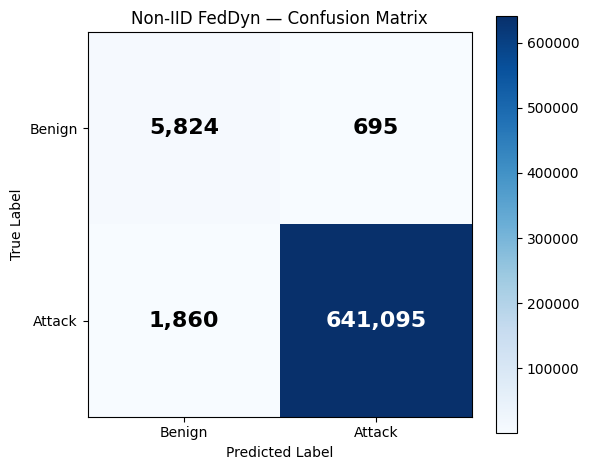

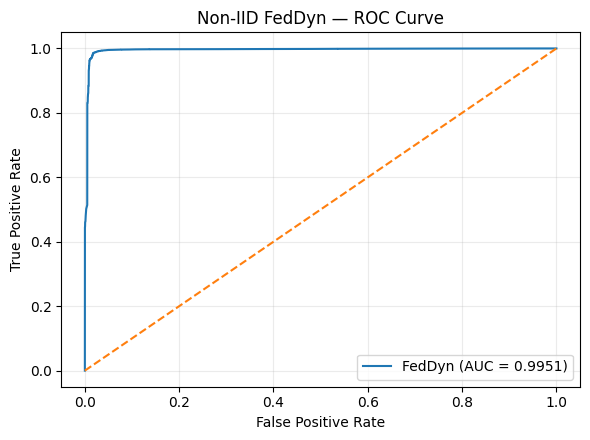

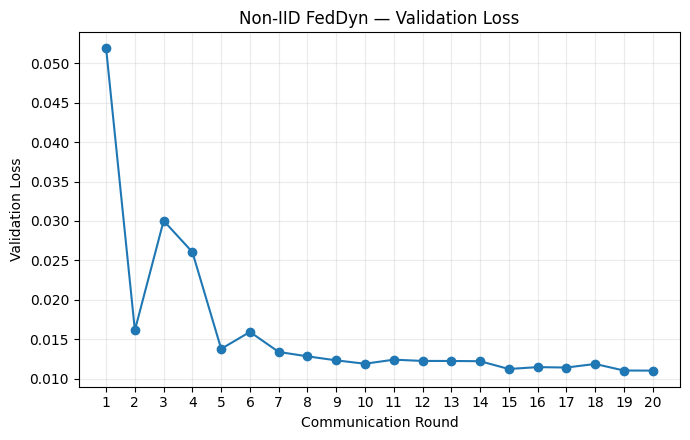


NON-IID FEDDYN EVALUATION COMPLETE
Final evaluated model : Round-20 mean client model
Best validation round : 20
Best Val Macro F1      : 0.909848
Round-20 Val Macro F1  : 0.909848
Inference time         : 431.9 sec

Saved ONLY:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedDyn/result/final_metrics.csv

✅ Confusion Matrix displayed.
✅ ROC Curve displayed.
✅ Validation Loss curve displayed.
✅ Figures NOT saved to Drive.
✅ Predictions NOT saved.
✅ Classification report NOT saved.
✅ No duplicate model saved.
✅ FedAvg unchanged.
✅ FedSGD unchanged.
✅ FedProx unchanged.
✅ FedAdam unchanged.
✅ IID results unchanged.


0

In [ ]:
# ================================================================
# CELL 29:
# NON-IID FEDDYN FINAL TEST EVALUATION + FIGURES
# ================================================================
#
# EVALUATES:
#   FedDyn Round-20 MEAN CLIENT MODEL
#
# EXPECTED TRAINING:
#   Controlled Local-Adam FedDyn variant
#   Base alpha       = 0.01
#   Local optimizer = Adam
#   Local LR         = 0.001
#   Local epochs     = 1
#   Batch size       = 2048
#
# SAVES ONLY:
#   NonIID/FedDyn/result/final_metrics.csv
#
# DISPLAYS ONLY:
#   1. Confusion Matrix
#   2. ROC Curve
#   3. Validation Loss Curve
#
# DOES NOT SAVE:
#   - predictions
#   - figures
#   - classification report
#   - duplicate model
#
# DOES NOT TOUCH:
#   - FedAvg
#   - FedSGD
#   - FedProx
#   - FedAdam
#   - IID results
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import time
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ----------------------------------------------------------------
# 2. Required notebook objects
# ----------------------------------------------------------------

required_globals = [
    "FL_ROOT",
    "X_TEST_FILE",
    "Y_TEST_FILE"
]

missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]

if missing_globals:

    raise RuntimeError(
        "Run setup/data cell first.\n"
        f"Missing: {missing_globals}"
    )


# ----------------------------------------------------------------
# 3. Runtime
# ----------------------------------------------------------------

GPU_AVAILABLE = bool(
    tf.config.list_physical_devices(
        "GPU"
    )
)


if GPU_AVAILABLE:

    INFERENCE_DEVICE = "GPU"

    mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:

    INFERENCE_DEVICE = "CPU"

    mixed_precision.set_global_policy(
        "float32"
    )


TEST_BATCH_SIZE = 4096

THRESHOLD = 0.5


# ----------------------------------------------------------------
# 4. FedDyn paths
# ----------------------------------------------------------------

FEDDYN_ROOT = os.path.join(
    FL_ROOT,
    "NonIID",
    "FedDyn"
)


MODEL_FILE = os.path.join(
    FEDDYN_ROOT,
    "model",
    "FedDyn_Round20_Final.keras"
)


CONFIG_FILE = os.path.join(
    FEDDYN_ROOT,
    "config.json"
)


HISTORY_FILE = os.path.join(
    FEDDYN_ROOT,
    "result",
    "round_history.csv"
)


METRICS_FILE = os.path.join(
    FEDDYN_ROOT,
    "result",
    "final_metrics.csv"
)


# ----------------------------------------------------------------
# 5. Required-file check
# ----------------------------------------------------------------

for path in [
    MODEL_FILE,
    CONFIG_FILE,
    HISTORY_FILE,
    X_TEST_FILE,
    Y_TEST_FILE
]:

    if not os.path.exists(
        path
    ):

        raise FileNotFoundError(
            "Required file missing:\n" + path + "\n\nCell 28 must finish successfully "
            "before running Cell 29."
        )


# ----------------------------------------------------------------
# 6. Verify FedDyn config
# ----------------------------------------------------------------

with open(
    CONFIG_FILE,
    "r"
) as file:

    config = json.load(
        file
    )


if not bool(
    config.get(
        "completed",
        False
    )
):

    raise RuntimeError(
        "FedDyn training is not marked complete."
    )


if int(
    config.get(
        "final_model_round"
    ) or -1
) != 20:

    raise RuntimeError(
        "FedDyn final model is not Round 20."
    )


if (
    config.get(
        "final_model_policy"
    ) != "Round-20 mean client model"
):

    raise RuntimeError(
        "Unexpected FedDyn final-model policy."
    )


if not np.isclose(
    float(
        config.get(
            "base_alpha",
            -1
        )
    ),
    0.01
):

    raise RuntimeError(
        "Unexpected FedDyn base alpha."
    )


if (
    config.get(
        "local_optimizer"
    ) != "Adam"
):

    raise RuntimeError(
        "Unexpected FedDyn local optimizer."
    )


if not np.isclose(
    float(
        config.get(
            "local_learning_rate",
            -1
        )
    ),
    0.001
):

    raise RuntimeError(
        "Unexpected FedDyn local learning rate."
    )


# ----------------------------------------------------------------
# 7. Load + verify round history
# ----------------------------------------------------------------

history_df = pd.read_csv(
    HISTORY_FILE
)


if (
    len(history_df) != 20 or int(
        history_df[
            "Round"
        ].min()
    ) != 1 or int(
        history_df[
            "Round"
        ].max()
    ) != 20 or history_df[
        "Round"
    ].duplicated().any()
):

    raise RuntimeError(
        "FedDyn history must contain "
        "exactly Round 1 → Round 20."
    )


# ----------------------------------------------------------------
# 8. Validation statistics
# ----------------------------------------------------------------

best_row = history_df.loc[
    history_df[
        "Val_Macro_F1"
    ].idxmax()
]


BEST_VAL_ROUND = int(
    best_row[
        "Round"
    ]
)


BEST_VAL_MACRO_F1 = float(
    best_row[
        "Val_Macro_F1"
    ]
)


BEST_VAL_BENIGN_RECALL = float(
    best_row[
        "Val_Benign_Recall"
    ]
)


round20_row = history_df[
    history_df[
        "Round"
    ] == 20
].iloc[0]


ROUND20_VAL_LOSS = float(
    round20_row[
        "Val_Loss"
    ]
)


ROUND20_VAL_ACCURACY = float(
    round20_row[
        "Val_Accuracy"
    ]
)


ROUND20_VAL_MACRO_F1 = float(
    round20_row[
        "Val_Macro_F1"
    ]
)


ROUND20_VAL_BENIGN_RECALL = float(
    round20_row[
        "Val_Benign_Recall"
    ]
)


# ----------------------------------------------------------------
# 9. Print experiment information
# ----------------------------------------------------------------

print("=" * 88)

print(
    "NON-IID FEDDYN — FINAL TEST EVALUATION"
)

print("=" * 88)


print(
    "Final model round : 20"
)


print(
    "Final model policy:",
    config.get(
        "final_model_policy"
    )
)


print(
    "Training device   :",
    config.get(
        "completed_device",
        "Unknown"
    )
)


print(
    "Training precision:",
    config.get(
        "completed_precision_policy",
        "Unknown"
    )
)


print(
    "Inference device  :",
    INFERENCE_DEVICE
)


print(
    "Base alpha        :",
    config.get(
        "base_alpha"
    )
)


print(
    "Local optimizer   :",
    config.get(
        "local_optimizer"
    )
)


print(
    "Local LR          :",
    config.get(
        "local_learning_rate"
    )
)


print(
    "Best validation round:",
    BEST_VAL_ROUND
)


print(
    f"Best validation Macro F1: "
    f"{BEST_VAL_MACRO_F1:.6f}"
)


print(
    f"Round-20 validation Macro F1: "
    f"{ROUND20_VAL_MACRO_F1:.6f}"
)


print(
    f"Round-20 benign recall: "
    f"{ROUND20_VAL_BENIGN_RECALL:.6f}"
)


if BEST_VAL_ROUND != 20:

    print(
        "\n⚠️ Best validation round differs "
        "from Round 20."
    )

    print(
        "✅ Round-20 mean-client endpoint "
        "is still evaluated for fair comparison."
    )


# ----------------------------------------------------------------
# 10. Model SHA256
# ----------------------------------------------------------------

def calculate_sha256(
    path,
    chunk_size=1024 * 1024
):

    hasher = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                chunk_size
            )

            if not chunk:
                break

            hasher.update(
                chunk
            )


    return hasher.hexdigest()


MODEL_SHA256 = calculate_sha256(
    MODEL_FILE
)


# ----------------------------------------------------------------
# 11. Load untouched test set
# ----------------------------------------------------------------

X_test = np.load(
    X_TEST_FILE,
    mmap_mode="r"
)


y_true = np.asarray(
    np.load(
        Y_TEST_FILE,
        mmap_mode="r"
    ),
    dtype=np.int8
).reshape(-1)


if len(
    X_test
) != len(
    y_true
):

    raise RuntimeError(
        "Test X/Y size mismatch."
    )


print(
    "\nTest samples:",
    f"{len(y_true):,}"
)


print(
    "Benign:",
    f"{np.sum(y_true == 0):,}"
)


print(
    "Attack:",
    f"{np.sum(y_true == 1):,}"
)


# ----------------------------------------------------------------
# 12. Load final Round-20 mean-client model
# ----------------------------------------------------------------

tf.keras.backend.clear_session()


if GPU_AVAILABLE:

    mixed_precision.set_global_policy(
        "mixed_float16"
    )

else:

    mixed_precision.set_global_policy(
        "float32"
    )


model = tf.keras.models.load_model(
    MODEL_FILE,
    compile=False
)


if int(
    model.count_params()
) != 60097:

    raise RuntimeError(
        "Unexpected FedDyn model architecture."
    )


print(
    "\nModel parameters:",
    f"{model.count_params():,}"
)


# ----------------------------------------------------------------
# 13. Test inference
# ----------------------------------------------------------------

probability_parts = []


inference_start = time.time()


for start in range(
    0,
    len(y_true),
    TEST_BATCH_SIZE
):

    end = min(
        start + TEST_BATCH_SIZE,
        len(y_true)
    )


    X_batch = np.asarray(
        X_test[
            start:end
        ],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    batch_probability = (
        model(
            tf.convert_to_tensor(
                X_batch,
                dtype=tf.float32
            ),
            training=False
        )
        .numpy()
        .reshape(-1)
        .astype(
            np.float32,
            copy=False
        )
    )


    probability_parts.append(
        batch_probability
    )


    del (
        X_batch,
        batch_probability
    )


y_prob = np.concatenate(
    probability_parts
)


del probability_parts


inference_time = float(
    time.time() - inference_start
)


if len(
    y_prob
) != len(
    y_true
):

    raise RuntimeError(
        "Prediction count mismatch."
    )


if not np.all(
    np.isfinite(
        y_prob
    )
):

    raise RuntimeError(
        "NaN/Inf found in FedDyn probabilities."
    )


# ----------------------------------------------------------------
# 14. Fixed threshold predictions
# ----------------------------------------------------------------

y_pred = (
    y_prob >= THRESHOLD
).astype(
    np.int8
)


# ----------------------------------------------------------------
# 15. Confusion Matrix
# ----------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)


tn, fp, fn, tp = (
    cm.ravel()
)


# ----------------------------------------------------------------
# 16. Metrics
# ----------------------------------------------------------------

accuracy = float(
    accuracy_score(
        y_true,
        y_pred
    )
)


attack_precision = float(
    precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


attack_recall = float(
    recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


attack_f1 = float(
    f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )
)


macro_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)


weighted_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)


benign_precision = float(
    precision_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


benign_recall = float(
    recall_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


benign_f1 = float(
    f1_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0
    )
)


roc_auc = float(
    roc_auc_score(
        y_true,
        y_prob
    )
)


attack_pr_auc = float(
    average_precision_score(
        y_true,
        y_prob
    )
)


benign_pr_auc = float(
    average_precision_score(
        1 - y_true,
        1.0 - y_prob
    )
)


# ----------------------------------------------------------------
# 17. Classification report — DISPLAY ONLY
# ----------------------------------------------------------------

report = classification_report(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ],
    target_names=[
        "Benign",
        "Attack"
    ],
    output_dict=True,
    zero_division=0
)


report_df = pd.DataFrame(
    report
).transpose()


# ----------------------------------------------------------------
# 18. Metrics dataframe
# ----------------------------------------------------------------

metrics_df = pd.DataFrame(
    [
        {
            "Algorithm":
                "FedDyn",

            "Variant":
                "Controlled_LocalAdam_FedDyn",

            "Architecture":
                "CNN-LSTM-ResNet",

            "Partition":
                "Non-IID",

            "NonIID_Type":
                (
                    "Controlled Strong "
                    "Minority-Class Label Skew"
                ),

            "Benign_Allocation":
                "50/25/15/7/3",

            "Clients":
                5,

            "Communication_Rounds":
                20,

            "Full_Participation":
                True,

            "Local_Epochs":
                1,

            "Local_Batch_Size":
                2048,

            "Local_Optimizer":
                "Adam",

            "Local_LR":
                0.001,

            "Base_Alpha":
                0.01,

            "Cloud_Update":
                (
                    "Mean client model + "
                    "mean client history"
                ),

            "Model_Round":
                20,

            "Evaluation_Model_Policy":
                "Round-20 mean client model",

            "Threshold":
                0.5,

            "Accuracy":
                accuracy,

            "Attack_Precision":
                attack_precision,

            "Attack_Recall":
                attack_recall,

            "Attack_F1":
                attack_f1,

            "Macro_F1":
                macro_f1,

            "Weighted_F1":
                weighted_f1,

            "Benign_Precision":
                benign_precision,

            "Benign_Recall":
                benign_recall,

            "Benign_F1":
                benign_f1,

            "Specificity":
                benign_recall,

            "ROC_AUC":
                roc_auc,

            "PR_AUC":
                attack_pr_auc,

            "Benign_PR_AUC":
                benign_pr_auc,

            "TN":
                int(tn),

            "FP":
                int(fp),

            "FN":
                int(fn),

            "TP":
                int(tp),

            "Test_Samples":
                int(
                    len(y_true)
                ),

            "Best_Validation_Round":
                BEST_VAL_ROUND,

            "Best_Validation_Macro_F1":
                BEST_VAL_MACRO_F1,

            "Best_Validation_Benign_Recall":
                BEST_VAL_BENIGN_RECALL,

            "Round20_Validation_Loss":
                ROUND20_VAL_LOSS,

            "Round20_Validation_Accuracy":
                ROUND20_VAL_ACCURACY,

            "Round20_Validation_Macro_F1":
                ROUND20_VAL_MACRO_F1,

            "Round20_Validation_Benign_Recall":
                ROUND20_VAL_BENIGN_RECALL,

            "Training_Device":
                config.get(
                    "completed_device",
                    "Unknown"
                ),

            "Training_Precision":
                config.get(
                    "completed_precision_policy",
                    "Unknown"
                ),

            "Model_SHA256":
                MODEL_SHA256
        }
    ]
)


# ----------------------------------------------------------------
# 19. Save ONLY final_metrics.csv
# Re-run safe
# ----------------------------------------------------------------

SHOULD_SAVE = True


if os.path.exists(
    METRICS_FILE
):

    try:

        existing = pd.read_csv(
            METRICS_FILE
        )


        if (
            not existing.empty and "Model_SHA256"
            in existing.columns and str(
                existing.iloc[
                    0
                ][
                    "Model_SHA256"
                ]
            ) == MODEL_SHA256 and int(
                existing.iloc[
                    0
                ][
                    "Model_Round"
                ]
            ) == 20
        ):

            SHOULD_SAVE = False


    except Exception:

        SHOULD_SAVE = True


if SHOULD_SAVE:

    temporary_metrics = (
        METRICS_FILE + ".tmp.csv"
    )


    metrics_df.to_csv(
        temporary_metrics,
        index=False
    )


    os.replace(
        temporary_metrics,
        METRICS_FILE
    )


    print(
        "\n✅ FedDyn final metrics saved."
    )


else:

    print(
        "\n✅ Existing FedDyn metrics already "
        "belong to this exact model."
    )


    print(
        "✅ Metrics file not rewritten."
    )


# ----------------------------------------------------------------
# 20. Print final test results
# ----------------------------------------------------------------

print(
    "\n" + "=" * 88
)


print(
    "NON-IID FEDDYN FINAL TEST RESULTS"
)


print(
    "=" * 88
)


print(
    f"Accuracy         : "
    f"{accuracy:.6f}"
)


print(
    f"Attack Precision : "
    f"{attack_precision:.6f}"
)


print(
    f"Attack Recall    : "
    f"{attack_recall:.6f}"
)


print(
    f"Attack F1        : "
    f"{attack_f1:.6f}"
)


print(
    f"Macro F1         : "
    f"{macro_f1:.6f}"
)


print(
    f"Weighted F1      : "
    f"{weighted_f1:.6f}"
)


print(
    f"Benign Precision : "
    f"{benign_precision:.6f}"
)


print(
    f"Benign Recall    : "
    f"{benign_recall:.6f}"
)


print(
    f"Benign F1        : "
    f"{benign_f1:.6f}"
)


print(
    f"ROC-AUC          : "
    f"{roc_auc:.6f}"
)


print(
    f"PR-AUC           : "
    f"{attack_pr_auc:.6f}"
)


print(
    f"Benign PR-AUC    : "
    f"{benign_pr_auc:.6f}"
)


print(
    "\nConfusion Matrix:"
)


print(
    f"TN = {tn}"
)


print(
    f"FP = {fp}"
)


print(
    f"FN = {fn}"
)


print(
    f"TP = {tp}"
)


print(
    "\nClassification Report:"
)


display(
    report_df
)


# ================================================================
# 21. FIGURE 1 — CONFUSION MATRIX
# DISPLAY ONLY
# ================================================================

plt.figure(
    figsize=(
        6,
        5
    )
)


plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)


plt.title(
    "Non-IID FedDyn — Confusion Matrix"
)


plt.colorbar()


plt.xticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.yticks(
    [
        0,
        1
    ],
    [
        "Benign",
        "Attack"
    ]
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


cm_threshold = (
    cm.max() / 2.0
)


for i in range(2):

    for j in range(2):

        value = int(
            cm[
                i,
                j
            ]
        )


        plt.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=(
                "white"
                if
                value > cm_threshold
                else
                "black"
            )
        )


plt.tight_layout()

plt.show()


# ================================================================
# 22. FIGURE 2 — ROC CURVE
# DISPLAY ONLY
# ================================================================

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)


plt.figure(
    figsize=(
        6,
        4.5
    )
)


plt.plot(
    fpr,
    tpr,
    label=(
        f"FedDyn "
        f"(AUC = {roc_auc:.4f})"
    )
)


plt.plot(
    [
        0,
        1
    ],
    [
        0,
        1
    ],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "Non-IID FedDyn — ROC Curve"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ================================================================
# 23. FIGURE 3 — VALIDATION LOSS
# DISPLAY ONLY
# ================================================================

plt.figure(
    figsize=(
        7,
        4.5
    )
)


plt.plot(
    history_df[
        "Round"
    ],
    history_df[
        "Val_Loss"
    ],
    marker="o"
)


plt.xlabel(
    "Communication Round"
)


plt.ylabel(
    "Validation Loss"
)


plt.title(
    "Non-IID FedDyn — Validation Loss"
)


plt.xticks(
    range(
        1,
        21
    )
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ----------------------------------------------------------------
# 24. Final status
# ----------------------------------------------------------------

print(
    "\n" + "=" * 88
)


print(
    "NON-IID FEDDYN EVALUATION COMPLETE"
)


print(
    "=" * 88
)


print(
    "Final evaluated model : "
    "Round-20 mean client model"
)


print(
    "Best validation round :",
    BEST_VAL_ROUND
)


print(
    f"Best Val Macro F1      : "
    f"{BEST_VAL_MACRO_F1:.6f}"
)


print(
    f"Round-20 Val Macro F1  : "
    f"{ROUND20_VAL_MACRO_F1:.6f}"
)


print(
    f"Inference time         : "
    f"{inference_time:.1f} sec"
)


print(
    "\nSaved ONLY:"
)


print(
    METRICS_FILE
)


print(
    "\n✅ Confusion Matrix displayed."
)


print(
    "✅ ROC Curve displayed."
)


print(
    "✅ Validation Loss curve displayed."
)


print(
    "✅ Figures NOT saved to Drive."
)


print(
    "✅ Predictions NOT saved."
)


print(
    "✅ Classification report NOT saved."
)


print(
    "✅ No duplicate model saved."
)


print(
    "✅ FedAvg unchanged."
)


print(
    "✅ FedSGD unchanged."
)


print(
    "✅ FedProx unchanged."
)


print(
    "✅ FedAdam unchanged."
)


print(
    "✅ IID results unchanged."
)


print(
    "=" * 88
)


# ----------------------------------------------------------------
# 25. Cleanup
# ----------------------------------------------------------------

del (
    model,
    X_test,
    y_true,
    y_prob,
    y_pred
)


tf.keras.backend.clear_session()

gc.collect()


VERIFYING NON-IID FINAL METRIC FILES
✅ FedAvg: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedAvg/result/final_metrics.csv
✅ FedSGD: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedSGD/result/final_metrics.csv
✅ FedProx: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedProx/result/final_metrics.csv
✅ FedAdam: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedAdam_ServerLR_0.01/result/final_metrics.csv
✅ FedDyn: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedDyn/result/final_metrics.csv

✅ All 5 algorithms verified.
✅ All final models use Round 20.
✅ Communication budget = 20 rounds.
✅ Common test samples: 649,474

✅ Non-IID comparison CSV saved.
✅ No models/predictions/figures saved.

FINAL NON-IID FEDERATED LEARNING COMPARISON
Algorithm  Accuracy  Macro_F1  Benign_Recall  Benign_F1  ROC_AUC  Model_Round  Macro_F1_Rank
   FedAvg  0.996982  0.930465       0.942629   0.862456 0.998866           

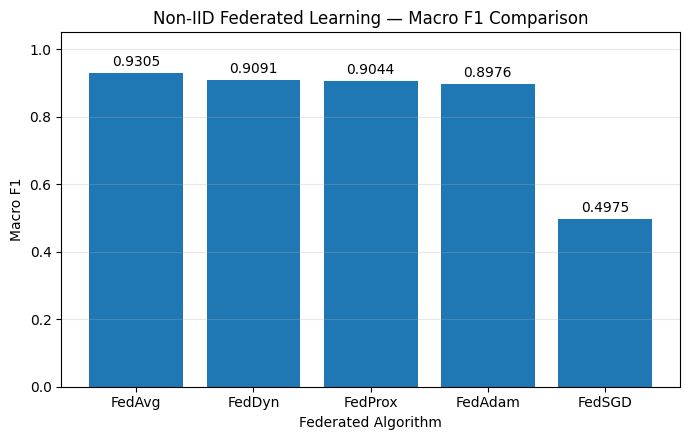

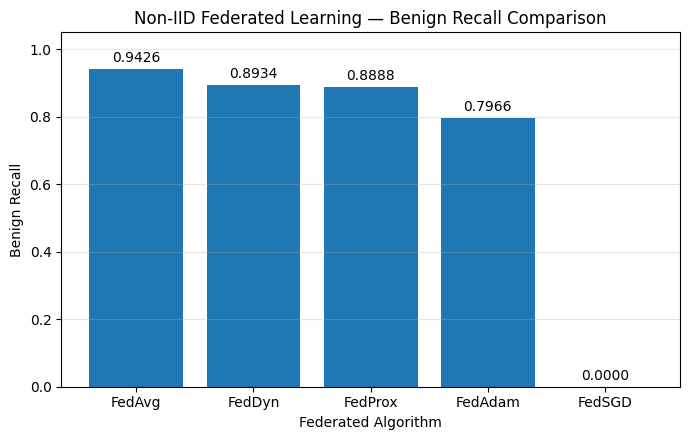


NON-IID AUTOMATIC COMPARISON COMPLETE

Ranking by Macro F1:
1. FedAvg — 0.930465
2. FedDyn — 0.909060
3. FedProx — 0.904378
4. FedAdam — 0.897638
5. FedSGD — 0.497478

Saved ONLY:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID_Final_Comparison/NonIID_5Algorithms_Final_Comparison.csv

✅ Metrics loaded automatically.
✅ No metric manually entered.
✅ Correct FedAdam Server-LR 0.01 result used.
✅ All algorithms verified at Round 20.
✅ Comparison CSV saved.
✅ Figures displayed only.
✅ Figures NOT saved to Drive.
✅ No training performed.
✅ No test inference rerun.


In [ ]:
# ================================================================
# CELL 30:
# FINAL NON-IID 5-ALGORITHM COMPARISON
# ================================================================
#
# ALGORITHMS:
#   1. FedAvg
#   2. FedSGD
#   3. FedProx
#   4. FedAdam
#   5. FedDyn
#
# DATA:
#   Controlled Strong Minority-Class Label-Skew Non-IID
#
# IMPORTANT:
#   - NO training
#   - NO test inference
#   - NO model loading
#   - Metrics loaded ONLY from saved final_metrics.csv files
#
# SAVES ONLY:
#   NonIID_Final_Comparison/
#   NonIID_5Algorithms_Final_Comparison.csv
#
# FIGURES:
#   DISPLAY ONLY
#   NOT saved to Drive
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------------
# 2. Required root
# ----------------------------------------------------------------

if "FL_ROOT" not in globals():

    raise RuntimeError(
        "FL_ROOT is missing. "
        "Run the existing setup cell first."
    )


# ----------------------------------------------------------------
# 3. Exact final metric files
#
# IMPORTANT:
# Exact paths are used intentionally so that no stale/old
# experimental result is accidentally included.
# ----------------------------------------------------------------

FINAL_METRIC_FILES = {

    "FedAvg":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedAvg",
            "result",
            "final_metrics.csv"
        ),

    "FedSGD":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedSGD",
            "result",
            "final_metrics.csv"
        ),

    "FedProx":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedProx",
            "result",
            "final_metrics.csv"
        ),

    "FedAdam":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedAdam_ServerLR_0.01",
            "result",
            "final_metrics.csv"
        ),

    "FedDyn":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedDyn",
            "result",
            "final_metrics.csv"
        )
}


# ----------------------------------------------------------------
# 4. Verify all 5 metric files
# ----------------------------------------------------------------

print(
    "=" * 100
)

print(
    "VERIFYING NON-IID FINAL METRIC FILES"
)

print(
    "=" * 100
)


for algorithm, path in FINAL_METRIC_FILES.items():

    if not os.path.exists(
        path
    ):

        raise FileNotFoundError(
            f"{algorithm} final metrics missing:\n"
            f"{path}"
        )

    print(
        f"✅ {algorithm}:",
        path
    )


# ----------------------------------------------------------------
# 5. Flexible metric reader
# ----------------------------------------------------------------

def get_metric(
    row,
    names,
    required=True,
    default=np.nan
):

    for name in names:

        if (
            name in row.index and pd.notna(
                row[name]
            )
        ):

            return row[name]


    if required:

        raise KeyError(
            "Required metric missing. "
            f"Tried: {names}"
        )


    return default


# ----------------------------------------------------------------
# 6. Load + standardize all 5 algorithms
# ----------------------------------------------------------------

comparison_rows = []


for expected_algorithm, file_path in (
    FINAL_METRIC_FILES.items()
):

    metric_df = pd.read_csv(
        file_path
    )


    if metric_df.empty:

        raise RuntimeError(
            f"{expected_algorithm} "
            "metrics file is empty."
        )


    if len(
        metric_df
    ) != 1:

        raise RuntimeError(
            f"{expected_algorithm} metrics file "
            "must contain exactly one final row."
        )


    row = metric_df.iloc[0]


    # ------------------------------------------------------------
    # Algorithm identity check
    # ------------------------------------------------------------

    saved_algorithm = str(
        get_metric(
            row,
            [
                "Algorithm",
                "algorithm"
            ]
        )
    )


    if (
        saved_algorithm.strip().lower() != expected_algorithm.lower()
    ):

        raise RuntimeError(
            f"Algorithm mismatch for "
            f"{expected_algorithm}.\n"
            f"Saved Algorithm = {saved_algorithm}"
        )


    # ------------------------------------------------------------
    # Model round
    # ------------------------------------------------------------

    model_round = int(
        get_metric(
            row,
            [
                "Model_Round",
                "Final_Round",
                "final_round"
            ]
        )
    )


    if model_round != 20:

        raise RuntimeError(
            f"{expected_algorithm} is not "
            "using the fixed Round-20 model."
        )


    # ------------------------------------------------------------
    # Communication rounds
    # ------------------------------------------------------------

    communication_rounds = int(
        get_metric(
            row,
            [
                "Communication_Rounds",
                "communication_rounds"
            ],
            required=False,
            default=20
        )
    )


    if communication_rounds != 20:

        raise RuntimeError(
            f"{expected_algorithm}: expected "
            "20 communication rounds."
        )


    # ------------------------------------------------------------
    # Partition verification
    # ------------------------------------------------------------

    partition = str(
        get_metric(
            row,
            [
                "Partition",
                "partition"
            ],
            required=False,
            default="Non-IID"
        )
    )


    if (
        "non"
        not in partition.lower()
    ):

        raise RuntimeError(
            f"{expected_algorithm}: "
            f"unexpected partition = {partition}"
        )


    # ------------------------------------------------------------
    # Optional fields
    # ------------------------------------------------------------

    benign_pr_auc = get_metric(
        row,
        [
            "Benign_PR_AUC",
            "benign_pr_auc"
        ],
        required=False
    )


    test_samples = get_metric(
        row,
        [
            "Test_Samples",
            "test_samples"
        ],
        required=False
    )


    evaluation_policy = get_metric(
        row,
        [
            "Evaluation_Model_Policy",
            "Final_Model_Policy",
            "Evaluation_Model"
        ],
        required=False,
        default="Round-20 endpoint"
    )


    # ------------------------------------------------------------
    # Standardized final row
    # ------------------------------------------------------------

    comparison_rows.append(
        {
            "Algorithm":
                expected_algorithm,

            "Accuracy":
                float(
                    get_metric(
                        row,
                        ["Accuracy", "accuracy"]
                    )
                ),

            "Attack_Precision":
                float(
                    get_metric(
                        row,
                        [
                            "Attack_Precision",
                            "Precision",
                            "precision"
                        ]
                    )
                ),

            "Attack_Recall":
                float(
                    get_metric(
                        row,
                        [
                            "Attack_Recall",
                            "Recall",
                            "recall"
                        ]
                    )
                ),

            "Attack_F1":
                float(
                    get_metric(
                        row,
                        [
                            "Attack_F1",
                            "F1",
                            "f1"
                        ]
                    )
                ),

            "Macro_F1":
                float(
                    get_metric(
                        row,
                        [
                            "Macro_F1",
                            "MacroF1",
                            "macro_f1"
                        ]
                    )
                ),

            "Weighted_F1":
                float(
                    get_metric(
                        row,
                        [
                            "Weighted_F1",
                            "WeightedF1",
                            "weighted_f1"
                        ]
                    )
                ),

            "Benign_Precision":
                float(
                    get_metric(
                        row,
                        [
                            "Benign_Precision",
                            "benign_precision"
                        ]
                    )
                ),

            "Benign_Recall":
                float(
                    get_metric(
                        row,
                        [
                            "Benign_Recall",
                            "benign_recall",
                            "Specificity"
                        ]
                    )
                ),

            "Benign_F1":
                float(
                    get_metric(
                        row,
                        [
                            "Benign_F1",
                            "benign_f1"
                        ]
                    )
                ),

            "ROC_AUC":
                float(
                    get_metric(
                        row,
                        [
                            "ROC_AUC",
                            "ROC-AUC",
                            "roc_auc"
                        ]
                    )
                ),

            "PR_AUC":
                float(
                    get_metric(
                        row,
                        [
                            "PR_AUC",
                            "PR-AUC",
                            "pr_auc"
                        ]
                    )
                ),

            "Benign_PR_AUC":
                (
                    float(
                        benign_pr_auc
                    )

                    if pd.notna(
                        benign_pr_auc
                    )

                    else np.nan
                ),

            "TN":
                int(
                    get_metric(
                        row,
                        ["TN", "tn"]
                    )
                ),

            "FP":
                int(
                    get_metric(
                        row,
                        ["FP", "fp"]
                    )
                ),

            "FN":
                int(
                    get_metric(
                        row,
                        ["FN", "fn"]
                    )
                ),

            "TP":
                int(
                    get_metric(
                        row,
                        ["TP", "tp"]
                    )
                ),

            "Communication_Rounds":
                communication_rounds,

            "Model_Round":
                model_round,

            "Evaluation_Model_Policy":
                str(
                    evaluation_policy
                ),

            "Test_Samples":
                (
                    int(
                        test_samples
                    )

                    if pd.notna(
                        test_samples
                    )

                    else np.nan
                ),

            "Source_File":
                file_path
        }
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


# ----------------------------------------------------------------
# 7. Cross-algorithm fairness checks
# ----------------------------------------------------------------

if len(
    comparison_df
) != 5:

    raise RuntimeError(
        "Expected exactly 5 Non-IID algorithms."
    )


if comparison_df[
    "Algorithm"
].duplicated().any():

    raise RuntimeError(
        "Duplicate algorithms detected."
    )


if not (
    comparison_df[
        "Model_Round"
    ] == 20
).all():

    raise RuntimeError(
        "Not all algorithms use Round 20."
    )


if not (
    comparison_df[
        "Communication_Rounds"
    ] == 20
).all():

    raise RuntimeError(
        "Communication-round mismatch detected."
    )


known_test_samples = (
    comparison_df[
        "Test_Samples"
    ]
    .dropna()
    .astype(
        int
    )
    .unique()
)


if len(
    known_test_samples
) > 1:

    raise RuntimeError(
        "Algorithms were evaluated on "
        "different test-set sizes."
    )


print(
    "\n✅ All 5 algorithms verified."
)

print(
    "✅ All final models use Round 20."
)

print(
    "✅ Communication budget = 20 rounds."
)


if len(
    known_test_samples
) == 1:

    print(
        "✅ Common test samples:",
        f"{known_test_samples[0]:,}"
    )


# ----------------------------------------------------------------
# 8. Rankings
# ----------------------------------------------------------------

comparison_df[
    "Macro_F1_Rank"
] = (
    comparison_df[
        "Macro_F1"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(
        int
    )
)


comparison_df[
    "Benign_Recall_Rank"
] = (
    comparison_df[
        "Benign_Recall"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(
        int
    )
)


comparison_df[
    "Benign_F1_Rank"
] = (
    comparison_df[
        "Benign_F1"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(
        int
    )
)


comparison_df[
    "ROC_AUC_Rank"
] = (
    comparison_df[
        "ROC_AUC"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(
        int
    )
)


# ----------------------------------------------------------------
# 9. Primary ranking = Macro F1
# ----------------------------------------------------------------

comparison_df = (
    comparison_df
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ----------------------------------------------------------------
# 10. Save ONLY one comparison CSV
# ----------------------------------------------------------------

NONIID_COMPARISON_DIR = os.path.join(
    FL_ROOT,
    "NonIID_Final_Comparison"
)


os.makedirs(
    NONIID_COMPARISON_DIR,
    exist_ok=True
)


NONIID_COMPARISON_FILE = os.path.join(
    NONIID_COMPARISON_DIR,
    "NonIID_5Algorithms_Final_Comparison.csv"
)


comparison_df.to_csv(
    NONIID_COMPARISON_FILE,
    index=False
)


print(
    "\n✅ Non-IID comparison CSV saved."
)

print(
    "✅ No models/predictions/figures saved."
)


# ----------------------------------------------------------------
# 11. Compact final comparison table
# ----------------------------------------------------------------

display_columns = [

    "Algorithm",
    "Accuracy",
    "Macro_F1",
    "Benign_Recall",
    "Benign_F1",
    "ROC_AUC",
    "Model_Round",
    "Macro_F1_Rank"

]


print(
    "\n" + "=" * 110
)


print(
    "FINAL NON-IID FEDERATED LEARNING COMPARISON"
)


print(
    "=" * 110
)


print(
    comparison_df[
        display_columns
    ].to_string(
        index=False
    )
)


# ----------------------------------------------------------------
# 12. Best algorithm
# ----------------------------------------------------------------

best_algorithm = str(
    comparison_df.iloc[
        0
    ][
        "Algorithm"
    ]
)


best_macro_f1 = float(
    comparison_df.iloc[
        0
    ][
        "Macro_F1"
    ]
)


print(
    "\n✅ Best Non-IID algorithm by Macro F1:"
)


print(
    f"{best_algorithm} "
    f"(Macro F1 = {best_macro_f1:.6f})"
)


# ================================================================
# 13. FIGURE 1 — MACRO F1 COMPARISON
# DISPLAY ONLY
# ================================================================

plot_df = (
    comparison_df
    .sort_values(
        "Macro_F1",
        ascending=False
    )
)


plt.figure(
    figsize=(
        7,
        4.5
    )
)


bars = plt.bar(
    plot_df[
        "Algorithm"
    ],
    plot_df[
        "Macro_F1"
    ]
)


plt.xlabel(
    "Federated Algorithm"
)


plt.ylabel(
    "Macro F1"
)


plt.title(
    "Non-IID Federated Learning — Macro F1 Comparison"
)


plt.ylim(
    0,
    1.05
)


plt.grid(
    axis="y",
    alpha=0.3
)


for bar, value in zip(
    bars,
    plot_df[
        "Macro_F1"
    ]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.012,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()

plt.close()


# ================================================================
# 14. FIGURE 2 — BENIGN RECALL COMPARISON
# DISPLAY ONLY
# ================================================================

plot_df = (
    comparison_df
    .sort_values(
        "Benign_Recall",
        ascending=False
    )
)


plt.figure(
    figsize=(
        7,
        4.5
    )
)


bars = plt.bar(
    plot_df[
        "Algorithm"
    ],
    plot_df[
        "Benign_Recall"
    ]
)


plt.xlabel(
    "Federated Algorithm"
)


plt.ylabel(
    "Benign Recall"
)


plt.title(
    "Non-IID Federated Learning — Benign Recall Comparison"
)


plt.ylim(
    0,
    1.05
)


plt.grid(
    axis="y",
    alpha=0.3
)


for bar, value in zip(
    bars,
    plot_df[
        "Benign_Recall"
    ]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.012,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()

plt.close()


# ----------------------------------------------------------------
# 15. Final ranking
# ----------------------------------------------------------------

print(
    "\n" + "=" * 110
)


print(
    "NON-IID AUTOMATIC COMPARISON COMPLETE"
)


print(
    "=" * 110
)


print(
    "\nRanking by Macro F1:"
)


for index, row in (
    comparison_df.iterrows()
):

    print(
        f"{index + 1}. "
        f"{row['Algorithm']} "
        f"— {row['Macro_F1']:.6f}"
    )


print(
    "\nSaved ONLY:"
)


print(
    NONIID_COMPARISON_FILE
)


print(
    "\n✅ Metrics loaded automatically."
)

print(
    "✅ No metric manually entered."
)

print(
    "✅ Correct FedAdam Server-LR 0.01 result used."
)

print(
    "✅ All algorithms verified at Round 20."
)

print(
    "✅ Comparison CSV saved."
)

print(
    "✅ Figures displayed only."
)

print(
    "✅ Figures NOT saved to Drive."
)

print(
    "✅ No training performed."
)

print(
    "✅ No test inference rerun."
)

print(
    "=" * 110
)


In [ ]:
# ================================================================
# CELL 30B:
# NON-IID STATISTICAL VALIDATION + CLEAN TABLES
# ================================================================
#
# PURPOSE:
#   Statistical validation of the FINAL Round-20 Non-IID models.
#
# METHODS:
#   1. 95% stratified paired bootstrap CI
#      - Accuracy
#      - Macro F1
#      - Benign Recall
#      - Benign F1
#
#   2. Paired bootstrap difference:
#      FedAvg - each comparator
#
#   3. Exact McNemar test:
#      FedAvg vs each comparator
#
#   4. Holm correction for multiple comparisons
#
#   5. Clean table display
#
# IMPORTANT:
#   - NO training
#   - NO model modification
#   - NO prediction saving
#   - NO figure saving
#
# SAVES ONLY:
#   NonIID_Statistical_Analysis/
#       NonIID_Final_Statistical_Analysis.csv
#
# NOTE:
#   Predictions must be regenerated because Non-IID evaluation
#   intentionally did not save prediction arrays.
#
#   These tests quantify uncertainty/disagreement on the fixed
#   held-out test set. They DO NOT quantify training-seed
#   variability because each FL method was trained once.
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.stats import binomtest

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix
)

from IPython.display import display


print("=" * 110)
print("NON-IID FEDERATED LEARNING — STATISTICAL VALIDATION")
print("=" * 110)


# ================================================================
# 2. Required globals
# ================================================================

required_globals = [
    "FL_ROOT",
    "X_TEST_FILE",
    "Y_TEST_FILE"
]


missing_globals = [
    variable
    for variable in required_globals
    if variable not in globals()
]


if missing_globals:

    raise RuntimeError(
        "Required notebook variables are missing:\n"
        f"{missing_globals}"
    )


# ================================================================
# 3. Final Non-IID model paths
# ================================================================

NONIID_MODEL_PATHS = {

    "FedAvg":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedAvg",
            "model",
            "FedAvg_Round20_Final.keras"
        ),

    "FedSGD":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedSGD",
            "model",
            "FedSGD_Round20_Final.keras"
        ),

    "FedProx":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedProx",
            "model",
            "FedProx_Round20_Final.keras"
        ),

    "FedAdam":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedAdam_ServerLR_0.01",
            "model",
            "FedAdam_Round20_Final.keras"
        ),

    "FedDyn":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedDyn",
            "model",
            "FedDyn_Round20_Final.keras"
        )
}


ALGORITHMS = [
    "FedAvg",
    "FedAdam",
    "FedDyn",
    "FedProx",
    "FedSGD"
]


print("\nChecking final Non-IID models:")


for algorithm in ALGORITHMS:

    model_file = NONIID_MODEL_PATHS[
        algorithm
    ]


    if not os.path.exists(
        model_file
    ):

        raise FileNotFoundError(
            f"{algorithm} final model missing:\n"
            f"{model_file}"
        )


    print(
        f"✅ {algorithm}: {model_file}"
    )


print(
    "\n✅ All five final Non-IID Round-20 models found."
)


# ================================================================
# 4. Existing final Non-IID comparison
# ================================================================

NONIID_COMPARISON_FILE = os.path.join(
    FL_ROOT,
    "NonIID_Final_Comparison",
    "NonIID_5Algorithms_Final_Comparison.csv"
)


if not os.path.exists(
    NONIID_COMPARISON_FILE
):

    raise FileNotFoundError(
        "Run Cell 30 first.\n"
        "Non-IID final comparison missing:\n" + NONIID_COMPARISON_FILE
    )


noniid_comparison_df = pd.read_csv(
    NONIID_COMPARISON_FILE
)


EXPECTED_ALGORITHMS = {
    "FedAvg",
    "FedSGD",
    "FedProx",
    "FedAdam",
    "FedDyn"
}


if (
    set(
        noniid_comparison_df[
            "Algorithm"
        ].astype(str)
    ) != EXPECTED_ALGORITHMS
):

    raise RuntimeError(
        "Unexpected algorithms in "
        "Non-IID final comparison CSV."
    )


print(
    "\n✅ Existing Non-IID final comparison verified."
)


# ================================================================
# 5. Load untouched final test set
# ================================================================

X_test_stat = np.load(
    X_TEST_FILE,
    mmap_mode="r"
)


y_true = np.asarray(
    np.load(
        Y_TEST_FILE,
        mmap_mode="r"
    ),
    dtype=np.uint8
).reshape(-1)


if len(
    X_test_stat
) != len(
    y_true
):

    raise RuntimeError(
        "Test X/Y length mismatch."
    )


if X_test_stat.shape[1] != 79:

    raise RuntimeError(
        "Unexpected feature dimension."
    )


N_TEST = len(
    y_true
)


N_BENIGN = int(
    np.sum(
        y_true == 0
    )
)


N_ATTACK = int(
    np.sum(
        y_true == 1
    )
)


if (
    N_TEST != 649474 or N_BENIGN != 6519 or N_ATTACK != 642955
):

    raise RuntimeError(
        "Current test set does not match "
        "the frozen federated test set."
    )


print(
    "\nTest samples:",
    f"{N_TEST:,}"
)


print(
    "Benign:",
    f"{N_BENIGN:,}"
)


print(
    "Attack:",
    f"{N_ATTACK:,}"
)


print(
    "✅ Frozen global test set verified."
)


# ================================================================
# 6. Regenerate final model predictions
#
# RAM ONLY.
# Nothing saved.
# ================================================================

TEST_BATCH_SIZE = 4096


predictions = {}


print(
    "\n" + "=" * 110
)


print(
    "NON-IID FINAL MODEL INFERENCE"
)


print(
    "=" * 110
)


for algorithm in ALGORITHMS:

    tf.keras.backend.clear_session()


    print(
        f"\nRunning {algorithm}..."
    )


    model = tf.keras.models.load_model(
        NONIID_MODEL_PATHS[
            algorithm
        ],
        compile=False
    )


    if int(
        model.count_params()
    ) != 60097:

        raise RuntimeError(
            f"{algorithm}: unexpected architecture."
        )


    prediction_parts = []


    inference_start = time.time()


    for start in range(
        0,
        N_TEST,
        TEST_BATCH_SIZE
    ):

        end = min(
            start + TEST_BATCH_SIZE,
            N_TEST
        )


        batch_x = np.asarray(
            X_test_stat[
                start:end
            ],
            dtype=np.float32
        )[
            ...,
            np.newaxis
        ]


        probabilities = (
            model(
                tf.convert_to_tensor(
                    batch_x,
                    dtype=tf.float32
                ),
                training=False
            )
            .numpy()
            .reshape(-1)
        )


        prediction_parts.append(
            (
                probabilities >= 0.5
            ).astype(
                np.uint8
            )
        )


        del (
            batch_x,
            probabilities
        )


    predictions[
        algorithm
    ] = np.concatenate(
        prediction_parts
    )


    del prediction_parts


    elapsed = (
        time.time() - inference_start
    )


    print(
        f"✅ {algorithm} complete "
        f"({elapsed:.1f} sec)"
    )


    del model


    tf.keras.backend.clear_session()

    _ = gc.collect()


print(
    "\n✅ Predictions generated in RAM only."
)


print(
    "✅ No prediction file saved."
)


# ================================================================
# 7. Metric helper
# ================================================================

def calculate_metrics(
    y_true_array,
    y_pred_array
):

    cm = confusion_matrix(
        y_true_array,
        y_pred_array,
        labels=[
            0,
            1
        ]
    )


    tn, fp, fn, tp = (
        cm.ravel()
    )


    return {

        "Accuracy":
            float(
                accuracy_score(
                    y_true_array,
                    y_pred_array
                )
            ),

        "Macro_F1":
            float(
                f1_score(
                    y_true_array,
                    y_pred_array,
                    average="macro",
                    zero_division=0
                )
            ),

        "Benign_Recall":
            float(
                recall_score(
                    y_true_array,
                    y_pred_array,
                    pos_label=0,
                    zero_division=0
                )
            ),

        "Benign_F1":
            float(
                f1_score(
                    y_true_array,
                    y_pred_array,
                    pos_label=0,
                    zero_division=0
                )
            ),

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp)
    }


# ================================================================
# 8. Recompute point estimates
# ================================================================

point_metrics = {}


print(
    "\n" + "=" * 110
)


print(
    "NON-IID POINT-ESTIMATE VERIFICATION"
)


print(
    "=" * 110
)


for algorithm in ALGORITHMS:

    metrics = calculate_metrics(
        y_true,
        predictions[
            algorithm
        ]
    )


    point_metrics[
        algorithm
    ] = metrics


    print(
        f"{algorithm:<8} | "
        f"Accuracy={metrics['Accuracy']:.6f} | "
        f"Macro-F1={metrics['Macro_F1']:.6f} | "
        f"Benign Recall={metrics['Benign_Recall']:.6f} | "
        f"Benign F1={metrics['Benign_F1']:.6f} | "
        f"TN={metrics['TN']:,} | "
        f"FP={metrics['FP']:,} | "
        f"FN={metrics['FN']:,} | "
        f"TP={metrics['TP']:,}"
    )


# ================================================================
# 9. Compare regenerated predictions against saved final results
#
# Small floating-point/runtime threshold differences can occur
# during regenerated inference.
#
# We therefore:
#   - require close agreement
#   - WARN for tiny differences
#   - STOP only if the discrepancy is meaningfully large
# ================================================================

print(
    "\nChecking regenerated predictions against "
    "saved Non-IID final results..."
)


VERIFY_TOLERANCE = 5e-4


drift_detected = False


for algorithm in ALGORITHMS:

    saved_row = noniid_comparison_df[
        noniid_comparison_df[
            "Algorithm"
        ].astype(str) == algorithm
    ].iloc[0]


    for metric_name in [
        "Accuracy",
        "Macro_F1",
        "Benign_Recall",
        "Benign_F1"
    ]:

        regenerated = float(
            point_metrics[
                algorithm
            ][
                metric_name
            ]
        )


        saved = float(
            saved_row[
                metric_name
            ]
        )


        difference = abs(
            regenerated - saved
        )


        if difference > VERIFY_TOLERANCE:

            raise RuntimeError(
                f"{algorithm} {metric_name} differs too much.\n"
                f"Regenerated = {regenerated:.12f}\n"
                f"Saved       = {saved:.12f}\n"
                f"Difference  = {difference:.12f}\n\n"
                "STOP. No file was overwritten."
            )


        elif difference > 1e-6:

            drift_detected = True


            print(
                f"⚠️ Tiny runtime inference drift: "
                f"{algorithm} {metric_name} "
                f"(Δ={difference:.8f})"
            )


if drift_detected:

    print(
        "\n⚠️ Small regenerated-inference differences "
        "were detected."
    )


    print(
        "These are within the predefined verification tolerance."
    )


    print(
        "The original Cell 30 metrics remain the official "
        "point estimates for the main result table."
    )

else:

    print(
        "\n✅ Regenerated predictions reproduce "
        "the saved Non-IID final metrics."
    )


# ================================================================
# 10. Joint paired-prediction patterns
#
# 5 binary models -> at most 32 prediction patterns.
# ================================================================

prediction_matrix = np.column_stack(
    [
        predictions[
            algorithm
        ]

        for algorithm
        in ALGORITHMS
    ]
).astype(
    np.uint8,
    copy=False
)


pattern_codes = np.zeros(
    N_TEST,
    dtype=np.uint8
)


for model_index in range(
    len(ALGORITHMS)
):

    pattern_codes |= (

        prediction_matrix[
            :,
            model_index
        ]

        <<

        model_index

    )


NUM_PATTERNS = (
    2
    **
    len(ALGORITHMS)
)


benign_pattern_counts = np.bincount(
    pattern_codes[
        y_true == 0
    ],
    minlength=NUM_PATTERNS
).astype(
    np.int64
)


attack_pattern_counts = np.bincount(
    pattern_codes[
        y_true == 1
    ],
    minlength=NUM_PATTERNS
).astype(
    np.int64
)


benign_pattern_probabilities = (
    benign_pattern_counts / N_BENIGN
)


attack_pattern_probabilities = (
    attack_pattern_counts / N_ATTACK
)


pattern_predictions = np.zeros(
    (
        NUM_PATTERNS,
        len(ALGORITHMS)
    ),
    dtype=np.uint8
)


for pattern in range(
    NUM_PATTERNS
):

    for model_index in range(
        len(ALGORITHMS)
    ):

        pattern_predictions[
            pattern,
            model_index
        ] = (

            pattern
            >>
            model_index

        ) & 1


# ================================================================
# 11. Metric helper from confusion counts
# ================================================================

def metrics_from_confusion_counts(
    tn,
    fp,
    fn,
    tp
):

    total = (
        tn + fp + fn + tp
    )


    accuracy = (

        (
            tn + tp
        ) / total

        if total > 0

        else 0.0
    )


    benign_recall = (

        tn / (
            tn + fp
        )

        if (
            tn + fp
        ) > 0

        else 0.0
    )


    benign_precision = (

        tn / (
            tn + fn
        )

        if (
            tn + fn
        ) > 0

        else 0.0
    )


    benign_f1 = (

        (
            2.0 * benign_precision * benign_recall
        )
 / (
            benign_precision + benign_recall
        )

        if (
            benign_precision + benign_recall
        ) > 0

        else 0.0
    )


    attack_recall = (

        tp / (
            tp + fn
        )

        if (
            tp + fn
        ) > 0

        else 0.0
    )


    attack_precision = (

        tp / (
            tp + fp
        )

        if (
            tp + fp
        ) > 0

        else 0.0
    )


    attack_f1 = (

        (
            2.0 * attack_precision * attack_recall
        )
 / (
            attack_precision + attack_recall
        )

        if (
            attack_precision + attack_recall
        ) > 0

        else 0.0
    )


    macro_f1 = (

        benign_f1 + attack_f1

    ) / 2.0


    return (
        accuracy,
        macro_f1,
        benign_recall,
        benign_f1
    )


# ================================================================
# 12. STRATIFIED PAIRED BOOTSTRAP
# ================================================================

BOOTSTRAP_REPEATS = 5000

BOOTSTRAP_SEED = 2026


bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


NUM_ALGORITHMS = len(
    ALGORITHMS
)


bootstrap_accuracy = np.zeros(
    (
        BOOTSTRAP_REPEATS,
        NUM_ALGORITHMS
    ),
    dtype=np.float64
)


bootstrap_macro_f1 = np.zeros_like(
    bootstrap_accuracy
)


bootstrap_benign_recall = np.zeros_like(
    bootstrap_accuracy
)


bootstrap_benign_f1 = np.zeros_like(
    bootstrap_accuracy
)


print(
    "\n" + "=" * 110
)


print(
    f"NON-IID STRATIFIED PAIRED BOOTSTRAP — "
    f"{BOOTSTRAP_REPEATS:,} REPLICATES"
)


print(
    "=" * 110
)


bootstrap_start = time.time()


for bootstrap_index in range(
    BOOTSTRAP_REPEATS
):

    sampled_benign_counts = (
        bootstrap_rng.multinomial(
            N_BENIGN,
            benign_pattern_probabilities
        )
    )


    sampled_attack_counts = (
        bootstrap_rng.multinomial(
            N_ATTACK,
            attack_pattern_probabilities
        )
    )


    for model_index in range(
        NUM_ALGORITHMS
    ):

        model_pattern_prediction = (
            pattern_predictions[
                :,
                model_index
            ]
        )


        tn = int(
            np.sum(
                sampled_benign_counts[
                    model_pattern_prediction == 0
                ]
            )
        )


        fp = int(
            np.sum(
                sampled_benign_counts[
                    model_pattern_prediction == 1
                ]
            )
        )


        fn = int(
            np.sum(
                sampled_attack_counts[
                    model_pattern_prediction == 0
                ]
            )
        )


        tp = int(
            np.sum(
                sampled_attack_counts[
                    model_pattern_prediction == 1
                ]
            )
        )


        (
            sample_accuracy,
            sample_macro_f1,
            sample_benign_recall,
            sample_benign_f1
        ) = metrics_from_confusion_counts(
            tn,
            fp,
            fn,
            tp
        )


        bootstrap_accuracy[
            bootstrap_index,
            model_index
        ] = sample_accuracy


        bootstrap_macro_f1[
            bootstrap_index,
            model_index
        ] = sample_macro_f1


        bootstrap_benign_recall[
            bootstrap_index,
            model_index
        ] = sample_benign_recall


        bootstrap_benign_f1[
            bootstrap_index,
            model_index
        ] = sample_benign_f1


print(
    f"✅ Bootstrap completed "
    f"({time.time() - bootstrap_start:.1f} sec)"
)


# ================================================================
# 13. CI helper
# ================================================================

def percentile_ci(
    values
):

    lower, upper = np.percentile(
        values,
        [
            2.5,
            97.5
        ]
    )


    return (
        float(lower),
        float(upper)
    )


# ================================================================
# 14. 95% model-level bootstrap CIs
# ================================================================

model_ci_rows = []


print(
    "\n" + "=" * 110
)


print(
    "NON-IID — 95% STRATIFIED BOOTSTRAP CONFIDENCE INTERVALS"
)


print(
    "=" * 110
)


for model_index, algorithm in enumerate(
    ALGORITHMS
):

    accuracy_low, accuracy_high = percentile_ci(
        bootstrap_accuracy[
            :,
            model_index
        ]
    )


    macro_low, macro_high = percentile_ci(
        bootstrap_macro_f1[
            :,
            model_index
        ]
    )


    recall_low, recall_high = percentile_ci(
        bootstrap_benign_recall[
            :,
            model_index
        ]
    )


    benign_f1_low, benign_f1_high = percentile_ci(
        bootstrap_benign_f1[
            :,
            model_index
        ]
    )


    metrics = point_metrics[
        algorithm
    ]


    model_ci_rows.append(
        {
            "Record_Type":
                "Model_95CI",

            "Algorithm":
                algorithm,

            "Comparator":
                "",

            "Metric":
                "Model_Metrics",

            "Point_Accuracy":
                metrics[
                    "Accuracy"
                ],

            "Accuracy_CI_Lower":
                accuracy_low,

            "Accuracy_CI_Upper":
                accuracy_high,

            "Point_Macro_F1":
                metrics[
                    "Macro_F1"
                ],

            "Macro_F1_CI_Lower":
                macro_low,

            "Macro_F1_CI_Upper":
                macro_high,

            "Point_Benign_Recall":
                metrics[
                    "Benign_Recall"
                ],

            "Benign_Recall_CI_Lower":
                recall_low,

            "Benign_Recall_CI_Upper":
                recall_high,

            "Point_Benign_F1":
                metrics[
                    "Benign_F1"
                ],

            "Benign_F1_CI_Lower":
                benign_f1_low,

            "Benign_F1_CI_Upper":
                benign_f1_high
        }
    )


    print(
        f"\n{algorithm}"
    )


    print(
        f"  Accuracy      : "
        f"{metrics['Accuracy']:.6f} "
        f"[{accuracy_low:.6f}, "
        f"{accuracy_high:.6f}]"
    )


    print(
        f"  Macro F1      : "
        f"{metrics['Macro_F1']:.6f} "
        f"[{macro_low:.6f}, "
        f"{macro_high:.6f}]"
    )


    print(
        f"  Benign Recall : "
        f"{metrics['Benign_Recall']:.6f} "
        f"[{recall_low:.6f}, "
        f"{recall_high:.6f}]"
    )


    print(
        f"  Benign F1     : "
        f"{metrics['Benign_F1']:.6f} "
        f"[{benign_f1_low:.6f}, "
        f"{benign_f1_high:.6f}]"
    )


# ================================================================
# 15. Paired bootstrap differences
#
# Delta = FedAvg - comparator
# ================================================================

FEDAVG_INDEX = ALGORITHMS.index(
    "FedAvg"
)


COMPARATORS = [
    "FedAdam",
    "FedDyn",
    "FedProx",
    "FedSGD"
]


BOOTSTRAP_METRICS = {

    "Accuracy":
        bootstrap_accuracy,

    "Macro_F1":
        bootstrap_macro_f1,

    "Benign_Recall":
        bootstrap_benign_recall,

    "Benign_F1":
        bootstrap_benign_f1
}


pairwise_rows = []


print(
    "\n" + "=" * 110
)


print(
    "NON-IID PAIRED BOOTSTRAP — FEDAVG MINUS COMPARATOR"
)


print(
    "=" * 110
)


for comparator in COMPARATORS:

    comparator_index = ALGORITHMS.index(
        comparator
    )


    print(
        f"\nFedAvg vs {comparator}"
    )


    for metric_name, bootstrap_matrix in (
        BOOTSTRAP_METRICS.items()
    ):

        bootstrap_difference = (

            bootstrap_matrix[
                :,
                FEDAVG_INDEX
            ]
 -
            bootstrap_matrix[
                :,
                comparator_index
            ]

        )


        difference_low, difference_high = percentile_ci(
            bootstrap_difference
        )


        point_difference = (

            point_metrics[
                "FedAvg"
            ][
                metric_name
            ]
 -
            point_metrics[
                comparator
            ][
                metric_name
            ]

        )


        ci_excludes_zero = (

            difference_low > 0
 or
            difference_high < 0
        )


        pairwise_rows.append(
            {
                "Record_Type":
                    "FedAvg_Pairwise",

                "Algorithm":
                    "FedAvg",

                "Comparator":
                    comparator,

                "Metric":
                    metric_name,

                "Delta_Point":
                    float(
                        point_difference
                    ),

                "Delta_CI_Lower":
                    difference_low,

                "Delta_CI_Upper":
                    difference_high,

                "Bootstrap_CI_Excludes_Zero":
                    bool(
                        ci_excludes_zero
                    )
            }
        )


        print(
            f"  Δ {metric_name:<13}: "
            f"{point_difference:+.6f} "
            f"[{difference_low:+.6f}, "
            f"{difference_high:+.6f}] "
            f"| CI excludes 0: "
            f"{ci_excludes_zero}"
        )


# ================================================================
# 16. Exact McNemar test
# ================================================================

fedavg_correct = (

    predictions[
        "FedAvg"
    ]
 ==
    y_true

)


mcnemar_rows = []


print(
    "\n" + "=" * 110
)


print(
    "NON-IID — EXACT McNEMAR TEST"
)


print(
    "=" * 110
)


for comparator in COMPARATORS:

    comparator_correct = (

        predictions[
            comparator
        ]
 ==
        y_true

    )


    b = int(
        np.sum(
            fedavg_correct
            &
            (~comparator_correct)
        )
    )


    c = int(
        np.sum(
            (~fedavg_correct)
            &
            comparator_correct
        )
    )


    discordant = (
        b + c
    )


    if discordant == 0:

        p_raw = 1.0

    else:

        p_raw = float(
            binomtest(
                k=b,
                n=discordant,
                p=0.5,
                alternative="two-sided"
            ).pvalue
        )


    mcnemar_rows.append(
        {
            "Algorithm":
                "FedAvg",

            "Comparator":
                comparator,

            "McNemar_b":
                b,

            "McNemar_c":
                c,

            "McNemar_Discordant":
                discordant,

            "McNemar_P_Raw":
                p_raw
        }
    )


# ================================================================
# 17. Holm correction
# ================================================================

raw_p_values = np.asarray(
    [
        row[
            "McNemar_P_Raw"
        ]

        for row
        in mcnemar_rows
    ],
    dtype=np.float64
)


sort_order = np.argsort(
    raw_p_values
)


number_of_tests = len(
    raw_p_values
)


holm_adjusted = np.empty_like(
    raw_p_values
)


running_maximum = 0.0


for rank, original_index in enumerate(
    sort_order
):

    adjusted = (

        (
            number_of_tests - rank
        )
 *
        raw_p_values[
            original_index
        ]

    )


    adjusted = min(
        adjusted,
        1.0
    )


    running_maximum = max(
        running_maximum,
        adjusted
    )


    holm_adjusted[
        original_index
    ] = running_maximum


for index, row in enumerate(
    mcnemar_rows
):

    row[
        "McNemar_P_Holm"
    ] = float(
        holm_adjusted[
            index
        ]
    )


    row[
        "McNemar_Significant_0.05"
    ] = bool(
        row[
            "McNemar_P_Holm"
        ] < 0.05
    )


    print(
        f"\nFedAvg vs {row['Comparator']}"
    )


    print(
        f"  FedAvg correct / other wrong (b): "
        f"{row['McNemar_b']:,}"
    )


    print(
        f"  FedAvg wrong / other correct (c): "
        f"{row['McNemar_c']:,}"
    )


    print(
        f"  Discordant predictions          : "
        f"{row['McNemar_Discordant']:,}"
    )


    print(
        f"  Raw exact p-value               : "
        f"{row['McNemar_P_Raw']:.6e}"
    )


    print(
        f"  Holm-adjusted p-value           : "
        f"{row['McNemar_P_Holm']:.6e}"
    )


    print(
        f"  Significant after Holm @ 0.05   : "
        f"{row['McNemar_Significant_0.05']}"
    )


# ================================================================
# 18. FedSGD collapse check
# ================================================================

FEDSGD_COLLAPSED = (

    point_metrics[
        "FedSGD"
    ][
        "Benign_Recall"
    ] <= 1e-12
 and
    point_metrics[
        "FedSGD"
    ][
        "Benign_F1"
    ] <= 1e-12
)


print(
    "\n" + "=" * 110
)


print(
    "NON-IID MINORITY-CLASS COLLAPSE CHECK"
)


print(
    "=" * 110
)


if FEDSGD_COLLAPSED:

    print(
        "⚠️ FedSGD complete minority-class collapse confirmed."
    )


    print(
        "Benign Recall = 0"
    )


    print(
        "Benign F1     = 0"
    )


    print(
        "FedSGD comparisons must therefore be interpreted "
        "as comparisons against a degenerate majority-class solution."
    )

else:

    print(
        "✅ FedSGD did not meet the complete-collapse criterion."
    )


# ================================================================
# 19. Build ONE combined statistical CSV
# ================================================================

final_rows = []


# ------------------------------------------------
# Model-level rows
# ------------------------------------------------

for row in model_ci_rows:

    final_rows.append(
        {
            **row,

            "Delta_Point":
                np.nan,

            "Delta_CI_Lower":
                np.nan,

            "Delta_CI_Upper":
                np.nan,

            "Bootstrap_CI_Excludes_Zero":
                "",

            "McNemar_b":
                np.nan,

            "McNemar_c":
                np.nan,

            "McNemar_Discordant":
                np.nan,

            "McNemar_P_Raw":
                np.nan,

            "McNemar_P_Holm":
                np.nan,

            "McNemar_Significant_0.05":
                ""
        }
    )


mcnemar_lookup = {

    row[
        "Comparator"
    ]:
    row

    for row
    in mcnemar_rows
}


# ------------------------------------------------
# Pairwise rows
# ------------------------------------------------

for row in pairwise_rows:

    comparator = row[
        "Comparator"
    ]


    metric_name = row[
        "Metric"
    ]


    mc = mcnemar_lookup[
        comparator
    ]


    include_mcnemar = (
        metric_name == "Macro_F1"
    )


    final_rows.append(
        {
            "Record_Type":
                "FedAvg_Pairwise",

            "Algorithm":
                "FedAvg",

            "Comparator":
                comparator,

            "Metric":
                metric_name,

            "Point_Accuracy":
                np.nan,

            "Accuracy_CI_Lower":
                np.nan,

            "Accuracy_CI_Upper":
                np.nan,

            "Point_Macro_F1":
                np.nan,

            "Macro_F1_CI_Lower":
                np.nan,

            "Macro_F1_CI_Upper":
                np.nan,

            "Point_Benign_Recall":
                np.nan,

            "Benign_Recall_CI_Lower":
                np.nan,

            "Benign_Recall_CI_Upper":
                np.nan,

            "Point_Benign_F1":
                np.nan,

            "Benign_F1_CI_Lower":
                np.nan,

            "Benign_F1_CI_Upper":
                np.nan,

            "Delta_Point":
                row[
                    "Delta_Point"
                ],

            "Delta_CI_Lower":
                row[
                    "Delta_CI_Lower"
                ],

            "Delta_CI_Upper":
                row[
                    "Delta_CI_Upper"
                ],

            "Bootstrap_CI_Excludes_Zero":
                row[
                    "Bootstrap_CI_Excludes_Zero"
                ],

            "McNemar_b":
                (
                    mc[
                        "McNemar_b"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_c":
                (
                    mc[
                        "McNemar_c"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_Discordant":
                (
                    mc[
                        "McNemar_Discordant"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_P_Raw":
                (
                    mc[
                        "McNemar_P_Raw"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_P_Holm":
                (
                    mc[
                        "McNemar_P_Holm"
                    ]

                    if include_mcnemar

                    else np.nan
                ),

            "McNemar_Significant_0.05":
                (
                    mc[
                        "McNemar_Significant_0.05"
                    ]

                    if include_mcnemar

                    else ""
                )
        }
    )


noniid_statistical_df = pd.DataFrame(
    final_rows
)


# ================================================================
# 20. Save ONLY ONE statistical CSV
# ================================================================

NONIID_STAT_DIR = os.path.join(
    FL_ROOT,
    "NonIID_Statistical_Analysis"
)


os.makedirs(
    NONIID_STAT_DIR,
    exist_ok=True
)


NONIID_STAT_FILE = os.path.join(
    NONIID_STAT_DIR,
    "NonIID_Final_Statistical_Analysis.csv"
)


if os.path.exists(
    NONIID_STAT_FILE
):

    print(
        "\n⚠️ Non-IID statistical CSV already exists."
    )


    print(
        "Existing file was NOT overwritten:"
    )


    print(
        NONIID_STAT_FILE
    )

else:

    noniid_statistical_df.to_csv(
        NONIID_STAT_FILE,
        index=False
    )


    print(
        "\n✅ Non-IID statistical CSV saved:"
    )


    print(
        NONIID_STAT_FILE
    )


# ================================================================
# 21. CLEAN TABLE 1
# Model-level 95% Bootstrap CI
# ================================================================

def format_ci(
    point,
    lower,
    upper
):

    return (
        f"{float(point):.6f} "
        f"[{float(lower):.6f}, "
        f"{float(upper):.6f}]"
    )


model_df = noniid_statistical_df[
    noniid_statistical_df[
        "Record_Type"
    ] == "Model_95CI"
].copy()


table1 = pd.DataFrame(
    {
        "Algorithm":
            model_df[
                "Algorithm"
            ].values,

        "Accuracy (95% CI)":
            [
                format_ci(
                    p,
                    l,
                    u
                )

                for p, l, u in zip(
                    model_df[
                        "Point_Accuracy"
                    ],
                    model_df[
                        "Accuracy_CI_Lower"
                    ],
                    model_df[
                        "Accuracy_CI_Upper"
                    ]
                )
            ],

        "Macro F1 (95% CI)":
            [
                format_ci(
                    p,
                    l,
                    u
                )

                for p, l, u in zip(
                    model_df[
                        "Point_Macro_F1"
                    ],
                    model_df[
                        "Macro_F1_CI_Lower"
                    ],
                    model_df[
                        "Macro_F1_CI_Upper"
                    ]
                )
            ],

        "Benign Recall (95% CI)":
            [
                format_ci(
                    p,
                    l,
                    u
                )

                for p, l, u in zip(
                    model_df[
                        "Point_Benign_Recall"
                    ],
                    model_df[
                        "Benign_Recall_CI_Lower"
                    ],
                    model_df[
                        "Benign_Recall_CI_Upper"
                    ]
                )
            ],

        "Benign F1 (95% CI)":
            [
                format_ci(
                    p,
                    l,
                    u
                )

                for p, l, u in zip(
                    model_df[
                        "Point_Benign_F1"
                    ],
                    model_df[
                        "Benign_F1_CI_Lower"
                    ],
                    model_df[
                        "Benign_F1_CI_Upper"
                    ]
                )
            ]
    }
)


print(
    "\n" + "=" * 110
)


print(
    "TABLE 1 — NON-IID MODEL PERFORMANCE WITH 95% BOOTSTRAP CI"
)


display(
    table1.style
    .hide(
        axis="index"
    )
    .set_properties(
        **{
            "text-align":
                "center"
        }
    )
)


# ================================================================
# 22. CLEAN TABLE 2
# Paired bootstrap differences
# ================================================================

pair_df = noniid_statistical_df[
    noniid_statistical_df[
        "Record_Type"
    ] == "FedAvg_Pairwise"
].copy()


table2 = pair_df[
    [
        "Comparator",
        "Metric",
        "Delta_Point",
        "Delta_CI_Lower",
        "Delta_CI_Upper",
        "Bootstrap_CI_Excludes_Zero"
    ]
].copy()


table2.insert(
    0,
    "Comparison",
    "FedAvg vs " + table2[
        "Comparator"
    ].astype(str)
)


table2[
    "Difference (FedAvg - Comparator)"
] = [

    f"{point:+.6f} "
    f"[{lower:+.6f}, "
    f"{upper:+.6f}]"

    for point, lower, upper in zip(
        table2[
            "Delta_Point"
        ],
        table2[
            "Delta_CI_Lower"
        ],
        table2[
            "Delta_CI_Upper"
        ]
    )
]


table2[
    "CI excludes 0"
] = (

    table2[
        "Bootstrap_CI_Excludes_Zero"
    ]
    .map(
        {
            True:
                "Yes",

            False:
                "No",

            "True":
                "Yes",

            "False":
                "No"
        }
    )
)


table2 = table2[
    [
        "Comparison",
        "Metric",
        "Difference (FedAvg - Comparator)",
        "CI excludes 0"
    ]
]


print(
    "\n" + "=" * 110
)


print(
    "TABLE 2 — NON-IID PAIRED BOOTSTRAP DIFFERENCES"
)


display(
    table2.style
    .hide(
        axis="index"
    )
    .set_properties(
        **{
            "text-align":
                "center"
        }
    )
)


# ================================================================
# 23. CLEAN TABLE 3
# Exact McNemar + Holm
# ================================================================

mcnemar_table_df = pair_df[
    pair_df[
        "Metric"
    ] == "Macro_F1"
].copy()


table3 = pd.DataFrame(
    {
        "Comparison":
            "FedAvg vs " + mcnemar_table_df[
                "Comparator"
            ].astype(str),

        "FedAvg Correct / Other Wrong (b)":
            mcnemar_table_df[
                "McNemar_b"
            ].astype(int),

        "FedAvg Wrong / Other Correct (c)":
            mcnemar_table_df[
                "McNemar_c"
            ].astype(int),

        "Discordant":
            mcnemar_table_df[
                "McNemar_Discordant"
            ].astype(int),

        "Raw p-value":
            mcnemar_table_df[
                "McNemar_P_Raw"
            ],

        "Holm-adjusted p-value":
            mcnemar_table_df[
                "McNemar_P_Holm"
            ],

        "Significant (alpha=0.05)":
            mcnemar_table_df[
                "McNemar_Significant_0.05"
            ]
            .map(
                {
                    True:
                        "Yes",

                    False:
                        "No",

                    "True":
                        "Yes",

                    "False":
                        "No"
                }
            )
    }
)


print(
    "\n" + "=" * 110
)


print(
    "TABLE 3 — NON-IID EXACT McNEMAR TEST WITH HOLM CORRECTION"
)


display(
    table3.style
    .hide(
        axis="index"
    )
    .format(
        {
            "Raw p-value":
                "{:.3e}",

            "Holm-adjusted p-value":
                "{:.3e}"
        }
    )
    .set_properties(
        **{
            "text-align":
                "center"
        }
    )
)


# ================================================================
# 24. Final summary
# ================================================================

print(
    "\n" + "=" * 110
)


print(
    "NON-IID STATISTICAL VALIDATION COMPLETE"
)


print(
    "=" * 110
)


print(
    "\nInterpretation rules:"
)


print(
    "• 95% bootstrap CIs quantify uncertainty "
    "on this fixed held-out test sample."
)


print(
    "• FedAvg-minus-comparator CI entirely > 0 "
    "supports a FedAvg advantage for that metric "
    "on this test set."
)


print(
    "• A difference CI containing 0 means that "
    "bootstrap uncertainty does not clearly resolve "
    "the metric difference."
)


print(
    "• Holm-adjusted McNemar p < 0.05 indicates "
    "different paired error behaviour."
)


print(
    "• These tests do NOT establish superiority "
    "across independent training seeds."
)


if FEDSGD_COLLAPSED:

    print(
        "• FedSGD remains a collapsed majority-class "
        "solution and should not be interpreted as "
        "a successful robust classifier."
    )


if drift_detected:

    print(
        "• Any tiny regenerated-inference drift should "
        "be disclosed; original Cell 30 values remain "
        "the official main-result point estimates."
    )


print(
    "\n✅ No training performed."
)


print(
    "✅ No model changed."
)


print(
    "✅ Predictions remained in RAM only."
)


print(
    "✅ Predictions were NOT saved."
)


print(
    "✅ No figures saved."
)


print(
    "✅ Only one statistical CSV created "
    "if it did not already exist."
)


print(
    "\nStatistical CSV:"
)


print(
    NONIID_STAT_FILE
)


print(
    "=" * 110
)


# ================================================================
# 25. Cleanup
# ================================================================

del (
    prediction_matrix,
    pattern_codes,
    benign_pattern_counts,
    attack_pattern_counts,
    benign_pattern_probabilities,
    attack_pattern_probabilities,
    pattern_predictions,
    bootstrap_accuracy,
    bootstrap_macro_f1,
    bootstrap_benign_recall,
    bootstrap_benign_f1
)


predictions.clear()


tf.keras.backend.clear_session()

_ = gc.collect()


NON-IID FEDERATED LEARNING — STATISTICAL VALIDATION

Checking final Non-IID models:
✅ FedAvg: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedAvg/model/FedAvg_Round20_Final.keras
✅ FedAdam: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedAdam_ServerLR_0.01/model/FedAdam_Round20_Final.keras
✅ FedDyn: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedDyn/model/FedDyn_Round20_Final.keras
✅ FedProx: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedProx/model/FedProx_Round20_Final.keras
✅ FedSGD: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID/FedSGD/model/FedSGD_Round20_Final.keras

✅ All five final Non-IID Round-20 models found.

✅ Existing Non-IID final comparison verified.

Test samples: 649,474
Benign: 6,519
Attack: 642,955
✅ Frozen global test set verified.

NON-IID FINAL MODEL INFERENCE

Running FedAvg...
✅ FedAvg complete (437.4 sec)

Running FedAdam...
✅ FedAdam complete (431.0 sec)

Running Fe

Algorithm,Accuracy (95% CI),Macro F1 (95% CI),Benign Recall (95% CI),Benign F1 (95% CI)
FedAvg,"0.996982 [0.996851, 0.997115]","0.930465 [0.927705, 0.933270]","0.942629 [0.936800, 0.948305]","0.862456 [0.857003, 0.868004]"
FedAdam,"0.995940 [0.995793, 0.996089]","0.897762 [0.894016, 0.901561]","0.796901 [0.787391, 0.806872]","0.797574 [0.790154, 0.805106]"
FedDyn,"0.996066 [0.995917, 0.996212]","0.909060 [0.905878, 0.912235]","0.893389 [0.886025, 0.900905]","0.820108 [0.813819, 0.826382]"
FedProx,"0.995838 [0.995687, 0.995989]","0.904378 [0.901207, 0.907548]","0.888787 [0.881117, 0.896303]","0.810860 [0.804589, 0.817134]"
FedSGD,"0.989963 [0.989963, 0.989963]","0.497478 [0.497478, 0.497478]","0.000000 [0.000000, 0.000000]","0.000000 [0.000000, 0.000000]"



TABLE 2 — NON-IID PAIRED BOOTSTRAP DIFFERENCES


Comparison,Metric,Difference (FedAvg - Comparator),CI excludes 0
FedAvg vs FedAdam,Accuracy,"+0.001042 [+0.000927, +0.001158]",Yes
FedAvg vs FedAdam,Macro_F1,"+0.032703 [+0.029669, +0.035745]",Yes
FedAvg vs FedAdam,Benign_Recall,"+0.145728 [+0.136831, +0.154625]",Yes
FedAvg vs FedAdam,Benign_F1,"+0.064882 [+0.058866, +0.070898]",Yes
FedAvg vs FedDyn,Accuracy,"+0.000916 [+0.000825, +0.001010]",Yes
FedAvg vs FedDyn,Macro_F1,"+0.021405 [+0.019195, +0.023651]",Yes
FedAvg vs FedDyn,Benign_Recall,"+0.049241 [+0.042491, +0.055990]",Yes
FedAvg vs FedDyn,Benign_F1,"+0.042348 [+0.037967, +0.046793]",Yes
FedAvg vs FedProx,Accuracy,"+0.001144 [+0.001045, +0.001247]",Yes
FedAvg vs FedProx,Macro_F1,"+0.026087 [+0.023791, +0.028486]",Yes



TABLE 3 — NON-IID EXACT McNEMAR TEST WITH HOLM CORRECTION


Comparison,FedAvg Correct / Other Wrong (b),FedAvg Wrong / Other Correct (c),Discordant,Raw p-value,Holm-adjusted p-value,Significant (alpha=0.05)
FedAvg vs FedAdam,1144,467,1611,1.348e-65,1.348e-65,Yes
FedAvg vs FedDyn,778,183,961,6.746e-88,1.349e-87,Yes
FedAvg vs FedProx,929,186,1115,3.551e-119,1.065e-118,Yes
FedAvg vs FedSGD,6145,1586,7731,0.000e+00,0.000e+00,Yes



NON-IID STATISTICAL VALIDATION COMPLETE

Interpretation rules:
• 95% bootstrap CIs quantify uncertainty on this fixed held-out test sample.
• FedAvg-minus-comparator CI entirely > 0 supports a FedAvg advantage for that metric on this test set.
• A difference CI containing 0 means that bootstrap uncertainty does not clearly resolve the metric difference.
• Holm-adjusted McNemar p < 0.05 indicates different paired error behaviour.
• These tests do NOT establish superiority across independent training seeds.
• FedSGD remains a collapsed majority-class solution and should not be interpreted as a successful robust classifier.
• Any tiny regenerated-inference drift should be disclosed; original Cell 30 values remain the official main-result point estimates.

✅ No training performed.
✅ No model changed.
✅ Predictions remained in RAM only.
✅ Predictions were NOT saved.
✅ No figures saved.
✅ Only one statistical CSV created if it did not already exist.

Statistical CSV:
/content/drive/MyDrive/

IID vs NON-IID FEDERATED LEARNING COMPARISON

✅ IID comparison: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/IID_Final_Comparison/IID_5Algorithms_Final_Comparison.csv
✅ Non-IID comparison: /content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/NonIID_Final_Comparison/NonIID_5Algorithms_Final_Comparison.csv

✅ Same five algorithms found in IID and Non-IID.

✅ IID vs Non-IID comparison CSV saved.

IID vs NON-IID PERFORMANCE TABLE
Algorithm  IID_Macro_F1  NonIID_Macro_F1  Delta_Macro_F1  IID_Benign_Recall  NonIID_Benign_Recall  Delta_Benign_Recall  IID_Benign_F1  NonIID_Benign_F1  IID_ROC_AUC  NonIID_ROC_AUC  NonIID_Robustness_Rank
   FedAvg      0.929932         0.930465        0.000533           0.956435              0.942629            -0.013806       0.861426          0.862456     0.998976        0.998866                       2
   FedSGD      0.497478         0.497478        0.000000           0.000000              0.000000             0.000000       0.000000          0

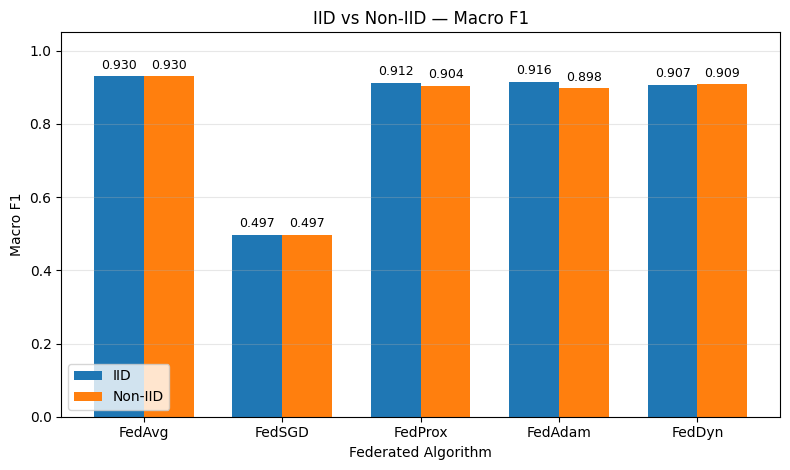

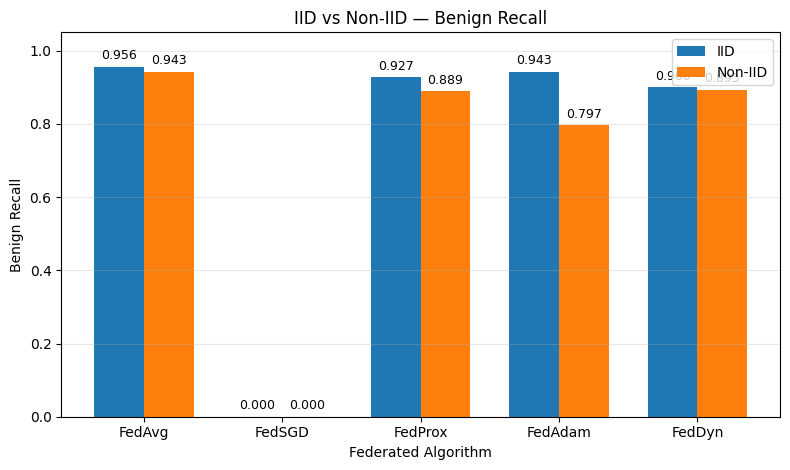

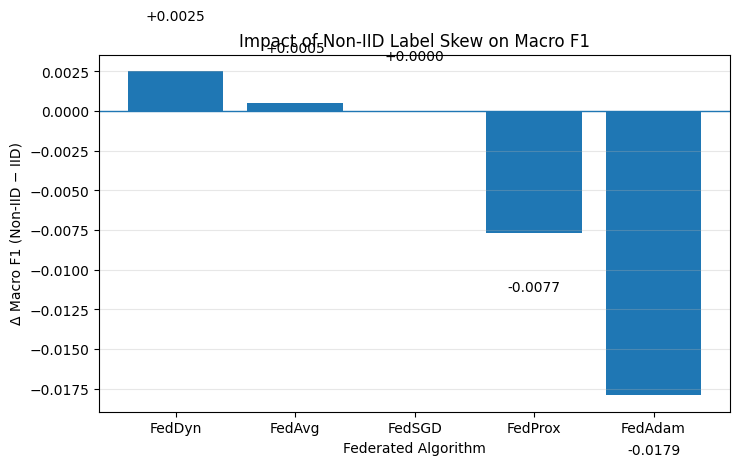


IID vs NON-IID COMPARISON COMPLETE

Saved ONLY:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/IID_vs_NonIID_Comparison/IID_vs_NonIID_5Algorithms_Comparison.csv

✅ Same five algorithms compared.
✅ IID and Non-IID metrics loaded automatically.
✅ No metric manually entered.
✅ No training performed.
✅ No model loaded.
✅ No test inference performed.
✅ Comparison figures displayed only.
✅ Figures NOT saved to Drive.


In [ ]:
# ================================================================
# CELL 31:
# IID vs NON-IID DIRECT FEDERATED COMPARISON
# ================================================================
#
# PURPOSE:
#   Compare the SAME five FL algorithms under:
#       1. IID
#       2. Controlled Strong Label-Skew Non-IID
#
# ALGORITHMS:
#   FedAvg
#   FedSGD
#   FedProx
#   FedAdam
#   FedDyn
#
# PRIMARY METRICS:
#   Macro F1
#   Benign Recall
#   Benign F1
#   ROC-AUC
#
# DELTA DEFINITION:
#   Delta = Non-IID - IID
#
# Therefore:
#   Negative delta = performance degradation under Non-IID
#   Positive delta = improvement under Non-IID
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------------
# 2. Required root
# ----------------------------------------------------------------

if "FL_ROOT" not in globals():

    raise RuntimeError(
        "FL_ROOT is missing. "
        "Run the notebook setup cell first."
    )


# ----------------------------------------------------------------
# 3. Existing final comparison files
# ----------------------------------------------------------------

IID_COMPARISON_FILE = os.path.join(
    FL_ROOT,
    "IID_Final_Comparison",
    "IID_5Algorithms_Final_Comparison.csv"
)


NONIID_COMPARISON_FILE = os.path.join(
    FL_ROOT,
    "NonIID_Final_Comparison",
    "NonIID_5Algorithms_Final_Comparison.csv"
)


for path in [
    IID_COMPARISON_FILE,
    NONIID_COMPARISON_FILE
]:

    if not os.path.exists(path):

        raise FileNotFoundError(
            "Required comparison file missing:\n" + path
        )


print("=" * 100)

print(
    "IID vs NON-IID FEDERATED LEARNING COMPARISON"
)

print("=" * 100)


print(
    "\n✅ IID comparison:",
    IID_COMPARISON_FILE
)


print(
    "✅ Non-IID comparison:",
    NONIID_COMPARISON_FILE
)


# ----------------------------------------------------------------
# 4. Load comparison tables
# ----------------------------------------------------------------

iid_df = pd.read_csv(
    IID_COMPARISON_FILE
)


noniid_df = pd.read_csv(
    NONIID_COMPARISON_FILE
)


# ----------------------------------------------------------------
# 5. Required algorithms
# ----------------------------------------------------------------

EXPECTED_ALGORITHMS = [
    "FedAvg",
    "FedSGD",
    "FedProx",
    "FedAdam",
    "FedDyn"
]


for name, dataframe in [
    ("IID", iid_df),
    ("Non-IID", noniid_df)
]:

    if "Algorithm" not in dataframe.columns:

        raise RuntimeError(
            f"{name} comparison has no Algorithm column."
        )


    algorithms = set(
        dataframe[
            "Algorithm"
        ].astype(str)
    )


    missing = (
        set(EXPECTED_ALGORITHMS) - algorithms
    )


    if missing:

        raise RuntimeError(
            f"{name} comparison is missing: "
            f"{sorted(missing)}"
        )


print(
    "\n✅ Same five algorithms found "
    "in IID and Non-IID."
)


# ----------------------------------------------------------------
# 6. Required metric columns
# ----------------------------------------------------------------

REQUIRED_METRICS = [
    "Accuracy",
    "Macro_F1",
    "Benign_Recall",
    "Benign_F1",
    "ROC_AUC"
]


for metric in REQUIRED_METRICS:

    if metric not in iid_df.columns:

        raise RuntimeError(
            f"IID missing metric: {metric}"
        )


    if metric not in noniid_df.columns:

        raise RuntimeError(
            f"Non-IID missing metric: {metric}"
        )


# ----------------------------------------------------------------
# 7. Keep only required rows/columns
# ----------------------------------------------------------------

iid_keep = iid_df[
    [
        "Algorithm",
        *REQUIRED_METRICS
    ]
].copy()


noniid_keep = noniid_df[
    [
        "Algorithm",
        *REQUIRED_METRICS
    ]
].copy()


# ----------------------------------------------------------------
# 8. Rename metrics before merge
# ----------------------------------------------------------------

iid_keep = iid_keep.rename(
    columns={
        metric:
            f"IID_{metric}"

        for metric
        in REQUIRED_METRICS
    }
)


noniid_keep = noniid_keep.rename(
    columns={
        metric:
            f"NonIID_{metric}"

        for metric
        in REQUIRED_METRICS
    }
)


# ----------------------------------------------------------------
# 9. Merge by algorithm
# ----------------------------------------------------------------

comparison_df = pd.merge(
    iid_keep,
    noniid_keep,
    on="Algorithm",
    how="inner",
    validate="one_to_one"
)


if len(comparison_df) != 5:

    raise RuntimeError(
        "Expected exactly five matched algorithms."
    )


# ----------------------------------------------------------------
# 10. Compute Non-IID minus IID deltas
# ----------------------------------------------------------------

for metric in REQUIRED_METRICS:

    comparison_df[
        f"Delta_{metric}"
    ] = (

        comparison_df[
            f"NonIID_{metric}"
        ]
 -
        comparison_df[
            f"IID_{metric}"
        ]

    )


# ----------------------------------------------------------------
# 11. Percentage degradation in Macro F1
#
# Relative change:
#
#   ((NonIID - IID) / IID) * 100
# ----------------------------------------------------------------

comparison_df[
    "Macro_F1_Relative_Change_Percent"
] = (

    comparison_df[
        "Delta_Macro_F1"
    ]
 /
    comparison_df[
        "IID_Macro_F1"
    ]
 * 100.0
)


comparison_df[
    "Benign_Recall_Relative_Change_Percent"
] = np.where(

    comparison_df[
        "IID_Benign_Recall"
    ] != 0,

    (
        comparison_df[
            "Delta_Benign_Recall"
        ]
 /
        comparison_df[
            "IID_Benign_Recall"
        ]
 * 100.0
    ),

    np.nan
)


# ----------------------------------------------------------------
# 12. Robustness ranking
#
# IMPORTANT:
# A method that already collapsed on the minority class
# should NOT be called "most robust" simply because its
# IID and Non-IID scores are equally poor.
#
# FedSGD is considered minority-class collapsed when
# Benign Recall = 0 in both IID and Non-IID.
# ----------------------------------------------------------------

comparison_df[
    "Minority_Class_Collapse"
] = (

    (
        comparison_df[
            "IID_Benign_Recall"
        ] <= 1e-12
    )

    &

    (
        comparison_df[
            "NonIID_Benign_Recall"
        ] <= 1e-12
    )
)


comparison_df[
    "NonIID_Robustness_Rank"
] = pd.Series(
    pd.NA,
    index=comparison_df.index,
    dtype="Int64"
)


valid_mask = (
    ~comparison_df[
        "Minority_Class_Collapse"
    ]
)


comparison_df.loc[
    valid_mask,
    "NonIID_Robustness_Rank"
] = (

    comparison_df.loc[
        valid_mask,
        "Delta_Macro_F1"
    ]

    .rank(
        ascending=False,
        method="min"
    )

    .astype("Int64")
)


# ----------------------------------------------------------------
# 13. Sort by IID algorithm order for readability
# ----------------------------------------------------------------

algorithm_order = {
    algorithm: index

    for index, algorithm
    in enumerate(
        EXPECTED_ALGORITHMS
    )
}


comparison_df[
    "_order"
] = comparison_df[
    "Algorithm"
].map(
    algorithm_order
)


comparison_df = (
    comparison_df
    .sort_values(
        "_order"
    )
    .drop(
        columns=[
            "_order"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ----------------------------------------------------------------
# 14. Save ONLY one CSV
# ----------------------------------------------------------------

OUTPUT_DIR = os.path.join(
    FL_ROOT,
    "IID_vs_NonIID_Comparison"
)


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "IID_vs_NonIID_5Algorithms_Comparison.csv"
)


comparison_df.to_csv(
    OUTPUT_FILE,
    index=False
)


print(
    "\n✅ IID vs Non-IID comparison CSV saved."
)


# ----------------------------------------------------------------
# 15. Compact paper-oriented table
# ----------------------------------------------------------------

DISPLAY_COLUMNS = [
    "Algorithm",

    "IID_Macro_F1",
    "NonIID_Macro_F1",
    "Delta_Macro_F1",

    "IID_Benign_Recall",
    "NonIID_Benign_Recall",
    "Delta_Benign_Recall",

    "IID_Benign_F1",
    "NonIID_Benign_F1",

    "IID_ROC_AUC",
    "NonIID_ROC_AUC",

    "NonIID_Robustness_Rank"
]


print(
    "\n" + "=" * 125
)


print(
    "IID vs NON-IID PERFORMANCE TABLE"
)


print(
    "=" * 125
)


print(
    comparison_df[
        DISPLAY_COLUMNS
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}"
    )
)


# ----------------------------------------------------------------
# 16. Automatically identify robustness
# ----------------------------------------------------------------

robustness_df = (

    comparison_df[
        ~comparison_df[
            "Minority_Class_Collapse"
        ]
    ]

    .sort_values(
        "Delta_Macro_F1",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print(
    "\n" + "=" * 100
)


print(
    "ROBUSTNESS TO NON-IID LABEL SKEW"
)


print(
    "=" * 100
)


for index, row in robustness_df.iterrows():

    delta = float(
        row[
            "Delta_Macro_F1"
        ]
    )


    print(
        f"{index + 1}. "
        f"{row['Algorithm']}: "
        f"Macro-F1 Δ = {delta:+.6f}"
    )


collapsed_df = comparison_df[
    comparison_df[
        "Minority_Class_Collapse"
    ]
]


if not collapsed_df.empty:

    print(
        "\nNot included in robustness ranking:"
    )


    for _, row in collapsed_df.iterrows():

        print(
            f"- {row['Algorithm']}: "
            "minority-class collapse "
            "(Benign Recall = 0 in both IID and Non-IID)"
        )


# ----------------------------------------------------------------
# 17. Largest degradation
# ----------------------------------------------------------------

largest_drop_row = (
    comparison_df
    .sort_values(
        "Delta_Macro_F1",
        ascending=True
    )
    .iloc[0]
)


print(
    "\nLargest Macro-F1 degradation:"
)


print(
    f"{largest_drop_row['Algorithm']} "
    f"({largest_drop_row['Delta_Macro_F1']:+.6f})"
)


# ----------------------------------------------------------------
# 18. FIGURE 1
# IID vs Non-IID Macro F1
# DISPLAY ONLY
# ----------------------------------------------------------------

plot_df = comparison_df.copy()


x = np.arange(
    len(plot_df)
)


width = 0.36


plt.figure(
    figsize=(
        8,
        4.8
    )
)


bars_iid = plt.bar(
    x - width / 2,
    plot_df[
        "IID_Macro_F1"
    ],
    width,
    label="IID"
)


bars_noniid = plt.bar(
    x + width / 2,
    plot_df[
        "NonIID_Macro_F1"
    ],
    width,
    label="Non-IID"
)


plt.xticks(
    x,
    plot_df[
        "Algorithm"
    ]
)


plt.ylabel(
    "Macro F1"
)


plt.xlabel(
    "Federated Algorithm"
)


plt.title(
    "IID vs Non-IID — Macro F1"
)


plt.ylim(
    0,
    1.05
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.3
)


for bars in [
    bars_iid,
    bars_noniid
]:

    for bar in bars:

        value = (
            bar.get_height()
        )


        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.012,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.tight_layout()

plt.show()

plt.close()


# ----------------------------------------------------------------
# 19. FIGURE 2
# IID vs Non-IID Benign Recall
# DISPLAY ONLY
# ----------------------------------------------------------------

plt.figure(
    figsize=(
        8,
        4.8
    )
)


bars_iid = plt.bar(
    x - width / 2,
    plot_df[
        "IID_Benign_Recall"
    ],
    width,
    label="IID"
)


bars_noniid = plt.bar(
    x + width / 2,
    plot_df[
        "NonIID_Benign_Recall"
    ],
    width,
    label="Non-IID"
)


plt.xticks(
    x,
    plot_df[
        "Algorithm"
    ]
)


plt.ylabel(
    "Benign Recall"
)


plt.xlabel(
    "Federated Algorithm"
)


plt.title(
    "IID vs Non-IID — Benign Recall"
)


plt.ylim(
    0,
    1.05
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.3
)


for bars in [
    bars_iid,
    bars_noniid
]:

    for bar in bars:

        value = (
            bar.get_height()
        )


        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.012,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.tight_layout()

plt.show()

plt.close()


# ----------------------------------------------------------------
# 20. FIGURE 3
# Change in Macro F1 caused by Non-IID
# DISPLAY ONLY
# ----------------------------------------------------------------

delta_plot_df = (
    comparison_df
    .sort_values(
        "Delta_Macro_F1",
        ascending=False
    )
)


plt.figure(
    figsize=(
        7.5,
        4.8
    )
)


bars = plt.bar(
    delta_plot_df[
        "Algorithm"
    ],
    delta_plot_df[
        "Delta_Macro_F1"
    ]
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel(
    "Federated Algorithm"
)


plt.ylabel(
    "Δ Macro F1 (Non-IID − IID)"
)


plt.title(
    "Impact of Non-IID Label Skew on Macro F1"
)


plt.grid(
    axis="y",
    alpha=0.3
)


for bar, value in zip(
    bars,
    delta_plot_df[
        "Delta_Macro_F1"
    ]
):

    vertical_alignment = (
        "bottom"
        if value >= 0
        else "top"
    )


    offset = (
        0.003
        if value >= 0
        else -0.003
    )


    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f"{value:+.4f}",
        ha="center",
        va=vertical_alignment
    )


plt.tight_layout()

plt.show()

plt.close()


# ----------------------------------------------------------------
# 21. Final status
# ----------------------------------------------------------------

print(
    "\n" + "=" * 100
)


print(
    "IID vs NON-IID COMPARISON COMPLETE"
)


print(
    "=" * 100
)


print(
    "\nSaved ONLY:"
)


print(
    OUTPUT_FILE
)


print(
    "\n✅ Same five algorithms compared."
)


print(
    "✅ IID and Non-IID metrics loaded automatically."
)


print(
    "✅ No metric manually entered."
)


print(
    "✅ No training performed."
)


print(
    "✅ No model loaded."
)


print(
    "✅ No test inference performed."
)


print(
    "✅ Comparison figures displayed only."
)


print(
    "✅ Figures NOT saved to Drive."
)


print(
    "=" * 100
)


In [ ]:
# ================================================================
# CELL 32:
# FINAL SANITY AUDIT — BINARY FEDERATED EXPERIMENT
# ================================================================
#
# PURPOSE:
#   Verify that the completed IID / Non-IID experiment is
#   internally consistent before statistical testing.
#
# CHECKS:
#   1. Train/test shapes and labels
#   2. Non-IID partition integrity
#   3. Client class distributions
#   4. Validation/test class imbalance
#   5. All-Attack dummy baseline
#   6. Final 5-algorithm result consistency
#   7. Minority-class collapse detection
#   8. Best Non-IID FedAvg model re-check
#   9. Prediction distribution / probability sanity
#  10. Sampled exact-duplicate screen between train/test
#
# The duplicate screen is SAMPLED, not a formal proof that
# no duplicate/near-duplicate records exist in the full dataset.
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import gc
import json
import hashlib
import time

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score
)


# ----------------------------------------------------------------
# 2. Required notebook globals
# ----------------------------------------------------------------

required_globals = [
    "FL_ROOT",
    "X_TRAIN_FILE",
    "Y_TRAIN_FILE",
    "X_TEST_FILE",
    "Y_TEST_FILE"
]


missing_globals = [
    name
    for name in required_globals
    if name not in globals()
]


if missing_globals:

    raise RuntimeError(
        "Run the notebook setup/data cells first.\n"
        f"Missing: {missing_globals}"
    )


print("=" * 100)

print(
    "FINAL FEDERATED EXPERIMENT SANITY AUDIT"
)

print("=" * 100)


# ================================================================
# 3. Load processed train/test arrays
# ================================================================

X_train_audit = np.load(
    X_TRAIN_FILE,
    mmap_mode="r"
)


y_train_audit = np.asarray(
    np.load(
        Y_TRAIN_FILE,
        mmap_mode="r"
    ),
    dtype=np.int8
).reshape(-1)


X_test_audit = np.load(
    X_TEST_FILE,
    mmap_mode="r"
)


y_test_audit = np.asarray(
    np.load(
        Y_TEST_FILE,
        mmap_mode="r"
    ),
    dtype=np.int8
).reshape(-1)


if len(X_train_audit) != len(y_train_audit):

    raise RuntimeError(
        "Training X/Y length mismatch."
    )


if len(X_test_audit) != len(y_test_audit):

    raise RuntimeError(
        "Test X/Y length mismatch."
    )


if X_train_audit.shape[1:] != X_test_audit.shape[1:]:

    raise RuntimeError(
        "Train/test feature dimension mismatch."
    )


train_counts = np.bincount(
    y_train_audit,
    minlength=2
)


test_counts = np.bincount(
    y_test_audit,
    minlength=2
)


print(
    "\n[1] DATA SHAPE / LABEL AUDIT"
)


print(
    "Train shape:",
    X_train_audit.shape
)


print(
    "Test shape :",
    X_test_audit.shape
)


print(
    "Features   :",
    X_train_audit.shape[1]
)


print(
    "\nTraining labels:"
)


print(
    "  Benign:",
    f"{train_counts[0]:,}"
)


print(
    "  Attack:",
    f"{train_counts[1]:,}"
)


print(
    "\nTest labels:"
)


print(
    "  Benign:",
    f"{test_counts[0]:,}"
)


print(
    "  Attack:",
    f"{test_counts[1]:,}"
)


train_attack_fraction = (
    train_counts[1] / train_counts.sum()
)


test_attack_fraction = (
    test_counts[1] / test_counts.sum()
)


print(
    f"\nTrain attack fraction: "
    f"{train_attack_fraction:.6%}"
)


print(
    f"Test attack fraction : "
    f"{test_attack_fraction:.6%}"
)


# ================================================================
# 4. Label validity
# ================================================================

train_unique = np.unique(
    y_train_audit
)


test_unique = np.unique(
    y_test_audit
)


if not np.array_equal(
    train_unique,
    np.array(
        [0, 1],
        dtype=np.int8
    )
):

    raise RuntimeError(
        f"Unexpected training labels: "
        f"{train_unique}"
    )


if not np.array_equal(
    test_unique,
    np.array(
        [0, 1],
        dtype=np.int8
    )
):

    raise RuntimeError(
        f"Unexpected test labels: "
        f"{test_unique}"
    )


print(
    "\n✅ Binary labels correctly encoded as 0/1."
)


# ================================================================
# 5. Non-IID partition integrity
# ================================================================

PARTITION_FILE = os.path.join(
    FL_ROOT,
    "partition",
    "NonIID",
    "Strong_LabelSkew_5Clients_Binary_partition.npz"
)


if not os.path.exists(
    PARTITION_FILE
):

    raise FileNotFoundError(
        "Non-IID partition file missing:\n" + PARTITION_FILE
    )


with np.load(
    PARTITION_FILE,
    allow_pickle=False
) as partition_data:

    assignment = np.asarray(
        partition_data[
            "assignment"
        ],
        dtype=np.int8
    )


if len(assignment) != len(y_train_audit):

    raise RuntimeError(
        "Partition assignment length "
        "does not match training dataset."
    )


valid_assignment_values = set(
    np.unique(
        assignment
    ).tolist()
)


EXPECTED_ASSIGNMENT_VALUES = {
    -1,
    0,
    1,
    2,
    3,
    4
}


if (
    valid_assignment_values != EXPECTED_ASSIGNMENT_VALUES
):

    raise RuntimeError(
        "Unexpected partition assignment values:\n"
        f"{valid_assignment_values}"
    )


validation_indices = np.flatnonzero(
    assignment == -1
)


client_indices = [

    np.flatnonzero(
        assignment == client_id
    )

    for client_id
    in range(5)
]


total_partitioned = (
    len(validation_indices) + sum(
        len(indices)
        for indices
        in client_indices
    )
)


if total_partitioned != len(y_train_audit):

    raise RuntimeError(
        "Partition does not cover "
        "the full training dataset."
    )


print(
    "\n" + "=" * 100
)


print(
    "[2] NON-IID PARTITION INTEGRITY"
)


print(
    "=" * 100
)


print(
    "Validation samples:",
    f"{len(validation_indices):,}"
)


print(
    "\nClient distribution:"
)


expected_benign_counts = get_expected_benign_counts(
    y_train_audit,
    validation_indices,
    BENIGN_ALLOCATION
)


actual_benign_counts = []


for client_id, indices in enumerate(
    client_indices
):

    labels = y_train_audit[
        indices
    ]


    counts = np.bincount(
        labels,
        minlength=2
    )


    benign_count = int(
        counts[0]
    )


    attack_count = int(
        counts[1]
    )


    actual_benign_counts.append(
        benign_count
    )


    benign_fraction = (
        benign_count / len(indices)
    )


    print(
        f"Client {client_id + 1}: "
        f"total={len(indices):,}, "
        f"benign={benign_count:,}, "
        f"attack={attack_count:,}, "
        f"benign%={benign_fraction:.4%}"
    )


if (
    actual_benign_counts != expected_benign_counts
):

    raise RuntimeError(
        "Frozen Non-IID benign distribution changed."
    )


print(
    "\n✅ Frozen 50/25/15/7/3 benign allocation verified."
)


print(
    "✅ Every training sample belongs to exactly "
    "one client or the global validation set."
)


# ================================================================
# 6. Validation distribution
# ================================================================

validation_labels = y_train_audit[
    validation_indices
]


validation_counts = np.bincount(
    validation_labels,
    minlength=2
)


print(
    "\nValidation labels:"
)


print(
    "  Benign:",
    f"{validation_counts[0]:,}"
)


print(
    "  Attack:",
    f"{validation_counts[1]:,}"
)


print(
    f"  Attack fraction: "
    f"{validation_counts[1] / validation_counts.sum():.6%}"
)


# ================================================================
# 7. Majority-class dummy baseline
#
# Predict EVERY test sample as Attack.
# ================================================================

dummy_predictions = np.ones_like(
    y_test_audit,
    dtype=np.int8
)


dummy_accuracy = float(
    accuracy_score(
        y_test_audit,
        dummy_predictions
    )
)


dummy_macro_f1 = float(
    f1_score(
        y_test_audit,
        dummy_predictions,
        average="macro",
        zero_division=0
    )
)


dummy_benign_recall = float(
    recall_score(
        y_test_audit,
        dummy_predictions,
        pos_label=0,
        zero_division=0
    )
)


dummy_benign_f1 = float(
    f1_score(
        y_test_audit,
        dummy_predictions,
        pos_label=0,
        zero_division=0
    )
)


print(
    "\n" + "=" * 100
)


print(
    "[3] SEVERE-IMBALANCE DUMMY BASELINE"
)


print(
    "=" * 100
)


print(
    "Dummy strategy: predict every sample as Attack"
)


print(
    f"Accuracy      : {dummy_accuracy:.6f}"
)


print(
    f"Macro F1      : {dummy_macro_f1:.6f}"
)


print(
    f"Benign Recall : {dummy_benign_recall:.6f}"
)


print(
    f"Benign F1     : {dummy_benign_f1:.6f}"
)


print(
    "\n⚠️ This confirms why Accuracy alone "
    "is not a reliable primary metric."
)


# ================================================================
# 8. Load final Non-IID comparison
# ================================================================

COMPARISON_FILE = os.path.join(
    FL_ROOT,
    "NonIID_Final_Comparison",
    "NonIID_5Algorithms_Final_Comparison.csv"
)


if not os.path.exists(
    COMPARISON_FILE
):

    raise FileNotFoundError(
        "Run Cell 30 first:\n" + COMPARISON_FILE
    )


comparison_df = pd.read_csv(
    COMPARISON_FILE
)


EXPECTED_ALGORITHMS = {
    "FedAvg",
    "FedSGD",
    "FedProx",
    "FedAdam",
    "FedDyn"
}


if (
    set(
        comparison_df[
            "Algorithm"
        ]
    ) != EXPECTED_ALGORITHMS
):

    raise RuntimeError(
        "Unexpected algorithms in "
        "Non-IID comparison table."
    )


print(
    "\n" + "=" * 100
)


print(
    "[4] FINAL RESULT CONSISTENCY"
)


print(
    "=" * 100
)


audit_columns = [
    "Algorithm",
    "Accuracy",
    "Macro_F1",
    "Benign_Recall",
    "Benign_F1",
    "ROC_AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]


print(
    comparison_df[
        audit_columns
    ].to_string(
        index=False,
        float_format=lambda value:
            f"{value:.6f}"
    )
)


# ================================================================
# 9. Automatically detect minority-class collapse
# ================================================================

comparison_df[
    "Minority_Class_Collapse"
] = (

    comparison_df[
        "Benign_Recall"
    ] <= 1e-12

)


collapsed_models = comparison_df[
    comparison_df[
        "Minority_Class_Collapse"
    ]
]


print(
    "\nMinority-class collapse check:"
)


if collapsed_models.empty:

    print(
        "✅ No model completely collapsed "
        "on the Benign class."
    )

else:

    for _, row in collapsed_models.iterrows():

        print(
            f"⚠️ {row['Algorithm']}: "
            f"Benign Recall = "
            f"{row['Benign_Recall']:.6f}, "
            f"Benign F1 = "
            f"{row['Benign_F1']:.6f}"
        )


# ================================================================
# 10. Verify FedSGD against dummy majority baseline
# ================================================================

fedsgd_row = comparison_df[
    comparison_df[
        "Algorithm"
    ] == "FedSGD"
].iloc[0]


print(
    "\nFedSGD vs all-Attack dummy:"
)


print(
    f"FedSGD Accuracy : "
    f"{fedsgd_row['Accuracy']:.6f}"
)


print(
    f"Dummy Accuracy  : "
    f"{dummy_accuracy:.6f}"
)


print(
    f"FedSGD Macro F1 : "
    f"{fedsgd_row['Macro_F1']:.6f}"
)


print(
    f"Dummy Macro F1  : "
    f"{dummy_macro_f1:.6f}"
)


print(
    f"FedSGD Benign Recall: "
    f"{fedsgd_row['Benign_Recall']:.6f}"
)


if (
    np.isclose(
        fedsgd_row[
            "Accuracy"
        ],
        dummy_accuracy,
        atol=1e-8
    ) and fedsgd_row[
        "Benign_Recall"
    ] <= 1e-12
):

    print(
        "\n✅ FedSGD collapse independently confirmed:"
    )

    print(
        "   performance matches the "
        "all-Attack majority-class baseline."
    )


# ================================================================
# 11. Identify best functioning Non-IID model
# ================================================================

functioning_df = comparison_df[
    comparison_df[
        "Benign_Recall"
    ] > 0
].copy()


best_row = (
    functioning_df
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .iloc[0]
)


BEST_ALGORITHM = str(
    best_row[
        "Algorithm"
    ]
)


print(
    "\n" + "=" * 100
)


print(
    "[5] BEST NON-IID MODEL SANITY CHECK"
)


print(
    "=" * 100
)


print(
    "Best functioning algorithm:",
    BEST_ALGORITHM
)


print(
    f"Saved Macro F1 : "
    f"{best_row['Macro_F1']:.6f}"
)


print(
    f"Saved Benign Recall: "
    f"{best_row['Benign_Recall']:.6f}"
)


# ================================================================
# 12. Best-model path
#
# Current experiment: FedAvg is expected to win.
# ================================================================

BEST_MODEL_PATHS = {

    "FedAvg":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedAvg",
            "model",
            "FedAvg_Round20_Final.keras"
        ),

    "FedProx":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedProx",
            "model",
            "FedProx_Round20_Final.keras"
        ),

    "FedAdam":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedAdam_ServerLR_0.01",
            "model",
            "FedAdam_Round20_Final.keras"
        ),

    "FedDyn":
        os.path.join(
            FL_ROOT,
            "NonIID",
            "FedDyn",
            "model",
            "FedDyn_Round20_Final.keras"
        )
}


if BEST_ALGORITHM not in BEST_MODEL_PATHS:

    raise RuntimeError(
        "Unexpected best functioning algorithm."
    )


BEST_MODEL_FILE = BEST_MODEL_PATHS[
    BEST_ALGORITHM
]


if not os.path.exists(
    BEST_MODEL_FILE
):

    raise FileNotFoundError(
        "Best-model file missing:\n" + BEST_MODEL_FILE
    )


# ================================================================
# 13. Recompute best-model test predictions
#
# DISPLAY / RAM ONLY.
# Nothing is saved.
# ================================================================

tf.keras.backend.clear_session()


best_model = tf.keras.models.load_model(
    BEST_MODEL_FILE,
    compile=False
)


if int(
    best_model.count_params()
) != 60097:

    raise RuntimeError(
        "Unexpected best-model architecture."
    )


TEST_BATCH_SIZE = 4096


probability_parts = []


audit_inference_start = time.time()


for start in range(
    0,
    len(
        y_test_audit
    ),
    TEST_BATCH_SIZE
):

    end = min(
        start + TEST_BATCH_SIZE,
        len(
            y_test_audit
        )
    )


    batch_x = np.asarray(
        X_test_audit[
            start:end
        ],
        dtype=np.float32
    )[
        ...,
        np.newaxis
    ]


    batch_probability = (
        best_model(
            tf.convert_to_tensor(
                batch_x,
                dtype=tf.float32
            ),
            training=False
        )
        .numpy()
        .reshape(-1)
        .astype(
            np.float32,
            copy=False
        )
    )


    probability_parts.append(
        batch_probability
    )


    del (
        batch_x,
        batch_probability
    )


best_prob = np.concatenate(
    probability_parts
)


del probability_parts


audit_inference_time = float(
    time.time() - audit_inference_start
)


if not np.all(
    np.isfinite(
        best_prob
    )
):

    raise RuntimeError(
        "Best-model probabilities contain NaN/Inf."
    )


best_pred = (
    best_prob >= 0.5
).astype(
    np.int8
)


# ================================================================
# 14. Recomputed metrics
# ================================================================

best_accuracy = float(
    accuracy_score(
        y_test_audit,
        best_pred
    )
)


best_macro_f1 = float(
    f1_score(
        y_test_audit,
        best_pred,
        average="macro",
        zero_division=0
    )
)


best_benign_recall = float(
    recall_score(
        y_test_audit,
        best_pred,
        pos_label=0,
        zero_division=0
    )
)


best_benign_f1 = float(
    f1_score(
        y_test_audit,
        best_pred,
        pos_label=0,
        zero_division=0
    )
)


best_balanced_accuracy = float(
    balanced_accuracy_score(
        y_test_audit,
        best_pred
    )
)


best_mcc = float(
    matthews_corrcoef(
        y_test_audit,
        best_pred
    )
)


best_auc = float(
    roc_auc_score(
        y_test_audit,
        best_prob
    )
)


best_cm = confusion_matrix(
    y_test_audit,
    best_pred,
    labels=[
        0,
        1
    ]
)


tn, fp, fn, tp = (
    best_cm.ravel()
)


print(
    "\nRecomputed from final model:"
)


print(
    f"Accuracy          : {best_accuracy:.6f}"
)


print(
    f"Macro F1          : {best_macro_f1:.6f}"
)


print(
    f"Benign Recall     : {best_benign_recall:.6f}"
)


print(
    f"Benign F1         : {best_benign_f1:.6f}"
)


print(
    f"Balanced Accuracy : {best_balanced_accuracy:.6f}"
)


print(
    f"MCC               : {best_mcc:.6f}"
)


print(
    f"ROC-AUC           : {best_auc:.6f}"
)


print(
    f"TN/FP/FN/TP       : "
    f"{tn:,} / {fp:,} / {fn:,} / {tp:,}"
)


# ================================================================
# 15. Verify recomputed values against saved CSV
# ================================================================

metric_checks = {

    "Accuracy":
        (
            best_accuracy,
            float(
                best_row[
                    "Accuracy"
                ]
            )
        ),

    "Macro_F1":
        (
            best_macro_f1,
            float(
                best_row[
                    "Macro_F1"
                ]
            )
        ),

    "Benign_Recall":
        (
            best_benign_recall,
            float(
                best_row[
                    "Benign_Recall"
                ]
            )
        ),

    "Benign_F1":
        (
            best_benign_f1,
            float(
                best_row[
                    "Benign_F1"
                ]
            )
        ),

    "ROC_AUC":
        (
            best_auc,
            float(
                best_row[
                    "ROC_AUC"
                ]
            )
        )
}


for metric_name, (
    recomputed,
    saved
) in metric_checks.items():

    if not np.isclose(
        recomputed,
        saved,
        atol=1e-5
    ):

        raise RuntimeError(
            f"{metric_name} mismatch:\n"
            f"Recomputed={recomputed}\n"
            f"Saved={saved}"
        )


print(
    "\n✅ Best-model metrics independently "
    "reproduced from the saved model."
)


# ================================================================
# 16. Prediction distribution
# ================================================================

predicted_benign = int(
    np.sum(
        best_pred == 0
    )
)


predicted_attack = int(
    np.sum(
        best_pred == 1
    )
)


print(
    "\nPrediction distribution:"
)


print(
    "Predicted Benign:",
    f"{predicted_benign:,}",
    f"({predicted_benign / len(best_pred):.4%})"
)


print(
    "Predicted Attack:",
    f"{predicted_attack:,}",
    f"({predicted_attack / len(best_pred):.4%})"
)


# ================================================================
# 17. Probability sanity by TRUE class
# ================================================================

benign_prob = best_prob[
    y_test_audit == 0
]


attack_prob = best_prob[
    y_test_audit == 1
]


quantiles = [
    0.05,
    0.25,
    0.50,
    0.75,
    0.95
]


benign_quantiles = np.quantile(
    benign_prob,
    quantiles
)


attack_quantiles = np.quantile(
    attack_prob,
    quantiles
)


print(
    "\nPredicted ATTACK probability "
    "by true class:"
)


print(
    f"True Benign mean: "
    f"{np.mean(benign_prob):.6f}"
)


print(
    f"True Attack mean: "
    f"{np.mean(attack_prob):.6f}"
)


print(
    "\nQuantiles:"
)


print(
    "q        Benign       Attack"
)


for q, benign_q, attack_q in zip(
    quantiles,
    benign_quantiles,
    attack_quantiles
):

    print(
        f"{q:0.2f}   "
        f"{benign_q:0.6f}     "
        f"{attack_q:0.6f}"
    )


if (
    np.mean(
        attack_prob
    ) <= np.mean(
        benign_prob
    )
):

    raise RuntimeError(
        "Probability sanity failed: "
        "attack scores are not higher "
        "than benign scores on average."
    )


print(
    "\n✅ Probability direction is sensible."
)


# ================================================================
# 18. Sampled exact-duplicate screen
#
# IMPORTANT:
# This is deliberately a SCREEN, not a proof.
#
# We sample both classes so severe attack imbalance
# does not dominate the audit.
# ================================================================

print(
    "\n" + "=" * 100
)


print(
    "[6] SAMPLED TRAIN/TEST EXACT-DUPLICATE SCREEN"
)


print(
    "=" * 100
)


AUDIT_SEED = 2026

rng = np.random.default_rng(
    AUDIT_SEED
)


def stratified_sample_indices(
    labels,
    max_per_class=10000
):

    selected = []


    for class_value in [
        0,
        1
    ]:

        class_indices = np.flatnonzero(
            labels == class_value
        )


        sample_size = min(
            max_per_class,
            len(
                class_indices
            )
        )


        chosen = rng.choice(
            class_indices,
            size=sample_size,
            replace=False
        )


        selected.append(
            chosen
        )


    return np.concatenate(
        selected
    )


train_sample_indices = (
    stratified_sample_indices(
        y_train_audit,
        max_per_class=10000
    )
)


test_sample_indices = (
    stratified_sample_indices(
        y_test_audit,
        max_per_class=10000
    )
)


print(
    "Train rows screened:",
    f"{len(train_sample_indices):,}"
)


print(
    "Test rows screened :",
    f"{len(test_sample_indices):,}"
)


def row_digest(
    row
):

    contiguous_row = np.ascontiguousarray(
        row,
        dtype=np.float32
    )


    return hashlib.blake2b(
        contiguous_row.tobytes(),
        digest_size=16
    ).digest()


train_hashes = set()


for index in train_sample_indices:

    train_hashes.add(
        row_digest(
            X_train_audit[
                index
            ]
        )
    )


duplicate_count = 0


for index in test_sample_indices:

    digest = row_digest(
        X_test_audit[
            index
        ]
    )


    if digest in train_hashes:

        duplicate_count += 1


print(
    "\nSampled exact feature-vector matches:",
    duplicate_count
)


if duplicate_count == 0:

    print(
        "✅ No exact duplicate feature vector "
        "was found in the sampled screen."
    )

    print(
        "⚠️ This does NOT prove that the full "
        "train/test datasets contain no duplicates "
        "or highly similar flows."
    )

else:

    print(
        "⚠️ Exact train/test feature duplicates "
        "were detected in the sampled audit."
    )

    print(
        "This should be investigated before "
        "making strong generalization claims."
    )


# ================================================================
# 19. Final audit summary
# ================================================================

print(
    "\n" + "=" * 100
)


print(
    "SANITY AUDIT COMPLETE"
)


print(
    "=" * 100
)


print(
    "✅ Train/test shapes and binary labels verified."
)


print(
    "✅ Frozen Non-IID partition verified."
)


print(
    "✅ Client label-skew distribution verified."
)


print(
    "✅ Severe class imbalance quantified."
)


print(
    "✅ All-Attack dummy baseline quantified."
)


print(
    "✅ FedSGD minority-class collapse checked."
)


print(
    f"✅ Best functioning Non-IID model: "
    f"{BEST_ALGORITHM}"
)


print(
    "✅ Best-model saved metrics independently reproduced."
)


print(
    "✅ Prediction distribution checked."
)


print(
    "✅ Probability direction checked."
)


print(
    "✅ Sampled exact-duplicate screen completed."
)


print(
    "\nNo models, predictions, figures, "
    "or audit files were saved to Drive."
)


print(
    f"Best-model audit inference time: "
    f"{audit_inference_time:.1f} sec"
)


print(
    "=" * 100
)

# ================================================================
# 20. FOLLOW-UP DUPLICATE / LEAKAGE AUDIT
# ================================================================
#
# Previous sampled screen found exact processed-vector matches.
# This follow-up checks whether that overlap is substantial.
#
# IMPORTANT:
# Exact processed feature-vector match does NOT automatically
# prove raw-flow leakage because identifiers such as FlowID,
# IP and timestamp are no longer present.
#
# NO training
# NO model changes
# NO Drive saving
# ================================================================


print(
    "\n" + "=" * 100
)

print(
    "FOLLOW-UP DUPLICATE / LEAKAGE AUDIT"
)

print(
    "=" * 100
)


# ----------------------------------------------------------------
# Helper: exact processed-row representation
# ----------------------------------------------------------------

def make_row_keys(array):

    array = np.ascontiguousarray(
        array,
        dtype=np.float32
    )

    row_size_bytes = (
        array.dtype.itemsize * array.shape[1]
    )

    return array.view(
        np.dtype(
            (
                np.void,
                row_size_bytes
            )
        )
    ).reshape(-1)


# ================================================================
# A. FULL BENIGN TRAIN ↔ TEST OVERLAP
# ================================================================

print(
    "\n[7] FULL BENIGN TRAIN ↔ TEST EXACT OVERLAP"
)


train_benign_indices = np.flatnonzero(
    y_train_audit == 0
)


test_benign_indices = np.flatnonzero(
    y_test_audit == 0
)


X_train_benign = np.asarray(
    X_train_audit[
        train_benign_indices
    ],
    dtype=np.float32
)


X_test_benign = np.asarray(
    X_test_audit[
        test_benign_indices
    ],
    dtype=np.float32
)


train_benign_keys = make_row_keys(
    X_train_benign
)


test_benign_keys = make_row_keys(
    X_test_benign
)


unique_train_benign_keys = np.unique(
    train_benign_keys
)


unique_test_benign_keys = np.unique(
    test_benign_keys
)


test_benign_match_mask = np.isin(
    test_benign_keys,
    unique_train_benign_keys
)


matched_test_benign_rows = int(
    np.sum(
        test_benign_match_mask
    )
)


shared_unique_benign_patterns = int(
    len(
        np.intersect1d(
            unique_train_benign_keys,
            unique_test_benign_keys
        )
    )
)


train_benign_internal_duplicates = int(
    len(train_benign_keys) - len(unique_train_benign_keys)
)


test_benign_internal_duplicates = int(
    len(test_benign_keys) - len(unique_test_benign_keys)
)


print(
    "Train Benign rows:",
    f"{len(train_benign_keys):,}"
)


print(
    "Unique Train Benign patterns:",
    f"{len(unique_train_benign_keys):,}"
)


print(
    "Repeated Train Benign rows:",
    f"{train_benign_internal_duplicates:,}"
)


print(
    "\nTest Benign rows:",
    f"{len(test_benign_keys):,}"
)


print(
    "Unique Test Benign patterns:",
    f"{len(unique_test_benign_keys):,}"
)


print(
    "Repeated Test Benign rows:",
    f"{test_benign_internal_duplicates:,}"
)


print(
    "\nTest Benign rows having exact "
    "Train Benign feature-vector match:"
)


print(
    f"{matched_test_benign_rows:,} / "
    f"{len(test_benign_keys):,}"
)


print(
    f"Percentage: "
    f"{matched_test_benign_rows / len(test_benign_keys):.6%}"
)


print(
    "Shared unique Benign patterns:",
    f"{shared_unique_benign_patterns:,}"
)


# ================================================================
# B. CROSS-LABEL EXACT MATCH
#
# Test Benign pattern appearing among Train Attack
# ================================================================

print(
    "\n" + "=" * 100
)

print(
    "[8] CROSS-LABEL EXACT-MATCH CHECK"
)

print(
    "=" * 100
)


SCAN_CHUNK_SIZE = 100_000


train_attack_rows_matching_test_benign = 0


for start in range(
    0,
    len(y_train_audit),
    SCAN_CHUNK_SIZE
):

    end = min(
        start + SCAN_CHUNK_SIZE,
        len(y_train_audit)
    )


    chunk_labels = y_train_audit[
        start:end
    ]


    attack_mask = (
        chunk_labels == 1
    )


    if not np.any(
        attack_mask
    ):

        continue


    chunk_features = np.asarray(
        X_train_audit[
            start:end
        ][
            attack_mask
        ],
        dtype=np.float32
    )


    chunk_keys = make_row_keys(
        chunk_features
    )


    train_attack_rows_matching_test_benign += int(
        np.sum(
            np.isin(
                chunk_keys,
                unique_test_benign_keys
            )
        )
    )


    del (
        chunk_features,
        chunk_keys
    )


print(
    "Train Attack rows matching exact "
    "Test Benign vector:"
)


print(
    f"{train_attack_rows_matching_test_benign:,}"
)


# ----------------------------------------------------------------
# Reverse:
# Train Benign pattern appearing among Test Attack
# ----------------------------------------------------------------

test_attack_rows_matching_train_benign = 0


for start in range(
    0,
    len(y_test_audit),
    SCAN_CHUNK_SIZE
):

    end = min(
        start + SCAN_CHUNK_SIZE,
        len(y_test_audit)
    )


    chunk_labels = y_test_audit[
        start:end
    ]


    attack_mask = (
        chunk_labels == 1
    )


    if not np.any(
        attack_mask
    ):

        continue


    chunk_features = np.asarray(
        X_test_audit[
            start:end
        ][
            attack_mask
        ],
        dtype=np.float32
    )


    chunk_keys = make_row_keys(
        chunk_features
    )


    test_attack_rows_matching_train_benign += int(
        np.sum(
            np.isin(
                chunk_keys,
                unique_train_benign_keys
            )
        )
    )


    del (
        chunk_features,
        chunk_keys
    )


print(
    "\nTest Attack rows matching exact "
    "Train Benign vector:"
)


print(
    f"{test_attack_rows_matching_train_benign:,}"
)


# ================================================================
# C. LARGER ATTACK ↔ ATTACK SAMPLE SCREEN
# ================================================================

print(
    "\n" + "=" * 100
)

print(
    "[9] LARGE ATTACK-CLASS DUPLICATE SCREEN"
)

print(
    "=" * 100
)


FOLLOWUP_SEED = 2026


followup_rng = np.random.default_rng(
    FOLLOWUP_SEED
)


train_attack_indices = np.flatnonzero(
    y_train_audit == 1
)


test_attack_indices = np.flatnonzero(
    y_test_audit == 1
)


TRAIN_ATTACK_SAMPLE_SIZE = min(
    100_000,
    len(train_attack_indices)
)


TEST_ATTACK_SAMPLE_SIZE = min(
    50_000,
    len(test_attack_indices)
)


sample_train_attack_indices = (
    followup_rng.choice(
        train_attack_indices,
        size=TRAIN_ATTACK_SAMPLE_SIZE,
        replace=False
    )
)


sample_test_attack_indices = (
    followup_rng.choice(
        test_attack_indices,
        size=TEST_ATTACK_SAMPLE_SIZE,
        replace=False
    )
)


X_train_attack_sample = np.asarray(
    X_train_audit[
        sample_train_attack_indices
    ],
    dtype=np.float32
)


X_test_attack_sample = np.asarray(
    X_test_audit[
        sample_test_attack_indices
    ],
    dtype=np.float32
)


train_attack_sample_keys = make_row_keys(
    X_train_attack_sample
)


test_attack_sample_keys = make_row_keys(
    X_test_attack_sample
)


unique_train_attack_sample_keys = np.unique(
    train_attack_sample_keys
)


attack_sample_match_mask = np.isin(
    test_attack_sample_keys,
    unique_train_attack_sample_keys
)


attack_sample_matches = int(
    np.sum(
        attack_sample_match_mask
    )
)


print(
    "Train Attack rows sampled:",
    f"{TRAIN_ATTACK_SAMPLE_SIZE:,}"
)


print(
    "Test Attack rows sampled :",
    f"{TEST_ATTACK_SAMPLE_SIZE:,}"
)


print(
    "\nExact Attack↔Attack sampled matches:"
)


print(
    f"{attack_sample_matches:,} / "
    f"{TEST_ATTACK_SAMPLE_SIZE:,}"
)


print(
    f"Percentage: "
    f"{attack_sample_matches / TEST_ATTACK_SAMPLE_SIZE:.6%}"
)


# ================================================================
# D. INTERPRETATION
# ================================================================

print(
    "\n" + "=" * 100
)

print(
    "[10] DUPLICATE / LEAKAGE INTERPRETATION"
)

print(
    "=" * 100
)


cross_label_conflict = (

    train_attack_rows_matching_test_benign > 0
 or
    test_attack_rows_matching_train_benign > 0
)


if cross_label_conflict:

    print(
        "⚠️ Cross-label exact processed-vector "
        "matches were detected."
    )

    print(
        "Identical 79-feature vectors can appear "
        "with different labels."
    )

else:

    print(
        "✅ No cross-label exact processed-vector "
        "conflict detected in the full Benign-based check."
    )


if matched_test_benign_rows > 0:

    print(
        "\n⚠️ Same-label exact Benign patterns "
        "occur in both train and test."
    )

    print(
        "This does NOT automatically prove raw-flow leakage."
    )

    print(
        "Generalization claims should therefore "
        "remain appropriately cautious."
    )

else:

    print(
        "\n✅ No exact processed Benign overlap "
        "between train and test."
    )


print(
    "\nMethodology note:"
)


print(
    "These comparisons use the final 79 processed features."
)


print(
    "FlowID/IP/timestamp identifiers are absent, "
    "so exact processed-vector equality cannot establish "
    "whether records originated from the same raw flow."
)


# ================================================================
# 21. COMBINED SANITY-AUDIT SUMMARY
# ================================================================

print(
    "\n" + "=" * 100
)


print(
    "COMPLETE SANITY + DUPLICATE AUDIT FINISHED"
)


print(
    "=" * 100
)


print(
    f"Initial sampled exact matches        : "
    f"{duplicate_count:,}"
)


print(
    f"Full Test-Benign → Train-Benign     : "
    f"{matched_test_benign_rows:,}"
)


print(
    f"Train-Attack → Test-Benign conflicts: "
    f"{train_attack_rows_matching_test_benign:,}"
)


print(
    f"Test-Attack → Train-Benign conflicts: "
    f"{test_attack_rows_matching_train_benign:,}"
)


print(
    f"Sampled Attack↔Attack matches        : "
    f"{attack_sample_matches:,}"
)


print(
    "\n✅ No model trained."
)


print(
    "✅ No model changed."
)


print(
    "✅ Nothing saved to Drive."
)


print(
    "=" * 100
)


# ================================================================
# 22. FINAL CLEANUP
# ================================================================

del (
    best_model,
    best_prob,
    best_pred,
    benign_prob,
    attack_prob,
    dummy_predictions,
    X_train_benign,
    X_test_benign,
    train_benign_keys,
    test_benign_keys,
    unique_train_benign_keys,
    unique_test_benign_keys,
    X_train_attack_sample,
    X_test_attack_sample,
    train_attack_sample_keys,
    test_attack_sample_keys,
    unique_train_attack_sample_keys,
    train_attack_indices,
    test_attack_indices,
    sample_train_attack_indices,
    sample_test_attack_indices
)


tf.keras.backend.clear_session()

gc.collect()


FINAL FEDERATED EXPERIMENT SANITY AUDIT

[1] DATA SHAPE / LABEL AUDIT
Train shape: (2597892, 79)
Test shape : (649474, 79)
Features   : 79

Training labels:
  Benign: 26,074
  Attack: 2,571,818

Test labels:
  Benign: 6,519
  Attack: 642,955

Train attack fraction: 98.996340%
Test attack fraction : 98.996265%

✅ Binary labels correctly encoded as 0/1.

[2] NON-IID PARTITION INTEGRITY
Validation samples: 259,790

Client distribution:
Client 1: total=467,621, benign=11,733, attack=455,888, benign%=2.5091%
Client 2: total=467,621, benign=5,867, attack=461,754, benign%=1.2546%
Client 3: total=467,620, benign=3,520, attack=464,100, benign%=0.7527%
Client 4: total=467,620, benign=1,643, attack=465,977, benign%=0.3514%
Client 5: total=467,620, benign=704, attack=466,916, benign%=0.1505%

✅ Frozen 50/25/15/7/3 benign allocation verified.
✅ Every training sample belongs to exactly one client or the global validation set.

Validation labels:
  Benign: 2,607
  Attack: 257,183
  Attack fraction: 9

0

In [ ]:
# ================================================================
# CELL 33:
# FINAL PAPER-READY CONSOLIDATED FEDERATED RESULTS
# ================================================================
#
# PURPOSE:
#   Combine the completed federated experiment into clean,
#   publication-ready result tables.
#
# SOURCES:
#   1. Official IID final comparison
#   2. Official Non-IID final comparison
#   3. IID statistical analysis
#   4. Non-IID statistical analysis
#   5. IID vs Non-IID robustness comparison
#
# IMPORTANT:
#   - NO training
#   - NO model loading
#   - NO inference
#   - NO prediction generation
#   - NO existing result overwrite
#   - NO figure saving
#
# SAVES ONLY:
#   Final_Paper_Ready_Results/
#       Federated_Final_Consolidated_Results.csv
#
# NOTE:
#   Official point estimates always come from the final
#   IID / Non-IID comparison CSVs.
#
#   Statistical files are used only for confidence intervals
#   and pairwise significance information.
# ================================================================


# ----------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------

import os
import numpy as np
import pandas as pd

from IPython.display import display


print("=" * 115)
print("FINAL PAPER-READY FEDERATED RESULTS")
print("=" * 115)


# ================================================================
# 2. Federated root
# ================================================================

if "FL_ROOT" not in globals():

    FL_ROOT = (
        "/content/drive/MyDrive/"
        "IoMT_Thesis_2024/"
        "federated_binary"
    )


if not os.path.isdir(
    FL_ROOT
):

    raise FileNotFoundError(
        "Federated experiment root not found:\n" + FL_ROOT
    )


print(
    "\nFederated root:"
)

print(
    FL_ROOT
)


# ================================================================
# 3. Required source files
# ================================================================

IID_COMPARISON_FILE = os.path.join(
    FL_ROOT,
    "IID_Final_Comparison",
    "IID_5Algorithms_Final_Comparison.csv"
)


NONIID_COMPARISON_FILE = os.path.join(
    FL_ROOT,
    "NonIID_Final_Comparison",
    "NonIID_5Algorithms_Final_Comparison.csv"
)


IID_STAT_FILE = os.path.join(
    FL_ROOT,
    "IID_Statistical_Analysis",
    "IID_Final_Statistical_Analysis.csv"
)


NONIID_STAT_FILE = os.path.join(
    FL_ROOT,
    "NonIID_Statistical_Analysis",
    "NonIID_Final_Statistical_Analysis.csv"
)


ROBUSTNESS_FILE = os.path.join(
    FL_ROOT,
    "IID_vs_NonIID_Comparison",
    "IID_vs_NonIID_5Algorithms_Comparison.csv"
)


SOURCE_FILES = {

    "IID final comparison":
        IID_COMPARISON_FILE,

    "Non-IID final comparison":
        NONIID_COMPARISON_FILE,

    "IID statistical analysis":
        IID_STAT_FILE,

    "Non-IID statistical analysis":
        NONIID_STAT_FILE,

    "IID vs Non-IID robustness":
        ROBUSTNESS_FILE
}


print(
    "\nChecking required completed outputs:"
)


for name, path in SOURCE_FILES.items():

    if not os.path.exists(
        path
    ):

        raise FileNotFoundError(
            f"{name} missing:\n"
            f"{path}"
        )


    print(
        f"✅ {name}"
    )


print(
    "\n✅ All required completed outputs found."
)


# ================================================================
# 4. Load official result tables
# ================================================================

iid_df = pd.read_csv(
    IID_COMPARISON_FILE
)


noniid_df = pd.read_csv(
    NONIID_COMPARISON_FILE
)


iid_stat_df = pd.read_csv(
    IID_STAT_FILE
)


noniid_stat_df = pd.read_csv(
    NONIID_STAT_FILE
)


robustness_df = pd.read_csv(
    ROBUSTNESS_FILE
)


# ================================================================
# 5. Validate algorithms
# ================================================================

EXPECTED_ALGORITHMS = {
    "FedAvg",
    "FedSGD",
    "FedProx",
    "FedAdam",
    "FedDyn"
}


for table_name, dataframe in [

    (
        "IID",
        iid_df
    ),

    (
        "Non-IID",
        noniid_df
    ),

    (
        "Robustness",
        robustness_df
    )
]:

    if "Algorithm" not in dataframe.columns:

        raise RuntimeError(
            f"{table_name} table has no "
            "'Algorithm' column."
        )


    found_algorithms = set(
        dataframe[
            "Algorithm"
        ].astype(str)
    )


    if found_algorithms != EXPECTED_ALGORITHMS:

        raise RuntimeError(
            f"{table_name} algorithm mismatch:\n"
            f"{found_algorithms}"
        )


print(
    "\n✅ Five-algorithm identity verified."
)


# ================================================================
# 6. Required official metrics
# ================================================================

OFFICIAL_METRICS = [

    "Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Benign_Recall",
    "Benign_F1",
    "ROC_AUC"
]


for metric in OFFICIAL_METRICS:

    if metric not in iid_df.columns:

        raise RuntimeError(
            f"IID comparison missing: {metric}"
        )


    if metric not in noniid_df.columns:

        raise RuntimeError(
            f"Non-IID comparison missing: {metric}"
        )


# ================================================================
# 7. Keep official point estimates
#
# IMPORTANT:
# These values remain the authoritative final results.
# ================================================================

iid_official = iid_df[
    [
        "Algorithm",
        *OFFICIAL_METRICS
    ]
].copy()


noniid_official = noniid_df[
    [
        "Algorithm",
        *OFFICIAL_METRICS
    ]
].copy()


iid_official = iid_official.rename(
    columns={
        metric:
            f"IID_{metric}"

        for metric
        in OFFICIAL_METRICS
    }
)


noniid_official = noniid_official.rename(
    columns={
        metric:
            f"NonIID_{metric}"

        for metric
        in OFFICIAL_METRICS
    }
)


final_df = pd.merge(
    iid_official,
    noniid_official,
    on="Algorithm",
    how="inner",
    validate="one_to_one"
)


# ================================================================
# 8. Extract model-level 95% statistical CIs
# ================================================================

def extract_model_ci(
    statistical_df,
    prefix
):

    required_columns = [

        "Record_Type",
        "Algorithm",

        "Accuracy_CI_Lower",
        "Accuracy_CI_Upper",

        "Macro_F1_CI_Lower",
        "Macro_F1_CI_Upper",

        "Benign_Recall_CI_Lower",
        "Benign_Recall_CI_Upper",

        "Benign_F1_CI_Lower",
        "Benign_F1_CI_Upper"
    ]


    missing = [
        column
        for column in required_columns
        if column not in statistical_df.columns
    ]


    if missing:

        raise RuntimeError(
            f"{prefix} statistical table "
            f"is missing columns:\n"
            f"{missing}"
        )


    model_ci = statistical_df[
        statistical_df[
            "Record_Type"
        ] == "Model_95CI"
    ].copy()


    if set(
        model_ci[
            "Algorithm"
        ].astype(str)
    ) != EXPECTED_ALGORITHMS:

        raise RuntimeError(
            f"{prefix} statistical CI "
            "algorithm mismatch."
        )


    model_ci = model_ci[
        [
            "Algorithm",

            "Accuracy_CI_Lower",
            "Accuracy_CI_Upper",

            "Macro_F1_CI_Lower",
            "Macro_F1_CI_Upper",

            "Benign_Recall_CI_Lower",
            "Benign_Recall_CI_Upper",

            "Benign_F1_CI_Lower",
            "Benign_F1_CI_Upper"
        ]
    ].copy()


    model_ci = model_ci.rename(
        columns={
            column:
                f"{prefix}_{column}"

            for column
            in model_ci.columns
            if column != "Algorithm"
        }
    )


    return model_ci


iid_ci = extract_model_ci(
    iid_stat_df,
    "IID"
)


noniid_ci = extract_model_ci(
    noniid_stat_df,
    "NonIID"
)


final_df = pd.merge(
    final_df,
    iid_ci,
    on="Algorithm",
    validate="one_to_one"
)


final_df = pd.merge(
    final_df,
    noniid_ci,
    on="Algorithm",
    validate="one_to_one"
)


# ================================================================
# 9. Merge robustness / IID-to-NonIID change metrics
# ================================================================

ROBUSTNESS_COLUMNS = [

    "Algorithm",
    "Delta_Macro_F1",
    "Delta_Benign_Recall",
    "Delta_ROC_AUC",
    "Macro_F1_Relative_Change_Percent",
    "Benign_Recall_Relative_Change_Percent",
    "Minority_Class_Collapse",
    "NonIID_Robustness_Rank"
]


missing_robustness = [

    column
    for column in ROBUSTNESS_COLUMNS
    if column not in robustness_df.columns
]


if missing_robustness:

    raise RuntimeError(
        "Robustness comparison missing columns:\n"
        f"{missing_robustness}"
    )


robustness_keep = robustness_df[
    ROBUSTNESS_COLUMNS
].copy()


final_df = pd.merge(
    final_df,
    robustness_keep,
    on="Algorithm",
    how="left",
    validate="one_to_one"
)


# ================================================================
# 10. Official Non-IID ranking
# ================================================================

final_df[
    "NonIID_Macro_F1_Rank"
] = final_df[
    "NonIID_Macro_F1"
].rank(
    ascending=False,
    method="min"
).astype(
    int
)


# ================================================================
# 11. Explicit model-status interpretation
# ================================================================

final_df[
    "Model_Status"
] = "Functioning"


final_df.loc[
    final_df[
        "Minority_Class_Collapse"
    ].fillna(False),
    "Model_Status"
] = "Minority-class collapse"


# ================================================================
# 12. Preferred readable algorithm order
# ================================================================

ALGORITHM_ORDER = {

    "FedAvg":
        1,

    "FedAdam":
        2,

    "FedDyn":
        3,

    "FedProx":
        4,

    "FedSGD":
        5
}


final_df[
    "_order"
] = final_df[
    "Algorithm"
].map(
    ALGORITHM_ORDER
)


final_df = (
    final_df
    .sort_values(
        "_order"
    )
    .drop(
        columns=[
            "_order"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ================================================================
# 13. Save ONE final consolidated CSV
# ================================================================

FINAL_RESULT_DIR = os.path.join(
    FL_ROOT,
    "Final_Paper_Ready_Results"
)


os.makedirs(
    FINAL_RESULT_DIR,
    exist_ok=True
)


FINAL_RESULT_FILE = os.path.join(
    FINAL_RESULT_DIR,
    "Federated_Final_Consolidated_Results.csv"
)


if os.path.exists(
    FINAL_RESULT_FILE
):

    print(
        "\n⚠️ Final consolidated CSV already exists."
    )


    print(
        "Existing file was NOT overwritten:"
    )


    print(
        FINAL_RESULT_FILE
    )


else:

    final_df.to_csv(
        FINAL_RESULT_FILE,
        index=False
    )


    print(
        "\n✅ Final consolidated CSV saved:"
    )


    print(
        FINAL_RESULT_FILE
    )


# ================================================================
# 14. Helper for paper-style CI formatting
# ================================================================

def metric_with_ci(
    point,
    lower,
    upper
):

    return (
        f"{float(point):.6f} "
        f"[{float(lower):.6f}, "
        f"{float(upper):.6f}]"
    )


# ================================================================
# 15. TABLE 1:
# FINAL IID PERFORMANCE + 95% CI
# ================================================================

iid_display = pd.DataFrame(
    {
        "Algorithm":
            final_df[
                "Algorithm"
            ],

        "Accuracy (95% CI)":
            [
                metric_with_ci(
                    point,
                    lower,
                    upper
                )

                for point, lower, upper in zip(

                    final_df[
                        "IID_Accuracy"
                    ],

                    final_df[
                        "IID_Accuracy_CI_Lower"
                    ],

                    final_df[
                        "IID_Accuracy_CI_Upper"
                    ]
                )
            ],

        "Macro F1 (95% CI)":
            [
                metric_with_ci(
                    point,
                    lower,
                    upper
                )

                for point, lower, upper in zip(

                    final_df[
                        "IID_Macro_F1"
                    ],

                    final_df[
                        "IID_Macro_F1_CI_Lower"
                    ],

                    final_df[
                        "IID_Macro_F1_CI_Upper"
                    ]
                )
            ],

        "Benign Recall (95% CI)":
            [
                metric_with_ci(
                    point,
                    lower,
                    upper
                )

                for point, lower, upper in zip(

                    final_df[
                        "IID_Benign_Recall"
                    ],

                    final_df[
                        "IID_Benign_Recall_CI_Lower"
                    ],

                    final_df[
                        "IID_Benign_Recall_CI_Upper"
                    ]
                )
            ],

        "Benign F1 (95% CI)":
            [
                metric_with_ci(
                    point,
                    lower,
                    upper
                )

                for point, lower, upper in zip(

                    final_df[
                        "IID_Benign_F1"
                    ],

                    final_df[
                        "IID_Benign_F1_CI_Lower"
                    ],

                    final_df[
                        "IID_Benign_F1_CI_Upper"
                    ]
                )
            ],

        "ROC-AUC":
            final_df[
                "IID_ROC_AUC"
            ]
    }
)


print(
    "\n" + "=" * 115
)


print(
    "TABLE 1 — FINAL IID FEDERATED PERFORMANCE"
)


display(
    iid_display.style
    .hide(
        axis="index"
    )
    .format(
        {
            "ROC-AUC":
                "{:.6f}"
        }
    )
    .set_properties(
        **{
            "text-align":
                "center"
        }
    )
)


# ================================================================
# 16. TABLE 2:
# FINAL NON-IID PERFORMANCE + 95% CI
# ================================================================

noniid_display = pd.DataFrame(
    {
        "Algorithm":
            final_df[
                "Algorithm"
            ],

        "Accuracy (95% CI)":
            [
                metric_with_ci(
                    point,
                    lower,
                    upper
                )

                for point, lower, upper in zip(

                    final_df[
                        "NonIID_Accuracy"
                    ],

                    final_df[
                        "NonIID_Accuracy_CI_Lower"
                    ],

                    final_df[
                        "NonIID_Accuracy_CI_Upper"
                    ]
                )
            ],

        "Macro F1 (95% CI)":
            [
                metric_with_ci(
                    point,
                    lower,
                    upper
                )

                for point, lower, upper in zip(

                    final_df[
                        "NonIID_Macro_F1"
                    ],

                    final_df[
                        "NonIID_Macro_F1_CI_Lower"
                    ],

                    final_df[
                        "NonIID_Macro_F1_CI_Upper"
                    ]
                )
            ],

        "Benign Recall (95% CI)":
            [
                metric_with_ci(
                    point,
                    lower,
                    upper
                )

                for point, lower, upper in zip(

                    final_df[
                        "NonIID_Benign_Recall"
                    ],

                    final_df[
                        "NonIID_Benign_Recall_CI_Lower"
                    ],

                    final_df[
                        "NonIID_Benign_Recall_CI_Upper"
                    ]
                )
            ],

        "Benign F1 (95% CI)":
            [
                metric_with_ci(
                    point,
                    lower,
                    upper
                )

                for point, lower, upper in zip(

                    final_df[
                        "NonIID_Benign_F1"
                    ],

                    final_df[
                        "NonIID_Benign_F1_CI_Lower"
                    ],

                    final_df[
                        "NonIID_Benign_F1_CI_Upper"
                    ]
                )
            ],

        "ROC-AUC":
            final_df[
                "NonIID_ROC_AUC"
            ],

        "Macro F1 Rank":
            final_df[
                "NonIID_Macro_F1_Rank"
            ]
    }
)


print(
    "\n" + "=" * 115
)


print(
    "TABLE 2 — FINAL NON-IID FEDERATED PERFORMANCE"
)


display(
    noniid_display.style
    .hide(
        axis="index"
    )
    .format(
        {
            "ROC-AUC":
                "{:.6f}"
        }
    )
    .set_properties(
        **{
            "text-align":
                "center"
        }
    )
)


# ================================================================
# 17. TABLE 3:
# IID -> NON-IID ROBUSTNESS
# ================================================================

robustness_display = final_df[
    [
        "Algorithm",
        "IID_Macro_F1",
        "NonIID_Macro_F1",
        "Delta_Macro_F1",
        "IID_Benign_Recall",
        "NonIID_Benign_Recall",
        "Delta_Benign_Recall",
        "IID_ROC_AUC",
        "NonIID_ROC_AUC",
        "NonIID_Robustness_Rank",
        "Model_Status"
    ]
].copy()


robustness_display = robustness_display.rename(
    columns={

        "IID_Macro_F1":
            "IID Macro F1",

        "NonIID_Macro_F1":
            "Non-IID Macro F1",

        "Delta_Macro_F1":
            "Δ Macro F1",

        "IID_Benign_Recall":
            "IID Benign Recall",

        "NonIID_Benign_Recall":
            "Non-IID Benign Recall",

        "Delta_Benign_Recall":
            "Δ Benign Recall",

        "IID_ROC_AUC":
            "IID ROC-AUC",

        "NonIID_ROC_AUC":
            "Non-IID ROC-AUC",

        "NonIID_Robustness_Rank":
            "Robustness Rank",

        "Model_Status":
            "Status"
    }
)


print(
    "\n" + "=" * 115
)


print(
    "TABLE 3 — IID TO NON-IID ROBUSTNESS"
)


display(
    robustness_display.style
    .hide(
        axis="index"
    )
    .format(
        {
            "IID Macro F1":
                "{:.6f}",

            "Non-IID Macro F1":
                "{:.6f}",

            "Δ Macro F1":
                "{:+.6f}",

            "IID Benign Recall":
                "{:.6f}",

            "Non-IID Benign Recall":
                "{:.6f}",

            "Δ Benign Recall":
                "{:+.6f}",

            "IID ROC-AUC":
                "{:.6f}",

            "Non-IID ROC-AUC":
                "{:.6f}"
        },
        na_rep="—"
    )
    .set_properties(
        **{
            "text-align":
                "center"
        }
    )
)


# ================================================================
# 18. TABLE 4:
# STATISTICAL PAIRWISE SUMMARY
#
# FedAvg vs other algorithms
# IID and Non-IID
# ================================================================

def extract_pairwise_summary(
    statistical_df,
    condition_name
):

    required_columns = [

        "Record_Type",
        "Algorithm",
        "Comparator",
        "Metric",
        "Delta_Point",
        "Delta_CI_Lower",
        "Delta_CI_Upper",
        "McNemar_P_Holm",
        "McNemar_Significant_0.05"
    ]


    missing = [
        column
        for column in required_columns
        if column not in statistical_df.columns
    ]


    if missing:

        raise RuntimeError(
            f"{condition_name} statistical table "
            f"is missing:\n{missing}"
        )


    pairwise = statistical_df[
        (
            statistical_df[
                "Record_Type"
            ] == "FedAvg_Pairwise"
        )

        &

        (
            statistical_df[
                "Metric"
            ] == "Macro_F1"
        )
    ].copy()


    pairwise[
        "Condition"
    ] = condition_name


    return pairwise[
        [
            "Condition",
            "Algorithm",
            "Comparator",
            "Delta_Point",
            "Delta_CI_Lower",
            "Delta_CI_Upper",
            "McNemar_P_Holm",
            "McNemar_Significant_0.05"
        ]
    ]


iid_pairwise = extract_pairwise_summary(
    iid_stat_df,
    "IID"
)


noniid_pairwise = extract_pairwise_summary(
    noniid_stat_df,
    "Non-IID"
)


pairwise_display = pd.concat(
    [
        iid_pairwise,
        noniid_pairwise
    ],
    ignore_index=True
)


pairwise_display[
    "Comparison"
] = (

    pairwise_display[
        "Algorithm"
    ].astype(str)
 +
    " vs "
 +
    pairwise_display[
        "Comparator"
    ].astype(str)
)


pairwise_display[
    "Δ Macro F1 (95% CI)"
] = [

    (
        f"{point:+.6f} "
        f"[{lower:+.6f}, "
        f"{upper:+.6f}]"
    )

    for point, lower, upper in zip(

        pairwise_display[
            "Delta_Point"
        ],

        pairwise_display[
            "Delta_CI_Lower"
        ],

        pairwise_display[
            "Delta_CI_Upper"
        ]
    )
]


pairwise_display[
    "Holm-adjusted p-value"
] = pairwise_display[
    "McNemar_P_Holm"
]


pairwise_display[
    "Significant"
] = pairwise_display[
    "McNemar_Significant_0.05"
].map(
    {
        True:
            "Yes",

        False:
            "No",

        "True":
            "Yes",

        "False":
            "No"
    }
)


pairwise_display = pairwise_display[
    [
        "Condition",
        "Comparison",
        "Δ Macro F1 (95% CI)",
        "Holm-adjusted p-value",
        "Significant"
    ]
]


print(
    "\n" + "=" * 115
)


print(
    "TABLE 4 — FEDAVG PAIRWISE STATISTICAL SUMMARY"
)


display(
    pairwise_display.style
    .hide(
        axis="index"
    )
    .format(
        {
            "Holm-adjusted p-value":
                "{:.3e}"
        }
    )
    .set_properties(
        **{
            "text-align":
                "center"
        }
    )
)


# ================================================================
# 19. Automatic key findings
# ================================================================

functioning_df = final_df[
    ~final_df[
        "Minority_Class_Collapse"
    ].fillna(False)
].copy()


best_iid = (
    functioning_df
    .sort_values(
        "IID_Macro_F1",
        ascending=False
    )
    .iloc[0]
)


best_noniid = (
    functioning_df
    .sort_values(
        "NonIID_Macro_F1",
        ascending=False
    )
    .iloc[0]
)


robust_candidates = functioning_df.dropna(
    subset=[
        "NonIID_Robustness_Rank"
    ]
)


most_robust = (
    robust_candidates
    .sort_values(
        "NonIID_Robustness_Rank"
    )
    .iloc[0]
)


print(
    "\n" + "=" * 115
)


print(
    "FINAL VERIFIED FEDERATED FINDINGS"
)


print(
    "=" * 115
)


print(
    f"\nBest IID absolute performer:"
)


print(
    f"  {best_iid['Algorithm']} | "
    f"Macro F1 = "
    f"{best_iid['IID_Macro_F1']:.6f}"
)


print(
    f"\nBest Non-IID absolute performer:"
)


print(
    f"  {best_noniid['Algorithm']} | "
    f"Macro F1 = "
    f"{best_noniid['NonIID_Macro_F1']:.6f}"
)


print(
    "\nLeast Macro-F1 degradation among "
    "functioning algorithms:"
)


print(
    f"  {most_robust['Algorithm']} | "
    f"Δ Macro F1 = "
    f"{most_robust['Delta_Macro_F1']:+.6f}"
)


collapsed_algorithms = final_df[
    final_df[
        "Minority_Class_Collapse"
    ].fillna(False)
][
    "Algorithm"
].tolist()


if collapsed_algorithms:

    print(
        "\nMinority-class collapse:"
    )


    print(
        "  " + ", ".join(
            collapsed_algorithms
        )
    )


    print(
        "  These methods must NOT be interpreted "
        "as robust simply because IID-to-Non-IID "
        "performance degradation is small or zero."
    )


# ================================================================
# 20. Final confirmation
# ================================================================

print(
    "\n" + "=" * 115
)


print(
    "FINAL CONSOLIDATION COMPLETE"
)


print(
    "=" * 115
)


print(
    "✅ Official IID point estimates used."
)


print(
    "✅ Official Non-IID point estimates used."
)


print(
    "✅ Bootstrap confidence intervals integrated."
)


print(
    "✅ IID-to-NonIID robustness integrated."
)


print(
    "✅ McNemar + Holm statistical summary integrated."
)


print(
    "✅ FedSGD minority-class collapse preserved "
    "in the interpretation."
)


print(
    "✅ No model loaded."
)


print(
    "✅ No inference performed."
)


print(
    "✅ No training performed."
)


print(
    "✅ No prediction generated."
)


print(
    "✅ No existing result overwritten."
)


print(
    "✅ Only one final consolidated CSV created "
    "if it did not already exist."
)


print(
    "\nFinal consolidated CSV:"
)


print(
    FINAL_RESULT_FILE
)


print(
    "=" * 115
)


FINAL PAPER-READY FEDERATED RESULTS

Federated root:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary

Checking required completed outputs:
✅ IID final comparison
✅ Non-IID final comparison
✅ IID statistical analysis
✅ Non-IID statistical analysis
✅ IID vs Non-IID robustness

✅ All required completed outputs found.

✅ Five-algorithm identity verified.

✅ Final consolidated CSV saved:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/Final_Paper_Ready_Results/Federated_Final_Consolidated_Results.csv

TABLE 1 — FINAL IID FEDERATED PERFORMANCE


Algorithm,Accuracy (95% CI),Macro F1 (95% CI),Benign Recall (95% CI),Benign F1 (95% CI),ROC-AUC
FedAvg,"0.996911 [0.996776, 0.997047]","0.929932 [0.927157, 0.932727]","0.956435 [0.951373, 0.961190]","0.861426 [0.855937, 0.866949]",0.998976
FedAdam,"0.996206 [0.996057, 0.996359]","0.915549 [0.912605, 0.918568]","0.942783 [0.936954, 0.948309]","0.833017 [0.827199, 0.838974]",0.997974
FedDyn,"0.995904 [0.995752, 0.996063]","0.906526 [0.903342, 0.909772]","0.899524 [0.892161, 0.906581]","0.815124 [0.808844, 0.821531]",0.995985
FedProx,"0.996081 [0.995927, 0.996235]","0.912060 [0.908925, 0.915192]","0.927289 [0.920693, 0.933579]","0.826102 [0.819907, 0.832299]",0.997154
FedSGD,"0.989963 [0.989963, 0.989963]","0.497478 [0.497478, 0.497478]","0.000000 [0.000000, 0.000000]","0.000000 [0.000000, 0.000000]",0.155923



TABLE 2 — FINAL NON-IID FEDERATED PERFORMANCE


Algorithm,Accuracy (95% CI),Macro F1 (95% CI),Benign Recall (95% CI),Benign F1 (95% CI),ROC-AUC,Macro F1 Rank
FedAvg,"0.996982 [0.996851, 0.997115]","0.930465 [0.927705, 0.933270]","0.942629 [0.936800, 0.948305]","0.862456 [0.857003, 0.868004]",0.998866,1
FedAdam,"0.995935 [0.995793, 0.996089]","0.897638 [0.894016, 0.901561]","0.796595 [0.787391, 0.806872]","0.797328 [0.790154, 0.805106]",0.997631,4
FedDyn,"0.996066 [0.995917, 0.996212]","0.909060 [0.905878, 0.912235]","0.893389 [0.886025, 0.900905]","0.820108 [0.813819, 0.826382]",0.995089,2
FedProx,"0.995838 [0.995687, 0.995989]","0.904378 [0.901207, 0.907548]","0.888787 [0.881117, 0.896303]","0.810860 [0.804589, 0.817134]",0.995513,3
FedSGD,"0.989963 [0.989963, 0.989963]","0.497478 [0.497478, 0.497478]","0.000000 [0.000000, 0.000000]","0.000000 [0.000000, 0.000000]",0.155902,5



TABLE 3 — IID TO NON-IID ROBUSTNESS


Algorithm,IID Macro F1,Non-IID Macro F1,Δ Macro F1,IID Benign Recall,Non-IID Benign Recall,Δ Benign Recall,IID ROC-AUC,Non-IID ROC-AUC,Robustness Rank,Status
FedAvg,0.929932,0.930465,+0.000533,0.956435,0.942629,-0.013806,0.998976,0.998866,2.000000,Functioning
FedAdam,0.915549,0.897638,-0.017911,0.942783,0.796595,-0.146188,0.997974,0.997631,4.000000,Functioning
FedDyn,0.906526,0.909060,+0.002533,0.899524,0.893389,-0.006136,0.995985,0.995089,1.000000,Functioning
FedProx,0.912060,0.904378,-0.007682,0.927289,0.888787,-0.038503,0.997154,0.995513,3.000000,Functioning
FedSGD,0.497478,0.497478,+0.000000,0.000000,0.000000,+0.000000,0.155923,0.155902,—,Minority-class collapse



TABLE 4 — FEDAVG PAIRWISE STATISTICAL SUMMARY


Condition,Comparison,Δ Macro F1 (95% CI),Holm-adjusted p-value,Significant
IID,FedAvg vs FedAdam,"+0.014383 [+0.012686, +0.016046]",3.738e-70,Yes
IID,FedAvg vs FedDyn,"+0.023406 [+0.021379, +0.025484]",2.409e-115,Yes
IID,FedAvg vs FedProx,"+0.017872 [+0.016045, +0.019727]",2.176e-88,Yes
IID,FedAvg vs FedSGD,"+0.432454 [+0.429679, +0.435249]",0.000e+00,Yes
Non-IID,FedAvg vs FedAdam,"+0.032703 [+0.029669, +0.035745]",1.348e-65,Yes
Non-IID,FedAvg vs FedDyn,"+0.021405 [+0.019195, +0.023651]",1.349e-87,Yes
Non-IID,FedAvg vs FedProx,"+0.026087 [+0.023791, +0.028486]",1.065e-118,Yes
Non-IID,FedAvg vs FedSGD,"+0.432987 [+0.430227, +0.435792]",0.000e+00,Yes



FINAL VERIFIED FEDERATED FINDINGS

Best IID absolute performer:
  FedAvg | Macro F1 = 0.929932

Best Non-IID absolute performer:
  FedAvg | Macro F1 = 0.930465

Least Macro-F1 degradation among functioning algorithms:
  FedDyn | Δ Macro F1 = +0.002533

Minority-class collapse:
  FedSGD
  These methods must NOT be interpreted as robust simply because IID-to-Non-IID performance degradation is small or zero.

FINAL CONSOLIDATION COMPLETE
✅ Official IID point estimates used.
✅ Official Non-IID point estimates used.
✅ Bootstrap confidence intervals integrated.
✅ IID-to-NonIID robustness integrated.
✅ McNemar + Holm statistical summary integrated.
✅ FedSGD minority-class collapse preserved in the interpretation.
✅ No model loaded.
✅ No inference performed.
✅ No training performed.
✅ No prediction generated.
✅ No existing result overwritten.
✅ Only one final consolidated CSV created if it did not already exist.

Final consolidated CSV:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary

CENTRALIZED vs FEDERATED — FINAL VERIFIED BINARY COMPARISON

Checking required saved outputs:
✅ Centralized prediction cache
✅ Centralized classification report
✅ Frozen test labels
✅ Final federated result

✅ Corrected 72/8/20 centralized prediction cache loaded.
Samples: 649,474
✅ Centralized cache uses the same frozen test labels.
Benign: 6,519
Attack: 642,955

CENTRALIZED CNN-LSTM-RESNET — CACHE-DERIVED METRICS
Accuracy       : 0.998973
Macro_F1       : 0.974799
Weighted_F1    : 0.998986
Benign_Recall  : 0.974383
Benign_F1      : 0.950116
ROC_AUC        : 0.999716

Confusion Matrix:
TN=6,352 | FP=167 | FN=500 | TP=642,455

Cross-checking cache-derived metrics against existing classification report...
✅ Accuracy: cache and report agree
✅ Macro_F1: cache and report agree
✅ Weighted_F1: cache and report agree
✅ Benign_Recall: cache and report agree
✅ Benign_F1: cache and report agree

✅ Centralized result independently verified.
✅ Weighted F1 correctly identified as 0.998986

TABLE 1 

Setting,Accuracy,Macro_F1,Weighted_F1,Benign_Recall,Benign_F1,ROC_AUC
Centralized CNN-LSTM-ResNet,0.998973,0.974799,0.998986,0.974383,0.950116,0.999716
IID FedAvg,0.996911,0.929932,0.997063,0.956435,0.861426,0.998976
Non-IID FedAvg,0.996982,0.930465,0.997109,0.942629,0.862456,0.998866



TABLE 2 — FEDERATED PERFORMANCE GAP RELATIVE TO CENTRALIZED


Comparison,Metric,Centralized,Federated,Delta,Relative_Change_Percent
IID FedAvg vs Centralized,Accuracy,0.998973,0.996911,-0.002062,-0.206%
IID FedAvg vs Centralized,Macro_F1,0.974799,0.929932,-0.044867,-4.603%
IID FedAvg vs Centralized,Weighted_F1,0.998986,0.997063,-0.001923,-0.192%
IID FedAvg vs Centralized,Benign_Recall,0.974383,0.956435,-0.017948,-1.842%
IID FedAvg vs Centralized,Benign_F1,0.950116,0.861426,-0.088690,-9.335%
IID FedAvg vs Centralized,ROC_AUC,0.999716,0.998976,-0.000740,-0.074%
Non-IID FedAvg vs Centralized,Accuracy,0.998973,0.996982,-0.001991,-0.199%
Non-IID FedAvg vs Centralized,Macro_F1,0.974799,0.930465,-0.044333,-4.548%
Non-IID FedAvg vs Centralized,Weighted_F1,0.998986,0.997109,-0.001877,-0.188%
Non-IID FedAvg vs Centralized,Benign_Recall,0.974383,0.942629,-0.031753,-3.259%



FIGURE — CENTRALIZED vs FEDERATED PERFORMANCE

✅ Performance figure saved:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/Centralized_vs_Federated/Centralized_vs_Federated_Performance.png


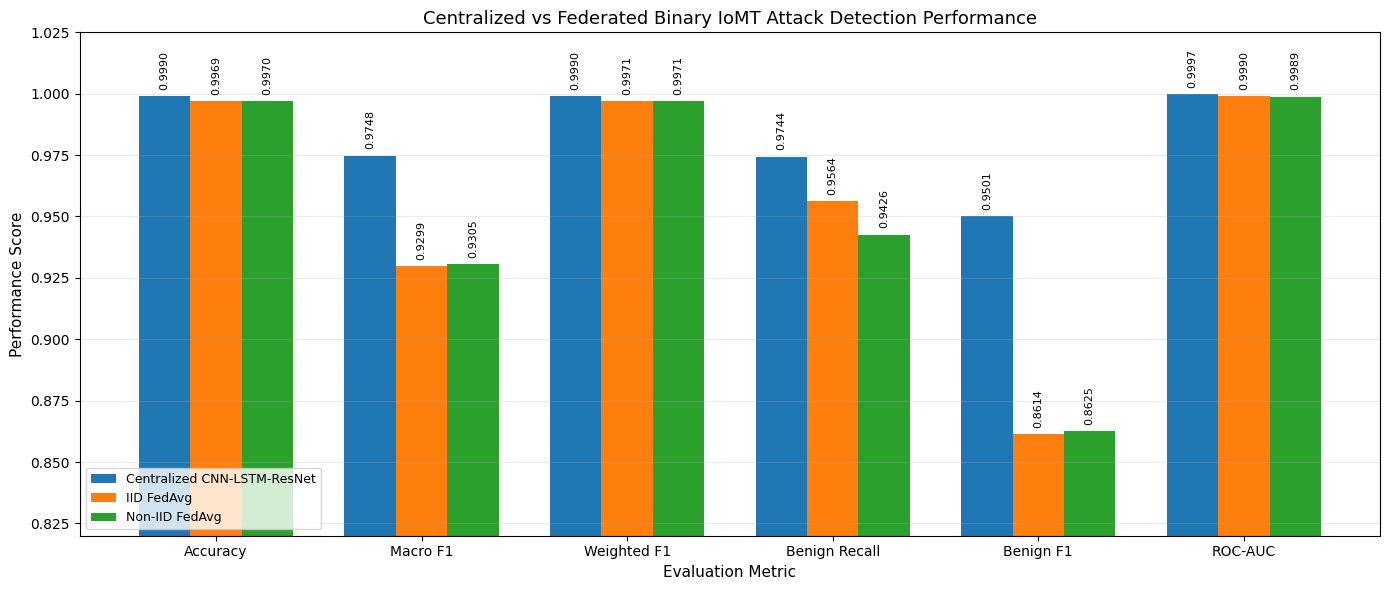


✅ Centralized vs Federated figure displayed.
✅ No training performed.
✅ No inference performed.

✅ Corrected verified comparison CSV saved:
/content/drive/MyDrive/IoMT_Thesis_2024/federated_binary/Centralized_vs_Federated/Centralized_vs_Federated_Binary_Comparison_VERIFIED.csv

FINAL CENTRALIZED vs FEDERATED SUMMARY

Accuracy
  Centralized : 0.998973
  IID FedAvg  : 0.996911 (Δ=-0.002062)
  Non-IID     : 0.996982 (Δ=-0.001991)

Macro_F1
  Centralized : 0.974799
  IID FedAvg  : 0.929932 (Δ=-0.044867)
  Non-IID     : 0.930465 (Δ=-0.044333)

Weighted_F1
  Centralized : 0.998986
  IID FedAvg  : 0.997063 (Δ=-0.001923)
  Non-IID     : 0.997109 (Δ=-0.001877)

Benign_Recall
  Centralized : 0.974383
  IID FedAvg  : 0.956435 (Δ=-0.017948)
  Non-IID     : 0.942629 (Δ=-0.031753)

Benign_F1
  Centralized : 0.950116
  IID FedAvg  : 0.861426 (Δ=-0.088690)
  Non-IID     : 0.862456 (Δ=-0.087660)

ROC_AUC
  Centralized : 0.999716
  IID FedAvg  : 0.998976 (Δ=-0.000740)
  Non-IID     : 0.998866 (Δ=-0.000

In [ ]:
# ================================================================
# CELL 34:
# CENTRALIZED vs FEDERATED — FINAL VERIFIED COMPARISON
# ================================================================
#
# CENTRALIZED SOURCE OF TRUTH:
#   Saved CNN-LSTM-ResNet prediction cache
#       y_true
#       y_prob
#       y_pred
#
# CROSS-CHECK:
#   Existing CNN-LSTM-ResNet classification report
#
# FEDERATED SOURCE:
#   Final_Paper_Ready_Results/
#   Federated_Final_Consolidated_Results.csv
#
# IMPORTANT:
#   - NO training
#   - NO model loading
#   - NO inference
#   - NO prediction generation
#   - NO fabricated metric
#   - NO existing file overwrite
#
# SAVES ONLY:
#   Centralized_vs_Federated/
#   Centralized_vs_Federated_Binary_Comparison_VERIFIED.csv
# ================================================================


# ------------------------------------------------
# 1. Imports
# ------------------------------------------------

import os
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)


print("=" * 115)
print("CENTRALIZED vs FEDERATED — FINAL VERIFIED BINARY COMPARISON")
print("=" * 115)


# ================================================================
# 2. Paths
# ================================================================

PROJECT_ROOT = (
    "/content/drive/MyDrive/"
    "IoMT_Thesis_2024"
)


CENTRAL_PRED_FILE = os.path.join(
    PROJECT_ROOT,
    "binary_dl_prediction_cache",
    "CNN-LSTM-ResNet_predictions.npz"
)


CENTRAL_REPORT_FILE = os.path.join(
    PROJECT_ROOT,
    "binary_dl_classification_reports",
    "CNN-LSTM-ResNet_classification_report.csv"
)


# Y_TEST_FILE is the temporary runtime-cache test-label file created
# in the setup cell from the same original held-out 20% CSV.
if "Y_TEST_FILE" not in globals():
    raise RuntimeError("Run the corrected setup/preprocessing cell first.")


FL_FINAL_FILE = os.path.join(
    PROJECT_ROOT,
    "federated_binary",
    "Final_Paper_Ready_Results",
    "Federated_Final_Consolidated_Results.csv"
)


required_files = {

    "Centralized prediction cache":
        CENTRAL_PRED_FILE,

    "Centralized classification report":
        CENTRAL_REPORT_FILE,

    "Frozen test labels":
        Y_TEST_FILE,

    "Final federated result":
        FL_FINAL_FILE
}


print("\nChecking required saved outputs:")


for name, path in required_files.items():

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"{name} missing:\n{path}"
        )

    print(f"✅ {name}")


# ================================================================
# 3. Load corrected 72/8/20 centralized prediction cache
# ================================================================

pred_cache = np.load(
    CENTRAL_PRED_FILE
)


required_keys = {
    "y_true",
    "y_prob",
    "y_pred"
}


if not required_keys.issubset(
    set(pred_cache.files)
):

    raise RuntimeError(
        "Prediction cache does not contain "
        "y_true, y_prob and y_pred."
    )


central_y_true = np.asarray(
    pred_cache["y_true"],
    dtype=np.uint8
).reshape(-1)


central_y_prob = np.asarray(
    pred_cache["y_prob"],
    dtype=np.float64
).reshape(-1)


central_y_pred = np.asarray(
    pred_cache["y_pred"],
    dtype=np.uint8
).reshape(-1)


if not (
    len(central_y_true) == len(central_y_prob) == len(central_y_pred)
):

    raise RuntimeError(
        "Centralized cached prediction lengths do not match."
    )


print(
    "\n✅ Corrected 72/8/20 centralized prediction cache loaded."
)


print(
    "Samples:",
    f"{len(central_y_true):,}"
)


# ================================================================
# 4. Verify against frozen test labels
# ================================================================

frozen_y_test = np.asarray(
    np.load(
        Y_TEST_FILE,
        mmap_mode="r"
    ),
    dtype=np.uint8
).reshape(-1)


if len(
    frozen_y_test
) != 649474:

    raise RuntimeError(
        "Unexpected frozen test-set size."
    )


if not np.array_equal(
    central_y_true,
    frozen_y_test
):

    raise RuntimeError(
        "Centralized cached y_true does NOT match "
        "the frozen federated test labels."
    )


N_BENIGN = int(
    np.sum(
        frozen_y_test == 0
    )
)


N_ATTACK = int(
    np.sum(
        frozen_y_test == 1
    )
)


if (
    N_BENIGN != 6519 or N_ATTACK != 642955
):

    raise RuntimeError(
        "Frozen test class counts are unexpected."
    )


print(
    "✅ Centralized cache uses the same frozen test labels."
)


print(
    f"Benign: {N_BENIGN:,}"
)


print(
    f"Attack: {N_ATTACK:,}"
)


# ================================================================
# 5. Recompute CENTRALIZED metrics from ORIGINAL cache
# ================================================================

central_cm = confusion_matrix(
    central_y_true,
    central_y_pred,
    labels=[
        0,
        1
    ]
)


central_tn, central_fp, central_fn, central_tp = (
    central_cm.ravel()
)


central_metrics = {

    "Accuracy":
        float(
            accuracy_score(
                central_y_true,
                central_y_pred
            )
        ),

    "Macro_F1":
        float(
            f1_score(
                central_y_true,
                central_y_pred,
                average="macro",
                zero_division=0
            )
        ),

    "Weighted_F1":
        float(
            f1_score(
                central_y_true,
                central_y_pred,
                average="weighted",
                zero_division=0
            )
        ),

    "Benign_Recall":
        float(
            recall_score(
                central_y_true,
                central_y_pred,
                pos_label=0,
                zero_division=0
            )
        ),

    "Benign_F1":
        float(
            f1_score(
                central_y_true,
                central_y_pred,
                pos_label=0,
                zero_division=0
            )
        ),

    "ROC_AUC":
        float(
            roc_auc_score(
                central_y_true,
                central_y_prob
            )
        )
}


print(
    "\n" + "=" * 115
)


print(
    "CENTRALIZED CNN-LSTM-RESNET — CACHE-DERIVED METRICS"
)


print(
    "=" * 115
)


for metric, value in central_metrics.items():

    print(
        f"{metric:<15}: "
        f"{value:.6f}"
    )


print(
    "\nConfusion Matrix:"
)


print(
    f"TN={central_tn:,} | "
    f"FP={central_fp:,} | "
    f"FN={central_fn:,} | "
    f"TP={central_tp:,}"
)


# ================================================================
# 6. Cross-check against existing classification report
# ================================================================

report_df = pd.read_csv(
    CENTRAL_REPORT_FILE
)


label_column = report_df.columns[0]


report_df[
    label_column
] = report_df[
    label_column
].astype(str)


def get_report_row(
    label
):

    rows = report_df[
        report_df[
            label_column
        ].str.strip().str.lower() == label.lower()
    ]


    if len(rows) != 1:

        raise RuntimeError(
            f"Could not uniquely identify "
            f"'{label}' row in classification report."
        )


    return rows.iloc[0]


benign_report = get_report_row(
    "Benign"
)


macro_report = get_report_row(
    "macro avg"
)


weighted_report = get_report_row(
    "weighted avg"
)


accuracy_report = get_report_row(
    "accuracy"
)


report_values = {

    "Accuracy":
        float(
            accuracy_report[
                "f1-score"
            ]
        ),

    "Macro_F1":
        float(
            macro_report[
                "f1-score"
            ]
        ),

    "Weighted_F1":
        float(
            weighted_report[
                "f1-score"
            ]
        ),

    "Benign_Recall":
        float(
            benign_report[
                "recall"
            ]
        ),

    "Benign_F1":
        float(
            benign_report[
                "f1-score"
            ]
        )
}


print(
    "\nCross-checking cache-derived metrics "
    "against existing classification report..."
)


REPORT_TOLERANCE = 1e-5


for metric, report_value in report_values.items():

    cache_value = central_metrics[
        metric
    ]


    difference = abs(
        cache_value - report_value
    )


    if difference > REPORT_TOLERANCE:

        raise RuntimeError(
            f"{metric} mismatch.\n"
            f"Cache  = {cache_value:.12f}\n"
            f"Report = {report_value:.12f}\n"
            f"Difference = {difference:.12f}"
        )


    print(
        f"✅ {metric}: "
        f"cache and report agree"
    )


print(
    "\n✅ Centralized result independently verified."
)


print(
    "✅ Weighted F1 correctly identified as "
    f"{central_metrics['Weighted_F1']:.6f}"
)


# ================================================================
# 7. Load FINAL FEDERATED result
# ================================================================

fl_df = pd.read_csv(
    FL_FINAL_FILE
)


fedavg_rows = fl_df[
    fl_df[
        "Algorithm"
    ].astype(str) == "FedAvg"
]


if len(
    fedavg_rows
) != 1:

    raise RuntimeError(
        "Expected exactly one FedAvg row "
        "in final federated results."
    )


fedavg = fedavg_rows.iloc[
    0
]


# ================================================================
# 8. Official IID / Non-IID FedAvg metrics
# ================================================================

iid_metrics = {

    "Accuracy":
        float(
            fedavg[
                "IID_Accuracy"
            ]
        ),

    "Macro_F1":
        float(
            fedavg[
                "IID_Macro_F1"
            ]
        ),

    "Weighted_F1":
        float(
            fedavg[
                "IID_Weighted_F1"
            ]
        ),

    "Benign_Recall":
        float(
            fedavg[
                "IID_Benign_Recall"
            ]
        ),

    "Benign_F1":
        float(
            fedavg[
                "IID_Benign_F1"
            ]
        ),

    "ROC_AUC":
        float(
            fedavg[
                "IID_ROC_AUC"
            ]
        )
}


noniid_metrics = {

    "Accuracy":
        float(
            fedavg[
                "NonIID_Accuracy"
            ]
        ),

    "Macro_F1":
        float(
            fedavg[
                "NonIID_Macro_F1"
            ]
        ),

    "Weighted_F1":
        float(
            fedavg[
                "NonIID_Weighted_F1"
            ]
        ),

    "Benign_Recall":
        float(
            fedavg[
                "NonIID_Benign_Recall"
            ]
        ),

    "Benign_F1":
        float(
            fedavg[
                "NonIID_Benign_F1"
            ]
        ),

    "ROC_AUC":
        float(
            fedavg[
                "NonIID_ROC_AUC"
            ]
        )
}


METRICS = [
    "Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Benign_Recall",
    "Benign_F1",
    "ROC_AUC"
]


# ================================================================
# 9. Main paper-ready comparison
# ================================================================

comparison_df = pd.DataFrame(
    [
        {
            "Setting":
                "Centralized CNN-LSTM-ResNet",

            **central_metrics
        },

        {
            "Setting":
                "IID FedAvg",

            **iid_metrics
        },

        {
            "Setting":
                "Non-IID FedAvg",

            **noniid_metrics
        }
    ]
)


print(
    "\n" + "=" * 115
)


print(
    "TABLE 1 — CENTRALIZED vs FEDERATED PERFORMANCE"
)


display(
    comparison_df.style
    .hide(
        axis="index"
    )
    .format(
        {
            metric:
                "{:.6f}"

            for metric
            in METRICS
        }
    )
    .set_properties(
        **{
            "text-align":
                "center"
        }
    )
)


# ================================================================
# 10. Performance gaps
#
# Delta = Federated - Centralized
#
# Negative:
#   Federated metric is lower
#
# Positive:
#   Federated metric is higher
# ================================================================

gap_rows = []


for setting_name, metrics in [

    (
        "IID FedAvg",
        iid_metrics
    ),

    (
        "Non-IID FedAvg",
        noniid_metrics
    )
]:

    for metric in METRICS:

        centralized_value = (
            central_metrics[
                metric
            ]
        )


        federated_value = (
            metrics[
                metric
            ]
        )


        delta = (
            federated_value - centralized_value
        )


        relative_change = (

            (
                delta / centralized_value
            ) * 100

            if centralized_value != 0

            else np.nan
        )


        gap_rows.append(
            {
                "Comparison":
                    setting_name + " vs Centralized",

                "Metric":
                    metric,

                "Centralized":
                    centralized_value,

                "Federated":
                    federated_value,

                "Delta":
                    delta,

                "Relative_Change_Percent":
                    relative_change
            }
        )


gap_df = pd.DataFrame(
    gap_rows
)


print(
    "\n" + "=" * 115
)


print(
    "TABLE 2 — FEDERATED PERFORMANCE GAP RELATIVE TO CENTRALIZED"
)


display(
    gap_df.style
    .hide(
        axis="index"
    )
    .format(
        {
            "Centralized":
                "{:.6f}",

            "Federated":
                "{:.6f}",

            "Delta":
                "{:+.6f}",

            "Relative_Change_Percent":
                "{:+.3f}%"
        }
    )
    .set_properties(
        **{
            "text-align":
                "center"
        }
    )
)



# ================================================================
# 10A. CENTRALIZED vs FEDERATED PERFORMANCE FIGURE
# ================================================================
#
# Uses the already verified comparison_df.
#
# Displays:
#   Centralized CNN-LSTM-ResNet
#   IID FedAvg
#   Non-IID FedAvg
#
# Metrics:
#   Accuracy
#   Macro F1
#   Weighted F1
#   Benign Recall
#   Benign F1
#   ROC-AUC
#
# NO training
# NO model loading
# NO inference
# ================================================================

import matplotlib.pyplot as plt


print(
    "\n" + "=" * 115
)

print(
    "FIGURE — CENTRALIZED vs FEDERATED PERFORMANCE"
)

print(
    "=" * 115
)


# ------------------------------------------------
# Prepare values
# ------------------------------------------------

figure_metrics = [
    "Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Benign_Recall",
    "Benign_F1",
    "ROC_AUC"
]


figure_labels = [
    "Accuracy",
    "Macro F1",
    "Weighted F1",
    "Benign Recall",
    "Benign F1",
    "ROC-AUC"
]


central_values = [
    central_metrics[metric]
    for metric in figure_metrics
]


iid_values = [
    iid_metrics[metric]
    for metric in figure_metrics
]


noniid_values = [
    noniid_metrics[metric]
    for metric in figure_metrics
]


x = np.arange(
    len(figure_metrics)
)


bar_width = 0.25


# ------------------------------------------------
# Create figure
# ------------------------------------------------

plt.figure(
    figsize=(14, 6)
)


bars_central = plt.bar(
    x - bar_width,
    central_values,
    width=bar_width,
    label="Centralized CNN-LSTM-ResNet"
)


bars_iid = plt.bar(
    x,
    iid_values,
    width=bar_width,
    label="IID FedAvg"
)


bars_noniid = plt.bar(
    x + bar_width,
    noniid_values,
    width=bar_width,
    label="Non-IID FedAvg"
)


# ------------------------------------------------
# Add value labels
# ------------------------------------------------

for bars in [
    bars_central,
    bars_iid,
    bars_noniid
]:

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,

            height + 0.0025,

            f"{height:.4f}",

            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )


# ------------------------------------------------
# Formatting
# ------------------------------------------------

plt.xticks(
    x,
    figure_labels,
    fontsize=10
)


plt.ylabel(
    "Performance Score",
    fontsize=11
)


plt.xlabel(
    "Evaluation Metric",
    fontsize=11
)


plt.title(
    "Centralized vs Federated Binary IoMT Attack Detection Performance",
    fontsize=13
)


# Zoomed scale makes the differences visible
plt.ylim(
    0.82,
    1.025
)


plt.legend(
    loc="lower left",
    fontsize=9
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


# ================================================================
# Save one publication-quality figure
# ================================================================

FIGURE_DIR = os.path.join(
    PROJECT_ROOT,
    "federated_binary",
    "Centralized_vs_Federated"
)


os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)


FIGURE_FILE = os.path.join(
    FIGURE_DIR,
    "Centralized_vs_Federated_Performance.png"
)


if os.path.exists(
    FIGURE_FILE
):

    print(
        "\n⚠️ Performance figure already exists."
    )

    print(
        "Existing figure was NOT overwritten:"
    )

    print(
        FIGURE_FILE
    )

else:

    plt.savefig(
        FIGURE_FILE,
        dpi=300,
        bbox_inches="tight"
    )

    print(
        "\n✅ Performance figure saved:"
    )

    print(
        FIGURE_FILE
    )


plt.show()


print(
    "\n✅ Centralized vs Federated figure displayed."
)

print(
    "✅ No training performed."
)

print(
    "✅ No inference performed."
)

print(
    "=" * 115
)

# ================================================================
# 11. Create ONE final verified CSV
#
# Keep both point estimates and FL-minus-centralized gaps
# in a single compact table.
# ================================================================

verified_rows = []


for setting_name, metrics in [

    (
        "Centralized CNN-LSTM-ResNet",
        central_metrics
    ),

    (
        "IID FedAvg",
        iid_metrics
    ),

    (
        "Non-IID FedAvg",
        noniid_metrics
    )
]:

    row = {
        "Setting":
            setting_name
    }


    for metric in METRICS:

        row[
            metric
        ] = metrics[
            metric
        ]


        if setting_name == "Centralized CNN-LSTM-ResNet":

            row[
                f"Delta_{metric}_vs_Centralized"
            ] = 0.0


        else:

            row[
                f"Delta_{metric}_vs_Centralized"
            ] = (
                metrics[
                    metric
                ] - central_metrics[
                    metric
                ]
            )


    verified_rows.append(
        row
    )


verified_df = pd.DataFrame(
    verified_rows
)


# ================================================================
# 12. Save corrected result WITHOUT overwriting old file
# ================================================================

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "federated_binary",
    "Centralized_vs_Federated"
)


os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "Centralized_vs_Federated_Binary_Comparison_VERIFIED.csv"
)


if os.path.exists(
    OUTPUT_FILE
):

    print(
        "\n⚠️ Verified comparison CSV already exists."
    )


    print(
        "Existing file was NOT overwritten:"
    )


    print(
        OUTPUT_FILE
    )


else:

    verified_df.to_csv(
        OUTPUT_FILE,
        index=False
    )


    print(
        "\n✅ Corrected verified comparison CSV saved:"
    )


    print(
        OUTPUT_FILE
    )


# ================================================================
# 13. Automatic concise summary
# ================================================================

print(
    "\n" + "=" * 115
)


print(
    "FINAL CENTRALIZED vs FEDERATED SUMMARY"
)


print(
    "=" * 115
)


for metric in METRICS:

    central_value = (
        central_metrics[
            metric
        ]
    )


    iid_value = (
        iid_metrics[
            metric
        ]
    )


    noniid_value = (
        noniid_metrics[
            metric
        ]
    )


    print(
        f"\n{metric}"
    )


    print(
        f"  Centralized : "
        f"{central_value:.6f}"
    )


    print(
        f"  IID FedAvg  : "
        f"{iid_value:.6f} "
        f"(Δ={iid_value - central_value:+.6f})"
    )


    print(
        f"  Non-IID     : "
        f"{noniid_value:.6f} "
        f"(Δ={noniid_value - central_value:+.6f})"
    )


# ================================================================
# 14. Final confirmation
# ================================================================

print(
    "\n" + "=" * 115
)


print(
    "VERIFIED INTEGRATION COMPLETE"
)


print(
    "=" * 115
)


print(
    "✅ Centralized metrics recomputed from corrected 72/8/20 saved predictions."
)


print(
    "✅ Centralized classification report cross-checked."
)


print(
    "✅ Same frozen 649,474-sample test labels verified."
)


print(
    "✅ Accuracy verified."
)


print(
    "✅ Macro F1 verified."
)


print(
    "✅ Weighted F1 corrected and verified."
)


print(
    "✅ Benign Recall verified."
)


print(
    "✅ Benign F1 verified."
)


print(
    "✅ ROC-AUC recovered from original cached probabilities."
)


print(
    "✅ Official IID FedAvg result used."
)


print(
    "✅ Official Non-IID FedAvg result used."
)


print(
    "✅ No training performed."
)


print(
    "✅ No model loaded."
)


print(
    "✅ No inference performed."
)


print(
    "✅ No prediction regenerated."
)


print(
    "✅ Old comparison CSV was NOT overwritten."
)


print(
    "\nUse this VERIFIED file for the paper/thesis:"
)


print(
    OUTPUT_FILE
)


print(
    "=" * 115
)
